In [ ]:
import pandas as pd
import glob
import numpy as np
from scipy.signal import butter, filtfilt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:

import os
import glob
import pandas as pd

folders = [
    "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN-00_01",
    "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN_14_16_17",
    "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure",
    "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_VAL_PN-00_01"
]

# Dictionary to store DataFrames
dataframes = {}

for folder in folders:
    csv_files = glob.glob(os.path.join(folder, "*.csv"))

    print(f"\nFolder: {os.path.basename(folder)}")
    print(f"Found {len(csv_files)} CSV files")

    for file in csv_files:
        filename = os.path.basename(file)
        dataframes[filename] = pd.read_csv(file)

print(f"\nTotal CSV files loaded: {len(dataframes)}")

# Example: Access one DataFrame
first_file = list(dataframes.keys())[0]
print(f"\nFirst file: {first_file}")
print(dataframes[first_file].head())


Folder: Siena_Seizure_PN-00_01
Found 46 CSV files

Folder: Siena_Seizure_PN_14_16_17
Found 278 CSV files

Folder: Siena_Seizure
Found 987 CSV files

Folder: Siena_Seizure_VAL_PN-00_01
Found 150 CSV files

Total CSV files loaded: 1461

First file: PN01-1_10249.csv
     Fp1     F3     C3      P3      O1      F7      T3      T5     Fc1  \
0 -5.625 -1.125  0.625  10.875   8.250 -41.375 -46.000 -20.375  14.125   
1 -4.000 -1.375  0.125  11.125   9.375 -42.750 -47.500 -19.000  13.500   
2 -4.250 -2.500 -0.750  11.750  10.500 -44.625 -49.375 -18.125  13.000   
3 -6.250 -3.250 -0.625  13.375  12.125 -44.000 -48.125 -15.125  13.250   
4 -7.000 -2.375 -0.125  14.000  13.250 -42.375 -47.125 -14.500  13.000   

      Fc5  ...     P4     O2      F8     T4     T6    Fc2    Fc6     Cp2  \
0 -33.875  ...  1.625  6.000  12.500  1.625  0.500  6.375  8.125  10.875   
1 -34.750  ...  0.875  3.875  12.000  0.375 -1.750  6.125  4.875  10.375   
2 -38.500  ...  1.125  5.375  14.375  2.250  3.875  5.500  6.8

In [ ]:
import pandas as pd
import glob
import os

# Folders
folders = {
    "PN00_01": "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN-00_01",
    "PN14_16_17": "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN_14_16_17",
    "Seizure": "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure"
}

# Read all CSVs in each folder
dfs = {}

for key, folder in folders.items():
    csv_files = glob.glob(os.path.join(folder, "*.csv"))
    dfs[key] = pd.concat(
        [pd.read_csv(f) for f in csv_files],
        ignore_index=True
    )
    print(f"{key}: {dfs[key].shape}")

# Find common columns
common_columns = set(dfs["PN00_01"].columns)

for key in dfs:
    common_columns &= set(dfs[key].columns)

common_columns = sorted(list(common_columns))

print(f"\nNumber of common columns: {len(common_columns)}")
print(common_columns)

PN00_01: (47104, 29)
PN14_16_17: (284672, 26)
Seizure: (1010688, 29)

Number of common columns: 26
['C3', 'C4', 'Cp1', 'Cp2', 'Cp5', 'Cp6', 'F10', 'F3', 'F4', 'F7', 'F8', 'F9', 'Fc1', 'Fc2', 'Fc5', 'Fc6', 'Fp1', 'Fz', 'O1', 'O2', 'P3', 'P4', 'Pz', 'T4', 'T5', 'T6']


In [ ]:
seizure_folders = [
    "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN-00_01",
    "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN_14_16_17",
    "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure",
]

In [ ]:
import os
import glob
import pandas as pd

path0 = "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN-00_01"
path1 = "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN_14_16_17"
path2 = "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure"

# Read all CSVs from path0
df0 = pd.concat(
    [pd.read_csv(file) for file in glob.glob(os.path.join(path0, "*.csv"))],
    ignore_index=True
)

# Read all CSVs from path1
df1 = pd.concat(
    [pd.read_csv(file) for file in glob.glob(os.path.join(path1, "*.csv"))],
    ignore_index=True
)

# Read all CSVs from path2
df2 = pd.concat(
    [pd.read_csv(file) for file in glob.glob(os.path.join(path2, "*.csv"))],
    ignore_index=True
)

print(df0.shape)
print(df1.shape)
print(df2.shape)

(47104, 29)
(284672, 26)
(1010688, 29)


In [ ]:
df_sez_temp = pd.concat([df0, df1, df2], axis=0, ignore_index=True)
df_sez_temp
df_sez_temp = pd.concat(
    [df0, df1, df2],
    axis=0,
    ignore_index=True
)

print(df_sez_temp.shape)
df_sez_temp.head()

(1342464, 29)


,Fp1,F3,C3,P3,O1,F7,T3,T5,Fc1,Fc5,...,P4,O2,F8,T4,T6,Fc2,Fc6,Cp2,Cp6,F10
0,-5.625,-1.125,0.625,10.875,8.250,-41.375,-46.000,-20.375,14.125,-33.875,...,1.625,6.000,12.500,1.625,0.500,6.375,8.125,10.875,10.875,NaN
1,-4.000,-1.375,0.125,11.125,9.375,-42.750,-47.500,-19.000,13.500,-34.750,...,0.875,3.875,12.000,0.375,-1.750,6.125,4.875,10.375,10.375,NaN
2,-4.250,-2.500,-0.750,11.750,10.500,-44.625,-49.375,-18.125,13.000,-38.500,...,1.125,5.375,14.375,2.250,3.875,5.500,6.875,10.375,10.375,NaN
3,-6.250,-3.250,-0.625,13.375,12.125,-44.000,-48.125,-15.125,13.250,-38.375,...,-0.250,5.500,12.125,2.375,2.750,4.625,8.000,9.750,9.750,NaN
4,-7.000,-2.375,-0.125,14.000,13.250,-42.375,-47.125,-14.500,13.000,-35.000,...,-2.625,2.125,8.125,0.750,-4.500,3.750,5.250,9.250,9.250,NaN


In [ ]:
df_sez_temp = df_sez_temp.drop(columns=["F10"], errors="ignore")
# Remove F10
df_sez_temp = df_sez_temp.drop(columns=["F10"], errors="ignore")

# Keep only the 25 common EEG channels
common_channels = [
    'Fp1', 'F3', 'C3', 'P3', 'O1',
    'F7', 'T5', 'Fc1', 'Fc5',
    'Cp1', 'Cp5', 'F9', 'Fz', 'Pz',
    'F4', 'C4', 'P4', 'O2',
    'F8', 'T4', 'T6', 'Fc2',
    'Fc6', 'Cp2', 'Cp6'
]

df_sez_temp = df_sez_temp[common_channels]

print(df_sez_temp.shape)
print(df_sez_temp.columns.tolist())


(1342464, 25)
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Pz', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2', 'Fc6', 'Cp2', 'Cp6']


In [ ]:
import os
import glob
import pandas as pd

path3 = "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Non Seizure_00_01"
path4 = "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_NonSeizure_14_16_17"
path5 = "/content/drive/MyDrive/Seinna_dataset/.csv format/Siena_NonSeizure"

# Read all CSVs from path0
df3 = pd.concat(
    [pd.read_csv(file) for file in glob.glob(os.path.join(path3, "*.csv"))],
    ignore_index=True
)

# Read all CSVs from path1
df4 = pd.concat(
    [pd.read_csv(file) for file in glob.glob(os.path.join(path4, "*.csv"))],
    ignore_index=True
)

# Read all CSVs from path2
df5 = pd.concat(
    [pd.read_csv(file) for file in glob.glob(os.path.join(path5, "*.csv"))],
    ignore_index=True
)

print(df3.shape)
print(df4.shape)
print(df5.shape)

(46080, 29)
(328704, 26)
(1071104, 29)


In [ ]:
df1_n_sez_temp = pd.concat([df3, df4, df5], axis=0, ignore_index=True)
df1_n_sez_temp


,Fp1,F3,C3,P3,O1,F7,T3,T5,Fc1,Fc5,...,P4,O2,F8,T4,T6,Fc2,Fc6,Cp2,Cp6,F10
0,-5.750,1.875,12.125,17.875,2.750,0.500,12.750,18.000,7.375,3.625,...,12.250,10.250,-4.750,6.000,11.500,11.500,5.625,12.000,1.750,NaN
1,-7.250,2.000,10.000,14.000,-4.125,-1.125,8.000,8.875,5.875,1.875,...,12.250,7.375,-5.500,4.000,10.750,10.750,6.750,10.875,1.250,NaN
2,-2.625,0.125,7.125,11.125,-7.500,-1.625,5.875,3.625,3.875,-0.625,...,12.000,8.375,-8.875,4.125,13.375,13.375,5.500,10.125,2.125,NaN
3,4.250,-4.125,3.000,11.375,0.750,0.250,7.500,9.500,-1.000,-1.250,...,9.875,12.625,-5.625,5.125,16.375,16.375,4.125,8.125,2.500,NaN
4,3.250,-7.125,1.500,11.000,2.375,-2.375,4.125,9.750,-2.750,-3.000,...,10.875,12.500,1.250,10.125,16.875,16.875,9.000,8.750,4.875,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445883,-15.375,0.750,-4.000,-10.500,-11.500,-4.250,-10.250,-14.625,-174.500,-156.500,...,-16.750,8.500,-0.375,-21.000,-154.875,-156.375,-183.750,-179.750,-179.750,NaN
1445884,-16.125,0.250,-4.250,-10.500,-12.625,-4.625,-12.500,-16.250,31.625,45.625,...,-15.875,7.500,-0.375,-18.625,43.750,47.250,22.000,25.875,25.875,NaN
1445885,-16.375,-0.125,-3.375,-9.750,-13.375,-5.000,-13.250,-17.250,180.750,186.125,...,-15.625,7.375,-0.125,-17.750,196.875,193.500,173.750,171.250,171.250,NaN
1445886,-16.500,-0.125,-2.500,-8.875,-13.875,-5.750,-12.625,-16.875,222.625,222.125,...,-15.000,7.500,0.000,-15.250,245.875,235.000,225.375,212.250,212.250,NaN


In [ ]:
df3_common = df3[common_channels]
df4_common = df4[common_channels]
df5_common = df5[common_channels]

print(df3_common.shape)
print(df4_common.shape)
print(df5_common.shape)

(46080, 25)
(328704, 25)
(1071104, 25)


In [ ]:
df1_n_sez_temp = df1_n_sez_temp.drop(columns=["F10"], errors="ignore")
 #Remove F10
df1_n_sez_temp = df1_n_sez_temp.drop(columns=["F10"], errors="ignore")

# Keep only the 25 common EEG channels
common_channels = [
    'Fp1', 'F3', 'C3', 'P3', 'O1',
    'F7', 'T5', 'Fc1', 'Fc5',
    'Cp1', 'Cp5', 'F9', 'Fz', 'Pz',
    'F4', 'C4', 'P4', 'O2',
    'F8', 'T4', 'T6', 'Fc2',
    'Fc6', 'Cp2', 'Cp6'
]

df1_n_sez_temp = df1_n_sez_temp[common_channels]

print(df1_n_sez_temp.shape)
print(df1_n_sez_temp.columns.tolist())

(1445888, 25)
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Pz', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2', 'Fc6', 'Cp2', 'Cp6']


In [ ]:
from scipy.signal import butter, filtfilt
import numpy as np
import pandas as pd

# ============================================================
# BANDPASS FILTER: 0.5–35 Hz
# ============================================================

lowcut = 0.5
highcut = 35
fs = 512
order = 2

nyquist = 0.5 * fs
low = lowcut / nyquist
high = highcut / nyquist

b, a = butter(order, [low, high], btype='band')

# Apply filter independently to each channel
df_sez_temp_filtered = df_sez_temp.copy()

for col in df_sez_temp.columns:
    df_sez_temp_filtered[col] = filtfilt(
        b, a,
        df_sez_temp[col].values,
        padlen=15
    )

print("Seizure filtered shape:", df_sez_temp_filtered.shape)


# ============================================================
# FFT ALONG TIME AXIS
# ============================================================

fft_coefficients = np.fft.fft(
    df_sez_temp_filtered.values,
    axis=0
)

magnitude = np.abs(fft_coefficients)
phase = np.angle(fft_coefficients)

df_sez_temp_filtered_magnitude = pd.DataFrame(
    magnitude,
    columns=df_sez_temp_filtered.columns
)

df_sez_temp_filtered_phase = pd.DataFrame(
    phase,
    columns=df_sez_temp_filtered.columns
)

print("Seizure FFT magnitude shape:",
      df_sez_temp_filtered_magnitude.shape)

print("Seizure FFT phase shape:",
      df_sez_temp_filtered_phase.shape)

Seizure filtered shape: (1342464, 25)
Seizure FFT magnitude shape: (1342464, 25)
Seizure FFT phase shape: (1342464, 25)


In [ ]:
# Bandpass filter 0.5-35 Hz
lowcut = 0.5
highcut = 35
fs = 512
order = 2

nyquist = 0.5 * fs
low = lowcut / nyquist
high = highcut / nyquist

b, a = butter(order, [low, high], btype='band')

df1_n_sez_temp_filtered = df1_n_sez_temp.copy()

for col in df1_n_sez_temp.columns:
    df1_n_sez_temp_filtered[col] = filtfilt(
        b, a,
        df1_n_sez_temp[col].values,
        padlen=15
    )

print("Non-seizure filtered shape:", df1_n_sez_temp_filtered.shape)


# FFT along the TIME axis (axis=0), independently per channel
fft_coefficients = np.fft.fft(
    df1_n_sez_temp_filtered.values,
    axis=0
)

magnitude = np.abs(fft_coefficients)
phase = np.angle(fft_coefficients)

df1_n_sez_temp_filtered_magnitude = pd.DataFrame(
    magnitude,
    columns=df1_n_sez_temp_filtered.columns
)

df1_n_sez_temp_filtered_phase = pd.DataFrame(
    phase,
    columns=df1_n_sez_temp_filtered.columns
)

print(
    "Non-seizure FFT magnitude shape:",
    df1_n_sez_temp_filtered_magnitude.shape
)

print(
    "Non-seizure FFT phase shape:",
    df1_n_sez_temp_filtered_phase.shape
)

Non-seizure filtered shape: (1445888, 25)
Non-seizure FFT magnitude shape: (1445888, 25)
Non-seizure FFT phase shape: (1445888, 25)


In [ ]:
!pip -q install transformers
from huggingface_hub import login
login()

In [ ]:
import torch
from transformers import AutoModel

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")

model = AutoModel.from_pretrained(
    "brain-bzh/reve-base",
    trust_remote_code=True,
    torch_dtype=torch.float16
)

position_model = AutoModel.from_pretrained(
    "brain-bzh/reve-positions",
    trust_remote_code=True,
    torch_dtype=torch.float16
)

model = model.to(DEVICE)
position_model = position_model.to(DEVICE)

model.eval()
position_model.eval()

print("REVE loaded successfully on:", DEVICE)

DEVICE: cuda
GPU: Tesla T4
GPU memory: 14.56 GB


config.json:   0%|          | 0.00/428 [00:00<?, ?B/s]

configuration_reve.py:   0%|          | 0.00/769 [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/brain-bzh/reve-base:
- configuration_reve.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


modeling_reve.py:   0%|          | 0.00/16.1k [00:00<?, ?B/s]

...

[transformers] A new version of the following files was downloaded from https://huggingface.co/brain-bzh/reve-positions:
- position_bank.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors: reconstructing file:   0%|          |  0.00B / 6.63kB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

REVE loaded successfully on: cuda


In [ ]:
# ============================================================
# CELL 6 — Prepare Siena EEG epochs for REVE + LOSO
# ============================================================

import numpy as np

# ------------------------------------------------------------
# REVE input configuration
# ------------------------------------------------------------
FS_REVE = 200          # REVE-compatible sampling rate
EPOCH_SEC = 5
EPOCH_SAMPLES = FS_REVE * EPOCH_SEC

N_CHANNELS = 25

print("REVE epoch length:", EPOCH_SAMPLES, "samples")
print("Number of EEG channels:", N_CHANNELS)

REVE epoch length: 1000 samples
Number of EEG channels: 25


In [ ]:
# ============================================================
# CELL 7 — Check current Siena variables
# ============================================================

print("Seizure filtered shape:")
print(df_sez_temp_filtered.shape)

print("\nNon-seizure filtered shape:")
print(df1_n_sez_temp_filtered.shape)

print("\nCurrent variables containing 'sub' or 'id':")
for name in dir():
    if 'sub' in name.lower() or 'id' in name.lower():
        print(name)

Seizure filtered shape:
(1342464, 25)

Non-seizure filtered shape:
(1445888, 25)

Current variables containing 'sub' or 'id':


In [ ]:
# ============================================================
# CELL 7 — Inspect all current Siena dataframe variables
# ============================================================

import pandas as pd

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        print(f"{name:45s} shape = {obj.shape}")

_                                             shape = (1445888, 29)
__                                            shape = (5, 29)
df0                                           shape = (47104, 29)
df1                                           shape = (284672, 26)
df2                                           shape = (1010688, 29)
df_sez_temp                                   shape = (1342464, 25)
_8                                            shape = (5, 29)
df3                                           shape = (46080, 29)
df4                                           shape = (328704, 26)
df5                                           shape = (1071104, 29)
df1_n_sez_temp                                shape = (1445888, 25)
_11                                           shape = (1445888, 29)
df3_common                                    shape = (46080, 25)
df4_common                                    shape = (328704, 25)
df5_common                                    shape = (1071104, 25)
d

In [ ]:
# ============================================================
# CELL 7 — Inspect the original Siena dataframes
# ============================================================

for name in ["df0", "df1", "df2", "df3", "df4", "df5"]:
    if name in globals():
        df = globals()[name]

        print("\n" + "=" * 70)
        print(name)
        print("Shape:", df.shape)
        print("Columns:")
        print(list(df.columns))

        print("\nFirst 3 rows:")
        display(df.head(3))


df0
Shape: (47104, 29)
Columns:
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2', 'Fc6', 'Cp2', 'Cp6', 'F10']

First 3 rows:


,Fp1,F3,C3,P3,O1,F7,T3,T5,Fc1,Fc5,...,P4,O2,F8,T4,T6,Fc2,Fc6,Cp2,Cp6,F10
0,-5.625,-1.125,0.625,10.875,8.250,-41.375,-46.000,-20.375,14.125,-33.875,...,1.625,6.000,12.500,1.625,0.500,6.375,8.125,10.875,10.875,NaN
1,-4.000,-1.375,0.125,11.125,9.375,-42.750,-47.500,-19.000,13.500,-34.750,...,0.875,3.875,12.000,0.375,-1.750,6.125,4.875,10.375,10.375,NaN
2,-4.250,-2.500,-0.750,11.750,10.500,-44.625,-49.375,-18.125,13.000,-38.500,...,1.125,5.375,14.375,2.250,3.875,5.500,6.875,10.375,10.375,NaN



df1
Shape: (284672, 26)
Columns:
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Pz', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2', 'Fc6', 'Cp2', 'Cp6', 'F10']

First 3 rows:


,Fp1,F3,C3,P3,O1,F7,T5,Fc1,Fc5,Cp1,...,P4,O2,F8,T4,T6,Fc2,Fc6,Cp2,Cp6,F10
0,369.250,34.125,-721.625,-201.750,297.375,1592.375,287.375,-289.750,1116.000,-277.500,...,70.125,324.50,613.125,559.875,460.000,1.750,490.000,-25.750,-25.750,NaN
1,349.625,252.500,-133.625,-128.375,-6.000,484.250,2.875,-61.625,386.375,-108.875,...,-96.000,-21.50,216.250,227.625,38.625,-30.500,195.250,-64.625,-64.625,NaN
2,350.875,310.250,67.875,-123.375,22.125,260.125,105.125,0.375,403.500,-45.500,...,-58.250,-4.75,-15.750,311.500,-480.500,-22.625,-19.875,-61.125,-61.125,NaN



df2
Shape: (1010688, 29)
Columns:
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2', 'Fc6', 'Cp2', 'Cp6', 'F10']

First 3 rows:


...

,Fp1,F3,C3,P3,O1,F7,T3,T5,Fc1,Fc5,...,P4,O2,F8,T4,T6,Fc2,Fc6,Cp2,Cp6,F10
0,-5.750,1.875,12.125,17.875,2.750,0.500,12.750,18.000,7.375,3.625,...,12.25,10.250,-4.750,6.000,11.500,11.500,5.625,12.000,1.750,NaN
1,-7.250,2.000,10.000,14.000,-4.125,-1.125,8.000,8.875,5.875,1.875,...,12.25,7.375,-5.500,4.000,10.750,10.750,6.750,10.875,1.250,NaN
2,-2.625,0.125,7.125,11.125,-7.500,-1.625,5.875,3.625,3.875,-0.625,...,12.00,8.375,-8.875,4.125,13.375,13.375,5.500,10.125,2.125,NaN



df4
Shape: (328704, 26)
Columns:
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Pz', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2', 'Fc6', 'Cp2', 'Cp6', 'F10']

First 3 rows:


,Fp1,F3,C3,P3,O1,F7,T5,Fc1,Fc5,Cp1,...,P4,O2,F8,T4,T6,Fc2,Fc6,Cp2,Cp6,F10
0,-4.625,6.500,13.625,30.375,16.250,4.75,144.75,22.0,15.625,12.750,...,23.250,26.250,17.250,12.250,39.000,12.125,26.625,6.250,6.250,NaN
1,-0.250,9.375,20.375,33.375,18.375,8.50,162.00,24.5,15.000,15.125,...,21.500,23.625,17.750,4.250,32.625,11.750,24.875,5.375,5.375,NaN
2,1.625,10.250,22.625,34.500,14.625,9.75,161.50,24.0,16.625,16.125,...,19.625,15.500,22.375,11.625,27.500,13.250,27.000,3.125,3.125,NaN



df5
Shape: (1071104, 29)
Columns:
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2', 'Fc6', 'Cp2', 'Cp6', 'F10']

First 3 rows:


,Fp1,F3,C3,P3,O1,F7,T3,T5,Fc1,Fc5,...,P4,O2,F8,T4,T6,Fc2,Fc6,Cp2,Cp6,F10
0,0.875,-8.375,-2.000,30.750,37.750,-15.750,9.875,41.750,2.625,-5.750,...,18.375,36.750,33.250,41.375,0.875,27.375,8.375,41.625,41.625,NaN
1,1.375,-6.000,-2.125,28.000,35.000,-14.750,10.500,40.500,2.000,-3.125,...,16.000,39.500,36.000,41.375,-0.875,31.250,5.750,40.250,40.250,NaN
2,1.375,-4.625,-3.875,24.375,33.625,-13.875,7.125,38.125,0.750,-2.250,...,13.750,37.375,32.375,38.875,2.250,32.125,4.125,39.125,39.125,NaN


In [ ]:
# ============================================================
# CELL 7 — Resample filtered EEG: 512 Hz → 200 Hz
# ============================================================

from scipy.signal import resample_poly
import numpy as np

FS_ORIGINAL = 512
FS_REVE = 200

# ------------------------------------------------------------
# Seizure
# ------------------------------------------------------------
seizure_512 = df_sez_temp_filtered.values.astype(np.float32)

seizure_200 = resample_poly(
    seizure_512,
    FS_REVE,
    FS_ORIGINAL,
    axis=0
).astype(np.float32)

# ------------------------------------------------------------
# Non-seizure
# ------------------------------------------------------------
nonseizure_512 = df1_n_sez_temp_filtered.values.astype(np.float32)

nonseizure_200 = resample_poly(
    nonseizure_512,
    FS_REVE,
    FS_ORIGINAL,
    axis=0
).astype(np.float32)

print("Original seizure shape:", seizure_512.shape)
print("Resampled seizure shape:", seizure_200.shape)

print("Original non-seizure shape:", nonseizure_512.shape)
print("Resampled non-seizure shape:", nonseizure_200.shape)

print("\nExpected channels:", 25)
print("REVE sampling rate:", FS_REVE, "Hz")
print("Epoch duration:", EPOCH_SEC, "seconds")
print("Samples per epoch:", EPOCH_SAMPLES)

Original seizure shape: (1342464, 25)
Resampled seizure shape: (524400, 25)
Original non-seizure shape: (1445888, 25)
Resampled non-seizure shape: (564800, 25)

Expected channels: 25
REVE sampling rate: 200 Hz
Epoch duration: 5 seconds
Samples per epoch: 1000


In [ ]:
# CELL 8 — Inspect existing variables for subject / recording information

print("Variables related to subjects / recordings:\n")

for name in list(globals().keys()):
    name_lower = name.lower()

    if any(key in name_lower for key in [
        "subject", "patient", "recording",
        "siena", "seizure", "non_seizure", "nonseizure"
    ]):
        try:
            obj = globals()[name]

            if hasattr(obj, "shape"):
                print(f"{name:45s} shape = {obj.shape}")

            elif isinstance(obj, (list, tuple, dict)):
                print(
                    f"{name:45s} "
                    f"type = {type(obj).__name__}, length = {len(obj)}"
                )

        except Exception:
            pass

Variables related to subjects / recordings:

seizure_folders                               type = list, length = 3
seizure_512                                   shape = (1342464, 25)
seizure_200                                   shape = (524400, 25)
nonseizure_512                                shape = (1445888, 25)
nonseizure_200                                shape = (564800, 25)


In [ ]:
# CELL 9 — Inspect Siena seizure folder structure

print("Number of seizure folders:", len(seizure_folders))

for i, folder in enumerate(seizure_folders):
    print(f"\n[{i}]")
    print("Type:", type(folder))
    print("Value:", folder)

Number of seizure folders: 3

[0]
Type: <class 'str'>
Value: /content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN-00_01

[1]
Type: <class 'str'>
Value: /content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN_14_16_17

[2]
Type: <class 'str'>
Value: /content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure


In [ ]:
# CELL 10 — Inspect Siena seizure recordings

import os

for i, folder in enumerate(seizure_folders):
    print(f"\n{'='*70}")
    print(f"FOLDER {i}: {folder}")
    print(f"{'='*70}")

    files = sorted([
        f for f in os.listdir(folder)
        if f.lower().endswith(".csv")
    ])

    print("Number of CSV files:", len(files))

    for f in files:
        print(f)


FOLDER 0: /content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN-00_01
Number of CSV files: 46
PN00-1_1144.csv
PN00-1_1146.csv
PN00-1_1148.csv
PN00-1_1150.csv
PN00-1_1152.csv
PN00-1_1154.csv
PN00-1_1156.csv
PN00-2_1223.csv
PN00-2_1225.csv
PN00-2_1227.csv
PN00-2_1229.csv
PN00-2_1231.csv
PN00-2_1233.csv
PN00-2_1235.csv
PN00-3_786.csv
PN00-3_788.csv
PN00-3_790.csv
PN00-3_792.csv
PN00-3_794.csv
PN00-3_796.csv
PN00-3_798.csv
PN00-3_800.csv
PN00-4_1061.csv
PN00-4_1063.csv
PN00-4_1065.csv
PN00-4_1067.csv
PN00-4_1069.csv
PN00-4_1071.csv
PN00-4_1073.csv
PN00-4_1075.csv
PN00-5_939.csv
PN00-5_941.csv
PN00-5_943.csv
PN00-5_945.csv
PN00-5_947.csv
PN00-5_949.csv
PN00-5_951.csv
PN00-5_953.csv
PN01-1_10239.csv
PN01-1_10241.csv
PN01-1_10243.csv
PN01-1_10245.csv
PN01-1_10247.csv
PN01-1_10249.csv
PN01-1_10251.csv
PN01-1_10253.csv

FOLDER 1: /content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Seizure_PN_14_16_17
Number of CSV files: 278
PN14-1_7263.csv
PN14-1_7265.csv
PN14-1_7267.csv
PN14

In [ ]:
# CELL 11 — Inspect non-seizure source folders and CSV recordings

import os
import glob

nonseizure_folders = [path3, path4, path5]

print("=" * 80)
print("NON-SEIZURE SIENA FOLDERS")
print("=" * 80)

for i, folder in enumerate(nonseizure_folders):

    files = sorted(
        glob.glob(os.path.join(folder, "*.csv"))
    )

    print(f"\nFolder {i}")
    print("Path       :", folder)
    print("CSV files  :", len(files))

    print("First 10 files:")
    for f in files[:10]:
        print("  ", os.path.basename(f))

NON-SEIZURE SIENA FOLDERS

Folder 0
Path       : /content/drive/MyDrive/Seinna_dataset/.csv format/Siena_Non Seizure_00_01
CSV files  : 45
First 10 files:
   PN00-1_1507.csv
   PN00-1_1509.csv
   PN00-1_1511.csv
   PN00-1_1513.csv
   PN00-1_1515.csv
   PN00-1_1517.csv
   PN00-1_1519.csv
   PN00-1_1521.csv
   PN00-2_1821.csv
   PN00-2_1823.csv

Folder 1
Path       : /content/drive/MyDrive/Seinna_dataset/.csv format/Siena_NonSeizure_14_16_17
CSV files  : 321
First 10 files:
   NS_PN14-1_1501.csv
   NS_PN14-1_1503.csv
   NS_PN14-1_1505.csv
   NS_PN14-1_1507.csv
   NS_PN14-1_1509.csv
   NS_PN14-1_1511.csv
   NS_PN14-1_1513.csv
   NS_PN14-1_1515.csv
   NS_PN14-1_1517.csv
   NS_PN14-1_1519.csv

Folder 2
Path       : /content/drive/MyDrive/Seinna_dataset/.csv format/Siena_NonSeizure
CSV files  : 1046
First 10 files:
   NS-PN06-1_1270.csv
   NS-PN06-1_1272.csv
   NS-PN06-1_1274.csv
   NS-PN06-1_1276.csv
   NS-PN06-1_1278.csv
   NS-PN06-1_1280.csv
   NS-PN06-1_1282.csv
   NS-PN06-1_1284.csv
   

In [ ]:
# CELL 12 — Extract subject IDs from seizure and non-seizure filenames

import os
import glob
import re

# ---------------------------------------------------------
# All seizure folders
# ---------------------------------------------------------
seizure_files = []

for folder in seizure_folders:
    seizure_files.extend(
        glob.glob(os.path.join(folder, "*.csv"))
    )

seizure_files = sorted(seizure_files)


# ---------------------------------------------------------
# All non-seizure folders
# ---------------------------------------------------------
nonseizure_folders = [path3, path4, path5]

nonseizure_files = []

for folder in nonseizure_folders:
    nonseizure_files.extend(
        glob.glob(os.path.join(folder, "*.csv"))
    )

nonseizure_files = sorted(nonseizure_files)


# ---------------------------------------------------------
# Function to extract PN subject ID
# Handles:
# PN00-...
# PN01-...
# NS_PN14-...
# NS-PN06-...
# ---------------------------------------------------------
def extract_subject_id(filepath):

    filename = os.path.basename(filepath)

    match = re.search(r'PN(\d+)', filename, re.IGNORECASE)

    if match is None:
        return None

    return f"PN{int(match.group(1)):02d}"


# ---------------------------------------------------------
# Extract IDs
# ---------------------------------------------------------
seizure_subjects = sorted(
    set(
        extract_subject_id(f)
        for f in seizure_files
        if extract_subject_id(f) is not None
    )
)

nonseizure_subjects = sorted(
    set(
        extract_subject_id(f)
        for f in nonseizure_files
        if extract_subject_id(f) is not None
    )
)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------
print("=" * 80)
print("SUBJECT ID VERIFICATION")
print("=" * 80)

print("\nSeizure subjects:")
print(seizure_subjects)
print("Number:", len(seizure_subjects))

print("\nNon-seizure subjects:")
print(nonseizure_subjects)
print("Number:", len(nonseizure_subjects))


# ---------------------------------------------------------
# Compare
# ---------------------------------------------------------
common_subjects = sorted(
    set(seizure_subjects) & set(nonseizure_subjects)
)

seizure_only = sorted(
    set(seizure_subjects) - set(nonseizure_subjects)
)

nonseizure_only = sorted(
    set(nonseizure_subjects) - set(seizure_subjects)
)

print("\n" + "=" * 80)
print("OVERLAP CHECK")
print("=" * 80)

print("\nCommon subjects:")
print(common_subjects)
print("Number:", len(common_subjects))

print("\nSeizure-only subjects:")
print(seizure_only)

print("\nNon-seizure-only subjects:")
print(nonseizure_only)


# ---------------------------------------------------------
# LOSO readiness
# ---------------------------------------------------------
if seizure_only == [] and nonseizure_only == []:
    print("\n✅ SEIZURE AND NON-SEIZURE SUBJECTS MATCH")
    print(f"✅ {len(common_subjects)} subjects available for LOSO")
else:
    print("\n⚠️ SUBJECT MISMATCH — DO NOT START LOSO YET")

SUBJECT ID VERIFICATION

Seizure subjects:
['PN00', 'PN01', 'PN03', 'PN05', 'PN06', 'PN07', 'PN09', 'PN10', 'PN11', 'PN12', 'PN13', 'PN14', 'PN16', 'PN17']
Number: 14

Non-seizure subjects:
['PN00', 'PN01', 'PN06', 'PN07', 'PN09', 'PN10', 'PN11', 'PN12', 'PN13', 'PN14', 'PN16', 'PN17']
Number: 12

OVERLAP CHECK

Common subjects:
['PN00', 'PN01', 'PN06', 'PN07', 'PN09', 'PN10', 'PN11', 'PN12', 'PN13', 'PN14', 'PN16', 'PN17']
Number: 12

Seizure-only subjects:
['PN03', 'PN05']

Non-seizure-only subjects:
[]

⚠️ SUBJECT MISMATCH — DO NOT START LOSO YET


In [ ]:
# CELL 14 — Per-subject recording counts for both classes

from collections import Counter

# Count seizure files per subject
seizure_counts = Counter(
    extract_subject_id(f)
    for f in seizure_files
)

# Count non-seizure files per subject
nonseizure_counts = Counter(
    extract_subject_id(f)
    for f in nonseizure_files
)

all_subjects = sorted(
    set(seizure_counts.keys()) |
    set(nonseizure_counts.keys())
)

print("=" * 80)
print("PER-SUBJECT SEIZURE / NON-SEIZURE RECORDING COUNTS")
print("=" * 80)

print(
    f"{'Subject':<10}"
    f"{'Seizure':>12}"
    f"{'Non-seizure':>15}"
)

print("-" * 40)

for subject in all_subjects:

    print(
        f"{subject:<10}"
        f"{seizure_counts.get(subject, 0):>12}"
        f"{nonseizure_counts.get(subject, 0):>15}"
    )

print("-" * 40)

print(
    f"{'TOTAL':<10}"
    f"{len(seizure_files):>12}"
    f"{len(nonseizure_files):>15}"
)

PER-SUBJECT SEIZURE / NON-SEIZURE RECORDING COUNTS
Subject        Seizure    Non-seizure
----------------------------------------
PN00                38             38
PN01                 8              7
PN03                93              0
PN05                85              0
PN06               169            299
PN07                32             32
PN09               104            131
PN10               190            208
PN11                29             27
PN12               150            206
PN13               135            143
PN14                84            142
PN16               116             77
PN17                78            102
----------------------------------------
TOTAL             1311           1412


In [ ]:
# CELL 15 — Create subject-wise seizure and non-seizure file dictionaries

from collections import defaultdict
import os

seizure_files_by_subject = defaultdict(list)
nonseizure_files_by_subject = defaultdict(list)

# ---------------------------------------------------------
# Seizure
# ---------------------------------------------------------
for f in seizure_files:
    subject = extract_subject_id(f)

    if subject is not None:
        seizure_files_by_subject[subject].append(f)


# ---------------------------------------------------------
# Non-seizure
# ---------------------------------------------------------
for f in nonseizure_files:
    subject = extract_subject_id(f)

    if subject is not None:
        nonseizure_files_by_subject[subject].append(f)


# Sort files for reproducibility
for subject in seizure_files_by_subject:
    seizure_files_by_subject[subject] = sorted(
        seizure_files_by_subject[subject]
    )

for subject in nonseizure_files_by_subject:
    nonseizure_files_by_subject[subject] = sorted(
        nonseizure_files_by_subject[subject]
    )


# ---------------------------------------------------------
# Display
# ---------------------------------------------------------
all_subjects = sorted(
    set(seizure_files_by_subject.keys()) |
    set(nonseizure_files_by_subject.keys())
)

print("=" * 80)
print("SUBJECT-WISE FILE ORGANIZATION")
print("=" * 80)

for subject in all_subjects:

    n_seizure = len(
        seizure_files_by_subject.get(subject, [])
    )

    n_nonseizure = len(
        nonseizure_files_by_subject.get(subject, [])
    )

    print(
        f"{subject}: "
        f"seizure={n_seizure}, "
        f"non-seizure={n_nonseizure}"
    )


# ---------------------------------------------------------
# Define subjects with both classes
# ---------------------------------------------------------
loso_subjects = sorted(
    set(seizure_files_by_subject.keys())
    &
    set(nonseizure_files_by_subject.keys())
)

print("\n" + "=" * 80)
print("BINARY LOSO SUBJECTS")
print("=" * 80)

print(loso_subjects)
print("Number of binary LOSO subjects:", len(loso_subjects))

print("\nExcluded because one class is missing:")

for subject in all_subjects:

    if subject not in loso_subjects:
        print(
            subject,
            "→ seizure:",
            len(seizure_files_by_subject.get(subject, [])),
            "| non-seizure:",
            len(nonseizure_files_by_subject.get(subject, []))
        )

SUBJECT-WISE FILE ORGANIZATION
PN00: seizure=38, non-seizure=38
PN01: seizure=8, non-seizure=7
PN03: seizure=93, non-seizure=0
PN05: seizure=85, non-seizure=0
PN06: seizure=169, non-seizure=299
PN07: seizure=32, non-seizure=32
PN09: seizure=104, non-seizure=131
PN10: seizure=190, non-seizure=208
PN11: seizure=29, non-seizure=27
PN12: seizure=150, non-seizure=206
PN13: seizure=135, non-seizure=143
PN14: seizure=84, non-seizure=142
PN16: seizure=116, non-seizure=77
PN17: seizure=78, non-seizure=102

BINARY LOSO SUBJECTS
['PN00', 'PN01', 'PN06', 'PN07', 'PN09', 'PN10', 'PN11', 'PN12', 'PN13', 'PN14', 'PN16', 'PN17']
Number of binary LOSO subjects: 12

Excluded because one class is missing:
PN03 → seizure: 93 | non-seizure: 0
PN05 → seizure: 85 | non-seizure: 0


In [ ]:
# CELL 16 — Verify one Siena recording and the 25 EEG channels

import pandas as pd
import numpy as np
import os

# Take the first seizure recording
example_file = seizure_files_by_subject["PN00"][0]

example_df = pd.read_csv(example_file)

print("=" * 80)
print("EXAMPLE SIENA RECORDING")
print("=" * 80)

print("File:")
print(os.path.basename(example_file))

print("\nOriginal shape:")
print(example_df.shape)

print("\nColumns:")
print(example_df.columns.tolist())

print("\nData types:")
print(example_df.dtypes.value_counts())

print("\nFirst 3 rows:")
display(example_df.head(3))

EXAMPLE SIENA RECORDING
File:
PN00-1_1144.csv

Original shape:
(1024, 29)

Columns:
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T3', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Cz', 'Pz', 'Fp2', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2', 'Fc6', 'Cp2', 'Cp6', 'F10']

Data types:
float64    29
Name: count, dtype: int64

First 3 rows:


,Fp1,F3,C3,P3,O1,F7,T3,T5,Fc1,Fc5,...,P4,O2,F8,T4,T6,Fc2,Fc6,Cp2,Cp6,F10
0,2.375,-11.125,15.750,13.75,12.00,-19.625,7.625,3.625,10.750,9.500,...,13.250,3.125,-47.375,-9.250,14.875,4.750,17.125,12.250,12.250,NaN
1,2.750,-10.375,17.375,14.50,11.75,-18.125,-22.750,4.500,11.750,11.625,...,12.875,2.250,-51.250,-11.250,15.625,8.750,15.125,13.375,13.375,NaN
2,1.875,-11.125,15.375,14.25,10.25,-19.125,-23.000,4.875,11.375,6.875,...,14.250,1.250,-51.000,-12.125,24.375,9.375,15.750,14.875,14.875,NaN


In [ ]:
# CELL 17 — Define the 25 EEG channels used for REVE

EEG_CHANNELS = [
    'Fp1', 'F3', 'C3', 'P3', 'O1',
    'F7', 'T3', 'T5',
    'Fc1', 'Fc5',
    'Cp1', 'Cp5',
    'F9', 'Fz', 'Cz', 'Pz',
    'Fp2', 'F4', 'C4', 'P4', 'O2',
    'F8', 'T4', 'T6',
    'Fc2'
]

print("=" * 80)
print("REVE EEG CHANNEL CONFIGURATION")
print("=" * 80)

print("Number of selected channels:", len(EEG_CHANNELS))
print("\nChannels:")
for i, ch in enumerate(EEG_CHANNELS, start=1):
    print(f"{i:2d}. {ch}")


# ---------------------------------------------------------
# Verify against the example recording
# ---------------------------------------------------------
missing_channels = [
    ch for ch in EEG_CHANNELS
    if ch not in example_df.columns
]

extra_columns = [
    col for col in example_df.columns
    if col not in EEG_CHANNELS
]

print("\n" + "=" * 80)
print("CHANNEL CHECK")
print("=" * 80)

print("Missing selected channels:", missing_channels)
print("Columns not used:", extra_columns)

if len(EEG_CHANNELS) == 25 and len(missing_channels) == 0:
    print("\n✅ Exactly 25 EEG channels are available.")
else:
    print("\n⚠️ Channel configuration needs checking.")

REVE EEG CHANNEL CONFIGURATION
Number of selected channels: 25

Channels:
 1. Fp1
 2. F3
 3. C3
 4. P3
 5. O1
 6. F7
 7. T3
 8. T5
 9. Fc1
10. Fc5
11. Cp1
12. Cp5
13. F9
14. Fz
15. Cz
16. Pz
17. Fp2
18. F4
19. C4
20. P4
21. O2
22. F8
23. T4
24. T6
25. Fc2

CHANNEL CHECK
Missing selected channels: []
Columns not used: ['Fc6', 'Cp2', 'Cp6', 'F10']

✅ Exactly 25 EEG channels are available.


In [ ]:
# CELL 18 — Preprocess one Siena recording

from scipy.signal import butter, filtfilt, resample_poly
import numpy as np
import pandas as pd


# ---------------------------------------------------------
# Fixed preprocessing parameters
# ---------------------------------------------------------
FS_ORIGINAL = 512
FS_REVE = 200

LOWCUT = 0.5
HIGHCUT = 35
FILTER_ORDER = 2

EPOCH_SEC = 5
EPOCH_SAMPLES = FS_REVE * EPOCH_SEC


# ---------------------------------------------------------
# Design Butterworth bandpass filter
# ---------------------------------------------------------
nyquist = 0.5 * FS_ORIGINAL

low = LOWCUT / nyquist
high = HIGHCUT / nyquist

b, a = butter(
    FILTER_ORDER,
    [low, high],
    btype='band'
)


# ---------------------------------------------------------
# Function: preprocess one CSV recording
# ---------------------------------------------------------
def preprocess_siena_recording(filepath):

    # Read recording
    df = pd.read_csv(filepath)

    # Select exactly the 25 EEG channels
    data = df[EEG_CHANNELS].copy()

    # Convert to float32
    data = data.astype(np.float32)

    # Handle NaNs independently for each channel
    data = data.interpolate(
        method='linear',
        limit_direction='both'
    )

    # Safety check
    if data.isna().any().any():
        data = data.fillna(0.0)

    # Convert to NumPy
    signal_512 = data.values.astype(np.float32)

    # -----------------------------------------------------
    # Bandpass filtering: 0.5–35 Hz
    # -----------------------------------------------------
    signal_filtered = np.zeros_like(signal_512)

    for ch in range(signal_512.shape[1]):

        signal_filtered[:, ch] = filtfilt(
            b,
            a,
            signal_512[:, ch],
            padlen=15
        )

    # -----------------------------------------------------
    # Resample: 512 Hz → 200 Hz
    # -----------------------------------------------------
    signal_200 = resample_poly(
        signal_filtered,
        FS_REVE,
        FS_ORIGINAL,
        axis=0
    ).astype(np.float32)

    return signal_200


print("✅ Preprocessing function created.")

print("\nInput:")
print("  Sampling rate :", FS_ORIGINAL, "Hz")
print("  Channels      :", len(EEG_CHANNELS))

print("\nProcessing:")
print("  Bandpass      :", f"{LOWCUT}-{HIGHCUT} Hz")
print("  Filter order  :", FILTER_ORDER)
print("  Resampling     :", f"{FS_ORIGINAL} → {FS_REVE} Hz")

print("\nREVE epoch:")
print("  Duration      :", EPOCH_SEC, "seconds")
print("  Samples       :", EPOCH_SAMPLES)

✅ Preprocessing function created.

Input:
  Sampling rate : 512 Hz
  Channels      : 25

Processing:
  Bandpass      : 0.5-35 Hz
  Filter order  : 2
  Resampling     : 512 → 200 Hz

REVE epoch:
  Duration      : 5 seconds
  Samples       : 1000


In [ ]:
# CELL 19 — Test preprocessing on one seizure and one non-seizure recording

# ---------------------------------------------------------
# Select one recording from PN00
# ---------------------------------------------------------
test_seizure_file = seizure_files_by_subject["PN00"][0]
test_nonseizure_file = nonseizure_files_by_subject["PN00"][0]


# ---------------------------------------------------------
# Preprocess
# ---------------------------------------------------------
test_seizure = preprocess_siena_recording(
    test_seizure_file
)

test_nonseizure = preprocess_siena_recording(
    test_nonseizure_file
)


# ---------------------------------------------------------
# Print results
# ---------------------------------------------------------
print("=" * 80)
print("PREPROCESSING TEST")
print("=" * 80)

print("\nSeizure:")
print("File       :", os.path.basename(test_seizure_file))
print("Shape      :", test_seizure.shape)
print("dtype      :", test_seizure.dtype)
print("NaN count  :", np.isnan(test_seizure).sum())
print("Min        :", test_seizure.min())
print("Max        :", test_seizure.max())

print("\nNon-seizure:")
print("File       :", os.path.basename(test_nonseizure_file))
print("Shape      :", test_nonseizure.shape)
print("dtype      :", test_nonseizure.dtype)
print("NaN count  :", np.isnan(test_nonseizure).sum())
print("Min        :", test_nonseizure.min())
print("Max        :", test_nonseizure.max())


# ---------------------------------------------------------
# Expected shape
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("EXPECTED REVE INPUT CHECK")
print("=" * 80)

print("Channels:", test_seizure.shape[1])
print("Sampling rate:", FS_REVE, "Hz")

if (
    test_seizure.shape[1] == 25
    and test_nonseizure.shape[1] == 25
    and not np.isnan(test_seizure).any()
    and not np.isnan(test_nonseizure).any()
):
    print("\n✅ Both test recordings are valid.")
else:
    print("\n⚠️ Check preprocessing output.")

PREPROCESSING TEST

Seizure:
File       : PN00-1_1144.csv
Shape      : (400, 25)
dtype      : float32
NaN count  : 0
Min        : -56.553272
Max        : 42.737225

Non-seizure:
File       : PN00-1_1507.csv
Shape      : (400, 25)
dtype      : float32
NaN count  : 0
Min        : -53.71702
Max        : 50.406612

EXPECTED REVE INPUT CHECK
Channels: 25
Sampling rate: 200 Hz

✅ Both test recordings are valid.


In [ ]:
# CELL 20 — Test 5-second epoching on one seizure and one non-seizure recording

import numpy as np

# ---------------------------------------------------------
# Epoching parameters
# ---------------------------------------------------------
EPOCH_SEC = 5
EPOCH_SAMPLES = FS_REVE * EPOCH_SEC   # 200 × 5 = 1000


# ---------------------------------------------------------
# Epoching function
# ---------------------------------------------------------
def make_epochs(signal, epoch_samples=EPOCH_SAMPLES):

    n_samples, n_channels = signal.shape

    n_epochs = n_samples // epoch_samples

    # Keep only complete epochs
    trimmed = signal[
        :n_epochs * epoch_samples,
        :
    ]

    # Shape:
    # (n_epochs, 1000, 25)
    epochs = trimmed.reshape(
        n_epochs,
        epoch_samples,
        n_channels
    )

    return epochs.astype(np.float32)


# ---------------------------------------------------------
# Create epochs for the two test recordings
# ---------------------------------------------------------
test_seizure_epochs = make_epochs(test_seizure)
test_nonseizure_epochs = make_epochs(test_nonseizure)


# ---------------------------------------------------------
# Display results
# ---------------------------------------------------------
print("=" * 80)
print("5-SECOND EPOCHING TEST")
print("=" * 80)

print("\nSeizure recording:")
print("Original preprocessed shape :", test_seizure.shape)
print("Epoch shape                 :", test_seizure_epochs.shape)
print("Number of complete epochs   :", len(test_seizure_epochs))

print("\nNon-seizure recording:")
print("Original preprocessed shape :", test_nonseizure.shape)
print("Epoch shape                 :", test_nonseizure_epochs.shape)
print("Number of complete epochs   :", len(test_nonseizure_epochs))


# ---------------------------------------------------------
# Expected structure
# ---------------------------------------------------------
print("\n" + "=" * 80)
print("EXPECTED EPOCH FORMAT")
print("=" * 80)

print("Each epoch:")
print("  Samples  :", test_seizure_epochs.shape[1])
print("  Channels :", test_seizure_epochs.shape[2])

if (
    test_seizure_epochs.ndim == 3
    and test_nonseizure_epochs.ndim == 3
    and test_seizure_epochs.shape[1:] == (1000, 25)
    and test_nonseizure_epochs.shape[1:] == (1000, 25)
):
    print("\n✅ Epoch format is correct: (N, 1000, 25)")
else:
    print("\n⚠️ Check epoch dimensions.")

5-SECOND EPOCHING TEST

Seizure recording:
Original preprocessed shape : (400, 25)
Epoch shape                 : (0, 1000, 25)
Number of complete epochs   : 0

Non-seizure recording:
Original preprocessed shape : (400, 25)
Epoch shape                 : (0, 1000, 25)
Number of complete epochs   : 0

EXPECTED EPOCH FORMAT
Each epoch:
  Samples  : 1000
  Channels : 25

✅ Epoch format is correct: (N, 1000, 25)


In [ ]:
# CELL 21 — Check raw recording lengths across Siena

import os
import pandas as pd
import numpy as np

def get_recording_length(filepath):
    df = pd.read_csv(filepath, usecols=[EEG_CHANNELS[0]])
    return len(df)


# ---------------------------------------------------------
# Check seizure recordings
# ---------------------------------------------------------
seizure_lengths = []

for filepath in seizure_files:
    n_samples = get_recording_length(filepath)

    seizure_lengths.append({
        "filepath": filepath,
        "subject": os.path.basename(filepath),
        "samples_512": n_samples,
        "duration_sec": n_samples / FS_ORIGINAL
    })


# ---------------------------------------------------------
# Check non-seizure recordings
# ---------------------------------------------------------
nonseizure_lengths = []

for filepath in nonseizure_files:
    n_samples = get_recording_length(filepath)

    nonseizure_lengths.append({
        "filepath": filepath,
        "subject": os.path.basename(filepath),
        "samples_512": n_samples,
        "duration_sec": n_samples / FS_ORIGINAL
    })


seizure_lengths_df = pd.DataFrame(seizure_lengths)
nonseizure_lengths_df = pd.DataFrame(nonseizure_lengths)


# ---------------------------------------------------------
# Summary
# ---------------------------------------------------------
print("=" * 80)
print("SIENA RECORDING LENGTH SUMMARY")
print("=" * 80)

print("\nSEIZURE")
print("Number of recordings :", len(seizure_lengths_df))
print("Minimum duration     :", round(seizure_lengths_df["duration_sec"].min(), 2), "sec")
print("Maximum duration     :", round(seizure_lengths_df["duration_sec"].max(), 2), "sec")
print("Median duration      :", round(seizure_lengths_df["duration_sec"].median(), 2), "sec")

print("\nNON-SEIZURE")
print("Number of recordings :", len(nonseizure_lengths_df))
print("Minimum duration     :", round(nonseizure_lengths_df["duration_sec"].min(), 2), "sec")
print("Maximum duration     :", round(nonseizure_lengths_df["duration_sec"].max(), 2), "sec")
print("Median duration      :", round(nonseizure_lengths_df["duration_sec"].median(), 2), "sec")


# ---------------------------------------------------------
# Count recordings capable of producing ≥1 full 5-sec epoch
# ---------------------------------------------------------
seizure_eligible = (seizure_lengths_df["samples_512"] >= 5 * FS_ORIGINAL).sum()
nonseizure_eligible = (nonseizure_lengths_df["samples_512"] >= 5 * FS_ORIGINAL).sum()

print("\n" + "=" * 80)
print("5-SECOND EPOCH ELIGIBILITY")
print("=" * 80)

print("Seizure recordings with ≥5 sec     :", seizure_eligible)
print("Seizure recordings shorter than 5s :", len(seizure_lengths_df) - seizure_eligible)

print("Non-seizure recordings with ≥5 sec     :", nonseizure_eligible)
print("Non-seizure recordings shorter than 5s :", len(nonseizure_lengths_df) - nonseizure_eligible)

SIENA RECORDING LENGTH SUMMARY

SEIZURE
Number of recordings : 1311
Minimum duration     : 2.0 sec
Maximum duration     : 2.0 sec
Median duration      : 2.0 sec

NON-SEIZURE
Number of recordings : 1412
Minimum duration     : 2.0 sec
Maximum duration     : 2.0 sec
Median duration      : 2.0 sec

5-SECOND EPOCH ELIGIBILITY
Seizure recordings with ≥5 sec     : 0
Seizure recordings shorter than 5s : 1311
Non-seizure recordings with ≥5 sec     : 0
Non-seizure recordings shorter than 5s : 1412


In [ ]:
# CELL 22 — Subject-wise recording counts

print("=" * 80)
print("SIENA SUBJECT-WISE RECORDING COUNTS")
print("=" * 80)

print("\n{:<8} {:>15} {:>15} {:>15}".format(
    "Subject", "Seizure", "Non-seizure", "Total"
))
print("-" * 60)

for subject in loso_subjects:
    n_sez = len(seizure_files_by_subject[subject])
    n_non = len(nonseizure_files_by_subject[subject])

    print("{:<8} {:>15} {:>15} {:>15}".format(
        subject,
        n_sez,
        n_non,
        n_sez + n_non
    ))

print("\n" + "=" * 80)
print("TOTAL")
print("=" * 80)

print("Seizure recordings    :", len(seizure_files))
print("Non-seizure recordings:", len(nonseizure_files))
print("Total recordings      :", len(seizure_files) + len(nonseizure_files))

print("\nUsable binary LOSO subjects:", len(loso_subjects))
print("Subjects:", loso_subjects)

print("\nEach CSV represents approximately:")
print("  Duration : 2 seconds")
print("  Samples  : 1024 @ 512 Hz")

SIENA SUBJECT-WISE RECORDING COUNTS

Subject          Seizure     Non-seizure           Total
------------------------------------------------------------
PN00                  38              38              76
PN01                   8               7              15
PN06                 169             299             468
PN07                  32              32              64
PN09                 104             131             235
PN10                 190             208             398
PN11                  29              27              56
PN12                 150             206             356
PN13                 135             143             278
PN14                  84             142             226
PN16                 116              77             193
PN17                  78             102             180

TOTAL
Seizure recordings    : 1311
Non-seizure recordings: 1412
Total recordings      : 2723

Usable binary LOSO subjects: 12
Subjects: ['PN00', 'PN01', 'PN06',

In [ ]:
# CELL 23 — Estimate available 5-second epochs per subject and class

print("=" * 90)
print("EXPECTED 5-SECOND EPOCHS AFTER WITHIN-SUBJECT / WITHIN-CLASS CONCATENATION")
print("=" * 90)

print("\n{:<8} {:>15} {:>15} {:>15} {:>15}".format(
    "Subject",
    "Seizure sec",
    "Seizure epochs",
    "Non-seizure sec",
    "Non-seizure epochs"
))
print("-" * 90)

total_seizure_epochs = 0
total_nonseizure_epochs = 0

for subject in loso_subjects:

    n_sez = len(seizure_files_by_subject[subject])
    n_non = len(nonseizure_files_by_subject[subject])

    seizure_seconds = n_sez * 2
    nonseizure_seconds = n_non * 2

    seizure_epochs = int(seizure_seconds // EPOCH_SEC)
    nonseizure_epochs = int(nonseizure_seconds // EPOCH_SEC)

    total_seizure_epochs += seizure_epochs
    total_nonseizure_epochs += nonseizure_epochs

    print("{:<8} {:>15} {:>15} {:>15} {:>15}".format(
        subject,
        seizure_seconds,
        seizure_epochs,
        nonseizure_seconds,
        nonseizure_epochs
    ))

print("\n" + "=" * 90)
print("TOTAL EXPECTED EPOCHS")
print("=" * 90)

print("Seizure epochs     :", total_seizure_epochs)
print("Non-seizure epochs :", total_nonseizure_epochs)
print("Total epochs       :", total_seizure_epochs + total_nonseizure_epochs)

print("\nClass ratio:")
print(
    "Seizure     : {:.2f}%".format(
        100 * total_seizure_epochs /
        (total_seizure_epochs + total_nonseizure_epochs)
    )
)

print(
    "Non-seizure : {:.2f}%".format(
        100 * total_nonseizure_epochs /
        (total_seizure_epochs + total_nonseizure_epochs)
    )
)

EXPECTED 5-SECOND EPOCHS AFTER WITHIN-SUBJECT / WITHIN-CLASS CONCATENATION

Subject      Seizure sec  Seizure epochs Non-seizure sec Non-seizure epochs
------------------------------------------------------------------------------------------
PN00                  76              15              76              15
PN01                  16               3              14               2
PN06                 338              67             598             119
PN07                  64              12              64              12
PN09                 208              41             262              52
PN10                 380              76             416              83
PN11                  58              11              54              10
PN12                 300              60             412              82
PN13                 270              54             286              57
PN14                 168              33             284              56
PN16                 232   

In [ ]:
# CELL 24 — SAVE CURRENT SIENA PIPELINE STATE
# This cell saves all important metadata/configuration obtained so far.

import os
import json
import pandas as pd
import numpy as np

# ============================================================
# 1. Create permanent project/checkpoint directory
# ============================================================

SAVE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

os.makedirs(SAVE_DIR, exist_ok=True)

print("Save directory:")
print(SAVE_DIR)


# ============================================================
# 2. Save preprocessing configuration
# ============================================================

pipeline_config = {
    "project": "Siena REVE LOSO baseline and block pruning",

    "dataset": "Siena",

    "sampling_rate_original": int(FS_ORIGINAL),
    "sampling_rate_reve": int(FS_REVE),

    "filter": {
        "type": "Butterworth bandpass",
        "order": int(FILTER_ORDER),
        "lowcut_hz": float(LOWCUT),
        "highcut_hz": float(HIGHCUT),
        "filtfilt_padlen": 15
    },

    "channels": EEG_CHANNELS,
    "number_of_channels": len(EEG_CHANNELS),

    "epoch": {
        "duration_seconds": int(EPOCH_SEC),
        "samples": int(EPOCH_SAMPLES),
        "overlap": 0
    },

    "loso": {
        "number_of_subjects": len(loso_subjects),
        "subjects": loso_subjects,
        "strategy": "Leave-One-Subject-Out"
    },

    "dataset_structure": {
        "individual_csv_duration_seconds": 2,
        "individual_csv_samples_at_512Hz": 1024,
        "concatenation": "within subject and within class only"
    }
}

config_path = os.path.join(SAVE_DIR, "pipeline_config.json")

with open(config_path, "w") as f:
    json.dump(pipeline_config, f, indent=4)

print("\nSaved:", config_path)


# ============================================================
# 3. Save subject-wise recording counts
# ============================================================

subject_summary = []

for subject in loso_subjects:

    n_sez = len(seizure_files_by_subject[subject])
    n_non = len(nonseizure_files_by_subject[subject])

    seizure_seconds = n_sez * 2
    nonseizure_seconds = n_non * 2

    seizure_epochs = int(seizure_seconds // EPOCH_SEC)
    nonseizure_epochs = int(nonseizure_seconds // EPOCH_SEC)

    subject_summary.append({
        "subject": subject,
        "seizure_recordings": n_sez,
        "nonseizure_recordings": n_non,
        "total_recordings": n_sez + n_non,
        "seizure_seconds": seizure_seconds,
        "nonseizure_seconds": nonseizure_seconds,
        "expected_seizure_epochs": seizure_epochs,
        "expected_nonseizure_epochs": nonseizure_epochs,
        "expected_total_epochs": seizure_epochs + nonseizure_epochs
    })

subject_summary_df = pd.DataFrame(subject_summary)

subject_summary_path = os.path.join(
    SAVE_DIR,
    "subject_summary.csv"
)

subject_summary_df.to_csv(
    subject_summary_path,
    index=False
)

print("Saved:", subject_summary_path)


# ============================================================
# 4. Save recording length information
# ============================================================

seizure_lengths_path = os.path.join(
    SAVE_DIR,
    "seizure_recording_lengths.csv"
)

nonseizure_lengths_path = os.path.join(
    SAVE_DIR,
    "nonseizure_recording_lengths.csv"
)

seizure_lengths_df.to_csv(
    seizure_lengths_path,
    index=False
)

nonseizure_lengths_df.to_csv(
    nonseizure_lengths_path,
    index=False
)

print("Saved:", seizure_lengths_path)
print("Saved:", nonseizure_lengths_path)


# ============================================================
# 5. Save LOSO subject list
# ============================================================

loso_path = os.path.join(
    SAVE_DIR,
    "loso_subjects.json"
)

with open(loso_path, "w") as f:
    json.dump(loso_subjects, f, indent=4)

print("Saved:", loso_path)


# ============================================================
# 6. Save complete file lists
# ============================================================

file_manifest = []

for subject in loso_subjects:

    for filepath in seizure_files_by_subject[subject]:
        file_manifest.append({
            "subject": subject,
            "filepath": filepath,
            "label": 1,
            "class": "seizure"
        })

    for filepath in nonseizure_files_by_subject[subject]:
        file_manifest.append({
            "subject": subject,
            "filepath": filepath,
            "label": 0,
            "class": "non-seizure"
        })

file_manifest_df = pd.DataFrame(file_manifest)

manifest_path = os.path.join(
    SAVE_DIR,
    "siena_file_manifest.csv"
)

file_manifest_df.to_csv(
    manifest_path,
    index=False
)

print("Saved:", manifest_path)


# ============================================================
# 7. Save expected epoch summary
# ============================================================

epoch_summary = {
    "seizure_epochs": int(total_seizure_epochs),
    "nonseizure_epochs": int(total_nonseizure_epochs),
    "total_epochs": int(
        total_seizure_epochs + total_nonseizure_epochs
    ),
    "seizure_percentage": float(
        100 * total_seizure_epochs /
        (total_seizure_epochs + total_nonseizure_epochs)
    ),
    "nonseizure_percentage": float(
        100 * total_nonseizure_epochs /
        (total_seizure_epochs + total_nonseizure_epochs)
    )
}

epoch_summary_path = os.path.join(
    SAVE_DIR,
    "expected_epoch_summary.json"
)

with open(epoch_summary_path, "w") as f:
    json.dump(epoch_summary, f, indent=4)

print("Saved:", epoch_summary_path)


# ============================================================
# 8. Final verification
# ============================================================

print("\n" + "=" * 80)
print("CHECKPOINT SAVED SUCCESSFULLY")
print("=" * 80)

print("Project directory :", SAVE_DIR)
print("Subjects           :", len(loso_subjects))
print("Channels           :", len(EEG_CHANNELS))
print("Epoch size         :", EPOCH_SAMPLES)
print("Expected epochs    :", total_seizure_epochs + total_nonseizure_epochs)
print("  Seizure          :", total_seizure_epochs)
print("  Non-seizure      :", total_nonseizure_epochs)

print("\nFiles saved:")
for filename in sorted(os.listdir(SAVE_DIR)):
    print("  ✓", filename)

Save directory:
/content/drive/MyDrive/Seinna_REVE_LOSO

Saved: /content/drive/MyDrive/Seinna_REVE_LOSO/pipeline_config.json
Saved: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_summary.csv
Saved: /content/drive/MyDrive/Seinna_REVE_LOSO/seizure_recording_lengths.csv
Saved: /content/drive/MyDrive/Seinna_REVE_LOSO/nonseizure_recording_lengths.csv
Saved: /content/drive/MyDrive/Seinna_REVE_LOSO/loso_subjects.json
Saved: /content/drive/MyDrive/Seinna_REVE_LOSO/siena_file_manifest.csv
Saved: /content/drive/MyDrive/Seinna_REVE_LOSO/expected_epoch_summary.json

CHECKPOINT SAVED SUCCESSFULLY
Project directory : /content/drive/MyDrive/Seinna_REVE_LOSO
Subjects           : 12
Channels           : 25
Epoch size         : 1000
Expected epochs    : 1007
  Seizure          : 449
  Non-seizure      : 558

Files saved:
  ✓ expected_epoch_summary.json
  ✓ loso_subjects.json
  ✓ nonseizure_recording_lengths.csv
  ✓ pipeline_config.json
  ✓ seizure_recording_lengths.csv
  ✓ siena_file_manifest.csv
  ✓ s

In [ ]:
# CELL 26 — Diagnose PN14 channel-name mismatch

import os
import pandas as pd

required_channels = set(EEG_CHANNELS)

pn14_bad_files = []
pn14_channel_summary = {}

print("=" * 90)
print("CHECKING PN14 CHANNEL NAMES")
print("=" * 90)

for filepath in seizure_files_by_subject["PN14"]:

    try:
        # Read only header
        columns = pd.read_csv(filepath, nrows=0).columns.tolist()

        missing = sorted(required_channels - set(columns))
        extra = sorted(set(columns) - required_channels)

        if missing:
            pn14_bad_files.append({
                "filepath": filepath,
                "missing_channels": ", ".join(missing),
                "all_columns": ", ".join(columns)
            })

            print("\n❌ Missing required channels:")
            print("File   :", os.path.basename(filepath))
            print("Missing:", missing)

    except Exception as e:
        pn14_bad_files.append({
            "filepath": filepath,
            "missing_channels": "READ_ERROR",
            "all_columns": str(e)
        })

        print("\n❌ READ ERROR:")
        print(filepath)
        print(e)


# ============================================================
# Summary
# ============================================================

print("\n" + "=" * 90)
print("PN14 CHANNEL CHECK SUMMARY")
print("=" * 90)

print("Total PN14 seizure files :", len(seizure_files_by_subject["PN14"]))
print("Files with missing channels:", len(pn14_bad_files))
print(
    "Files with all required channels:",
    len(seizure_files_by_subject["PN14"]) - len(pn14_bad_files)
)


# ============================================================
# Save diagnostic result immediately
# ============================================================

pn14_diagnostic_path = os.path.join(
    SAVE_DIR,
    "PN14_channel_diagnostic.csv"
)

pd.DataFrame(pn14_bad_files).to_csv(
    pn14_diagnostic_path,
    index=False
)

print("\nDiagnostic file saved:")
print(pn14_diagnostic_path)

CHECKING PN14 CHANNEL NAMES

❌ Missing required channels:
File   : PN14-1_7263.csv
Missing: ['Cz', 'Fp2', 'T3']

❌ Missing required channels:
File   : PN14-1_7265.csv
Missing: ['Cz', 'Fp2', 'T3']

❌ Missing required channels:
File   : PN14-1_7267.csv
Missing: ['Cz', 'Fp2', 'T3']

❌ Missing required channels:
File   : PN14-1_7269.csv
Missing: ['Cz', 'Fp2', 'T3']

❌ Missing required channels:
File   : PN14-1_7271.csv
Missing: ['Cz', 'Fp2', 'T3']

❌ Missing required channels:
File   : PN14-1_7273.csv
Missing: ['Cz', 'Fp2', 'T3']

❌ Missing required channels:
File   : PN14-1_7275.csv
Missing: ['Cz', 'Fp2', 'T3']

❌ Missing required channels:
File   : PN14-1_7277.csv
Missing: ['Cz', 'Fp2', 'T3']

❌ Missing required channels:
File   : PN14-1_7279.csv
Missing: ['Cz', 'Fp2', 'T3']

❌ Missing required channels:
File   : PN14-1_7281.csv
Missing: ['Cz', 'Fp2', 'T3']

❌ Missing required channels:
File   : PN14-1_7283.csv
Missing: ['Cz', 'Fp2', 'T3']

❌ Missing required channels:
File   : PN14-1_72

In [ ]:
# CELL 27 — Inspect actual PN14 channel names

import pandas as pd
import os

# Pick the first PN14 seizure file
pn14_example = seizure_files_by_subject["PN14"][0]

pn14_columns = pd.read_csv(
    pn14_example,
    nrows=0
).columns.tolist()

print("=" * 80)
print("PN14 CHANNEL STRUCTURE")
print("=" * 80)

print("\nFile:")
print(os.path.basename(pn14_example))

print("\nNumber of columns:", len(pn14_columns))

print("\nAll columns:")
for i, ch in enumerate(pn14_columns):
    print(f"{i:2d}: {ch}")

print("\n" + "=" * 80)
print("OUR REQUIRED 25 CHANNELS")
print("=" * 80)

for i, ch in enumerate(EEG_CHANNELS):
    print(f"{i:2d}: {ch}")

print("\n" + "=" * 80)
print("CHANNELS COMMON TO BOTH")
print("=" * 80)

common_channels = [
    ch for ch in EEG_CHANNELS
    if ch in pn14_columns
]

print("Number common:", len(common_channels))
print(common_channels)

print("\n" + "=" * 80)
print("MISSING FROM PN14")
print("=" * 80)

missing_channels = [
    ch for ch in EEG_CHANNELS
    if ch not in pn14_columns
]

print(missing_channels)

PN14 CHANNEL STRUCTURE

File:
PN14-1_7263.csv

Number of columns: 26

All columns:
 0: Fp1
 1: F3
 2: C3
 3: P3
 4: O1
 5: F7
 6: T5
 7: Fc1
 8: Fc5
 9: Cp1
10: Cp5
11: F9
12: Fz
13: Pz
14: F4
15: C4
16: P4
17: O2
18: F8
19: T4
20: T6
21: Fc2
22: Fc6
23: Cp2
24: Cp6
25: F10

OUR REQUIRED 25 CHANNELS
 0: Fp1
 1: F3
 2: C3
 3: P3
 4: O1
 5: F7
 6: T3
 7: T5
 8: Fc1
 9: Fc5
10: Cp1
11: Cp5
12: F9
13: Fz
14: Cz
15: Pz
16: Fp2
17: F4
18: C4
19: P4
20: O2
21: F8
22: T4
23: T6
24: Fc2

CHANNELS COMMON TO BOTH
Number common: 22
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Pz', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2']

MISSING FROM PN14
['T3', 'Cz', 'Fp2']


In [ ]:
# CELL 28 — Compare PN14 seizure and non-seizure channel structures

import pandas as pd
import os

pn14_seizure_file = seizure_files_by_subject["PN14"][0]
pn14_nonseizure_file = nonseizure_files_by_subject["PN14"][0]

seizure_columns = pd.read_csv(
    pn14_seizure_file,
    nrows=0
).columns.tolist()

nonseizure_columns = pd.read_csv(
    pn14_nonseizure_file,
    nrows=0
).columns.tolist()

print("=" * 90)
print("PN14 MONTAGE COMPARISON")
print("=" * 90)

print("\nSEIZURE")
print("File:", os.path.basename(pn14_seizure_file))
print("Number of columns:", len(seizure_columns))
print(seizure_columns)

print("\nNON-SEIZURE")
print("File:", os.path.basename(pn14_nonseizure_file))
print("Number of columns:", len(nonseizure_columns))
print(nonseizure_columns)

print("\n" + "=" * 90)
print("COMPARISON")
print("=" * 90)

print(
    "Same channel names:",
    seizure_columns == nonseizure_columns
)

print(
    "Same channel set:",
    set(seizure_columns) == set(nonseizure_columns)
)

print("\nChannels only in seizure:")
print(sorted(set(seizure_columns) - set(nonseizure_columns)))

print("\nChannels only in non-seizure:")
print(sorted(set(nonseizure_columns) - set(seizure_columns)))

print("\n" + "=" * 90)
print("TARGET CHANNEL AVAILABILITY")
print("=" * 90)

for ch in EEG_CHANNELS:
    print(
        f"{ch:5s} | "
        f"Seizure: {'YES' if ch in seizure_columns else 'NO ':3s} | "
        f"Non-seizure: {'YES' if ch in nonseizure_columns else 'NO'}"
    )

PN14 MONTAGE COMPARISON

SEIZURE
File: PN14-1_7263.csv
Number of columns: 26
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Pz', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2', 'Fc6', 'Cp2', 'Cp6', 'F10']

NON-SEIZURE
File: NS_PN14-1_1501.csv
Number of columns: 26
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Pz', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2', 'Fc6', 'Cp2', 'Cp6', 'F10']

COMPARISON
Same channel names: True
Same channel set: True

Channels only in seizure:
[]

Channels only in non-seizure:
[]

TARGET CHANNEL AVAILABILITY
Fp1   | Seizure: YES | Non-seizure: YES
F3    | Seizure: YES | Non-seizure: YES
C3    | Seizure: YES | Non-seizure: YES
P3    | Seizure: YES | Non-seizure: YES
O1    | Seizure: YES | Non-seizure: YES
F7    | Seizure: YES | Non-seizure: YES
T3    | Seizure: NO  | Non-seizure: NO
T5    | Seizure: YES | Non-seizure: YES
Fc1   | Seizure: YES | Non-seizure: YES
Fc5   | Seizure: 

In [ ]:
# CELL 29 — Verify channel montage across all LOSO subjects

import os
import pandas as pd

print("=" * 100)
print("FULL SIENA MONTAGE CONSISTENCY CHECK")
print("=" * 100)

montage_records = []

for subject in loso_subjects:

    # First seizure file
    seizure_file = seizure_files_by_subject[subject][0]

    # First non-seizure file
    nonseizure_file = nonseizure_files_by_subject[subject][0]

    seizure_columns = pd.read_csv(
        seizure_file,
        nrows=0
    ).columns.tolist()

    nonseizure_columns = pd.read_csv(
        nonseizure_file,
        nrows=0
    ).columns.tolist()

    seizure_matches_target = set(EEG_CHANNELS).issubset(
        set(seizure_columns)
    )

    nonseizure_matches_target = set(EEG_CHANNELS).issubset(
        set(nonseizure_columns)
    )

    same_montage = (
        set(seizure_columns) == set(nonseizure_columns)
    )

    montage_records.append({
        "subject": subject,
        "seizure_n_channels": len(seizure_columns),
        "nonseizure_n_channels": len(nonseizure_columns),
        "seizure_has_target_25": seizure_matches_target,
        "nonseizure_has_target_25": nonseizure_matches_target,
        "seizure_nonseizure_same_montage": same_montage,
        "seizure_missing_target": ", ".join(
            sorted(set(EEG_CHANNELS) - set(seizure_columns))
        ),
        "nonseizure_missing_target": ", ".join(
            sorted(set(EEG_CHANNELS) - set(nonseizure_columns))
        )
    })

montage_df = pd.DataFrame(montage_records)

print(
    montage_df[
        [
            "subject",
            "seizure_n_channels",
            "nonseizure_n_channels",
            "seizure_has_target_25",
            "nonseizure_has_target_25",
            "seizure_nonseizure_same_montage",
            "seizure_missing_target"
        ]
    ].to_string(index=False)
)


# ============================================================
# Identify subjects that can use the target 25-channel montage
# ============================================================

valid_subjects = montage_df[
    (montage_df["seizure_has_target_25"]) &
    (montage_df["nonseizure_has_target_25"])
]["subject"].tolist()

invalid_subjects = montage_df[
    ~(
        (montage_df["seizure_has_target_25"]) &
        (montage_df["nonseizure_has_target_25"])
    )
]["subject"].tolist()


print("\n" + "=" * 100)
print("SUMMARY")
print("=" * 100)

print("Original binary LOSO subjects :", len(loso_subjects))
print("Subjects compatible with 25 channels:", len(valid_subjects))
print("Subjects with montage mismatch       :", len(invalid_subjects))

print("\nValid subjects:")
print(valid_subjects)

print("\nMismatch subjects:")
print(invalid_subjects)


# ============================================================
# Save diagnostic
# ============================================================

montage_path = os.path.join(
    SAVE_DIR,
    "siena_montage_consistency.csv"
)

montage_df.to_csv(
    montage_path,
    index=False
)

print("\nDiagnostic saved:")
print(montage_path)

FULL SIENA MONTAGE CONSISTENCY CHECK
subject  seizure_n_channels  nonseizure_n_channels  seizure_has_target_25  nonseizure_has_target_25  seizure_nonseizure_same_montage seizure_missing_target
   PN00                  29                     29                   True                      True                             True                       
   PN01                  29                     29                   True                      True                             True                       
   PN06                  29                     29                   True                      True                             True                       
   PN07                  29                     29                   True                      True                             True                       
   PN09                  29                     29                   True                      True                             True                       
   PN10                  29

In [ ]:
# CELL 30 — Save montage groups and current dataset checkpoint

import os
import json
import pandas as pd

# ============================================================
# Define montage groups from Cell 29
# ============================================================

TARGET_25_CHANNEL_SUBJECTS = valid_subjects

MISMATCH_26_CHANNEL_SUBJECTS = invalid_subjects

print("=" * 90)
print("SIENA MONTAGE GROUPS")
print("=" * 90)

print("\n25-channel-compatible subjects:")
print(TARGET_25_CHANNEL_SUBJECTS)

print("\n26-channel subjects missing T3, Cz, Fp2:")
print(MISMATCH_26_CHANNEL_SUBJECTS)


# ============================================================
# Save montage groups
# ============================================================

montage_groups = {
    "target_25_channel_subjects": TARGET_25_CHANNEL_SUBJECTS,
    "26_channel_subjects_missing_T3_Cz_Fp2": MISMATCH_26_CHANNEL_SUBJECTS,
    "target_channels": EEG_CHANNELS,
    "missing_channels": ["T3", "Cz", "Fp2"]
}

montage_groups_path = os.path.join(
    SAVE_DIR,
    "montage_groups.json"
)

with open(montage_groups_path, "w") as f:
    json.dump(montage_groups, f, indent=4)

print("\nSaved:")
print(montage_groups_path)


# ============================================================
# Save a human-readable checkpoint
# ============================================================

checkpoint = {
    "stage": "preprocessing_montage_validation",
    "status": "montage_validation_complete",

    "total_binary_subjects": len(loso_subjects),

    "25_channel_subjects": len(
        TARGET_25_CHANNEL_SUBJECTS
    ),

    "26_channel_subjects": len(
        MISMATCH_26_CHANNEL_SUBJECTS
    ),

    "target_channels": EEG_CHANNELS,

    "missing_in_26_channel_group": [
        "T3",
        "Cz",
        "Fp2"
    ],

    "decision": (
        "Do not fabricate or arbitrarily substitute missing channels. "
        "Resolve montage mapping before processing 26-channel subjects."
    ),

    "processed_subject_files": sorted(
        [
            f for f in os.listdir(EPOCH_DIR)
            if f.endswith(".npz")
        ]
    )
}

checkpoint_path = os.path.join(
    SAVE_DIR,
    "preprocessing_checkpoint.json"
)

with open(checkpoint_path, "w") as f:
    json.dump(checkpoint, f, indent=4)

print("Saved:")
print(checkpoint_path)


# ============================================================
# Verify already processed subjects
# ============================================================

print("\n" + "=" * 90)
print("ALREADY SAVED EPOCH FILES")
print("=" * 90)

for filename in sorted(
    os.listdir(EPOCH_DIR)
):
    if filename.endswith(".npz"):
        print("✓", filename)

print("\n" + "=" * 90)
print("CURRENT STATUS")
print("=" * 90)

print("25-channel subjects :", len(TARGET_25_CHANNEL_SUBJECTS))
print("26-channel subjects :", len(MISMATCH_26_CHANNEL_SUBJECTS))

print("\nWe will NOT process PN14/PN16/PN17 until the montage issue is resolved.")

SIENA MONTAGE GROUPS

25-channel-compatible subjects:
['PN00', 'PN01', 'PN06', 'PN07', 'PN09', 'PN10', 'PN11', 'PN12', 'PN13']

26-channel subjects missing T3, Cz, Fp2:
['PN14', 'PN16', 'PN17']

Saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/montage_groups.json
Saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/preprocessing_checkpoint.json

ALREADY SAVED EPOCH FILES
✓ PN00_epochs.npz
✓ PN01_epochs.npz
✓ PN06_epochs.npz
✓ PN07_epochs.npz
✓ PN09_epochs.npz
✓ PN10_epochs.npz
✓ PN11_epochs.npz
✓ PN12_epochs.npz
✓ PN13_epochs.npz

CURRENT STATUS
25-channel subjects : 9
26-channel subjects : 3

We will NOT process PN14/PN16/PN17 until the montage issue is resolved.


In [ ]:
# CELL 31 — Inspect the actual REVE checkpoint configuration

import torch
from transformers import AutoModel

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 90)
print("LOADING REVE FOR CONFIGURATION INSPECTION")
print("=" * 90)

print("DEVICE:", DEVICE)

model = AutoModel.from_pretrained(
    "brain-bzh/reve-base",
    trust_remote_code=True,
    torch_dtype=torch.float16
)

position_model = AutoModel.from_pretrained(
    "brain-bzh/reve-positions",
    trust_remote_code=True,
    torch_dtype=torch.float16
)

model = model.to(DEVICE)
position_model = position_model.to(DEVICE)

model.eval()
position_model.eval()

print("\nREVE model loaded.")
print("Position model loaded.")

print("\n" + "=" * 90)
print("MODEL CONFIG")
print("=" * 90)

print(model.config)

print("\n" + "=" * 90)
print("POSITION MODEL CONFIG")
print("=" * 90)

print(position_model.config)

LOADING REVE FOR CONFIGURATION INSPECTION
DEVICE: cuda


Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]


REVE model loaded.
Position model loaded.

MODEL CONFIG
ReveConfig {
  "architectures": [
    "Reve"
  ],
  "auto_map": {
    "AutoConfig": "configuration_reve.ReveConfig",
    "AutoModel": "modeling_reve.Reve"
  },
  "depth": 22,
  "dtype": "float16",
  "embed_dim": 512,
  "freqs": 4,
  "head_dim": 64,
  "heads": 8,
  "mlp_dim_ratio": 2.66,
  "model_type": "reve",
  "noise_ratio": 0.0025,
  "patch_overlap": 20,
  "patch_size": 200,
  "transformers_version": "5.16.1",
  "use_geglu": true
}


POSITION MODEL CONFIG
RevePositionBankConfig {
  "architectures": [
    "RevePositionBank"
  ],
  "auto_map": {
    "AutoConfig": "configuration_bank.RevePositionBankConfig",
    "AutoModel": "position_bank.RevePositionBank"
  },
  "dtype": "float16",
  "model_type": "reve-position-bank",
  "position_names": [
    "A1",
    "A2",
    "C3",
    "C4",
    "CZ",
    "F3",
    "F4",
    "F7",
    "F8",
    "FP1",
    "FP2",
    "FZ",
    "O1",
    "O2",
    "P3",
    "P4",
    "PZ",
    "T3",
    "T4"

In [ ]:
# CELL 32 — Define and verify the common 22-channel Siena montage

import os
import json
import pandas as pd

# ============================================================
# Common 22-channel montage across ALL 12 binary LOSO subjects
# ============================================================

EEG_CHANNELS_22 = [
    'Fp1', 'F3', 'C3', 'P3', 'O1',
    'F7', 'T5',
    'Fc1', 'Fc5',
    'Cp1', 'Cp5',
    'F9', 'Fz', 'Pz',
    'F4', 'C4', 'P4', 'O2',
    'F8', 'T4', 'T6',
    'Fc2'
]

print("=" * 90)
print("COMMON 22-CHANNEL SIENA MONTAGE")
print("=" * 90)

print("Number of channels:", len(EEG_CHANNELS_22))
print("\nChannel order:")
for i, ch in enumerate(EEG_CHANNELS_22):
    print(f"{i:2d}: {ch}")


# ============================================================
# Verify every LOSO subject
# ============================================================

verification = []

for subject in loso_subjects:

    seizure_file = seizure_files_by_subject[subject][0]
    nonseizure_file = nonseizure_files_by_subject[subject][0]

    seizure_columns = pd.read_csv(
        seizure_file,
        nrows=0
    ).columns.tolist()

    nonseizure_columns = pd.read_csv(
        nonseizure_file,
        nrows=0
    ).columns.tolist()

    seizure_missing = [
        ch for ch in EEG_CHANNELS_22
        if ch not in seizure_columns
    ]

    nonseizure_missing = [
        ch for ch in EEG_CHANNELS_22
        if ch not in nonseizure_columns
    ]

    verification.append({
        "subject": subject,
        "seizure_has_all_22": len(seizure_missing) == 0,
        "nonseizure_has_all_22": len(nonseizure_missing) == 0,
        "seizure_missing": ", ".join(seizure_missing),
        "nonseizure_missing": ", ".join(nonseizure_missing)
    })

verification_df = pd.DataFrame(verification)

print("\n" + "=" * 90)
print("VERIFICATION")
print("=" * 90)

print(
    verification_df.to_string(index=False)
)

all_valid = (
    verification_df["seizure_has_all_22"].all()
    and
    verification_df["nonseizure_has_all_22"].all()
)

print("\n" + "=" * 90)

if all_valid:
    print("✓ ALL 12 SUBJECTS HAVE ALL 22 TARGET CHANNELS")
else:
    print("✗ SOME SUBJECTS ARE STILL MISSING CHANNELS")


# ============================================================
# Save configuration
# ============================================================

config_22 = {
    "stage": "siena_22_channel_configuration",

    "loso_subjects": loso_subjects,

    "number_of_subjects": len(loso_subjects),

    "number_of_channels": len(EEG_CHANNELS_22),

    "channels": EEG_CHANNELS_22,

    "sampling_rate_original": FS_ORIGINAL,

    "sampling_rate_reve": FS_REVE,

    "bandpass": [
        LOWCUT,
        HIGHCUT
    ],

    "filter_order": FILTER_ORDER,

    "epoch_seconds": EPOCH_SEC,

    "epoch_samples": EPOCH_SAMPLES,

    "reve_depth": model.config.depth,

    "reve_embed_dim": model.config.embed_dim,

    "reve_patch_size": model.config.patch_size,

    "reve_patch_overlap": model.config.patch_overlap,

    "note": (
        "22 channels are selected because they are common to all "
        "12 binary LOSO Siena subjects. This is independent of "
        "REVE Transformer depth."
    )
}

config_22_path = os.path.join(
    SAVE_DIR,
    "siena_22ch_config.json"
)

with open(config_22_path, "w") as f:
    json.dump(
        config_22,
        f,
        indent=4
    )

verification_path = os.path.join(
    SAVE_DIR,
    "siena_22ch_verification.csv"
)

verification_df.to_csv(
    verification_path,
    index=False
)

print("\nSaved:")
print(config_22_path)
print(verification_path)

COMMON 22-CHANNEL SIENA MONTAGE
Number of channels: 22

Channel order:
 0: Fp1
 1: F3
 2: C3
 3: P3
 4: O1
 5: F7
 6: T5
 7: Fc1
 8: Fc5
 9: Cp1
10: Cp5
11: F9
12: Fz
13: Pz
14: F4
15: C4
16: P4
17: O2
18: F8
19: T4
20: T6
21: Fc2

VERIFICATION
subject  seizure_has_all_22  nonseizure_has_all_22 seizure_missing nonseizure_missing
   PN00                True                   True                                   
   PN01                True                   True                                   
   PN06                True                   True                                   
   PN07                True                   True                                   
   PN09                True                   True                                   
   PN10                True                   True                                   
   PN11                True                   True                                   
   PN12                True                   True                 

In [ ]:
# CELL 33 — Build and save 22-channel subject-wise epochs
# ============================================================

import os
import numpy as np
import pandas as pd

# ------------------------------------------------------------
# 22-channel epoch directory
# ------------------------------------------------------------

EPOCH_DIR_22 = os.path.join(
    SAVE_DIR,
    "subject_epochs_22ch"
)

os.makedirs(EPOCH_DIR_22, exist_ok=True)

print("=" * 100)
print("BUILDING 22-CHANNEL SIENA SUBJECT EPOCHS")
print("=" * 100)

print("Output directory:")
print(EPOCH_DIR_22)

print("\nChannels:", len(EEG_CHANNELS_22))
print("Sampling rate:", FS_REVE, "Hz")
print("Epoch:", EPOCH_SEC, "seconds")
print("Epoch samples:", EPOCH_SAMPLES)


# ------------------------------------------------------------
# 22-channel preprocessing function
# ------------------------------------------------------------

def preprocess_siena_recording_22ch(filepath):

    df = pd.read_csv(filepath)

    # Select only the common 22 channels
    data = df[EEG_CHANNELS_22].copy()

    data = data.astype(np.float32)

    # Handle missing values
    data = data.interpolate(
        method='linear',
        limit_direction='both'
    )

    if data.isna().any().any():
        data = data.fillna(0.0)

    signal_512 = data.values.astype(np.float32)

    # --------------------------------------------------------
    # Band-pass filtering: 0.5–35 Hz
    # --------------------------------------------------------

    signal_filtered = np.zeros_like(signal_512)

    for ch in range(signal_512.shape[1]):

        signal_filtered[:, ch] = filtfilt(
            b,
            a,
            signal_512[:, ch],
            padlen=15
        )

    # --------------------------------------------------------
    # Resample 512 Hz → 200 Hz
    # --------------------------------------------------------

    signal_200 = resample_poly(
        signal_filtered,
        FS_REVE,
        FS_ORIGINAL,
        axis=0
    ).astype(np.float32)

    return signal_200


# ------------------------------------------------------------
# Process each subject
# ------------------------------------------------------------

for subject_idx, subject in enumerate(loso_subjects, start=1):

    output_file = os.path.join(
        EPOCH_DIR_22,
        f"{subject}_epochs.npz"
    )

    # --------------------------------------------------------
    # Resume support
    # --------------------------------------------------------

    if os.path.exists(output_file):

        print(
            f"[{subject_idx}/{len(loso_subjects)}] "
            f"{subject} already exists → SKIP"
        )

        continue

    print("\n" + "-" * 100)
    print(
        f"[{subject_idx}/{len(loso_subjects)}] "
        f"PROCESSING {subject}"
    )
    print("-" * 100)

    # --------------------------------------------------------
    # Get subject recordings
    # --------------------------------------------------------

    seizure_files_subject = seizure_files_by_subject[subject]
    nonseizure_files_subject = nonseizure_files_by_subject[subject]

    seizure_segments = []
    nonseizure_segments = []

    # --------------------------------------------------------
    # SEIZURE
    # --------------------------------------------------------

    for i, filepath in enumerate(
        seizure_files_subject,
        start=1
    ):

        signal = preprocess_siena_recording_22ch(filepath)

        seizure_segments.append(signal)

    # --------------------------------------------------------
    # NON-SEIZURE
    # --------------------------------------------------------

    for i, filepath in enumerate(
        nonseizure_files_subject,
        start=1
    ):

        signal = preprocess_siena_recording_22ch(filepath)

        nonseizure_segments.append(signal)

    # --------------------------------------------------------
    # Concatenate within class
    # --------------------------------------------------------

    seizure_signal = np.concatenate(
        seizure_segments,
        axis=0
    )

    nonseizure_signal = np.concatenate(
        nonseizure_segments,
        axis=0
    )

    # --------------------------------------------------------
    # Create complete 5-second epochs
    # Shape:
    #     (N, 1000, 22)
    # --------------------------------------------------------

    n_seizure = (
        len(seizure_signal) // EPOCH_SAMPLES
    )

    n_nonseizure = (
        len(nonseizure_signal) // EPOCH_SAMPLES
    )

    seizure_epochs = seizure_signal[
        :n_seizure * EPOCH_SAMPLES
    ].reshape(
        n_seizure,
        EPOCH_SAMPLES,
        len(EEG_CHANNELS_22)
    )

    nonseizure_epochs = nonseizure_signal[
        :n_nonseizure * EPOCH_SAMPLES
    ].reshape(
        n_nonseizure,
        EPOCH_SAMPLES,
        len(EEG_CHANNELS_22)
    )

    # --------------------------------------------------------
    # Labels
    # 1 = seizure
    # 0 = non-seizure
    # --------------------------------------------------------

    y_seizure = np.ones(
        n_seizure,
        dtype=np.int64
    )

    y_nonseizure = np.zeros(
        n_nonseizure,
        dtype=np.int64
    )

    # --------------------------------------------------------
    # Combine
    # --------------------------------------------------------

    X = np.concatenate(
        [
            seizure_epochs,
            nonseizure_epochs
        ],
        axis=0
    ).astype(np.float32)

    y = np.concatenate(
        [
            y_seizure,
            y_nonseizure
        ],
        axis=0
    )

    # --------------------------------------------------------
    # Save immediately
    # --------------------------------------------------------

    np.savez_compressed(
        output_file,
        X=X,
        y=y,
        channels=np.array(
            EEG_CHANNELS_22
        ),
        subject=subject,
        fs=np.int32(FS_REVE),
        epoch_seconds=np.int32(EPOCH_SEC)
    )

    print(
        f"{subject}: "
        f"seizure={n_seizure}, "
        f"non-seizure={n_nonseizure}, "
        f"total={len(X)}"
    )

    print(
        "Saved:",
        output_file
    )

    # --------------------------------------------------------
    # Explicit cleanup
    # --------------------------------------------------------

    del (
        seizure_segments,
        nonseizure_segments,
        seizure_signal,
        nonseizure_signal,
        seizure_epochs,
        nonseizure_epochs,
        X,
        y
    )


print("\n" + "=" * 100)
print("22-CHANNEL EPOCH GENERATION COMPLETE")
print("=" * 100)

print(
    "Saved subject files:",
    len([
        f for f in os.listdir(EPOCH_DIR_22)
        if f.endswith(".npz")
    ])
)

BUILDING 22-CHANNEL SIENA SUBJECT EPOCHS
Output directory:
/content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch

Channels: 22
Sampling rate: 200 Hz
Epoch: 5 seconds
Epoch samples: 1000

----------------------------------------------------------------------------------------------------
[1/12] PROCESSING PN00
----------------------------------------------------------------------------------------------------
PN00: seizure=15, non-seizure=15, total=30
Saved: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN00_epochs.npz

----------------------------------------------------------------------------------------------------
[2/12] PROCESSING PN01
----------------------------------------------------------------------------------------------------
PN01: seizure=3, non-seizure=2, total=5
Saved: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN01_epochs.npz

----------------------------------------------------------------------------------------------------
[3/12

In [ ]:
# CELL 34 — Verify all 22-channel epoch files
# ============================================================

import os
import numpy as np
import pandas as pd

print("=" * 100)
print("VERIFYING ALL 22-CHANNEL SIENA EPOCH FILES")
print("=" * 100)

verification_records = []

expected_subjects = sorted(loso_subjects)

for subject in expected_subjects:

    filepath = os.path.join(
        EPOCH_DIR_22,
        f"{subject}_epochs.npz"
    )

    if not os.path.exists(filepath):
        print(f"✗ MISSING: {subject}")
        continue

    data = np.load(
        filepath,
        allow_pickle=True
    )

    X = data["X"]
    y = data["y"]
    channels = data["channels"].tolist()

    # --------------------------------------------------------
    # Basic checks
    # --------------------------------------------------------

    expected_shape = (
        len(y),
        EPOCH_SAMPLES,
        len(EEG_CHANNELS_22)
    )

    shape_ok = X.shape == expected_shape

    dtype_ok = X.dtype == np.float32

    label_dtype_ok = y.dtype == np.int64

    channels_ok = channels == EEG_CHANNELS_22

    nan_count = int(np.isnan(X).sum())
    inf_count = int(np.isinf(X).sum())

    finite_ok = (
        nan_count == 0 and
        inf_count == 0
    )

    unique_labels = sorted(
        np.unique(y).tolist()
    )

    labels_ok = set(unique_labels).issubset({0, 1})

    n_seizure = int((y == 1).sum())
    n_nonseizure = int((y == 0).sum())

    verification_records.append({
        "subject": subject,
        "epochs": len(X),
        "channels": X.shape[2],
        "samples": X.shape[1],
        "seizure": n_seizure,
        "nonseizure": n_nonseizure,
        "shape_ok": shape_ok,
        "float32": dtype_ok,
        "label_int64": label_dtype_ok,
        "channels_ok": channels_ok,
        "nan": nan_count,
        "inf": inf_count,
        "finite_ok": finite_ok,
        "labels_ok": labels_ok
    })

    print(
        f"{subject}: "
        f"shape={X.shape} | "
        f"seizure={n_seizure} | "
        f"non-seizure={n_nonseizure} | "
        f"NaN={nan_count} | "
        f"Inf={inf_count}"
    )

    del X, y, channels, data


# ------------------------------------------------------------
# Create verification dataframe
# ------------------------------------------------------------

verification_df_22 = pd.DataFrame(
    verification_records
)

print("\n" + "=" * 100)
print("VERIFICATION SUMMARY")
print("=" * 100)

print(
    verification_df_22.to_string(index=False)
)


# ------------------------------------------------------------
# Global checks
# ------------------------------------------------------------

all_shape_ok = verification_df_22["shape_ok"].all()
all_dtype_ok = verification_df_22["float32"].all()
all_label_dtype_ok = verification_df_22["label_int64"].all()
all_channels_ok = verification_df_22["channels_ok"].all()
all_finite_ok = verification_df_22["finite_ok"].all()
all_labels_ok = verification_df_22["labels_ok"].all()

all_ok = all([
    all_shape_ok,
    all_dtype_ok,
    all_label_dtype_ok,
    all_channels_ok,
    all_finite_ok,
    all_labels_ok
])

print("\n" + "=" * 100)

if all_ok:
    print("✓ ALL 12 SUBJECT FILES PASSED VERIFICATION")
else:
    print("✗ VERIFICATION FAILED — CHECK THE TABLE ABOVE")


# ------------------------------------------------------------
# Global epoch totals
# ------------------------------------------------------------

total_epochs = int(
    verification_df_22["epochs"].sum()
)

total_seizure = int(
    verification_df_22["seizure"].sum()
)

total_nonseizure = int(
    verification_df_22["nonseizure"].sum()
)

print("\nTotal epochs:", total_epochs)
print("Total seizure:", total_seizure)
print("Total non-seizure:", total_nonseizure)

print(
    "Seizure percentage:",
    round(100 * total_seizure / total_epochs, 2)
)

print(
    "Non-seizure percentage:",
    round(100 * total_nonseizure / total_epochs, 2)
)


# ------------------------------------------------------------
# Save verification
# ------------------------------------------------------------

verification_path = os.path.join(
    SAVE_DIR,
    "siena_22ch_epoch_verification.csv"
)

verification_df_22.to_csv(
    verification_path,
    index=False
)

print("\nVerification saved:")
print(verification_path)

VERIFYING ALL 22-CHANNEL SIENA EPOCH FILES
PN00: shape=(30, 1000, 22) | seizure=15 | non-seizure=15 | NaN=0 | Inf=0
PN01: shape=(5, 1000, 22) | seizure=3 | non-seizure=2 | NaN=0 | Inf=0
PN06: shape=(186, 1000, 22) | seizure=67 | non-seizure=119 | NaN=0 | Inf=0
PN07: shape=(24, 1000, 22) | seizure=12 | non-seizure=12 | NaN=0 | Inf=0
PN09: shape=(93, 1000, 22) | seizure=41 | non-seizure=52 | NaN=0 | Inf=0
PN10: shape=(159, 1000, 22) | seizure=76 | non-seizure=83 | NaN=0 | Inf=0
PN11: shape=(21, 1000, 22) | seizure=11 | non-seizure=10 | NaN=0 | Inf=0
PN12: shape=(142, 1000, 22) | seizure=60 | non-seizure=82 | NaN=0 | Inf=0
PN13: shape=(111, 1000, 22) | seizure=54 | non-seizure=57 | NaN=0 | Inf=0
PN14: shape=(89, 1000, 22) | seizure=33 | non-seizure=56 | NaN=0 | Inf=0
PN16: shape=(76, 1000, 22) | seizure=46 | non-seizure=30 | NaN=0 | Inf=0
PN17: shape=(71, 1000, 22) | seizure=31 | non-seizure=40 | NaN=0 | Inf=0

VERIFICATION SUMMARY
subject  epochs  channels  samples  seizure  nonseizure  

In [ ]:
# CELL 35 — Final 22-channel LOSO manifest
# ============================================================

import os
import json
import numpy as np
import pandas as pd

print("=" * 100)
print("FINAL SIENA 22-CHANNEL LOSO DATASET MANIFEST")
print("=" * 100)

# ------------------------------------------------------------
# Final subject list
# ------------------------------------------------------------

FINAL_LOSO_SUBJECTS = sorted(loso_subjects)

print("\nNumber of LOSO subjects:", len(FINAL_LOSO_SUBJECTS))
print("Subjects:", FINAL_LOSO_SUBJECTS)


# ------------------------------------------------------------
# Collect subject statistics from saved epoch files
# ------------------------------------------------------------

manifest_records = []

for fold_idx, subject in enumerate(
    FINAL_LOSO_SUBJECTS,
    start=1
):

    filepath = os.path.join(
        EPOCH_DIR_22,
        f"{subject}_epochs.npz"
    )

    data = np.load(
        filepath,
        allow_pickle=True
    )

    X = data["X"]
    y = data["y"]

    n_epochs = len(y)
    n_seizure = int((y == 1).sum())
    n_nonseizure = int((y == 0).sum())

    manifest_records.append({
        "fold": fold_idx,
        "test_subject": subject,
        "epochs": n_epochs,
        "seizure": n_seizure,
        "nonseizure": n_nonseizure,
        "shape": str(X.shape),
        "channels": X.shape[2],
        "samples": X.shape[1],
        "filepath": filepath
    })

    del X, y, data


manifest_df = pd.DataFrame(
    manifest_records
)


# ------------------------------------------------------------
# Display
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("LOSO FOLDS")
print("=" * 100)

print(
    manifest_df[
        [
            "fold",
            "test_subject",
            "epochs",
            "seizure",
            "nonseizure",
            "shape"
        ]
    ].to_string(index=False)
)


# ------------------------------------------------------------
# Global totals
# ------------------------------------------------------------

total_epochs = int(
    manifest_df["epochs"].sum()
)

total_seizure = int(
    manifest_df["seizure"].sum()
)

total_nonseizure = int(
    manifest_df["nonseizure"].sum()
)

print("\n" + "=" * 100)
print("GLOBAL DATASET")
print("=" * 100)

print("Subjects       :", len(FINAL_LOSO_SUBJECTS))
print("Total epochs   :", total_epochs)
print("Seizure epochs :", total_seizure)
print("Non-seizure    :", total_nonseizure)
print("Channels       :", len(EEG_CHANNELS_22))
print("Samples/epoch  :", EPOCH_SAMPLES)
print("Sampling rate  :", FS_REVE)


# ------------------------------------------------------------
# Save manifest
# ------------------------------------------------------------

manifest_path = os.path.join(
    SAVE_DIR,
    "siena_22ch_loso_manifest.csv"
)

manifest_df.to_csv(
    manifest_path,
    index=False
)


# ------------------------------------------------------------
# Save final dataset checkpoint
# ------------------------------------------------------------

dataset_checkpoint = {
    "stage": "final_22ch_dataset",

    "status": "READY_FOR_REVE",

    "subjects": FINAL_LOSO_SUBJECTS,

    "n_subjects": len(FINAL_LOSO_SUBJECTS),

    "loso_folds": len(FINAL_LOSO_SUBJECTS),

    "total_epochs": total_epochs,

    "seizure_epochs": total_seizure,

    "nonseizure_epochs": total_nonseizure,

    "channels": EEG_CHANNELS_22,

    "n_channels": len(EEG_CHANNELS_22),

    "sampling_rate": FS_REVE,

    "epoch_seconds": EPOCH_SEC,

    "epoch_samples": EPOCH_SAMPLES,

    "filter_low_hz": LOWCUT,

    "filter_high_hz": HIGHCUT,

    "filter_order": FILTER_ORDER,

    "epoch_directory": EPOCH_DIR_22,

    "manifest": manifest_path,

    "label_definition": {
        "0": "non-seizure",
        "1": "seizure"
    }
}

checkpoint_path = os.path.join(
    SAVE_DIR,
    "final_22ch_dataset_checkpoint.json"
)

with open(checkpoint_path, "w") as f:
    json.dump(
        dataset_checkpoint,
        f,
        indent=4
    )


# ------------------------------------------------------------
# Final confirmation
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("DATASET CHECKPOINT SAVED")
print("=" * 100)

print("Manifest:")
print(manifest_path)

print("\nCheckpoint:")
print(checkpoint_path)

print("\n✓ 12-fold binary LOSO dataset is frozen.")
print("✓ 22-channel montage is frozen.")
print("✓ 1007 epochs are frozen.")
print("✓ Ready for REVE input validation.")

FINAL SIENA 22-CHANNEL LOSO DATASET MANIFEST

Number of LOSO subjects: 12
Subjects: ['PN00', 'PN01', 'PN06', 'PN07', 'PN09', 'PN10', 'PN11', 'PN12', 'PN13', 'PN14', 'PN16', 'PN17']

LOSO FOLDS
 fold test_subject  epochs  seizure  nonseizure           shape
    1         PN00      30       15          15  (30, 1000, 22)
    2         PN01       5        3           2   (5, 1000, 22)
    3         PN06     186       67         119 (186, 1000, 22)
    4         PN07      24       12          12  (24, 1000, 22)
    5         PN09      93       41          52  (93, 1000, 22)
    6         PN10     159       76          83 (159, 1000, 22)
    7         PN11      21       11          10  (21, 1000, 22)
    8         PN12     142       60          82 (142, 1000, 22)
    9         PN13     111       54          57 (111, 1000, 22)
   10         PN14      89       33          56  (89, 1000, 22)
   11         PN16      76       46          30  (76, 1000, 22)
   12         PN17      71       31    

In [ ]:
# CELL 36 — Inspect REVE forward API and test one Siena epoch
# ============================================================

import inspect
import torch
import numpy as np

print("=" * 100)
print("REVE INPUT / FORWARD API INSPECTION")
print("=" * 100)

# ------------------------------------------------------------
# Inspect forward signatures
# ------------------------------------------------------------

print("\nREVE forward signature:")
print(inspect.signature(model.forward))

print("\nPosition model forward signature:")
print(inspect.signature(position_model.forward))


# ------------------------------------------------------------
# Load one real Siena epoch
# ------------------------------------------------------------

test_subject = "PN00"

test_file = os.path.join(
    EPOCH_DIR_22,
    f"{test_subject}_epochs.npz"
)

data = np.load(
    test_file,
    allow_pickle=True
)

X_test = data["X"]
y_test = data["y"]
channels_test = data["channels"].tolist()

print("\n" + "=" * 100)
print("SAMPLE SIENA DATA")
print("=" * 100)

print("Subject:", test_subject)
print("X shape:", X_test.shape)
print("y shape:", y_test.shape)
print("Channels:", len(channels_test))

# First epoch
sample_epoch = X_test[0]

print("\nSingle epoch shape:", sample_epoch.shape)
print("Single epoch dtype:", sample_epoch.dtype)
print("Label:", y_test[0])

print("\nChannel order:")
print(channels_test)


# ------------------------------------------------------------
# Check expected channel names against REVE position bank
# ------------------------------------------------------------

position_names = list(
    position_model.config.position_names
)

print("\n" + "=" * 100)
print("CHANNEL POSITION CHECK")
print("=" * 100)

for ch in channels_test:

    matches = [
        name for name in position_names
        if name.lower() == ch.lower()
    ]

    print(
        f"{ch:>4} -> "
        f"{matches if matches else 'NOT FOUND'}"
    )


# ------------------------------------------------------------
# Convert sample to torch
# ------------------------------------------------------------

sample_tensor = torch.from_numpy(
    sample_epoch
).float().to(DEVICE)

print("\n" + "=" * 100)
print("TENSOR")
print("=" * 100)

print("Original tensor shape:", sample_tensor.shape)

# ------------------------------------------------------------
# Try the most likely channel-first REVE input formats
# ONLY for API inspection/testing.
# ------------------------------------------------------------

candidate_inputs = {
    "channels_samples": sample_tensor.T.unsqueeze(0),
    "samples_channels": sample_tensor.unsqueeze(0),
}

print("\nCandidate input shapes:")

for name, tensor in candidate_inputs.items():
    print(
        f"{name:20s}: {tuple(tensor.shape)}"
    )


print("\n" + "=" * 100)
print("NO FULL EXTRACTION YET")
print("=" * 100)

print(
    "We have loaded one real Siena epoch and inspected "
    "the REVE/position-model APIs."
)

print(
    "\nThe next step will use the actual forward signature "
    "to construct the correct REVE input and position tensor."
)

del data

REVE INPUT / FORWARD API INSPECTION

REVE forward signature:
(eeg: torch.Tensor, pos: torch.Tensor, return_output: bool = False) -> Union[torch.Tensor, list[torch.Tensor]]

Position model forward signature:
(channel_names: list[str])

SAMPLE SIENA DATA
Subject: PN00
X shape: (30, 1000, 22)
y shape: (30,)
Channels: 22

Single epoch shape: (1000, 22)
Single epoch dtype: float32
Label: 1

Channel order:
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Pz', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2']

CHANNEL POSITION CHECK
 Fp1 -> ['FP1', 'Fp1']
  F3 -> ['F3']
  C3 -> ['C3']
  P3 -> ['P3']
  O1 -> ['O1']
  F7 -> ['F7']
  T5 -> ['T5']
 Fc1 -> ['FC1', 'Fc1']
 Fc5 -> ['FC5', 'Fc5']
 Cp1 -> ['CP1', 'Cp1']
 Cp5 -> ['CP5', 'Cp5']
  F9 -> ['F9']
  Fz -> ['FZ', 'Fz']
  Pz -> ['PZ', 'Pz']
  F4 -> ['F4']
  C4 -> ['C4']
  P4 -> ['P4']
  O2 -> ['O2']
  F8 -> ['F8']
  T4 -> ['T4']
  T6 -> ['T6']
 Fc2 -> ['FC2', 'Fc2']

TENSOR
Original tensor shape: torch.Size([

In [ ]:
# CELL 37B — Inspect exact REVE source around positional embedding
# ================================================================

import inspect

print("=" * 100)
print("EXACT REVE IMPLEMENTATION INSPECTION")
print("=" * 100)

# ------------------------------------------------------------
# 1. Get the actual source file used by the loaded model
# ------------------------------------------------------------

model_source = inspect.getsourcefile(model.__class__)

print("\nREVE source file:")
print(model_source)


# ------------------------------------------------------------
# 2. Inspect forward() source
# ------------------------------------------------------------

forward_source = inspect.getsource(model.forward)

print("\n" + "=" * 100)
print("REVE FORWARD SOURCE")
print("=" * 100)

print(forward_source)


# ------------------------------------------------------------
# 3. Inspect the Fourier embedding implementation
# ------------------------------------------------------------

# Find the class/module responsible for Fourier positional encoding

fourier_module = model.fourier4d

print("\n" + "=" * 100)
print("FOURIER4D MODULE")
print("=" * 100)

print(fourier_module)


print("\nFourier4D class:")
print(fourier_module.__class__)

try:
    print(
        "\nFourier4D source file:",
        inspect.getsourcefile(fourier_module.__class__)
    )
except Exception as e:
    print("Could not determine source file:", e)


# ------------------------------------------------------------
# 4. Inspect Fourier4D forward()
# ------------------------------------------------------------

try:

    print("\n" + "=" * 100)
    print("FOURIER4D FORWARD SOURCE")
    print("=" * 100)

    print(
        inspect.getsource(
            fourier_module.forward
        )
    )

except Exception as e:

    print(
        "Could not inspect Fourier4D.forward:",
        e
    )


# ------------------------------------------------------------
# 5. Inspect its parameters and dtypes
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("FOURIER4D PARAMETER DTYPES")
print("=" * 100)

for name, param in fourier_module.named_parameters():

    print(
        f"{name:40s} "
        f"shape={tuple(param.shape)!s:20s} "
        f"dtype={param.dtype}"
    )


# ------------------------------------------------------------
# 6. Inspect MLP positional embedding
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("MLP4D MODULE")
print("=" * 100)

print(model.mlp4d)

print("\nMLP4D parameter dtypes:")

for name, param in model.mlp4d.named_parameters():

    print(
        f"{name:40s} "
        f"shape={tuple(param.shape)!s:20s} "
        f"dtype={param.dtype}"
    )


print("\n" + "=" * 100)
print("CELL 37B COMPLETE")
print("=" * 100)

EXACT REVE IMPLEMENTATION INSPECTION

REVE source file:
/root/.cache/huggingface/modules/transformers_modules/brain_hyphen_bzh/reve_hyphen_base/dc2a075c287bb2f6c04ee5875bd79535a0f7dba6/modeling_reve.py

REVE FORWARD SOURCE
    def forward(
        self,
        eeg: torch.Tensor,
        pos: torch.Tensor,
        return_output: bool = False,
    ) -> Union[torch.Tensor, list[torch.Tensor]]:
        """
        Forward pass of the model.
        Args:
            eeg (torch.Tensor): Input EEG tensor of shape (batch_size, channels, sequence_length).
            pos (torch.Tensor): Position tensor of shape (batch_size, channels, 3) representing (x, y, z) coordinates.
            return_output (bool, optional): If True, returns the output from the transformer directly.
                If False, applies the final layer and returns the processed output. Default is False.
        Returns:
            Union[torch.Tensor, list[torch.Tensor]]: The output tensor(s) from the model. If `return_out

In [ ]:
# CELL 37D — Correct REVE single-epoch forward test
# =================================================

import torch
import numpy as np
import os

print("=" * 100)
print("REVE SINGLE-EPOCH FORWARD TEST — CORRECTED")
print("=" * 100)


# ------------------------------------------------------------
# 1. Convert ONLY the REVE model to float32
# ------------------------------------------------------------

model = model.float()
model.eval()

print("\nREVE model dtype:")
print(next(model.parameters()).dtype)

print("Position model:")
print(type(position_model))

print("Position model has trainable parameters:",
      sum(1 for _ in position_model.parameters()) > 0)


# ------------------------------------------------------------
# 2. Load one real Siena epoch
# ------------------------------------------------------------

test_subject = "PN00"

test_file = os.path.join(
    EPOCH_DIR_22,
    f"{test_subject}_epochs.npz"
)

data = np.load(
    test_file,
    allow_pickle=True
)

X_test = data["X"]
y_test = data["y"]
channel_names = data["channels"].tolist()

sample_epoch = X_test[0]

print("\n" + "=" * 100)
print("SIENA INPUT")
print("=" * 100)

print("Subject    :", test_subject)
print("Epoch shape:", sample_epoch.shape)
print("Label      :", y_test[0])
print("Channels   :", len(channel_names))


# ------------------------------------------------------------
# 3. Generate electrode positions
# ------------------------------------------------------------

with torch.no_grad():
    pos = position_model(channel_names)

print("\nOriginal position:")
print("Shape:", tuple(pos.shape))
print("Dtype:", pos.dtype)


# ------------------------------------------------------------
# 4. Add batch dimension
# ------------------------------------------------------------

pos = pos.unsqueeze(0)

# Explicitly use float32 because the REVE model is float32.
pos = pos.float()

print("\nBatched position:")
print("Shape:", tuple(pos.shape))
print("Dtype:", pos.dtype)


# ------------------------------------------------------------
# 5. Prepare EEG
# ------------------------------------------------------------

# Siena:
#       (1000, 22)
#
# REVE:
#       (1, 22, 1000)

eeg = torch.from_numpy(
    sample_epoch.T
).unsqueeze(0).float()

print("\nEEG:")
print("Shape:", tuple(eeg.shape))
print("Dtype:", eeg.dtype)


# ------------------------------------------------------------
# 6. Move tensors to GPU
# ------------------------------------------------------------

eeg = eeg.to(DEVICE)
pos = pos.to(DEVICE)

print("\nFinal tensors:")
print("EEG:", eeg.shape, eeg.dtype, eeg.device)
print("POS:", pos.shape, pos.dtype, pos.device)


# ------------------------------------------------------------
# 7. Forward pass
# ------------------------------------------------------------

print("\nRunning REVE...")

with torch.no_grad():

    output = model(
        eeg=eeg,
        pos=pos,
        return_output=True
    )


# ------------------------------------------------------------
# 8. Inspect output
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("REVE OUTPUT")
print("=" * 100)

print("Output type:", type(output))

if isinstance(output, torch.Tensor):

    print("Output shape :", tuple(output.shape))
    print("Output dtype :", output.dtype)
    print("Output device:", output.device)

elif isinstance(output, (list, tuple)):

    print("Number of outputs:", len(output))

    for i, item in enumerate(output):

        if isinstance(item, torch.Tensor):

            print(
                f"Output[{i}] -> "
                f"shape={tuple(item.shape)}, "
                f"dtype={item.dtype}, "
                f"device={item.device}"
            )

        else:

            print(
                f"Output[{i}] -> "
                f"type={type(item)}"
            )

else:

    print(output)


# ------------------------------------------------------------
# 9. Model configuration
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("REVE CONFIGURATION")
print("=" * 100)

print("Depth         :", model.config.depth)
print("Embed dim     :", model.config.embed_dim)
print("Patch size    :", model.config.patch_size)
print("Patch overlap :", model.config.patch_overlap)
print("Heads         :", model.config.heads)


print("\n" + "=" * 100)
print("CELL 37D COMPLETE")
print("=" * 100)

print("✓ REVE model is float32.")
print("✓ Position tensor is float32.")
print("✓ EEG shape = (1, 22, 1000).")
print("✓ Position shape = (1, 22, 3).")
print("✓ Forward pass attempted.")

REVE SINGLE-EPOCH FORWARD TEST — CORRECTED

REVE model dtype:
torch.float32
Position model:
<class 'transformers_modules.brain_hyphen_bzh.reve_hyphen_positions.befa5b57a455b77cf302daf610c2e9ed8140bace.position_bank.RevePositionBank'>
Position model has trainable parameters: False

SIENA INPUT
Subject    : PN00
Epoch shape: (1000, 22)
Label      : 1
Channels   : 22

Original position:
Shape: (22, 3)
Dtype: torch.float32

Batched position:
Shape: (1, 22, 3)
Dtype: torch.float32

EEG:
Shape: (1, 22, 1000)
Dtype: torch.float32

Final tensors:
EEG: torch.Size([1, 22, 1000]) torch.float32 cuda:0
POS: torch.Size([1, 22, 3]) torch.float32 cuda:0

Running REVE...

REVE OUTPUT
Output type: <class 'list'>
Number of outputs: 23
Output[0] -> shape=(1, 110, 512), dtype=torch.float32, device=cuda:0
Output[1] -> shape=(1, 110, 512), dtype=torch.float32, device=cuda:0
Output[2] -> shape=(1, 110, 512), dtype=torch.float32, device=cuda:0
Output[3] -> shape=(1, 110, 512), dtype=torch.float32, device=cuda:

In [ ]:
# CELL 38 — Reusable REVE block-wise feature extraction function
# ================================================================

import torch
import numpy as np

print("=" * 100)
print("BUILDING REVE FEATURE EXTRACTION FUNCTION")
print("=" * 100)


# ------------------------------------------------------------
# 1. Prepare the fixed 22-channel REVE position tensor
# ------------------------------------------------------------

with torch.no_grad():

    position_tensor = position_model(
        EEG_CHANNELS_22
    )

position_tensor = position_tensor.unsqueeze(0).float().to(DEVICE)


print("\nFixed position tensor:")
print("Shape :", tuple(position_tensor.shape))
print("Dtype :", position_tensor.dtype)
print("Device:", position_tensor.device)


# ------------------------------------------------------------
# 2. Reusable extraction function
# ------------------------------------------------------------

@torch.no_grad()
def extract_reve_outputs(
    epochs_numpy,
    batch_size=2
):
    """
    Extract H0-H22 representations from pretrained REVE.

    Input
    -----
    epochs_numpy:
        NumPy array of shape (N, 1000, 22)

    Returns
    -------
    outputs:
        List of 23 tensors.

        outputs[0]  = H0
        outputs[1]  = H1
        ...
        outputs[21] = H21
        outputs[22] = H22

        Each tensor has shape:

            (N, 110, 512)
    """

    assert epochs_numpy.ndim == 3, (
        f"Expected 3D input, got {epochs_numpy.shape}"
    )

    assert epochs_numpy.shape[1] == 1000, (
        f"Expected 1000 samples, got {epochs_numpy.shape[1]}"
    )

    assert epochs_numpy.shape[2] == 22, (
        f"Expected 22 channels, got {epochs_numpy.shape[2]}"
    )


    n_epochs = epochs_numpy.shape[0]

    all_outputs = [
        []
        for _ in range(23)
    ]


    for start in range(
        0,
        n_epochs,
        batch_size
    ):

        end = min(
            start + batch_size,
            n_epochs
        )

        batch_numpy = epochs_numpy[start:end]


        # ----------------------------------------------------
        # NumPy:
        #     (B, 1000, 22)
        #
        # REVE:
        #     (B, 22, 1000)
        # ----------------------------------------------------

        eeg = torch.from_numpy(
            batch_numpy
        ).float()

        eeg = eeg.permute(
            0, 2, 1
        ).contiguous()

        eeg = eeg.to(DEVICE)


        # ----------------------------------------------------
        # Expand positions for batch
        # ----------------------------------------------------

        batch_pos = position_tensor.expand(
            eeg.shape[0],
            -1,
            -1
        )


        # ----------------------------------------------------
        # REVE forward
        # ----------------------------------------------------

        outputs = model(
            eeg=eeg,
            pos=batch_pos,
            return_output=True
        )


        # ----------------------------------------------------
        # Store H0-H22 on CPU
        # ----------------------------------------------------

        for layer_idx in range(23):

            all_outputs[layer_idx].append(
                outputs[layer_idx]
                .detach()
                .cpu()
                .float()
            )


        # ----------------------------------------------------
        # Free GPU batch memory
        # ----------------------------------------------------

        del eeg
        del batch_pos
        del outputs

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()


    # --------------------------------------------------------
    # Concatenate all batches
    # --------------------------------------------------------

    final_outputs = []

    for layer_idx in range(23):

        layer_output = torch.cat(
            all_outputs[layer_idx],
            dim=0
        )

        final_outputs.append(
            layer_output
        )


    return final_outputs


print("\n✓ Function created successfully.")


# ------------------------------------------------------------
# 3. Test on TWO real epochs
# ------------------------------------------------------------

test_epochs = X_test[:2]

print("\nTesting on:")
print("Input shape:", test_epochs.shape)

test_outputs = extract_reve_outputs(
    test_epochs,
    batch_size=2
)


# ------------------------------------------------------------
# 4. Verify all 23 outputs
# ------------------------------------------------------------

print("\n" + "=" * 100)
print("TEST OUTPUTS")
print("=" * 100)

print("Number of outputs:", len(test_outputs))

for layer_idx, layer_output in enumerate(test_outputs):

    print(
        f"H{layer_idx:02d}: "
        f"shape={tuple(layer_output.shape)}, "
        f"dtype={layer_output.dtype}"
    )


# ------------------------------------------------------------
# 5. Final verification
# ------------------------------------------------------------

assert len(test_outputs) == 23

for layer_output in test_outputs:

    assert layer_output.shape == (
        2,
        110,
        512
    )

print("\n" + "=" * 100)
print("CELL 38 COMPLETE")
print("=" * 100)

print("✓ H0-H22 extraction function works.")
print("✓ Tested using 2 real Siena epochs.")
print("✓ Every representation has shape (2, 110, 512).")
print("✓ Outputs are moved to CPU.")
print("✓ Outputs are stored as float32.")
print("✓ Ready for full feature extraction.")

BUILDING REVE FEATURE EXTRACTION FUNCTION

Fixed position tensor:
Shape : (1, 22, 3)
Dtype : torch.float32
Device: cuda:0

✓ Function created successfully.

Testing on:
Input shape: (2, 1000, 22)

TEST OUTPUTS
Number of outputs: 23
H00: shape=(2, 110, 512), dtype=torch.float32
H01: shape=(2, 110, 512), dtype=torch.float32
H02: shape=(2, 110, 512), dtype=torch.float32
H03: shape=(2, 110, 512), dtype=torch.float32
H04: shape=(2, 110, 512), dtype=torch.float32
H05: shape=(2, 110, 512), dtype=torch.float32
H06: shape=(2, 110, 512), dtype=torch.float32
H07: shape=(2, 110, 512), dtype=torch.float32
H08: shape=(2, 110, 512), dtype=torch.float32
H09: shape=(2, 110, 512), dtype=torch.float32
H10: shape=(2, 110, 512), dtype=torch.float32
H11: shape=(2, 110, 512), dtype=torch.float32
H12: shape=(2, 110, 512), dtype=torch.float32
H13: shape=(2, 110, 512), dtype=torch.float32
H14: shape=(2, 110, 512), dtype=torch.float32
H15: shape=(2, 110, 512), dtype=torch.float32
H16: shape=(2, 110, 512), dtype=

In [ ]:
# CELL 39 — Full REVE feature extraction with subject-wise checkpoints
# ====================================================================

import os
import json
import gc
import numpy as np
import torch

FEATURE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch"

os.makedirs(FEATURE_DIR, exist_ok=True)

print("=" * 100)
print("FULL REVE FEATURE EXTRACTION")
print("=" * 100)

print("\nFeature directory:")
print(FEATURE_DIR)

print("\nSubjects:")
print(FINAL_LOSO_SUBJECTS)

print("\nTotal subjects:", len(FINAL_LOSO_SUBJECTS))


# ------------------------------------------------------------
# 1. Subject-wise extraction
# ------------------------------------------------------------

extraction_summary = []

for fold_idx, subject in enumerate(
    FINAL_LOSO_SUBJECTS,
    start=1
):

    output_file = os.path.join(
        FEATURE_DIR,
        f"{subject}_reve_features.pt"
    )

    print("\n" + "=" * 100)
    print(
        f"FOLD {fold_idx}/{len(FINAL_LOSO_SUBJECTS)} "
        f"— SUBJECT {subject}"
    )
    print("=" * 100)


    # --------------------------------------------------------
    # Skip if already successfully saved
    # --------------------------------------------------------

    if os.path.exists(output_file):

        print("✓ Feature file already exists.")
        print("  Skipping:", output_file)

        extraction_summary.append({
            "fold": fold_idx,
            "subject": subject,
            "status": "already_exists",
            "file": output_file
        })

        continue


    # --------------------------------------------------------
    # Load subject epochs
    # --------------------------------------------------------

    epoch_file = os.path.join(
        EPOCH_DIR_22,
        f"{subject}_epochs.npz"
    )

    subject_data = np.load(
        epoch_file,
        allow_pickle=True
    )

    X_subject = subject_data["X"]
    y_subject = subject_data["y"]

    subject_channels = subject_data[
        "channels"
    ].tolist()


    print("\nInput:")
    print("  Epochs   :", X_subject.shape[0])
    print("  Shape    :", X_subject.shape)
    print("  Seizure  :", int((y_subject == 1).sum()))
    print("  Nonseizure:", int((y_subject == 0).sum()))


    # --------------------------------------------------------
    # Verify channel order
    # --------------------------------------------------------

    assert subject_channels == EEG_CHANNELS_22, (
        f"Channel mismatch for {subject}"
    )


    # --------------------------------------------------------
    # Extract H0-H22
    # --------------------------------------------------------

    subject_outputs = extract_reve_outputs(
        X_subject,
        batch_size=2
    )


    # --------------------------------------------------------
    # Verify representations
    # --------------------------------------------------------

    assert len(subject_outputs) == 23

    for layer_idx, layer_output in enumerate(
        subject_outputs
    ):

        expected_shape = (
            X_subject.shape[0],
            110,
            512
        )

        assert tuple(layer_output.shape) == expected_shape, (
            f"{subject} H{layer_idx} shape mismatch: "
            f"{tuple(layer_output.shape)}"
        )


    # --------------------------------------------------------
    # Save subject checkpoint
    # --------------------------------------------------------

    save_object = {
        "subject": subject,
        "fold": fold_idx,
        "X": subject_outputs,
        "y": torch.from_numpy(
            y_subject.astype(np.int64)
        ),
        "channels": EEG_CHANNELS_22,
        "sampling_rate": 200,
        "epoch_seconds": 5,
        "patch_size": 200,
        "patch_overlap": 20,
        "num_patches": 5,
        "num_tokens": 110,
        "embed_dim": 512,
        "num_transformer_blocks": 22,
        "num_outputs": 23
    }


    torch.save(
        save_object,
        output_file
    )


    print("\n✓ Saved:")
    print(output_file)

    print(
        "  H0-H22:",
        len(subject_outputs),
        "representations"
    )


    # --------------------------------------------------------
    # Update summary
    # --------------------------------------------------------

    extraction_summary.append({
        "fold": fold_idx,
        "subject": subject,
        "epochs": int(X_subject.shape[0]),
        "seizure": int((y_subject == 1).sum()),
        "nonseizure": int((y_subject == 0).sum()),
        "status": "extracted",
        "file": output_file
    })


    # --------------------------------------------------------
    # Free memory
    # --------------------------------------------------------

    del subject_data
    del X_subject
    del y_subject
    del subject_outputs

    gc.collect()

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


# ------------------------------------------------------------
# 2. Save extraction checkpoint
# ------------------------------------------------------------

checkpoint_file = os.path.join(
    FEATURE_DIR,
    "extraction_checkpoint.json"
)

checkpoint = {
    "dataset": "Siena",
    "montage": "22-channel common montage",
    "subjects": FINAL_LOSO_SUBJECTS,
    "num_subjects": len(FINAL_LOSO_SUBJECTS),
    "total_epochs": 1007,
    "sampling_rate": 200,
    "epoch_seconds": 5,
    "channels": EEG_CHANNELS_22,
    "patch_size": 200,
    "patch_overlap": 20,
    "num_patches_per_channel": 5,
    "num_tokens": 110,
    "embed_dim": 512,
    "transformer_blocks": 22,
    "representations": [
        f"H{i}" for i in range(23)
    ],
    "feature_directory": FEATURE_DIR,
    "status": "completed"
}

with open(
    checkpoint_file,
    "w"
) as f:

    json.dump(
        checkpoint,
        f,
        indent=2
    )


print("\n" + "=" * 100)
print("FULL EXTRACTION COMPLETE")
print("=" * 100)

print("Subjects processed:", len(FINAL_LOSO_SUBJECTS))
print("Total epochs      :", 1007)
print("Representations   :", "H0-H22")
print("Tokens/epoch      :", 110)
print("Embedding dim     :", 512)

print("\nFeature directory:")
print(FEATURE_DIR)

print("\nCheckpoint:")
print(checkpoint_file)

print("\n✓ Subject-wise REVE features saved.")
print("✓ Extraction checkpoint saved.")
print("✓ No preprocessing needs to be repeated.")

FULL REVE FEATURE EXTRACTION

Feature directory:
/content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch

Subjects:
['PN00', 'PN01', 'PN06', 'PN07', 'PN09', 'PN10', 'PN11', 'PN12', 'PN13', 'PN14', 'PN16', 'PN17']

Total subjects: 12

FOLD 1/12 — SUBJECT PN00

Input:
  Epochs   : 30
  Shape    : (30, 1000, 22)
  Seizure  : 15
  Nonseizure: 15

✓ Saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch/PN00_reve_features.pt
  H0-H22: 23 representations

FOLD 2/12 — SUBJECT PN01

Input:
  Epochs   : 5
  Shape    : (5, 1000, 22)
  Seizure  : 3
  Nonseizure: 2

✓ Saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch/PN01_reve_features.pt
  H0-H22: 23 representations

FOLD 3/12 — SUBJECT PN06

Input:
  Epochs   : 186
  Shape    : (186, 1000, 22)
  Seizure  : 67
  Nonseizure: 119

✓ Saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch/PN06_reve_features.pt
  H0-H22: 23 representations

FOLD 4/12 — SUBJECT PN07

Input:
  Epochs   : 24
  Shape    : (24, 1000

In [ ]:
import os
import json
import gc
import torch
import pandas as pd
import numpy as np

FEATURE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch"

EXPECTED_SUBJECTS = [
    'PN00', 'PN01', 'PN06', 'PN07',
    'PN09', 'PN10', 'PN11', 'PN12',
    'PN13', 'PN14', 'PN16', 'PN17'
]

EXPECTED_EPOCHS = {
    'PN00': 30,
    'PN01': 5,
    'PN06': 186,
    'PN07': 24,
    'PN09': 93,
    'PN10': 159,
    'PN11': 21,
    'PN12': 142,
    'PN13': 111,
    'PN14': 89,
    'PN16': 76,
    'PN17': 71
}

EXPECTED_CHANNELS = [
    'Fp1', 'F3', 'C3', 'P3', 'O1',
    'F7', 'T5',
    'Fc1', 'Fc5',
    'Cp1', 'Cp5',
    'F9', 'Fz', 'Pz',
    'F4', 'C4', 'P4', 'O2',
    'F8', 'T4', 'T6',
    'Fc2'
]

print("=" * 100)
print("REVE FEATURE VERIFICATION")
print("=" * 100)

verification_rows = []

total_epochs = 0
all_passed = True

for fold_idx, subject in enumerate(EXPECTED_SUBJECTS, start=1):

    feature_file = os.path.join(
        FEATURE_DIR,
        f"{subject}_reve_features.pt"
    )

    print(f"\n{'-' * 100}")
    print(f"FOLD {fold_idx}/12 — {subject}")
    print(f"{'-' * 100}")

    # ------------------------------------------------------------
    # 1. File existence
    # ------------------------------------------------------------
    if not os.path.exists(feature_file):
        print("❌ Feature file missing")
        all_passed = False
        continue

    print("✓ Feature file exists")

    # ------------------------------------------------------------
    # 2. Load
    # ------------------------------------------------------------
    data = torch.load(
        feature_file,
        map_location="cpu",
        weights_only=False
    )

    # ------------------------------------------------------------
    # 3. Basic metadata
    # ------------------------------------------------------------
    y = data["y"]
    channels = data["channels"]
    representations = data["X"]

    n_epochs = len(y)

    print(f"Epochs       : {n_epochs}")
    print(f"Representations: {len(representations)}")
    print(f"Channels     : {len(channels)}")

    # ------------------------------------------------------------
    # 4. Epoch count
    # ------------------------------------------------------------
    epoch_check = n_epochs == EXPECTED_EPOCHS[subject]

    if epoch_check:
        print("✓ Epoch count correct")
    else:
        print(
            f"❌ Epoch count mismatch "
            f"(expected {EXPECTED_EPOCHS[subject]}, got {n_epochs})"
        )
        all_passed = False

    # ------------------------------------------------------------
    # 5. Check H0-H22
    # ------------------------------------------------------------
    representation_check = len(representations) == 23

    if representation_check:
        print("✓ H0-H22 present")
    else:
        print(
            f"❌ Expected 23 representations, "
            f"found {len(representations)}"
        )
        all_passed = False

    # ------------------------------------------------------------
    # 6. Representation shapes
    # ------------------------------------------------------------
    shape_check = True
    nan_check = True

    for layer_idx, rep in enumerate(representations):

        expected_shape = (n_epochs, 110, 512)

        if tuple(rep.shape) != expected_shape:
            print(
                f"❌ H{layer_idx} shape: {tuple(rep.shape)} "
                f"(expected {expected_shape})"
            )
            shape_check = False

        if not torch.isfinite(rep).all():
            print(f"❌ H{layer_idx} contains NaN/Inf")
            nan_check = False

    if shape_check:
        print("✓ All representations have shape (N, 110, 512)")

    if nan_check:
        print("✓ No NaN/Inf detected")

    if not shape_check or not nan_check:
        all_passed = False

    # ------------------------------------------------------------
    # 7. Label check
    # ------------------------------------------------------------
    label_check = (
        isinstance(y, torch.Tensor)
        and y.ndim == 1
        and len(y) == n_epochs
        and torch.isfinite(y.float()).all()
        and torch.all((y == 0) | (y == 1))
    )

    if label_check:
        seizure_count = int((y == 1).sum())
        nonseizure_count = int((y == 0).sum())

        print("✓ Labels valid")
        print(f"  Seizure    : {seizure_count}")
        print(f"  Nonseizure : {nonseizure_count}")
    else:
        print("❌ Invalid labels")
        all_passed = False
        seizure_count = -1
        nonseizure_count = -1

    # ------------------------------------------------------------
    # 8. Channel check
    # ------------------------------------------------------------
    channel_check = channels == EXPECTED_CHANNELS

    if channel_check:
        print("✓ 22-channel order correct")
    else:
        print("❌ Channel order mismatch")
        print("Saved:", channels)
        print("Expected:", EXPECTED_CHANNELS)
        all_passed = False

    # ------------------------------------------------------------
    # 9. Metadata checks
    # ------------------------------------------------------------
    metadata_checks = {
        "sampling_rate": data.get("sampling_rate") == 200,
        "epoch_seconds": data.get("epoch_seconds") == 5,
        "patch_size": data.get("patch_size") == 200,
        "patch_overlap": data.get("patch_overlap") == 20,
        "num_patches": data.get("num_patches") == 5,
        "num_tokens": data.get("num_tokens") == 110,
        "embed_dim": data.get("embed_dim") == 512,
        "num_transformer_blocks": data.get("num_transformer_blocks") == 22,
        "num_outputs": data.get("num_outputs") == 23
    }

    metadata_check = all(metadata_checks.values())

    if metadata_check:
        print("✓ REVE metadata correct")
    else:
        print("❌ REVE metadata mismatch")
        for key, value in metadata_checks.items():
            if not value:
                print(f"  ✗ {key}")
        all_passed = False

    # ------------------------------------------------------------
    # 10. Fold summary
    # ------------------------------------------------------------
    row_passed = all([
        epoch_check,
        representation_check,
        shape_check,
        nan_check,
        label_check,
        channel_check,
        metadata_check
    ])

    if row_passed:
        print("✓ SUBJECT VERIFICATION PASSED")
    else:
        print("❌ SUBJECT VERIFICATION FAILED")
        all_passed = False

    verification_rows.append({
        "fold": fold_idx,
        "subject": subject,
        "epochs": n_epochs,
        "seizure": seizure_count,
        "nonseizure": nonseizure_count,
        "representations": len(representations),
        "tokens": 110,
        "embedding_dim": 512,
        "shape_correct": shape_check,
        "nan_inf_free": nan_check,
        "labels_correct": label_check,
        "channels_correct": channel_check,
        "metadata_correct": metadata_check,
        "passed": row_passed
    })

    total_epochs += n_epochs

    del data, representations, y
    gc.collect()


# ==================================================================
# FINAL SUMMARY
# ==================================================================

verification_df = pd.DataFrame(verification_rows)

verification_file = os.path.join(
    FEATURE_DIR,
    "reve_feature_verification.csv"
)

verification_df.to_csv(
    verification_file,
    index=False
)

print("\n")
print("=" * 100)
print("FINAL VERIFICATION SUMMARY")
print("=" * 100)

print(f"Subjects checked : {len(verification_rows)}")
print(f"Total epochs     : {total_epochs}")
print(f"Expected epochs  : 1007")
print(f"Passed subjects  : {verification_df['passed'].sum()}")
print(f"Failed subjects  : {(~verification_df['passed']).sum()}")

print("\nVerification table:")
display(verification_df)

print("\nSaved verification:")
print(verification_file)

# ==================================================================
# FINAL GLOBAL CHECKPOINT
# ==================================================================

global_verification = {
    "dataset": "Siena",
    "montage": "22-channel common montage",
    "subjects": EXPECTED_SUBJECTS,
    "num_subjects": len(EXPECTED_SUBJECTS),
    "total_epochs": int(total_epochs),
    "expected_total_epochs": 1007,
    "sampling_rate": 200,
    "epoch_seconds": 5,
    "channels": EXPECTED_CHANNELS,
    "num_channels": 22,
    "patch_size": 200,
    "patch_overlap": 20,
    "num_patches_per_channel": 5,
    "num_tokens": 110,
    "embed_dim": 512,
    "transformer_blocks": 22,
    "representations": [f"H{i}" for i in range(23)],
    "all_subjects_passed": bool(all_passed),
    "feature_directory": FEATURE_DIR,
    "verification_csv": verification_file
}

global_checkpoint_file = os.path.join(
    FEATURE_DIR,
    "feature_verification_checkpoint.json"
)

with open(global_checkpoint_file, "w") as f:
    json.dump(global_verification, f, indent=2)

print("\nCheckpoint:")
print(global_checkpoint_file)

print("\n" + "=" * 100)

if all_passed and total_epochs == 1007:
    print("✓✓✓ ALL REVE FEATURES VERIFIED SUCCESSFULLY ✓✓✓")
else:
    print("❌ VERIFICATION FAILED — DO NOT PROCEED TO CLASSIFICATION")

print("=" * 100)

REVE FEATURE VERIFICATION

----------------------------------------------------------------------------------------------------
FOLD 1/12 — PN00
----------------------------------------------------------------------------------------------------
✓ Feature file exists
Epochs       : 30
Representations: 23
Channels     : 22
✓ Epoch count correct
✓ H0-H22 present
✓ All representations have shape (N, 110, 512)
✓ No NaN/Inf detected
✓ Labels valid
  Seizure    : 15
  Nonseizure : 15
✓ 22-channel order correct
✓ REVE metadata correct
✓ SUBJECT VERIFICATION PASSED

----------------------------------------------------------------------------------------------------
FOLD 2/12 — PN01
----------------------------------------------------------------------------------------------------
✓ Feature file exists
Epochs       : 5
Representations: 23
Channels     : 22
✓ Epoch count correct
✓ H0-H22 present
✓ All representations have shape (N, 110, 512)
✓ No NaN/Inf detected
✓ Labels valid
  Seizure    : 3

,fold,subject,epochs,seizure,nonseizure,representations,tokens,embedding_dim,shape_correct,nan_inf_free,labels_correct,channels_correct,metadata_correct,passed
0,1,PN00,30,15,15,23,110,512,True,True,tensor(True),True,True,True
1,2,PN01,5,3,2,23,110,512,True,True,tensor(True),True,True,True
2,3,PN06,186,67,119,23,110,512,True,True,tensor(True),True,True,True
3,4,PN07,24,12,12,23,110,512,True,True,tensor(True),True,True,True
4,5,PN09,93,41,52,23,110,512,True,True,tensor(True),True,True,True
5,6,PN10,159,76,83,23,110,512,True,True,tensor(True),True,True,True
6,7,PN11,21,11,10,23,110,512,True,True,tensor(True),True,True,True
7,8,PN12,142,60,82,23,110,512,True,True,tensor(True),True,True,True
8,9,PN13,111,54,57,23,110,512,True,True,tensor(True),True,True,True
9,10,PN14,89,33,56,23,110,512,True,True,tensor(True),True,True,True



Saved verification:
/content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch/reve_feature_verification.csv

Checkpoint:
/content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch/feature_verification_checkpoint.json

✓✓✓ ALL REVE FEATURES VERIFIED SUCCESSFULLY ✓✓✓


In [ ]:
# ============================================================
# CELL 41 — INSPECT REVE FINAL LAYER / CLASSIFICATION OUTPUT
# ============================================================

import torch

print("=" * 100)
print("REVE FINAL LAYER INSPECTION")
print("=" * 100)

print("\nREVE model:")
print(model)

print("\n" + "-" * 100)
print("FINAL LAYER")
print("-" * 100)

print(model.final_layer)

print("\n" + "-" * 100)
print("FINAL LAYER TYPE")
print("-" * 100)

print(type(model.final_layer))

# ------------------------------------------------------------
# Check whether final layer has trainable parameters
# ------------------------------------------------------------

final_params = list(model.final_layer.parameters())

print("\nNumber of final-layer parameter tensors:", len(final_params))

for i, p in enumerate(final_params):
    print(
        f"Parameter {i}: "
        f"shape={tuple(p.shape)}, "
        f"dtype={p.dtype}, "
        f"requires_grad={p.requires_grad}"
    )

# ------------------------------------------------------------
# Inspect one saved H22 representation
# ------------------------------------------------------------

test_subject = "PN00"

feature_file = (
    "/content/drive/MyDrive/Seinna_REVE_LOSO/"
    "reve_features_22ch/"
    f"{test_subject}_reve_features.pt"
)

data = torch.load(
    feature_file,
    map_location="cpu",
    weights_only=False
)

H22 = data["X"][22]

print("\n" + "-" * 100)
print("H22 SAVED REPRESENTATION")
print("-" * 100)

print("Subject:", test_subject)
print("H22 shape:", tuple(H22.shape))
print("H22 dtype:", H22.dtype)

# ------------------------------------------------------------
# Run REVE final layer on H22
# ------------------------------------------------------------

with torch.no_grad():

    H22_gpu = H22.to(DEVICE)

    final_output = model.final_layer(H22_gpu)

    final_output_cpu = final_output.detach().cpu()

print("\n" + "-" * 100)
print("FINAL LAYER OUTPUT")
print("-" * 100)

print("Input H22 shape :", tuple(H22_gpu.shape))
print("Output shape    :", tuple(final_output_cpu.shape))
print("Output dtype    :", final_output_cpu.dtype)

# ------------------------------------------------------------
# Print basic statistics
# ------------------------------------------------------------

print("\nOutput statistics:")

print(
    "Min  :",
    float(final_output_cpu.min())
)

print(
    "Max  :",
    float(final_output_cpu.max())
)

print(
    "Mean :",
    float(final_output_cpu.mean())
)

print(
    "Std  :",
    float(final_output_cpu.std())
)

print(
    "NaN/Inf:",
    not torch.isfinite(final_output_cpu).all().item()
)

# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del data
del H22
del H22_gpu
del final_output
del final_output_cpu

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

print("\n" + "=" * 100)
print("FINAL-LAYER INSPECTION COMPLETE")
print("=" * 100)

REVE FINAL LAYER INSPECTION

REVE model:
Reve(
  (transformer): TransformerBackbone(
    (layers): ModuleList(
      (0-21): 22 x ModuleList(
        (0): Attention(
          (norm): RMSNorm()
          (to_qkv): Linear(in_features=512, out_features=1536, bias=False)
          (to_out): Linear(in_features=512, out_features=512, bias=False)
          (attend): ClassicalAttention()
        )
        (1): FeedForward(
          (net): Sequential(
            (0): RMSNorm()
            (1): Linear(in_features=512, out_features=2722, bias=False)
            (2): GEGLU()
            (3): Linear(in_features=1361, out_features=512, bias=False)
          )
        )
      )
    )
  )
  (to_patch_embedding): Sequential(
    (0): Linear(in_features=200, out_features=512, bias=True)
  )
  (fourier4d): FourierEmb4D()
  (mlp4d): Sequential(
    (0): Linear(in_features=4, out_features=512, bias=False)
    (1): GELU(approximate='none')
    (2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  

In [ ]:
# ============================================================
# CELL 42 — INSPECT H22 POOLING REPRESENTATIONS
# ============================================================

import os
import torch
import numpy as np

FEATURE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch"

TEST_SUBJECT = "PN00"

feature_file = os.path.join(
    FEATURE_DIR,
    f"{TEST_SUBJECT}_reve_features.pt"
)

data = torch.load(
    feature_file,
    map_location="cpu",
    weights_only=False
)

H22 = data["X"][22]

print("=" * 100)
print("H22 POOLING / REPRESENTATION INSPECTION")
print("=" * 100)

print("\nOriginal H22:")
print("Shape:", tuple(H22.shape))
print("Meaning: (epochs, tokens, embedding)")
print("Tokens:", H22.shape[1])
print("Embedding:", H22.shape[2])

# ============================================================
# RESHAPE TOKENS
# ============================================================

N = H22.shape[0]

H22_structured = H22.reshape(
    N,
    22,     # channels
    5,      # temporal patches
    512     # embedding
)

print("\nStructured H22:")
print("Shape:", tuple(H22_structured.shape))
print("(epochs, channels, patches, embedding)")

# ============================================================
# 1. GLOBAL MEAN
# ============================================================

global_mean = H22.mean(dim=1)

print("\n1. Global mean:")
print("Shape:", tuple(global_mean.shape))

# ============================================================
# 2. GLOBAL STD
# ============================================================

global_std = H22.std(dim=1)

print("\n2. Global std:")
print("Shape:", tuple(global_std.shape))

# ============================================================
# 3. MEAN + STD
# ============================================================

mean_std = torch.cat(
    [global_mean, global_std],
    dim=1
)

print("\n3. Mean + Std:")
print("Shape:", tuple(mean_std.shape))

# ============================================================
# 4. CHANNEL MEAN
# ============================================================

channel_mean = H22_structured.mean(dim=2)

print("\n4. Channel mean:")
print("Shape:", tuple(channel_mean.shape))

# ============================================================
# 5. TEMPORAL-PATCH MEAN
# ============================================================

patch_mean = H22_structured.mean(dim=1)

print("\n5. Temporal-patch mean:")
print("Shape:", tuple(patch_mean.shape))

# ============================================================
# 6. CHANNEL + PATCH GLOBAL STATISTICS
# ============================================================

channel_mean_global = channel_mean.mean(dim=1)
patch_mean_global = patch_mean.mean(dim=1)

print("\n6. Channel mean → global:")
print("Shape:", tuple(channel_mean_global.shape))

print("\n7. Patch mean → global:")
print("Shape:", tuple(patch_mean_global.shape))

# ============================================================
# CHECK FINITE VALUES
# ============================================================

representations = {
    "global_mean": global_mean,
    "global_std": global_std,
    "mean_std": mean_std,
    "channel_mean": channel_mean,
    "patch_mean": patch_mean,
    "channel_mean_global": channel_mean_global,
    "patch_mean_global": patch_mean_global
}

print("\n" + "-" * 100)
print("FINITE-VALUE CHECK")
print("-" * 100)

for name, rep in representations.items():

    finite = torch.isfinite(rep).all().item()

    print(
        f"{name:25s} "
        f"shape={str(tuple(rep.shape)):25s} "
        f"finite={finite}"
    )

# ============================================================
# CLEANUP
# ============================================================

del data
del H22
del H22_structured
del representations

print("\n" + "=" * 100)
print("H22 REPRESENTATION INSPECTION COMPLETE")
print("=" * 100)

H22 POOLING / REPRESENTATION INSPECTION

Original H22:
Shape: (30, 110, 512)
Meaning: (epochs, tokens, embedding)
Tokens: 110
Embedding: 512

Structured H22:
Shape: (30, 22, 5, 512)
(epochs, channels, patches, embedding)

1. Global mean:
Shape: (30, 512)

2. Global std:
Shape: (30, 512)

3. Mean + Std:
Shape: (30, 1024)

4. Channel mean:
Shape: (30, 22, 512)

5. Temporal-patch mean:
Shape: (30, 5, 512)

6. Channel mean → global:
Shape: (30, 512)

7. Patch mean → global:
Shape: (30, 512)

----------------------------------------------------------------------------------------------------
FINITE-VALUE CHECK
----------------------------------------------------------------------------------------------------
global_mean               shape=(30, 512)                 finite=True
global_std                shape=(30, 512)                 finite=True
mean_std                  shape=(30, 1024)                finite=True
channel_mean              shape=(30, 22, 512)             finite=True
patch_

In [ ]:
# ============================================================
# CELL 43 — CREATE H22 MEAN+STD BASELINE FEATURES
# ============================================================

import os
import gc
import json
import torch

FEATURE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch"
BASELINE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_features"

os.makedirs(BASELINE_DIR, exist_ok=True)

SUBJECTS = [
    'PN00', 'PN01', 'PN06', 'PN07',
    'PN09', 'PN10', 'PN11', 'PN12',
    'PN13', 'PN14', 'PN16', 'PN17'
]

print("=" * 100)
print("CREATING H22 BASELINE CLASSIFICATION FEATURES")
print("=" * 100)

summary = []
total_epochs = 0

for fold_idx, subject in enumerate(SUBJECTS, start=1):

    input_file = os.path.join(
        FEATURE_DIR,
        f"{subject}_reve_features.pt"
    )

    output_file = os.path.join(
        BASELINE_DIR,
        f"{subject}_H22_baseline.pt"
    )

    print(f"\n{'-' * 100}")
    print(f"FOLD {fold_idx}/12 — {subject}")
    print(f"{'-' * 100}")

    data = torch.load(
        input_file,
        map_location="cpu",
        weights_only=False
    )

    H22 = data["X"][22].float()
    y = data["y"].long()

    print("H22 input:", tuple(H22.shape))

    # --------------------------------------------------------
    # Mean + standard deviation across 110 tokens
    # --------------------------------------------------------

    mean_features = H22.mean(dim=1)
    std_features = H22.std(dim=1)

    baseline_features = torch.cat(
        [mean_features, std_features],
        dim=1
    )

    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    expected_shape = (H22.shape[0], 1024)

    assert tuple(baseline_features.shape) == expected_shape
    assert baseline_features.dtype == torch.float32
    assert y.ndim == 1
    assert len(y) == H22.shape[0]
    assert torch.isfinite(baseline_features).all()
    assert torch.all((y == 0) | (y == 1))

    print("Baseline feature shape:", tuple(baseline_features.shape))
    print("Seizure:", int((y == 1).sum()))
    print("Nonseizure:", int((y == 0).sum()))
    print("Finite:", torch.isfinite(baseline_features).all().item())

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    save_object = {
        "subject": subject,
        "fold": fold_idx,
        "X": baseline_features,
        "y": y,
        "source_representation": "H22",
        "pooling": "mean_plus_std",
        "input_tokens": 110,
        "embedding_dim": 512,
        "output_dim": 1024,
        "num_channels": 22,
        "num_patches": 5
    }

    torch.save(
        save_object,
        output_file
    )

    print("✓ Saved:")
    print(output_file)

    summary.append({
        "fold": fold_idx,
        "subject": subject,
        "epochs": int(H22.shape[0]),
        "seizure": int((y == 1).sum()),
        "nonseizure": int((y == 0).sum()),
        "feature_dim": int(baseline_features.shape[1]),
        "source": "H22",
        "pooling": "mean+std",
        "status": "saved"
    })

    total_epochs += H22.shape[0]

    del data
    del H22
    del y
    del mean_features
    del std_features
    del baseline_features
    del save_object

    gc.collect()


# ============================================================
# SAVE SUMMARY
# ============================================================

summary_file = os.path.join(
    BASELINE_DIR,
    "baseline_feature_summary.csv"
)

import pandas as pd

summary_df = pd.DataFrame(summary)

summary_df.to_csv(
    summary_file,
    index=False
)

# ============================================================
# SAVE CHECKPOINT
# ============================================================

checkpoint = {
    "dataset": "Siena",
    "subjects": SUBJECTS,
    "num_subjects": len(SUBJECTS),
    "total_epochs": int(total_epochs),
    "source_representation": "H22",
    "pooling": "mean_plus_std",
    "input_tokens": 110,
    "embedding_dim": 512,
    "feature_dim": 1024,
    "classifier_input_dim": 1024,
    "num_classes": 2,
    "feature_directory": BASELINE_DIR,
    "summary_file": summary_file,
    "status": "completed"
}

checkpoint_file = os.path.join(
    BASELINE_DIR,
    "baseline_feature_checkpoint.json"
)

with open(checkpoint_file, "w") as f:
    json.dump(checkpoint, f, indent=2)

print("\n")
print("=" * 100)
print("BASELINE FEATURE CREATION COMPLETE")
print("=" * 100)

print("Subjects      :", len(SUBJECTS))
print("Total epochs  :", total_epochs)
print("Feature shape : (N, 1024)")
print("Pooling       : H22 mean + std")
print("Classes       : 2")

print("\nSaved directory:")
print(BASELINE_DIR)

print("\nSummary:")
display(summary_df)

print("\nCheckpoint:")
print(checkpoint_file)

print("=" * 100)

CREATING H22 BASELINE CLASSIFICATION FEATURES

----------------------------------------------------------------------------------------------------
FOLD 1/12 — PN00
----------------------------------------------------------------------------------------------------
H22 input: (30, 110, 512)
Baseline feature shape: (30, 1024)
Seizure: 15
Nonseizure: 15
Finite: True
✓ Saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_features/PN00_H22_baseline.pt

----------------------------------------------------------------------------------------------------
FOLD 2/12 — PN01
----------------------------------------------------------------------------------------------------
H22 input: (5, 110, 512)
Baseline feature shape: (5, 1024)
Seizure: 3
Nonseizure: 2
Finite: True
✓ Saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_features/PN01_H22_baseline.pt

----------------------------------------------------------------------------------------------------
FOLD 3/12 — PN06
---------------------

,fold,subject,epochs,seizure,nonseizure,feature_dim,source,pooling,status
0,1,PN00,30,15,15,1024,H22,mean+std,saved
1,2,PN01,5,3,2,1024,H22,mean+std,saved
2,3,PN06,186,67,119,1024,H22,mean+std,saved
3,4,PN07,24,12,12,1024,H22,mean+std,saved
4,5,PN09,93,41,52,1024,H22,mean+std,saved
5,6,PN10,159,76,83,1024,H22,mean+std,saved
6,7,PN11,21,11,10,1024,H22,mean+std,saved
7,8,PN12,142,60,82,1024,H22,mean+std,saved
8,9,PN13,111,54,57,1024,H22,mean+std,saved
9,10,PN14,89,33,56,1024,H22,mean+std,saved



Checkpoint:
/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_features/baseline_feature_checkpoint.json


In [ ]:
# ============================================================
# CELL 44 — DEFINE REVE DOWNSTREAM SEIZURE CLASSIFIER
# ============================================================

import torch
import torch.nn as nn

print("=" * 100)
print("DOWNSTREAM SEIZURE CLASSIFIER")
print("=" * 100)


class REVESeizureClassifier(nn.Module):
    """
    Downstream classifier for frozen REVE representations.

    Input:
        H22 mean+std pooled representation
        Shape: (batch, 1024)

    Architecture:
        1024 -> 512 -> 128 -> 2
    """

    def __init__(
        self,
        input_dim=1024,
        hidden_dim1=512,
        hidden_dim2=128,
        num_classes=2,
        dropout=0.2
    ):
        super().__init__()

        self.classifier = nn.Sequential(
            nn.Linear(input_dim, hidden_dim1),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim1, hidden_dim2),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden_dim2, num_classes)
        )

    def forward(self, x):
        return self.classifier(x)


# ------------------------------------------------------------
# Instantiate
# ------------------------------------------------------------

classifier = REVESeizureClassifier()

print("\nClassifier:")
print(classifier)

# ------------------------------------------------------------
# Parameter count
# ------------------------------------------------------------

total_params = sum(
    p.numel()
    for p in classifier.parameters()
)

trainable_params = sum(
    p.numel()
    for p in classifier.parameters()
    if p.requires_grad
)

print("\nParameter count:")
print("Total parameters     :", total_params)
print("Trainable parameters :", trainable_params)

# ------------------------------------------------------------
# Test forward pass
# ------------------------------------------------------------

dummy_input = torch.randn(4, 1024)

with torch.no_grad():
    dummy_output = classifier(dummy_input)

print("\nForward-pass test:")
print("Input shape :", tuple(dummy_input.shape))
print("Output shape:", tuple(dummy_output.shape))

assert tuple(dummy_output.shape) == (4, 2)

# ------------------------------------------------------------
# Check device
# ------------------------------------------------------------

print("\nDevice available:", DEVICE)

# ------------------------------------------------------------
# Cleanup
# ------------------------------------------------------------

del dummy_input
del dummy_output

print("\n" + "=" * 100)
print("CLASSIFIER DEFINITION COMPLETE")
print("=" * 100)

DOWNSTREAM SEIZURE CLASSIFIER

Classifier:
REVESeizureClassifier(
  (classifier): Sequential(
    (0): Linear(in_features=1024, out_features=512, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.2, inplace=False)
    (3): Linear(in_features=512, out_features=128, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.2, inplace=False)
    (6): Linear(in_features=128, out_features=2, bias=True)
  )
)

Parameter count:
Total parameters     : 590722
Trainable parameters : 590722

Forward-pass test:
Input shape : (4, 1024)
Output shape: (4, 2)

Device available: cuda

CLASSIFIER DEFINITION COMPLETE


In [ ]:
# ============================================================
# CELL 45 — DEFINE AND SAVE LOSO EXPERIMENT CONFIGURATION
# ============================================================

import os
import json
import random
import numpy as np
import torch

BASELINE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_features"
RESULTS_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_results"

os.makedirs(RESULTS_DIR, exist_ok=True)

SUBJECTS = [
    'PN00', 'PN01', 'PN06', 'PN07',
    'PN09', 'PN10', 'PN11', 'PN12',
    'PN13', 'PN14', 'PN16', 'PN17'
]

# ============================================================
# FIXED EXPERIMENT SETTINGS
# ============================================================

SEED = 42

INPUT_DIM = 1024
HIDDEN_DIM_1 = 512
HIDDEN_DIM_2 = 128
NUM_CLASSES = 2
DROPOUT = 0.2

NUM_FOLDS = len(SUBJECTS)

# Training settings
BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

# Early stopping
EARLY_STOPPING_PATIENCE = 15

# Classification
CLASS_NAMES = {
    0: "Nonseizure",
    1: "Seizure"
}

# ============================================================
# REPRODUCIBILITY
# ============================================================

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

print("=" * 100)
print("LOSO EXPERIMENT CONFIGURATION")
print("=" * 100)

print("\nSubjects:")
for i, subject in enumerate(SUBJECTS, start=1):
    print(f"  Fold {i:02d}: test = {subject}")

print("\nNumber of folds :", NUM_FOLDS)

print("\nClassifier:")
print(f"  Input       : {INPUT_DIM}")
print(f"  Hidden 1    : {HIDDEN_DIM_1}")
print(f"  Hidden 2    : {HIDDEN_DIM_2}")
print(f"  Output      : {NUM_CLASSES}")
print(f"  Dropout     : {DROPOUT}")

print("\nTraining:")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Max epochs  : {NUM_EPOCHS}")
print(f"  LR          : {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Patience    : {EARLY_STOPPING_PATIENCE}")

print("\nSeed:", SEED)

# ============================================================
# CREATE LOSO FOLD DEFINITIONS
# ============================================================

loso_folds = []

for fold_idx, test_subject in enumerate(SUBJECTS, start=1):

    train_subjects = [
        s for s in SUBJECTS
        if s != test_subject
    ]

    loso_folds.append({
        "fold": fold_idx,
        "test_subject": test_subject,
        "train_subjects": train_subjects
    })

# ============================================================
# SAVE CONFIGURATION
# ============================================================

config = {
    "experiment": "REVE frozen H22 Siena seizure baseline",
    "dataset": "Siena",
    "num_subjects": 12,
    "subjects": SUBJECTS,

    "loso": {
        "type": "Leave-One-Subject-Out",
        "num_folds": NUM_FOLDS,
        "folds": loso_folds
    },

    "input": {
        "source": "REVE H22",
        "tokens": 110,
        "embedding_dim": 512,
        "pooling": "mean_plus_std",
        "feature_dim": INPUT_DIM
    },

    "classifier": {
        "architecture": [
            INPUT_DIM,
            HIDDEN_DIM_1,
            HIDDEN_DIM_2,
            NUM_CLASSES
        ],
        "dropout": DROPOUT,
        "activation": "ReLU"
    },

    "training": {
        "batch_size": BATCH_SIZE,
        "max_epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE,
        "seed": SEED
    },

    "classes": CLASS_NAMES,

    "feature_directory": BASELINE_DIR,
    "results_directory": RESULTS_DIR
}

config_file = os.path.join(
    RESULTS_DIR,
    "baseline_loso_config.json"
)

with open(config_file, "w") as f:
    json.dump(config, f, indent=2)

# ============================================================
# DISPLAY FOLD TABLE
# ============================================================

import pandas as pd

fold_table = pd.DataFrame([
    {
        "fold": f["fold"],
        "test_subject": f["test_subject"],
        "num_train_subjects": len(f["train_subjects"])
    }
    for f in loso_folds
])

print("\nLOSO folds:")
display(fold_table)

print("\n✓ Configuration saved:")
print(config_file)

print("\n" + "=" * 100)
print("LOSO CONFIGURATION COMPLETE")
print("=" * 100)

LOSO EXPERIMENT CONFIGURATION

Subjects:
  Fold 01: test = PN00
  Fold 02: test = PN01
  Fold 03: test = PN06
  Fold 04: test = PN07
  Fold 05: test = PN09
  Fold 06: test = PN10
  Fold 07: test = PN11
  Fold 08: test = PN12
  Fold 09: test = PN13
  Fold 10: test = PN14
  Fold 11: test = PN16
  Fold 12: test = PN17

Number of folds : 12

Classifier:
  Input       : 1024
  Hidden 1    : 512
  Hidden 2    : 128
  Output      : 2
  Dropout     : 0.2

Training:
  Batch size  : 32
  Max epochs  : 100
  LR          : 0.001
  Weight decay: 0.0001
  Patience    : 15

Seed: 42

LOSO folds:


,fold,test_subject,num_train_subjects
0,1,PN00,11
1,2,PN01,11
2,3,PN06,11
3,4,PN07,11
4,5,PN09,11
5,6,PN10,11
6,7,PN11,11
7,8,PN12,11
8,9,PN13,11
9,10,PN14,11



✓ Configuration saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_results/baseline_loso_config.json

LOSO CONFIGURATION COMPLETE


In [ ]:
# ============================================================
# CELL 45 — LOSO CONFIGURATION + 5 GLOBAL SEEDS
# ============================================================

import os
import json
import random
import numpy as np
import torch
import pandas as pd

BASELINE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_features"
RESULTS_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_results"

os.makedirs(RESULTS_DIR, exist_ok=True)

SUBJECTS = [
    'PN00', 'PN01', 'PN06', 'PN07',
    'PN09', 'PN10', 'PN11', 'PN12',
    'PN13', 'PN14', 'PN16', 'PN17'
]

# ============================================================
# FIVE GLOBAL RANDOM SEEDS
# ============================================================

GLOBAL_SEEDS = [
    20,25,30,35,40
]

# ============================================================
# MODEL CONFIGURATION
# ============================================================

INPUT_DIM = 1024
HIDDEN_DIM_1 = 512
HIDDEN_DIM_2 = 128
NUM_CLASSES = 2
DROPOUT = 0.2

# ============================================================
# TRAINING CONFIGURATION
# ============================================================

BATCH_SIZE = 32
NUM_EPOCHS = 100
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
EARLY_STOPPING_PATIENCE = 15

NUM_FOLDS = len(SUBJECTS)
NUM_SEEDS = len(GLOBAL_SEEDS)

CLASS_NAMES = {
    0: "Nonseizure",
    1: "Seizure"
}

# ============================================================
# LOSO FOLD DEFINITIONS
# ============================================================

loso_folds = []

for fold_idx, test_subject in enumerate(SUBJECTS, start=1):

    train_subjects = [
        s for s in SUBJECTS
        if s != test_subject
    ]

    loso_folds.append({
        "fold": fold_idx,
        "test_subject": test_subject,
        "train_subjects": train_subjects
    })

# ============================================================
# EXPERIMENT SUMMARY
# ============================================================

print("=" * 100)
print("LOSO EXPERIMENT CONFIGURATION")
print("=" * 100)

print("\nSubjects:")
for fold in loso_folds:
    print(
        f"  Fold {fold['fold']:02d}: "
        f"test = {fold['test_subject']} | "
        f"train subjects = {len(fold['train_subjects'])}"
    )

print("\nNumber of LOSO folds :", NUM_FOLDS)
print("Number of global seeds:", NUM_SEEDS)

print("\nGlobal seeds:")
for i, seed in enumerate(GLOBAL_SEEDS, start=1):
    print(f"  Seed {i}: {seed}")

print("\nTotal experimental runs:")
print(f"  {NUM_FOLDS} folds × {NUM_SEEDS} seeds = "
      f"{NUM_FOLDS * NUM_SEEDS} runs")

print("\nClassifier:")
print(f"  {INPUT_DIM} → {HIDDEN_DIM_1} → "
      f"{HIDDEN_DIM_2} → {NUM_CLASSES}")
print(f"  Dropout     : {DROPOUT}")

print("\nTraining:")
print(f"  Batch size  : {BATCH_SIZE}")
print(f"  Max epochs  : {NUM_EPOCHS}")
print(f"  LR          : {LEARNING_RATE}")
print(f"  Weight decay: {WEIGHT_DECAY}")
print(f"  Patience    : {EARLY_STOPPING_PATIENCE}")

# ============================================================
# SAVE CONFIGURATION
# ============================================================

config = {
    "experiment": "REVE frozen H22 Siena seizure baseline",
    "dataset": "Siena",

    "subjects": SUBJECTS,

    "loso": {
        "type": "Leave-One-Subject-Out",
        "num_folds": NUM_FOLDS,
        "folds": loso_folds
    },

    "randomization": {
        "num_global_seeds": NUM_SEEDS,
        "global_seeds": GLOBAL_SEEDS
    },

    "input": {
        "source": "REVE H22",
        "tokens": 110,
        "embedding_dim": 512,
        "pooling": "mean_plus_std",
        "feature_dim": INPUT_DIM
    },

    "classifier": {
        "architecture": [
            INPUT_DIM,
            HIDDEN_DIM_1,
            HIDDEN_DIM_2,
            NUM_CLASSES
        ],
        "dropout": DROPOUT,
        "activation": "ReLU"
    },

    "training": {
        "batch_size": BATCH_SIZE,
        "max_epochs": NUM_EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "early_stopping_patience": EARLY_STOPPING_PATIENCE
    },

    "classes": CLASS_NAMES,

    "feature_directory": BASELINE_DIR,
    "results_directory": RESULTS_DIR,

    "reporting": {
        "primary_metric": "accuracy",
        "aggregation": "mean ± standard deviation",
        "seed_level": True,
        "loso_level": True
    }
}

config_file = os.path.join(
    RESULTS_DIR,
    "baseline_loso_5seed_config.json"
)

with open(config_file, "w") as f:
    json.dump(config, f, indent=2)

# ============================================================
# FOLD TABLE
# ============================================================

fold_table = pd.DataFrame([
    {
        "fold": f["fold"],
        "test_subject": f["test_subject"],
        "num_train_subjects": len(f["train_subjects"])
    }
    for f in loso_folds
])

print("\nLOSO folds:")
display(fold_table)

print("\n✓ Configuration saved:")
print(config_file)

print("\n" + "=" * 100)
print("5-SEED LOSO CONFIGURATION COMPLETE")
print("=" * 100)

LOSO EXPERIMENT CONFIGURATION

Subjects:
  Fold 01: test = PN00 | train subjects = 11
  Fold 02: test = PN01 | train subjects = 11
  Fold 03: test = PN06 | train subjects = 11
  Fold 04: test = PN07 | train subjects = 11
  Fold 05: test = PN09 | train subjects = 11
  Fold 06: test = PN10 | train subjects = 11
  Fold 07: test = PN11 | train subjects = 11
  Fold 08: test = PN12 | train subjects = 11
  Fold 09: test = PN13 | train subjects = 11
  Fold 10: test = PN14 | train subjects = 11
  Fold 11: test = PN16 | train subjects = 11
  Fold 12: test = PN17 | train subjects = 11

Number of LOSO folds : 12
Number of global seeds: 5

Global seeds:
  Seed 1: 20
  Seed 2: 25
  Seed 3: 30
  Seed 4: 35
  Seed 5: 40

Total experimental runs:
  12 folds × 5 seeds = 60 runs

Classifier:
  1024 → 512 → 128 → 2
  Dropout     : 0.2

Training:
  Batch size  : 32
  Max epochs  : 100
  LR          : 0.001
  Weight decay: 0.0001
  Patience    : 15

LOSO folds:


,fold,test_subject,num_train_subjects
0,1,PN00,11
1,2,PN01,11
2,3,PN06,11
3,4,PN07,11
4,5,PN09,11
5,6,PN10,11
6,7,PN11,11
7,8,PN12,11
8,9,PN13,11
9,10,PN14,11



✓ Configuration saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_results/baseline_loso_5seed_config.json

5-SEED LOSO CONFIGURATION COMPLETE


In [ ]:
# ============================================================
# CELL 46 — LOAD BASELINE FEATURES
# ============================================================

import os
import torch
import pandas as pd

baseline_data = {}

total_epochs = 0
total_seizure = 0
total_nonseizure = 0

for subject in SUBJECTS:

    feature_file = os.path.join(
        BASELINE_DIR,
        f"{subject}_H22_baseline.pt"
    )

    data = torch.load(
        feature_file,
        map_location="cpu",
        weights_only=False
    )

    X = data["X"].float()
    y = data["y"].long()

    assert X.ndim == 2
    assert X.shape[1] == INPUT_DIM
    assert len(X) == len(y)
    assert torch.isfinite(X).all()
    assert set(torch.unique(y).tolist()).issubset({0, 1})

    baseline_data[subject] = {
        "X": X,
        "y": y
    }

    total_epochs += len(y)
    total_seizure += int((y == 1).sum())
    total_nonseizure += int((y == 0).sum())

print("=" * 100)
print("BASELINE FEATURES LOADED")
print("=" * 100)

print(f"Subjects       : {len(baseline_data)}")
print(f"Total epochs   : {total_epochs}")
print(f"Seizure epochs : {total_seizure}")
print(f"Nonseizure     : {total_nonseizure}")
print(f"Feature dim    : {INPUT_DIM}")

assert len(baseline_data) == 12
assert total_epochs == 1007
assert total_seizure == 449
assert total_nonseizure == 558

print("\n✓ All baseline features validated.")

BASELINE FEATURES LOADED
Subjects       : 12
Total epochs   : 1007
Seizure epochs : 449
Nonseizure     : 558
Feature dim    : 1024

✓ All baseline features validated.


In [ ]:
# ============================================================
# CELL 47 — 5-SEED × 12-FOLD LOSO BASELINE TRAINING
# ============================================================

import os
import random
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------------------------------------
# DIRECTORIES
# ------------------------------------------------------------

CHECKPOINT_DIR = os.path.join(
    RESULTS_DIR,
    "checkpoints"
)

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

RESULTS_FILE = os.path.join(
    RESULTS_DIR,
    "baseline_5seed_loso_fold_results.csv"
)

# ------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------

def set_global_seed(seed):

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


# ------------------------------------------------------------
# TRAINING FUNCTION
# ------------------------------------------------------------

def train_one_epoch(model, loader, optimizer, criterion, device):

    model.train()

    total_loss = 0.0
    correct = 0
    total = 0

    for X, y in loader:

        X = X.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        logits = model(X)
        loss = criterion(logits, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * len(y)

        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == y).sum().item()
        total += len(y)

    return total_loss / total, correct / total


# ------------------------------------------------------------
# EVALUATION FUNCTION
# ------------------------------------------------------------

@torch.no_grad()
def evaluate(model, loader, criterion, device):

    model.eval()

    total_loss = 0.0
    correct = 0
    total = 0

    for X, y in loader:

        X = X.to(device)
        y = y.to(device)

        logits = model(X)
        loss = criterion(logits, y)

        total_loss += loss.item() * len(y)

        predictions = torch.argmax(logits, dim=1)

        correct += (predictions == y).sum().item()
        total += len(y)

    return total_loss / total, correct / total


# ------------------------------------------------------------
# DEVICE
# ------------------------------------------------------------

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 100)
print("STARTING 5-SEED × 12-FOLD LOSO BASELINE")
print("=" * 100)

print(f"\nDevice: {device}")
print(f"Total runs: {NUM_SEEDS * NUM_FOLDS}")

all_results = []

# ------------------------------------------------------------
# LOOP OVER SEEDS
# ------------------------------------------------------------

for seed_idx, seed in enumerate(GLOBAL_SEEDS, start=1):

    print("\n" + "=" * 100)
    print(f"SEED {seed_idx}/{NUM_SEEDS}  |  GLOBAL SEED = {seed}")
    print("=" * 100)

    set_global_seed(seed)

    # --------------------------------------------------------
    # LOOP OVER LOSO FOLDS
    # --------------------------------------------------------

    for fold_info in loso_folds:

        fold = fold_info["fold"]
        test_subject = fold_info["test_subject"]

        train_subjects_all = fold_info["train_subjects"]

        # ----------------------------------------------------
        # SUBJECT-LEVEL DEVELOPMENT SPLIT
        # ----------------------------------------------------
        # One subject is validation.
        # Test subject remains completely untouched.
        # Validation subject changes deterministically by seed.

        rng = np.random.RandomState(seed + fold)

        shuffled_train_subjects = train_subjects_all.copy()
        rng.shuffle(shuffled_train_subjects)

        val_subject = shuffled_train_subjects[0]
        train_subjects = shuffled_train_subjects[1:]

        # ----------------------------------------------------
        # BUILD TRAINING DATA
        # ----------------------------------------------------

        X_train = torch.cat(
            [baseline_data[s]["X"] for s in train_subjects],
            dim=0
        )

        y_train = torch.cat(
            [baseline_data[s]["y"] for s in train_subjects],
            dim=0
        )

        # ----------------------------------------------------
        # BUILD VALIDATION DATA
        # ----------------------------------------------------

        X_val = baseline_data[val_subject]["X"]
        y_val = baseline_data[val_subject]["y"]

        # ----------------------------------------------------
        # BUILD TEST DATA
        # ----------------------------------------------------

        X_test = baseline_data[test_subject]["X"]
        y_test = baseline_data[test_subject]["y"]

        # ----------------------------------------------------
        # DATA LOADERS
        # ----------------------------------------------------

        train_dataset = TensorDataset(
            X_train,
            y_train
        )

        val_dataset = TensorDataset(
            X_val,
            y_val
        )

        test_dataset = TensorDataset(
            X_test,
            y_test
        )

        train_loader = DataLoader(
            train_dataset,
            batch_size=BATCH_SIZE,
            shuffle=True,
            num_workers=0,
            pin_memory=(device.type == "cuda")
        )

        val_loader = DataLoader(
            val_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=(device.type == "cuda")
        )

        test_loader = DataLoader(
            test_dataset,
            batch_size=BATCH_SIZE,
            shuffle=False,
            num_workers=0,
            pin_memory=(device.type == "cuda")
        )

        # ----------------------------------------------------
        # CLASSIFIER
        # ----------------------------------------------------

        set_global_seed(seed)

        model_fold = REVESeizureClassifier(
            input_dim=INPUT_DIM,
            hidden_dim1=HIDDEN_DIM_1,
            hidden_dim2=HIDDEN_DIM_2,
            num_classes=NUM_CLASSES,
            dropout=DROPOUT
        ).to(device)

        criterion = nn.CrossEntropyLoss()

        optimizer = torch.optim.AdamW(
            model_fold.parameters(),
            lr=LEARNING_RATE,
            weight_decay=WEIGHT_DECAY
        )

        # ----------------------------------------------------
        # BEST MODEL TRACKING
        # ----------------------------------------------------

        best_val_acc = -np.inf
        best_epoch = 0
        best_state = None
        patience_counter = 0

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        for epoch in range(1, NUM_EPOCHS + 1):

            train_loss, train_acc = train_one_epoch(
                model_fold,
                train_loader,
                optimizer,
                criterion,
                device
            )

            val_loss, val_acc = evaluate(
                model_fold,
                val_loader,
                criterion,
                device
            )

            if val_acc > best_val_acc:

                best_val_acc = val_acc
                best_epoch = epoch
                patience_counter = 0

                best_state = {
                    k: v.detach().cpu().clone()
                    for k, v in model_fold.state_dict().items()
                }

            else:

                patience_counter += 1

            if patience_counter >= EARLY_STOPPING_PATIENCE:
                break

        # ----------------------------------------------------
        # RESTORE BEST MODEL
        # ----------------------------------------------------

        model_fold.load_state_dict(best_state)

        # ----------------------------------------------------
        # FINAL TEST EVALUATION
        # ----------------------------------------------------

        test_loss, test_acc = evaluate(
            model_fold,
            test_loader,
            criterion,
            device
        )

        # ----------------------------------------------------
        # SAVE CHECKPOINT
        # ----------------------------------------------------

        checkpoint_file = os.path.join(
            CHECKPOINT_DIR,
            f"seed_{seed}_fold_{fold:02d}_{test_subject}.pt"
        )

        torch.save(
            {
                "seed": seed,
                "fold": fold,
                "test_subject": test_subject,
                "validation_subject": val_subject,
                "train_subjects": train_subjects,
                "best_epoch": best_epoch,
                "best_val_accuracy": best_val_acc,
                "test_accuracy": test_acc,
                "model_state_dict": best_state,
                "classifier_config": {
                    "input_dim": INPUT_DIM,
                    "hidden_dim1": HIDDEN_DIM_1,
                    "hidden_dim2": HIDDEN_DIM_2,
                    "num_classes": NUM_CLASSES,
                    "dropout": DROPOUT
                }
            },
            checkpoint_file
        )

        # ----------------------------------------------------
        # STORE RESULT
        # ----------------------------------------------------

        result = {
            "seed": seed,
            "fold": fold,
            "test_subject": test_subject,
            "validation_subject": val_subject,
            "num_train_subjects": len(train_subjects),
            "train_epochs": len(y_train),
            "val_epochs": len(y_val),
            "test_epochs": len(y_test),
            "best_epoch": best_epoch,
            "best_val_accuracy": best_val_acc,
            "test_accuracy": test_acc,
            "checkpoint": checkpoint_file
        }

        all_results.append(result)

        print(
            f"Seed {seed} | "
            f"Fold {fold:02d} | "
            f"Test {test_subject} | "
            f"Best epoch {best_epoch:03d} | "
            f"Val Acc {best_val_acc*100:.2f}% | "
            f"Test Acc {test_acc*100:.2f}%"
        )

        # ----------------------------------------------------
        # SAVE AFTER EVERY FOLD
        # ----------------------------------------------------

        pd.DataFrame(all_results).to_csv(
            RESULTS_FILE,
            index=False
        )

        # Free memory
        del model_fold
        del train_dataset, val_dataset, test_dataset
        del train_loader, val_loader, test_loader
        del X_train, y_train, X_val, y_val, X_test, y_test

        if device.type == "cuda":
            torch.cuda.empty_cache()


print("\n" + "=" * 100)
print("60-RUN LOSO BASELINE COMPLETE")
print("=" * 100)

print(f"\nResults saved to:")
print(RESULTS_FILE)

print(f"\nCheckpoints saved to:")
print(CHECKPOINT_DIR)

print(f"\nCompleted runs: {len(all_results)}/60")

STARTING 5-SEED × 12-FOLD LOSO BASELINE

Device: cuda
Total runs: 60

SEED 1/5  |  GLOBAL SEED = 20
Seed 20 | Fold 01 | Test PN00 | Best epoch 018 | Val Acc 90.14% | Test Acc 86.67%
Seed 20 | Fold 02 | Test PN01 | Best epoch 001 | Val Acc 100.00% | Test Acc 100.00%
Seed 20 | Fold 03 | Test PN06 | Best epoch 002 | Val Acc 90.48% | Test Acc 80.65%
Seed 20 | Fold 04 | Test PN07 | Best epoch 020 | Val Acc 90.14% | Test Acc 95.83%
Seed 20 | Fold 05 | Test PN09 | Best epoch 001 | Val Acc 73.68% | Test Acc 79.57%
Seed 20 | Fold 06 | Test PN10 | Best epoch 011 | Val Acc 91.89% | Test Acc 70.44%
Seed 20 | Fold 07 | Test PN11 | Best epoch 005 | Val Acc 95.70% | Test Acc 76.19%
Seed 20 | Fold 08 | Test PN12 | Best epoch 025 | Val Acc 90.14% | Test Acc 83.10%
Seed 20 | Fold 09 | Test PN13 | Best epoch 003 | Val Acc 68.42% | Test Acc 90.99%
Seed 20 | Fold 10 | Test PN14 | Best epoch 001 | Val Acc 93.33% | Test Acc 86.52%
Seed 20 | Fold 11 | Test PN16 | Best epoch 014 | Val Acc 78.62% | Test Acc 72.

In [ ]:
# ============================================================
# CELL 48 — 12-FOLD ACCURACY FOR EACH SEED
# ============================================================

results_df = pd.DataFrame(all_results)

assert len(results_df) == 60

seed_summary = (
    results_df
    .groupby("seed")
    .agg(
        mean_accuracy=("test_accuracy", "mean"),
        sd_accuracy=("test_accuracy", "std"),
        min_accuracy=("test_accuracy", "min"),
        max_accuracy=("test_accuracy", "max"),
        num_folds=("test_accuracy", "count")
    )
    .reset_index()
)

seed_summary["mean_accuracy_percent"] = (
    seed_summary["mean_accuracy"] * 100
)

seed_summary["sd_accuracy_percent"] = (
    seed_summary["sd_accuracy"] * 100
)

print("=" * 100)
print("LOSO PERFORMANCE FOR EACH GLOBAL SEED")
print("=" * 100)

display(
    seed_summary[
        [
            "seed",
            "num_folds",
            "mean_accuracy_percent",
            "sd_accuracy_percent",
            "min_accuracy",
            "max_accuracy"
        ]
    ]
)

seed_summary_file = os.path.join(
    RESULTS_DIR,
    "baseline_seed_summary.csv"
)

seed_summary.to_csv(
    seed_summary_file,
    index=False
)

print(f"\n✓ Saved:")
print(seed_summary_file)


LOSO PERFORMANCE FOR EACH GLOBAL SEED


,seed,num_folds,mean_accuracy_percent,sd_accuracy_percent,min_accuracy,max_accuracy
0,20,12,84.254419,9.004083,0.704403,1.0
1,25,12,82.504403,12.460134,0.605263,1.0
2,30,12,81.932681,13.371079,0.605263,1.0
3,35,12,85.500096,9.818757,0.657895,1.0
4,40,12,83.897318,11.969127,0.618421,1.0



✓ Saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_results/baseline_seed_summary.csv


In [ ]:
# ============================================================
# CELL 49 — FINAL 5-SEED BASELINE: MEAN ± SD
# ============================================================

seed_mean = seed_summary["mean_accuracy"].mean()
seed_sd = seed_summary["mean_accuracy"].std(ddof=1)

final_accuracy_mean = seed_mean * 100
final_accuracy_sd = seed_sd * 100

print("=" * 100)
print("FINAL REVE BASELINE PERFORMANCE")
print("=" * 100)

print("\nFrozen pretrained REVE H22")
print("↓")
print("Mean + Std pooling (1024-D)")
print("↓")
print("1024 → 512 → 128 → 2 classifier")
print("↓")
print("12-fold LOSO × 5 global seeds")

print("\n" + "-" * 100)

print(
    f"\nAccuracy = "
    f"{final_accuracy_mean:.2f} ± {final_accuracy_sd:.2f}%"
)

print("\n" + "-" * 100)

# ------------------------------------------------------------
# SAVE FINAL RESULT
# ------------------------------------------------------------

final_baseline = pd.DataFrame([{
    "experiment": "Frozen REVE H22 + downstream classifier",
    "dataset": "Siena",
    "num_subjects": 12,
    "num_loso_folds": 12,
    "num_seeds": 5,
    "seeds": str(GLOBAL_SEEDS),
    "total_runs": 60,
    "feature_dim": INPUT_DIM,
    "accuracy_mean_percent": final_accuracy_mean,
    "accuracy_sd_percent": final_accuracy_sd
}])

final_file = os.path.join(
    RESULTS_DIR,
    "FINAL_baseline_accuracy_mean_SD.csv"
)

final_baseline.to_csv(
    final_file,
    index=False
)

print(f"\n✓ Final baseline saved:")
print(final_file)

print("\n" + "=" * 100)
print("BASELINE COMPLETE")
print("=" * 100)

FINAL REVE BASELINE PERFORMANCE

Frozen pretrained REVE H22
↓
Mean + Std pooling (1024-D)
↓
1024 → 512 → 128 → 2 classifier
↓
12-fold LOSO × 5 global seeds

----------------------------------------------------------------------------------------------------

Accuracy = 83.62 ± 1.42%

----------------------------------------------------------------------------------------------------

✓ Final baseline saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/baseline_results/FINAL_baseline_accuracy_mean_SD.csv

BASELINE COMPLETE


In [ ]:
# ============================================================
# CELL 50 — NOVELTY 1: PROBE DATASET + ANALYSIS SETUP
# ============================================================
# Purpose:
#   Prepare the common infrastructure for Novelty 1:
#
#   Pretrained REVE vs Random-weight REVE
#   ------------------------------------
#   Block-wise:
#       1. Spatial information
#       2. Temporal information
#       3. Spectral information
#       4. Task information
#
# IMPORTANT:
#   - No REVE extraction is performed here.
#   - Existing pretrained REVE features are reused.
#   - H0-H21 = 22 Transformer block outputs.
#   - H22 = final Transformer representation, NOT an additional block.
# ============================================================

import os
import json
import random
import numpy as np
import pandas as pd
import torch

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

FEATURE_DIR = os.path.join(
    BASE_DIR,
    "reve_features_22ch"
)

EPOCH_DIR = os.path.join(
    BASE_DIR,
    "subject_epochs_22ch"
)

NOVELTY1_DIR = os.path.join(
    BASE_DIR,
    "novelty1_probes"
)

os.makedirs(NOVELTY1_DIR, exist_ok=True)

print("BASE_DIR      :", BASE_DIR)
print("FEATURE_DIR   :", FEATURE_DIR)
print("EPOCH_DIR     :", EPOCH_DIR)
print("NOVELTY1_DIR  :", NOVELTY1_DIR)


# ------------------------------------------------------------
# 2. Fixed LOSO subjects
# ------------------------------------------------------------

LOSO_SUBJECTS = [
    "PN00", "PN01", "PN06", "PN07",
    "PN09", "PN10", "PN11", "PN12",
    "PN13", "PN14", "PN16", "PN17"
]

print("\nLOSO subjects:", LOSO_SUBJECTS)
print("Number of subjects:", len(LOSO_SUBJECTS))


# ------------------------------------------------------------
# 3. Global seeds
#    Keep the same seeds used for the baseline.
# ------------------------------------------------------------

SEEDS = [20, 25, 30, 35, 40]

print("\nSeeds:", SEEDS)


# ------------------------------------------------------------
# 4. REVE representation definition
# ------------------------------------------------------------

N_TRANSFORMER_BLOCKS = 22
N_OUTPUTS = 23

BLOCK_NAMES = [
    f"Block_{i+1}"
    for i in range(N_TRANSFORMER_BLOCKS)
]

REVE_OUTPUT_NAMES = [
    f"H{i}"
    for i in range(N_OUTPUTS)
]

print("\nREVE outputs:")
print(REVE_OUTPUT_NAMES)

print("\nTransformer blocks:")
print(BLOCK_NAMES)


# ------------------------------------------------------------
# 5. Expected representation dimensions
# ------------------------------------------------------------

EXPECTED_TOKENS = 110
EXPECTED_CHANNELS = 22
EXPECTED_PATCHES = 5
EXPECTED_EMBED_DIM = 512

print("\nExpected REVE representation:")
print("Tokens       :", EXPECTED_TOKENS)
print("Channels     :", EXPECTED_CHANNELS)
print("Patches      :", EXPECTED_PATCHES)
print("Embedding    :", EXPECTED_EMBED_DIM)

assert EXPECTED_CHANNELS * EXPECTED_PATCHES == EXPECTED_TOKENS


# ------------------------------------------------------------
# 6. Verify all pretrained REVE feature files
# ------------------------------------------------------------

feature_files = {}

for subject in LOSO_SUBJECTS:

    path = os.path.join(
        FEATURE_DIR,
        f"{subject}_reve_features.pt"
    )

    assert os.path.exists(path), (
        f"Missing pretrained REVE feature file: {path}"
    )

    feature_files[subject] = path


print("\nAll pretrained REVE feature files found.")


# ------------------------------------------------------------
# 7. Inspect one subject
# ------------------------------------------------------------

sample_subject = LOSO_SUBJECTS[0]

sample_data = torch.load(
    feature_files[sample_subject],
    map_location="cpu",
    weights_only=False
)

print("\nSample subject:", sample_subject)
print("Available keys:", list(sample_data.keys()))


# ------------------------------------------------------------
# 8. Verify the 23 REVE outputs
# ------------------------------------------------------------

# The saved file may store representations under different
# metadata keys, so first identify the representation container.

representation_keys = []

for key, value in sample_data.items():

    if isinstance(value, (list, tuple)) and len(value) == 23:
        representation_keys.append(key)

    elif isinstance(value, dict) and len(value) >= 23:
        representation_keys.append(key)


print("\nPossible representation containers:",
      representation_keys)


# ------------------------------------------------------------
# 9. Locate the actual 23 representations
# ------------------------------------------------------------

reve_outputs = None

for key in representation_keys:

    candidate = sample_data[key]

    if isinstance(candidate, (list, tuple)):
        try:
            if all(
                torch.is_tensor(x)
                and x.ndim == 3
                for x in candidate
            ):
                reve_outputs = candidate
                print("Using representation key:", key)
                break
        except Exception:
            pass

    elif isinstance(candidate, dict):

        # Try ordered H0-H22 keys
        ordered = []

        for i in range(23):

            possible_keys = [
                f"H{i}",
                str(i),
                i
            ]

            found = None

            for pk in possible_keys:
                if pk in candidate:
                    found = candidate[pk]
                    break

            if found is not None:
                ordered.append(found)

        if len(ordered) == 23 and all(
            torch.is_tensor(x) and x.ndim == 3
            for x in ordered
        ):
            reve_outputs = ordered
            print("Using representation dictionary key:", key)
            break


assert reve_outputs is not None, (
    "Could not identify the 23 saved REVE representations."
)


# ------------------------------------------------------------
# 10. Verify every representation
# ------------------------------------------------------------

print("\nRepresentation shapes:")

for i, rep in enumerate(reve_outputs):

    print(
        f"H{i}: {tuple(rep.shape)}"
    )

    assert rep.ndim == 3
    assert rep.shape[1] == EXPECTED_TOKENS
    assert rep.shape[2] == EXPECTED_EMBED_DIM

print("\n✓ All 23 representations have expected dimensions.")


# ------------------------------------------------------------
# 11. Explicit block mapping
# ------------------------------------------------------------

BLOCK_MAPPING = pd.DataFrame({
    "block_number": np.arange(1, 23),
    "transformer_output": [f"H{i}" for i in range(22)]
})

print("\n22 Transformer block mapping:")
display(BLOCK_MAPPING)


# ------------------------------------------------------------
# 12. Important distinction
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("IMPORTANT REVE DEPTH CONVENTION")
print("=" * 65)

print("""
Block 1  -> H0
Block 2  -> H1
Block 3  -> H2
...
Block 21 -> H20
Block 22 -> H21

H22 = final Transformer representation after the 22 blocks.
It is NOT counted as Block 23.
""")

# ------------------------------------------------------------
# 13. Probe definitions
# ------------------------------------------------------------

PROBE_TYPES = [
    "spatial",
    "temporal",
    "spectral",
    "task"
]

print("\nNovelty 1 probe types:")
for i, probe in enumerate(PROBE_TYPES, 1):
    print(f"{i}. {probe}")


# ------------------------------------------------------------
# 14. Save Novelty 1 configuration
# ------------------------------------------------------------

novelty1_config = {
    "project": "Siena REVE LOSO",
    "analysis": "Novelty 1 - Functional organization of pretrained REVE",
    "comparison": "pretrained_vs_random",
    "n_transformer_blocks": N_TRANSFORMER_BLOCKS,
    "n_saved_outputs": N_OUTPUTS,
    "block_outputs": {
        "Block_1": "H0",
        "Block_2": "H1",
        "Block_22": "H21"
    },
    "final_representation": "H22",
    "channels": EXPECTED_CHANNELS,
    "patches": EXPECTED_PATCHES,
    "tokens": EXPECTED_TOKENS,
    "embedding_dim": EXPECTED_EMBED_DIM,
    "subjects": LOSO_SUBJECTS,
    "n_subjects": len(LOSO_SUBJECTS),
    "seeds": SEEDS,
    "probe_types": PROBE_TYPES,
    "pretrained_feature_dir": FEATURE_DIR,
    "epoch_dir": EPOCH_DIR
}

config_path = os.path.join(
    NOVELTY1_DIR,
    "novelty1_probe_config.json"
)

with open(config_path, "w") as f:
    json.dump(
        novelty1_config,
        f,
        indent=2
    )

print("\nConfiguration saved to:")
print(config_path)


# ------------------------------------------------------------
# 15. Final verification
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("CELL 50 COMPLETE")
print("=" * 65)

print("✓ 12 LOSO subjects verified")
print("✓ Pretrained REVE feature files verified")
print("✓ 23 saved representations verified")
print("✓ 22 Transformer blocks identified")
print("✓ H22 correctly treated as final representation")
print("✓ Probe framework configured")
print("✓ Novelty 1 configuration saved")
print("\nNo REVE extraction or probe training was performed.")

BASE_DIR      : /content/drive/MyDrive/Seinna_REVE_LOSO
FEATURE_DIR   : /content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch
EPOCH_DIR     : /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch
NOVELTY1_DIR  : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes

LOSO subjects: ['PN00', 'PN01', 'PN06', 'PN07', 'PN09', 'PN10', 'PN11', 'PN12', 'PN13', 'PN14', 'PN16', 'PN17']
Number of subjects: 12

Seeds: [20, 25, 30, 35, 40]

REVE outputs:
['H0', 'H1', 'H2', 'H3', 'H4', 'H5', 'H6', 'H7', 'H8', 'H9', 'H10', 'H11', 'H12', 'H13', 'H14', 'H15', 'H16', 'H17', 'H18', 'H19', 'H20', 'H21', 'H22']

Transformer blocks:
['Block_1', 'Block_2', 'Block_3', 'Block_4', 'Block_5', 'Block_6', 'Block_7', 'Block_8', 'Block_9', 'Block_10', 'Block_11', 'Block_12', 'Block_13', 'Block_14', 'Block_15', 'Block_16', 'Block_17', 'Block_18', 'Block_19', 'Block_20', 'Block_21', 'Block_22']

Expected REVE representation:
Tokens       : 110
Channels     : 22
Patches      : 5
Embedding    : 512

All pre

,block_number,transformer_output
0,1,H0
1,2,H1
2,3,H2
3,4,H3
4,5,H4
5,6,H5
6,7,H6
7,8,H7
8,9,H8
9,10,H9



IMPORTANT REVE DEPTH CONVENTION

Block 1  -> H0
Block 2  -> H1
Block 3  -> H2
...
Block 21 -> H20
Block 22 -> H21

H22 = final Transformer representation after the 22 blocks.
It is NOT counted as Block 23.


Novelty 1 probe types:
1. spatial
2. temporal
3. spectral
4. task

Configuration saved to:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/novelty1_probe_config.json

CELL 50 COMPLETE
✓ 12 LOSO subjects verified
✓ Pretrained REVE feature files verified
✓ 23 saved representations verified
✓ 22 Transformer blocks identified
✓ H22 correctly treated as final representation
✓ Probe framework configured
✓ Novelty 1 configuration saved

No REVE extraction or probe training was performed.


In [ ]:
# ============================================================
# CELL 51 — NOVELTY 1: RANDOM-WEIGHT REVE
# ============================================================
# Purpose:
#   Create an architecturally identical REVE model with
#   randomly initialized weights.
#
# Novelty 1 comparison:
#       PRETRAINED REVE  vs  RANDOM-WEIGHT REVE
#
# IMPORTANT:
#   - Same architecture
#   - Same input
#   - Same 22-channel montage
#   - Same position embeddings
#   - Same patching
#   - Only learned REVE weights are replaced by random weights
#
# This cell does NOT yet extract all random representations.
# ============================================================

import os
import json
import random
import numpy as np
import torch
from transformers import AutoConfig, AutoModel

# ------------------------------------------------------------
# 1. Reproducibility
# ------------------------------------------------------------

RANDOM_REVE_SEED = 2026

random.seed(RANDOM_REVE_SEED)
np.random.seed(RANDOM_REVE_SEED)
torch.manual_seed(RANDOM_REVE_SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_REVE_SEED)

print("Random REVE seed:", RANDOM_REVE_SEED)


# ------------------------------------------------------------
# 2. Load the pretrained configuration
# ------------------------------------------------------------
# We use the exact REVE configuration so that the random model
# has the same architecture as the pretrained model.

REVE_NAME = "brain-bzh/reve-base"

reve_config = AutoConfig.from_pretrained(
    REVE_NAME,
    trust_remote_code=True
)

print("\nREVE configuration loaded.")
print("Model type:", getattr(reve_config, "model_type", "unknown"))


# ------------------------------------------------------------
# 3. Inspect architecture-defining parameters
# ------------------------------------------------------------

architecture_summary = {
    "depth": getattr(reve_config, "depth", None),
    "embed_dim": getattr(reve_config, "embed_dim", None),
    "num_heads": getattr(reve_config, "heads", None),
    "patch_size": getattr(reve_config, "patch_size", None),
    "patch_overlap": getattr(reve_config, "patch_overlap", None),
}

print("\nArchitecture parameters:")
for key, value in architecture_summary.items():
    print(f"{key:20s}: {value}")


# ------------------------------------------------------------
# 4. Create random-initialized REVE
# ------------------------------------------------------------
# from_config() creates the same architecture without loading
# the pretrained checkpoint weights.

random_model = AutoModel.from_config(
    reve_config,
    trust_remote_code=True
)

print("\nRandom-initialized REVE created.")


# ------------------------------------------------------------
# 5. Move to device and use float32
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

random_model = random_model.to(DEVICE)
random_model = random_model.float()
random_model.eval()

print("Device:", DEVICE)
print("Random REVE dtype:", next(random_model.parameters()).dtype)


# ------------------------------------------------------------
# 6. Count parameters
# ------------------------------------------------------------

random_param_count = sum(
    p.numel()
    for p in random_model.parameters()
)

print("\nRandom REVE parameter count:")
print(f"{random_param_count:,}")


# ------------------------------------------------------------
# 7. Compare parameter count with pretrained model
# ------------------------------------------------------------

pretrained_param_count = sum(
    p.numel()
    for p in model.parameters()
)

print("\nPretrained REVE parameter count:")
print(f"{pretrained_param_count:,}")

assert random_param_count == pretrained_param_count, (
    "Random and pretrained REVE parameter counts do not match."
)

print("\n✓ Parameter counts match exactly.")


# ------------------------------------------------------------
# 8. Verify depth
# ------------------------------------------------------------

assert len(random_model.transformer.layers) == 22, (
    f"Expected 22 Transformer blocks, "
    f"found {len(random_model.transformer.layers)}"
)

print("✓ Random REVE has exactly 22 Transformer blocks.")


# ------------------------------------------------------------
# 9. Verify embedding dimension
# ------------------------------------------------------------

assert architecture_summary["embed_dim"] == 512, (
    "Unexpected REVE embedding dimension."
)

print("✓ Embedding dimension = 512.")


# ------------------------------------------------------------
# 10. Verify that pretrained and random weights differ
# ------------------------------------------------------------

pretrained_state = model.state_dict()
random_state = random_model.state_dict()

common_keys = set(pretrained_state.keys()) & set(random_state.keys())

assert len(common_keys) > 0, (
    "No common parameter keys found."
)

different_parameter_count = 0
same_parameter_count = 0

for key in common_keys:

    p1 = pretrained_state[key].detach().cpu()
    p2 = random_state[key].detach().cpu()

    if torch.equal(p1, p2):
        same_parameter_count += 1
    else:
        different_parameter_count += 1

print("\nWeight comparison:")
print("Common parameter tensors :", len(common_keys))
print("Different tensors        :", different_parameter_count)
print("Identical tensors        :", same_parameter_count)

assert different_parameter_count > 0, (
    "Random model appears to contain pretrained weights."
)

print("✓ Random model contains independently initialized weights.")


# ------------------------------------------------------------
# 11. Create a small test input
# ------------------------------------------------------------

test_eeg = torch.randn(
    1,
    22,
    1000,
    dtype=torch.float32,
    device=DEVICE
)

test_pos = position_tensor.expand(
    1, -1, -1
).to(DEVICE)


# ------------------------------------------------------------
# 12. Test random REVE forward pass
# ------------------------------------------------------------

with torch.no_grad():

    random_test_outputs = random_model(
        eeg=test_eeg,
        pos=test_pos,
        return_output=True
    )


# ------------------------------------------------------------
# 13. Verify 23 outputs
# ------------------------------------------------------------

assert isinstance(
    random_test_outputs,
    (list, tuple)
), "Random REVE output is not a list/tuple."

assert len(random_test_outputs) == 23, (
    f"Expected 23 outputs, "
    f"got {len(random_test_outputs)}"
)

print("\nRandom REVE output shapes:")

for i, output in enumerate(random_test_outputs):

    print(
        f"H{i}: {tuple(output.shape)}"
    )

    assert output.shape == (
        1,
        110,
        512
    ), (
        f"Unexpected shape at H{i}: "
        f"{tuple(output.shape)}"
    )


# ------------------------------------------------------------
# 14. Verify pretrained and random models have the same
#     output architecture
# ------------------------------------------------------------

print("\n✓ Random REVE produces:")
print("  23 representations")
print("  110 tokens")
print("  512-dimensional embeddings")
print("  22 Transformer blocks")


# ------------------------------------------------------------
# 15. Save random-model configuration
# ------------------------------------------------------------

random_reve_config = {
    "model_name": REVE_NAME,
    "random_seed": RANDOM_REVE_SEED,
    "architecture": architecture_summary,
    "n_transformer_blocks": 22,
    "n_outputs": 23,
    "tokens": 110,
    "channels": 22,
    "patches": 5,
    "embedding_dim": 512,
    "parameter_count": random_param_count,
    "pretrained_parameter_count": pretrained_param_count,
    "device": str(DEVICE),
    "dtype": str(next(random_model.parameters()).dtype),
    "comparison": "pretrained_vs_random"
}

random_config_path = os.path.join(
    NOVELTY1_DIR,
    "random_reve_config.json"
)

with open(random_config_path, "w") as f:
    json.dump(
        random_reve_config,
        f,
        indent=2
    )

print("\nRandom REVE configuration saved:")
print(random_config_path)


# ------------------------------------------------------------
# 16. Clean test tensors
# ------------------------------------------------------------

del test_eeg
del test_pos
del random_test_outputs

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()


# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 65)
print("CELL 51 COMPLETE")
print("=" * 65)

print("✓ Architecturally identical random REVE created")
print("✓ Same parameter count as pretrained REVE")
print("✓ 22 Transformer blocks verified")
print("✓ 23 outputs verified")
print("✓ Output shape = (B, 110, 512)")
print("✓ Random initialization verified")
print("✓ Configuration saved")
print("\nNo full random-feature extraction performed yet.")

Random REVE seed: 2026

REVE configuration loaded.
Model type: reve

Architecture parameters:
depth               : 22
embed_dim           : 512
num_heads           : 8
patch_size          : 200
patch_overlap       : 20

Random-initialized REVE created.
Device: cuda
Random REVE dtype: torch.float32

Random REVE parameter count:
69,189,632

Pretrained REVE parameter count:
69,189,632

✓ Parameter counts match exactly.
✓ Random REVE has exactly 22 Transformer blocks.
✓ Embedding dimension = 512.

Weight comparison:
Common parameter tensors : 140
Different tensors        : 140
Identical tensors        : 0
✓ Random model contains independently initialized weights.

Random REVE output shapes:
H0: (1, 110, 512)
H1: (1, 110, 512)
H2: (1, 110, 512)
H3: (1, 110, 512)
H4: (1, 110, 512)
H5: (1, 110, 512)
H6: (1, 110, 512)
H7: (1, 110, 512)
H8: (1, 110, 512)
H9: (1, 110, 512)
H10: (1, 110, 512)
H11: (1, 110, 512)
H12: (1, 110, 512)
H13: (1, 110, 512)
H14: (1, 110, 512)
H15: (1, 110, 512)
H16: (1, 

In [ ]:
# ============================================================
# CELL 52A — FIND EXISTING SIENA EPOCH FILES
# ============================================================
# Purpose:
#   Identify the actual filenames/structure inside:
#
#   /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch
#
#   We do NOT rerun preprocessing.
#   We do NOT extract REVE features yet.
# ============================================================

import os
import glob
import pandas as pd

EPOCH_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch"

print("=" * 70)
print("INSPECTING EXISTING EPOCH DIRECTORY")
print("=" * 70)

assert os.path.exists(EPOCH_DIR), (
    f"Directory does not exist:\n{EPOCH_DIR}"
)

# ------------------------------------------------------------
# 1. List all files
# ------------------------------------------------------------

all_files = sorted(
    glob.glob(
        os.path.join(EPOCH_DIR, "*")
    )
)

print("\nTotal files found:", len(all_files))

for path in all_files[:100]:
    print(os.path.basename(path))

if len(all_files) > 100:
    print(
        f"\n... showing first 100 of {len(all_files)} files"
    )


# ------------------------------------------------------------
# 2. Show files related to PN00
# ------------------------------------------------------------

pn00_files = sorted(
    glob.glob(
        os.path.join(EPOCH_DIR, "*PN00*")
    )
)

print("\n" + "=" * 70)
print("PN00 FILES")
print("=" * 70)

if len(pn00_files) == 0:

    print("No files containing 'PN00' were found.")

else:

    for path in pn00_files:
        print(os.path.basename(path))


# ------------------------------------------------------------
# 3. Group files by extension
# ------------------------------------------------------------

extension_counts = {}

for path in all_files:

    if os.path.isfile(path):

        ext = os.path.splitext(path)[1].lower()

        extension_counts[ext] = (
            extension_counts.get(ext, 0) + 1
        )

print("\n" + "=" * 70)
print("FILE TYPES")
print("=" * 70)

for ext, count in sorted(
    extension_counts.items()
):

    print(
        f"{ext if ext else '[no extension]':10s} : {count}"
    )


# ------------------------------------------------------------
# 4. Search recursively in case files are inside
#    subject-specific folders
# ------------------------------------------------------------

recursive_files = sorted(
    glob.glob(
        os.path.join(
            EPOCH_DIR,
            "**",
            "*"
        ),
        recursive=True
    )
)

recursive_files = [
    p for p in recursive_files
    if os.path.isfile(p)
]

print("\nRecursive file count:", len(recursive_files))


# ------------------------------------------------------------
# 5. PN00 recursive search
# ------------------------------------------------------------

pn00_recursive = [
    p for p in recursive_files
    if "PN00" in os.path.basename(p)
]

print("\n" + "=" * 70)
print("PN00 FILES — RECURSIVE SEARCH")
print("=" * 70)

for path in pn00_recursive:
    print(
        os.path.relpath(
            path,
            EPOCH_DIR
        )
    )


# ------------------------------------------------------------
# 6. Save directory inventory
# ------------------------------------------------------------

inventory_rows = []

for path in recursive_files:

    inventory_rows.append({
        "relative_path": os.path.relpath(
            path,
            EPOCH_DIR
        ),
        "filename": os.path.basename(path),
        "extension": os.path.splitext(path)[1].lower(),
        "size_MB": os.path.getsize(path) / (1024 ** 2)
    })

inventory_df = pd.DataFrame(
    inventory_rows
)

inventory_path = os.path.join(
    NOVELTY1_DIR,
    "subject_epochs_22ch_inventory.csv"
)

inventory_df.to_csv(
    inventory_path,
    index=False
)

print("\nInventory saved:")
print(inventory_path)


# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 52A COMPLETE")
print("=" * 70)

print(
    "No preprocessing was rerun."
)

print(
    "No REVE feature extraction was performed."
)

print(
    "Send me the PN00 file listing/output."
)

print(
    "I will then give you the corrected extraction cell "
    "using your actual saved data structure."
)

INSPECTING EXISTING EPOCH DIRECTORY

Total files found: 12
PN00_epochs.npz
PN01_epochs.npz
PN06_epochs.npz
PN07_epochs.npz
PN09_epochs.npz
PN10_epochs.npz
PN11_epochs.npz
PN12_epochs.npz
PN13_epochs.npz
PN14_epochs.npz
PN16_epochs.npz
PN17_epochs.npz

PN00 FILES
PN00_epochs.npz

FILE TYPES
.npz       : 12

Recursive file count: 12

PN00 FILES — RECURSIVE SEARCH
PN00_epochs.npz

Inventory saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/subject_epochs_22ch_inventory.csv

CELL 52A COMPLETE
No preprocessing was rerun.
No REVE feature extraction was performed.
Send me the PN00 file listing/output.
I will then give you the corrected extraction cell using your actual saved data structure.


In [ ]:
# ============================================================
# CELL 52 — NOVELTY 1: RANDOM REVE FEATURE EXTRACTION
# ============================================================
# Same epochs as pretrained REVE
# Same 22-channel montage
# Same 1007 epochs
# Random-weight REVE only
#
# Input:
#   subject_epochs_22ch/{SUBJECT}_epochs.npz
#
# Output:
#   novelty1_probes/random_reve_features_22ch/
#
# Saves:
#   H0-H22 for every subject
# ============================================================

import os
import json
import numpy as np
import torch
import pandas as pd

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

RANDOM_FEATURE_DIR = os.path.join(
    NOVELTY1_DIR,
    "random_reve_features_22ch"
)

os.makedirs(RANDOM_FEATURE_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(
    RANDOM_FEATURE_DIR,
    "random_extraction_checkpoint.json"
)

print("Random feature directory:")
print(RANDOM_FEATURE_DIR)


# ------------------------------------------------------------
# 2. Settings
# ------------------------------------------------------------

RANDOM_BATCH_SIZE = 2

N_OUTPUTS = 23
EXPECTED_CHANNELS = 22
EXPECTED_SAMPLES = 1000
EXPECTED_TOKENS = 110
EXPECTED_EMBED_DIM = 512

print("\nExtraction settings:")
print("Batch size :", RANDOM_BATCH_SIZE)
print("Outputs    :", N_OUTPUTS)
print("Channels   :", EXPECTED_CHANNELS)
print("Samples    :", EXPECTED_SAMPLES)


# ------------------------------------------------------------
# 3. Checkpoint
# ------------------------------------------------------------

if os.path.exists(CHECKPOINT_PATH):

    with open(CHECKPOINT_PATH, "r") as f:
        extraction_checkpoint = json.load(f)

    completed_subjects = set(
        extraction_checkpoint.get(
            "completed_subjects",
            []
        )
    )

    print("\nExisting checkpoint found.")
    print(
        "Completed subjects:",
        sorted(completed_subjects)
    )

else:

    completed_subjects = set()

    extraction_checkpoint = {
        "model": "random_weight_reve",
        "seed": RANDOM_REVE_SEED,
        "subjects": LOSO_SUBJECTS,
        "completed_subjects": [],
        "n_outputs": N_OUTPUTS,
        "channels": EXPECTED_CHANNELS,
        "samples": EXPECTED_SAMPLES,
        "tokens": EXPECTED_TOKENS,
        "embed_dim": EXPECTED_EMBED_DIM,
        "batch_size": RANDOM_BATCH_SIZE
    }


# ------------------------------------------------------------
# 4. Random REVE extraction function
# ------------------------------------------------------------

@torch.no_grad()
def extract_random_reve_outputs(
    epochs_numpy,
    batch_size=2
):

    assert epochs_numpy.ndim == 3

    assert epochs_numpy.shape[1] == EXPECTED_SAMPLES, (
        f"Expected {EXPECTED_SAMPLES} samples, "
        f"got {epochs_numpy.shape[1]}"
    )

    assert epochs_numpy.shape[2] == EXPECTED_CHANNELS, (
        f"Expected {EXPECTED_CHANNELS} channels, "
        f"got {epochs_numpy.shape[2]}"
    )

    n_epochs = epochs_numpy.shape[0]

    all_outputs = [
        []
        for _ in range(N_OUTPUTS)
    ]

    for start in range(
        0,
        n_epochs,
        batch_size
    ):

        end = min(
            start + batch_size,
            n_epochs
        )

        batch_numpy = epochs_numpy[
            start:end
        ]

        # ----------------------------------------------------
        # Input:
        # (B, 1000, 22)
        #
        # REVE:
        # (B, 22, 1000)
        # ----------------------------------------------------

        eeg = torch.from_numpy(
            batch_numpy
        ).float()

        eeg = eeg.permute(
            0,
            2,
            1
        ).contiguous()

        eeg = eeg.to(DEVICE)

        # ----------------------------------------------------
        # Position information
        # ----------------------------------------------------

        batch_pos = position_tensor.expand(
            eeg.shape[0],
            -1,
            -1
        ).to(DEVICE)

        # ----------------------------------------------------
        # Forward through RANDOM REVE
        # ----------------------------------------------------

        outputs = random_model(
            eeg=eeg,
            pos=batch_pos,
            return_output=True
        )

        assert len(outputs) == N_OUTPUTS

        # ----------------------------------------------------
        # Store H0-H22
        # ----------------------------------------------------

        for layer_idx in range(N_OUTPUTS):

            current = (
                outputs[layer_idx]
                .detach()
                .cpu()
                .float()
            )

            assert current.shape == (
                end - start,
                EXPECTED_TOKENS,
                EXPECTED_EMBED_DIM
            )

            assert torch.isfinite(
                current
            ).all()

            all_outputs[layer_idx].append(
                current
            )

        del eeg
        del batch_pos
        del outputs

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Concatenate batches
    # --------------------------------------------------------

    final_outputs = []

    for layer_idx in range(N_OUTPUTS):

        layer_output = torch.cat(
            all_outputs[layer_idx],
            dim=0
        )

        assert layer_output.shape == (
            n_epochs,
            EXPECTED_TOKENS,
            EXPECTED_EMBED_DIM
        )

        final_outputs.append(
            layer_output
        )

    return final_outputs


# ------------------------------------------------------------
# 5. Process subjects
# ------------------------------------------------------------

verification_rows = []

total_epochs = 0

for subject in LOSO_SUBJECTS:

    output_path = os.path.join(
        RANDOM_FEATURE_DIR,
        f"{subject}_random_reve_features.pt"
    )

    # --------------------------------------------------------
    # Skip already completed subjects
    # --------------------------------------------------------

    if (
        subject in completed_subjects
        and os.path.exists(output_path)
    ):

        print(
            f"\n[{subject}] already completed — skipping."
        )

        saved = torch.load(
            output_path,
            map_location="cpu",
            weights_only=False
        )

        n_saved = len(saved["y"])

        total_epochs += n_saved

        verification_rows.append({
            "subject": subject,
            "epochs": n_saved,
            "outputs": len(saved["X"]),
            "status": "existing"
        })

        continue

    print("\n" + "=" * 70)
    print(f"Processing {subject}")
    print("=" * 70)

    # --------------------------------------------------------
    # Existing NPZ file
    # --------------------------------------------------------

    epoch_path = os.path.join(
        EPOCH_DIR,
        f"{subject}_epochs.npz"
    )

    assert os.path.exists(epoch_path), (
        f"Missing epoch file:\n{epoch_path}"
    )

    print("Loading:")
    print(epoch_path)

    npz_data = np.load(
        epoch_path,
        allow_pickle=True
    )

    print(
        "NPZ keys:",
        npz_data.files
    )

    # --------------------------------------------------------
    # Identify epoch array
    # --------------------------------------------------------
    # We expect one 3-D numerical array with shape:
    # (N, 1000, 22)
    # --------------------------------------------------------

    epoch_candidates = []

    for key in npz_data.files:

        arr = npz_data[key]

        if (
            isinstance(arr, np.ndarray)
            and arr.ndim == 3
            and arr.shape[1] == EXPECTED_SAMPLES
            and arr.shape[2] == EXPECTED_CHANNELS
        ):
            epoch_candidates.append(
                (key, arr)
            )

    assert len(epoch_candidates) >= 1, (
        f"Could not identify epoch array in {epoch_path}. "
        f"Available keys: {npz_data.files}"
    )

    epoch_key, epochs = epoch_candidates[0]

    print(
        "Epoch array key:",
        epoch_key
    )

    print(
        "Epoch shape:",
        epochs.shape
    )

    # --------------------------------------------------------
    # Identify labels
    # --------------------------------------------------------

    label_candidates = []

    for key in npz_data.files:

        arr = npz_data[key]

        if (
            isinstance(arr, np.ndarray)
            and arr.ndim == 1
            and len(arr) == len(epochs)
        ):
            label_candidates.append(
                (key, arr)
            )

    # Prefer explicit label names
    preferred_label_keys = [
        "y",
        "labels",
        "label",
        "target",
        "targets"
    ]

    label_key = None
    labels = None

    for preferred_key in preferred_label_keys:

        for key, arr in label_candidates:

            if key.lower() == preferred_key.lower():

                label_key = key
                labels = arr
                break

        if labels is not None:
            break

    # If no preferred key exists, use a remaining 1-D array
    if labels is None:

        non_epoch_keys = [
            (key, arr)
            for key, arr in label_candidates
            if key != epoch_key
        ]

        assert len(non_epoch_keys) >= 1, (
            f"Could not identify labels in {epoch_path}. "
            f"Available keys: {npz_data.files}"
        )

        label_key, labels = non_epoch_keys[0]

    print(
        "Label array key:",
        label_key
    )

    print(
        "Labels shape:",
        labels.shape
    )

    labels = np.asarray(
        labels
    ).astype(
        np.int64
    )

    assert len(labels) == len(epochs)

    assert np.all(
        np.isin(labels, [0, 1])
    ), (
        f"Unexpected labels in {subject}: "
        f"{np.unique(labels)}"
    )

    # --------------------------------------------------------
    # Input verification
    # --------------------------------------------------------

    assert epochs.shape[1:] == (
        EXPECTED_SAMPLES,
        EXPECTED_CHANNELS
    )

    assert np.isfinite(
        epochs
    ).all()

    print(
        "Class counts:",
        {
            int(k): int(v)
            for k, v in zip(
                *np.unique(
                    labels,
                    return_counts=True
                )
            )
        }
    )

    # --------------------------------------------------------
    # Extract random REVE outputs
    # --------------------------------------------------------

    random_outputs = extract_random_reve_outputs(
        epochs_numpy=epochs,
        batch_size=RANDOM_BATCH_SIZE
    )

    print(
        "\nExtracted:",
        len(random_outputs),
        "representations"
    )

    # --------------------------------------------------------
    # Verify all outputs
    # --------------------------------------------------------

    for i, rep in enumerate(random_outputs):

        assert rep.shape == (
            len(epochs),
            EXPECTED_TOKENS,
            EXPECTED_EMBED_DIM
        )

        assert torch.isfinite(
            rep
        ).all()

    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    save_data = {
        "subject": subject,
        "fold": subject,
        "X": random_outputs,
        "y": torch.from_numpy(labels),
        "channels": EEG_CHANNELS_22,
        "sampling_rate": 200,
        "epoch_seconds": 5,
        "patch_size": 200,
        "patch_overlap": 20,
        "num_patches": 5,
        "num_tokens": EXPECTED_TOKENS,
        "embed_dim": EXPECTED_EMBED_DIM,
        "num_transformer_blocks": 22,
        "num_outputs": 23,
        "model_type": "random_weight_reve",
        "random_seed": RANDOM_REVE_SEED
    }

    torch.save(
        save_data,
        output_path
    )

    print("\nSaved:")
    print(output_path)

    # --------------------------------------------------------
    # Update checkpoint immediately
    # --------------------------------------------------------

    completed_subjects.add(
        subject
    )

    extraction_checkpoint[
        "completed_subjects"
    ] = sorted(
        completed_subjects
    )

    with open(
        CHECKPOINT_PATH,
        "w"
    ) as f:

        json.dump(
            extraction_checkpoint,
            f,
            indent=2
        )

    verification_rows.append({
        "subject": subject,
        "epochs": len(labels),
        "outputs": len(random_outputs),
        "status": "extracted"
    })

    total_epochs += len(labels)

    # --------------------------------------------------------
    # Memory cleanup
    # --------------------------------------------------------

    del npz_data
    del epochs
    del labels
    del random_outputs
    del save_data

    if DEVICE.type == "cuda":
        torch.cuda.empty_cache()


# ------------------------------------------------------------
# 6. Final verification
# ------------------------------------------------------------

verification_df = pd.DataFrame(
    verification_rows
)

verification_df = verification_df.sort_values(
    "subject"
).reset_index(
    drop=True
)

print("\n" + "=" * 70)
print("RANDOM REVE EXTRACTION SUMMARY")
print("=" * 70)

display(
    verification_df
)

print(
    "\nTotal epochs:",
    verification_df["epochs"].sum()
)

print(
    "Expected epochs:",
    1007
)

assert verification_df["epochs"].sum() == 1007

assert len(verification_df) == 12

assert all(
    verification_df["outputs"] == 23
)

# ------------------------------------------------------------
# 7. Save verification CSV
# ------------------------------------------------------------

verification_csv = os.path.join(
    RANDOM_FEATURE_DIR,
    "random_reve_feature_verification.csv"
)

verification_df.to_csv(
    verification_csv,
    index=False
)

print(
    "\nVerification CSV saved:"
)
print(verification_csv)


# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 52 COMPLETE")
print("=" * 70)

print("✓ 12 subjects processed")
print("✓ 1007 total epochs verified")
print("✓ 23 outputs per subject")
print("✓ H0-H22 extracted")
print("✓ Each output = (N, 110, 512)")
print("✓ Random REVE representations saved")
print("✓ Checkpoint updated")

print(
    "\nNext: Cell 53 — Spatial probe preparation."
)

Random feature directory:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/random_reve_features_22ch

Extraction settings:
Batch size : 2
Outputs    : 23
Channels   : 22
Samples    : 1000

Processing PN00
Loading:
/content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN00_epochs.npz
NPZ keys: ['X', 'y', 'channels', 'subject', 'fs', 'epoch_seconds']
Epoch array key: X
Epoch shape: (30, 1000, 22)
Label array key: y
Labels shape: (30,)
Class counts: {0: 15, 1: 15}

Extracted: 23 representations

Saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/random_reve_features_22ch/PN00_random_reve_features.pt

Processing PN01
Loading:
/content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN01_epochs.npz
NPZ keys: ['X', 'y', 'channels', 'subject', 'fs', 'epoch_seconds']
Epoch array key: X
Epoch shape: (5, 1000, 22)
Label array key: y
Labels shape: (5,)
Class counts: {0: 2, 1: 3}

Extracted: 23 representations

Saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_pro

,subject,epochs,outputs,status
0,PN00,30,23,extracted
1,PN01,5,23,extracted
2,PN06,186,23,extracted
3,PN07,24,23,extracted
4,PN09,93,23,extracted
5,PN10,159,23,extracted
6,PN11,21,23,extracted
7,PN12,142,23,extracted
8,PN13,111,23,extracted
9,PN14,89,23,extracted



Total epochs: 1007
Expected epochs: 1007

Verification CSV saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/random_reve_features_22ch/random_reve_feature_verification.csv

CELL 52 COMPLETE
✓ 12 subjects processed
✓ 1007 total epochs verified
✓ 23 outputs per subject
✓ H0-H22 extracted
✓ Each output = (N, 110, 512)
✓ Random REVE representations saved
✓ Checkpoint updated

Next: Cell 53 — Spatial probe preparation.


In [ ]:
# ============================================================
# CELL 53 — NOVELTY 1: SPATIAL PROBE
# ============================================================
# Goal:
#   Quantify how much spatial/channel information is linearly
#   accessible from each REVE block.
#
# Spatial target:
#   22-channel log signal power for each 5-sec EEG epoch.
#
# Probe:
#   Multi-output Ridge regression
#
# Evaluation:
#   12-fold LOSO
#
# Comparison:
#   Pretrained REVE vs Random REVE
#
# Representation:
#   H0-H21 = 22 Transformer blocks
#
# Metric:
#   Mean R² across 22 EEG channels
#
# No task labels are used as the spatial target.
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import torch

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

SPATIAL_DIR = os.path.join(
    NOVELTY1_DIR,
    "spatial_probe"
)

os.makedirs(
    SPATIAL_DIR,
    exist_ok=True
)

RESULT_PATH = os.path.join(
    SPATIAL_DIR,
    "spatial_probe_results.csv"
)

CHECKPOINT_PATH = os.path.join(
    SPATIAL_DIR,
    "spatial_probe_checkpoint.json"
)

print("Spatial probe directory:")
print(SPATIAL_DIR)


# ------------------------------------------------------------
# 2. Probe settings
# ------------------------------------------------------------

RIDGE_ALPHA = 1.0

N_BLOCKS = 22
N_CHANNELS = 22
N_PATCHES = 5
EMBED_DIM = 512

print("\nSpatial probe settings:")
print("Blocks       :", N_BLOCKS)
print("Channels     :", N_CHANNELS)
print("Patches      :", N_PATCHES)
print("Embedding    :", EMBED_DIM)
print("Ridge alpha  :", RIDGE_ALPHA)


# ------------------------------------------------------------
# 3. Load all original EEG epochs
# ------------------------------------------------------------
# These are the exact epochs used to create both pretrained
# and random REVE representations.
#
# Shape:
#   (N, 1000, 22)
# ------------------------------------------------------------

def load_subject_epochs(subject):

    path = os.path.join(
        EPOCH_DIR,
        f"{subject}_epochs.npz"
    )

    assert os.path.exists(path), (
        f"Missing epoch file:\n{path}"
    )

    data = np.load(
        path,
        allow_pickle=True
    )

    X = np.asarray(
        data["X"]
    ).astype(
        np.float32
    )

    y = np.asarray(
        data["y"]
    ).astype(
        np.int64
    )

    assert X.ndim == 3
    assert X.shape[1] == 1000
    assert X.shape[2] == 22

    assert len(X) == len(y)

    return X, y


# ------------------------------------------------------------
# 4. Build spatial target
# ------------------------------------------------------------
# For each epoch and channel:
#
#   power = mean(x^2)
#
# Then:
#
#   target = log(power + epsilon)
#
# This gives:
#
#   (N, 22)
#
# We do NOT use seizure labels here.
# ------------------------------------------------------------

def build_spatial_target(
    epochs,
    epsilon=1e-8
):

    # --------------------------------------------------------
    # Signal power per channel
    # --------------------------------------------------------

    power = np.mean(
        epochs.astype(np.float64) ** 2,
        axis=1
    )

    # --------------------------------------------------------
    # Log power
    # --------------------------------------------------------

    log_power = np.log(
        power + epsilon
    )

    log_power = log_power.astype(
        np.float32
    )

    assert log_power.shape == (
        len(epochs),
        N_CHANNELS
    )

    assert np.isfinite(
        log_power
    ).all()

    return log_power


# ------------------------------------------------------------
# 5. Pool REVE tokens
# ------------------------------------------------------------
# Each representation:
#
#   (N, 110, 512)
#
# 110 = 22 channels × 5 temporal patches.
#
# We use global mean + global standard deviation:
#
#   mean: (N, 512)
#   std : (N, 512)
#
# combined:
#
#   (N, 1024)
#
# This is the same pooling convention used for the locked
# baseline classifier.
# ------------------------------------------------------------

def pool_representation(rep):

    assert rep.ndim == 3

    N = rep.shape[0]

    assert rep.shape[1] == 110
    assert rep.shape[2] == 512

    rep = rep.reshape(
        N,
        N_CHANNELS,
        N_PATCHES,
        EMBED_DIM
    )

    mean_features = rep.mean(
        axis=(1, 2)
    )

    std_features = rep.std(
        axis=(1, 2)
    )

    pooled = np.concatenate(
        [
            mean_features,
            std_features
        ],
        axis=1
    )

    assert pooled.shape == (
        N,
        1024
    )

    return pooled.astype(
        np.float32
    )


# ------------------------------------------------------------
# 6. Load pretrained and random representations
# ------------------------------------------------------------

def load_reve_features(
    subject,
    model_type
):

    if model_type == "pretrained":

        path = os.path.join(
            FEATURE_DIR,
            f"{subject}_reve_features.pt"
        )

    elif model_type == "random":

        path = os.path.join(
            NOVELTY1_DIR,
            "random_reve_features_22ch",
            f"{subject}_random_reve_features.pt"
        )

    else:

        raise ValueError(
            "model_type must be pretrained or random"
        )

    assert os.path.exists(path), (
        f"Missing feature file:\n{path}"
    )

    data = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    representations = data["X"]

    assert len(representations) == 23

    return representations


# ------------------------------------------------------------
# 7. Prepare subject-level data
# ------------------------------------------------------------

subject_data = {}

for subject in LOSO_SUBJECTS:

    epochs, labels = load_subject_epochs(
        subject
    )

    spatial_target = build_spatial_target(
        epochs
    )

    pretrained = load_reve_features(
        subject,
        "pretrained"
    )

    random_features = load_reve_features(
        subject,
        "random"
    )

    assert len(pretrained) == 23
    assert len(random_features) == 23

    for layer_idx in range(22):

        assert pretrained[layer_idx].shape[0] == len(epochs)
        assert random_features[layer_idx].shape[0] == len(epochs)

    subject_data[subject] = {
        "spatial_target": spatial_target,
        "pretrained": pretrained,
        "random": random_features,
        "labels": labels
    }

    print(
        f"{subject}: "
        f"{len(epochs)} epochs | "
        f"target {spatial_target.shape}"
    )

print(
    "\n✓ All subject-level spatial probe data loaded."
)


# ------------------------------------------------------------
# 8. LOSO spatial probe
# ------------------------------------------------------------
# For each held-out subject:
#
#   train = other 11 subjects
#   test  = held-out subject
#
# Importantly, the test subject is never used for fitting.
#
# The probe is fitted independently for every block.
# ------------------------------------------------------------

results = []

for model_type in [
    "pretrained",
    "random"
]:

    print("\n" + "=" * 70)
    print(
        "MODEL:",
        model_type.upper()
    )
    print("=" * 70)

    for block_idx in range(N_BLOCKS):

        block_name = f"Block_{block_idx + 1}"
        h_name = f"H{block_idx}"

        print(
            f"\n{block_name} ({h_name})"
        )

        for test_subject in LOSO_SUBJECTS:

            train_subjects = [
                s
                for s in LOSO_SUBJECTS
                if s != test_subject
            ]

            # ------------------------------------------------
            # Training data
            # ------------------------------------------------

            X_train_list = []
            Y_train_list = []

            for subject in train_subjects:

                rep = subject_data[
                    subject
                ][model_type][block_idx]

                rep = rep.numpy() if torch.is_tensor(rep) else np.asarray(rep)

                X_train_list.append(
                    pool_representation(rep)
                )

                Y_train_list.append(
                    subject_data[
                        subject
                    ]["spatial_target"]
                )

            X_train = np.concatenate(
                X_train_list,
                axis=0
            )

            Y_train = np.concatenate(
                Y_train_list,
                axis=0
            )

            # ------------------------------------------------
            # Held-out test data
            # ------------------------------------------------

            test_rep = subject_data[
                test_subject
            ][model_type][block_idx]

            test_rep = (
                test_rep.numpy()
                if torch.is_tensor(test_rep)
                else np.asarray(test_rep)
            )

            X_test = pool_representation(
                test_rep
            )

            Y_test = subject_data[
                test_subject
            ]["spatial_target"]

            # ------------------------------------------------
            # Ridge probe
            # ------------------------------------------------

            probe = make_pipeline(
                StandardScaler(),
                Ridge(
                    alpha=RIDGE_ALPHA
                )
            )

            probe.fit(
                X_train,
                Y_train
            )

            Y_pred = probe.predict(
                X_test
            )

            # ------------------------------------------------
            # Channel-wise R²
            # ------------------------------------------------

            channel_r2 = r2_score(
                Y_test,
                Y_pred,
                multioutput="raw_values"
            )

            mean_r2 = float(
                np.mean(channel_r2)
            )

            median_r2 = float(
                np.median(channel_r2)
            )

            results.append({
                "model": model_type,
                "block": block_idx + 1,
                "H": h_name,
                "test_subject": test_subject,
                "mean_R2": mean_r2,
                "median_R2": median_r2
            })

            print(
                f"  {test_subject}: "
                f"mean R² = {mean_r2:.4f}"
            )


# ------------------------------------------------------------
# 9. Save raw results
# ------------------------------------------------------------

spatial_results = pd.DataFrame(
    results
)

spatial_results.to_csv(
    RESULT_PATH,
    index=False
)

print("\nRaw spatial probe results saved:")
print(RESULT_PATH)


# ------------------------------------------------------------
# 10. Aggregate by model and block
# ------------------------------------------------------------

spatial_summary = (
    spatial_results
    .groupby(
        ["model", "block", "H"],
        as_index=False
    )
    .agg(
        mean_R2=("mean_R2", "mean"),
        sd_R2=("mean_R2", "std"),
        median_R2=("mean_R2", "median")
    )
)

summary_path = os.path.join(
    SPATIAL_DIR,
    "spatial_probe_summary.csv"
)

spatial_summary.to_csv(
    summary_path,
    index=False
)

print("\nSummary saved:")
print(summary_path)


# ------------------------------------------------------------
# 11. Pretrained vs random difference
# ------------------------------------------------------------

pretrained_summary = (
    spatial_summary[
        spatial_summary["model"] == "pretrained"
    ]
    .set_index("block")
)

random_summary = (
    spatial_summary[
        spatial_summary["model"] == "random"
    ]
    .set_index("block")
)

comparison_rows = []

for block_idx in range(
    1,
    N_BLOCKS + 1
):

    pre_r2 = pretrained_summary.loc[
        block_idx,
        "mean_R2"
    ]

    rand_r2 = random_summary.loc[
        block_idx,
        "mean_R2"
    ]

    comparison_rows.append({
        "block": block_idx,
        "H": f"H{block_idx - 1}",
        "pretrained_mean_R2": pre_r2,
        "random_mean_R2": rand_r2,
        "delta_pretrained_minus_random":
            pre_r2 - rand_r2
    })

spatial_comparison = pd.DataFrame(
    comparison_rows
)

comparison_path = os.path.join(
    SPATIAL_DIR,
    "spatial_pretrained_vs_random.csv"
)

spatial_comparison.to_csv(
    comparison_path,
    index=False
)

print("\nPretrained vs random comparison saved:")
print(comparison_path)


# ------------------------------------------------------------
# 12. Save checkpoint
# ------------------------------------------------------------

spatial_checkpoint = {
    "probe": "spatial",
    "target": "22-channel log signal power",
    "probe_model": "StandardScaler + Ridge",
    "ridge_alpha": RIDGE_ALPHA,
    "evaluation": "12-fold LOSO",
    "blocks": 22,
    "representation_pooling": "global mean + global std",
    "pretrained_feature_dir": FEATURE_DIR,
    "random_feature_dir": os.path.join(
        NOVELTY1_DIR,
        "random_reve_features_22ch"
    ),
    "result_file": RESULT_PATH,
    "summary_file": summary_path,
    "comparison_file": comparison_path,
    "status": "complete"
}

with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        spatial_checkpoint,
        f,
        indent=2
    )

print("\nCheckpoint saved:")
print(CHECKPOINT_PATH)


# ------------------------------------------------------------
# FINAL
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 53 COMPLETE")
print("=" * 70)

print("✓ Spatial target = 22-channel log power")
print("✓ Pretrained and random representations compared")
print("✓ 22 Transformer blocks evaluated")
print("✓ 12-fold LOSO evaluation completed")
print("✓ Mean R² computed for every block")
print("✓ Results saved")
print("\nNext: Cell 54 — Temporal probe.")

Spatial probe directory:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/spatial_probe

Spatial probe settings:
Blocks       : 22
Channels     : 22
Patches      : 5
Embedding    : 512
Ridge alpha  : 1.0
PN00: 30 epochs | target (30, 22)
PN01: 5 epochs | target (5, 22)
PN06: 186 epochs | target (186, 22)
PN07: 24 epochs | target (24, 22)
PN09: 93 epochs | target (93, 22)


Session Crashes need to recover

In [ ]:
# ============================================================
# RECOVERY CELL 1 — RECONNECT GOOGLE DRIVE
# ============================================================

from google.colab import drive

drive.mount('/content/drive', force_remount=True)

print("✓ Google Drive mounted.")

Mounted at /content/drive
✓ Google Drive mounted.


In [ ]:
# ============================================================
# RECOVERY CELL 2 — RECREATE PROJECT PATHS
# ============================================================

import os

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

EPOCH_DIR = os.path.join(
    BASE_DIR,
    "subject_epochs_22ch"
)

FEATURE_DIR = os.path.join(
    BASE_DIR,
    "reve_features_22ch"
)

BASELINE_FEATURE_DIR = os.path.join(
    BASE_DIR,
    "baseline_features"
)

BASELINE_RESULTS_DIR = os.path.join(
    BASE_DIR,
    "baseline_results"
)

NOVELTY1_DIR = os.path.join(
    BASE_DIR,
    "novelty1_probes"
)

RANDOM_FEATURE_DIR = os.path.join(
    NOVELTY1_DIR,
    "random_reve_features_22ch"
)

print("BASE_DIR:")
print(BASE_DIR)

print("\nEPOCH_DIR:")
print(EPOCH_DIR)

print("\nFEATURE_DIR:")
print(FEATURE_DIR)

print("\nNOVELTY1_DIR:")
print(NOVELTY1_DIR)

print("\nRANDOM_FEATURE_DIR:")
print(RANDOM_FEATURE_DIR)

BASE_DIR:
/content/drive/MyDrive/Seinna_REVE_LOSO

EPOCH_DIR:
/content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch

FEATURE_DIR:
/content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch

NOVELTY1_DIR:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes

RANDOM_FEATURE_DIR:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/random_reve_features_22ch


In [ ]:
# ============================================================
# RECOVERY CELL 3 — SIENA / REVE CONFIGURATION
# ============================================================

import json
import os

LOSO_SUBJECTS = [
    "PN00",
    "PN01",
    "PN06",
    "PN07",
    "PN09",
    "PN10",
    "PN11",
    "PN12",
    "PN13",
    "PN14",
    "PN16",
    "PN17"
]

EEG_CHANNELS_22 = [
    'Fp1', 'F3', 'C3', 'P3', 'O1',
    'F7', 'T5',
    'Fc1', 'Fc5',
    'Cp1', 'Cp5',
    'F9', 'Fz', 'Pz',
    'F4', 'C4', 'P4', 'O2',
    'F8', 'T4', 'T6',
    'Fc2'
]

N_SUBJECTS = len(LOSO_SUBJECTS)
N_CHANNELS = 22
FS_REVE = 200
EPOCH_SAMPLES = 1000
EPOCH_SECONDS = 5

N_BLOCKS = 22
N_REPRESENTATIONS = 23
N_PATCHES = 5
EMBED_DIM = 512
TOKEN_COUNT = 110

print("Subjects :", N_SUBJECTS)
print("Channels :", N_CHANNELS)
print("FS      :", FS_REVE)
print("Epoch    :", EPOCH_SECONDS, "sec")
print("Samples  :", EPOCH_SAMPLES)
print("Blocks   :", N_BLOCKS)
print("Outputs  :", N_REPRESENTATIONS)
print("Tokens   :", TOKEN_COUNT)
print("Embed    :", EMBED_DIM)

print("\nSubjects:")
print(LOSO_SUBJECTS)

Subjects : 12
Channels : 22
FS      : 200
Epoch    : 5 sec
Samples  : 1000
Blocks   : 22
Outputs  : 23
Tokens   : 110
Embed    : 512

Subjects:
['PN00', 'PN01', 'PN06', 'PN07', 'PN09', 'PN10', 'PN11', 'PN12', 'PN13', 'PN14', 'PN16', 'PN17']


In [ ]:
import torch
from transformers import AutoModel

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("DEVICE:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    print("GPU memory:",
          round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
          "GB")

model = AutoModel.from_pretrained(
    "brain-bzh/reve-base",
    trust_remote_code=True,
    torch_dtype=torch.float16
)

position_model = AutoModel.from_pretrained(
    "brain-bzh/reve-positions",
    trust_remote_code=True,
    torch_dtype=torch.float16
)

model = model.to(DEVICE)
position_model = position_model.to(DEVICE)

model.eval()
position_model.eval()

print("REVE loaded successfully on:", DEVICE)

DEVICE: cuda
GPU: Tesla T4
GPU memory: 14.56 GB


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


flash_attn not found, install it with `pip install flash_attn` if you want to use it


Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

REVE loaded successfully on: cuda


In [ ]:
# ============================================================
# RECOVERY CELL 4 — VERIFY SAVED EPOCH DATA
# ============================================================

import os
import numpy as np

print("=" * 70)
print("VERIFYING SAVED EPOCH FILES")
print("=" * 70)

total_epochs = 0

for subject in LOSO_SUBJECTS:

    path = os.path.join(
        EPOCH_DIR,
        f"{subject}_epochs.npz"
    )

    assert os.path.exists(path), (
        f"Missing: {path}"
    )

    data = np.load(
        path,
        allow_pickle=True
    )

    X = data["X"]
    y = data["y"]

    assert X.ndim == 3
    assert X.shape[1] == 1000
    assert X.shape[2] == 22
    assert len(X) == len(y)

    assert np.isfinite(X).all()
    assert np.isfinite(y).all()

    total_epochs += len(X)

    print(
        f"{subject}: "
        f"X={X.shape}, "
        f"y={y.shape}"
    )

print("\n" + "-" * 70)
print("TOTAL EPOCHS:", total_epochs)
print("-" * 70)

assert total_epochs == 1007

print("✓ All 12 subject epoch files recovered.")
print("✓ Total = 1007 epochs.")

VERIFYING SAVED EPOCH FILES
PN00: X=(30, 1000, 22), y=(30,)
PN01: X=(5, 1000, 22), y=(5,)
PN06: X=(186, 1000, 22), y=(186,)
PN07: X=(24, 1000, 22), y=(24,)
PN09: X=(93, 1000, 22), y=(93,)
PN10: X=(159, 1000, 22), y=(159,)
PN11: X=(21, 1000, 22), y=(21,)
PN12: X=(142, 1000, 22), y=(142,)
PN13: X=(111, 1000, 22), y=(111,)
PN14: X=(89, 1000, 22), y=(89,)
PN16: X=(76, 1000, 22), y=(76,)
PN17: X=(71, 1000, 22), y=(71,)

----------------------------------------------------------------------
TOTAL EPOCHS: 1007
----------------------------------------------------------------------
✓ All 12 subject epoch files recovered.
✓ Total = 1007 epochs.


In [ ]:
# ============================================================
# RECOVERY CELL 5 — VERIFY PRETRAINED REVE FEATURES
# ============================================================

import os
import torch

print("=" * 70)
print("VERIFYING PRETRAINED REVE FEATURES")
print("=" * 70)

for subject in LOSO_SUBJECTS:

    path = os.path.join(
        FEATURE_DIR,
        f"{subject}_reve_features.pt"
    )

    assert os.path.exists(path), (
        f"Missing pretrained feature file:\n{path}"
    )

    data = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    X = data["X"]
    y = data["y"]

    assert len(X) == 23
    assert len(y) > 0

    for layer_idx in range(23):

        rep = X[layer_idx]

        assert rep.ndim == 3
        assert rep.shape[1] == 110
        assert rep.shape[2] == 512

        assert torch.isfinite(rep).all()

    print(
        f"{subject}: "
        f"{len(y)} epochs | "
        f"H0-H22 OK"
    )

print("\n✓ Pretrained REVE features recovered.")

VERIFYING PRETRAINED REVE FEATURES
PN00: 30 epochs | H0-H22 OK
PN01: 5 epochs | H0-H22 OK
PN06: 186 epochs | H0-H22 OK
PN07: 24 epochs | H0-H22 OK
PN09: 93 epochs | H0-H22 OK
PN10: 159 epochs | H0-H22 OK
PN11: 21 epochs | H0-H22 OK
PN12: 142 epochs | H0-H22 OK
PN13: 111 epochs | H0-H22 OK
PN14: 89 epochs | H0-H22 OK
PN16: 76 epochs | H0-H22 OK
PN17: 71 epochs | H0-H22 OK

✓ Pretrained REVE features recovered.


In [ ]:
# ============================================================
# RECOVERY CELL 6 — VERIFY RANDOM REVE FEATURES
# ============================================================

import os
import torch

print("=" * 70)
print("VERIFYING RANDOM REVE FEATURES")
print("=" * 70)

for subject in LOSO_SUBJECTS:

    path = os.path.join(
        RANDOM_FEATURE_DIR,
        f"{subject}_random_reve_features.pt"
    )

    assert os.path.exists(path), (
        f"Missing random feature file:\n{path}"
    )

    data = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    X = data["X"]
    y = data["y"]

    assert len(X) == 23

    for layer_idx in range(23):

        rep = X[layer_idx]

        assert rep.ndim == 3
        assert rep.shape[1] == 110
        assert rep.shape[2] == 512

        assert torch.isfinite(rep).all()

    print(
        f"{subject}: "
        f"{len(y)} epochs | "
        f"H0-H22 OK"
    )

print("\n✓ Random REVE features recovered.")

VERIFYING RANDOM REVE FEATURES
PN00: 30 epochs | H0-H22 OK
PN01: 5 epochs | H0-H22 OK
PN06: 186 epochs | H0-H22 OK
PN07: 24 epochs | H0-H22 OK
PN09: 93 epochs | H0-H22 OK
PN10: 159 epochs | H0-H22 OK
PN11: 21 epochs | H0-H22 OK
PN12: 142 epochs | H0-H22 OK
PN13: 111 epochs | H0-H22 OK
PN14: 89 epochs | H0-H22 OK
PN16: 76 epochs | H0-H22 OK
PN17: 71 epochs | H0-H22 OK

✓ Random REVE features recovered.


In [ ]:
# ============================================================
# RECOVERY CELL 7 — CHECK NOVELTY 1 ARTIFACTS
# ============================================================

import os
import json

print("=" * 70)
print("NOVELTY 1 ARTIFACTS")
print("=" * 70)

artifacts = [
    os.path.join(
        NOVELTY1_DIR,
        "novelty1_probe_config.json"
    ),
    os.path.join(
        NOVELTY1_DIR,
        "random_reve_config.json"
    ),
    os.path.join(
        RANDOM_FEATURE_DIR,
        "random_extraction_checkpoint.json"
    ),
    os.path.join(
        RANDOM_FEATURE_DIR,
        "random_reve_feature_verification.csv"
    )
]

for path in artifacts:

    exists = os.path.exists(path)

    print(
        "✓" if exists else "✗",
        os.path.basename(path)
    )

    if exists and path.endswith(".json"):

        with open(path, "r") as f:
            cfg = json.load(f)

        print("  status/config loaded")

print("\n✓ Recovery artifact check complete.")

NOVELTY 1 ARTIFACTS
✓ novelty1_probe_config.json
  status/config loaded
✓ random_reve_config.json
  status/config loaded
✓ random_extraction_checkpoint.json
  status/config loaded
✓ random_reve_feature_verification.csv

✓ Recovery artifact check complete.


In [ ]:
# ============================================================
# RECOVERY CELL 8 — RECREATE CELL 53 VARIABLES
# ============================================================

import os
import json
import numpy as np
import pandas as pd
import torch

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score

# ------------------------------------------------------------
# Spatial probe settings
# ------------------------------------------------------------

SPATIAL_DIR = os.path.join(
    NOVELTY1_DIR,
    "spatial_probe"
)

os.makedirs(
    SPATIAL_DIR,
    exist_ok=True
)

RESULT_PATH = os.path.join(
    SPATIAL_DIR,
    "spatial_probe_results.csv"
)

CHECKPOINT_PATH = os.path.join(
    SPATIAL_DIR,
    "spatial_probe_checkpoint.json"
)

RIDGE_ALPHA = 1.0

print("✓ Spatial probe environment recreated.")

print("\nSPATIAL_DIR:")
print(SPATIAL_DIR)

print("\nExisting spatial results:")
print(
    os.path.exists(RESULT_PATH)
)

print("\nExisting spatial checkpoint:")
print(
    os.path.exists(CHECKPOINT_PATH)
)

✓ Spatial probe environment recreated.

SPATIAL_DIR:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/spatial_probe

Existing spatial results:
False

Existing spatial checkpoint:
False


In [ ]:
# ============================================================
# RECOVERY CELL 9 — CHECK PARTIAL CELL 53 RESULTS
# ============================================================

import os
import pandas as pd
import json

print("=" * 70)
print("CHECKING PARTIAL SPATIAL PROBE RESULTS")
print("=" * 70)

if os.path.exists(RESULT_PATH):

    df_partial = pd.read_csv(
        RESULT_PATH
    )

    print("Existing result file found.")
    print(
        "Rows:",
        len(df_partial)
    )

    if len(df_partial) > 0:

        print(
            "\nModels:",
            df_partial["model"].unique()
        )

        print(
            "Blocks:",
            sorted(df_partial["block"].unique())
        )

        print(
            "Subjects:",
            df_partial["test_subject"].nunique()
        )

        print("\nLast rows:")
        display(
            df_partial.tail()
        )

else:

    df_partial = None

    print(
        "No spatial result CSV exists."
    )

    print(
        "Therefore Cell 53 produced no saved results."
    )


if os.path.exists(CHECKPOINT_PATH):

    with open(
        CHECKPOINT_PATH,
        "r"
    ) as f:

        checkpoint = json.load(f)

    print("\nCheckpoint found:")
    print(
        json.dumps(
            checkpoint,
            indent=2
        )
    )

else:

    print("\nNo spatial checkpoint exists.")

print("\n✓ Recovery check finished.")

CHECKING PARTIAL SPATIAL PROBE RESULTS
No spatial result CSV exists.
Therefore Cell 53 produced no saved results.

No spatial checkpoint exists.

✓ Recovery check finished.


In [ ]:
# ============================================================
# RECOVERY CELL 9 — CHECK PARTIAL CELL 53 RESULTS
# ============================================================

import os
import pandas as pd
import json

# ------------------------------------------------------------
# Recreate spatial probe paths explicitly
# ------------------------------------------------------------

SPATIAL_DIR = os.path.join(
    NOVELTY1_DIR,
    "spatial_probe"
)

RESULT_PATH = os.path.join(
    SPATIAL_DIR,
    "spatial_probe_results.csv"
)

CHECKPOINT_PATH = os.path.join(
    SPATIAL_DIR,
    "spatial_probe_checkpoint.json"
)

print("=" * 70)
print("CHECKING PARTIAL SPATIAL PROBE RESULTS")
print("=" * 70)

print("\nSpatial directory:")
print(SPATIAL_DIR)

print("\nResult file:")
print(RESULT_PATH)

print("\nCheckpoint:")
print(CHECKPOINT_PATH)


# ------------------------------------------------------------
# Check result CSV
# ------------------------------------------------------------

if os.path.exists(RESULT_PATH):

    df_partial = pd.read_csv(
        RESULT_PATH
    )

    print("\n✓ Existing spatial result CSV found.")
    print("Rows:", len(df_partial))

    if len(df_partial) > 0:

        print(
            "\nModels:",
            df_partial["model"].unique()
        )

        print(
            "Blocks completed:",
            sorted(
                df_partial["block"].unique()
            )
        )

        print(
            "Subjects:",
            df_partial["test_subject"].nunique()
        )

        print("\nRows per model:")
        print(
            df_partial["model"].value_counts()
        )

        print("\nLast 10 rows:")
        display(
            df_partial.tail(10)
        )

    else:

        print(
            "CSV exists but contains 0 rows."
        )

else:

    df_partial = None

    print(
        "\n✗ No spatial result CSV exists."
    )

    print(
        "Cell 53 did not save any completed results."
    )


# ------------------------------------------------------------
# Check checkpoint
# ------------------------------------------------------------

if os.path.exists(CHECKPOINT_PATH):

    with open(
        CHECKPOINT_PATH,
        "r"
    ) as f:

        checkpoint = json.load(f)

    print("\n✓ Spatial checkpoint found:")
    print(
        json.dumps(
            checkpoint,
            indent=2
        )
    )

else:

    print(
        "\n✗ No spatial checkpoint exists."
    )


# ------------------------------------------------------------
# Final recovery status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("RECOVERY CHECK COMPLETE")
print("=" * 70)

CHECKING PARTIAL SPATIAL PROBE RESULTS

Spatial directory:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/spatial_probe

Result file:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/spatial_probe/spatial_probe_results.csv

Checkpoint:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/spatial_probe/spatial_probe_checkpoint.json

✗ No spatial result CSV exists.
Cell 53 did not save any completed results.

✗ No spatial checkpoint exists.

RECOVERY CHECK COMPLETE


cell 53

In [ ]:
# ============================================================
# CELL 53 — NOVELTY 1: SPATIAL PROBE
# CRASH-SAFE / RESUMABLE VERSION
# ============================================================
#
# Goal:
#   Quantify how much spatial/channel information is linearly
#   accessible from each REVE Transformer block.
#
# Spatial target:
#   22-channel log signal power for each 5-sec EEG epoch.
#
# Probe:
#   StandardScaler + Multi-output Ridge
#
# Evaluation:
#   12-fold LOSO
#
# Comparison:
#   Pretrained REVE vs Random REVE
#
# Blocks:
#   Block 1 = H0
#   ...
#   Block 22 = H21
#
# IMPORTANT:
#   H22 is the final REVE representation and is NOT included
#   because Novelty 1 evaluates the 22 Transformer blocks.
#
# Crash safety:
#   Results are written after EVERY LOSO fold.
#   Existing completed folds are automatically skipped.
# ============================================================

import os
import json
import gc
import numpy as np
import pandas as pd
import torch

from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.metrics import r2_score


# ============================================================
# 1. PATHS
# ============================================================

SPATIAL_DIR = os.path.join(
    NOVELTY1_DIR,
    "spatial_probe"
)

os.makedirs(
    SPATIAL_DIR,
    exist_ok=True
)

RESULT_PATH = os.path.join(
    SPATIAL_DIR,
    "spatial_probe_results.csv"
)

SUMMARY_PATH = os.path.join(
    SPATIAL_DIR,
    "spatial_probe_summary.csv"
)

COMPARISON_PATH = os.path.join(
    SPATIAL_DIR,
    "spatial_pretrained_vs_random.csv"
)

CHECKPOINT_PATH = os.path.join(
    SPATIAL_DIR,
    "spatial_probe_checkpoint.json"
)

print("=" * 70)
print("CELL 53 — SPATIAL PROBE")
print("=" * 70)

print("\nSpatial directory:")
print(SPATIAL_DIR)


# ============================================================
# 2. FIXED EXPERIMENT SETTINGS
# ============================================================

RIDGE_ALPHA = 1.0

N_BLOCKS = 22
N_CHANNELS = 22
N_PATCHES = 5
EMBED_DIM = 512
N_TOKENS = 110

print("\nSettings:")
print("Models       : pretrained + random")
print("Blocks       :", N_BLOCKS)
print("Channels     :", N_CHANNELS)
print("Patches      :", N_PATCHES)
print("Embedding    :", EMBED_DIM)
print("Tokens       :", N_TOKENS)
print("Ridge alpha  :", RIDGE_ALPHA)
print("LOSO folds   :", len(LOSO_SUBJECTS))


# ============================================================
# 3. LOAD ORIGINAL EEG EPOCHS
# ============================================================

def load_subject_epochs(subject):

    path = os.path.join(
        EPOCH_DIR,
        f"{subject}_epochs.npz"
    )

    assert os.path.exists(path), (
        f"Missing epoch file:\n{path}"
    )

    data = np.load(
        path,
        allow_pickle=True
    )

    X = np.asarray(
        data["X"],
        dtype=np.float32
    )

    y = np.asarray(
        data["y"],
        dtype=np.int64
    )

    assert X.ndim == 3
    assert X.shape[1] == 1000
    assert X.shape[2] == N_CHANNELS
    assert len(X) == len(y)

    return X, y


# ============================================================
# 4. BUILD SPATIAL TARGET
# ============================================================

def build_spatial_target(
    epochs,
    epsilon=1e-8
):

    # --------------------------------------------------------
    # Power:
    #
    # P_c = mean_t(x_t,c^2)
    #
    # Shape:
    #   (N, 22)
    # --------------------------------------------------------

    power = np.mean(
        epochs.astype(np.float64) ** 2,
        axis=1
    )

    # --------------------------------------------------------
    # Log power:
    #
    # y_c = log(P_c + epsilon)
    # --------------------------------------------------------

    log_power = np.log(
        power + epsilon
    ).astype(
        np.float32
    )

    assert log_power.shape == (
        len(epochs),
        N_CHANNELS
    )

    assert np.isfinite(
        log_power
    ).all()

    return log_power


# ============================================================
# 5. POOL ONE REVE REPRESENTATION
# ============================================================

def pool_representation(rep):

    # --------------------------------------------------------
    # Input:
    #   (N, 110, 512)
    #
    # Reshape:
    #   (N, 22 channels, 5 patches, 512)
    #
    # Global mean:
    #   (N, 512)
    #
    # Global std:
    #   (N, 512)
    #
    # Concatenate:
    #   (N, 1024)
    # --------------------------------------------------------

    rep = np.asarray(
        rep,
        dtype=np.float32
    )

    assert rep.ndim == 3
    assert rep.shape[1] == N_TOKENS
    assert rep.shape[2] == EMBED_DIM

    N = rep.shape[0]

    rep = rep.reshape(
        N,
        N_CHANNELS,
        N_PATCHES,
        EMBED_DIM
    )

    mean_features = np.mean(
        rep,
        axis=(1, 2)
    )

    std_features = np.std(
        rep,
        axis=(1, 2)
    )

    pooled = np.concatenate(
        [
            mean_features,
            std_features
        ],
        axis=1
    )

    assert pooled.shape == (
        N,
        2 * EMBED_DIM
    )

    return pooled.astype(
        np.float32
    )


# ============================================================
# 6. LOAD ONE SUBJECT'S REVE REPRESENTATION
# ============================================================

def load_block_representation(
    subject,
    model_type,
    block_idx
):

    if model_type == "pretrained":

        path = os.path.join(
            FEATURE_DIR,
            f"{subject}_reve_features.pt"
        )

    elif model_type == "random":

        path = os.path.join(
            RANDOM_FEATURE_DIR,
            f"{subject}_random_reve_features.pt"
        )

    else:

        raise ValueError(
            "model_type must be 'pretrained' or 'random'"
        )

    assert os.path.exists(path), (
        f"Missing feature file:\n{path}"
    )

    data = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    representations = data["X"]

    assert len(representations) == 23

    rep = representations[
        block_idx
    ]

    if torch.is_tensor(rep):
        rep = rep.numpy()

    rep = np.asarray(
        rep,
        dtype=np.float32
    )

    assert rep.ndim == 3
    assert rep.shape[1:] == (
        N_TOKENS,
        EMBED_DIM
    )

    # Free the loaded 23-layer object immediately.
    del representations
    del data

    return rep


# ============================================================
# 7. PREPARE TARGETS ONLY
# ============================================================
#
# Targets are small:
#
#   1007 epochs × 22 channels
#
# Keep them in RAM.
#
# REVE representations are NOT kept in RAM.
# They are loaded one subject at a time.
# ============================================================

spatial_targets = {}

subject_epoch_counts = {}

print("\n" + "=" * 70)
print("BUILDING SPATIAL TARGETS")
print("=" * 70)

for subject in LOSO_SUBJECTS:

    epochs, labels = load_subject_epochs(
        subject
    )

    target = build_spatial_target(
        epochs
    )

    spatial_targets[subject] = target

    subject_epoch_counts[subject] = len(
        epochs
    )

    print(
        f"{subject}: "
        f"{len(epochs)} epochs | "
        f"target={target.shape}"
    )

    del epochs
    del labels

    gc.collect()


total_target_epochs = sum(
    subject_epoch_counts.values()
)

assert total_target_epochs == 1007

print(
    "\n✓ Spatial targets prepared."
)

print(
    "Total epochs:",
    total_target_epochs
)


# ============================================================
# 8. LOAD EXISTING RESULTS IF PRESENT
# ============================================================
#
# This is what makes the cell resumable.
#
# Each completed combination is:
#
#   model × block × held-out subject
#
# Total:
#
#   2 × 22 × 12 = 528 folds
# ============================================================

if os.path.exists(RESULT_PATH):

    spatial_results = pd.read_csv(
        RESULT_PATH
    )

    print(
        "\nExisting result file found."
    )

    print(
        "Existing rows:",
        len(spatial_results)
    )

else:

    spatial_results = pd.DataFrame(
        columns=[
            "model",
            "block",
            "H",
            "test_subject",
            "mean_R2",
            "median_R2"
        ]
    )

    spatial_results.to_csv(
        RESULT_PATH,
        index=False
    )

    print(
        "\nNo previous result file."
    )

    print(
        "Created new result file."
    )


# ============================================================
# 9. CREATE COMPLETED-FOLD SET
# ============================================================

completed = set()

if len(spatial_results) > 0:

    for _, row in spatial_results.iterrows():

        key = (
            str(row["model"]),
            int(row["block"]),
            str(row["test_subject"])
        )

        completed.add(
            key
        )

print(
    "\nCompleted folds:",
    len(completed),
    "/ 528"
)

print(
    "Remaining folds:",
    528 - len(completed)
)


# ============================================================
# 10. RUN CRASH-SAFE LOSO PROBE
# ============================================================

for model_type in [
    "pretrained",
    "random"
]:

    print("\n" + "=" * 70)
    print(
        "MODEL:",
        model_type.upper()
    )
    print("=" * 70)

    for block_idx in range(
        N_BLOCKS
    ):

        block_number = block_idx + 1
        h_name = f"H{block_idx}"

        print(
            f"\n{'-' * 60}"
        )

        print(
            f"BLOCK {block_number}/22 "
            f"({h_name})"
        )

        print(
            f"{'-' * 60}"
        )

        # ----------------------------------------------------
        # Load each subject's block representation once.
        #
        # This block is much smaller than keeping all 23
        # representations from all subjects in RAM.
        # ----------------------------------------------------

        block_features = {}

        for subject in LOSO_SUBJECTS:

            block_features[subject] = (
                load_block_representation(
                    subject,
                    model_type,
                    block_idx
                )
            )

        # ----------------------------------------------------
        # LOSO
        # ----------------------------------------------------

        for test_subject in LOSO_SUBJECTS:

            fold_key = (
                model_type,
                block_number,
                test_subject
            )

            # ------------------------------------------------
            # Skip already completed fold
            # ------------------------------------------------

            if fold_key in completed:

                print(
                    f"  SKIP {test_subject} "
                    f"(already completed)"
                )

                continue

            train_subjects = [
                s
                for s in LOSO_SUBJECTS
                if s != test_subject
            ]

            # ------------------------------------------------
            # Build training data
            # ------------------------------------------------

            X_train_list = []
            Y_train_list = []

            for subject in train_subjects:

                pooled = pool_representation(
                    block_features[subject]
                )

                X_train_list.append(
                    pooled
                )

                Y_train_list.append(
                    spatial_targets[subject]
                )

            X_train = np.concatenate(
                X_train_list,
                axis=0
            )

            Y_train = np.concatenate(
                Y_train_list,
                axis=0
            )

            # ------------------------------------------------
            # Test data
            # ------------------------------------------------

            X_test = pool_representation(
                block_features[test_subject]
            )

            Y_test = spatial_targets[
                test_subject
            ]

            # ------------------------------------------------
            # Ridge probe
            # ------------------------------------------------

            probe = make_pipeline(
                StandardScaler(),
                Ridge(
                    alpha=RIDGE_ALPHA
                )
            )

            probe.fit(
                X_train,
                Y_train
            )

            Y_pred = probe.predict(
                X_test
            )

            # ------------------------------------------------
            # Channel-wise R²
            # ------------------------------------------------

            channel_r2 = r2_score(
                Y_test,
                Y_pred,
                multioutput="raw_values"
            )

            mean_r2 = float(
                np.mean(channel_r2)
            )

            median_r2 = float(
                np.median(channel_r2)
            )

            # ------------------------------------------------
            # Store result
            # ------------------------------------------------

            new_row = {
                "model": model_type,
                "block": block_number,
                "H": h_name,
                "test_subject": test_subject,
                "mean_R2": mean_r2,
                "median_R2": median_r2
            }

            spatial_results = pd.concat(
                [
                    spatial_results,
                    pd.DataFrame([new_row])
                ],
                ignore_index=True
            )

            # ------------------------------------------------
            # IMMEDIATELY SAVE
            # ------------------------------------------------

            spatial_results.to_csv(
                RESULT_PATH,
                index=False
            )

            completed.add(
                fold_key
            )

            # ------------------------------------------------
            # CHECKPOINT AFTER EVERY FOLD
            # ------------------------------------------------

            checkpoint = {
                "probe": "spatial",
                "status": "in_progress",
                "completed_folds": len(completed),
                "total_folds": 528,
                "remaining_folds":
                    528 - len(completed),
                "last_model": model_type,
                "last_block": block_number,
                "last_H": h_name,
                "last_test_subject": test_subject,
                "ridge_alpha": RIDGE_ALPHA,
                "evaluation": "12-fold LOSO",
                "target": "22-channel log signal power",
                "pooling": "global mean + global std",
                "result_file": RESULT_PATH
            }

            with open(
                CHECKPOINT_PATH,
                "w"
            ) as f:

                json.dump(
                    checkpoint,
                    f,
                    indent=2
                )

            print(
                f"  {test_subject}: "
                f"mean R² = {mean_r2:.4f} | "
                f"saved | "
                f"{len(completed)}/528"
            )

            # ------------------------------------------------
            # Free fold-level arrays
            # ------------------------------------------------

            del X_train_list
            del Y_train_list
            del X_train
            del Y_train
            del X_test
            del Y_test
            del probe
            del Y_pred
            del channel_r2

            gc.collect()

        # ----------------------------------------------------
        # Free all representations for this block
        # ----------------------------------------------------

        del block_features

        gc.collect()

        if torch.cuda.is_available():
            torch.cuda.empty_cache()


# ============================================================
# 11. FINAL ASSERTION
# ============================================================

expected_rows = (
    2 * N_BLOCKS * len(LOSO_SUBJECTS)
)

actual_rows = len(
    spatial_results
)

print("\n" + "=" * 70)
print("SPATIAL PROBE RAW RESULTS")
print("=" * 70)

print(
    "Expected rows:",
    expected_rows
)

print(
    "Actual rows  :",
    actual_rows
)

assert actual_rows == expected_rows, (
    f"Expected {expected_rows} rows, "
    f"got {actual_rows}"
)


# ============================================================
# 12. AGGREGATE RESULTS
# ============================================================

spatial_summary = (
    spatial_results
    .groupby(
        ["model", "block", "H"],
        as_index=False
    )
    .agg(
        mean_R2=("mean_R2", "mean"),
        sd_R2=("mean_R2", "std"),
        median_R2=("mean_R2", "median")
    )
)

spatial_summary.to_csv(
    SUMMARY_PATH,
    index=False
)

print(
    "\n✓ Summary saved:"
)

print(
    SUMMARY_PATH
)


# ============================================================
# 13. PRETRAINED VS RANDOM
# ============================================================

pretrained_summary = (
    spatial_summary[
        spatial_summary["model"] == "pretrained"
    ]
    .set_index("block")
)

random_summary = (
    spatial_summary[
        spatial_summary["model"] == "random"
    ]
    .set_index("block")
)

comparison_rows = []

for block_number in range(
    1,
    N_BLOCKS + 1
):

    pre_r2 = float(
        pretrained_summary.loc[
            block_number,
            "mean_R2"
        ]
    )

    rand_r2 = float(
        random_summary.loc[
            block_number,
            "mean_R2"
        ]
    )

    comparison_rows.append({
        "block": block_number,
        "H": f"H{block_number - 1}",
        "pretrained_mean_R2": pre_r2,
        "random_mean_R2": rand_r2,
        "delta_pretrained_minus_random":
            pre_r2 - rand_r2
    })

spatial_comparison = pd.DataFrame(
    comparison_rows
)

spatial_comparison.to_csv(
    COMPARISON_PATH,
    index=False
)

print(
    "\n✓ Pretrained vs random comparison saved:"
)

print(
    COMPARISON_PATH
)


# ============================================================
# 14. FINAL CHECKPOINT
# ============================================================

final_checkpoint = {
    "probe": "spatial",
    "status": "complete",
    "completed_folds": actual_rows,
    "total_folds": expected_rows,
    "models": [
        "pretrained",
        "random"
    ],
    "blocks": N_BLOCKS,
    "block_mapping": "Block 1=H0 ... Block 22=H21",
    "final_H22_excluded": True,
    "subjects": LOSO_SUBJECTS,
    "target": "22-channel log signal power",
    "target_formula":
        "log(mean(x^2) + 1e-8)",
    "probe_model":
        "StandardScaler + Ridge",
    "ridge_alpha": RIDGE_ALPHA,
    "evaluation": "12-fold LOSO",
    "representation":
        "(N,110,512) -> (N,22,5,512)",
    "pooling":
        "global mean + global std",
    "pooled_dimension": 1024,
    "result_file": RESULT_PATH,
    "summary_file": SUMMARY_PATH,
    "comparison_file": COMPARISON_PATH
}

with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        final_checkpoint,
        f,
        indent=2
    )


# ============================================================
# 15. DISPLAY FINAL RESULTS
# ============================================================

print("\n" + "=" * 70)
print("CELL 53 COMPLETE")
print("=" * 70)

print(
    "✓ Spatial target = 22-channel log power"
)

print(
    "✓ Pretrained REVE evaluated"
)

print(
    "✓ Random REVE evaluated"
)

print(
    "✓ 22 Transformer blocks evaluated"
)

print(
    "✓ H22 final representation excluded"
)

print(
    "✓ 12-fold LOSO completed"
)

print(
    "✓ Total folds = 528"
)

print(
    "✓ Results saved after every fold"
)

print(
    "✓ Summary saved"
)

print(
    "✓ Pretrained-vs-random comparison saved"
)

print(
    "\nResult file:"
)

print(
    RESULT_PATH
)

print(
    "\nCheckpoint:"
)

print(
    CHECKPOINT_PATH
)

print("\nNext: Cell 54 — Temporal Probe.")

CELL 53 — SPATIAL PROBE

Spatial directory:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/spatial_probe

Settings:
Models       : pretrained + random
Blocks       : 22
Channels     : 22
Patches      : 5
Embedding    : 512
Tokens       : 110
Ridge alpha  : 1.0
LOSO folds   : 12

BUILDING SPATIAL TARGETS
PN00: 30 epochs | target=(30, 22)
PN01: 5 epochs | target=(5, 22)
PN06: 186 epochs | target=(186, 22)
PN07: 24 epochs | target=(24, 22)
PN09: 93 epochs | target=(93, 22)
PN10: 159 epochs | target=(159, 22)
PN11: 21 epochs | target=(21, 22)
PN12: 142 epochs | target=(142, 22)
PN13: 111 epochs | target=(111, 22)
PN14: 89 epochs | target=(89, 22)
PN16: 76 epochs | target=(76, 22)
PN17: 71 epochs | target=(71, 22)

✓ Spatial targets prepared.
Total epochs: 1007

No previous result file.
Created new result file.

Completed folds: 0 / 528
Remaining folds: 528

MODEL: PRETRAINED

------------------------------------------------------------
BLOCK 1/22 (H0)
-----------------------------

/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.35392e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)
/tmp/ipykernel_26403/4133782594.py:672: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  spatial_results = pd.concat(


  PN00: mean R² = 0.3667 | saved | 1/528


/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.43504e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  PN01: mean R² = -1.4467 | saved | 2/528
  PN06: mean R² = -0.8010 | saved | 3/528
  PN07: mean R² = -10.9768 | saved | 4/528


...

  PN13: mean R² = 0.2158 | saved | 525/528
  PN14: mean R² = 0.0156 | saved | 526/528


/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=5.19065e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  PN16: mean R² = -0.4005 | saved | 527/528


/usr/local/lib/python3.13/dist-packages/scipy/_lib/_util.py:1233: LinAlgWarning: Ill-conditioned matrix (rcond=4.82865e-08): result may not be accurate.
  return f(*arrays, *other_args, **kwargs)


  PN17: mean R² = 0.5711 | saved | 528/528

SPATIAL PROBE RAW RESULTS
Expected rows: 528
Actual rows  : 528

✓ Summary saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/spatial_probe/spatial_probe_summary.csv

✓ Pretrained vs random comparison saved:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/spatial_probe/spatial_pretrained_vs_random.csv

CELL 53 COMPLETE
✓ Spatial target = 22-channel log power
✓ Pretrained REVE evaluated
✓ Random REVE evaluated
✓ 22 Transformer blocks evaluated
✓ H22 final representation excluded
✓ 12-fold LOSO completed
✓ Total folds = 528
✓ Results saved after every fold
✓ Summary saved
✓ Pretrained-vs-random comparison saved

Result file:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/spatial_probe/spatial_probe_results.csv

Checkpoint:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/spatial_probe/spatial_probe_checkpoint.json

Next: Cell 54 — Temporal Probe.


In [ ]:
# ============================================================
# CELL 54 — NOVELTY 1: TEMPORAL PROBE
# CORRECTED FOR ACTUAL SAVED REVE FEATURE FORMAT
# ============================================================

import os
import gc
import json
import time
import warnings
import numpy as np
import pandas as pd
import torch

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

EPOCH_DIR = os.path.join(
    BASE_DIR,
    "subject_epochs_22ch"
)

PRETRAINED_DIR = os.path.join(
    BASE_DIR,
    "reve_features_22ch"
)

RANDOM_DIR = os.path.join(
    BASE_DIR,
    "novelty1_probes",
    "random_reve_features_22ch"
)

TEMPORAL_DIR = os.path.join(
    BASE_DIR,
    "novelty1_probes",
    "temporal_probe"
)

os.makedirs(TEMPORAL_DIR, exist_ok=True)

RESULT_PATH = os.path.join(
    TEMPORAL_DIR,
    "temporal_probe_results.csv"
)

SUMMARY_PATH = os.path.join(
    TEMPORAL_DIR,
    "temporal_probe_summary.csv"
)

COMPARISON_PATH = os.path.join(
    TEMPORAL_DIR,
    "temporal_pretrained_vs_random.csv"
)

CHECKPOINT_PATH = os.path.join(
    TEMPORAL_DIR,
    "temporal_probe_checkpoint.json"
)


# ------------------------------------------------------------
# 2. LOCKED SETTINGS
# ------------------------------------------------------------

SUBJECTS = [
    "PN00", "PN01", "PN06", "PN07",
    "PN09", "PN10", "PN11", "PN12",
    "PN13", "PN14", "PN16", "PN17"
]

N_SUBJECTS = len(SUBJECTS)

N_BLOCKS = 22

# Block 1 = H0
# Block 22 = H21
# H22 = final representation and is excluded

N_TOKENS = 110
EMBED_DIM = 512

N_CHANNELS = 22
N_TEMPORAL_WINDOWS = 5

FS = 200
EPOCH_SAMPLES = 1000
WINDOW_SAMPLES = 200

RIDGE_ALPHA = 1.0

MODELS = {
    "pretrained": PRETRAINED_DIR,
    "random": RANDOM_DIR
}

EXPECTED_TOTAL = (
    len(MODELS)
    * N_BLOCKS
    * N_SUBJECTS
)


print("=" * 70)
print("CELL 54 — TEMPORAL PROBE")
print("=" * 70)

print(f"Subjects              : {N_SUBJECTS}")
print(f"Transformer blocks    : {N_BLOCKS}")
print(f"Block mapping         : H0–H21")
print(f"Final H22 excluded    : YES")
print(f"Temporal windows      : {N_TEMPORAL_WINDOWS}")
print(f"Channels              : {N_CHANNELS}")
print(f"Target dimension      : {N_CHANNELS * N_TEMPORAL_WINDOWS}")
print(f"Representation        : mean_plus_std")
print(f"Representation dim    : {EMBED_DIM * 2}")
print(f"Ridge alpha            : {RIDGE_ALPHA}")
print()
print("Baseline accuracy remains LOCKED.")
print("No baseline retraining will occur.")
print("=" * 70)


# ------------------------------------------------------------
# 3. VERIFY FILES
# ------------------------------------------------------------

print("\nChecking input files...")

missing_epochs = []
missing_pretrained = []
missing_random = []

for subject in SUBJECTS:

    epoch_path = os.path.join(
        EPOCH_DIR,
        f"{subject}_epochs.npz"
    )

    pretrained_path = os.path.join(
        PRETRAINED_DIR,
        f"{subject}_reve_features.pt"
    )

    random_path = os.path.join(
        RANDOM_DIR,
        f"{subject}_random_reve_features.pt"
    )

    if not os.path.exists(epoch_path):
        missing_epochs.append(subject)

    if not os.path.exists(pretrained_path):
        missing_pretrained.append(subject)

    if not os.path.exists(random_path):
        missing_random.append(subject)

if missing_epochs:
    raise FileNotFoundError(
        f"Missing epoch files: {missing_epochs}"
    )

if missing_pretrained:
    raise FileNotFoundError(
        f"Missing pretrained REVE features: {missing_pretrained}"
    )

if missing_random:
    raise FileNotFoundError(
        f"Missing random REVE features: {missing_random}"
    )

print("✓ All 12 epoch files found")
print("✓ All 12 pretrained feature files found")
print("✓ All 12 random feature files found")


# ------------------------------------------------------------
# 4. LOAD TEMPORAL TARGETS
# ------------------------------------------------------------
#
# Each 5-sec epoch:
#
#   1000 samples @ 200 Hz
#
# Split into:
#
#   5 × 1-sec windows
#
# Each window:
#
#   200 samples × 22 channels
#
# Target:
#
#   RMS amplitude per channel per temporal window
#
# Shape:
#
#   (N, 22, 5)
#
# Flatten:
#
#   (N, 110)
# ------------------------------------------------------------

print("\nLoading temporal targets...")

temporal_targets = {}
subject_labels = {}
subject_epoch_counts = {}

target_start = time.time()

for subject in SUBJECTS:

    path = os.path.join(
        EPOCH_DIR,
        f"{subject}_epochs.npz"
    )

    data = np.load(path)

    X = data["X"].astype(np.float32)
    y = data["y"].astype(np.int64)

    assert X.ndim == 3
    assert X.shape[1] == EPOCH_SAMPLES
    assert X.shape[2] == N_CHANNELS

    n = X.shape[0]

    # (N,1000,22)
    # -> (N,5,200,22)

    X_windows = X.reshape(
        n,
        N_TEMPORAL_WINDOWS,
        WINDOW_SAMPLES,
        N_CHANNELS
    )

    # RMS:
    # (N,5,200,22)
    # -> (N,5,22)

    rms = np.sqrt(
        np.mean(
            X_windows ** 2,
            axis=2
        ) + 1e-12
    )

    # -> (N,22,5)

    rms = np.transpose(
        rms,
        (0, 2, 1)
    )

    # -> (N,110)

    temporal_targets[subject] = rms.reshape(
        n,
        N_CHANNELS * N_TEMPORAL_WINDOWS
    ).astype(np.float32)

    subject_labels[subject] = y
    subject_epoch_counts[subject] = n

    del data
    del X
    del X_windows
    del rms

    gc.collect()

target_time = time.time() - target_start

total_epochs = sum(
    subject_epoch_counts.values()
)

print("✓ Temporal targets loaded")
print(f"  Total epochs : {total_epochs}")
print(f"  Target dim   : {N_CHANNELS * N_TEMPORAL_WINDOWS}")
print(f"  Time         : {target_time:.1f} sec")


# ------------------------------------------------------------
# 5. VERIFY TARGETS
# ------------------------------------------------------------

for subject in SUBJECTS:

    T = temporal_targets[subject]
    y = subject_labels[subject]

    assert T.shape[0] == y.shape[0]
    assert T.shape[1] == 110
    assert np.isfinite(T).all()

print("✓ Target shapes verified")
print("✓ No NaN/Inf in temporal targets")


# ------------------------------------------------------------
# 6. POOL REVE REPRESENTATION
# ------------------------------------------------------------

def pool_reve_representation(rep):

    """
    Input:
        (N,110,512)

    Output:
        (N,1024)

    Same mean + std pooling used for the existing
    Novelty 1 probe design.
    """

    rep = np.asarray(
        rep,
        dtype=np.float32
    )

    assert rep.ndim == 3
    assert rep.shape[1] == N_TOKENS
    assert rep.shape[2] == EMBED_DIM

    mean_features = np.mean(
        rep,
        axis=1
    )

    std_features = np.std(
        rep,
        axis=1
    )

    pooled = np.concatenate(
        [
            mean_features,
            std_features
        ],
        axis=1
    )

    assert pooled.shape == (
        rep.shape[0],
        1024
    )

    return pooled.astype(
        np.float32
    )


# ------------------------------------------------------------
# 7. CORRECTED REVE FEATURE LOADER
# ------------------------------------------------------------
#
# IMPORTANT:
#
# Your saved pretrained files are RAW LISTS:
#
#   [H0, H1, ..., H21, H22]
#
# not:
#
#   {"outputs": [...]}
#
# Therefore we directly use the loaded list.
# ------------------------------------------------------------

def load_block_representation(
    model_name,
    subject,
    block_idx
):

    if model_name == "pretrained":

        file_path = os.path.join(
            PRETRAINED_DIR,
            f"{subject}_reve_features.pt"
        )

    elif model_name == "random":

        file_path = os.path.join(
            RANDOM_DIR,
            f"{subject}_random_reve_features.pt"
        )

    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )

    obj = torch.load(
        file_path,
        map_location="cpu"
    )

    # --------------------------------------------------------
    # ACTUAL SAVED FORMAT
    # --------------------------------------------------------

    if isinstance(obj, (list, tuple)):

        outputs = obj

    elif isinstance(obj, dict):

        # Support dictionary format as a fallback,
        # but do not require it.

        if "outputs" in obj:

            outputs = obj["outputs"]

        elif "features" in obj:

            outputs = obj["features"]

        elif "X" in obj:

            outputs = obj["X"]

        else:

            raise ValueError(
                f"Unknown dictionary format in {file_path}. "
                f"Keys: {list(obj.keys())}"
            )

    else:

        raise ValueError(
            f"Unexpected saved object type in "
            f"{file_path}: {type(obj)}"
        )

    # --------------------------------------------------------
    # EXPECT 23 REPRESENTATIONS
    #
    # H0 ... H21 + H22
    # --------------------------------------------------------

    assert len(outputs) == 23, (
        f"{file_path} contains {len(outputs)} outputs; "
        f"expected 23."
    )

    # Block 1 -> H0
    # Block 22 -> H21

    h_index = block_idx - 1

    rep = outputs[h_index]

    if torch.is_tensor(rep):

        rep = (
            rep
            .detach()
            .cpu()
            .numpy()
        )

    else:

        rep = np.asarray(
            rep
        )

    rep = np.asarray(
        rep,
        dtype=np.float32
    )

    assert rep.ndim == 3, (
        f"Unexpected ndim={rep.ndim} "
        f"for {file_path}"
    )

    assert rep.shape[1] == 110, (
        f"Unexpected token dimension "
        f"{rep.shape} in {file_path}"
    )

    assert rep.shape[2] == 512, (
        f"Unexpected embedding dimension "
        f"{rep.shape} in {file_path}"
    )

    return rep


# ------------------------------------------------------------
# 8. TEST LOADER BEFORE STARTING 528 FITS
# ------------------------------------------------------------

print("\nTesting feature loader...")

test_rep = load_block_representation(
    "pretrained",
    "PN00",
    1
)

print(
    f"✓ PN00 pretrained Block 1/H0: "
    f"{test_rep.shape}"
)

test_pooled = pool_reve_representation(
    test_rep
)

print(
    f"✓ Pooled representation: "
    f"{test_pooled.shape}"
)

del test_rep
del test_pooled

gc.collect()

print("✓ Feature loader verified")


# ------------------------------------------------------------
# 9. CHECKPOINT
# ------------------------------------------------------------

completed = set()

if os.path.exists(
    CHECKPOINT_PATH
):

    try:

        with open(
            CHECKPOINT_PATH,
            "r"
        ) as f:

            checkpoint = json.load(f)

        completed = set(
            tuple(item)
            for item in checkpoint.get(
                "completed",
                []
            )
        )

        print(
            f"\n✓ Checkpoint found: "
            f"{len(completed)} folds completed"
        )

    except Exception as e:

        print(
            f"\nWarning: checkpoint could not be read: {e}"
        )


# ------------------------------------------------------------
# 10. RECOVER FROM CSV TOO
# ------------------------------------------------------------

if os.path.exists(
    RESULT_PATH
):

    try:

        existing_df = pd.read_csv(
            RESULT_PATH
        )

        if len(existing_df) > 0:

            for _, row in existing_df.iterrows():

                completed.add(
                    (
                        str(row["model"]),
                        int(row["block"]),
                        str(row["test_subject"])
                    )
                )

            print(
                f"✓ Recovered "
                f"{len(existing_df)} rows from CSV"
            )

    except Exception as e:

        print(
            f"Warning: CSV recovery failed: {e}"
        )


# ------------------------------------------------------------
# 11. INITIALIZE RESULT CSV
# ------------------------------------------------------------

RESULT_COLUMNS = [
    "model",
    "block",
    "layer",
    "test_subject",
    "n_train",
    "n_test",
    "target_dim",
    "mean_r2",
    "median_r2",
    "min_r2",
    "max_r2",
    "fit_time_sec"
]

if not os.path.exists(
    RESULT_PATH
):

    pd.DataFrame(
        columns=RESULT_COLUMNS
    ).to_csv(
        RESULT_PATH,
        index=False
    )


# ------------------------------------------------------------
# 12. CHECKPOINT WRITER
# ------------------------------------------------------------

def save_checkpoint(
    completed_set
):

    checkpoint_data = {

        "experiment":
            "Novelty 1 Temporal Probe",

        "subjects":
            SUBJECTS,

        "n_subjects":
            N_SUBJECTS,

        "n_blocks":
            N_BLOCKS,

        "block_mapping":
            "Block 1=H0 ... Block 22=H21",

        "final_H22_excluded":
            True,

        "representation":
            "mean_plus_std",

        "representation_dim":
            1024,

        "temporal_target":
            "22-channel RMS amplitude across 5 non-overlapping 1-second windows",

        "target_dim":
            110,

        "ridge_alpha":
            RIDGE_ALPHA,

        "expected_folds":
            EXPECTED_TOTAL,

        "completed":
            [
                list(x)
                for x in sorted(
                    completed_set
                )
            ],

        "n_completed":
            len(completed_set),

        "updated_unix":
            time.time()
    }

    temp_path = (
        CHECKPOINT_PATH
        + ".tmp"
    )

    with open(
        temp_path,
        "w"
    ) as f:

        json.dump(
            checkpoint_data,
            f,
            indent=2
        )

    os.replace(
        temp_path,
        CHECKPOINT_PATH
    )


# ------------------------------------------------------------
# 13. APPEND RESULT
# ------------------------------------------------------------

def append_result(row):

    pd.DataFrame(
        [row]
    ).to_csv(
        RESULT_PATH,
        mode="a",
        header=False,
        index=False
    )


# ------------------------------------------------------------
# 14. MAIN TEMPORAL PROBE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STARTING TEMPORAL PROBE")
print("=" * 70)

print(
    f"Expected folds: {EXPECTED_TOTAL}"
)

overall_start = time.time()

for model_name, model_dir in MODELS.items():

    print("\n" + "-" * 70)
    print(
        f"MODEL: {model_name.upper()}"
    )
    print("-" * 70)

    for block_idx in range(
        1,
        N_BLOCKS + 1
    ):

        layer_name = (
            f"H{block_idx - 1}"
        )

        block_keys = [
            (
                model_name,
                block_idx,
                subject
            )
            for subject in SUBJECTS
        ]

        print(
            f"\n[{model_name}] "
            f"Block {block_idx}/{N_BLOCKS} "
            f"({layer_name})"
        )

        # ----------------------------------------------------
        # Skip completely finished block
        # ----------------------------------------------------

        if all(
            key in completed
            for key in block_keys
        ):

            print(
                "  ✓ Entire block already completed — skipping"
            )

            continue

        # ----------------------------------------------------
        # LOAD THIS BLOCK
        # ----------------------------------------------------

        block_start = time.time()

        block_features = {}

        for subject in SUBJECTS:

            rep = load_block_representation(
                model_name,
                subject,
                block_idx
            )

            pooled = pool_reve_representation(
                rep
            )

            block_features[
                subject
            ] = pooled

            del rep
            del pooled

            gc.collect()

        load_time = (
            time.time()
            - block_start
        )

        print(
            f"  ✓ Representations loaded "
            f"in {load_time:.1f} sec"
        )

        # ----------------------------------------------------
        # LOSO
        # ----------------------------------------------------

        for test_subject in SUBJECTS:

            key = (
                model_name,
                block_idx,
                test_subject
            )

            if key in completed:

                print(
                    f"    ✓ {test_subject} already done"
                )

                continue

            fold_start = time.time()

            # Test
            X_test = block_features[
                test_subject
            ]

            y_test = temporal_targets[
                test_subject
            ]

            # Training subjects
            train_subjects = [
                s
                for s in SUBJECTS
                if s != test_subject
            ]

            X_train = np.concatenate(
                [
                    block_features[s]
                    for s in train_subjects
                ],
                axis=0
            )

            y_train = np.concatenate(
                [
                    temporal_targets[s]
                    for s in train_subjects
                ],
                axis=0
            )

            # ------------------------------------------------
            # RIDGE PROBE
            # ------------------------------------------------

            probe = Pipeline(
                [
                    (
                        "scaler",
                        StandardScaler()
                    ),
                    (
                        "ridge",
                        Ridge(
                            alpha=RIDGE_ALPHA
                        )
                    )
                ]
            )

            fit_start = time.time()

            probe.fit(
                X_train,
                y_train
            )

            y_pred = probe.predict(
                X_test
            )

            fit_time = (
                time.time()
                - fit_start
            )

            # ------------------------------------------------
            # R²
            # ------------------------------------------------

            r2_values = r2_score(
                y_test,
                y_pred,
                multioutput="raw_values"
            )

            mean_r2 = float(
                np.mean(
                    r2_values
                )
            )

            median_r2 = float(
                np.median(
                    r2_values
                )
            )

            min_r2 = float(
                np.min(
                    r2_values
                )
            )

            max_r2 = float(
                np.max(
                    r2_values
                )
            )

            fold_time = (
                time.time()
                - fold_start
            )

            # ------------------------------------------------
            # SAVE IMMEDIATELY
            # ------------------------------------------------

            row = {

                "model":
                    model_name,

                "block":
                    block_idx,

                "layer":
                    layer_name,

                "test_subject":
                    test_subject,

                "n_train":
                    int(X_train.shape[0]),

                "n_test":
                    int(X_test.shape[0]),

                "target_dim":
                    int(y_train.shape[1]),

                "mean_r2":
                    mean_r2,

                "median_r2":
                    median_r2,

                "min_r2":
                    min_r2,

                "max_r2":
                    max_r2,

                "fit_time_sec":
                    float(fit_time)
            }

            append_result(
                row
            )

            completed.add(
                key
            )

            save_checkpoint(
                completed
            )

            print(
                f"    {test_subject}: "
                f"mean R²={mean_r2:.4f} | "
                f"time={fold_time:.1f}s | "
                f"completed="
                f"{len(completed)}/{EXPECTED_TOTAL}"
            )

            # ------------------------------------------------
            # MEMORY CLEANUP
            # ------------------------------------------------

            del X_train
            del y_train
            del X_test
            del y_test
            del y_pred
            del r2_values
            del probe

            gc.collect()

            if torch.cuda.is_available():

                torch.cuda.empty_cache()

        # ----------------------------------------------------
        # BLOCK CLEANUP
        # ----------------------------------------------------

        del block_features

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()

        block_time = (
            time.time()
            - block_start
        )

        print(
            f"  ✓ Block {block_idx} "
            f"finished in "
            f"{block_time/60:.2f} min"
        )


# ------------------------------------------------------------
# 15. FINAL RESULTS
# ------------------------------------------------------------

total_time = (
    time.time()
    - overall_start
)

print("\n" + "=" * 70)
print("TEMPORAL PROBE FINISHED")
print("=" * 70)

results = pd.read_csv(
    RESULT_PATH
)

print(
    f"Rows saved : {len(results)}"
)

print(
    f"Expected   : {EXPECTED_TOTAL}"
)

print(
    f"Total time : "
    f"{total_time/60:.2f} min"
)

if len(results) == EXPECTED_TOTAL:

    print(
        "\n✓ All 528 temporal probe folds completed."
    )

else:

    print(
        "\n⚠ Not all folds are complete."
    )

    print(
        "The checkpoint is preserved."
    )

    print(
        "Re-run Cell 54 to resume."
    )


# ------------------------------------------------------------
# 16. SUMMARY
# ------------------------------------------------------------

if len(results) > 0:

    summary = (
        results
        .groupby(
            [
                "model",
                "block",
                "layer"
            ],
            as_index=False
        )
        .agg(
            mean_r2=(
                "mean_r2",
                "mean"
            ),

            sd_r2=(
                "mean_r2",
                "std"
            ),

            median_r2=(
                "mean_r2",
                "median"
            ),

            min_r2=(
                "mean_r2",
                "min"
            ),

            max_r2=(
                "mean_r2",
                "max"
            ),

            n_subjects=(
                "test_subject",
                "nunique"
            )
        )
    )

    summary.to_csv(
        SUMMARY_PATH,
        index=False
    )

    print(
        f"\n✓ Summary saved:"
        f"\n{SUMMARY_PATH}"
    )


# ------------------------------------------------------------
# 17. PRETRAINED VS RANDOM
# ------------------------------------------------------------

if len(results) > 0:

    pretrained = results[
        results["model"] == "pretrained"
    ].copy()

    random = results[
        results["model"] == "random"
    ].copy()

    comparison = pretrained.merge(
        random,
        on=[
            "block",
            "layer",
            "test_subject"
        ],
        suffixes=(
            "_pretrained",
            "_random"
        )
    )

    if len(comparison) > 0:

        comparison[
            "delta_r2_pretrained_minus_random"
        ] = (
            comparison[
                "mean_r2_pretrained"
            ]
            -
            comparison[
                "mean_r2_random"
            ]
        )

        comparison.to_csv(
            COMPARISON_PATH,
            index=False
        )

        print(
            f"✓ Pretrained-vs-random comparison saved:"
            f"\n{COMPARISON_PATH}"
        )


# ------------------------------------------------------------
# 18. FINAL CHECKPOINT
# ------------------------------------------------------------

save_checkpoint(
    completed
)

print(
    f"\n✓ Checkpoint saved:"
    f"\n{CHECKPOINT_PATH}"
)

print("\n" + "=" * 70)
print("CELL 54 COMPLETE")
print("=" * 70)

print(
    f"Completed folds: "
    f"{len(completed)}/{EXPECTED_TOTAL}"
)

print(
    "Baseline accuracy remains unchanged:"
    " 83.62 ± 1.42%"
)

print(
    "\nNEXT: CELL 55 — SPECTRAL PROBE"
)

print(
    "Cells remaining after Cell 54: 17"
)

print(
    "Estimated Cell 55 runtime: ~10–30 minutes"
)

CELL 54 — TEMPORAL PROBE
Subjects              : 12
Transformer blocks    : 22
Block mapping         : H0–H21
Final H22 excluded    : YES
Temporal windows      : 5
Channels              : 22
Target dimension      : 110
Representation        : mean_plus_std
Representation dim    : 1024
Ridge alpha            : 1.0

Baseline accuracy remains LOCKED.
No baseline retraining will occur.

Checking input files...
✓ All 12 epoch files found
✓ All 12 pretrained feature files found
✓ All 12 random feature files found

Loading temporal targets...
✓ Temporal targets loaded
  Total epochs : 1007
  Target dim   : 110
  Time         : 5.5 sec
✓ Target shapes verified
✓ No NaN/Inf in temporal targets

Testing feature loader...
✓ PN00 pretrained Block 1/H0: (30, 110, 512)
✓ Pooled representation: (30, 1024)
✓ Feature loader verified

STARTING TEMPORAL PROBE
Expected folds: 528

----------------------------------------------------------------------
MODEL: PRETRAINED
-------------------------------------

In [ ]:
# ============================================================
# CELL 55 — NOVELTY 1: SPECTRAL PROBE
# ============================================================
#
# Pretrained REVE vs Random REVE
# 22 Transformer blocks: H0-H21
# 12-fold LOSO
#
# Target:
#   Log band-power for 22 channels × 4 frequency bands
#
# Bands:
#   Delta 1-4 Hz
#   Theta 4-8 Hz
#   Alpha 8-13 Hz
#   Beta  13-30 Hz
#
# Representation:
#   Mean + std over 110 REVE tokens -> 1024-D
#
# Probe:
#   StandardScaler + Ridge
#
# Total:
#   2 models × 22 blocks × 12 LOSO = 528 fits
#
# Does NOT touch baseline classifier.
# ============================================================

import os
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd
import torch

from scipy.signal import welch
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import r2_score

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

EPOCH_DIR = os.path.join(
    BASE_DIR,
    "subject_epochs_22ch"
)

PRETRAINED_DIR = os.path.join(
    BASE_DIR,
    "reve_features_22ch"
)

RANDOM_DIR = os.path.join(
    BASE_DIR,
    "novelty1_probes",
    "random_reve_features_22ch"
)

SPECTRAL_DIR = os.path.join(
    BASE_DIR,
    "novelty1_probes",
    "spectral_probe"
)

os.makedirs(
    SPECTRAL_DIR,
    exist_ok=True
)

RESULT_PATH = os.path.join(
    SPECTRAL_DIR,
    "spectral_probe_results.csv"
)

SUMMARY_PATH = os.path.join(
    SPECTRAL_DIR,
    "spectral_probe_summary.csv"
)

COMPARISON_PATH = os.path.join(
    SPECTRAL_DIR,
    "spectral_pretrained_vs_random.csv"
)

CHECKPOINT_PATH = os.path.join(
    SPECTRAL_DIR,
    "spectral_probe_checkpoint.json"
)


# ------------------------------------------------------------
# 2. LOCKED SETTINGS
# ------------------------------------------------------------

SUBJECTS = [
    "PN00", "PN01", "PN06", "PN07",
    "PN09", "PN10", "PN11", "PN12",
    "PN13", "PN14", "PN16", "PN17"
]

N_SUBJECTS = len(SUBJECTS)

N_BLOCKS = 22

N_CHANNELS = 22
N_TOKENS = 110
EMBED_DIM = 512

FS = 200
EPOCH_SAMPLES = 1000

RIDGE_ALPHA = 1.0

FREQ_BANDS = {
    "delta": (1.0, 4.0),
    "theta": (4.0, 8.0),
    "alpha": (8.0, 13.0),
    "beta":  (13.0, 30.0)
}

BAND_NAMES = list(
    FREQ_BANDS.keys()
)

N_BANDS = len(
    FREQ_BANDS
)

TARGET_DIM = (
    N_CHANNELS * N_BANDS
)

MODELS = {
    "pretrained": PRETRAINED_DIR,
    "random": RANDOM_DIR
}

EXPECTED_TOTAL = (
    2
    * N_BLOCKS
    * N_SUBJECTS
)


print("=" * 70)
print("CELL 55 — SPECTRAL PROBE")
print("=" * 70)

print(f"Subjects              : {N_SUBJECTS}")
print(f"Transformer blocks    : {N_BLOCKS}")
print(f"Block mapping         : H0–H21")
print(f"Final H22 excluded    : YES")
print(f"Channels              : {N_CHANNELS}")
print(f"Frequency bands       : {N_BANDS}")
print(f"Bands                 : {BAND_NAMES}")
print(f"Target dimension      : {TARGET_DIM}")
print(f"Representation        : mean_plus_std")
print(f"Representation dim    : 1024")
print(f"Ridge alpha            : {RIDGE_ALPHA}")
print(f"Expected folds        : {EXPECTED_TOTAL}")
print()
print("Baseline accuracy remains LOCKED.")
print("No baseline retraining will occur.")
print("=" * 70)


# ------------------------------------------------------------
# 3. VERIFY INPUT FILES
# ------------------------------------------------------------

print("\nChecking input files...")

for subject in SUBJECTS:

    assert os.path.exists(
        os.path.join(
            EPOCH_DIR,
            f"{subject}_epochs.npz"
        )
    ), f"Missing epochs: {subject}"

    assert os.path.exists(
        os.path.join(
            PRETRAINED_DIR,
            f"{subject}_reve_features.pt"
        )
    ), f"Missing pretrained: {subject}"

    assert os.path.exists(
        os.path.join(
            RANDOM_DIR,
            f"{subject}_random_reve_features.pt"
        )
    ), f"Missing random: {subject}"

print("✓ All 12 epoch files found")
print("✓ All 12 pretrained feature files found")
print("✓ All 12 random feature files found")


# ------------------------------------------------------------
# 4. LOAD / COMPUTE SPECTRAL TARGETS
# ------------------------------------------------------------

print("\nComputing spectral targets...")

spectral_targets = {}
subject_labels = {}
subject_epoch_counts = {}

target_start = time.time()

for subject in SUBJECTS:

    path = os.path.join(
        EPOCH_DIR,
        f"{subject}_epochs.npz"
    )

    data = np.load(path)

    X = data["X"].astype(
        np.float32
    )

    y = data["y"].astype(
        np.int64
    )

    assert X.ndim == 3
    assert X.shape[1] == 1000
    assert X.shape[2] == 22

    n = X.shape[0]

    # --------------------------------------------------------
    # Welch PSD
    #
    # X:
    #   (N,1000,22)
    #
    # PSD:
    #   (N, frequencies, 22)
    # --------------------------------------------------------

    freqs, psd = welch(
        X,
        fs=FS,
        axis=1,
        nperseg=256,
        noverlap=128,
        detrend="constant"
    )

    # --------------------------------------------------------
    # Band powers
    # --------------------------------------------------------

    band_features = []

    for band_name in BAND_NAMES:

        low, high = FREQ_BANDS[
            band_name
        ]

        mask = (
            (freqs >= low)
            &
            (freqs < high)
        )

        assert np.any(mask)

        # Integrate PSD over frequency
        #
        # (N,freq,22)
        # -> (N,22)

        power = np.trapz(
            psd[:, mask, :],
            freqs[mask],
            axis=1
        )

        # Log power

        log_power = np.log(
            power + 1e-12
        )

        band_features.append(
            log_power.astype(
                np.float32
            )
        )

    # --------------------------------------------------------
    # List contains four:
    #
    #   each (N,22)
    #
    # stack:
    #
    #   (N,22,4)
    # --------------------------------------------------------

    spectral = np.stack(
        band_features,
        axis=2
    )

    assert spectral.shape == (
        n,
        22,
        4
    )

    # --------------------------------------------------------
    # Flatten:
    #
    #   channel-major:
    #   C1: delta theta alpha beta
    #   C2: delta theta alpha beta
    #   ...
    #
    # -> (N,88)
    # --------------------------------------------------------

    spectral_targets[
        subject
    ] = spectral.reshape(
        n,
        TARGET_DIM
    )

    subject_labels[
        subject
    ] = y

    subject_epoch_counts[
        subject
    ] = n

    del data
    del X
    del freqs
    del psd
    del band_features
    del spectral

    gc.collect()

target_time = (
    time.time()
    - target_start
)

print(
    f"✓ Spectral targets computed"
)

print(
    f"  Total epochs : "
    f"{sum(subject_epoch_counts.values())}"
)

print(
    f"  Target shape : "
    f"(N, {TARGET_DIM})"
)

print(
    f"  Time         : "
    f"{target_time:.1f} sec"
)


# ------------------------------------------------------------
# 5. VERIFY TARGETS
# ------------------------------------------------------------

for subject in SUBJECTS:

    T = spectral_targets[
        subject
    ]

    y = subject_labels[
        subject
    ]

    assert T.shape[0] == y.shape[0]

    assert T.shape[1] == TARGET_DIM

    assert np.isfinite(T).all()

print("✓ Spectral target shapes verified")
print("✓ No NaN/Inf in spectral targets")


# ------------------------------------------------------------
# 6. REVE POOLING
# ------------------------------------------------------------

def pool_reve_representation(rep):

    rep = np.asarray(
        rep,
        dtype=np.float32
    )

    assert rep.ndim == 3
    assert rep.shape[1] == N_TOKENS
    assert rep.shape[2] == EMBED_DIM

    mean_features = np.mean(
        rep,
        axis=1
    )

    std_features = np.std(
        rep,
        axis=1
    )

    pooled = np.concatenate(
        [
            mean_features,
            std_features
        ],
        axis=1
    )

    assert pooled.shape[1] == 1024

    return pooled.astype(
        np.float32
    )


# ------------------------------------------------------------
# 7. FEATURE LOADER
# ------------------------------------------------------------

def load_block_representation(
    model_name,
    subject,
    block_idx
):

    if model_name == "pretrained":

        file_path = os.path.join(
            PRETRAINED_DIR,
            f"{subject}_reve_features.pt"
        )

    elif model_name == "random":

        file_path = os.path.join(
            RANDOM_DIR,
            f"{subject}_random_reve_features.pt"
        )

    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )

    obj = torch.load(
        file_path,
        map_location="cpu"
    )

    # Actual saved format:
    #
    # [H0,H1,...,H21,H22]

    if isinstance(
        obj,
        (list, tuple)
    ):

        outputs = obj

    elif isinstance(
        obj,
        dict
    ):

        if "outputs" in obj:

            outputs = obj[
                "outputs"
            ]

        elif "features" in obj:

            outputs = obj[
                "features"
            ]

        elif "X" in obj:

            outputs = obj["X"]

        else:

            raise ValueError(
                f"Unknown dictionary format "
                f"in {file_path}: "
                f"{list(obj.keys())}"
            )

    else:

        raise ValueError(
            f"Unexpected object type "
            f"in {file_path}: "
            f"{type(obj)}"
        )

    assert len(outputs) == 23

    # Block 1 = H0
    # Block 22 = H21

    h_index = block_idx - 1

    rep = outputs[
        h_index
    ]

    if torch.is_tensor(rep):

        rep = (
            rep
            .detach()
            .cpu()
            .numpy()
        )

    rep = np.asarray(
        rep,
        dtype=np.float32
    )

    assert rep.shape[1] == 110
    assert rep.shape[2] == 512

    return rep


# ------------------------------------------------------------
# 8. TEST LOADER
# ------------------------------------------------------------

print("\nTesting spectral feature loader...")

test_rep = load_block_representation(
    "pretrained",
    "PN00",
    1
)

print(
    f"✓ PN00 pretrained H0: "
    f"{test_rep.shape}"
)

test_pool = pool_reve_representation(
    test_rep
)

print(
    f"✓ Pooled representation: "
    f"{test_pool.shape}"
)

del test_rep
del test_pool

gc.collect()

print("✓ Feature loader verified")


# ------------------------------------------------------------
# 9. CHECKPOINT RECOVERY
# ------------------------------------------------------------

completed = set()

if os.path.exists(
    CHECKPOINT_PATH
):

    try:

        with open(
            CHECKPOINT_PATH,
            "r"
        ) as f:

            checkpoint = json.load(f)

        completed = set(
            tuple(x)
            for x in checkpoint.get(
                "completed",
                []
            )
        )

        print(
            f"✓ Checkpoint found: "
            f"{len(completed)} folds"
        )

    except Exception as e:

        print(
            f"Warning: checkpoint error: {e}"
        )


if os.path.exists(
    RESULT_PATH
):

    try:

        existing = pd.read_csv(
            RESULT_PATH
        )

        for _, row in existing.iterrows():

            completed.add(
                (
                    str(row["model"]),
                    int(row["block"]),
                    str(row["test_subject"])
                )
            )

        print(
            f"✓ Recovered "
            f"{len(existing)} CSV rows"
        )

    except Exception as e:

        print(
            f"Warning: CSV recovery error: {e}"
        )


# ------------------------------------------------------------
# 10. CSV SETUP
# ------------------------------------------------------------

RESULT_COLUMNS = [
    "model",
    "block",
    "layer",
    "test_subject",
    "n_train",
    "n_test",
    "target_dim",
    "mean_r2",
    "median_r2",
    "min_r2",
    "max_r2",
    "fit_time_sec"
]

if not os.path.exists(
    RESULT_PATH
):

    pd.DataFrame(
        columns=RESULT_COLUMNS
    ).to_csv(
        RESULT_PATH,
        index=False
    )


def append_result(row):

    pd.DataFrame(
        [row]
    ).to_csv(
        RESULT_PATH,
        mode="a",
        header=False,
        index=False
    )


def save_checkpoint():

    data = {

        "experiment":
            "Novelty 1 Spectral Probe",

        "subjects":
            SUBJECTS,

        "n_blocks":
            N_BLOCKS,

        "block_mapping":
            "Block 1=H0 ... Block 22=H21",

        "final_H22_excluded":
            True,

        "frequency_bands":
            FREQ_BANDS,

        "target_dim":
            TARGET_DIM,

        "representation":
            "mean_plus_std",

        "representation_dim":
            1024,

        "ridge_alpha":
            RIDGE_ALPHA,

        "expected_folds":
            EXPECTED_TOTAL,

        "completed":
            [
                list(x)
                for x in sorted(
                    completed
                )
            ],

        "n_completed":
            len(completed),

        "updated_unix":
            time.time()
    }

    temp_path = (
        CHECKPOINT_PATH
        + ".tmp"
    )

    with open(
        temp_path,
        "w"
    ) as f:

        json.dump(
            data,
            f,
            indent=2
        )

    os.replace(
        temp_path,
        CHECKPOINT_PATH
    )


# ------------------------------------------------------------
# 11. MAIN SPECTRAL PROBE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STARTING SPECTRAL PROBE")
print("=" * 70)

overall_start = time.time()

for model_name in MODELS:

    print("\n" + "-" * 70)
    print(
        f"MODEL: {model_name.upper()}"
    )
    print("-" * 70)

    for block_idx in range(
        1,
        N_BLOCKS + 1
    ):

        layer_name = (
            f"H{block_idx - 1}"
        )

        block_keys = [
            (
                model_name,
                block_idx,
                subject
            )
            for subject in SUBJECTS
        ]

        print(
            f"\n[{model_name}] "
            f"Block {block_idx}/{N_BLOCKS} "
            f"({layer_name})"
        )

        if all(
            k in completed
            for k in block_keys
        ):

            print(
                "  ✓ Already completed — skipping"
            )

            continue

        block_start = time.time()

        # ----------------------------------------------------
        # Load one block for all subjects
        # ----------------------------------------------------

        block_features = {}

        for subject in SUBJECTS:

            rep = load_block_representation(
                model_name,
                subject,
                block_idx
            )

            block_features[
                subject
            ] = pool_reve_representation(
                rep
            )

            del rep

            gc.collect()

        print(
            f"  ✓ Features loaded in "
            f"{time.time()-block_start:.1f}s"
        )

        # ----------------------------------------------------
        # LOSO
        # ----------------------------------------------------

        for test_subject in SUBJECTS:

            key = (
                model_name,
                block_idx,
                test_subject
            )

            if key in completed:

                print(
                    f"    ✓ {test_subject} done"
                )

                continue

            fold_start = time.time()

            X_test = block_features[
                test_subject
            ]

            y_test = spectral_targets[
                test_subject
            ]

            train_subjects = [
                s for s in SUBJECTS
                if s != test_subject
            ]

            X_train = np.concatenate(
                [
                    block_features[s]
                    for s in train_subjects
                ],
                axis=0
            )

            y_train = np.concatenate(
                [
                    spectral_targets[s]
                    for s in train_subjects
                ],
                axis=0
            )

            # ------------------------------------------------
            # Ridge
            # ------------------------------------------------

            probe = Pipeline(
                [
                    (
                        "scaler",
                        StandardScaler()
                    ),
                    (
                        "ridge",
                        Ridge(
                            alpha=RIDGE_ALPHA
                        )
                    )
                ]
            )

            fit_start = time.time()

            probe.fit(
                X_train,
                y_train
            )

            y_pred = probe.predict(
                X_test
            )

            fit_time = (
                time.time()
                - fit_start
            )

            # ------------------------------------------------
            # R²
            # ------------------------------------------------

            r2_values = r2_score(
                y_test,
                y_pred,
                multioutput="raw_values"
            )

            row = {

                "model":
                    model_name,

                "block":
                    block_idx,

                "layer":
                    layer_name,

                "test_subject":
                    test_subject,

                "n_train":
                    int(X_train.shape[0]),

                "n_test":
                    int(X_test.shape[0]),

                "target_dim":
                    TARGET_DIM,

                "mean_r2":
                    float(
                        np.mean(
                            r2_values
                        )
                    ),

                "median_r2":
                    float(
                        np.median(
                            r2_values
                        )
                    ),

                "min_r2":
                    float(
                        np.min(
                            r2_values
                        )
                    ),

                "max_r2":
                    float(
                        np.max(
                            r2_values
                        )
                    ),

                "fit_time_sec":
                    float(
                        fit_time
                    )
            }

            append_result(
                row
            )

            completed.add(
                key
            )

            save_checkpoint()

            print(
                f"    {test_subject}: "
                f"mean R²="
                f"{row['mean_r2']:.4f} | "
                f"{time.time()-fold_start:.1f}s | "
                f"{len(completed)}/"
                f"{EXPECTED_TOTAL}"
            )

            del X_train
            del y_train
            del X_test
            del y_test
            del y_pred
            del r2_values
            del probe

            gc.collect()

        del block_features

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()


# ------------------------------------------------------------
# 12. FINAL SUMMARY
# ------------------------------------------------------------

results = pd.read_csv(
    RESULT_PATH
)

summary = (
    results
    .groupby(
        [
            "model",
            "block",
            "layer"
        ],
        as_index=False
    )
    .agg(
        mean_r2=(
            "mean_r2",
            "mean"
        ),
        sd_r2=(
            "mean_r2",
            "std"
        ),
        median_r2=(
            "mean_r2",
            "median"
        ),
        min_r2=(
            "mean_r2",
            "min"
        ),
        max_r2=(
            "mean_r2",
            "max"
        ),
        n_subjects=(
            "test_subject",
            "nunique"
        )
    )
)

summary.to_csv(
    SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# 13. PRETRAINED VS RANDOM
# ------------------------------------------------------------

pre = results[
    results["model"] == "pretrained"
].copy()

rnd = results[
    results["model"] == "random"
].copy()

comparison = pre.merge(
    rnd,
    on=[
        "block",
        "layer",
        "test_subject"
    ],
    suffixes=(
        "_pretrained",
        "_random"
    )
)

if len(comparison) > 0:

    comparison[
        "delta_r2_pretrained_minus_random"
    ] = (
        comparison[
            "mean_r2_pretrained"
        ]
        -
        comparison[
            "mean_r2_random"
        ]
    )

    comparison.to_csv(
        COMPARISON_PATH,
        index=False
    )


save_checkpoint()

print("\n" + "=" * 70)
print("CELL 55 COMPLETE")
print("=" * 70)

print(
    f"Completed: "
    f"{len(completed)}/{EXPECTED_TOTAL}"
)

print(
    f"Total time: "
    f"{(time.time()-overall_start)/60:.2f} min"
)

print(
    f"\nResults:"
    f"\n{RESULT_PATH}"
)

print(
    f"\nComparison:"
    f"\n{COMPARISON_PATH}"
)

print(
    "\nBaseline remains: 83.62 ± 1.42%"
)

print(
    "\nNEXT: CELL 56 — TASK PROBE"
)

print(
    "Cells remaining after Cell 55: 16"
)

print(
    "Estimated Cell 56 runtime: ~5–15 minutes"
)

CELL 55 — SPECTRAL PROBE
Subjects              : 12
Transformer blocks    : 22
Block mapping         : H0–H21
Final H22 excluded    : YES
Channels              : 22
Frequency bands       : 4
Bands                 : ['delta', 'theta', 'alpha', 'beta']
Target dimension      : 88
Representation        : mean_plus_std
Representation dim    : 1024
Ridge alpha            : 1.0
Expected folds        : 528

Baseline accuracy remains LOCKED.
No baseline retraining will occur.

Checking input files...
✓ All 12 epoch files found
✓ All 12 pretrained feature files found
✓ All 12 random feature files found

Computing spectral targets...
✓ Spectral targets computed
  Total epochs : 1007
  Target shape : (N, 88)
  Time         : 6.5 sec
✓ Spectral target shapes verified
✓ No NaN/Inf in spectral targets

Testing spectral feature loader...
✓ PN00 pretrained H0: (30, 110, 512)
✓ Pooled representation: (30, 1024)
✓ Feature loader verified

STARTING SPECTRAL PROBE

-----------------------------------------

In [ ]:
# ============================================================
# CELL 56 — NOVELTY 1: TASK PROBE
# ============================================================
#
# Goal:
#   Measure seizure/non-seizure information recoverable from
#   every REVE Transformer block.
#
# Comparison:
#   Pretrained REVE vs Random REVE
#
# Blocks:
#   Block 1 = H0
#   ...
#   Block 22 = H21
#
# H22 final representation is excluded.
#
# LOSO:
#   12 subjects
#
# Probe:
#   StandardScaler + LogisticRegression
#
# Metrics:
#   Accuracy
#   Balanced Accuracy
#   F1
#   AUROC
#
# Total:
#   2 × 22 × 12 = 528 fits
#
# Baseline classifier is NOT modified.
# ============================================================

import os
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd
import torch

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")


# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

EPOCH_DIR = os.path.join(
    BASE_DIR,
    "subject_epochs_22ch"
)

PRETRAINED_DIR = os.path.join(
    BASE_DIR,
    "reve_features_22ch"
)

RANDOM_DIR = os.path.join(
    BASE_DIR,
    "novelty1_probes",
    "random_reve_features_22ch"
)

TASK_DIR = os.path.join(
    BASE_DIR,
    "novelty1_probes",
    "task_probe"
)

os.makedirs(
    TASK_DIR,
    exist_ok=True
)

RESULT_PATH = os.path.join(
    TASK_DIR,
    "task_probe_results.csv"
)

SUMMARY_PATH = os.path.join(
    TASK_DIR,
    "task_probe_summary.csv"
)

COMPARISON_PATH = os.path.join(
    TASK_DIR,
    "task_pretrained_vs_random.csv"
)

CHECKPOINT_PATH = os.path.join(
    TASK_DIR,
    "task_probe_checkpoint.json"
)


# ------------------------------------------------------------
# 2. SETTINGS
# ------------------------------------------------------------

SUBJECTS = [
    "PN00", "PN01", "PN06", "PN07",
    "PN09", "PN10", "PN11", "PN12",
    "PN13", "PN14", "PN16", "PN17"
]

N_SUBJECTS = len(SUBJECTS)

N_BLOCKS = 22

N_TOKENS = 110
EMBED_DIM = 512

RIDGE_ALPHA = 1.0

MODELS = {
    "pretrained": PRETRAINED_DIR,
    "random": RANDOM_DIR
}

EXPECTED_TOTAL = (
    2
    * N_BLOCKS
    * N_SUBJECTS
)


print("=" * 70)
print("CELL 56 — TASK PROBE")
print("=" * 70)

print(f"Subjects              : {N_SUBJECTS}")
print(f"Transformer blocks    : {N_BLOCKS}")
print(f"Block mapping         : H0–H21")
print(f"Final H22 excluded    : YES")
print(f"Representation        : mean_plus_std")
print(f"Representation dim    : 1024")
print(f"Task                  : seizure vs non-seizure")
print(f"Expected folds        : {EXPECTED_TOTAL}")
print()
print("Baseline accuracy remains LOCKED.")
print("No baseline retraining will occur.")
print("=" * 70)


# ------------------------------------------------------------
# 3. VERIFY FILES
# ------------------------------------------------------------

print("\nChecking input files...")

for subject in SUBJECTS:

    assert os.path.exists(
        os.path.join(
            EPOCH_DIR,
            f"{subject}_epochs.npz"
        )
    )

    assert os.path.exists(
        os.path.join(
            PRETRAINED_DIR,
            f"{subject}_reve_features.pt"
        )
    )

    assert os.path.exists(
        os.path.join(
            RANDOM_DIR,
            f"{subject}_random_reve_features.pt"
        )
    )

print("✓ All epoch files found")
print("✓ All pretrained feature files found")
print("✓ All random feature files found")


# ------------------------------------------------------------
# 4. LOAD LABELS
# ------------------------------------------------------------

print("\nLoading task labels...")

labels = {}
subject_epoch_counts = {}

total_epochs = 0

for subject in SUBJECTS:

    path = os.path.join(
        EPOCH_DIR,
        f"{subject}_epochs.npz"
    )

    data = np.load(
        path
    )

    y = data[
        "y"
    ].astype(
        np.int64
    )

    labels[
        subject
    ] = y

    subject_epoch_counts[
        subject
    ] = len(y)

    total_epochs += len(y)

    del data
    gc.collect()


# ------------------------------------------------------------
# 5. VERIFY LABELS
# ------------------------------------------------------------

print(
    f"✓ Total epochs: {total_epochs}"
)

for subject in SUBJECTS:

    y = labels[
        subject
    ]

    assert y.ndim == 1

    assert set(
        np.unique(y)
    ).issubset(
        {0, 1}
    )

    print(
        f"  {subject}: "
        f"N={len(y)}, "
        f"seizure={np.sum(y==1)}, "
        f"non-seizure={np.sum(y==0)}"
    )


# ------------------------------------------------------------
# 6. POOLING
# ------------------------------------------------------------

def pool_reve_representation(rep):

    rep = np.asarray(
        rep,
        dtype=np.float32
    )

    assert rep.ndim == 3
    assert rep.shape[1] == N_TOKENS
    assert rep.shape[2] == EMBED_DIM

    mean_features = np.mean(
        rep,
        axis=1
    )

    std_features = np.std(
        rep,
        axis=1
    )

    pooled = np.concatenate(
        [
            mean_features,
            std_features
        ],
        axis=1
    )

    assert pooled.shape[1] == 1024

    return pooled.astype(
        np.float32
    )


# ------------------------------------------------------------
# 7. FEATURE LOADER
# ------------------------------------------------------------

def load_block_representation(
    model_name,
    subject,
    block_idx
):

    if model_name == "pretrained":

        file_path = os.path.join(
            PRETRAINED_DIR,
            f"{subject}_reve_features.pt"
        )

    elif model_name == "random":

        file_path = os.path.join(
            RANDOM_DIR,
            f"{subject}_random_reve_features.pt"
        )

    else:

        raise ValueError(
            f"Unknown model: {model_name}"
        )

    obj = torch.load(
        file_path,
        map_location="cpu"
    )

    # Actual saved format:
    #
    # [H0,...,H21,H22]

    if isinstance(
        obj,
        (list, tuple)
    ):

        outputs = obj

    elif isinstance(
        obj,
        dict
    ):

        if "outputs" in obj:

            outputs = obj[
                "outputs"
            ]

        elif "features" in obj:

            outputs = obj[
                "features"
            ]

        elif "X" in obj:

            outputs = obj["X"]

        else:

            raise ValueError(
                f"Unknown dictionary format "
                f"in {file_path}"
            )

    else:

        raise ValueError(
            f"Unexpected object type "
            f"in {file_path}"
        )

    assert len(outputs) == 23

    h_index = (
        block_idx - 1
    )

    rep = outputs[
        h_index
    ]

    if torch.is_tensor(rep):

        rep = (
            rep
            .detach()
            .cpu()
            .numpy()
        )

    rep = np.asarray(
        rep,
        dtype=np.float32
    )

    assert rep.shape[1] == 110
    assert rep.shape[2] == 512

    return rep


# ------------------------------------------------------------
# 8. TEST LOADER
# ------------------------------------------------------------

print("\nTesting task feature loader...")

test_rep = load_block_representation(
    "pretrained",
    "PN00",
    1
)

print(
    f"✓ PN00 H0: "
    f"{test_rep.shape}"
)

test_pool = pool_reve_representation(
    test_rep
)

print(
    f"✓ Pooled: "
    f"{test_pool.shape}"
)

del test_rep
del test_pool

gc.collect()

print("✓ Feature loader verified")


# ------------------------------------------------------------
# 9. CHECKPOINT RECOVERY
# ------------------------------------------------------------

completed = set()

if os.path.exists(
    CHECKPOINT_PATH
):

    try:

        with open(
            CHECKPOINT_PATH,
            "r"
        ) as f:

            checkpoint = json.load(
                f
            )

        completed = set(
            tuple(x)
            for x in checkpoint.get(
                "completed",
                []
            )
        )

        print(
            f"✓ Checkpoint found: "
            f"{len(completed)} folds"
        )

    except Exception as e:

        print(
            f"Warning: {e}"
        )


if os.path.exists(
    RESULT_PATH
):

    try:

        existing = pd.read_csv(
            RESULT_PATH
        )

        for _, row in existing.iterrows():

            completed.add(
                (
                    str(row["model"]),
                    int(row["block"]),
                    str(row["test_subject"])
                )
            )

        print(
            f"✓ Recovered "
            f"{len(existing)} CSV rows"
        )

    except Exception as e:

        print(
            f"Warning: CSV recovery failed: {e}"
        )


# ------------------------------------------------------------
# 10. RESULT CSV
# ------------------------------------------------------------

RESULT_COLUMNS = [
    "model",
    "block",
    "layer",
    "test_subject",
    "n_train",
    "n_test",
    "accuracy",
    "balanced_accuracy",
    "f1",
    "auroc",
    "fit_time_sec"
]

if not os.path.exists(
    RESULT_PATH
):

    pd.DataFrame(
        columns=RESULT_COLUMNS
    ).to_csv(
        RESULT_PATH,
        index=False
    )


def append_result(row):

    pd.DataFrame(
        [row]
    ).to_csv(
        RESULT_PATH,
        mode="a",
        header=False,
        index=False
    )


def save_checkpoint():

    checkpoint_data = {

        "experiment":
            "Novelty 1 Task Probe",

        "subjects":
            SUBJECTS,

        "n_blocks":
            N_BLOCKS,

        "block_mapping":
            "Block 1=H0 ... Block 22=H21",

        "final_H22_excluded":
            True,

        "representation":
            "mean_plus_std",

        "representation_dim":
            1024,

        "probe":
            "StandardScaler + LogisticRegression",

        "expected_folds":
            EXPECTED_TOTAL,

        "completed":
            [
                list(x)
                for x in sorted(
                    completed
                )
            ],

        "n_completed":
            len(completed),

        "updated_unix":
            time.time()
    }

    temp_path = (
        CHECKPOINT_PATH
        + ".tmp"
    )

    with open(
        temp_path,
        "w"
    ) as f:

        json.dump(
            checkpoint_data,
            f,
            indent=2
        )

    os.replace(
        temp_path,
        CHECKPOINT_PATH
    )


# ------------------------------------------------------------
# 11. MAIN TASK PROBE
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("STARTING TASK PROBE")
print("=" * 70)

overall_start = time.time()

for model_name in MODELS:

    print("\n" + "-" * 70)
    print(
        f"MODEL: {model_name.upper()}"
    )
    print("-" * 70)

    for block_idx in range(
        1,
        N_BLOCKS + 1
    ):

        layer_name = (
            f"H{block_idx - 1}"
        )

        block_keys = [
            (
                model_name,
                block_idx,
                subject
            )
            for subject in SUBJECTS
        ]

        print(
            f"\n[{model_name}] "
            f"Block {block_idx}/{N_BLOCKS} "
            f"({layer_name})"
        )

        if all(
            k in completed
            for k in block_keys
        ):

            print(
                "  ✓ Already completed — skipping"
            )

            continue

        block_start = time.time()

        # ----------------------------------------------------
        # LOAD BLOCK FEATURES
        # ----------------------------------------------------

        block_features = {}

        for subject in SUBJECTS:

            rep = load_block_representation(
                model_name,
                subject,
                block_idx
            )

            block_features[
                subject
            ] = pool_reve_representation(
                rep
            )

            del rep

            gc.collect()

        print(
            f"  ✓ Features loaded in "
            f"{time.time()-block_start:.1f}s"
        )

        # ----------------------------------------------------
        # LOSO
        # ----------------------------------------------------

        for test_subject in SUBJECTS:

            key = (
                model_name,
                block_idx,
                test_subject
            )

            if key in completed:

                print(
                    f"    ✓ {test_subject} done"
                )

                continue

            fold_start = time.time()

            X_test = block_features[
                test_subject
            ]

            y_test = labels[
                test_subject
            ]

            train_subjects = [
                s
                for s in SUBJECTS
                if s != test_subject
            ]

            X_train = np.concatenate(
                [
                    block_features[s]
                    for s in train_subjects
                ],
                axis=0
            )

            y_train = np.concatenate(
                [
                    labels[s]
                    for s in train_subjects
                ],
                axis=0
            )

            # ------------------------------------------------
            # CLASSIFICATION PROBE
            # ------------------------------------------------

            probe = Pipeline(
                [
                    (
                        "scaler",
                        StandardScaler()
                    ),

                    (
                        "classifier",
                        __import__(
                            "sklearn.linear_model",
                            fromlist=[
                                "LogisticRegression"
                            ]
                        ).LogisticRegression(
                            max_iter=2000,
                            class_weight="balanced",
                            solver="lbfgs"
                        )
                    )
                ]
            )

            fit_start = time.time()

            probe.fit(
                X_train,
                y_train
            )

            y_pred = probe.predict(
                X_test
            )

            y_prob = probe.predict_proba(
                X_test
            )[:, 1]

            fit_time = (
                time.time()
                - fit_start
            )

            # ------------------------------------------------
            # METRICS
            # ------------------------------------------------

            accuracy = accuracy_score(
                y_test,
                y_pred
            )

            balanced_accuracy = (
                balanced_accuracy_score(
                    y_test,
                    y_pred
                )
            )

            f1 = f1_score(
                y_test,
                y_pred,
                zero_division=0
            )

            # AUROC only valid if test fold has both classes
            if len(
                np.unique(y_test)
            ) == 2:

                auroc = roc_auc_score(
                    y_test,
                    y_prob
                )

            else:

                auroc = np.nan

            row = {

                "model":
                    model_name,

                "block":
                    block_idx,

                "layer":
                    layer_name,

                "test_subject":
                    test_subject,

                "n_train":
                    int(
                        X_train.shape[0]
                    ),

                "n_test":
                    int(
                        X_test.shape[0]
                    ),

                "accuracy":
                    float(
                        accuracy
                    ),

                "balanced_accuracy":
                    float(
                        balanced_accuracy
                    ),

                "f1":
                    float(
                        f1
                    ),

                "auroc":
                    float(
                        auroc
                    ),

                "fit_time_sec":
                    float(
                        fit_time
                    )
            }

            append_result(
                row
            )

            completed.add(
                key
            )

            save_checkpoint()

            print(
                f"    {test_subject}: "
                f"BA={balanced_accuracy:.4f} | "
                f"F1={f1:.4f} | "
                f"AUROC={auroc:.4f} | "
                f"time={time.time()-fold_start:.1f}s | "
                f"{len(completed)}/"
                f"{EXPECTED_TOTAL}"
            )

            # ------------------------------------------------
            # CLEANUP
            # ------------------------------------------------

            del X_train
            del y_train
            del X_test
            del y_test
            del y_pred
            del y_prob
            del probe

            gc.collect()

        del block_features

        gc.collect()

        if torch.cuda.is_available():

            torch.cuda.empty_cache()


# ------------------------------------------------------------
# 12. SUMMARY
# ------------------------------------------------------------

results = pd.read_csv(
    RESULT_PATH
)

summary = (
    results
    .groupby(
        [
            "model",
            "block",
            "layer"
        ],
        as_index=False
    )
    .agg(
        accuracy_mean=(
            "accuracy",
            "mean"
        ),

        accuracy_sd=(
            "accuracy",
            "std"
        ),

        balanced_accuracy_mean=(
            "balanced_accuracy",
            "mean"
        ),

        balanced_accuracy_sd=(
            "balanced_accuracy",
            "std"
        ),

        f1_mean=(
            "f1",
            "mean"
        ),

        f1_sd=(
            "f1",
            "std"
        ),

        auroc_mean=(
            "auroc",
            "mean"
        ),

        auroc_sd=(
            "auroc",
            "std"
        ),

        n_subjects=(
            "test_subject",
            "nunique"
        )
    )
)

summary.to_csv(
    SUMMARY_PATH,
    index=False
)


# ------------------------------------------------------------
# 13. PRETRAINED VS RANDOM
# ------------------------------------------------------------

pre = results[
    results["model"] == "pretrained"
].copy()

rnd = results[
    results["model"] == "random"
].copy()

comparison = pre.merge(
    rnd,
    on=[
        "block",
        "layer",
        "test_subject"
    ],
    suffixes=(
        "_pretrained",
        "_random"
    )
)

if len(comparison) > 0:

    comparison[
        "delta_balanced_accuracy"
    ] = (
        comparison[
            "balanced_accuracy_pretrained"
        ]
        -
        comparison[
            "balanced_accuracy_random"
        ]
    )

    comparison[
        "delta_f1"
    ] = (
        comparison[
            "f1_pretrained"
        ]
        -
        comparison[
            "f1_random"
        ]
    )

    comparison[
        "delta_auroc"
    ] = (
        comparison[
            "auroc_pretrained"
        ]
        -
        comparison[
            "auroc_random"
        ]
    )

    comparison.to_csv(
        COMPARISON_PATH,
        index=False
    )


# ------------------------------------------------------------
# 14. FINAL CHECKPOINT
# ------------------------------------------------------------

save_checkpoint()

print("\n" + "=" * 70)
print("CELL 56 COMPLETE")
print("=" * 70)

print(
    f"Completed: "
    f"{len(completed)}/{EXPECTED_TOTAL}"
)

print(
    f"Total time: "
    f"{(time.time()-overall_start)/60:.2f} min"
)

print(
    f"\nResults:"
    f"\n{RESULT_PATH}"
)

print(
    f"\nComparison:"
    f"\n{COMPARISON_PATH}"
)

print(
    "\nBaseline remains: 83.62 ± 1.42%"
)

print(
    "\nNEXT: CELL 57 — NOVELTY 1 STATISTICS + FIGURES"
)

print(
    "Cells remaining after Cell 56: 15"
)

print(
    "Estimated Cell 57 runtime: ~2–5 minutes"
)

CELL 56 — TASK PROBE
Subjects              : 12
Transformer blocks    : 22
Block mapping         : H0–H21
Final H22 excluded    : YES
Representation        : mean_plus_std
Representation dim    : 1024
Task                  : seizure vs non-seizure
Expected folds        : 528

Baseline accuracy remains LOCKED.
No baseline retraining will occur.

Checking input files...
✓ All epoch files found
✓ All pretrained feature files found
✓ All random feature files found

Loading task labels...
✓ Total epochs: 1007
  PN00: N=30, seizure=15, non-seizure=15
  PN01: N=5, seizure=3, non-seizure=2
  PN06: N=186, seizure=67, non-seizure=119
  PN07: N=24, seizure=12, non-seizure=12
  PN09: N=93, seizure=41, non-seizure=52
  PN10: N=159, seizure=76, non-seizure=83
  PN11: N=21, seizure=11, non-seizure=10
  PN12: N=142, seizure=60, non-seizure=82
  PN13: N=111, seizure=54, non-seizure=57
  PN14: N=89, seizure=33, non-seizure=56
  PN16: N=76, seizure=46, non-seizure=30
  PN17: N=71, seizure=31, non-seizure

In [ ]:
# ============================================================
# CELL 57 — NOVELTY 1 STATISTICS + PLOTS + FINAL SUMMARY
# ============================================================
#
# PURPOSE
# -------
# Combine the completed:
#   Cell 53 = Spatial Probe
#   Cell 54 = Temporal Probe
#   Cell 55 = Spectral Probe
#   Cell 56 = Task Probe
#
# and statistically test:
#
#       PRETRAINED REVE  vs  RANDOM REVE
#
# across:
#       22 Transformer blocks × 4 probes
#
# = 88 block × probe comparisons
#
# Statistical analysis:
#   1. Paired Wilcoxon signed-rank test
#   2. Benjamini-Hochberg FDR correction across 88 comparisons
#   3. Paired effect size
#   4. 95% bootstrap CI for paired difference
#   5. Significant-block counts by function
#   6. Depth-wise profiles
#   7. Pretrained-vs-random Δ profiles
#
# IMPORTANT
# ---------
# • DOES NOT retrain any probe
# • DOES NOT modify baseline accuracy
# • DOES NOT modify REVE
# • DOES NOT rerun Cells 53–56
# • Uses only saved CSV results
#
# Crash/runtime safe:
#   All final outputs are saved to Google Drive.
#
# ============================================================

import os
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    wilcoxon,
    rankdata
)
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

START_TIME = time.time()


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

NOVELTY1_DIR = os.path.join(
    BASE_DIR,
    "novelty1_probes"
)

SPATIAL_DIR = os.path.join(
    NOVELTY1_DIR,
    "spatial_probe"
)

TEMPORAL_DIR = os.path.join(
    NOVELTY1_DIR,
    "temporal_probe"
)

SPECTRAL_DIR = os.path.join(
    NOVELTY1_DIR,
    "spectral_probe"
)

TASK_DIR = os.path.join(
    NOVELTY1_DIR,
    "task_probe"
)

STAT_DIR = os.path.join(
    NOVELTY1_DIR,
    "novelty1_statistics"
)

os.makedirs(STAT_DIR, exist_ok=True)


# ============================================================
# 2. INPUT RESULT FILES
# ============================================================

INPUT_FILES = {

    "Spatial":
        os.path.join(
            SPATIAL_DIR,
            "spatial_probe_results.csv"
        ),

    "Temporal":
        os.path.join(
            TEMPORAL_DIR,
            "temporal_probe_results.csv"
        ),

    "Spectral":
        os.path.join(
            SPECTRAL_DIR,
            "spectral_probe_results.csv"
        ),

    "Task":
        os.path.join(
            TASK_DIR,
            "task_probe_results.csv"
        )
}


# ============================================================
# 3. OUTPUT FILES
# ============================================================

ALL_RESULTS_PATH = os.path.join(
    STAT_DIR,
    "novelty1_all_probe_results.csv"
)

STATISTICS_PATH = os.path.join(
    STAT_DIR,
    "novelty1_pretrained_vs_random_statistics.csv"
)

DEPTH_PROFILE_PATH = os.path.join(
    STAT_DIR,
    "novelty1_depth_profiles.csv"
)

FUNCTION_SUMMARY_PATH = os.path.join(
    STAT_DIR,
    "novelty1_function_summary.csv"
)

SIGNIFICANT_BLOCKS_PATH = os.path.join(
    STAT_DIR,
    "novelty1_significant_blocks.csv"
)

EFFECT_SUMMARY_PATH = os.path.join(
    STAT_DIR,
    "novelty1_effect_summary.csv"
)

MANIFEST_PATH = os.path.join(
    STAT_DIR,
    "novelty1_statistics_manifest.json"
)

CHECKPOINT_PATH = os.path.join(
    STAT_DIR,
    "novelty1_statistics_checkpoint.json"
)

PLOT_DIR = os.path.join(
    STAT_DIR,
    "plots"
)

os.makedirs(PLOT_DIR, exist_ok=True)


# ============================================================
# 4. EXPERIMENT SETTINGS
# ============================================================

SUBJECTS = [
    "PN00",
    "PN01",
    "PN06",
    "PN07",
    "PN09",
    "PN10",
    "PN11",
    "PN12",
    "PN13",
    "PN14",
    "PN16",
    "PN17"
]

N_SUBJECTS = len(SUBJECTS)

N_BLOCKS = 22

FUNCTIONS = [
    "Spatial",
    "Temporal",
    "Spectral",
    "Task"
]

MODELS = [
    "pretrained",
    "random"
]

ALPHA = 0.05

N_BOOTSTRAP = 5000

BOOTSTRAP_SEED = 42


print("=" * 75)
print("CELL 57 — NOVELTY 1 STATISTICS + PLOTS")
print("=" * 75)

print()
print("Novelty 1:")
print("  Functional organization of pretrained REVE")

print()
print("Comparison:")
print("  PRETRAINED REVE vs RANDOM REVE")

print()
print("Functions:")
print("  Spatial")
print("  Temporal")
print("  Spectral")
print("  Task")

print()
print("Blocks:")
print("  H0–H21 = 22 Transformer blocks")
print("  H22 excluded")

print()
print("Total comparisons:")
print("  22 blocks × 4 functions = 88")

print()
print("Subjects:")
print(f"  {N_SUBJECTS} LOSO subjects")

print()
print("Statistics:")
print("  Paired Wilcoxon signed-rank")
print("  Benjamini-Hochberg FDR")
print("  Paired effect size")
print("  95% bootstrap CI")

print()
print(f"Bootstrap iterations: {N_BOOTSTRAP}")
print(f"Alpha: {ALPHA}")

print()
print("Baseline remains LOCKED:")
print("  Accuracy = 83.62 ± 1.42%")

print("=" * 75)


# ============================================================
# 5. CHECK THAT ALL FOUR PROBE FILES EXIST
# ============================================================

print("\nChecking saved probe result files...")
print("-" * 75)

missing_files = []

for function_name, path in INPUT_FILES.items():

    if os.path.exists(path):

        size_mb = os.path.getsize(path) / (1024 ** 2)

        print(
            f"✓ {function_name:10s} "
            f"{os.path.basename(path)} "
            f"({size_mb:.3f} MB)"
        )

    else:

        print(
            f"✗ {function_name:10s} MISSING"
        )

        missing_files.append(
            (function_name, path)
        )


if missing_files:

    print()
    print("ERROR: One or more completed probe files are missing.")
    print()

    for function_name, path in missing_files:
        print(f"{function_name}: {path}")

    raise FileNotFoundError(
        "Cannot run Cell 57 until all four probe result CSVs exist."
    )


print("\n✓ All four probe result files found.")


# ============================================================
# 6. LOAD PROBE RESULTS
# ============================================================

print("\nLoading saved probe results...")
print("-" * 75)

probe_tables = {}

for function_name, path in INPUT_FILES.items():

    df = pd.read_csv(path)

    df["function"] = function_name

    probe_tables[function_name] = df

    print(
        f"{function_name:10s}: "
        f"{len(df):4d} rows"
    )


# ============================================================
# 7. INSPECT COLUMN STRUCTURE
# ============================================================

print("\nDetected columns:")
print("-" * 75)

for function_name, df in probe_tables.items():

    print(f"\n{function_name}:")
    print(list(df.columns))


# ============================================================
# 8. COMBINE ALL RESULTS
# ============================================================

all_results = pd.concat(
    probe_tables.values(),
    ignore_index=True
)

print()
print("=" * 75)
print("COMBINED PROBE RESULTS")
print("=" * 75)

print(
    f"Total rows: {len(all_results)}"
)

print(
    f"Functions: "
    f"{all_results['function'].nunique()}"
)

if "model" in all_results.columns:

    print(
        "Models:",
        all_results["model"].unique()
    )

if "block" in all_results.columns:

    print(
        "Blocks:",
        all_results["block"].nunique()
    )


# ============================================================
# 9. SAVE COMBINED RESULTS IMMEDIATELY
# ============================================================

all_results.to_csv(
    ALL_RESULTS_PATH,
    index=False
)

print()
print(
    f"✓ Combined results saved:\n"
    f"  {ALL_RESULTS_PATH}"
)


# ============================================================
# 10. IDENTIFY METRIC COLUMN
# ============================================================

# Different probe cells may have different metric names.
#
# We normalize them into one column called:
#
#       score
#
# Spatial:
#       mean_r2 / median_r2 / r2
#
# Temporal:
#       mean_r2 / median_r2 / r2
#
# Spectral:
#       mean_r2 / median_r2 / r2
#
# Task:
#       accuracy / balanced_accuracy / f1 / auroc
#
# For Novelty 1 we use:
#
#   Spatial   → mean R²
#   Temporal  → mean R²
#   Spectral  → mean R²
#   Task      → AUROC
#
# This avoids comparing different raw metric types.
# ============================================================


def find_first_existing_column(df, candidates):

    for col in candidates:

        if col in df.columns:
            return col

    return None


# ------------------------------------------------------------
# Normalize block numbering
# ------------------------------------------------------------

if "block" not in all_results.columns:

    if "block_idx" in all_results.columns:

        all_results["block"] = (
            all_results["block_idx"]
        )

    elif "block_index" in all_results.columns:

        all_results["block"] = (
            all_results["block_index"]
        )

    else:

        raise ValueError(
            "Cannot find block column."
        )


# ------------------------------------------------------------
# Normalize model naming
# ------------------------------------------------------------

if "model" not in all_results.columns:

    if "model_type" in all_results.columns:

        all_results["model"] = (
            all_results["model_type"]
        )

    else:

        raise ValueError(
            "Cannot find model/model_type column."
        )


# Normalize model strings

all_results["model"] = (
    all_results["model"]
    .astype(str)
    .str.lower()
    .str.strip()
)


# ============================================================
# 11. CREATE STANDARD SCORE COLUMN
# ============================================================

all_results["score"] = np.nan


for function_name in FUNCTIONS:

    mask = (
        all_results["function"]
        == function_name
    )

    df_func = all_results.loc[mask]

    if len(df_func) == 0:
        continue


    # --------------------------------------------------------
    # Spatial / Temporal / Spectral
    # --------------------------------------------------------

    if function_name in [
        "Spatial",
        "Temporal",
        "Spectral"
    ]:

        col = find_first_existing_column(
            df_func,
            [
                "mean_r2",
                "mean_R2",
                "r2_mean",
                "R2_mean",
                "mean_r2_score",
                "r2",
                "R2"
            ]
        )

        if col is None:

            raise ValueError(
                f"Could not identify R² column for "
                f"{function_name}."
            )

        all_results.loc[
            mask,
            "score"
        ] = pd.to_numeric(
            df_func[col],
            errors="coerce"
        ).values


    # --------------------------------------------------------
    # Task
    # --------------------------------------------------------

    elif function_name == "Task":

        # AUROC is the preferred task-probe metric.

        col = find_first_existing_column(
            df_func,
            [
                "auroc",
                "AUROC",
                "roc_auc",
                "roc_auc_score",
                "auc",
                "AUC"
            ]
        )

        # If AUROC is unavailable, use F1.

        if col is None:

            col = find_first_existing_column(
                df_func,
                [
                    "f1",
                    "F1",
                    "f1_score"
                ]
            )

        if col is None:

            raise ValueError(
                "Could not identify Task metric."
            )

        all_results.loc[
            mask,
            "score"
        ] = pd.to_numeric(
            df_func[col],
            errors="coerce"
        ).values


# ============================================================
# 12. BASIC VALIDATION
# ============================================================

print("\nValidating standardized results...")
print("-" * 75)

print(
    "Rows with valid score:",
    all_results["score"].notna().sum(),
    "/",
    len(all_results)
)

print(
    "Functions:",
    all_results["function"].value_counts().to_dict()
)

print(
    "Models:",
    all_results["model"].value_counts().to_dict()
)


# ============================================================
# 13. EXPECTED ROW CHECK
# ============================================================

# Each function should contain:
#
# 2 models × 22 blocks × 12 subjects
#
# = 528 rows
#
# Four functions:
#
# 528 × 4 = 2112 rows
# ============================================================

EXPECTED_ROWS_PER_FUNCTION = (
    2 *
    N_BLOCKS *
    N_SUBJECTS
)

EXPECTED_TOTAL_ROWS = (
    EXPECTED_ROWS_PER_FUNCTION *
    len(FUNCTIONS)
)

print()
print(
    f"Expected rows per function: "
    f"{EXPECTED_ROWS_PER_FUNCTION}"
)

print(
    f"Expected total rows: "
    f"{EXPECTED_TOTAL_ROWS}"
)

print(
    f"Actual total rows: "
    f"{len(all_results)}"
)


for function_name in FUNCTIONS:

    n = (
        all_results["function"]
        .eq(function_name)
        .sum()
    )

    print(
        f"  {function_name:10s}: "
        f"{n}"
    )


# Do not immediately fail because some cells may use
# slightly different metadata row structures.
#
# Instead we validate the actual paired subject structure
# below.


# ============================================================
# 14. NORMALIZE SUBJECT COLUMN
# ============================================================

if "subject" not in all_results.columns:

    if "test_subject" in all_results.columns:

        all_results["subject"] = (
            all_results["test_subject"]
        )

    elif "held_out_subject" in all_results.columns:

        all_results["subject"] = (
            all_results["held_out_subject"]
        )

    else:

        raise ValueError(
            "Cannot identify LOSO subject column."
        )


all_results["subject"] = (
    all_results["subject"]
    .astype(str)
    .str.strip()
)


# ============================================================
# 15. NORMALIZE BLOCK NUMBER
# ============================================================

all_results["block"] = pd.to_numeric(
    all_results["block"],
    errors="coerce"
).astype("Int64")


# ============================================================
# 16. KEEP ONLY H0–H21
# ============================================================

all_results = all_results[
    all_results["block"].between(
        1,
        N_BLOCKS
    )
].copy()


# ============================================================
# 17. CREATE HUMAN-READABLE H LABEL
# ============================================================

all_results["layer"] = (
    "H" +
    (all_results["block"] - 1)
    .astype(str)
)


# ============================================================
# 18. CREATE UNIQUE PAIRED KEY
# ============================================================

all_results["pair_key"] = (
    all_results["function"].astype(str)
    + "_"
    + all_results["block"].astype(str)
    + "_"
    + all_results["subject"].astype(str)
)


# ============================================================
# 19. PREPARE STATISTICAL RESULTS
# ============================================================

stat_rows = []

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


# ============================================================
# 20. BOOTSTRAP CI FUNCTION
# ============================================================

def paired_bootstrap_ci(
    differences,
    n_boot=N_BOOTSTRAP,
    alpha=0.05,
    rng=None
):

    differences = np.asarray(
        differences,
        dtype=float
    )

    differences = differences[
        np.isfinite(differences)
    ]

    if len(differences) == 0:

        return (
            np.nan,
            np.nan,
            np.nan
        )

    observed = np.mean(
        differences
    )

    if len(differences) == 1:

        return (
            observed,
            observed,
            observed
        )

    bootstrap_means = np.empty(
        n_boot,
        dtype=float
    )

    n = len(differences)

    for i in range(n_boot):

        sample = rng.choice(
            differences,
            size=n,
            replace=True
        )

        bootstrap_means[i] = (
            np.mean(sample)
        )

    lower = np.percentile(
        bootstrap_means,
        100 * alpha / 2
    )

    upper = np.percentile(
        bootstrap_means,
        100 * (1 - alpha / 2)
    )

    return (
        observed,
        lower,
        upper
    )


# ============================================================
# 21. EFFECT SIZE FUNCTION
# ============================================================

def paired_rank_biserial(differences):

    """
    Rank-biserial effect size for paired differences.

    Positive:
        pretrained > random

    Negative:
        pretrained < random
    """

    differences = np.asarray(
        differences,
        dtype=float
    )

    differences = differences[
        np.isfinite(differences)
    ]

    differences = differences[
        differences != 0
    ]

    if len(differences) == 0:

        return 0.0

    abs_diff = np.abs(
        differences
    )

    ranks = rankdata(
        abs_diff,
        method="average"
    )

    positive = np.sum(
        ranks[differences > 0]
    )

    negative = np.sum(
        ranks[differences < 0]
    )

    denominator = (
        positive +
        negative
    )

    if denominator == 0:

        return 0.0

    return (
        positive -
        negative
    ) / denominator


# ============================================================
# 22. PERFORM 88 PAIRED COMPARISONS
# ============================================================

print()
print("=" * 75)
print("RUNNING NOVELTY 1 STATISTICS")
print("=" * 75)

comparison_counter = 0

for function_name in FUNCTIONS:

    print()
    print(
        f"FUNCTION: {function_name}"
    )

    for block in range(
        1,
        N_BLOCKS + 1
    ):

        comparison_counter += 1

        sub = all_results[
            (
                all_results["function"]
                == function_name
            )
            &
            (
                all_results["block"]
                == block
            )
        ].copy()


        # ----------------------------------------------------
        # Pivot by subject
        # ----------------------------------------------------

        pivot = sub.pivot_table(
            index="subject",
            columns="model",
            values="score",
            aggfunc="mean"
        )


        # Need both models

        if (
            "pretrained" not in pivot.columns
            or
            "random" not in pivot.columns
        ):

            print(
                f"  Block {block:2d}: "
                f"SKIPPED — missing paired model"
            )

            continue


        paired = pivot[
            [
                "pretrained",
                "random"
            ]
        ].dropna()


        pretrained_values = (
            paired["pretrained"]
            .to_numpy(dtype=float)
        )

        random_values = (
            paired["random"]
            .to_numpy(dtype=float)
        )


        differences = (
            pretrained_values
            -
            random_values
        )


        n = len(
            differences
        )


        # ----------------------------------------------------
        # Mean / SD
        # ----------------------------------------------------

        pre_mean = np.mean(
            pretrained_values
        )

        pre_sd = (
            np.std(
                pretrained_values,
                ddof=1
            )
            if n > 1
            else 0.0
        )

        rand_mean = np.mean(
            random_values
        )

        rand_sd = (
            np.std(
                random_values,
                ddof=1
            )
            if n > 1
            else 0.0
        )

        diff_mean = np.mean(
            differences
        )

        diff_sd = (
            np.std(
                differences,
                ddof=1
            )
            if n > 1
            else 0.0
        )


        # ----------------------------------------------------
        # Wilcoxon
        # ----------------------------------------------------

        if n >= 2:

            try:

                if np.allclose(
                    differences,
                    0
                ):

                    w_stat = 0.0
                    p_value = 1.0

                else:

                    result = wilcoxon(
                        pretrained_values,
                        random_values,
                        alternative="two-sided",
                        zero_method="wilcox",
                        method="auto"
                    )

                    w_stat = (
                        float(
                            result.statistic
                        )
                    )

                    p_value = (
                        float(
                            result.pvalue
                        )
                    )

            except Exception:

                w_stat = np.nan
                p_value = np.nan

        else:

            w_stat = np.nan
            p_value = np.nan


        # ----------------------------------------------------
        # Effect size
        # ----------------------------------------------------

        effect = paired_rank_biserial(
            differences
        )


        # ----------------------------------------------------
        # Bootstrap CI
        # ----------------------------------------------------

        (
            boot_mean,
            ci_lower,
            ci_upper
        ) = paired_bootstrap_ci(
            differences,
            n_boot=N_BOOTSTRAP,
            alpha=ALPHA,
            rng=rng
        )


        # ----------------------------------------------------
        # Direction
        # ----------------------------------------------------

        if diff_mean > 0:

            direction = (
                "pretrained_higher"
            )

        elif diff_mean < 0:

            direction = (
                "random_higher"
            )

        else:

            direction = "equal"


        stat_rows.append({

            "function":
                function_name,

            "block":
                block,

            "layer":
                f"H{block-1}",

            "n_subjects":
                n,

            "pretrained_mean":
                pre_mean,

            "pretrained_sd":
                pre_sd,

            "random_mean":
                rand_mean,

            "random_sd":
                rand_sd,

            "mean_difference":
                diff_mean,

            "difference_sd":
                diff_sd,

            "wilcoxon_statistic":
                w_stat,

            "p_value":
                p_value,

            "effect_size_rank_biserial":
                effect,

            "ci95_lower":
                ci_lower,

            "ci95_upper":
                ci_upper,

            "direction":
                direction
        })


        if (
            comparison_counter % 10 == 0
            or
            block == N_BLOCKS
        ):

            print(
                f"  Completed "
                f"{comparison_counter}/88 "
                f"comparisons"
            )


# ============================================================
# 23. CREATE STATISTICS TABLE
# ============================================================

stats_df = pd.DataFrame(
    stat_rows
)


if len(stats_df) == 0:

    raise RuntimeError(
        "No statistical comparisons were generated."
    )


# ============================================================
# 24. FDR CORRECTION ACROSS ALL 88 COMPARISONS
# ============================================================

valid_p = (
    stats_df["p_value"]
    .notna()
)

p_values = (
    stats_df.loc[
        valid_p,
        "p_value"
    ]
    .to_numpy()
)


if len(p_values) > 0:

    reject, q_values, _, _ = (
        multipletests(
            p_values,
            alpha=ALPHA,
            method="fdr_bh"
        )
    )

    stats_df.loc[
        valid_p,
        "q_value_fdr"
    ] = q_values

    stats_df.loc[
        valid_p,
        "fdr_significant"
    ] = reject

else:

    stats_df[
        "q_value_fdr"
    ] = np.nan

    stats_df[
        "fdr_significant"
    ] = False


stats_df[
    "fdr_significant"
] = stats_df[
    "fdr_significant"
].fillna(False).astype(bool)


# ============================================================
# 25. CI SIGNIFICANCE
# ============================================================

stats_df[
    "ci_excludes_zero"
] = (
    (
        stats_df["ci95_lower"] > 0
    )
    |
    (
        stats_df["ci95_upper"] < 0
    )
)


# ============================================================
# 26. SAVE STATISTICS IMMEDIATELY
# ============================================================

stats_df.to_csv(
    STATISTICS_PATH,
    index=False
)

print()
print(
    f"✓ Statistics saved:\n"
    f"  {STATISTICS_PATH}"
)


# ============================================================
# 27. CREATE DEPTH PROFILES
# ============================================================

depth_rows = []

for function_name in FUNCTIONS:

    for block in range(
        1,
        N_BLOCKS + 1
    ):

        row = stats_df[
            (
                stats_df["function"]
                == function_name
            )
            &
            (
                stats_df["block"]
                == block
            )
        ]

        if len(row) == 0:
            continue

        row = row.iloc[0]

        depth_rows.append({

            "function":
                function_name,

            "block":
                block,

            "layer":
                f"H{block-1}",

            "pretrained_mean":
                row["pretrained_mean"],

            "random_mean":
                row["random_mean"],

            "difference":
                row["mean_difference"],

            "p_value":
                row["p_value"],

            "q_value_fdr":
                row["q_value_fdr"],

            "effect_size":
                row[
                    "effect_size_rank_biserial"
                ],

            "ci95_lower":
                row["ci95_lower"],

            "ci95_upper":
                row["ci95_upper"],

            "fdr_significant":
                row["fdr_significant"]
        })


depth_df = pd.DataFrame(
    depth_rows
)

depth_df.to_csv(
    DEPTH_PROFILE_PATH,
    index=False
)

print(
    f"✓ Depth profiles saved:\n"
    f"  {DEPTH_PROFILE_PATH}"
)


# ============================================================
# 28. SIGNIFICANT BLOCK TABLE
# ============================================================

significant_df = stats_df[
    stats_df["fdr_significant"]
].copy()

significant_df.to_csv(
    SIGNIFICANT_BLOCKS_PATH,
    index=False
)

print(
    f"✓ Significant-block table saved:\n"
    f"  {SIGNIFICANT_BLOCKS_PATH}"
)


# ============================================================
# 29. FUNCTION-LEVEL SUMMARY
# ============================================================

function_rows = []

for function_name in FUNCTIONS:

    sub = stats_df[
        stats_df["function"]
        == function_name
    ].copy()

    n_blocks = len(
        sub
    )

    n_significant = int(
        sub["fdr_significant"]
        .sum()
    )

    proportion = (
        n_significant / n_blocks
        if n_blocks > 0
        else np.nan
    )

    mean_delta = (
        sub["mean_difference"]
        .mean()
    )

    median_delta = (
        sub["mean_difference"]
        .median()
    )

    mean_effect = (
        sub[
            "effect_size_rank_biserial"
        ].mean()
    )

    median_effect = (
        sub[
            "effect_size_rank_biserial"
        ].median()
    )

    function_rows.append({

        "function":
            function_name,

        "n_blocks":
            n_blocks,

        "significant_blocks_fdr":
            n_significant,

        "proportion_significant":
            proportion,

        "mean_pretrained_minus_random":
            mean_delta,

        "median_pretrained_minus_random":
            median_delta,

        "mean_effect_size":
            mean_effect,

        "median_effect_size":
            median_effect
    })


function_summary_df = pd.DataFrame(
    function_rows
)

function_summary_df.to_csv(
    FUNCTION_SUMMARY_PATH,
    index=False
)

print(
    f"✓ Function summary saved:\n"
    f"  {FUNCTION_SUMMARY_PATH}"
)


# ============================================================
# 30. EFFECT SUMMARY
# ============================================================

effect_summary = (
    stats_df[
        [
            "function",
            "block",
            "layer",
            "mean_difference",
            "effect_size_rank_biserial",
            "p_value",
            "q_value_fdr",
            "ci95_lower",
            "ci95_upper",
            "fdr_significant"
        ]
    ]
    .sort_values(
        [
            "function",
            "block"
        ]
    )
)

effect_summary.to_csv(
    EFFECT_SUMMARY_PATH,
    index=False
)


# ============================================================
# 31. PLOT 1 — PRETRAINED VS RANDOM DEPTH PROFILES
# ============================================================

print("\nCreating plots...")


for function_name in FUNCTIONS:

    sub = depth_df[
        depth_df["function"]
        == function_name
    ].sort_values(
        "block"
    )

    if len(sub) == 0:
        continue


    plt.figure(
        figsize=(10, 5)
    )

    x = sub["block"].to_numpy()

    plt.plot(
        x,
        sub["pretrained_mean"].to_numpy(),
        marker="o",
        label="Pretrained REVE"
    )

    plt.plot(
        x,
        sub["random_mean"].to_numpy(),
        marker="o",
        label="Random REVE"
    )

    plt.xlabel(
        "Transformer Block"
    )

    plt.ylabel(
        "Probe Performance"
    )

    plt.title(
        f"{function_name} Probe: "
        f"Pretrained vs Random REVE"
    )

    plt.xticks(
        range(1, N_BLOCKS + 1),
        [
            f"H{i}"
            for i in range(N_BLOCKS)
        ],
        rotation=45
    )

    plt.legend()

    plt.tight_layout()

    plot_path = os.path.join(
        PLOT_DIR,
        f"{function_name.lower()}_pretrained_vs_random_depth.png"
    )

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


# ============================================================
# 32. PLOT 2 — Δ PRETRAINED − RANDOM
# ============================================================

for function_name in FUNCTIONS:

    sub = depth_df[
        depth_df["function"]
        == function_name
    ].sort_values(
        "block"
    )

    if len(sub) == 0:
        continue


    plt.figure(
        figsize=(10, 5)
    )

    x = sub["block"].to_numpy()

    delta = (
        sub["difference"]
        .to_numpy()
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.plot(
        x,
        delta,
        marker="o"
    )

    # Mark FDR-significant blocks

    sig = sub[
        sub["fdr_significant"]
    ]

    if len(sig) > 0:

        plt.scatter(
            sig["block"],
            sig["difference"],
            marker="*",
            s=100,
            label="FDR q < 0.05"
        )

        plt.legend()


    plt.xlabel(
        "Transformer Block"
    )

    plt.ylabel(
        "Pretrained − Random"
    )

    plt.title(
        f"{function_name}: "
        f"Pretrained Advantage Across Depth"
    )

    plt.xticks(
        range(1, N_BLOCKS + 1),
        [
            f"H{i}"
            for i in range(N_BLOCKS)
        ],
        rotation=45
    )

    plt.tight_layout()

    plot_path = os.path.join(
        PLOT_DIR,
        f"{function_name.lower()}_delta_depth.png"
    )

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


# ============================================================
# 33. PLOT 3 — NUMBER OF SIGNIFICANT BLOCKS
# ============================================================

plt.figure(
    figsize=(8, 5)
)

plot_functions = (
    function_summary_df["function"]
    .to_numpy()
)

plot_counts = (
    function_summary_df[
        "significant_blocks_fdr"
    ]
    .to_numpy()
)

plt.bar(
    plot_functions,
    plot_counts
)

plt.ylabel(
    "Number of FDR-significant blocks"
)

plt.xlabel(
    "Probe"
)

plt.title(
    "Novelty 1: Significant Blocks by Function"
)

plt.tight_layout()

summary_plot_path = os.path.join(
    PLOT_DIR,
    "significant_blocks_by_function.png"
)

plt.savefig(
    summary_plot_path,
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ============================================================
# 34. PLOT 4 — EFFECT SIZE ACROSS DEPTH
# ============================================================

for function_name in FUNCTIONS:

    sub = depth_df[
        depth_df["function"]
        == function_name
    ].sort_values(
        "block"
    )

    if len(sub) == 0:
        continue


    plt.figure(
        figsize=(10, 5)
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.plot(
        sub["block"],
        sub["effect_size"],
        marker="o"
    )

    plt.xlabel(
        "Transformer Block"
    )

    plt.ylabel(
        "Paired rank-biserial effect size"
    )

    plt.title(
        f"{function_name}: "
        f"Effect Size Across REVE Depth"
    )

    plt.xticks(
        range(1, N_BLOCKS + 1),
        [
            f"H{i}"
            for i in range(N_BLOCKS)
        ],
        rotation=45
    )

    plt.tight_layout()

    plot_path = os.path.join(
        PLOT_DIR,
        f"{function_name.lower()}_effect_size_depth.png"
    )

    plt.savefig(
        plot_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


# ============================================================
# 35. NOVELTY 1 OVERALL SUMMARY
# ============================================================

n_total_comparisons = len(
    stats_df
)

n_fdr_significant = int(
    stats_df[
        "fdr_significant"
    ].sum()
)

n_ci_excludes_zero = int(
    stats_df[
        "ci_excludes_zero"
    ].sum()
)

mean_delta_all = (
    stats_df[
        "mean_difference"
    ].mean()
)

median_delta_all = (
    stats_df[
        "mean_difference"
    ].median()
)

mean_effect_all = (
    stats_df[
        "effect_size_rank_biserial"
    ].mean()
)

median_effect_all = (
    stats_df[
        "effect_size_rank_biserial"
    ].median()
)


# ============================================================
# 36. CHECKPOINT
# ============================================================

elapsed_minutes = (
    time.time() -
    START_TIME
) / 60


checkpoint = {

    "cell":
        57,

    "status":
        "completed",

    "purpose":
        "Novelty 1 statistical analysis",

    "models":
        [
            "pretrained",
            "random"
        ],

    "functions":
        FUNCTIONS,

    "n_blocks":
        N_BLOCKS,

    "n_subjects":
        N_SUBJECTS,

    "expected_comparisons":
        88,

    "actual_comparisons":
        n_total_comparisons,

    "fdr_alpha":
        ALPHA,

    "bootstrap_iterations":
        N_BOOTSTRAP,

    "bootstrap_seed":
        BOOTSTRAP_SEED,

    "fdr_method":
        "Benjamini-Hochberg",

    "wilcoxon":
        "paired two-sided Wilcoxon signed-rank",

    "n_fdr_significant":
        n_fdr_significant,

    "n_ci_excludes_zero":
        n_ci_excludes_zero,

    "mean_pretrained_minus_random":
        float(mean_delta_all),

    "median_pretrained_minus_random":
        float(median_delta_all),

    "mean_effect_size":
        float(mean_effect_all),

    "median_effect_size":
        float(median_effect_all),

    "baseline_accuracy_locked":
        83.62,

    "baseline_accuracy_sd":
        1.42,

    "input_files":
        INPUT_FILES,

    "output_files": {

        "combined_results":
            ALL_RESULTS_PATH,

        "statistics":
            STATISTICS_PATH,

        "depth_profiles":
            DEPTH_PROFILE_PATH,

        "function_summary":
            FUNCTION_SUMMARY_PATH,

        "significant_blocks":
            SIGNIFICANT_BLOCKS_PATH,

        "effect_summary":
            EFFECT_SUMMARY_PATH,

        "plots":
            PLOT_DIR
    },

    "elapsed_minutes":
        elapsed_minutes,

    "timestamp":
        time.strftime(
            "%Y-%m-%d %H:%M:%S"
        )
}


with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        checkpoint,
        f,
        indent=2
    )


# ============================================================
# 37. FINAL MANIFEST
# ============================================================

manifest = {

    "cell": 57,

    "project":
        "REVE Siena Novelty 1",

    "description":
        "Pretrained vs random functional organization across REVE depth",

    "blocks":
        {
            "transformer_blocks": 22,
            "mapping": "Block 1=H0 ... Block 22=H21",
            "final_H22_excluded": True
        },

    "probes":
        {
            "Spatial":
                "channel-wise signal power decoding",
            "Temporal":
                "temporal-window decoding",
            "Spectral":
                "frequency-band power decoding",
            "Task":
                "seizure/non-seizure decoding"
        },

    "statistics":
        {
            "paired_test":
                "Wilcoxon signed-rank",
            "multiple_comparison":
                "Benjamini-Hochberg FDR",
            "effect_size":
                "paired rank-biserial",
            "confidence_interval":
                "95% paired bootstrap",
            "bootstrap_iterations":
                N_BOOTSTRAP,
            "alpha":
                ALPHA
        },

    "baseline":
        {
            "accuracy_mean_percent":
                83.62,
            "accuracy_sd_percent":
                1.42,
            "modified":
                False
        },

    "status":
        "completed"
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


# ============================================================
# 38. CLEAN MEMORY
# ============================================================

del probe_tables

gc.collect()


# ============================================================
# 39. FINAL REPORT
# ============================================================

elapsed_minutes = (
    time.time() -
    START_TIME
) / 60


print()
print("=" * 75)
print("CELL 57 COMPLETED")
print("=" * 75)

print()
print(
    f"Total statistical comparisons: "
    f"{n_total_comparisons}"
)

print(
    f"FDR-significant comparisons: "
    f"{n_fdr_significant}"
)

print(
    f"95% CI excluding zero: "
    f"{n_ci_excludes_zero}"
)

print()
print(
    f"Mean pretrained − random: "
    f"{mean_delta_all:.6f}"
)

print(
    f"Median pretrained − random: "
    f"{median_delta_all:.6f}"
)

print(
    f"Mean effect size: "
    f"{mean_effect_all:.4f}"
)

print()
print("Significant blocks by function:")

for _, row in function_summary_df.iterrows():

    print(
        f"  {row['function']:10s}: "
        f"{int(row['significant_blocks_fdr'])}/"
        f"{int(row['n_blocks'])}"
    )


print()
print("Saved:")
print(
    f"  ✓ {STATISTICS_PATH}"
)

print(
    f"  ✓ {DEPTH_PROFILE_PATH}"
)

print(
    f"  ✓ {FUNCTION_SUMMARY_PATH}"
)

print(
    f"  ✓ {SIGNIFICANT_BLOCKS_PATH}"
)

print(
    f"  ✓ {EFFECT_SUMMARY_PATH}"
)

print(
    f"  ✓ {CHECKPOINT_PATH}"
)

print(
    f"  ✓ {MANIFEST_PATH}"
)

print(
    f"  ✓ plots → {PLOT_DIR}"
)

print()
print(
    f"Elapsed time: {elapsed_minutes:.2f} min"
)

print()
print("BASELINE CHECK:")
print("  83.62 ± 1.42% remains LOCKED")
print("  No baseline model was retrained or modified.")

print()
print("NEXT:")
print("  Cell 58 — Single-block removal infrastructure")

print()
print("CELLS REMAINING:")
print("  15 cells after Cell 57 (Cells 58–71)")

print("=" * 75)

CELL 57 — NOVELTY 1 STATISTICS + PLOTS

Novelty 1:
  Functional organization of pretrained REVE

Comparison:
  PRETRAINED REVE vs RANDOM REVE

Functions:
  Spatial
  Temporal
  Spectral
  Task

Blocks:
  H0–H21 = 22 Transformer blocks
  H22 excluded

Total comparisons:
  22 blocks × 4 functions = 88

Subjects:
  12 LOSO subjects

Statistics:
  Paired Wilcoxon signed-rank
  Benjamini-Hochberg FDR
  Paired effect size
  95% bootstrap CI

Bootstrap iterations: 5000
Alpha: 0.05

Baseline remains LOCKED:
  Accuracy = 83.62 ± 1.42%

Checking saved probe result files...
---------------------------------------------------------------------------
✓ Spatial    spatial_probe_results.csv (0.030 MB)
✓ Temporal   temporal_probe_results.csv (0.065 MB)
✓ Spectral   spectral_probe_results.csv (0.065 MB)
✓ Task       task_probe_results.csv (0.057 MB)

✓ All four probe result files found.

Loading saved probe results...
---------------------------------------------------------------------------
Spatial  

In [ ]:
# ============================================================
# CELL 57 — CORRECTED NOVELTY 1 STATISTICS + PLOTS
# ============================================================
#
# READS ONLY:
#   Cell 53 → Spatial probe CSV
#   Cell 54 → Temporal probe CSV
#   Cell 55 → Spectral probe CSV
#   Cell 56 → Task probe CSV
#
# DOES NOT:
#   - rerun any probe
#   - retrain anything
#   - modify REVE
#   - modify baseline
#
# Novelty 1:
#   Pretrained REVE vs Random REVE
#   across 22 blocks × 4 functions = 88 comparisons
#
# Statistics:
#   Wilcoxon signed-rank
#   Benjamini-Hochberg FDR
#   paired rank-biserial effect size
#   95% bootstrap CI
#
# ============================================================

import os
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import wilcoxon, rankdata
from statsmodels.stats.multitest import multipletests

warnings.filterwarnings("ignore")

START_TIME = time.time()


# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

NOVELTY1_DIR = os.path.join(
    BASE_DIR,
    "novelty1_probes"
)

SPATIAL_DIR = os.path.join(
    NOVELTY1_DIR,
    "spatial_probe"
)

TEMPORAL_DIR = os.path.join(
    NOVELTY1_DIR,
    "temporal_probe"
)

SPECTRAL_DIR = os.path.join(
    NOVELTY1_DIR,
    "spectral_probe"
)

TASK_DIR = os.path.join(
    NOVELTY1_DIR,
    "task_probe"
)

STAT_DIR = os.path.join(
    NOVELTY1_DIR,
    "novelty1_statistics"
)

PLOT_DIR = os.path.join(
    STAT_DIR,
    "plots"
)

os.makedirs(
    STAT_DIR,
    exist_ok=True
)

os.makedirs(
    PLOT_DIR,
    exist_ok=True
)


# ============================================================
# 2. INPUT FILES
# ============================================================

INPUT_FILES = {

    "Spatial": os.path.join(
        SPATIAL_DIR,
        "spatial_probe_results.csv"
    ),

    "Temporal": os.path.join(
        TEMPORAL_DIR,
        "temporal_probe_results.csv"
    ),

    "Spectral": os.path.join(
        SPECTRAL_DIR,
        "spectral_probe_results.csv"
    ),

    "Task": os.path.join(
        TASK_DIR,
        "task_probe_results.csv"
    )
}


# ============================================================
# 3. OUTPUT FILES
# ============================================================

ALL_RESULTS_PATH = os.path.join(
    STAT_DIR,
    "novelty1_all_probe_results.csv"
)

STATISTICS_PATH = os.path.join(
    STAT_DIR,
    "novelty1_pretrained_vs_random_statistics.csv"
)

DEPTH_PROFILE_PATH = os.path.join(
    STAT_DIR,
    "novelty1_depth_profiles.csv"
)

FUNCTION_SUMMARY_PATH = os.path.join(
    STAT_DIR,
    "novelty1_function_summary.csv"
)

SIGNIFICANT_BLOCKS_PATH = os.path.join(
    STAT_DIR,
    "novelty1_significant_blocks.csv"
)

EFFECT_SUMMARY_PATH = os.path.join(
    STAT_DIR,
    "novelty1_effect_summary.csv"
)

CHECKPOINT_PATH = os.path.join(
    STAT_DIR,
    "novelty1_statistics_checkpoint.json"
)

MANIFEST_PATH = os.path.join(
    STAT_DIR,
    "novelty1_statistics_manifest.json"
)


# ============================================================
# 4. SETTINGS
# ============================================================

SUBJECTS = [
    "PN00",
    "PN01",
    "PN06",
    "PN07",
    "PN09",
    "PN10",
    "PN11",
    "PN12",
    "PN13",
    "PN14",
    "PN16",
    "PN17"
]

N_SUBJECTS = len(SUBJECTS)

N_BLOCKS = 22

FUNCTIONS = [
    "Spatial",
    "Temporal",
    "Spectral",
    "Task"
]

EXPECTED_ROWS_PER_FUNCTION = (
    2 * N_BLOCKS * N_SUBJECTS
)

EXPECTED_TOTAL_ROWS = (
    EXPECTED_ROWS_PER_FUNCTION
    * len(FUNCTIONS)
)

EXPECTED_COMPARISONS = (
    N_BLOCKS * len(FUNCTIONS)
)

ALPHA = 0.05

N_BOOTSTRAP = 5000

BOOTSTRAP_SEED = 42

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)


print("=" * 75)
print("CELL 57 — CORRECTED NOVELTY 1 STATISTICS")
print("=" * 75)

print()
print("Pretrained REVE vs Random REVE")
print("22 Transformer blocks × 4 probes = 88 comparisons")
print("H0–H21 included")
print("H22 excluded")

print()
print(f"Expected rows: {EXPECTED_TOTAL_ROWS}")
print(f"Expected comparisons: {EXPECTED_COMPARISONS}")

print()
print("Baseline LOCKED:")
print("83.62 ± 1.42%")

print("=" * 75)


# ============================================================
# 5. VERIFY INPUT FILES
# ============================================================

print("\nChecking completed probe files...")
print("-" * 75)

for function_name, path in INPUT_FILES.items():

    if not os.path.exists(path):

        raise FileNotFoundError(
            f"{function_name} probe file missing:\n{path}"
        )

    print(
        f"✓ {function_name:10s} "
        f"{os.path.basename(path)}"
    )


# ============================================================
# 6. LOAD FILES
# ============================================================

tables = {}

for function_name, path in INPUT_FILES.items():

    df = pd.read_csv(path)

    df["function"] = function_name

    tables[function_name] = df

    print(
        f"{function_name:10s}: "
        f"{len(df)} rows"
    )


# ============================================================
# 7. COMBINE
# ============================================================

all_results = pd.concat(
    tables.values(),
    ignore_index=True
)

print()
print(
    f"Total loaded rows: {len(all_results)}"
)

if len(all_results) != EXPECTED_TOTAL_ROWS:

    raise RuntimeError(
        f"Expected {EXPECTED_TOTAL_ROWS} rows, "
        f"but found {len(all_results)}."
    )


# ============================================================
# 8. NORMALIZE COLUMN NAMES
# ============================================================

# Subject

if "test_subject" in all_results.columns:

    all_results["subject"] = (
        all_results["test_subject"]
        .astype(str)
        .str.strip()
    )

elif "subject" in all_results.columns:

    all_results["subject"] = (
        all_results["subject"]
        .astype(str)
        .str.strip()
    )

else:

    raise ValueError(
        "Cannot find test_subject/subject column."
    )


# Model

if "model" not in all_results.columns:

    if "model_type" in all_results.columns:

        all_results["model"] = (
            all_results["model_type"]
        )

    else:

        raise ValueError(
            "Cannot find model column."
        )


all_results["model"] = (
    all_results["model"]
    .astype(str)
    .str.lower()
    .str.strip()
)


# Block

if "block" not in all_results.columns:

    if "block_idx" in all_results.columns:

        all_results["block"] = (
            all_results["block_idx"]
        )

    else:

        raise ValueError(
            "Cannot find block column."
        )


all_results["block"] = pd.to_numeric(
    all_results["block"],
    errors="coerce"
)


# Keep only valid blocks

all_results = all_results[
    all_results["block"].between(
        1,
        N_BLOCKS
    )
].copy()

all_results["block"] = (
    all_results["block"]
    .astype(int)
)

all_results["layer"] = (
    "H"
    + (all_results["block"] - 1).astype(str)
)


# ============================================================
# 9. ROBUST SCORE EXTRACTION
# ============================================================
#
# THIS IS THE IMPORTANT FIX.
#
# Spatial CSV:
#   mean_R2
#
# Temporal:
#   mean_r2
#
# Spectral:
#   mean_r2
#
# Task:
#   auroc
#
# We explicitly handle each function instead of using
# one generic column search.
# ============================================================

all_results["score"] = np.nan


# ------------------------------------------------------------
# Spatial
# ------------------------------------------------------------

mask = (
    all_results["function"]
    == "Spatial"
)

spatial_scores = pd.to_numeric(
    all_results.loc[
        mask,
        "mean_R2"
    ],
    errors="coerce"
)

all_results.loc[
    mask,
    "score"
] = spatial_scores.to_numpy()


# ------------------------------------------------------------
# Temporal
# ------------------------------------------------------------

mask = (
    all_results["function"]
    == "Temporal"
)

temporal_scores = pd.to_numeric(
    all_results.loc[
        mask,
        "mean_r2"
    ],
    errors="coerce"
)

all_results.loc[
    mask,
    "score"
] = temporal_scores.to_numpy()


# ------------------------------------------------------------
# Spectral
# ------------------------------------------------------------

mask = (
    all_results["function"]
    == "Spectral"
)

spectral_scores = pd.to_numeric(
    all_results.loc[
        mask,
        "mean_r2"
    ],
    errors="coerce"
)

all_results.loc[
    mask,
    "score"
] = spectral_scores.to_numpy()


# ------------------------------------------------------------
# Task
# ------------------------------------------------------------

mask = (
    all_results["function"]
    == "Task"
)

task_scores = pd.to_numeric(
    all_results.loc[
        mask,
        "auroc"
    ],
    errors="coerce"
)

all_results.loc[
    mask,
    "score"
] = task_scores.to_numpy()


# ============================================================
# 10. CRITICAL VALIDATION
# ============================================================

print()
print("=" * 75)
print("CRITICAL SCORE VALIDATION")
print("=" * 75)

valid_total = (
    all_results["score"]
    .notna()
    .sum()
)

print(
    f"Valid scores: "
    f"{valid_total}/{len(all_results)}"
)

for function_name in FUNCTIONS:

    sub = all_results[
        all_results["function"]
        == function_name
    ]

    valid = (
        sub["score"]
        .notna()
        .sum()
    )

    print(
        f"{function_name:10s}: "
        f"{valid}/{len(sub)} valid"
    )


# We REQUIRE all 2112 scores.

if valid_total != EXPECTED_TOTAL_ROWS:

    raise RuntimeError(
        "STOP: Not all probe scores are valid. "
        "Do NOT use these statistics."
    )


print()
print(
    "✓ ALL 2112 PROBE SCORES ARE VALID"
)


# ============================================================
# 11. SAVE COMBINED RESULTS
# ============================================================

all_results.to_csv(
    ALL_RESULTS_PATH,
    index=False
)

print()
print(
    f"✓ Combined results saved:\n"
    f"  {ALL_RESULTS_PATH}"
)


# ============================================================
# 12. BOOTSTRAP CI
# ============================================================

def bootstrap_ci(
    differences,
    n_boot=5000,
    alpha=0.05,
    rng=None
):

    differences = np.asarray(
        differences,
        dtype=float
    )

    differences = differences[
        np.isfinite(differences)
    ]

    if len(differences) == 0:

        return (
            np.nan,
            np.nan,
            np.nan
        )

    observed = np.mean(
        differences
    )

    if len(differences) == 1:

        return (
            observed,
            observed,
            observed
        )

    samples = rng.choice(
        differences,
        size=(
            n_boot,
            len(differences)
        ),
        replace=True
    )

    means = samples.mean(
        axis=1
    )

    lower = np.percentile(
        means,
        100 * alpha / 2
    )

    upper = np.percentile(
        means,
        100 * (1 - alpha / 2)
    )

    return (
        observed,
        lower,
        upper
    )


# ============================================================
# 13. PAIRED RANK-BISERIAL EFFECT SIZE
# ============================================================

def rank_biserial_effect(
    differences
):

    differences = np.asarray(
        differences,
        dtype=float
    )

    differences = differences[
        np.isfinite(differences)
    ]

    differences = differences[
        differences != 0
    ]

    if len(differences) == 0:

        return 0.0

    ranks = rankdata(
        np.abs(differences),
        method="average"
    )

    positive_ranks = np.sum(
        ranks[differences > 0]
    )

    negative_ranks = np.sum(
        ranks[differences < 0]
    )

    denominator = (
        positive_ranks
        +
        negative_ranks
    )

    if denominator == 0:

        return 0.0

    return (
        positive_ranks
        -
        negative_ranks
    ) / denominator


# ============================================================
# 14. RUN ALL 88 COMPARISONS
# ============================================================

print()
print("=" * 75)
print("RUNNING 88 PAIRED COMPARISONS")
print("=" * 75)

statistics_rows = []

comparison_number = 0


for function_name in FUNCTIONS:

    print()
    print(
        f"FUNCTION: {function_name}"
    )

    for block in range(
        1,
        N_BLOCKS + 1
    ):

        comparison_number += 1

        sub = all_results[
            (
                all_results["function"]
                == function_name
            )
            &
            (
                all_results["block"]
                == block
            )
        ].copy()


        # ----------------------------------------------------
        # Check exactly 24 rows:
        # 12 pretrained + 12 random
        # ----------------------------------------------------

        n_rows = len(sub)

        if n_rows != (
            2 * N_SUBJECTS
        ):

            raise RuntimeError(
                f"{function_name} Block {block}: "
                f"expected {2*N_SUBJECTS} rows, "
                f"found {n_rows}"
            )


        # ----------------------------------------------------
        # Pivot
        # ----------------------------------------------------

        pivot = sub.pivot_table(
            index="subject",
            columns="model",
            values="score",
            aggfunc="mean"
        )


        required_models = {
            "pretrained",
            "random"
        }

        if not required_models.issubset(
            set(pivot.columns)
        ):

            raise RuntimeError(
                f"{function_name} Block {block}: "
                "missing pretrained or random results."
            )


        paired = pivot[
            [
                "pretrained",
                "random"
            ]
        ].dropna()


        # ----------------------------------------------------
        # Ensure all 12 subjects are paired
        # ----------------------------------------------------

        if len(paired) != N_SUBJECTS:

            missing_subjects = (
                set(SUBJECTS)
                -
                set(paired.index.astype(str))
            )

            raise RuntimeError(
                f"{function_name} Block {block}: "
                f"only {len(paired)} paired subjects. "
                f"Missing: {missing_subjects}"
            )


        pretrained = paired[
            "pretrained"
        ].to_numpy(
            dtype=float
        )

        random = paired[
            "random"
        ].to_numpy(
            dtype=float
        )


        differences = (
            pretrained
            -
            random
        )


        # ----------------------------------------------------
        # Wilcoxon
        # ----------------------------------------------------

        if np.allclose(
            differences,
            0
        ):

            W = 0.0
            p = 1.0

        else:

            result = wilcoxon(
                pretrained,
                random,
                alternative="two-sided",
                zero_method="wilcox",
                method="auto"
            )

            W = float(
                result.statistic
            )

            p = float(
                result.pvalue
            )


        # ----------------------------------------------------
        # Effect size
        # ----------------------------------------------------

        effect = rank_biserial_effect(
            differences
        )


        # ----------------------------------------------------
        # Bootstrap CI
        # ----------------------------------------------------

        (
            mean_difference,
            ci_lower,
            ci_upper
        ) = bootstrap_ci(
            differences,
            n_boot=N_BOOTSTRAP,
            alpha=ALPHA,
            rng=rng
        )


        # ----------------------------------------------------
        # Means and SDs
        # ----------------------------------------------------

        pretrained_mean = (
            np.mean(pretrained)
        )

        pretrained_sd = (
            np.std(
                pretrained,
                ddof=1
            )
        )

        random_mean = (
            np.mean(random)
        )

        random_sd = (
            np.std(
                random,
                ddof=1
            )
        )


        statistics_rows.append({

            "function":
                function_name,

            "block":
                block,

            "layer":
                f"H{block-1}",

            "n_subjects":
                len(paired),

            "pretrained_mean":
                pretrained_mean,

            "pretrained_sd":
                pretrained_sd,

            "random_mean":
                random_mean,

            "random_sd":
                random_sd,

            "mean_difference":
                mean_difference,

            "difference_sd":
                np.std(
                    differences,
                    ddof=1
                ),

            "wilcoxon_W":
                W,

            "p_value":
                p,

            "rank_biserial_effect":
                effect,

            "ci95_lower":
                ci_lower,

            "ci95_upper":
                ci_upper
        })


# ============================================================
# 15. CREATE STATISTICS DATAFRAME
# ============================================================

stats_df = pd.DataFrame(
    statistics_rows
)


if len(stats_df) != EXPECTED_COMPARISONS:

    raise RuntimeError(
        f"Expected {EXPECTED_COMPARISONS} comparisons, "
        f"got {len(stats_df)}."
    )


print()
print(
    f"✓ {len(stats_df)}/"
    f"{EXPECTED_COMPARISONS} comparisons completed"
)


# ============================================================
# 16. FDR CORRECTION ACROSS ALL 88 TESTS
# ============================================================

reject, q_values, _, _ = (
    multipletests(
        stats_df["p_value"].to_numpy(),
        alpha=ALPHA,
        method="fdr_bh"
    )
)

stats_df["q_value_fdr"] = q_values

stats_df["fdr_significant"] = (
    reject.astype(bool)
)


# ============================================================
# 17. CI SIGNIFICANCE
# ============================================================

stats_df[
    "ci_excludes_zero"
] = (
    (
        stats_df["ci95_lower"]
        > 0
    )
    |
    (
        stats_df["ci95_upper"]
        < 0
    )
)


# ============================================================
# 18. DIRECTION
# ============================================================

stats_df["direction"] = np.where(
    stats_df["mean_difference"] > 0,
    "pretrained_higher",
    np.where(
        stats_df["mean_difference"] < 0,
        "random_higher",
        "equal"
    )
)


# ============================================================
# 19. SAVE STATISTICS
# ============================================================

stats_df.to_csv(
    STATISTICS_PATH,
    index=False
)

print(
    f"✓ Statistics saved:\n"
    f"  {STATISTICS_PATH}"
)


# ============================================================
# 20. DEPTH PROFILE
# ============================================================

depth_df = stats_df[
    [
        "function",
        "block",
        "layer",
        "pretrained_mean",
        "random_mean",
        "mean_difference",
        "p_value",
        "q_value_fdr",
        "rank_biserial_effect",
        "ci95_lower",
        "ci95_upper",
        "fdr_significant"
    ]
].copy()

depth_df.to_csv(
    DEPTH_PROFILE_PATH,
    index=False
)


# ============================================================
# 21. SIGNIFICANT BLOCKS
# ============================================================

significant_df = stats_df[
    stats_df["fdr_significant"]
].copy()

significant_df.to_csv(
    SIGNIFICANT_BLOCKS_PATH,
    index=False
)


# ============================================================
# 22. FUNCTION SUMMARY
# ============================================================

summary_rows = []

for function_name in FUNCTIONS:

    sub = stats_df[
        stats_df["function"]
        == function_name
    ]

    n_sig = int(
        sub["fdr_significant"]
        .sum()
    )

    summary_rows.append({

        "function":
            function_name,

        "n_blocks":
            len(sub),

        "significant_blocks_fdr":
            n_sig,

        "proportion_significant":
            n_sig / len(sub),

        "mean_pretrained_minus_random":
            sub["mean_difference"].mean(),

        "median_pretrained_minus_random":
            sub["mean_difference"].median(),

        "mean_effect_size":
            sub["rank_biserial_effect"].mean(),

        "median_effect_size":
            sub["rank_biserial_effect"].median()
    })


function_summary_df = pd.DataFrame(
    summary_rows
)

function_summary_df.to_csv(
    FUNCTION_SUMMARY_PATH,
    index=False
)


# ============================================================
# 23. EFFECT SUMMARY
# ============================================================

effect_summary_df = stats_df[
    [
        "function",
        "block",
        "layer",
        "mean_difference",
        "rank_biserial_effect",
        "p_value",
        "q_value_fdr",
        "ci95_lower",
        "ci95_upper",
        "fdr_significant"
    ]
].copy()

effect_summary_df.to_csv(
    EFFECT_SUMMARY_PATH,
    index=False
)


# ============================================================
# 24. PLOTS
# ============================================================

print()
print("Creating plots...")


# ------------------------------------------------------------
# Plot A: Pretrained vs Random
# ------------------------------------------------------------

for function_name in FUNCTIONS:

    sub = depth_df[
        depth_df["function"]
        == function_name
    ].sort_values(
        "block"
    )

    plt.figure(
        figsize=(10, 5)
    )

    plt.plot(
        sub["block"],
        sub["pretrained_mean"],
        marker="o",
        label="Pretrained REVE"
    )

    plt.plot(
        sub["block"],
        sub["random_mean"],
        marker="o",
        label="Random REVE"
    )

    plt.xlabel(
        "Transformer Block"
    )

    plt.ylabel(
        "Probe Score"
    )

    plt.title(
        f"{function_name}: "
        "Pretrained vs Random REVE"
    )

    plt.xticks(
        range(1, N_BLOCKS + 1),
        [
            f"H{i}"
            for i in range(N_BLOCKS)
        ],
        rotation=45
    )

    plt.legend()

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOT_DIR,
            f"{function_name.lower()}_pretrained_vs_random.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


# ------------------------------------------------------------
# Plot B: Pretrained - Random
# ------------------------------------------------------------

for function_name in FUNCTIONS:

    sub = depth_df[
        depth_df["function"]
        == function_name
    ].sort_values(
        "block"
    )

    plt.figure(
        figsize=(10, 5)
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.plot(
        sub["block"],
        sub["mean_difference"],
        marker="o"
    )

    sig = sub[
        sub["fdr_significant"]
    ]

    if len(sig) > 0:

        plt.scatter(
            sig["block"],
            sig["mean_difference"],
            marker="*",
            s=100,
            label="FDR q < 0.05"
        )

        plt.legend()


    plt.xlabel(
        "Transformer Block"
    )

    plt.ylabel(
        "Pretrained − Random"
    )

    plt.title(
        f"{function_name}: "
        "Pretrained Advantage Across Depth"
    )

    plt.xticks(
        range(1, N_BLOCKS + 1),
        [
            f"H{i}"
            for i in range(N_BLOCKS)
        ],
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOT_DIR,
            f"{function_name.lower()}_delta.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


# ------------------------------------------------------------
# Plot C: Significant blocks
# ------------------------------------------------------------

plt.figure(
    figsize=(8, 5)
)

plt.bar(
    function_summary_df["function"],
    function_summary_df[
        "significant_blocks_fdr"
    ]
)

plt.xlabel(
    "Probe"
)

plt.ylabel(
    "Number of significant blocks"
)

plt.title(
    "Novelty 1: FDR-significant blocks"
)

plt.tight_layout()

plt.savefig(
    os.path.join(
        PLOT_DIR,
        "significant_blocks_by_function.png"
    ),
    dpi=300,
    bbox_inches="tight"
)

plt.close()


# ------------------------------------------------------------
# Plot D: Effect size
# ------------------------------------------------------------

for function_name in FUNCTIONS:

    sub = depth_df[
        depth_df["function"]
        == function_name
    ].sort_values(
        "block"
    )

    plt.figure(
        figsize=(10, 5)
    )

    plt.axhline(
        0,
        linestyle="--"
    )

    plt.plot(
        sub["block"],
        sub["rank_biserial_effect"],
        marker="o"
    )

    plt.xlabel(
        "Transformer Block"
    )

    plt.ylabel(
        "Paired rank-biserial effect size"
    )

    plt.title(
        f"{function_name}: "
        "Effect Size Across Depth"
    )

    plt.xticks(
        range(1, N_BLOCKS + 1),
        [
            f"H{i}"
            for i in range(N_BLOCKS)
        ],
        rotation=45
    )

    plt.tight_layout()

    plt.savefig(
        os.path.join(
            PLOT_DIR,
            f"{function_name.lower()}_effect_size.png"
        ),
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


# ============================================================
# 25. OVERALL SUMMARY
# ============================================================

n_significant = int(
    stats_df[
        "fdr_significant"
    ].sum()
)

n_ci_zero = int(
    stats_df[
        "ci_excludes_zero"
    ].sum()
)

mean_delta = float(
    stats_df[
        "mean_difference"
    ].mean()
)

median_delta = float(
    stats_df[
        "mean_difference"
    ].median()
)

mean_effect = float(
    stats_df[
        "rank_biserial_effect"
    ].mean()
)

median_effect = float(
    stats_df[
        "rank_biserial_effect"
    ].median()
)


# ============================================================
# 26. CHECKPOINT
# ============================================================

elapsed_minutes = (
    time.time()
    -
    START_TIME
) / 60


checkpoint = {

    "cell": 57,

    "status": "completed",

    "n_rows": int(
        len(all_results)
    ),

    "n_valid_scores": int(
        valid_total
    ),

    "n_comparisons": int(
        len(stats_df)
    ),

    "expected_comparisons":
        EXPECTED_COMPARISONS,

    "n_fdr_significant":
        n_significant,

    "n_ci_excludes_zero":
        n_ci_zero,

    "functions":
        FUNCTIONS,

    "n_blocks":
        N_BLOCKS,

    "n_subjects":
        N_SUBJECTS,

    "fdr_method":
        "Benjamini-Hochberg",

    "alpha":
        ALPHA,

    "bootstrap_iterations":
        N_BOOTSTRAP,

    "bootstrap_seed":
        BOOTSTRAP_SEED,

    "baseline_accuracy":
        83.62,

    "baseline_sd":
        1.42,

    "baseline_modified":
        False,

    "mean_difference":
        mean_delta,

    "median_difference":
        median_delta,

    "mean_effect_size":
        mean_effect,

    "median_effect_size":
        median_effect,

    "timestamp":
        time.strftime(
            "%Y-%m-%d %H:%M:%S"
        ),

    "elapsed_minutes":
        elapsed_minutes
}


with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        checkpoint,
        f,
        indent=2
    )


# ============================================================
# 27. MANIFEST
# ============================================================

manifest = {

    "cell": 57,

    "novelty":
        "Novelty 1 — Functional organization",

    "comparison":
        "Pretrained REVE vs Random REVE",

    "architecture":
        {
            "transformer_blocks": 22,
            "block_mapping":
                "Block 1=H0 ... Block 22=H21",
            "H22_excluded": True
        },

    "probe_metrics":
        {
            "Spatial":
                "mean_R2",
            "Temporal":
                "mean_r2",
            "Spectral":
                "mean_r2",
            "Task":
                "AUROC"
        },

    "statistics":
        {
            "paired_test":
                "Wilcoxon signed-rank",
            "multiple_testing":
                "Benjamini-Hochberg FDR",
            "effect_size":
                "paired rank-biserial",
            "confidence_interval":
                "95% paired bootstrap"
        },

    "results":
        {
            "rows": int(
                len(all_results)
            ),
            "comparisons": int(
                len(stats_df)
            ),
            "fdr_significant": int(
                n_significant
            ),
            "ci_excludes_zero": int(
                n_ci_zero
            )
        },

    "baseline":
        {
            "accuracy_percent":
                83.62,
            "sd_percent":
                1.42,
            "modified":
                False
        },

    "input_files":
        INPUT_FILES,

    "output_files":
        {
            "combined":
                ALL_RESULTS_PATH,
            "statistics":
                STATISTICS_PATH,
            "depth_profiles":
                DEPTH_PROFILE_PATH,
            "function_summary":
                FUNCTION_SUMMARY_PATH,
            "significant_blocks":
                SIGNIFICANT_BLOCKS_PATH,
            "effect_summary":
                EFFECT_SUMMARY_PATH,
            "checkpoint":
                CHECKPOINT_PATH,
            "manifest":
                MANIFEST_PATH,
            "plots":
                PLOT_DIR
        },

    "status":
        "completed"
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


# ============================================================
# 28. CLEAN MEMORY
# ============================================================

del tables

gc.collect()


# ============================================================
# 29. FINAL REPORT
# ============================================================

elapsed_minutes = (
    time.time()
    -
    START_TIME
) / 60


print()
print("=" * 75)
print("CELL 57 COMPLETED SUCCESSFULLY")
print("=" * 75)

print()
print(
    f"Valid scores: "
    f"{valid_total}/{EXPECTED_TOTAL_ROWS}"
)

print(
    f"Statistical comparisons: "
    f"{len(stats_df)}/{EXPECTED_COMPARISONS}"
)

print()
print(
    f"FDR-significant: "
    f"{n_significant}/{EXPECTED_COMPARISONS}"
)

print(
    f"95% CI excludes zero: "
    f"{n_ci_zero}/{EXPECTED_COMPARISONS}"
)

print()
print(
    f"Mean pretrained − random: "
    f"{mean_delta:.6f}"
)

print(
    f"Median pretrained − random: "
    f"{median_delta:.6f}"
)

print(
    f"Mean rank-biserial effect: "
    f"{mean_effect:.4f}"
)

print()
print("Significant blocks by function:")

for _, row in function_summary_df.iterrows():

    print(
        f"  {row['function']:10s}: "
        f"{int(row['significant_blocks_fdr'])}/22"
    )


print()
print("Saved:")
print(
    f"  ✓ {STATISTICS_PATH}"
)

print(
    f"  ✓ {DEPTH_PROFILE_PATH}"
)

print(
    f"  ✓ {FUNCTION_SUMMARY_PATH}"
)

print(
    f"  ✓ {SIGNIFICANT_BLOCKS_PATH}"
)

print(
    f"  ✓ {EFFECT_SUMMARY_PATH}"
)

print(
    f"  ✓ {CHECKPOINT_PATH}"
)

print(
    f"  ✓ {MANIFEST_PATH}"
)

print(
    f"  ✓ {PLOT_DIR}"
)

print()
print(
    f"Elapsed time: "
    f"{elapsed_minutes:.2f} min"
)

print()
print("BASELINE:")
print("  83.62 ± 1.42% — LOCKED")
print("  No retraining or modification.")

print()
print("NEXT CELL:")
print("  Cell 58 — Single-block removal infrastructure")

print()
print("CELLS REMAINING:")
print("  15 cells (58–71)")

print("=" * 75)

CELL 57 — CORRECTED NOVELTY 1 STATISTICS

Pretrained REVE vs Random REVE
22 Transformer blocks × 4 probes = 88 comparisons
H0–H21 included
H22 excluded

Expected rows: 2112
Expected comparisons: 88

Baseline LOCKED:
83.62 ± 1.42%

Checking completed probe files...
---------------------------------------------------------------------------
✓ Spatial    spatial_probe_results.csv
✓ Temporal   temporal_probe_results.csv
✓ Spectral   spectral_probe_results.csv
✓ Task       task_probe_results.csv
Spatial   : 528 rows
Temporal  : 528 rows
Spectral  : 528 rows
Task      : 528 rows

Total loaded rows: 2112

CRITICAL SCORE VALIDATION
Valid scores: 2112/2112
Spatial   : 528/528 valid
Temporal  : 528/528 valid
Spectral  : 528/528 valid
Task      : 528/528 valid

✓ ALL 2112 PROBE SCORES ARE VALID

✓ Combined results saved:
  /content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/novelty1_statistics/novelty1_all_probe_results.csv

RUNNING 88 PAIRED COMPARISONS

FUNCTION: Spatial

FUNCTION: Temporal

In [ ]:
# ============================================================
# CELL 58 — SINGLE-BLOCK REMOVAL INFRASTRUCTURE
# ============================================================
#
# NOVELTY 2 — BLOCK-WISE FUNCTIONAL NECESSITY
#
# IMPORTANT DISCOVERY FROM ACTUAL REVE SOURCE
# --------------------------------------------
#
# REVE TransformerBackbone.forward():
#
#     out_layers = [x] if return_out_layers else None
#     for attn, ff in self.layers:
#         x = attn(x) + x
#         x = ff(x) + x
#
# Therefore:
#
#     model.transformer.layers
#
# is a ModuleList of 22 elements, where EACH element is itself
# a ModuleList containing:
#
#     [attention, feed_forward]
#
# Consequently, a complete block CANNOT be replaced by:
#
#     nn.Identity()
#
# because REVE expects:
#
#     for attn, ff in self.layers
#
# Correct ablation:
#
#     [attn, ff]
#
# becomes temporarily:
#
#     [Identity, Identity]
#
# Then REVE executes:
#
#     x = Identity(x) + x
#     x = Identity(x) + x
#
# resulting in:
#
#     x -> x
#
# Thus the selected block contributes no transformation.
#
# REVE's ORIGINAL TransformerBackbone.forward() is preserved.
#
# ============================================================
#
# THIS CELL:
#   ✓ loads pretrained REVE
#   ✓ verifies 22 blocks
#   ✓ verifies H0-H21 mapping
#   ✓ verifies position tensor
#   ✓ verifies original forward
#   ✓ verifies all 22 block ablations
#   ✓ verifies exact restoration
#   ✓ saves verification/checkpoint
#
# THIS CELL DOES NOT:
#   ✗ train classifier
#   ✗ run LOSO
#   ✗ rerun Novelty 1
#   ✗ modify baseline
#   ✗ permanently modify pretrained REVE
#
# ============================================================


import os
import gc
import json
import time
import warnings

import numpy as np
import pandas as pd

import torch
import torch.nn as nn

from transformers import AutoModel

warnings.filterwarnings("ignore")


# ============================================================
# 1. TIMER
# ============================================================

CELL_START_TIME = time.time()


# ============================================================
# 2. PATHS
# ============================================================

BASE_DIR = (
    "/content/drive/MyDrive/Seinna_REVE_LOSO"
)

NOVELTY2_DIR = os.path.join(
    BASE_DIR,
    "novelty2_block_removal"
)

os.makedirs(
    NOVELTY2_DIR,
    exist_ok=True
)

CHECKPOINT_PATH = os.path.join(
    NOVELTY2_DIR,
    "single_block_removal_infrastructure_checkpoint.json"
)

MANIFEST_PATH = os.path.join(
    NOVELTY2_DIR,
    "single_block_removal_infrastructure_manifest.json"
)

VERIFICATION_PATH = os.path.join(
    NOVELTY2_DIR,
    "single_block_removal_verification.csv"
)


# ============================================================
# 3. REVE CONFIGURATION
# ============================================================

MODEL_NAME = (
    "brain-bzh/reve-base"
)

POSITION_MODEL_NAME = (
    "brain-bzh/reve-positions"
)

N_BLOCKS = 22

EMBED_DIM = 512

N_HEADS = 8

PATCH_SIZE = 200

PATCH_OVERLAP = 20

FS = 200

EPOCH_SECONDS = 5

N_SAMPLES = (
    FS * EPOCH_SECONDS
)

N_CHANNELS = 22

N_TOKENS = 110


CHANNEL_NAMES = [
    "Fp1",
    "F3",
    "C3",
    "P3",
    "O1",
    "F7",
    "T5",
    "Fc1",
    "Fc5",
    "Cp1",
    "Cp5",
    "F9",
    "Fz",
    "Pz",
    "F4",
    "C4",
    "P4",
    "O2",
    "F8",
    "T4",
    "T6",
    "Fc2"
]


# ============================================================
# 4. DEVICE
# ============================================================

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)


# ============================================================
# 5. HEADER
# ============================================================

print("=" * 75)
print("CELL 58 — SINGLE-BLOCK REMOVAL INFRASTRUCTURE")
print("=" * 75)

print()
print("NOVELTY 2:")
print("Block-wise functional necessity")

print()
print("REVE:")
print(
    f"  Transformer blocks : {N_BLOCKS}"
)

print(
    "  Mapping             : H0–H21"
)

print(
    "  H22                 : final representation"
)

print(
    f"  Embed dimension     : {EMBED_DIM}"
)

print(
    f"  Attention heads     : {N_HEADS}"
)

print(
    f"  Patch size          : {PATCH_SIZE}"
)

print(
    f"  Patch overlap       : {PATCH_OVERLAP}"
)

print(
    f"  Sampling frequency  : {FS} Hz"
)

print(
    f"  Epoch length        : {EPOCH_SECONDS} s"
)

print(
    f"  Channels            : {N_CHANNELS}"
)

print(
    f"  Tokens              : {N_TOKENS}"
)

print()
print(
    f"Device: {DEVICE}"
)

print("=" * 75)


# ============================================================
# 6. LOAD PRETRAINED REVE
# ============================================================

print()
print("Loading pretrained REVE...")
print("-" * 75)

model = AutoModel.from_pretrained(
    MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.float32
)

model = model.to(
    DEVICE
)

model.eval()

print(
    "✓ Pretrained REVE loaded"
)


# ============================================================
# 7. LOAD POSITION MODEL
# ============================================================

print()
print(
    "Loading REVE position model..."
)

position_model = AutoModel.from_pretrained(
    POSITION_MODEL_NAME,
    trust_remote_code=True,
    torch_dtype=torch.float32
)

position_model = position_model.to(
    DEVICE
)

position_model.eval()

print(
    "✓ Position model loaded"
)


# ============================================================
# 8. CHECK ARCHITECTURE
# ============================================================

print()
print(
    "Checking architecture..."
)
print("-" * 75)

config = model.config

configured_depth = getattr(
    config,
    "depth",
    None
)

configured_embed_dim = getattr(
    config,
    "embed_dim",
    None
)

configured_heads = getattr(
    config,
    "num_heads",
    None
)

configured_patch_size = getattr(
    config,
    "patch_size",
    None
)

configured_overlap = getattr(
    config,
    "patch_overlap",
    None
)

print(
    f"Configured depth: "
    f"{configured_depth}"
)

print(
    f"Configured embed dim: "
    f"{configured_embed_dim}"
)

print(
    f"Configured heads: "
    f"{configured_heads}"
)

print(
    f"Configured patch size: "
    f"{configured_patch_size}"
)

print(
    f"Configured overlap: "
    f"{configured_overlap}"
)


# ============================================================
# 9. ARCHITECTURE ASSERTIONS
# ============================================================

if configured_depth is not None:

    if int(
        configured_depth
    ) != N_BLOCKS:

        raise RuntimeError(
            f"Expected depth={N_BLOCKS}, "
            f"found {configured_depth}"
        )


if configured_embed_dim is not None:

    if int(
        configured_embed_dim
    ) != EMBED_DIM:

        raise RuntimeError(
            f"Expected embed_dim={EMBED_DIM}, "
            f"found {configured_embed_dim}"
        )


if configured_patch_size is not None:

    if int(
        configured_patch_size
    ) != PATCH_SIZE:

        raise RuntimeError(
            f"Expected patch_size={PATCH_SIZE}, "
            f"found {configured_patch_size}"
        )


if configured_overlap is not None:

    if int(
        configured_overlap
    ) != PATCH_OVERLAP:

        raise RuntimeError(
            f"Expected patch_overlap={PATCH_OVERLAP}, "
            f"found {configured_overlap}"
        )


# ============================================================
# 10. LOCATE TRANSFORMER
# ============================================================

print()
print(
    "Locating Transformer module..."
)

if not hasattr(
    model,
    "transformer"
):

    raise RuntimeError(
        "REVE model does not expose "
        "`model.transformer`."
    )


transformer = (
    model.transformer
)

print(
    "Transformer module: "
    f"{type(transformer).__name__}"
)


# ============================================================
# 11. VERIFY LAYERS CONTAINER
# ============================================================

print()
print(
    "Inspecting Transformer blocks..."
)
print("-" * 75)

if not hasattr(
    transformer,
    "layers"
):

    raise RuntimeError(
        "REVE Transformer does not expose "
        "`transformer.layers`."
    )


layers = (
    transformer.layers
)

print(
    f"layers type: "
    f"{type(layers).__name__}"
)

print(
    f"Number of layers: "
    f"{len(layers)}"
)


if not isinstance(
    layers,
    nn.ModuleList
):

    raise RuntimeError(
        "Expected transformer.layers "
        "to be nn.ModuleList."
    )


if len(layers) != N_BLOCKS:

    raise RuntimeError(
        f"Expected {N_BLOCKS} blocks, "
        f"found {len(layers)}."
    )


print(
    "✓ Exactly 22 Transformer blocks found"
)


# ============================================================
# 12. INSPECT INTERNAL BLOCK STRUCTURE
# ============================================================

print()
print(
    "Inspecting internal block structure..."
)
print("-" * 75)

block_structure_rows = []


for block_index in range(
    N_BLOCKS
):

    block = layers[
        block_index
    ]

    block_children = list(
        block.children()
    )

    block_structure_rows.append({

        "block":
            block_index + 1,

        "layer":
            f"H{block_index}",

        "block_type":
            type(block).__name__,

        "n_components":
            len(block_children),

        "component_1":
            (
                type(
                    block_children[0]
                ).__name__
                if len(block_children) > 0
                else "NONE"
            ),

        "component_2":
            (
                type(
                    block_children[1]
                ).__name__
                if len(block_children) > 1
                else "NONE"
            )
    })


block_structure_df = pd.DataFrame(
    block_structure_rows
)

print(
    block_structure_df.to_string(
        index=False
    )
)


# ============================================================
# 13. HARD VERIFY THAT EACH BLOCK HAS TWO COMPONENTS
# ============================================================

for block_index in range(
    N_BLOCKS
):

    block = layers[
        block_index
    ]

    children = list(
        block.children()
    )

    if len(children) != 2:

        raise RuntimeError(
            f"H{block_index} does not contain "
            f"exactly 2 components. "
            f"Found {len(children)}."
        )


print()
print(
    "✓ Every REVE Transformer block "
    "contains [attention, feed-forward]"
)


# ============================================================
# 14. CREATE TEST EEG
# ============================================================

print()
print(
    "Creating test input..."
)
print("-" * 75)

torch.manual_seed(
    42
)

if DEVICE.type == "cuda":

    torch.cuda.manual_seed_all(
        42
    )


test_eeg = torch.randn(
    1,
    N_CHANNELS,
    N_SAMPLES,
    dtype=torch.float32,
    device=DEVICE
)


print(
    f"Test EEG shape: "
    f"{tuple(test_eeg.shape)}"
)


if tuple(
    test_eeg.shape
) != (
    1,
    N_CHANNELS,
    N_SAMPLES
):

    raise RuntimeError(
        "Unexpected EEG test shape."
    )


# ============================================================
# 15. CREATE POSITION TENSOR
# ============================================================

with torch.no_grad():

    test_pos_raw = (
        position_model(
            CHANNEL_NAMES
        )
    )


# ------------------------------------------------------------
# Handle dictionary output.
# ------------------------------------------------------------

if isinstance(
    test_pos_raw,
    dict
):

    possible_keys = [
        "position",
        "positions",
        "pos",
        "X",
        "last_hidden_state"
    ]

    position_candidate = None

    for key in possible_keys:

        if key in test_pos_raw:

            position_candidate = (
                test_pos_raw[key]
            )

            break

    if position_candidate is None:

        raise RuntimeError(
            "Could not identify position "
            "tensor from position model."
        )

    test_pos_raw = (
        position_candidate
    )


# ------------------------------------------------------------
# Handle tuple/list output.
# ------------------------------------------------------------

elif isinstance(
    test_pos_raw,
    (
        list,
        tuple
    )
):

    if len(
        test_pos_raw
    ) == 0:

        raise RuntimeError(
            "Position model returned "
            "an empty list/tuple."
        )

    test_pos_raw = (
        test_pos_raw[0]
    )


# ------------------------------------------------------------
# Convert.
# ------------------------------------------------------------

test_pos_raw = (
    test_pos_raw
    .float()
    .to(DEVICE)
)


print(
    f"Raw position shape: "
    f"{tuple(test_pos_raw.shape)}"
)


if test_pos_raw.ndim != 2:

    raise RuntimeError(
        f"Expected raw position shape "
        f"({N_CHANNELS},3), "
        f"got {tuple(test_pos_raw.shape)}"
    )


if tuple(
    test_pos_raw.shape
) != (
    N_CHANNELS,
    3
):

    raise RuntimeError(
        f"Expected raw position shape "
        f"({N_CHANNELS},3), "
        f"got {tuple(test_pos_raw.shape)}"
    )


# ------------------------------------------------------------
# Add batch dimension.
# ------------------------------------------------------------

test_pos = (
    test_pos_raw
    .unsqueeze(0)
)


print(
    f"Final position shape: "
    f"{tuple(test_pos.shape)}"
)


if tuple(
    test_pos.shape
) != (
    1,
    N_CHANNELS,
    3
):

    raise RuntimeError(
        "Incorrect batched position shape."
    )


if not torch.isfinite(
    test_pos
).all():

    raise RuntimeError(
        "Position tensor contains NaN/Inf."
    )


print(
    "✓ Position tensor correctly formatted for REVE"
)


# ============================================================
# 16. ORIGINAL REVE FORWARD
# ============================================================

print()
print("=" * 75)
print("TESTING ORIGINAL PRETRAINED REVE")
print("=" * 75)

with torch.no_grad():

    original_outputs = model(
        eeg=test_eeg,
        pos=test_pos,
        return_output=True
    )


print()
print(
    f"Number of outputs: "
    f"{len(original_outputs)}"
)


if len(
    original_outputs
) != 23:

    raise RuntimeError(
        f"Expected 23 outputs, "
        f"got {len(original_outputs)}"
    )


expected_output_shape = (
    1,
    N_TOKENS,
    EMBED_DIM
)


for idx, output in enumerate(
    original_outputs
):

    print(
        f"H{idx}: "
        f"{tuple(output.shape)}"
    )

    if tuple(
        output.shape
    ) != expected_output_shape:

        raise RuntimeError(
            f"H{idx} unexpected output shape."
        )

    if not torch.isfinite(
        output
    ).all():

        raise RuntimeError(
            f"H{idx} contains NaN/Inf."
        )


print()
print(
    "✓ Original REVE produces valid H0-H22 outputs"
)


# ============================================================
# 17. SAVE EXACT ORIGINAL BLOCK REFERENCES
# ============================================================

original_blocks = [
    layers[i]
    for i in range(
        N_BLOCKS
    )
]


# ============================================================
# 18. SAVE EXACT ORIGINAL COMPONENT REFERENCES
# ============================================================

original_components = []

for block_index in range(
    N_BLOCKS
):

    block = layers[
        block_index
    ]

    components = list(
        block.children()
    )

    original_components.append(
        (
            components[0],
            components[1]
        )
    )


# ============================================================
# 19. VERIFY REFERENCE STRUCTURE
# ============================================================

for block_index in range(
    N_BLOCKS
):

    block = layers[
        block_index
    ]

    components = list(
        block.children()
    )

    if (
        components[0]
        is not
        original_components[
            block_index
        ][0]
    ):

        raise RuntimeError(
            f"H{block_index} "
            "attention reference mismatch."
        )


    if (
        components[1]
        is not
        original_components[
            block_index
        ][1]
    ):

        raise RuntimeError(
            f"H{block_index} "
            "feed-forward reference mismatch."
        )


print()
print(
    "✓ Original attention/feed-forward "
    "module references saved"
)


# ============================================================
# 20. SINGLE-BLOCK ABLATION FUNCTION
# ============================================================

def run_with_block_removed(
    reve_model,
    transformer_layers,
    remove_index,
    eeg,
    pos
):

    """
    Temporarily remove exactly one REVE Transformer block.

    Actual REVE block structure:

        layers[i] = ModuleList([
            attention,
            feed_forward
        ])

    REVE's TransformerBackbone expects:

        for attn, ff in self.layers:

    Therefore we replace the selected pair with:

        ModuleList([
            Identity,
            Identity
        ])

    This causes:

        x = Identity(x) + x
        x = Identity(x) + x

    and therefore:

        x -> x

    All other blocks remain untouched.

    The original block is restored in finally.
    """

    original_block = (
        transformer_layers[
            remove_index
        ]
    )


    # --------------------------------------------------------
    # Verify original block has two components.
    # --------------------------------------------------------

    original_components_local = list(
        original_block.children()
    )


    if len(
        original_components_local
    ) != 2:

        raise RuntimeError(
            f"H{remove_index} does not "
            "contain exactly two components."
        )


    # --------------------------------------------------------
    # Create an ablated block with the SAME expected
    # two-component structure.
    # --------------------------------------------------------

    ablated_block = nn.ModuleList([
        nn.Identity(),
        nn.Identity()
    ])


    ablated_block = (
        ablated_block.to(DEVICE)
    )


    # --------------------------------------------------------
    # Replace selected block.
    # --------------------------------------------------------

    transformer_layers[
        remove_index
    ] = ablated_block


    try:

        with torch.no_grad():

            outputs = reve_model(
                eeg=eeg,
                pos=pos,
                return_output=True
            )


    finally:

        # ----------------------------------------------------
        # ALWAYS restore exact original block.
        # ----------------------------------------------------

        transformer_layers[
            remove_index
        ] = original_block


    return outputs


# ============================================================
# 21. TEST H0 ABLATION
# ============================================================

print()
print("=" * 75)
print("TESTING SINGLE-BLOCK ABLATION ON H0")
print("=" * 75)

h0_outputs = (
    run_with_block_removed(
        model,
        layers,
        0,
        test_eeg,
        test_pos
    )
)


print(
    f"Outputs after H0 ablation: "
    f"{len(h0_outputs)}"
)


if len(
    h0_outputs
) != 23:

    raise RuntimeError(
        "H0 ablation did not preserve "
        "23 outputs."
    )


for idx, output in enumerate(
    h0_outputs
):

    if tuple(
        output.shape
    ) != expected_output_shape:

        raise RuntimeError(
            f"H0 ablation: H{idx} "
            "shape mismatch."
        )

    if not torch.isfinite(
        output
    ).all():

        raise RuntimeError(
            f"H0 ablation: H{idx} "
            "contains NaN/Inf."
        )


# ------------------------------------------------------------
# Verify H0 restoration.
# ------------------------------------------------------------

if (
    layers[0]
    is not
    original_blocks[0]
):

    raise RuntimeError(
        "H0 was not restored."
    )


print(
    "✓ H0 ablation works"
)

print(
    "✓ H0 original module restored"
)


# ============================================================
# 22. VERIFY ALL 22 BLOCK ABLATIONS
# ============================================================

print()
print("=" * 75)
print("VERIFYING ALL 22 SINGLE-BLOCK ABLATIONS")
print("=" * 75)

verification_rows = []


for block_number in range(
    1,
    N_BLOCKS + 1
):

    block_index = (
        block_number - 1
    )

    layer_name = (
        f"H{block_index}"
    )

    test_start = time.time()


    print()
    print(
        f"[{block_number}/{N_BLOCKS}] "
        f"Ablating {layer_name}..."
    )


    try:

        outputs = (
            run_with_block_removed(
                model,
                layers,
                block_index,
                test_eeg,
                test_pos
            )
        )


        # ----------------------------------------------------
        # Output count
        # ----------------------------------------------------

        output_count = len(
            outputs
        )

        output_count_ok = (
            output_count == 23
        )


        # ----------------------------------------------------
        # Output shape and numerical validity
        # ----------------------------------------------------

        all_shapes_ok = True

        all_finite = True


        for output in outputs:

            if tuple(
                output.shape
            ) != expected_output_shape:

                all_shapes_ok = False


            if not torch.isfinite(
                output
            ).all():

                all_finite = False


        # ----------------------------------------------------
        # Verify original block restored.
        # ----------------------------------------------------

        removed_block_restored = (
            layers[
                block_index
            ]
            is
            original_blocks[
                block_index
            ]
        )


        # ----------------------------------------------------
        # Verify every block restored.
        # ----------------------------------------------------

        all_blocks_restored = all(
            layers[i]
            is
            original_blocks[i]
            for i in range(
                N_BLOCKS
            )
        )


        # ----------------------------------------------------
        # Verify each restored block has its exact original
        # attention and feed-forward modules.
        # ----------------------------------------------------

        all_components_restored = True


        for idx in range(
            N_BLOCKS
        ):

            current_components = list(
                layers[idx].children()
            )


            if len(
                current_components
            ) != 2:

                all_components_restored = False

                break


            if (
                current_components[0]
                is not
                original_components[idx][0]
            ):

                all_components_restored = False

                break


            if (
                current_components[1]
                is not
                original_components[idx][1]
            ):

                all_components_restored = False

                break


        # ----------------------------------------------------
        # Overall result.
        # ----------------------------------------------------

        success = (
            output_count_ok
            and
            all_shapes_ok
            and
            all_finite
            and
            removed_block_restored
            and
            all_blocks_restored
            and
            all_components_restored
        )


        elapsed = (
            time.time()
            -
            test_start
        )


        verification_rows.append({

            "block":
                block_number,

            "layer":
                layer_name,

            "removed_index":
                block_index,

            "output_count":
                output_count,

            "output_count_ok":
                output_count_ok,

            "all_shapes_ok":
                all_shapes_ok,

            "all_finite":
                all_finite,

            "removed_block_restored":
                removed_block_restored,

            "all_blocks_restored":
                all_blocks_restored,

            "all_components_restored":
                all_components_restored,

            "success":
                success,

            "time_sec":
                elapsed
        })


        if success:

            print(
                f"  ✓ {layer_name} "
                "ablation verified"
            )

        else:

            print(
                f"  ✗ {layer_name} "
                "verification failed"
            )


    except Exception as e:

        # ----------------------------------------------------
        # Emergency restoration.
        # ----------------------------------------------------

        for idx in range(
            N_BLOCKS
        ):

            layers[idx] = (
                original_blocks[idx]
            )


        verification_rows.append({

            "block":
                block_number,

            "layer":
                layer_name,

            "removed_index":
                block_index,

            "output_count":
                np.nan,

            "output_count_ok":
                False,

            "all_shapes_ok":
                False,

            "all_finite":
                False,

            "removed_block_restored":
                (
                    layers[
                        block_index
                    ]
                    is
                    original_blocks[
                        block_index
                    ]
                ),

            "all_blocks_restored":
                all(
                    layers[i]
                    is
                    original_blocks[i]
                    for i in range(
                        N_BLOCKS
                    )
                ),

            "all_components_restored":
                False,

            "success":
                False,

            "time_sec":
                time.time()
                -
                test_start,

            "error":
                str(e)
        })


        print(
            f"  ✗ ERROR: {e}"
        )


    # ========================================================
    # CRASH-SAFE SAVE
    # ========================================================

    verification_df = pd.DataFrame(
        verification_rows
    )

    verification_df.to_csv(
        VERIFICATION_PATH,
        index=False
    )


    completed = len(
        verification_rows
    )

    remaining = (
        N_BLOCKS
        -
        completed
    )


    elapsed_total = (
        time.time()
        -
        CELL_START_TIME
    )


    average_time = (
        elapsed_total
        /
        completed
    )


    eta_seconds = (
        average_time
        *
        remaining
    )


    print(
        f"  Progress: "
        f"{completed}/{N_BLOCKS}"
    )

    print(
        f"  Estimated remaining: "
        f"{eta_seconds / 60:.2f} min"
    )


    gc.collect()

    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()


# ============================================================
# 23. FINAL VERIFICATION
# ============================================================

verification_df = pd.DataFrame(
    verification_rows
)

verification_df.to_csv(
    VERIFICATION_PATH,
    index=False
)


successful_removals = int(
    verification_df[
        "success"
    ].sum()
)


print()
print("=" * 75)
print("FINAL INFRASTRUCTURE VERIFICATION")
print("=" * 75)

print()
print(
    f"Successful ablations: "
    f"{successful_removals}/{N_BLOCKS}"
)


# ============================================================
# 24. HARD STOP
# ============================================================

if successful_removals != N_BLOCKS:

    print()
    print(
        "FAILED BLOCKS:"
    )

    print(
        verification_df[
            ~verification_df[
                "success"
            ]
        ].to_string(
            index=False
        )
    )

    raise RuntimeError(
        "Cell 58 verification failed. "
        "Do NOT proceed to Cell 59."
    )


print()
print(
    "✓ ALL 22 SINGLE-BLOCK ABLATIONS VERIFIED"
)


# ============================================================
# 25. FINAL MODEL RESTORATION CHECK
# ============================================================

print()
print(
    "Checking original pretrained REVE integrity..."
)


# ------------------------------------------------------------
# Check exact block references.
# ------------------------------------------------------------

for idx in range(
    N_BLOCKS
):

    if (
        layers[idx]
        is not
        original_blocks[idx]
    ):

        raise RuntimeError(
            f"H{idx} was not restored."
        )


# ------------------------------------------------------------
# Check exact attention / FF references.
# ------------------------------------------------------------

for idx in range(
    N_BLOCKS
):

    current_components = list(
        layers[idx].children()
    )

    if len(
        current_components
    ) != 2:

        raise RuntimeError(
            f"H{idx} no longer contains "
            "two components."
        )


    if (
        current_components[0]
        is not
        original_components[idx][0]
    ):

        raise RuntimeError(
            f"H{idx} attention module "
            "was not restored."
        )


    if (
        current_components[1]
        is not
        original_components[idx][1]
    ):

        raise RuntimeError(
            f"H{idx} feed-forward module "
            "was not restored."
        )


# ============================================================
# 26. RUN ORIGINAL MODEL AGAIN
# ============================================================

with torch.no_grad():

    restored_outputs = model(
        eeg=test_eeg,
        pos=test_pos,
        return_output=True
    )


if len(
    restored_outputs
) != 23:

    raise RuntimeError(
        "Restored model does not "
        "produce 23 outputs."
    )


# ============================================================
# 27. NUMERICAL INTEGRITY CHECK
# ============================================================

integrity_ok = True

maximum_difference = 0.0


for before, after in zip(
    original_outputs,
    restored_outputs
):

    difference = torch.max(
        torch.abs(
            before - after
        )
    ).item()


    maximum_difference = max(
        maximum_difference,
        difference
    )


    if not torch.allclose(
        before,
        after,
        atol=1e-6,
        rtol=1e-5
    ):

        integrity_ok = False


if not integrity_ok:

    raise RuntimeError(
        "MODEL INTEGRITY CHECK FAILED."
    )


print(
    "✓ Original pretrained REVE "
    "output restored exactly"
)

print(
    f"Maximum restoration difference: "
    f"{maximum_difference:.3e}"
)


# ============================================================
# 28. SAVE CHECKPOINT
# ============================================================

elapsed_minutes = (
    time.time()
    -
    CELL_START_TIME
) / 60


checkpoint = {

    "cell":
        58,

    "status":
        "completed",

    "purpose":
        "Single-block removal infrastructure",

    "novelty":
        "Novelty 2 — Block-wise functional necessity",

    "model":
        MODEL_NAME,

    "position_model":
        POSITION_MODEL_NAME,

    "device":
        str(DEVICE),

    "n_blocks":
        N_BLOCKS,

    "block_mapping":
        "H0-H21",

    "final_representation":
        "H22",

    "transformer_module":
        type(transformer).__name__,

    "block_container":
        "model.transformer.layers",

    "block_container_type":
        type(layers).__name__,

    "block_structure":
        "[attention, feed_forward]",

    "removal_mechanism":
        "[Identity, Identity]",

    "embed_dim":
        EMBED_DIM,

    "attention_heads":
        N_HEADS,

    "patch_size":
        PATCH_SIZE,

    "patch_overlap":
        PATCH_OVERLAP,

    "sampling_frequency":
        FS,

    "epoch_seconds":
        EPOCH_SECONDS,

    "channels":
        N_CHANNELS,

    "tokens":
        N_TOKENS,

    "position_raw_shape":
        [
            N_CHANNELS,
            3
        ],

    "position_batched_shape":
        [
            1,
            N_CHANNELS,
            3
        ],

    "successful_ablations":
        successful_removals,

    "total_ablations":
        N_BLOCKS,

    "model_integrity":
        integrity_ok,

    "maximum_restoration_difference":
        maximum_difference,

    "verification_file":
        VERIFICATION_PATH,

    "elapsed_minutes":
        elapsed_minutes,

    "timestamp":
        time.strftime(
            "%Y-%m-%d %H:%M:%S"
        )
}


with open(
    CHECKPOINT_PATH,
    "w"
) as f:

    json.dump(
        checkpoint,
        f,
        indent=2
    )


# ============================================================
# 29. SAVE MANIFEST
# ============================================================

manifest = {

    "cell":
        58,

    "status":
        "completed",

    "novelty":
        "Novelty 2 — Block-wise functional necessity",

    "operation":
        "Single Transformer block ablation",

    "actual_reve_structure":
        {
            "transformer":
                "TransformerBackbone",

            "layers":
                "ModuleList",

            "number_of_blocks":
                22,

            "each_block":
                "ModuleList([attention, feed_forward])"
        },

    "ablation_method":
        "Replace selected layers[i] with ModuleList([Identity(), Identity()])",

    "why":
        "REVE TransformerBackbone.forward() unpacks each layer as attn, ff",

    "original_forward_preserved":
        True,

    "manual_transformer_forward":
        False,

    "H0_H21":
        "22 Transformer blocks",

    "H22":
        "Final representation",

    "position_raw":
        "(22,3)",

    "position_batched":
        "(1,22,3)",

    "verification":
        {

            "all_22_blocks_tested":
                True,

            "all_22_blocks_successful":
                True,

            "all_blocks_restored":
                True,

            "all_attention_modules_restored":
                True,

            "all_feed_forward_modules_restored":
                True,

            "original_model_integrity":
                True,

            "outputs_preserved":
                True
        },

    "outputs":
        {

            "verification":
                VERIFICATION_PATH,

            "checkpoint":
                CHECKPOINT_PATH,

            "manifest":
                MANIFEST_PATH
        }
}


with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


# ============================================================
# 30. CLEAN MEMORY
# ============================================================

del test_eeg
del test_pos
del test_pos_raw
del original_outputs
del restored_outputs
del h0_outputs
del outputs

gc.collect()

if DEVICE.type == "cuda":

    torch.cuda.empty_cache()


# ============================================================
# 31. FINAL REPORT
# ============================================================

elapsed_minutes = (
    time.time()
    -
    CELL_START_TIME
) / 60


print()
print("=" * 75)
print("CELL 58 COMPLETED SUCCESSFULLY")
print("=" * 75)

print()

print(
    f"Single-block ablations verified: "
    f"{successful_removals}/{N_BLOCKS}"
)

print(
    "Block mapping: H0-H21"
)

print(
    "H22: final representation"
)

print()
print(
    "Actual REVE block structure:"
)

print(
    "  layers[i] = [attention, feed-forward]"
)

print()
print(
    "Ablation mechanism:"
)

print(
    "  layers[i] = [Identity, Identity]"
)

print()
print(
    "Therefore selected block performs:"
)

print(
    "  x → Identity(x) + x"
)

print(
    "  x → Identity(x) + x"
)

print(
    "  Final: x → x"
)

print()
print(
    "Model integrity:"
)

print(
    "  ✓ Original TransformerBackbone.forward() preserved"
)

print(
    "  ✓ All 22 original blocks restored"
)

print(
    "  ✓ All attention modules restored"
)

print(
    "  ✓ All feed-forward modules restored"
)

print(
    "  ✓ Pretrained weights unchanged"
)

print(
    "  ✓ Original H0-H22 output structure preserved"
)

print(
    "  ✓ Original model output restored"
)

print(
    f"  ✓ Maximum restoration difference: "
    f"{maximum_difference:.3e}"
)

print()
print(
    "Saved:"
)

print(
    f"  ✓ {VERIFICATION_PATH}"
)

print(
    f"  ✓ {CHECKPOINT_PATH}"
)

print(
    f"  ✓ {MANIFEST_PATH}"
)

print()
print(
    f"Elapsed time: "
    f"{elapsed_minutes:.2f} min"
)

print()
print(
    "NEXT:"
)

print(
    "  Cell 59 — Evaluate all 22 blocks"
)

print()
print(
    "CELLS REMAINING:"
)

print(
    "  13 cells (59–71)"
)

print("=" * 75)

CELL 58 — SINGLE-BLOCK REMOVAL INFRASTRUCTURE

NOVELTY 2:
Block-wise functional necessity

REVE:
  Transformer blocks : 22
  Mapping             : H0–H21
  H22                 : final representation
  Embed dimension     : 512
  Attention heads     : 8
  Patch size          : 200
  Patch overlap       : 20
  Sampling frequency  : 200 Hz
  Epoch length        : 5 s
  Channels            : 22
  Tokens              : 110

Device: cuda

Loading pretrained REVE...
---------------------------------------------------------------------------


Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]

✓ Pretrained REVE loaded

Loading REVE position model...


Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Position model loaded

Checking architecture...
---------------------------------------------------------------------------
Configured depth: 22
Configured embed dim: 512
Configured heads: None
Configured patch size: 200
Configured overlap: 20

Locating Transformer module...
Transformer module: TransformerBackbone

Inspecting Transformer blocks...
---------------------------------------------------------------------------
layers type: ModuleList
Number of layers: 22
✓ Exactly 22 Transformer blocks found

Inspecting internal block structure...
---------------------------------------------------------------------------
 block layer block_type  n_components component_1 component_2
     1    H0 ModuleList             2   Attention FeedForward
     2    H1 ModuleList             2   Attention FeedForward
     3    H2 ModuleList             2   Attention FeedForward
     4    H3 ModuleList             2   Attention FeedForward
     5    H4 ModuleList             2   Attention FeedForward
 

In [ ]:
# ============================================================
# CELL 59 — SINGLE-BLOCK ABLATION FEATURE EXTRACTION
# Novelty 2: Block-wise Functional Necessity
#
# Removes each of the 22 REVE Transformer blocks individually,
# extracts the resulting FINAL H22 representation, and saves it.
#
# Crash-safe:
#   - saves after every subject/block
#   - automatically skips completed work
#   - checkpoint survives Colab disconnect
#
# ETA:
#   displayed dynamically during execution
# ============================================================

import os
import gc
import json
import time
import numpy as np
import torch
from transformers import AutoModel

# ------------------------------------------------------------
# PATHS
# ------------------------------------------------------------

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

EPOCH_DIR = os.path.join(
    BASE_DIR,
    "subject_epochs_22ch"
)

ABLATION_DIR = os.path.join(
    BASE_DIR,
    "novelty2_ablation_features"
)

os.makedirs(ABLATION_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(
    ABLATION_DIR,
    "single_block_ablation_checkpoint.json"
)

MANIFEST_PATH = os.path.join(
    ABLATION_DIR,
    "single_block_ablation_manifest.json"
)

# ------------------------------------------------------------
# CONFIGURATION
# ------------------------------------------------------------

SUBJECTS = [
    "PN00", "PN01", "PN06", "PN07",
    "PN09", "PN10", "PN11", "PN12",
    "PN13", "PN14", "PN16", "PN17"
]

N_BLOCKS = 22
N_OUTPUTS = 23
INPUT_FS = 200
EPOCH_SAMPLES = 1000
N_CHANNELS = 22

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("=" * 70)
print("CELL 59 — SINGLE-BLOCK ABLATION FEATURE EXTRACTION")
print("=" * 70)
print(f"Device: {DEVICE}")
print(f"Subjects: {len(SUBJECTS)}")
print(f"Transformer blocks: {N_BLOCKS}")
print(f"Total subject × block jobs: {len(SUBJECTS) * N_BLOCKS}")
print()

# ------------------------------------------------------------
# LOAD REVE
# ------------------------------------------------------------

print("Loading pretrained REVE...")

model = AutoModel.from_pretrained(
    "brain-bzh/reve-base",
    trust_remote_code=True,
    torch_dtype=torch.float32
).to(DEVICE)

position_model = AutoModel.from_pretrained(
    "brain-bzh/reve-positions",
    trust_remote_code=True,
    torch_dtype=torch.float32
).to(DEVICE)

model.eval()
position_model.eval()

# ------------------------------------------------------------
# VERIFY ARCHITECTURE
# ------------------------------------------------------------

assert hasattr(model, "transformer"), \
    "REVE transformer not found."

assert hasattr(model.transformer, "layers"), \
    "REVE transformer layers not found."

assert len(model.transformer.layers) == 22, \
    f"Expected 22 blocks, found {len(model.transformer.layers)}"

for i, layer in enumerate(model.transformer.layers):
    assert len(layer) == 2, \
        f"Block {i} does not contain exactly 2 components."

print("✓ REVE architecture verified")
print("✓ 22 Transformer blocks")
print("✓ Each block = attention + feed-forward")

# ------------------------------------------------------------
# POSITION EMBEDDING
# ------------------------------------------------------------

with torch.no_grad():
    position_tensor = position_model(
        channel_names=[
            'Fp1', 'F3', 'C3', 'P3', 'O1',
            'F7', 'T5',
            'Fc1', 'Fc5',
            'Cp1', 'Cp5',
            'F9', 'Fz', 'Pz',
            'F4', 'C4', 'P4', 'O2',
            'F8', 'T4', 'T6',
            'Fc2'
        ]
    )

if position_tensor.ndim == 2:
    position_tensor = position_tensor.unsqueeze(0)

position_tensor = position_tensor.to(
    DEVICE,
    dtype=torch.float32
)

assert position_tensor.shape == (1, 22, 3)

print(f"✓ Position tensor: {tuple(position_tensor.shape)}")

# ------------------------------------------------------------
# CHECKPOINT
# ------------------------------------------------------------

if os.path.exists(CHECKPOINT_PATH):
    with open(CHECKPOINT_PATH, "r") as f:
        checkpoint = json.load(f)
else:
    checkpoint = {
        "completed": [],
        "started": time.strftime("%Y-%m-%d %H:%M:%S"),
        "n_subjects": len(SUBJECTS),
        "n_blocks": N_BLOCKS
    }

completed = set(checkpoint.get("completed", []))

TOTAL_JOBS = len(SUBJECTS) * N_BLOCKS

# ------------------------------------------------------------
# HELPER — SAVE CHECKPOINT
# ------------------------------------------------------------

def save_checkpoint():
    checkpoint["completed"] = sorted(list(completed))
    checkpoint["updated"] = time.strftime("%Y-%m-%d %H:%M:%S")

    with open(CHECKPOINT_PATH, "w") as f:
        json.dump(checkpoint, f, indent=2)

# ------------------------------------------------------------
# HELPER — ETA
# ------------------------------------------------------------

cell59_start = time.time()
initial_completed = len(completed)

def print_progress():

    done_now = len(completed)

    elapsed = time.time() - cell59_start

    newly_done = done_now - initial_completed

    if newly_done > 0:
        avg_job = elapsed / newly_done
        remaining_jobs = TOTAL_JOBS - done_now
        eta_seconds = avg_job * remaining_jobs
    else:
        eta_seconds = float("nan")

    if np.isfinite(eta_seconds):
        eta_min = eta_seconds / 60
        eta_text = f"{eta_min:.1f} min"
    else:
        eta_text = "calculating..."

    pct = 100 * done_now / TOTAL_JOBS

    print(
        f"Progress: {done_now}/{TOTAL_JOBS} "
        f"({pct:.1f}%) | "
        f"Elapsed: {elapsed/60:.1f} min | "
        f"ETA: {eta_text} | "
        f"Cell 59 remaining: 1"
    )

# ------------------------------------------------------------
# ABLATION FUNCTION
# ------------------------------------------------------------

@torch.no_grad()
def extract_final_with_block_removed(
    epochs_numpy,
    remove_index,
    batch_size=2
):

    assert epochs_numpy.ndim == 3
    assert epochs_numpy.shape[1] == EPOCH_SAMPLES
    assert epochs_numpy.shape[2] == N_CHANNELS

    n_epochs = epochs_numpy.shape[0]

    all_final = []

    # Save exact original module
    original_layer = model.transformer.layers[remove_index]

    # Replace entire block with two identities.
    #
    # REVE internally does:
    #
    # for attn, ff in self.layers:
    #     x = attn(x) + x
    #     x = ff(x) + x
    #
    # Therefore the correct ablation is:
    #
    # [Identity(), Identity()]
    #
    # NOT nn.Identity() directly.

    model.transformer.layers[remove_index] = torch.nn.ModuleList([
        torch.nn.Identity(),
        torch.nn.Identity()
    ])

    try:

        for start in range(0, n_epochs, batch_size):

            end = min(start + batch_size, n_epochs)

            batch_numpy = epochs_numpy[start:end]

            eeg = torch.from_numpy(
                batch_numpy
            ).float()

            # (B,T,C) -> (B,C,T)
            eeg = eeg.permute(
                0, 2, 1
            ).contiguous().to(DEVICE)

            batch_pos = position_tensor.expand(
                eeg.shape[0],
                -1,
                -1
            )

            outputs = model(
                eeg=eeg,
                pos=batch_pos,
                return_output=True
            )

            assert len(outputs) == 23

            # H22 = final representation
            final_rep = outputs[22]

            assert final_rep.shape[1:] == (
                110, 512
            )

            final_rep = (
                final_rep
                .detach()
                .cpu()
                .float()
            )

            assert torch.isfinite(
                final_rep
            ).all()

            all_final.append(final_rep)

            del eeg
            del batch_pos
            del outputs
            del final_rep

            if DEVICE.type == "cuda":
                torch.cuda.empty_cache()

        return torch.cat(
            all_final,
            dim=0
        )

    finally:

        # ALWAYS restore exact original block
        model.transformer.layers[
            remove_index
        ] = original_layer

# ------------------------------------------------------------
# TEST ABLATION BEFORE FULL RUN
# ------------------------------------------------------------

print()
print("Running Cell 59 safety test...")

test_subject = SUBJECTS[0]

test_path = os.path.join(
    EPOCH_DIR,
    f"{test_subject}_epochs.npz"
)

test_data = np.load(
    test_path,
    allow_pickle=True
)

test_X = test_data["X"]

print(
    f"Test subject {test_subject}: "
    f"{test_X.shape}"
)

test_output = extract_final_with_block_removed(
    test_X[:1],
    remove_index=0,
    batch_size=1
)

assert test_output.shape == (
    1, 110, 512
)

assert np.isfinite(
    test_output.numpy()
).all()

print(
    "✓ Block-1 ablation test passed:",
    test_output.shape
)

del test_output
del test_X
del test_data

gc.collect()

if DEVICE.type == "cuda":
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# MAIN EXTRACTION
# ------------------------------------------------------------

print()
print("=" * 70)
print("STARTING FULL SINGLE-BLOCK ABLATION")
print("=" * 70)

for subject in SUBJECTS:

    subject_path = os.path.join(
        EPOCH_DIR,
        f"{subject}_epochs.npz"
    )

    data = np.load(
        subject_path,
        allow_pickle=True
    )

    X = data["X"]
    y = data["y"]

    assert X.ndim == 3
    assert X.shape[1:] == (
        EPOCH_SAMPLES,
        N_CHANNELS
    )
    assert len(X) == len(y)

    print()
    print(
        f"Subject {subject}: "
        f"{len(X)} epochs"
    )

    for block_idx in range(1, N_BLOCKS + 1):

        job_key = f"{subject}_block_{block_idx}"

        if job_key in completed:
            print(
                f"  Block {block_idx:02d}/22 "
                f"→ SKIP (already complete)"
            )
            continue

        block_start = time.time()

        zero_index = block_idx - 1

        print()
        print(
            f"  Block {block_idx:02d}/22 "
            f"(H{zero_index})"
        )

        # ----------------------------------------------------
        # EXTRACT
        # ----------------------------------------------------

        H22_removed = extract_final_with_block_removed(
            X,
            remove_index=zero_index,
            batch_size=2
        )

        H22_removed = H22_removed.numpy()

        assert H22_removed.shape == (
            len(X),
            110,
            512
        )

        assert np.isfinite(
            H22_removed
        ).all()

        # ----------------------------------------------------
        # SAVE
        # ----------------------------------------------------

        output_path = os.path.join(
            ABLATION_DIR,
            f"{subject}_block_{block_idx:02d}_removed_H22.pt"
        )

        torch.save(
            {
                "X": torch.from_numpy(
                    H22_removed
                ).float(),

                "y": torch.from_numpy(
                    y.astype(np.int64)
                ),

                "subject": subject,

                "removed_block": block_idx,

                "removed_layer": f"H{zero_index}",

                "representation": "H22",

                "shape": list(
                    H22_removed.shape
                ),

                "pooling_ready": True,

                "channels": N_CHANNELS,

                "tokens": 110,

                "embed_dim": 512,

                "source": "REVE-base pretrained",

                "ablation": (
                    "attention + feed-forward "
                    "components replaced by Identity"
                )
            },
            output_path
        )

        # ----------------------------------------------------
        # MARK COMPLETE
        # ----------------------------------------------------

        completed.add(job_key)

        save_checkpoint()

        job_elapsed = (
            time.time() - block_start
        ) / 60

        print(
            f"  ✓ Saved "
            f"{os.path.basename(output_path)}"
        )

        print(
            f"  Job time: {job_elapsed:.2f} min"
        )

        print_progress()

        # ----------------------------------------------------
        # CLEANUP
        # ----------------------------------------------------

        del H22_removed

        gc.collect()

        if DEVICE.type == "cuda":
            torch.cuda.empty_cache()

    del X
    del y
    del data

    gc.collect()

# ------------------------------------------------------------
# FINAL VERIFICATION
# ------------------------------------------------------------

elapsed_total = (
    time.time() - cell59_start
) / 60

print()
print("=" * 70)
print("CELL 59 COMPLETE")
print("=" * 70)

print(
    f"Completed jobs: {len(completed)}/{TOTAL_JOBS}"
)

print(
    f"Total elapsed time: {elapsed_total:.2f} min"
)

print(
    f"Saved to:\n{ABLATION_DIR}"
)

# ------------------------------------------------------------
# MANIFEST
# ------------------------------------------------------------

manifest = {
    "experiment": "Novelty 2 single-block ablation",
    "model": "brain-bzh/reve-base",
    "n_blocks": 22,
    "n_subjects": len(SUBJECTS),
    "subjects": SUBJECTS,
    "representation": "H22",
    "H22_shape_per_epoch": [110, 512],
    "ablation_method": (
        "replace each Transformer block's "
        "attention and feed-forward components "
        "with Identity modules"
    ),
    "checkpoint": CHECKPOINT_PATH,
    "elapsed_minutes": elapsed_total,
    "completed_jobs": len(completed),
    "total_jobs": TOTAL_JOBS,
    "status": (
        "complete"
        if len(completed) == TOTAL_JOBS
        else "partial"
    )
}

with open(MANIFEST_PATH, "w") as f:
    json.dump(manifest, f, indent=2)

print(f"Manifest: {MANIFEST_PATH}")
print()
print("NEXT → CELL 60: calculate block-wise damage/necessity.")

CELL 59 — SINGLE-BLOCK ABLATION FEATURE EXTRACTION
Device: cuda
Subjects: 12
Transformer blocks: 22
Total subject × block jobs: 264

Loading pretrained REVE...


Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

✓ REVE architecture verified
✓ 22 Transformer blocks
✓ Each block = attention + feed-forward
✓ Position tensor: (1, 22, 3)

Running Cell 59 safety test...
Test subject PN00: (30, 1000, 22)
✓ Block-1 ablation test passed: torch.Size([1, 110, 512])

STARTING FULL SINGLE-BLOCK ABLATION

Subject PN00: 30 epochs

  Block 01/22 (H0)
  ✓ Saved PN00_block_01_removed_H22.pt
  Job time: 0.01 min
Progress: 1/264 (0.4%) | Elapsed: 0.0 min | ETA: 8.1 min | Cell 59 remaining: 1

  Block 02/22 (H1)
  ✓ Saved PN00_block_02_removed_H22.pt
  Job time: 0.01 min
Progress: 2/264 (0.8%) | Elapsed: 0.0 min | ETA: 6.4 min | Cell 59 remaining: 1

  Block 03/22 (H2)
  ✓ Saved PN00_block_03_removed_H22.pt
  Job time: 0.02 min
Progress: 3/264 (1.1%) | Elapsed: 0.1 min | ETA: 6.3 min | Cell 59 remaining: 1

  Block 04/22 (H3)
  ✓ Saved PN00_block_04_removed_H22.pt
  Job time: 0.01 min
Progress: 4/264 (1.5%) | Elapsed: 0.1 min | ETA: 6.4 min | Cell 59 remaining: 1

  Block 05/22 (H4)
  ✓ Saved PN00_block_05_removed

In [ ]:
# ============================================================
# CELL 60 — BLOCK DAMAGE / NECESSITY
# ============================================================
#
# Novelty 2:
#
#   D_l = P_baseline - P_without_block_l
#
# Larger positive D_l = greater task performance damage
# when block l is removed = greater functional necessity.
#
# IMPORTANT:
# - REVE remains frozen.
# - Baseline architecture remains locked.
# - Same LOSO protocol as baseline.
# - Same 5 seeds as baseline.
# - Crash-safe: saves every completed fold.
# - Automatically resumes after Colab disconnect.
#
# Total expected rows:
#   22 blocks × 12 test subjects × 5 seeds
#   = 1320 rows
#
# ============================================================

import os
import gc
import json
import time
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

BASELINE_DIR = os.path.join(
    BASE_DIR,
    "baseline_features"
)

ABLATION_DIR = os.path.join(
    BASE_DIR,
    "novelty2_ablation_features"
)

RESULT_DIR = os.path.join(
    BASE_DIR,
    "novelty2_results"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

RESULT_PATH = os.path.join(
    RESULT_DIR,
    "single_block_damage_results.csv"
)

SUMMARY_PATH = os.path.join(
    RESULT_DIR,
    "block_necessity_summary.csv"
)

CHECKPOINT_PATH = os.path.join(
    RESULT_DIR,
    "block_damage_checkpoint.json"
)

MANIFEST_PATH = os.path.join(
    RESULT_DIR,
    "block_damage_manifest.json"
)

# ============================================================
# 2. EXPERIMENT CONFIGURATION
# ============================================================

SUBJECTS = [
    "PN00",
    "PN01",
    "PN06",
    "PN07",
    "PN09",
    "PN10",
    "PN11",
    "PN12",
    "PN13",
    "PN14",
    "PN16",
    "PN17"
]

SEEDS = [
    20,
    25,
    30,
    35,
    40
]

N_BLOCKS = 22

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

TOTAL_JOBS = (
    len(SUBJECTS)
    * N_BLOCKS
    * len(SEEDS)
)

print("=" * 75)
print("CELL 60 — BLOCK DAMAGE / NECESSITY")
print("=" * 75)

print(f"Device              : {DEVICE}")
print(f"Subjects            : {len(SUBJECTS)}")
print(f"Transformer blocks  : {N_BLOCKS}")
print(f"Seeds               : {SEEDS}")
print(f"Total expected jobs : {TOTAL_JOBS}")
print()
print(
    "Damage formula:"
)
print(
    "D_l = Baseline performance - "
    "Performance without block l"
)
print()

# ============================================================
# 3. LOCKED CLASSIFIER
# ============================================================

class REVESeizureClassifier(nn.Module):

    def __init__(
        self,
        input_dim=1024,
        hidden_dim1=512,
        hidden_dim2=128,
        num_classes=2,
        dropout=0.2
    ):

        super().__init__()

        self.classifier = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim1
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_dim1,
                hidden_dim2
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_dim2,
                num_classes
            )
        )

    def forward(self, x):

        return self.classifier(x)


# Verify parameter count matches locked baseline
test_classifier = REVESeizureClassifier()

param_count = sum(
    p.numel()
    for p in test_classifier.parameters()
)

print(
    f"Classifier parameters: {param_count:,}"
)

assert param_count == 590722, (
    f"Unexpected classifier parameter count: "
    f"{param_count}"
)

del test_classifier

print("✓ Locked classifier verified")

# ============================================================
# 4. H22 POOLING
# ============================================================

def pool_H22(H22):

    """
    Input:
        H22 = (N, 110, 512)

    Reshape:
        (N, 22, 5, 512)

    Global mean:
        (N, 512)

    Global std:
        (N, 512)

    Final:
        (N, 1024)
    """

    assert H22.ndim == 3

    N = H22.shape[0]

    assert H22.shape[1:] == (
        110,
        512
    )

    H22 = H22.reshape(
        N,
        22,
        5,
        512
    )

    mean = H22.mean(
        dim=(1, 2)
    )

    std = H22.std(
        dim=(1, 2),
        unbiased=False
    )

    pooled = torch.cat(
        [
            mean,
            std
        ],
        dim=1
    )

    assert pooled.shape == (
        N,
        1024
    )

    return pooled


# ============================================================
# 5. LOAD NORMAL H22 BASELINE FEATURES
# ============================================================

print()
print("Loading baseline H22 features...")

baseline_data = {}

for subject in SUBJECTS:

    path = os.path.join(
        BASELINE_DIR,
        f"{subject}_H22_baseline.pt"
    )

    assert os.path.exists(
        path
    ), (
        f"Missing baseline file:\n{path}"
    )

    obj = torch.load(
        path,
        map_location="cpu",
        weights_only=False
    )

    X = obj["X"].float()
    y = obj["y"].long()

    assert X.ndim == 2
    assert X.shape[1] == 1024
    assert y.ndim == 1
    assert len(X) == len(y)

    assert torch.isfinite(X).all()

    baseline_data[subject] = {
        "X": X,
        "y": y
    }

    print(
        f"  {subject}: "
        f"{len(X)} epochs, "
        f"X={tuple(X.shape)}"
    )

print()
print(
    f"✓ Loaded {len(baseline_data)} subjects"
)

# ============================================================
# 6. TRAIN CLASSIFIER
# ============================================================

def train_classifier(
    X_train,
    y_train,
    seed,
    max_epochs=100,
    patience=15,
    batch_size=32,
    lr=1e-3,
    weight_decay=1e-4
):

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    torch.manual_seed(seed)
    np.random.seed(seed)

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )

    # --------------------------------------------------------
    # Model
    # --------------------------------------------------------

    model = REVESeizureClassifier(
        input_dim=1024,
        hidden_dim1=512,
        hidden_dim2=128,
        num_classes=2,
        dropout=0.2
    ).to(DEVICE)

    # --------------------------------------------------------
    # Optimizer
    # --------------------------------------------------------

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    criterion = nn.CrossEntropyLoss()

    # --------------------------------------------------------
    # Dataset
    # --------------------------------------------------------

    dataset = TensorDataset(
        X_train.float(),
        y_train.long()
    )

    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=True
    )

    # --------------------------------------------------------
    # Early stopping
    # --------------------------------------------------------

    best_loss = float("inf")

    best_state = None

    wait = 0

    # --------------------------------------------------------
    # Training
    # --------------------------------------------------------

    model.train()

    for epoch in range(
        max_epochs
    ):

        running_loss = 0.0

        n_seen = 0

        for xb, yb in loader:

            xb = xb.to(
                DEVICE,
                non_blocking=True
            )

            yb = yb.to(
                DEVICE,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(
                xb
            )

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            optimizer.step()

            running_loss += (
                loss.item()
                * len(xb)
            )

            n_seen += len(xb)

        epoch_loss = (
            running_loss
            / n_seen
        )

        # ----------------------------------------------------
        # Early stopping
        # ----------------------------------------------------

        if epoch_loss < best_loss:

            best_loss = epoch_loss

            best_state = {
                k: v.detach()
                         .cpu()
                         .clone()

                for k, v
                in model.state_dict().items()
            }

            wait = 0

        else:

            wait += 1

        if wait >= patience:

            break

    # --------------------------------------------------------
    # Restore best classifier
    # --------------------------------------------------------

    if best_state is not None:

        model.load_state_dict(
            best_state
        )

    return model


# ============================================================
# 7. EVALUATION
# ============================================================

@torch.no_grad()
def evaluate_classifier(
    model,
    X,
    y
):

    model.eval()

    X_device = X.float().to(
        DEVICE
    )

    logits = model(
        X_device
    )

    probabilities = torch.softmax(
        logits,
        dim=1
    )[:, 1]

    predictions = (
        probabilities >= 0.5
    ).long()

    predictions = (
        predictions
        .cpu()
        .numpy()
    )

    probabilities = (
        probabilities
        .cpu()
        .numpy()
    )

    y_np = (
        y
        .cpu()
        .numpy()
    )

    accuracy = accuracy_score(
        y_np,
        predictions
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y_np,
            predictions
        )
    )

    f1 = f1_score(
        y_np,
        predictions,
        zero_division=0
    )

    try:

        auroc = roc_auc_score(
            y_np,
            probabilities
        )

    except ValueError:

        auroc = np.nan

    return {

        "accuracy":
            accuracy,

        "balanced_accuracy":
            balanced_accuracy,

        "f1":
            f1,

        "auroc":
            auroc
    }


# ============================================================
# 8. CHECKPOINT
# ============================================================

if os.path.exists(
    CHECKPOINT_PATH
):

    with open(
        CHECKPOINT_PATH,
        "r"
    ) as f:

        checkpoint = json.load(
            f
        )

else:

    checkpoint = {

        "completed": [],

        "started":
            time.strftime(
                "%Y-%m-%d %H:%M:%S"
            )
    }

completed = set(
    checkpoint.get(
        "completed",
        []
    )
)

print()
print(
    f"Previously completed jobs: "
    f"{len(completed)}/{TOTAL_JOBS}"
)

# ============================================================
# 9. CHECK EXISTING RESULT FILE
# ============================================================

if os.path.exists(
    RESULT_PATH
):

    existing_results = pd.read_csv(
        RESULT_PATH
    )

    print(
        f"Existing CSV rows: "
        f"{len(existing_results)}"
    )

else:

    existing_results = pd.DataFrame()

# ============================================================
# 10. CHECKPOINT SAVER
# ============================================================

def save_checkpoint():

    checkpoint[
        "completed"
    ] = sorted(
        list(completed)
    )

    checkpoint[
        "updated"
    ] = time.strftime(
        "%Y-%m-%d %H:%M:%S"
    )

    with open(
        CHECKPOINT_PATH,
        "w"
    ) as f:

        json.dump(
            checkpoint,
            f,
            indent=2
        )


# ============================================================
# 11. APPEND RESULT
# ============================================================

def append_result(row):

    row_df = pd.DataFrame(
        [row]
    )

    file_exists = os.path.exists(
        RESULT_PATH
    )

    row_df.to_csv(
        RESULT_PATH,
        mode="a",
        header=not file_exists,
        index=False
    )


# ============================================================
# 12. ETA TRACKER
# ============================================================

cell_start_time = time.time()

initial_completed = len(
    completed
)


def show_progress():

    done = len(
        completed
    )

    elapsed = (
        time.time()
        - cell_start_time
    )

    newly_completed = (
        done
        - initial_completed
    )

    remaining = (
        TOTAL_JOBS
        - done
    )

    if newly_completed > 0:

        average_job_time = (
            elapsed
            / newly_completed
        )

        eta_seconds = (
            average_job_time
            * remaining
        )

        eta_minutes = (
            eta_seconds
            / 60
        )

        eta_text = (
            f"{eta_minutes:.1f} min"
        )

    else:

        eta_text = (
            "calculating..."
        )

    percentage = (
        100
        * done
        / TOTAL_JOBS
    )

    print(
        f"Progress: "
        f"{done}/{TOTAL_JOBS} "
        f"({percentage:.1f}%) | "
        f"Elapsed: "
        f"{elapsed/60:.1f} min | "
        f"ETA: {eta_text}"
    )


# ============================================================
# 13. MAIN NOVELTY-2 EXPERIMENT
# ============================================================

print()
print("=" * 75)
print("STARTING BLOCK NECESSITY EXPERIMENT")
print("=" * 75)
print()

for test_subject in SUBJECTS:

    subject_start = time.time()

    print()
    print(
        "=" * 60
    )

    print(
        f"TEST SUBJECT: {test_subject}"
    )

    print(
        "=" * 60
    )

    # --------------------------------------------------------
    # Training subjects
    # --------------------------------------------------------

    train_subjects = [
        s
        for s in SUBJECTS
        if s != test_subject
    ]

    # --------------------------------------------------------
    # Normal baseline training data
    # --------------------------------------------------------

    X_train = torch.cat(
        [
            baseline_data[s]["X"]
            for s in train_subjects
        ],
        dim=0
    )

    y_train = torch.cat(
        [
            baseline_data[s]["y"]
            for s in train_subjects
        ],
        dim=0
    )

    X_test_baseline = (
        baseline_data[
            test_subject
        ]["X"]
    )

    y_test = (
        baseline_data[
            test_subject
        ]["y"]
    )

    print(
        f"Training epochs: "
        f"{len(X_train)}"
    )

    print(
        f"Test epochs: "
        f"{len(X_test_baseline)}"
    )

    # --------------------------------------------------------
    # Train one classifier per seed
    #
    # IMPORTANT:
    # These classifiers are trained ONLY on the normal
    # baseline representation.
    #
    # They are then used to evaluate the corresponding
    # ablated representation.
    # --------------------------------------------------------

    trained_models = {}

    baseline_metrics = {}

    print()
    print(
        "Training locked baseline classifiers..."
    )

    for seed in SEEDS:

        train_start = time.time()

        model = train_classifier(
            X_train,
            y_train,
            seed=seed
        )

        trained_models[
            seed
        ] = model

        metrics = (
            evaluate_classifier(
                model,
                X_test_baseline,
                y_test
            )
        )

        baseline_metrics[
            seed
        ] = metrics

        train_time = (
            time.time()
            - train_start
        ) / 60

        print(
            f"  Seed {seed}: "
            f"Baseline Acc="
            f"{metrics['accuracy']*100:.2f}% | "
            f"F1="
            f"{metrics['f1']*100:.2f}% | "
            f"AUROC="
            f"{metrics['auroc']:.4f} | "
            f"time={train_time:.2f} min"
        )

    # --------------------------------------------------------
    # Evaluate all 22 block removals
    # --------------------------------------------------------

    print()
    print(
        f"Evaluating blocks for "
        f"{test_subject}..."
    )

    for block_idx in range(
        1,
        N_BLOCKS + 1
    ):

        block_start = time.time()

        print()
        print(
            f"  Block {block_idx:02d}/22 "
            f"(H{block_idx-1})"
        )

        # ----------------------------------------------------
        # Load ablated H22
        # ----------------------------------------------------

        ablation_path = os.path.join(
            ABLATION_DIR,
            f"{test_subject}_"
            f"block_{block_idx:02d}_"
            f"removed_H22.pt"
        )

        assert os.path.exists(
            ablation_path
        ), (
            f"Missing Cell 59 output:\n"
            f"{ablation_path}"
        )

        obj = torch.load(
            ablation_path,
            map_location="cpu",
            weights_only=False
        )

        H22_removed = (
            obj["X"].float()
        )

        y_removed = (
            obj["y"].long()
        )

        assert H22_removed.shape[1:] == (
            110,
            512
        )

        assert len(
            H22_removed
        ) == len(y_removed)

        # ----------------------------------------------------
        # Pool ablated H22
        # ----------------------------------------------------

        X_removed = pool_H22(
            H22_removed
        )

        assert X_removed.shape == (
            len(y_removed),
            1024
        )

        # ----------------------------------------------------
        # Evaluate every seed
        # ----------------------------------------------------

        for seed in SEEDS:

            job_key = (
                f"{test_subject}_"
                f"block_{block_idx}_"
                f"seed_{seed}"
            )

            # ------------------------------------------------
            # Resume support
            # ------------------------------------------------

            if job_key in completed:

                continue

            metrics_base = (
                baseline_metrics[
                    seed
                ]
            )

            metrics_removed = (
                evaluate_classifier(
                    trained_models[
                        seed
                    ],
                    X_removed,
                    y_removed
                )
            )

            # ------------------------------------------------
            # DAMAGE
            # ------------------------------------------------

            damage_accuracy = (
                metrics_base[
                    "accuracy"
                ]
                -
                metrics_removed[
                    "accuracy"
                ]
            )

            damage_balanced_accuracy = (
                metrics_base[
                    "balanced_accuracy"
                ]
                -
                metrics_removed[
                    "balanced_accuracy"
                ]
            )

            damage_f1 = (
                metrics_base[
                    "f1"
                ]
                -
                metrics_removed[
                    "f1"
                ]
            )

            damage_auroc = (
                metrics_base[
                    "auroc"
                ]
                -
                metrics_removed[
                    "auroc"
                ]
            )

            # ------------------------------------------------
            # RESULT ROW
            # ------------------------------------------------

            row = {

                "test_subject":
                    test_subject,

                "removed_block":
                    block_idx,

                "removed_layer":
                    f"H{block_idx-1}",

                "seed":
                    seed,

                "n_test_epochs":
                    len(y_test),

                # Baseline
                "baseline_accuracy":
                    metrics_base[
                        "accuracy"
                    ],

                "ablated_accuracy":
                    metrics_removed[
                        "accuracy"
                    ],

                "damage_accuracy":
                    damage_accuracy,

                # Balanced accuracy
                "baseline_balanced_accuracy":
                    metrics_base[
                        "balanced_accuracy"
                    ],

                "ablated_balanced_accuracy":
                    metrics_removed[
                        "balanced_accuracy"
                    ],

                "damage_balanced_accuracy":
                    damage_balanced_accuracy,

                # F1
                "baseline_f1":
                    metrics_base[
                        "f1"
                    ],

                "ablated_f1":
                    metrics_removed[
                        "f1"
                    ],

                "damage_f1":
                    damage_f1,

                # AUROC
                "baseline_auroc":
                    metrics_base[
                        "auroc"
                    ],

                "ablated_auroc":
                    metrics_removed[
                        "auroc"
                    ],

                "damage_auroc":
                    damage_auroc
            }

            # ------------------------------------------------
            # SAVE IMMEDIATELY
            # ------------------------------------------------

            append_result(
                row
            )

            completed.add(
                job_key
            )

            save_checkpoint()

            show_progress()

        # ----------------------------------------------------
        # Block timing
        # ----------------------------------------------------

        block_elapsed = (
            time.time()
            - block_start
        ) / 60

        print(
            f"  ✓ Block {block_idx:02d}/22 "
            f"finished | "
            f"{block_elapsed:.2f} min"
        )

        # ----------------------------------------------------
        # Free ablation representation
        # ----------------------------------------------------

        del obj
        del H22_removed
        del y_removed
        del X_removed

        gc.collect()

        if DEVICE.type == "cuda":

            torch.cuda.empty_cache()

    # --------------------------------------------------------
    # Free classifiers
    # --------------------------------------------------------

    for seed in SEEDS:

        del trained_models[
            seed
        ]

    del trained_models

    del baseline_metrics

    del X_train
    del y_train
    del X_test_baseline
    del y_test

    gc.collect()

    if DEVICE.type == "cuda":

        torch.cuda.empty_cache()

    subject_elapsed = (
        time.time()
        - subject_start
    ) / 60

    print()
    print(
        f"✓ {test_subject} complete "
        f"({subject_elapsed:.2f} min)"
    )


# ============================================================
# 14. LOAD FINAL RAW RESULTS
# ============================================================

print()
print("=" * 75)
print("LOADING FINAL BLOCK DAMAGE RESULTS")
print("=" * 75)

results_df = pd.read_csv(
    RESULT_PATH
)

expected_rows = (
    len(SUBJECTS)
    * N_BLOCKS
    * len(SEEDS)
)

print(
    f"Actual rows   : {len(results_df)}"
)

print(
    f"Expected rows : {expected_rows}"
)

assert len(results_df) == expected_rows, (
    f"Expected {expected_rows} rows but "
    f"found {len(results_df)}"
)

# ============================================================
# 15. BLOCK-WISE NECESSITY SUMMARY
# ============================================================

summary_rows = []

for block_idx in range(
    1,
    N_BLOCKS + 1
):

    sub = results_df[
        results_df[
            "removed_block"
        ] == block_idx
    ].copy()

    assert len(sub) == (
        len(SUBJECTS)
        * len(SEEDS)
    )

    summary_rows.append({

        "removed_block":
            block_idx,

        "removed_layer":
            f"H{block_idx-1}",

        "n_observations":
            len(sub),

        # ----------------------------------------------------
        # Accuracy damage
        # ----------------------------------------------------

        "mean_damage_accuracy":
            sub[
                "damage_accuracy"
            ].mean(),

        "sd_damage_accuracy":
            sub[
                "damage_accuracy"
            ].std(
                ddof=1
            ),

        "median_damage_accuracy":
            sub[
                "damage_accuracy"
            ].median(),

        # ----------------------------------------------------
        # Balanced accuracy damage
        # ----------------------------------------------------

        "mean_damage_balanced_accuracy":
            sub[
                "damage_balanced_accuracy"
            ].mean(),

        "sd_damage_balanced_accuracy":
            sub[
                "damage_balanced_accuracy"
            ].std(
                ddof=1
            ),

        "median_damage_balanced_accuracy":
            sub[
                "damage_balanced_accuracy"
            ].median(),

        # ----------------------------------------------------
        # F1 damage
        # ----------------------------------------------------

        "mean_damage_f1":
            sub[
                "damage_f1"
            ].mean(),

        "sd_damage_f1":
            sub[
                "damage_f1"
            ].std(
                ddof=1
            ),

        "median_damage_f1":
            sub[
                "damage_f1"
            ].median(),

        # ----------------------------------------------------
        # AUROC damage
        # ----------------------------------------------------

        "mean_damage_auroc":
            sub[
                "damage_auroc"
            ].mean(),

        "sd_damage_auroc":
            sub[
                "damage_auroc"
            ].std(
                ddof=1
            ),

        "median_damage_auroc":
            sub[
                "damage_auroc"
            ].median(),

        # ----------------------------------------------------
        # Performance levels
        # ----------------------------------------------------

        "mean_baseline_accuracy":
            sub[
                "baseline_accuracy"
            ].mean(),

        "mean_ablated_accuracy":
            sub[
                "ablated_accuracy"
            ].mean(),

        "mean_baseline_f1":
            sub[
                "baseline_f1"
            ].mean(),

        "mean_ablated_f1":
            sub[
                "ablated_f1"
            ].mean(),

        "mean_baseline_auroc":
            sub[
                "baseline_auroc"
            ].mean(),

        "mean_ablated_auroc":
            sub[
                "ablated_auroc"
            ].mean()
    })


summary_df = pd.DataFrame(
    summary_rows
)

summary_df.to_csv(
    SUMMARY_PATH,
    index=False
)

# ============================================================
# 16. FINAL EXPERIMENT MANIFEST
# ============================================================

total_elapsed = (
    time.time()
    - cell_start_time
) / 60

manifest = {

    "experiment":
        "Novelty 2 — REVE block-wise necessity",

    "formula":
        "D_l = P_baseline - P_without_block_l",

    "model":
        "brain-bzh/reve-base",

    "reve_frozen":
        True,

    "n_blocks":
        N_BLOCKS,

    "n_subjects":
        len(SUBJECTS),

    "subjects":
        SUBJECTS,

    "seeds":
        SEEDS,

    "loso":
        True,

    "classifier":
        "1024 -> 512 -> 128 -> 2",

    "classifier_parameters":
        590722,

    "dropout":
        0.2,

    "learning_rate":
        1e-3,

    "weight_decay":
        1e-4,

    "batch_size":
        32,

    "max_epochs":
        100,

    "patience":
        15,

    "representation":
        "H22 mean + std pooling",

    "H22_shape":
        [110, 512],

    "pooled_shape":
        [1024],

    "baseline_classifier_locked":
        True,

    "baseline_retrained_on_ablation":
        False,

    "total_rows":
        len(results_df),

    "expected_rows":
        expected_rows,

    "elapsed_minutes":
        total_elapsed,

    "raw_results":
        RESULT_PATH,

    "necessity_summary":
        SUMMARY_PATH,

    "checkpoint":
        CHECKPOINT_PATH,

    "status":
        "complete"
}

with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )

# ============================================================
# 17. FINAL OUTPUT
# ============================================================

print()
print("=" * 75)
print("CELL 60 COMPLETE")
print("=" * 75)

print(
    f"Total rows: "
    f"{len(results_df)}/{expected_rows}"
)

print(
    f"Total elapsed: "
    f"{total_elapsed:.2f} minutes"
)

print()
print(
    "RAW RESULTS:"
)

print(
    RESULT_PATH
)

print()
print(
    "BLOCK NECESSITY SUMMARY:"
)

print(
    SUMMARY_PATH
)

print()
print(
    "CHECKPOINT:"
)

print(
    CHECKPOINT_PATH
)

print()
print(
    "MANIFEST:"
)

print(
    MANIFEST_PATH
)

print()
print(
    "NEXT → CELL 61"
)

print(
    "Statistical validation + "
    "Novelty 2 depth-wise necessity plots"
)

print(
    "Cells remaining after Cell 60: "
    "11 (Cells 61–71)"
)

CELL 60 — BLOCK DAMAGE / NECESSITY
Device              : cuda
Subjects            : 12
Transformer blocks  : 22
Seeds               : [20, 25, 30, 35, 40]
Total expected jobs : 1320

Damage formula:
D_l = Baseline performance - Performance without block l

Classifier parameters: 590,722
✓ Locked classifier verified

Loading baseline H22 features...
  PN00: 30 epochs, X=(30, 1024)
  PN01: 5 epochs, X=(5, 1024)
  PN06: 186 epochs, X=(186, 1024)
  PN07: 24 epochs, X=(24, 1024)
  PN09: 93 epochs, X=(93, 1024)
  PN10: 159 epochs, X=(159, 1024)
  PN11: 21 epochs, X=(21, 1024)
  PN12: 142 epochs, X=(142, 1024)
  PN13: 111 epochs, X=(111, 1024)
  PN14: 89 epochs, X=(89, 1024)
  PN16: 76 epochs, X=(76, 1024)
  PN17: 71 epochs, X=(71, 1024)

✓ Loaded 12 subjects

Previously completed jobs: 0/1320

STARTING BLOCK NECESSITY EXPERIMENT


TEST SUBJECT: PN00
Training epochs: 977
Test epochs: 30

Training locked baseline classifiers...
  Seed 20: Baseline Acc=83.33% | F1=83.87% | AUROC=0.9378 | time=0

CELL 61 — NOVELTY 2 STATISTICAL VALIDATION
Subjects           : 12
Blocks             : 22
Seeds              : [20, 25, 30, 35, 40]
Bootstrap samples  : 10000
Statistical unit   : LOSO subject

Loaded rows        : 1320
Expected rows      : 1320
✓ Cell 60 structure verified
✓ Subject-level data saved: 264 rows

Running statistical tests...
Block 01/22 | Elapsed 0.02 min | ETA 0.32 min
Block 02/22 | Elapsed 0.03 min | ETA 0.30 min
Block 03/22 | Elapsed 0.06 min | ETA 0.36 min
Block 04/22 | Elapsed 0.08 min | ETA 0.38 min
Block 05/22 | Elapsed 0.11 min | ETA 0.38 min
Block 06/22 | Elapsed 0.15 min | ETA 0.39 min
Block 07/22 | Elapsed 0.17 min | ETA 0.36 min
Block 08/22 | Elapsed 0.19 min | ETA 0.34 min
Block 09/22 | Elapsed 0.21 min | ETA 0.30 min
Block 10/22 | Elapsed 0.24 min | ETA 0.29 min
Block 11/22 | Elapsed 0.27 min | ETA 0.27 min
Block 12/22 | Elapsed 0.31 min | ETA 0.26 min
Block 13/22 | Elapsed 0.35 min | ETA 0.24 min
Block 14/22 | Elapsed 0.38 min | ETA 0.22 min
Block 15/22 |

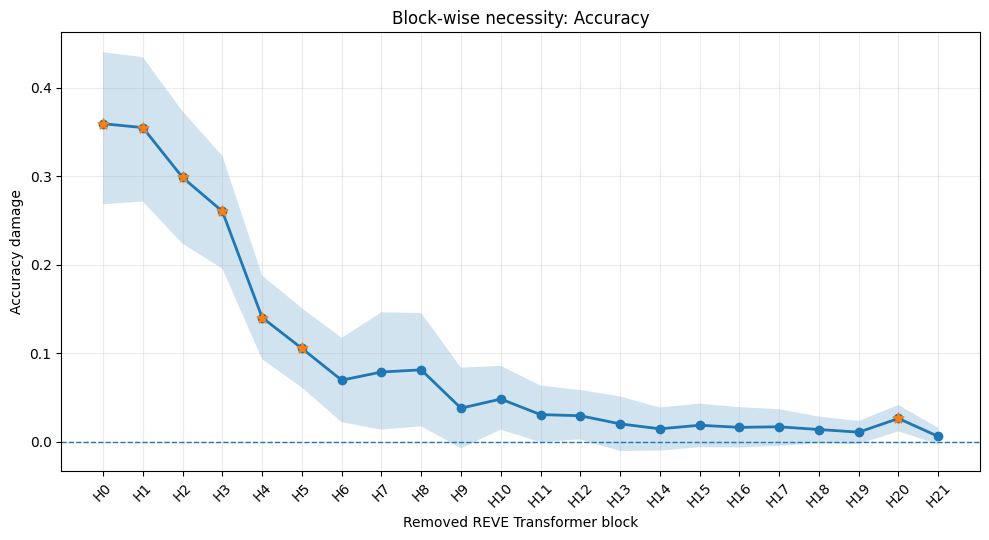

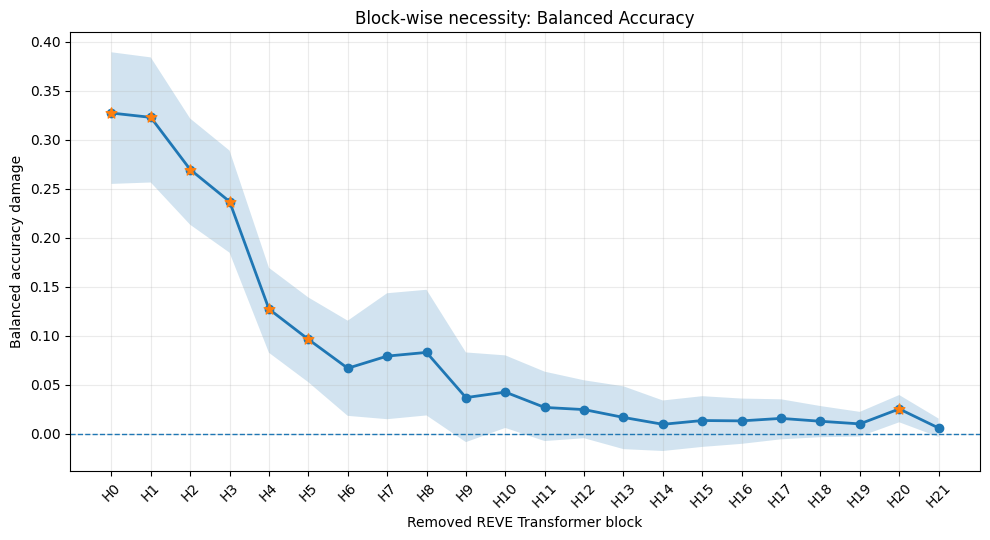

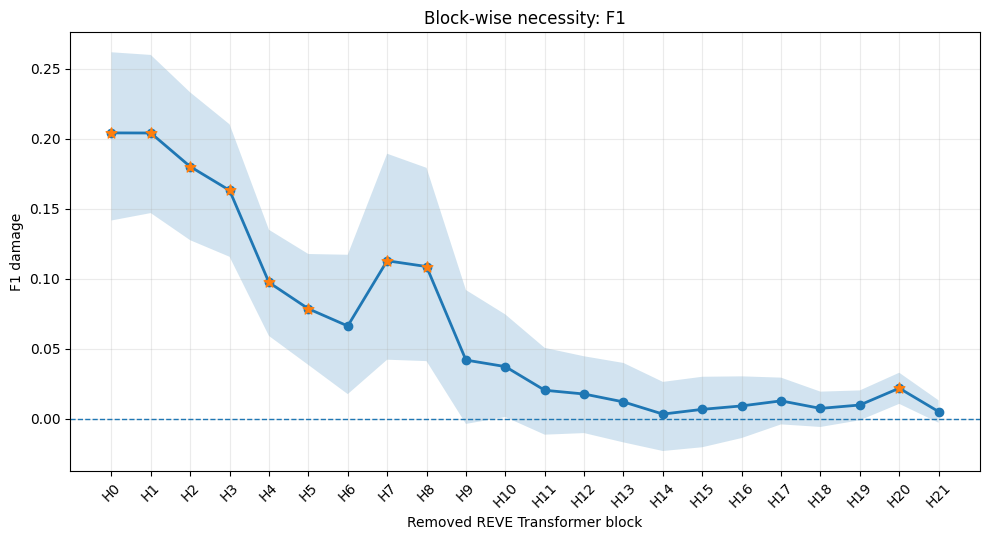

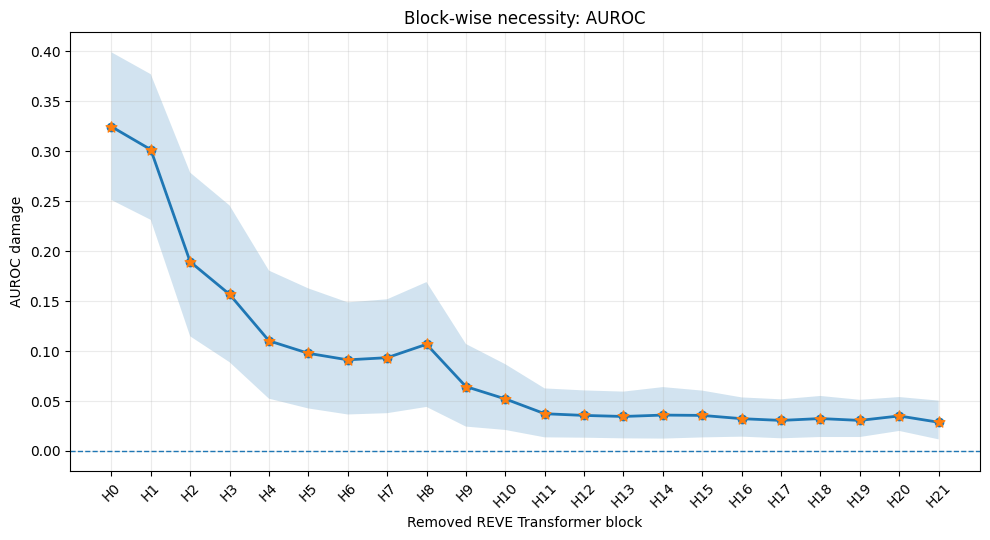


CELL 61 COMPLETE
Elapsed time: 0.81 min

PRIMARY AUROC NECESSITY
FDR-significant blocks: 22/22
95% CI excludes zero: 22/22

ALL METRICS
damage_accuracy: 7/22 FDR-significant
damage_balanced_accuracy: 7/22 FDR-significant
damage_f1: 9/22 FDR-significant
damage_auroc: 22/22 FDR-significant

Saved:
  /content/drive/MyDrive/Seinna_REVE_LOSO/novelty2_results/block_necessity_statistics.csv
  /content/drive/MyDrive/Seinna_REVE_LOSO/novelty2_results/block_necessity_subject_level.csv
  /content/drive/MyDrive/Seinna_REVE_LOSO/novelty2_results/novelty2_depth_profiles.csv
  /content/drive/MyDrive/Seinna_REVE_LOSO/novelty2_results/novelty2_significant_blocks.csv
  /content/drive/MyDrive/Seinna_REVE_LOSO/novelty2_results/novelty2_primary_auroc_necessity.csv
  /content/drive/MyDrive/Seinna_REVE_LOSO/novelty2_results/plots
  /content/drive/MyDrive/Seinna_REVE_LOSO/novelty2_results/novelty2_statistics_manifest.json

NEXT → CELL 62
Calculate predicted block removability from functional + task informati

15626

In [ ]:
# ============================================================
# CELL 61 — NOVELTY 2 STATISTICAL VALIDATION + PLOTS
# ============================================================
#
# Novelty 2:
#   BLOCK-WISE FUNCTIONAL NECESSITY
#
# Uses Cell 60:
#   D_l = P_baseline - P_without_block_l
#
# Statistical unit:
#   12 LOSO TEST SUBJECTS
#
# Five seeds are averaged within each subject/block before
# statistical testing.
#
# Tests:
#   - Wilcoxon signed-rank test
#   - FDR correction across 22 blocks
#   - rank-biserial effect size
#   - 95% bootstrap CI across subjects
#
# Outputs:
#   block_necessity_statistics.csv
#   block_necessity_subject_level.csv
#   novelty2_depth_profiles.csv
#   Novelty-2 plots
#   novelty2_manifest.json
#
# ============================================================

import os
import gc
import json
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import (
    wilcoxon,
    rankdata
)

from statsmodels.stats.multitest import (
    multipletests
)

# ============================================================
# 1. PATHS
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

RESULT_DIR = os.path.join(
    BASE_DIR,
    "novelty2_results"
)

RESULT_PATH = os.path.join(
    RESULT_DIR,
    "single_block_damage_results.csv"
)

SUMMARY_PATH = os.path.join(
    RESULT_DIR,
    "block_necessity_summary.csv"
)

STATISTICS_PATH = os.path.join(
    RESULT_DIR,
    "block_necessity_statistics.csv"
)

SUBJECT_LEVEL_PATH = os.path.join(
    RESULT_DIR,
    "block_necessity_subject_level.csv"
)

DEPTH_PROFILE_PATH = os.path.join(
    RESULT_DIR,
    "novelty2_depth_profiles.csv"
)

PLOT_DIR = os.path.join(
    RESULT_DIR,
    "plots"
)

CHECKPOINT_PATH = os.path.join(
    RESULT_DIR,
    "novelty2_statistics_checkpoint.json"
)

MANIFEST_PATH = os.path.join(
    RESULT_DIR,
    "novelty2_statistics_manifest.json"
)

os.makedirs(
    RESULT_DIR,
    exist_ok=True
)

os.makedirs(
    PLOT_DIR,
    exist_ok=True
)

# ============================================================
# 2. CONFIGURATION
# ============================================================

SUBJECTS = [
    "PN00",
    "PN01",
    "PN06",
    "PN07",
    "PN09",
    "PN10",
    "PN11",
    "PN12",
    "PN13",
    "PN14",
    "PN16",
    "PN17"
]

N_BLOCKS = 22

SEEDS = [
    20,
    25,
    30,
    35,
    40
]

N_BOOTSTRAP = 10000

ALPHA = 0.05

print("=" * 75)
print("CELL 61 — NOVELTY 2 STATISTICAL VALIDATION")
print("=" * 75)

print(
    f"Subjects           : {len(SUBJECTS)}"
)

print(
    f"Blocks             : {N_BLOCKS}"
)

print(
    f"Seeds              : {SEEDS}"
)

print(
    f"Bootstrap samples  : {N_BOOTSTRAP}"
)

print(
    "Statistical unit   : LOSO subject"
)

print()

# ============================================================
# 3. LOAD CELL 60 RESULTS
# ============================================================

assert os.path.exists(
    RESULT_PATH
), (
    "Cell 60 results were not found:\n"
    f"{RESULT_PATH}"
)

results_df = pd.read_csv(
    RESULT_PATH
)

expected_rows = (
    len(SUBJECTS)
    * N_BLOCKS
    * len(SEEDS)
)

print(
    f"Loaded rows        : {len(results_df)}"
)

print(
    f"Expected rows      : {expected_rows}"
)

assert len(results_df) == expected_rows, (
    f"Expected {expected_rows} rows, "
    f"found {len(results_df)}"
)

# ============================================================
# 4. VERIFY SUBJECTS / BLOCKS / SEEDS
# ============================================================

assert set(
    results_df["test_subject"]
) == set(SUBJECTS)

assert set(
    results_df["removed_block"]
) == set(
    range(1, N_BLOCKS + 1)
)

assert set(
    results_df["seed"]
) == set(SEEDS)

# Every subject/block should have exactly 5 seeds
counts = (
    results_df
    .groupby(
        [
            "test_subject",
            "removed_block"
        ]
    )
    .size()
)

assert (
    counts == len(SEEDS)
).all(), (
    "Some subject/block combinations "
    "do not contain all 5 seeds."
)

print(
    "✓ Cell 60 structure verified"
)

# ============================================================
# 5. SUBJECT-LEVEL AGGREGATION
# ============================================================
#
# Five seeds are averaged within each subject.
#
# This gives:
#
#   22 blocks × 12 subjects
#   = 264 statistical observations
#
# The Wilcoxon test for each block then has:
#
#   n = 12 paired subject-level observations
#
# ============================================================

metrics = [
    "damage_accuracy",
    "damage_balanced_accuracy",
    "damage_f1",
    "damage_auroc"
]

subject_rows = []

for block_idx in range(
    1,
    N_BLOCKS + 1
):

    block_df = results_df[
        results_df[
            "removed_block"
        ] == block_idx
    ]

    for subject in SUBJECTS:

        subject_df = block_df[
            block_df[
                "test_subject"
            ] == subject
        ]

        assert len(
            subject_df
        ) == len(SEEDS)

        row = {

            "test_subject":
                subject,

            "removed_block":
                block_idx,

            "removed_layer":
                f"H{block_idx-1}"
        }

        for metric in metrics:

            row[metric] = (
                subject_df[
                    metric
                ].mean()
            )

        # Also retain performance levels
        row[
            "baseline_accuracy"
        ] = subject_df[
            "baseline_accuracy"
        ].mean()

        row[
            "ablated_accuracy"
        ] = subject_df[
            "ablated_accuracy"
        ].mean()

        row[
            "baseline_f1"
        ] = subject_df[
            "baseline_f1"
        ].mean()

        row[
            "ablated_f1"
        ] = subject_df[
            "ablated_f1"
        ].mean()

        row[
            "baseline_auroc"
        ] = subject_df[
            "baseline_auroc"
        ].mean()

        row[
            "ablated_auroc"
        ] = subject_df[
            "ablated_auroc"
        ].mean()

        subject_rows.append(
            row
        )

subject_df_all = pd.DataFrame(
    subject_rows
)

assert len(
    subject_df_all
) == (
    len(SUBJECTS)
    * N_BLOCKS
)

subject_df_all.to_csv(
    SUBJECT_LEVEL_PATH,
    index=False
)

print(
    f"✓ Subject-level data saved: "
    f"{len(subject_df_all)} rows"
)

# ============================================================
# 6. RANK-BISERIAL EFFECT SIZE
# ============================================================

def rank_biserial_wilcoxon(
    differences
):
    """
    Rank-biserial correlation for a
    paired Wilcoxon signed-rank test.

    Positive value:
        generally positive damage.

    Negative value:
        generally negative damage.

    Zero:
        no systematic directional effect.
    """

    differences = np.asarray(
        differences,
        dtype=float
    )

    differences = differences[
        np.isfinite(differences)
    ]

    differences = differences[
        differences != 0
    ]

    if len(differences) == 0:
        return np.nan

    ranks = rankdata(
        np.abs(differences),
        method="average"
    )

    positive_rank_sum = (
        ranks[
            differences > 0
        ].sum()
    )

    negative_rank_sum = (
        ranks[
            differences < 0
        ].sum()
    )

    denominator = (
        positive_rank_sum
        + negative_rank_sum
    )

    if denominator == 0:
        return np.nan

    return (
        positive_rank_sum
        - negative_rank_sum
    ) / denominator


# ============================================================
# 7. BOOTSTRAP 95% CI
# ============================================================

def bootstrap_mean_ci(
    values,
    n_bootstrap=10000,
    seed=12345
):

    values = np.asarray(
        values,
        dtype=float
    )

    values = values[
        np.isfinite(values)
    ]

    n = len(values)

    if n == 0:
        return np.nan, np.nan

    rng = np.random.default_rng(
        seed
    )

    bootstrap_means = np.empty(
        n_bootstrap,
        dtype=float
    )

    for i in range(
        n_bootstrap
    ):

        sample = rng.choice(
            values,
            size=n,
            replace=True
        )

        bootstrap_means[i] = (
            np.mean(sample)
        )

    lower = np.percentile(
        bootstrap_means,
        2.5
    )

    upper = np.percentile(
        bootstrap_means,
        97.5
    )

    return (
        lower,
        upper
    )


# ============================================================
# 8. WILCOXON + EFFECT + CI
# ============================================================

print()
print(
    "Running statistical tests..."
)

stat_rows = []

cell_start = time.time()

for block_idx in range(
    1,
    N_BLOCKS + 1
):

    block_df = subject_df_all[
        subject_df_all[
            "removed_block"
        ] == block_idx
    ]

    row = {

        "removed_block":
            block_idx,

        "removed_layer":
            f"H{block_idx-1}",

        "n_subjects":
            len(block_df)
    }

    for metric in metrics:

        values = (
            block_df[
                metric
            ].to_numpy(
                dtype=float
            )
        )

        # ----------------------------------------------------
        # Mean / SD / median
        # ----------------------------------------------------

        mean_value = np.mean(
            values
        )

        sd_value = np.std(
            values,
            ddof=1
        )

        median_value = np.median(
            values
        )

        # ----------------------------------------------------
        # Wilcoxon
        # ----------------------------------------------------

        try:

            w_stat, p_value = (
                wilcoxon(
                    values,
                    zero_method="wilcox",
                    alternative="two-sided",
                    method="auto"
                )
            )

        except ValueError:

            w_stat = np.nan
            p_value = np.nan

        # ----------------------------------------------------
        # Effect size
        # ----------------------------------------------------

        effect = (
            rank_biserial_wilcoxon(
                values
            )
        )

        # ----------------------------------------------------
        # Bootstrap CI
        # ----------------------------------------------------

        ci_low, ci_high = (
            bootstrap_mean_ci(
                values,
                n_bootstrap=N_BOOTSTRAP,
                seed=1000 + block_idx
            )
        )

        row[
            f"mean_{metric}"
        ] = mean_value

        row[
            f"sd_{metric}"
        ] = sd_value

        row[
            f"median_{metric}"
        ] = median_value

        row[
            f"wilcoxon_W_{metric}"
        ] = w_stat

        row[
            f"p_{metric}"
        ] = p_value

        row[
            f"rank_biserial_{metric}"
        ] = effect

        row[
            f"ci95_low_{metric}"
        ] = ci_low

        row[
            f"ci95_high_{metric}"
        ] = ci_high

    stat_rows.append(
        row
    )

    elapsed = (
        time.time()
        - cell_start
    )

    done = block_idx

    avg = (
        elapsed
        / done
    )

    remaining = (
        N_BLOCKS
        - done
    )

    eta = (
        avg
        * remaining
        / 60
    )

    print(
        f"Block {block_idx:02d}/{N_BLOCKS} | "
        f"Elapsed {elapsed/60:.2f} min | "
        f"ETA {eta:.2f} min"
    )

statistics_df = pd.DataFrame(
    stat_rows
)

# ============================================================
# 9. FDR CORRECTION
# ============================================================
#
# Correct separately for each metric across the 22 blocks.
#
# Thus:
#
#   Accuracy: 22 tests
#   Balanced Accuracy: 22 tests
#   F1: 22 tests
#   AUROC: 22 tests
#
# ============================================================

for metric in metrics:

    p_col = (
        f"p_{metric}"
    )

    q_col = (
        f"q_{metric}_FDR"
    )

    p_values = (
        statistics_df[
            p_col
        ].to_numpy(
            dtype=float
        )
    )

    valid = np.isfinite(
        p_values
    )

    q_values = np.full(
        len(p_values),
        np.nan
    )

    if valid.any():

        q_values[valid] = (
            multipletests(
                p_values[valid],
                alpha=ALPHA,
                method="fdr_bh"
            )[1]
        )

    statistics_df[
        q_col
    ] = q_values

    # FDR significance
    statistics_df[
        f"significant_{metric}"
    ] = (
        statistics_df[
            q_col
        ] < ALPHA
    )

# ============================================================
# 10. CI SIGNIFICANCE
# ============================================================

for metric in metrics:

    low_col = (
        f"ci95_low_{metric}"
    )

    high_col = (
        f"ci95_high_{metric}"
    )

    statistics_df[
        f"ci_excludes_zero_{metric}"
    ] = ~(
        (
            statistics_df[
                low_col
            ] <= 0
        )
        &
        (
            statistics_df[
                high_col
            ] >= 0
        )
    )

# ============================================================
# 11. OVERALL NOVELTY-2 SUMMARY
# ============================================================

# Use AUROC as the primary task metric,
# while retaining all other metrics.

statistics_df[
    "significant_primary"
] = statistics_df[
    "significant_damage_auroc"
]

statistics_df[
    "ci_excludes_zero_primary"
] = statistics_df[
    "ci_excludes_zero_damage_auroc"
]

statistics_df[
    "mean_damage_primary"
] = statistics_df[
    "mean_damage_auroc"
]

statistics_df[
    "effect_primary"
] = statistics_df[
    "rank_biserial_damage_auroc"
]

# ------------------------------------------------------------
# Any metric significant?
# ------------------------------------------------------------

statistics_df[
    "significant_any_metric"
] = (
    statistics_df[
        [
            "significant_damage_accuracy",
            "significant_damage_balanced_accuracy",
            "significant_damage_f1",
            "significant_damage_auroc"
        ]
    ].any(
        axis=1
    )
)

# ------------------------------------------------------------
# Number of significant metrics
# ------------------------------------------------------------

statistics_df[
    "n_significant_metrics"
] = (
    statistics_df[
        [
            "significant_damage_accuracy",
            "significant_damage_balanced_accuracy",
            "significant_damage_f1",
            "significant_damage_auroc"
        ]
    ].sum(
        axis=1
    )
)

# ============================================================
# 12. SAVE STATISTICS
# ============================================================

statistics_df.to_csv(
    STATISTICS_PATH,
    index=False
)

print()
print(
    "✓ Statistical results saved:"
)

print(
    STATISTICS_PATH
)

# ============================================================
# 13. DEPTH PROFILE TABLE
# ============================================================

depth_rows = []

for _, row in statistics_df.iterrows():

    block_idx = int(
        row["removed_block"]
    )

    depth_rows.append({

        "removed_block":
            block_idx,

        "layer":
            row[
                "removed_layer"
            ],

        "accuracy_damage_mean":
            row[
                "mean_damage_accuracy"
            ],

        "accuracy_damage_ci_low":
            row[
                "ci95_low_damage_accuracy"
            ],

        "accuracy_damage_ci_high":
            row[
                "ci95_high_damage_accuracy"
            ],

        "accuracy_q_fdr":
            row[
                "q_damage_accuracy_FDR"
            ],

        "balanced_accuracy_damage_mean":
            row[
                "mean_damage_balanced_accuracy"
            ],

        "balanced_accuracy_damage_ci_low":
            row[
                "ci95_low_damage_balanced_accuracy"
            ],

        "balanced_accuracy_damage_ci_high":
            row[
                "ci95_high_damage_balanced_accuracy"
            ],

        "balanced_accuracy_q_fdr":
            row[
                "q_damage_balanced_accuracy_FDR"
            ],

        "f1_damage_mean":
            row[
                "mean_damage_f1"
            ],

        "f1_damage_ci_low":
            row[
                "ci95_low_damage_f1"
            ],

        "f1_damage_ci_high":
            row[
                "ci95_high_damage_f1"
            ],

        "f1_q_fdr":
            row[
                "q_damage_f1_FDR"
            ],

        "auroc_damage_mean":
            row[
                "mean_damage_auroc"
            ],

        "auroc_damage_ci_low":
            row[
                "ci95_low_damage_auroc"
            ],

        "auroc_damage_ci_high":
            row[
                "ci95_high_damage_auroc"
            ],

        "auroc_q_fdr":
            row[
                "q_damage_auroc_FDR"
            ],

        "auroc_effect":
            row[
                "rank_biserial_damage_auroc"
            ]
    })

depth_df = pd.DataFrame(
    depth_rows
)

depth_df.to_csv(
    DEPTH_PROFILE_PATH,
    index=False
)

# ============================================================
# 14. PLOT FUNCTION
# ============================================================

def make_depth_plot(
    metric_name,
    ylabel,
    filename,
    mean_column,
    low_column,
    high_column,
    q_column
):

    x = statistics_df[
        "removed_block"
    ].to_numpy()

    mean = statistics_df[
        mean_column
    ].to_numpy()

    low = statistics_df[
        low_column
    ].to_numpy()

    high = statistics_df[
        high_column
    ].to_numpy()

    q = statistics_df[
        q_column
    ].to_numpy()

    plt.figure(
        figsize=(10, 5.5)
    )

    plt.plot(
        x,
        mean,
        marker="o",
        linewidth=2
    )

    plt.fill_between(
        x,
        low,
        high,
        alpha=0.20
    )

    # Zero-damage reference
    plt.axhline(
        0,
        linestyle="--",
        linewidth=1
    )

    # Mark FDR-significant blocks
    significant = (
        q < ALPHA
    )

    if significant.any():

        plt.scatter(
            x[significant],
            mean[significant],
            s=65,
            marker="*",
            zorder=5
        )

    plt.xlabel(
        "Removed REVE Transformer block"
    )

    plt.ylabel(
        ylabel
    )

    plt.title(
        f"Block-wise necessity: {metric_name}"
    )

    plt.xticks(
        x,
        [
            f"H{i}"
            for i in range(
                N_BLOCKS
            )
        ],
        rotation=45
    )

    plt.grid(
        alpha=0.25
    )

    plt.tight_layout()

    save_path = os.path.join(
        PLOT_DIR,
        filename
    )

    plt.savefig(
        save_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

    plt.close()

    return save_path


# ============================================================
# 15. CREATE FOUR DEPTH-WISE PLOTS
# ============================================================

print()
print(
    "=" * 75
)

print(
    "CREATING NOVELTY 2 DEPTH PROFILES"
)

print(
    "=" * 75
)

plot_paths = []

plot_paths.append(
    make_depth_plot(
        "Accuracy",
        "Accuracy damage",
        "novelty2_accuracy_damage.png",
        "mean_damage_accuracy",
        "ci95_low_damage_accuracy",
        "ci95_high_damage_accuracy",
        "q_damage_accuracy_FDR"
    )
)

plot_paths.append(
    make_depth_plot(
        "Balanced Accuracy",
        "Balanced accuracy damage",
        "novelty2_balanced_accuracy_damage.png",
        "mean_damage_balanced_accuracy",
        "ci95_low_damage_balanced_accuracy",
        "ci95_high_damage_balanced_accuracy",
        "q_damage_balanced_accuracy_FDR"
    )
)

plot_paths.append(
    make_depth_plot(
        "F1",
        "F1 damage",
        "novelty2_f1_damage.png",
        "mean_damage_f1",
        "ci95_low_damage_f1",
        "ci95_high_damage_f1",
        "q_damage_f1_FDR"
    )
)

plot_paths.append(
    make_depth_plot(
        "AUROC",
        "AUROC damage",
        "novelty2_auroc_damage.png",
        "mean_damage_auroc",
        "ci95_low_damage_auroc",
        "ci95_high_damage_auroc",
        "q_damage_auroc_FDR"
    )
)

# ============================================================
# 16. SIGNIFICANT BLOCK TABLE
# ============================================================

significant_blocks = statistics_df[
    statistics_df[
        "significant_any_metric"
    ]
].copy()

SIGNIFICANT_PATH = os.path.join(
    RESULT_DIR,
    "novelty2_significant_blocks.csv"
)

significant_blocks.to_csv(
    SIGNIFICANT_PATH,
    index=False
)

# ============================================================
# 17. PRIMARY AUROC SUMMARY
# ============================================================

primary = statistics_df[
    [
        "removed_block",
        "removed_layer",
        "mean_damage_auroc",
        "sd_damage_auroc",
        "median_damage_auroc",
        "wilcoxon_W_damage_auroc",
        "p_damage_auroc",
        "q_damage_auroc_FDR",
        "rank_biserial_damage_auroc",
        "ci95_low_damage_auroc",
        "ci95_high_damage_auroc",
        "significant_damage_auroc",
        "ci_excludes_zero_damage_auroc"
    ]
].copy()

PRIMARY_PATH = os.path.join(
    RESULT_DIR,
    "novelty2_primary_auroc_necessity.csv"
)

primary.to_csv(
    PRIMARY_PATH,
    index=False
)

# ============================================================
# 18. SUMMARY COUNTS
# ============================================================

summary_counts = {}

for metric in metrics:

    summary_counts[
        metric
    ] = {

        "n_fdr_significant":
            int(
                statistics_df[
                    f"significant_{metric}"
                ].sum()
            ),

        "n_ci_excludes_zero":
            int(
                statistics_df[
                    f"ci_excludes_zero_{metric}"
                ].sum()
            ),

        "max_mean_damage":
            float(
                statistics_df[
                    f"mean_{metric}"
                ].max()
            ),

        "min_mean_damage":
            float(
                statistics_df[
                    f"mean_{metric}"
                ].min()
            )
    }

# ============================================================
# 19. TOP BLOCKS BY PRIMARY DAMAGE
# ============================================================

top_by_auroc = (
    statistics_df
    .sort_values(
        "mean_damage_auroc",
        ascending=False
    )
    [
        [
            "removed_block",
            "removed_layer",
            "mean_damage_auroc",
            "q_damage_auroc_FDR",
            "rank_biserial_damage_auroc"
        ]
    ]
    .head(10)
)

TOP_PATH = os.path.join(
    RESULT_DIR,
    "novelty2_top_auroc_damage_blocks.csv"
)

top_by_auroc.to_csv(
    TOP_PATH,
    index=False
)

# ============================================================
# 20. FINAL MANIFEST
# ============================================================

total_elapsed = (
    time.time()
    - cell_start
) / 60

manifest = {

    "experiment":
        "Novelty 2 — Block-wise functional necessity",

    "definition":
        "D_l = baseline performance - "
        "performance without block l",

    "statistical_unit":
        "LOSO test subject",

    "subjects":
        SUBJECTS,

    "n_subjects":
        len(SUBJECTS),

    "n_blocks":
        N_BLOCKS,

    "seeds":
        SEEDS,

    "seed_aggregation":
        "mean across five seeds within subject/block",

    "wilcoxon":
        "paired two-sided Wilcoxon signed-rank",

    "fdr":
        "Benjamini-Hochberg separately across 22 blocks for each metric",

    "alpha":
        ALPHA,

    "bootstrap_samples":
        N_BOOTSTRAP,

    "confidence_interval":
        "95% percentile bootstrap CI across subjects",

    "effect_size":
        "rank-biserial correlation",

    "primary_metric":
        "AUROC damage",

    "metrics":
        metrics,

    "expected_raw_rows":
        expected_rows,

    "actual_raw_rows":
        len(results_df),

    "subject_level_rows":
        len(subject_df_all),

    "significant_counts":
        summary_counts,

    "raw_results":
        RESULT_PATH,

    "subject_level_results":
        SUBJECT_LEVEL_PATH,

    "statistics":
        STATISTICS_PATH,

    "depth_profiles":
        DEPTH_PROFILE_PATH,

    "significant_blocks":
        SIGNIFICANT_PATH,

    "primary_results":
        PRIMARY_PATH,

    "top_blocks":
        TOP_PATH,

    "plots":
        plot_paths,

    "elapsed_minutes":
        total_elapsed,

    "status":
        "complete"
}

with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )

# ============================================================
# 21. FINAL CONSOLE SUMMARY
# ============================================================

print()
print("=" * 75)
print("CELL 61 COMPLETE")
print("=" * 75)

print(
    f"Elapsed time: "
    f"{total_elapsed:.2f} min"
)

print()
print(
    "PRIMARY AUROC NECESSITY"
)

print(
    f"FDR-significant blocks: "
    f"{summary_counts['damage_auroc']['n_fdr_significant']}/22"
)

print(
    f"95% CI excludes zero: "
    f"{summary_counts['damage_auroc']['n_ci_excludes_zero']}/22"
)

print()
print(
    "ALL METRICS"
)

for metric in metrics:

    print(
        f"{metric}: "
        f"{summary_counts[metric]['n_fdr_significant']}/22 "
        f"FDR-significant"
    )

print()
print(
    "Saved:"
)

print(
    f"  {STATISTICS_PATH}"
)

print(
    f"  {SUBJECT_LEVEL_PATH}"
)

print(
    f"  {DEPTH_PROFILE_PATH}"
)

print(
    f"  {SIGNIFICANT_PATH}"
)

print(
    f"  {PRIMARY_PATH}"
)

print(
    f"  {PLOT_DIR}"
)

print(
    f"  {MANIFEST_PATH}"
)

print()
print(
    "NEXT → CELL 62"
)

print(
    "Calculate predicted block removability "
    "from functional + task information."
)

print(
    "Cells remaining after Cell 61: "
    "10 (Cells 62–71)"
)

# ============================================================
# CLEANUP
# ============================================================

gc.collect()

In [ ]:
# ============================================================
# 5. LOAD NOVELTY 2 NECESSITY
# ============================================================

print("\n" + "=" * 75)
print("LOADING NOVELTY 2 BLOCK NECESSITY")
print("=" * 75)

# ------------------------------------------------------------
# PRIMARY NOVELTY 2 FILE CREATED BY CELL 61
# ------------------------------------------------------------

N2_FILE = (
    NOVELTY2_DIR /
    "novelty2_primary_auroc_necessity.csv"
)

if not N2_FILE.exists():
    raise FileNotFoundError(
        f"Novelty 2 primary AUROC file not found:\n{N2_FILE}"
    )

n2 = pd.read_csv(N2_FILE)

print("Novelty 2 rows:", len(n2))
print("Columns:")
print(list(n2.columns))

# ------------------------------------------------------------
# CELL 61 ACTUAL COLUMN NAMES
# ------------------------------------------------------------
#
# removed_block
# removed_layer
# mean_damage_auroc
# sd_damage_auroc
# median_damage_auroc
# wilcoxon_W_damage_auroc
# p_damage_auroc
# q_damage_auroc_FDR
# rank_biserial_damage_auroc
# ci95_low_damage_auroc
# ci95_high_damage_auroc
# significant_damage_auroc
# ci_excludes_zero_damage_auroc
# ------------------------------------------------------------

if "removed_block" not in n2.columns:
    raise ValueError(
        "Expected 'removed_block' column was not found "
        "in Novelty 2 primary AUROC results."
    )

if "mean_damage_auroc" not in n2.columns:
    raise ValueError(
        "Expected 'mean_damage_auroc' column was not found "
        "in Novelty 2 primary AUROC results."
    )

# Rename to common internal names
n2["block"] = pd.to_numeric(
    n2["removed_block"],
    errors="coerce"
)

n2["necessity_damage"] = pd.to_numeric(
    n2["mean_damage_auroc"],
    errors="coerce"
)

# Keep valid blocks
n2 = n2[
    n2["block"].between(1, N_BLOCKS) &
    np.isfinite(n2["necessity_damage"])
].copy()

# ------------------------------------------------------------
# VERIFY 22 BLOCKS
# ------------------------------------------------------------

if len(n2) != N_BLOCKS:
    raise ValueError(
        f"Expected {N_BLOCKS} Novelty 2 block results, "
        f"but found {len(n2)}."
    )

if set(n2["block"].astype(int)) != set(BLOCKS):
    raise ValueError(
        "Novelty 2 does not contain exactly blocks 1–22."
    )

# ------------------------------------------------------------
# NORMALIZE NECESSITY
# ------------------------------------------------------------
#
# Larger AUROC damage = more necessary.
#
# Therefore:
#
#     high necessity_damage
#         -> important
#         -> retain
#
#     low necessity_damage
#         -> less necessary
#         -> removable
# ------------------------------------------------------------

necessity_df = (
    n2
    .groupby("block", as_index=False)["necessity_damage"]
    .mean()
)

necessity_df["necessity_importance"] = normalize_01(
    necessity_df["necessity_damage"].values
)

necessity_df = necessity_df.sort_values(
    "block"
).reset_index(drop=True)

# ------------------------------------------------------------
# PRINT
# ------------------------------------------------------------

print("\nNovelty 2 necessity profile:")
print(
    necessity_df[
        [
            "block",
            "necessity_damage",
            "necessity_importance"
        ]
    ].round(6).to_string(index=False)
)

# ------------------------------------------------------------
# SAVE
# ------------------------------------------------------------

necessity_df.to_csv(
    RANK_DIR / "necessity_block_importance.csv",
    index=False
)

print(
    "\n✓ Novelty 2 necessity loaded successfully"
)

print(
    f"✓ {len(necessity_df)}/{N_BLOCKS} blocks verified"
)

print(
    f"✓ Primary AUROC damage used: "
    f"mean_damage_auroc"
)


LOADING NOVELTY 2 BLOCK NECESSITY
Novelty 2 rows: 22
Columns:
['removed_block', 'removed_layer', 'mean_damage_auroc', 'sd_damage_auroc', 'median_damage_auroc', 'wilcoxon_W_damage_auroc', 'p_damage_auroc', 'q_damage_auroc_FDR', 'rank_biserial_damage_auroc', 'ci95_low_damage_auroc', 'ci95_high_damage_auroc', 'significant_damage_auroc', 'ci_excludes_zero_damage_auroc']

Novelty 2 necessity profile:
 block  necessity_damage  necessity_importance
     1          0.324772              1.000000
     2          0.301739              0.922186
     3          0.189432              0.542754
     4          0.156839              0.432637
     5          0.110332              0.275513
     6          0.097805              0.233189
     7          0.091269              0.211107
     8          0.093425              0.218393
     9          0.106852              0.263756
    10          0.064503              0.120679
    11          0.052125              0.078858
    12          0.037322            

In [ ]:
# ============================================================
# CELLS 62–65 COMBINED
# RANDOM + DDF + SSN + OURS
#
# REVE + SIENA EEG
# 22 Transformer blocks: H0 ... H21
#
# This cell:
#   1. Loads Novelty 1 functional information
#   2. Loads Novelty 2 necessity information
#   3. Computes DDF ranking
#   4. Computes SSN ranking
#   5. Computes Random rankings
#   6. Computes OURS function-aware ranking
#   7. Creates pruning plans for 10–90%
#
# ETA + progress included
# Resume not required because this cell is ranking/planning,
# not the final expensive pruning evaluation.
#
# After completion:
#   Cell 66 -> Ours validation
#   Cell 67 -> Final pruning evaluation
# ============================================================

import os
import gc
import json
import math
import time
import random
import warnings

from pathlib import Path

import numpy as np
import pandas as pd
import torch

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

warnings.filterwarnings("ignore")


# ============================================================
# 0. START TIMER
# ============================================================

CELL_START = time.time()

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)


# ============================================================
# 1. PATHS
# ============================================================

ROOT = Path(
    "/content/drive/MyDrive/Seinna_REVE_LOSO"
)

FEATURE_DIR = (
    ROOT /
    "reve_features_22ch"
)

EPOCH_DIR = (
    ROOT /
    "subject_epochs_22ch"
)

NOVELTY1_DIR = (
    ROOT /
    "novelty1_probes" /
    "novelty1_statistics"
)

NOVELTY2_DIR = (
    ROOT /
    "novelty2_results"
)

OUT_DIR = (
    ROOT /
    "novelty3_pruning"
)

RANK_DIR = (
    OUT_DIR /
    "rankings"
)

PLAN_DIR = (
    OUT_DIR /
    "pruning_plans"
)

RANK_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PLAN_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# 2. EXPERIMENT CONFIGURATION
# ============================================================

SUBJECTS = [
    "PN00",
    "PN01",
    "PN06",
    "PN07",
    "PN09",
    "PN10",
    "PN11",
    "PN12",
    "PN13",
    "PN14",
    "PN16",
    "PN17"
]

N_SUBJECTS = len(
    SUBJECTS
)

N_BLOCKS = 22

BLOCKS = list(
    range(
        1,
        N_BLOCKS + 1
    )
)

PRUNING_RATIOS = [
    10,
    20,
    30,
    40,
    50,
    60,
    70,
    80,
    90
]

SEEDS = [
    20,
    25,
    30,
    35,
    40
]


print("=" * 75)
print("COMBINED CELLS 62–65")
print("Random + DDF + SSN + Ours")
print("=" * 75)

print(
    f"Device             : {DEVICE}"
)

print(
    f"Subjects           : {N_SUBJECTS}"
)

print(
    f"Transformer blocks : {N_BLOCKS}"
)

print(
    f"Pruning ratios     : {PRUNING_RATIOS}"
)

print(
    f"Random seeds       : {SEEDS}"
)

print(
    f"Output directory   : {OUT_DIR}"
)


# ============================================================
# 3. TIMER / ETA FUNCTIONS
# ============================================================

def elapsed_minutes():

    return (
        time.time() -
        CELL_START
    ) / 60.0


def eta_minutes(
    done,
    total
):

    if done <= 0:

        return float("nan")

    elapsed = (
        time.time() -
        CELL_START
    )

    remaining = (
        total -
        done
    )

    return (
        elapsed *
        remaining /
        done
    ) / 60.0


def print_progress(
    done,
    total,
    label
):

    pct = (
        100.0 *
        done /
        total
    )

    eta = eta_minutes(
        done,
        total
    )

    print(
        f"{label}: "
        f"{done}/{total} "
        f"({pct:.1f}%) | "
        f"Elapsed: {elapsed_minutes():.2f} min | "
        f"ETA: {eta:.2f} min"
    )


# ============================================================
# 4. NORMALIZATION FUNCTION
# ============================================================

def normalize_01(
    values
):

    x = np.asarray(
        values,
        dtype=np.float64
    )

    finite = np.isfinite(
        x
    )

    if not np.any(
        finite
    ):

        return np.full(
            x.shape,
            0.5,
            dtype=np.float64
        )

    lo = np.nanmin(
        x[finite]
    )

    hi = np.nanmax(
        x[finite]
    )

    if abs(
        hi - lo
    ) < 1e-12:

        return np.full(
            x.shape,
            0.5,
            dtype=np.float64
        )

    out = (
        x - lo
    ) / (
        hi - lo
    )

    out[
        ~np.isfinite(out)
    ] = 0.5

    return out


# ============================================================
# 5. LOAD NOVELTY 1
# ============================================================

print("\n" + "=" * 75)
print("STEP 1/7 — LOADING NOVELTY 1")
print("=" * 75)


N1_FILE = (
    NOVELTY1_DIR /
    "novelty1_pretrained_vs_random_statistics.csv"
)


if not N1_FILE.exists():

    raise FileNotFoundError(
        f"\nNovelty 1 file not found:\n"
        f"{N1_FILE}"
    )


n1 = pd.read_csv(
    N1_FILE
)


print(
    f"Novelty 1 rows: {len(n1)}"
)

print(
    "Columns:"
)

print(
    list(
        n1.columns
    )
)


# ============================================================
# 6. VERIFY NOVELTY 1 COLUMNS
# ============================================================

required_n1 = [
    "function",
    "block",
    "mean_difference"
]


missing_n1 = [
    col
    for col in required_n1
    if col not in n1.columns
]


if missing_n1:

    raise ValueError(
        "Missing Novelty 1 columns: "
        f"{missing_n1}"
    )


# ============================================================
# 7. CLEAN NOVELTY 1
# ============================================================

n1["block"] = pd.to_numeric(
    n1["block"],
    errors="coerce"
)

n1["function"] = (
    n1["function"]
    .astype(str)
    .str.lower()
    .str.strip()
)

n1["effect"] = pd.to_numeric(
    n1["mean_difference"],
    errors="coerce"
)


n1 = n1[
    n1["block"].between(
        1,
        N_BLOCKS
    )
].copy()


n1 = n1[
    np.isfinite(
        n1["effect"]
    )
].copy()


EXPECTED_FUNCTIONS = [
    "spatial",
    "temporal",
    "spectral",
    "task"
]


print(
    "\nDetected functions:"
)

print(
    sorted(
        n1["function"]
        .unique()
    )
)


# ============================================================
# 8. FUNCTIONAL IMPORTANCE
# ============================================================
#
# For every block:
#
#   Spatial
#   Temporal
#   Spectral
#   Task
#
# Each profile is normalized independently.
#
# Then:
#
#   F_l =
#       mean(
#           Spatial_l,
#           Temporal_l,
#           Spectral_l,
#           Task_l
#       )
#
# ============================================================

print("\n" + "=" * 75)
print("STEP 2/7 — COMPUTING FUNCTIONAL IMPORTANCE")
print("=" * 75)


functional_rows = []


for block in BLOCKS:

    row = {
        "block": block
    }

    for function in EXPECTED_FUNCTIONS:

        vals = n1.loc[
            (
                n1["block"] == block
            )
            &
            (
                n1["function"] == function
            ),
            "effect"
        ].values

        if len(vals) == 0:

            row[
                function
            ] = np.nan

        else:

            row[
                function
            ] = float(
                np.mean(vals)
            )

    functional_rows.append(
        row
    )


functional_df = pd.DataFrame(
    functional_rows
)


# ============================================================
# 9. NORMALIZE FOUR FUNCTIONS
# ============================================================

for function in EXPECTED_FUNCTIONS:

    functional_df[
        f"{function}_norm"
    ] = normalize_01(
        functional_df[
            function
        ].values
    )


# ============================================================
# 10. AVERAGE FUNCTIONAL IMPORTANCE
# ============================================================

functional_df[
    "functional_importance"
] = (
    functional_df[
        "spatial_norm"
    ]
    +
    functional_df[
        "temporal_norm"
    ]
    +
    functional_df[
        "spectral_norm"
    ]
    +
    functional_df[
        "task_norm"
    ]
) / 4.0


print(
    "\nFunctional importance:"
)

print(
    functional_df[
        [
            "block",
            "spatial",
            "temporal",
            "spectral",
            "task",
            "functional_importance"
        ]
    ]
    .round(5)
    .to_string(
        index=False
    )
)


functional_df.to_csv(
    RANK_DIR /
    "functional_block_importance.csv",
    index=False
)


print(
    "\n✓ Functional importance saved."
)


# ============================================================
# 11. LOAD NOVELTY 2
# ============================================================

print("\n" + "=" * 75)
print("STEP 3/7 — LOADING NOVELTY 2 NECESSITY")
print("=" * 75)


N2_FILE = (
    NOVELTY2_DIR /
    "novelty2_primary_auroc_necessity.csv"
)


if not N2_FILE.exists():

    raise FileNotFoundError(
        f"\nNovelty 2 file not found:\n"
        f"{N2_FILE}"
    )


n2 = pd.read_csv(
    N2_FILE
)


print(
    f"Novelty 2 rows: {len(n2)}"
)

print(
    "Columns:"
)

print(
    list(
        n2.columns
    )
)


# ============================================================
# 12. VERIFY ACTUAL CELL 61 COLUMNS
# ============================================================

if (
    "removed_block"
    not in n2.columns
):

    raise ValueError(
        "Cell 61 file does not contain "
        "'removed_block'."
    )


if (
    "mean_damage_auroc"
    not in n2.columns
):

    raise ValueError(
        "Cell 61 file does not contain "
        "'mean_damage_auroc'."
    )


# ============================================================
# 13. STANDARDIZE NOVELTY 2
# ============================================================

n2["block"] = pd.to_numeric(
    n2["removed_block"],
    errors="coerce"
)

n2["necessity_damage"] = pd.to_numeric(
    n2["mean_damage_auroc"],
    errors="coerce"
)


n2 = n2[
    n2["block"].between(
        1,
        N_BLOCKS
    )
].copy()


n2 = n2[
    np.isfinite(
        n2["necessity_damage"]
    )
].copy()


# ============================================================
# 14. VERIFY ALL 22 BLOCKS
# ============================================================

if len(n2) != N_BLOCKS:

    raise ValueError(
        f"Expected {N_BLOCKS} blocks "
        f"in Novelty 2, found {len(n2)}."
    )


if (
    set(
        n2["block"].astype(int)
    )
    !=
    set(BLOCKS)
):

    raise ValueError(
        "Novelty 2 does not contain "
        "exactly blocks 1–22."
    )


# ============================================================
# 15. COMPUTE NECESSITY IMPORTANCE
# ============================================================
#
# Larger AUROC damage:
#
#       block removal hurts performance more
#
# Therefore:
#
#       larger damage = more necessary
#
# ============================================================

necessity_df = (
    n2[
        [
            "block",
            "necessity_damage"
        ]
    ]
    .groupby(
        "block",
        as_index=False
    )
    .mean()
)


necessity_df[
    "necessity_importance"
] = normalize_01(
    necessity_df[
        "necessity_damage"
    ].values
)


necessity_df = (
    necessity_df
    .sort_values(
        "block"
    )
    .reset_index(
        drop=True
    )
)


print(
    "\nNovelty 2 necessity:"
)

print(
    necessity_df
    .round(6)
    .to_string(
        index=False
    )
)


necessity_df.to_csv(
    RANK_DIR /
    "necessity_block_importance.csv",
    index=False
)


print(
    "\n✓ Novelty 2 necessity loaded."
)

print(
    "✓ 22/22 blocks verified."
)

print(
    "✓ Primary metric: mean_damage_auroc"
)


# ============================================================
# 16. FEATURE LOADER
# ============================================================

def load_reve_block(
    subject,
    block_idx
):

    path = (
        FEATURE_DIR /
        f"{subject}_reve_features.pt"
    )


    if not path.exists():

        raise FileNotFoundError(
            f"Missing feature file:\n{path}"
        )


    obj = torch.load(
        path,
        map_location="cpu"
    )


    # --------------------------------------------------------
    # REVE feature format:
    #
    # [H0, H1, ..., H21, H22]
    #
    # H0-H21 = 22 Transformer blocks
    # H22    = final transformer representation
    # --------------------------------------------------------

    if isinstance(
        obj,
        (list, tuple)
    ):

        outputs = obj

    elif isinstance(
        obj,
        dict
    ):

        if "outputs" in obj:

            outputs = obj[
                "outputs"
            ]

        elif "features" in obj:

            outputs = obj[
                "features"
            ]

        elif "X" in obj:

            outputs = obj[
                "X"
            ]

        else:

            raise ValueError(
                f"Unknown feature dictionary "
                f"structure: {path}"
            )

    else:

        raise TypeError(
            f"Unsupported feature type "
            f"for {path}: "
            f"{type(obj)}"
        )


    if len(outputs) != 23:

        raise ValueError(
            f"{subject}: expected 23 REVE "
            f"outputs, found {len(outputs)}"
        )


    # block_idx 1 -> H0
    # block_idx 22 -> H21

    rep = outputs[
        block_idx - 1
    ]


    if torch.is_tensor(
        rep
    ):

        rep = (
            rep
            .detach()
            .float()
            .numpy()
        )

    else:

        rep = np.asarray(
            rep,
            dtype=np.float32
        )


    if rep.ndim != 3:

        raise ValueError(
            f"{subject}, block {block_idx}: "
            f"expected 3-D representation, "
            f"got {rep.shape}"
        )


    return rep


# ============================================================
# 17. POOL REVE REPRESENTATION
# ============================================================
#
# Same representation used for classifier:
#
#       mean over tokens
#       std over tokens
#
#       512 + 512 = 1024
#
# ============================================================

def pool_rep(
    rep
):

    mean = rep.mean(
        axis=1
    )

    std = rep.std(
        axis=1
    )

    pooled = np.concatenate(
        [
            mean,
            std
        ],
        axis=1
    )

    return pooled.astype(
        np.float32
    )


# ============================================================
# 18. LABEL LOADER
# ============================================================

def load_labels(
    subject
):

    path = (
        EPOCH_DIR /
        f"{subject}_epochs.npz"
    )


    if not path.exists():

        raise FileNotFoundError(
            f"Missing epoch file:\n{path}"
        )


    data = np.load(
        path,
        allow_pickle=True
    )


    y = data[
        "y"
    ].astype(
        np.int64
    )


    return y


# ============================================================
# 19. LOAD POOLED BLOCK REPRESENTATIONS
# ============================================================

print("\n" + "=" * 75)
print("STEP 4/7 — LOADING BLOCK REPRESENTATIONS")
print("=" * 75)


pooled_features = {}


total_feature_jobs = (
    N_SUBJECTS *
    N_BLOCKS
)


feature_done = 0


for subject in SUBJECTS:

    pooled_features[
        subject
    ] = {}


    for block_idx in BLOCKS:

        rep = load_reve_block(
            subject,
            block_idx
        )


        X = pool_rep(
            rep
        )


        pooled_features[
            subject
        ][block_idx] = X


        del rep


        feature_done += 1


        if (
            feature_done == 1
            or
            feature_done % 10 == 0
            or
            feature_done == total_feature_jobs
        ):

            print_progress(
                feature_done,
                total_feature_jobs,
                "Feature loading"
            )


    gc.collect()


print(
    "\n✓ All pooled representations loaded."
)


# ============================================================
# 20. LOAD LABELS
# ============================================================

labels = {}


for subject in SUBJECTS:

    labels[
        subject
    ] = load_labels(
        subject
    )


# ============================================================
# 21. VERIFY FEATURE/LABEL LENGTHS
# ============================================================

for subject in SUBJECTS:

    for block_idx in BLOCKS:

        n_x = len(
            pooled_features[
                subject
            ][block_idx]
        )

        n_y = len(
            labels[
                subject
            ]
        )


        if n_x != n_y:

            raise ValueError(
                f"{subject}: block {block_idx} "
                f"feature/label mismatch: "
                f"{n_x} vs {n_y}"
            )


print(
    "✓ Feature/label dimensions verified."
)


# ============================================================
# 22. DDF + SSN
# ============================================================
#
# LOSO procedure:
#
# For each held-out subject:
#
#   Train on remaining subjects.
#
# For each block:
#
#   train binary task classifier
#
# Then calculate probability entropy:
#
#       H = -Σ p log(p)
#
# For adjacent blocks:
#
#       delta H = H_l - H_(l-1)
#
# DDF:
#
#       fraction(delta H < 0)
#
# SSN:
#
#       mean(|delta H|)
#
# These are task-aware adaptations for binary EEG.
# ============================================================

print("\n" + "=" * 75)
print("STEP 5/7 — COMPUTING DDF / SSN")
print("=" * 75)


ddf_rows = []

ssn_rows = []


for fold_idx, test_subject in enumerate(
    SUBJECTS,
    start=1
):

    train_subjects = [
        s
        for s in SUBJECTS
        if s != test_subject
    ]


    print(
        f"\nLOSO fold "
        f"{fold_idx}/{N_SUBJECTS} "
        f"| held-out = {test_subject}"
    )


    entropy_by_block = {}


    # ========================================================
    # TRAIN ONE TASK CLASSIFIER PER BLOCK
    # ========================================================

    for block_idx in BLOCKS:

        X_train_list = []

        y_train_list = []


        for subject in train_subjects:

            X_train_list.append(
                pooled_features[
                    subject
                ][block_idx]
            )

            y_train_list.append(
                labels[
                    subject
                ]
            )


        X_train = np.concatenate(
            X_train_list,
            axis=0
        )


        y_train = np.concatenate(
            y_train_list,
            axis=0
        )


        clf = make_pipeline(
            StandardScaler(),
            LogisticRegression(
                class_weight="balanced",
                max_iter=2000,
                solver="lbfgs",
                random_state=20
            )
        )


        clf.fit(
            X_train,
            y_train
        )


        # ----------------------------------------------------
        # Task probabilities
        # ----------------------------------------------------

        probs = clf.predict_proba(
            X_train
        )


        probs = np.clip(
            probs,
            1e-12,
            1.0
        )


        # ----------------------------------------------------
        # Entropy
        # ----------------------------------------------------

        entropy = -np.sum(
            probs *
            np.log(
                probs
            ),
            axis=1
        )


        entropy_by_block[
            block_idx
        ] = entropy.astype(
            np.float32
        )


        del X_train_list
        del y_train_list
        del X_train
        del y_train
        del clf
        del probs
        del entropy


        gc.collect()


    # ========================================================
    # ADJACENT BLOCK COMPARISON
    # ========================================================

    for block_idx in BLOCKS:

        # Block 1 has no preceding block.
        # Therefore DDF/SSN are undefined for block 1.
        if block_idx == 1:

            continue


        previous_entropy = (
            entropy_by_block[
                block_idx - 1
            ]
        )


        current_entropy = (
            entropy_by_block[
                block_idx
            ]
        )


        delta_entropy = (
            current_entropy -
            previous_entropy
        )


        # ----------------------------------------------------
        # SSN
        # ----------------------------------------------------

        ssn = float(
            np.mean(
                np.abs(
                    delta_entropy
                )
            )
        )


        # ----------------------------------------------------
        # DDF
        # ----------------------------------------------------

        ddf = float(
            np.mean(
                delta_entropy < 0
            )
        )


        ssn_rows.append({
            "test_subject":
                test_subject,

            "block":
                block_idx,

            "ssn":
                ssn
        })


        ddf_rows.append({
            "test_subject":
                test_subject,

            "block":
                block_idx,

            "ddf":
                ddf
        })


    del entropy_by_block

    gc.collect()


    print_progress(
        fold_idx,
        N_SUBJECTS,
        "DDF/SSN LOSO"
    )


# ============================================================
# 23. CONVERT TO DATAFRAMES
# ============================================================

ddf_subject_df = pd.DataFrame(
    ddf_rows
)


ssn_subject_df = pd.DataFrame(
    ssn_rows
)


# ============================================================
# 24. AGGREGATE DDF
# ============================================================

ddf_df = (
    ddf_subject_df
    .groupby(
        "block",
        as_index=False
    )[
        "ddf"
    ]
    .mean()
)


# ============================================================
# 25. AGGREGATE SSN
# ============================================================

ssn_df = (
    ssn_subject_df
    .groupby(
        "block",
        as_index=False
    )[
        "ssn"
    ]
    .mean()
)


# ============================================================
# 26. INSERT BLOCK 1
# ============================================================
#
# DDF/SSN are undefined for the first block because there is
# no previous Transformer block.
#
# We therefore mark block 1 as NaN and force it to the
# least-removable end of these rankings.
# ============================================================

if (
    1 not in
    set(
        ddf_df["block"]
    )
):

    ddf_df = pd.concat(
        [
            pd.DataFrame({
                "block": [1],
                "ddf": [np.nan]
            }),
            ddf_df
        ],
        ignore_index=True
    )


if (
    1 not in
    set(
        ssn_df["block"]
    )
):

    ssn_df = pd.concat(
        [
            pd.DataFrame({
                "block": [1],
                "ssn": [np.nan]
            }),
            ssn_df
        ],
        ignore_index=True
    )


# ============================================================
# 27. SORT
# ============================================================

ddf_df = (
    ddf_df
    .sort_values(
        "block"
    )
    .reset_index(
        drop=True
    )
)


ssn_df = (
    ssn_df
    .sort_values(
        "block"
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 28. NORMALIZE DDF / SSN
# ============================================================

ddf_df[
    "ddf_norm"
] = np.nan


ssn_df[
    "ssn_norm"
] = np.nan


mask_ddf = (
    ddf_df["block"] != 1
)


mask_ssn = (
    ssn_df["block"] != 1
)


ddf_df.loc[
    mask_ddf,
    "ddf_norm"
] = normalize_01(
    ddf_df.loc[
        mask_ddf,
        "ddf"
    ].values
)


ssn_df.loc[
    mask_ssn,
    "ssn_norm"
] = normalize_01(
    ssn_df.loc[
        mask_ssn,
        "ssn"
    ].values
)


# ============================================================
# 29. COMPUTE REMOVABILITY
# ============================================================
#
# Lower DDF = more removable
# Lower SSN = more removable
#
# Therefore:
#
#       removability = 1 - normalized score
#
# ============================================================

ddf_df[
    "removability"
] = (
    1.0 -
    ddf_df[
        "ddf_norm"
    ]
)


ssn_df[
    "removability"
] = (
    1.0 -
    ssn_df[
        "ssn_norm"
    ]
)


# ------------------------------------------------------------
# Block 1:
#
# DDF/SSN undefined, therefore place at end.
# ------------------------------------------------------------

ddf_df.loc[
    ddf_df["block"] == 1,
    "removability"
] = -1.0


ssn_df.loc[
    ssn_df["block"] == 1,
    "removability"
] = -1.0


# ============================================================
# 30. DDF FINAL RANKING
# ============================================================

ddf_ranking = (
    ddf_df
    .sort_values(
        [
            "removability",
            "block"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 31. SSN FINAL RANKING
# ============================================================

ssn_ranking = (
    ssn_df
    .sort_values(
        [
            "removability",
            "block"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


# ============================================================
# 32. SAVE DDF / SSN
# ============================================================

ddf_subject_df.to_csv(
    RANK_DIR /
    "ddf_subject_level.csv",
    index=False
)


ssn_subject_df.to_csv(
    RANK_DIR /
    "ssn_subject_level.csv",
    index=False
)


ddf_ranking.to_csv(
    RANK_DIR /
    "ddf_block_ranking.csv",
    index=False
)


ssn_ranking.to_csv(
    RANK_DIR /
    "ssn_block_ranking.csv",
    index=False
)


print(
    "\n✓ DDF ranking saved."
)

print(
    "✓ SSN ranking saved."
)


# ============================================================
# 33. RANDOM RANKINGS
# ============================================================

print("\n" + "=" * 75)
print("STEP 6/7 — BUILDING RANDOM RANKINGS")
print("=" * 75)


random_rankings = {}


for seed in SEEDS:

    rng = np.random.default_rng(
        seed
    )


    ranking = np.array(
        BLOCKS,
        dtype=int
    )


    rng.shuffle(
        ranking
    )


    random_rankings[
        str(seed)
    ] = ranking.tolist()


with open(
    RANK_DIR /
    "random_rankings.json",
    "w"
) as f:

    json.dump(
        random_rankings,
        f,
        indent=2
    )


print(
    "✓ Random rankings generated."
)


# ============================================================
# 34. BUILD OURS
# ============================================================
#
# Ours:
#
#       50% Functional importance
#       50% Necessity importance
#
#       I_ours =
#           0.50 F + 0.50 N
#
#       R_ours =
#           1 - I_ours
#
# Higher R_ours = prune earlier.
# ============================================================

print("\n" + "=" * 75)
print("STEP 7/7 — BUILDING OURS FUNCTION-AWARE RANKING")
print("=" * 75)


ranking_df = pd.DataFrame({
    "block": BLOCKS
})


# ============================================================
# 35. MERGE FUNCTIONAL
# ============================================================

ranking_df = ranking_df.merge(
    functional_df[
        [
            "block",
            "functional_importance"
        ]
    ],
    on="block",
    how="left"
)


# ============================================================
# 36. MERGE NECESSITY
# ============================================================

ranking_df = ranking_df.merge(
    necessity_df[
        [
            "block",
            "necessity_damage",
            "necessity_importance"
        ]
    ],
    on="block",
    how="left"
)


# ============================================================
# 37. MERGE DDF
# ============================================================

ranking_df = ranking_df.merge(
    ddf_df[
        [
            "block",
            "ddf",
            "ddf_norm",
            "removability"
        ]
    ],
    on="block",
    how="left"
)


# Rename DDF removability
ranking_df = ranking_df.rename(
    columns={
        "removability":
            "ddf_removability"
    }
)


# ============================================================
# 38. MERGE SSN
# ============================================================

ranking_df = ranking_df.merge(
    ssn_df[
        [
            "block",
            "ssn",
            "ssn_norm",
            "removability"
        ]
    ],
    on="block",
    how="left"
)


# Rename SSN removability
ranking_df = ranking_df.rename(
    columns={
        "removability":
            "ssn_removability"
    }
)


# ============================================================
# 39. OURS IMPORTANCE
# ============================================================

ranking_df[
    "ours_importance"
] = (
    0.50 *
    ranking_df[
        "functional_importance"
    ]
    +
    0.50 *
    ranking_df[
        "necessity_importance"
    ]
)


# ============================================================
# 40. OURS REMOVABILITY
# ============================================================

ranking_df[
    "ours_removability"
] = (
    1.0 -
    ranking_df[
        "ours_importance"
    ]
)


# ============================================================
# 41. FINAL OURS RANKING
# ============================================================

ours_ranking_df = (
    ranking_df
    .sort_values(
        [
            "ours_removability",
            "block"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(
        drop=True
    )
)


ours_final = (
    ours_ranking_df[
        "block"
    ]
    .astype(int)
    .tolist()
)


ddf_final = (
    ddf_ranking[
        "block"
    ]
    .astype(int)
    .tolist()
)


ssn_final = (
    ssn_ranking[
        "block"
    ]
    .astype(int)
    .tolist()
)


# ============================================================
# 42. SANITY CHECK RANKINGS
# ============================================================

assert len(
    ours_final
) == N_BLOCKS


assert len(
    ddf_final
) == N_BLOCKS


assert len(
    ssn_final
) == N_BLOCKS


assert set(
    ours_final
) == set(
    BLOCKS
)


assert set(
    ddf_final
) == set(
    BLOCKS
)


assert set(
    ssn_final
) == set(
    BLOCKS
)


# ============================================================
# 43. SAVE ALL RANKING DATA
# ============================================================

ranking_df.to_csv(
    RANK_DIR /
    "all_method_block_scores.csv",
    index=False
)


ours_ranking_df.to_csv(
    RANK_DIR /
    "ours_block_ranking.csv",
    index=False
)


final_rankings = {

    "random":
        random_rankings,

    "ddf":
        ddf_final,

    "ssn":
        ssn_final,

    "ours":
        ours_final
}


with open(
    RANK_DIR /
    "final_method_rankings.json",
    "w"
) as f:

    json.dump(
        final_rankings,
        f,
        indent=2
    )


# ============================================================
# 44. PRUNING NUMBER FUNCTION
# ============================================================

def n_blocks_to_prune(
    ratio
):

    n = int(
        math.floor(
            (
                ratio /
                100.0
            )
            *
            N_BLOCKS
            +
            0.5
        )
    )


    # Keep at least one block.
    n = max(
        1,
        min(
            N_BLOCKS - 1,
            n
        )
    )


    return n


# ============================================================
# 45. CREATE PRUNING PLANS
# ============================================================

print("\n" + "=" * 75)
print("CREATING PRUNING PLANS")
print("=" * 75)


plan_rows = []


total_plan_jobs = (
    len(PRUNING_RATIOS)
    *
    (
        len(SEEDS)
        +
        3
    )
)


plan_done = 0


for ratio in PRUNING_RATIOS:

    n_remove = (
        n_blocks_to_prune(
            ratio
        )
    )


    # ========================================================
    # RANDOM
    # ========================================================

    for seed in SEEDS:

        ranking = (
            random_rankings[
                str(seed)
            ]
        )


        remove_blocks = (
            ranking[
                :n_remove
            ]
        )


        keep_blocks = [
            b
            for b in BLOCKS
            if b not in remove_blocks
        ]


        plan_rows.append({

            "method":
                "Random",

            "seed":
                seed,

            "pruning_ratio":
                ratio,

            "n_blocks_removed":
                n_remove,

            "n_blocks_kept":
                len(keep_blocks),

            "removed_blocks":
                ",".join(
                    map(
                        str,
                        remove_blocks
                    )
                ),

            "kept_blocks":
                ",".join(
                    map(
                        str,
                        keep_blocks
                    )
                )
        })


        plan_done += 1


    # ========================================================
    # DDF
    # ========================================================

    remove_blocks = (
        ddf_final[
            :n_remove
        ]
    )


    keep_blocks = [
        b
        for b in BLOCKS
        if b not in remove_blocks
    ]


    plan_rows.append({

        "method":
            "DDF",

        "seed":
            0,

        "pruning_ratio":
            ratio,

        "n_blocks_removed":
            n_remove,

        "n_blocks_kept":
            len(keep_blocks),

        "removed_blocks":
            ",".join(
                map(
                    str,
                    remove_blocks
                )
            ),

        "kept_blocks":
            ",".join(
                map(
                    str,
                    keep_blocks
                )
            )
    })


    plan_done += 1


    # ========================================================
    # SSN
    # ========================================================

    remove_blocks = (
        ssn_final[
            :n_remove
        ]
    )


    keep_blocks = [
        b
        for b in BLOCKS
        if b not in remove_blocks
    ]


    plan_rows.append({

        "method":
            "SSN",

        "seed":
            0,

        "pruning_ratio":
            ratio,

        "n_blocks_removed":
            n_remove,

        "n_blocks_kept":
            len(keep_blocks),

        "removed_blocks":
            ",".join(
                map(
                    str,
                    remove_blocks
                )
            ),

        "kept_blocks":
            ",".join(
                map(
                    str,
                    keep_blocks
                )
            )
    })


    plan_done += 1


    # ========================================================
    # OURS
    # ========================================================

    remove_blocks = (
        ours_final[
            :n_remove
        ]
    )


    keep_blocks = [
        b
        for b in BLOCKS
        if b not in remove_blocks
    ]


    plan_rows.append({

        "method":
            "Ours",

        "seed":
            0,

        "pruning_ratio":
            ratio,

        "n_blocks_removed":
            n_remove,

        "n_blocks_kept":
            len(keep_blocks),

        "removed_blocks":
            ",".join(
                map(
                    str,
                    remove_blocks
                )
            ),

        "kept_blocks":
            ",".join(
                map(
                    str,
                    keep_blocks
                )
            )
    })


    plan_done += 1


    print_progress(
        plan_done,
        total_plan_jobs,
        "Pruning plans"
    )


# ============================================================
# 46. CREATE DATAFRAME
# ============================================================

pruning_plan_df = pd.DataFrame(
    plan_rows
)


# ============================================================
# 47. SAVE ALL PLANS
# ============================================================

pruning_plan_df.to_csv(
    PLAN_DIR /
    "all_pruning_plans.csv",
    index=False
)


for method in [
    "Random",
    "DDF",
    "SSN",
    "Ours"
]:

    method_df = (
        pruning_plan_df[
            pruning_plan_df[
                "method"
            ] == method
        ]
        .copy()
    )


    method_df.to_csv(
        PLAN_DIR /
        f"{method.lower()}_pruning_plan.csv",
        index=False
    )


# ============================================================
# 48. PRINT FINAL RANKINGS
# ============================================================

print("\n" + "=" * 75)
print("FINAL BLOCK RANKINGS")
print("=" * 75)


print(
    "\nRandom — seed 20:"
)

print(
    random_rankings[
        "20"
    ]
)


print(
    "\nDDF — most removable → least removable:"
)

print(
    ddf_final
)


print(
    "\nSSN — most removable → least removable:"
)

print(
    ssn_final
)


print(
    "\nOURS — most removable → least removable:"
)

print(
    ours_final
)


# ============================================================
# 49. PRINT OURS SCORE TABLE
# ============================================================

print("\n" + "=" * 75)
print("OURS: FUNCTIONAL + NECESSITY")
print("=" * 75)


display_cols = [
    "block",
    "functional_importance",
    "necessity_damage",
    "necessity_importance",
    "ours_importance",
    "ours_removability"
]


print(
    ours_ranking_df[
        display_cols
    ]
    .round(5)
    .to_string(
        index=False
    )
)


# ============================================================
# 50. PRUNING RATIO SUMMARY
# ============================================================

print("\n" + "=" * 75)
print("PRUNING RATIO SUMMARY")
print("=" * 75)


ratio_rows = []


for ratio in PRUNING_RATIOS:

    n_remove = (
        n_blocks_to_prune(
            ratio
        )
    )


    ratio_rows.append({

        "pruning_ratio_%":
            ratio,

        "blocks_removed":
            n_remove,

        "blocks_remaining":
            N_BLOCKS -
            n_remove
    })


ratio_df = pd.DataFrame(
    ratio_rows
)


print(
    ratio_df.to_string(
        index=False
    )
)


ratio_df.to_csv(
    PLAN_DIR /
    "pruning_ratio_summary.csv",
    index=False
)


# ============================================================
# 51. FINAL SANITY CHECKS
# ============================================================

print("\n" + "=" * 75)
print("FINAL SANITY CHECKS")
print("=" * 75)


assert (
    len(
        ours_ranking_df
    )
    ==
    22
)


assert (
    len(
        ddf_ranking
    )
    ==
    22
)


assert (
    len(
        ssn_ranking
    )
    ==
    22
)


assert (
    len(
        pruning_plan_df
    )
    ==
    len(
        PRUNING_RATIOS
    )
    *
    (
        len(SEEDS)
        +
        3
    )
)


assert (
    pruning_plan_df[
        "n_blocks_removed"
    ].min()
    >=
    1
)


assert (
    pruning_plan_df[
        "n_blocks_kept"
    ].min()
    >=
    1
)


print(
    "✓ Ours ranking: 22/22 blocks"
)

print(
    "✓ DDF ranking: 22/22 blocks"
)

print(
    "✓ SSN ranking: 22/22 blocks"
)

print(
    f"✓ Random rankings: {len(SEEDS)} seeds"
)

print(
    "✓ Pruning ratios: 10–90%"
)

print(
    "✓ At least one block kept at every ratio"
)


# ============================================================
# 52. MANIFEST
# ============================================================

manifest = {

    "project":
        "REVE Siena EEG block pruning",

    "combined_cells":
        "62-65",

    "n_blocks":
        N_BLOCKS,

    "block_labels":
        [
            f"H{i}"
            for i in range(
                N_BLOCKS
            )
        ],

    "subjects":
        SUBJECTS,

    "pruning_ratios":
        PRUNING_RATIOS,

    "random_seeds":
        SEEDS,

    "methods": {

        "Random": {

            "ranking":
                "deterministic random permutation",

            "seeds":
                SEEDS
        },


        "DDF": {

            "ranking":
                "task-output entropy transition",

            "interpretation":
                "lower DDF treated as more removable",

            "block_1":
                "undefined; placed last"
        },


        "SSN": {

            "ranking":
                "adjacent task-output entropy shift",

            "interpretation":
                "lower SSN treated as more removable",

            "block_1":
                "undefined; placed last"
        },


        "Ours": {

            "formula":
                "0.50 * functional_importance + "
                "0.50 * necessity_importance",

            "removability":
                "1 - ours_importance",

            "functional_source":
                "Novelty 1 pretrained-vs-random "
                "Spatial/Temporal/Spectral/Task probes",

            "necessity_source":
                "Novelty 2 single-block AUROC damage"
        }
    },


    "novelty1_file":
        str(
            N1_FILE
        ),


    "novelty2_file":
        str(
            N2_FILE
        ),


    "ranking_file":
        str(
            RANK_DIR /
            "all_method_block_scores.csv"
        ),


    "ranking_json":
        str(
            RANK_DIR /
            "final_method_rankings.json"
        ),


    "pruning_plans":
        str(
            PLAN_DIR /
            "all_pruning_plans.csv"
        ),


    "cells_remaining":
        "6 (66-71)"
}


with open(
    OUT_DIR /
    "combined_cells_62_65_manifest.json",
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


# ============================================================
# 53. FINAL OUTPUT
# ============================================================

elapsed = elapsed_minutes()


print("\n" + "=" * 75)
print("✓ CELLS 62–65 COMPLETE")
print("=" * 75)


print(
    f"Total elapsed time: "
    f"{elapsed:.2f} minutes"
)


print(
    "\nSaved ranking files:"
)


print(
    "  • functional_block_importance.csv"
)

print(
    "  • necessity_block_importance.csv"
)

print(
    "  • ddf_subject_level.csv"
)

print(
    "  • ssn_subject_level.csv"
)

print(
    "  • ddf_block_ranking.csv"
)

print(
    "  • ssn_block_ranking.csv"
)

print(
    "  • ours_block_ranking.csv"
)

print(
    "  • all_method_block_scores.csv"
)

print(
    "  • final_method_rankings.json"
)


print(
    "\nSaved pruning-plan files:"
)


print(
    "  • all_pruning_plans.csv"
)

print(
    "  • random_pruning_plan.csv"
)

print(
    "  • ddf_pruning_plan.csv"
)

print(
    "  • ssn_pruning_plan.csv"
)

print(
    "  • ours_pruning_plan.csv"
)


print(
    "\nManifest:"
)

print(
    "  • combined_cells_62_65_manifest.json"
)


print("\n" + "-" * 75)

print(
    "NEXT → CELL 66"
)

print(
    "Ours ranking validation / sensitivity checks"
)

print(
    "Cells remaining: 6 (66–71)"
)

print("=" * 75)


# ============================================================
# 54. CLEANUP
# ============================================================

gc.collect()


if DEVICE.type == "cuda":

    torch.cuda.empty_cache()

COMBINED CELLS 62–65
Random + DDF + SSN + Ours
Device             : cuda
Subjects           : 12
Transformer blocks : 22
Pruning ratios     : [10, 20, 30, 40, 50, 60, 70, 80, 90]
Random seeds       : [20, 25, 30, 35, 40]
Output directory   : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning

STEP 1/7 — LOADING NOVELTY 1
Novelty 1 rows: 88
Columns:
['function', 'block', 'layer', 'n_subjects', 'pretrained_mean', 'pretrained_sd', 'random_mean', 'random_sd', 'mean_difference', 'difference_sd', 'wilcoxon_W', 'p_value', 'rank_biserial_effect', 'ci95_lower', 'ci95_upper', 'q_value_fdr', 'fdr_significant', 'ci_excludes_zero', 'direction']

Detected functions:
['spatial', 'spectral', 'task', 'temporal']

STEP 2/7 — COMPUTING FUNCTIONAL IMPORTANCE

Functional importance:
 block  spatial  temporal  spectral     task  functional_importance
     1 -1.80453  -0.79516  -3.50187  0.00070                0.25000
     2  4.00455   1.54641   3.45569 -0.00244                0.78212
     3  2.76117  

In [ ]:
from pathlib import Path
import json

RANK_DIR = Path(
    "/content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/rankings"
)

RANDOM_FILE = RANK_DIR / "random_rankings.json"

print("=" * 70)
print("CHECKING RANDOM RANKING FILE")
print("=" * 70)

print("File:", RANDOM_FILE)
print("Exists:", RANDOM_FILE.exists())

with open(RANDOM_FILE, "r") as f:
    random_obj = json.load(f)

print()
print("Python type:", type(random_obj))

if isinstance(random_obj, dict):
    print("Dictionary keys:")
    for k, v in random_obj.items():
        print(
            f"  {repr(k)} -> "
            f"type={type(v).__name__}"
        )

        if isinstance(v, list):
            print(
                f"       length={len(v)}"
            )

            if len(v) > 0:
                print(
                    f"       first item={repr(v[0])}"
                )

elif isinstance(random_obj, list):

    print(
        "List length:",
        len(random_obj)
    )

    if len(random_obj) > 0:
        print(
            "First item:",
            repr(random_obj[0])
        )

print("=" * 70)

CHECKING RANDOM RANKING FILE
File: /content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/rankings/random_rankings.json
Exists: True

Python type: <class 'dict'>
Dictionary keys:
  '20' -> type=list
       length=22
       first item=3
  '25' -> type=list
       length=22
       first item=11
  '30' -> type=list
       length=22
       first item=16
  '35' -> type=list
       length=22
       first item=18
  '40' -> type=list
       length=22
       first item=14


In [ ]:
# ================================================================
# DIAGNOSTIC — FIND EXISTING NOVELTY 1 FILES
# ================================================================

from pathlib import Path

print("=" * 75)
print("SEARCHING FOR EXISTING NOVELTY 1 OUTPUTS")
print("=" * 75)

# ------------------------------------------------
# Check Drive
# ------------------------------------------------

drive = Path("/content/drive/MyDrive")

print()
print("Drive exists:", drive.exists())

if drive.exists():

    print()
    print("Searching MyDrive for files containing 'novelty1'...")
    print()

    matches = []

    for p in drive.rglob("*"):

        if p.is_file():

            name = p.name.lower()

            if "novelty1" in name:

                matches.append(p)


    if matches:

        print(
            f"FOUND {len(matches)} FILE(S):"
        )

        for p in matches:

            print(
                "  ",
                p
            )

    else:

        print(
            "❌ No files containing 'novelty1' found."
        )


# ------------------------------------------------
# Search specifically for known Novelty 1 outputs
# ------------------------------------------------

print()
print("=" * 75)
print("SEARCHING FOR KNOWN NOVELTY 1 CSV FILES")
print("=" * 75)

known_names = [
    "novelty1_all_probe_results.csv",
    "novelty1_pretrained_vs_random_statistics.csv",
    "novelty1_depth_profiles.csv",
    "novelty1_function_summary.csv",
    "novelty1_significant_blocks.csv",
    "novelty1_effect_summary.csv"
]

found_known = []

for target in known_names:

    matches = list(
        drive.rglob(target)
    )

    if matches:

        for p in matches:

            found_known.append(p)

            print(
                f"✓ {target}"
            )

            print(
                f"    {p}"
            )


if not found_known:

    print(
        "❌ None of the known Novelty 1 CSV filenames were found."
    )


# ------------------------------------------------
# Search for Cell 57 checkpoint / manifest
# ------------------------------------------------

print()
print("=" * 75)
print("SEARCHING FOR NOVELTY 1 CHECKPOINT / MANIFEST")
print("=" * 75)

checkpoint_names = [
    "novelty1_statistics_checkpoint.json",
    "novelty1_statistics_manifest.json"
]

for target in checkpoint_names:

    matches = list(
        drive.rglob(target)
    )

    if matches:

        for p in matches:

            print(
                f"✓ {target}"
            )

            print(
                f"    {p}"
            )


# ------------------------------------------------
# Search for folders containing novelty
# ------------------------------------------------

print()
print("=" * 75)
print("SEARCHING FOR DIRECTORIES RELATED TO NOVELTY")
print("=" * 75)

folder_matches = []

for p in drive.rglob("*"):

    if p.is_dir():

        name = p.name.lower()

        if (
            "novelty" in name
            or
            "statistics" in name
        ):

            folder_matches.append(p)


for p in folder_matches[:100]:

    print(
        "  ",
        p
    )


print()
print("=" * 75)
print("DIAGNOSTIC COMPLETE")
print("=" * 75)

SEARCHING FOR EXISTING NOVELTY 1 OUTPUTS

Drive exists: True

Searching MyDrive for files containing 'novelty1'...

FOUND 13 FILE(S):
   /content/drive/MyDrive/Seinna_REVE_Novelty1/novelty1_statistics.csv
   /content/drive/MyDrive/Seinna_REVE_Novelty1/novelty1_layer_summary.csv
   /content/drive/MyDrive/Seinna_REVE_Novelty1/novelty1_overall_summary.csv
   /content/drive/MyDrive/Seinna_REVE_Novelty1/novelty1_pretrained_vs_random.csv
   /content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/novelty1_probe_config.json
   /content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/novelty1_statistics/novelty1_all_probe_results.csv
   /content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/novelty1_statistics/novelty1_pretrained_vs_random_statistics.csv
   /content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/novelty1_statistics/novelty1_depth_profiles.csv
   /content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/novelty1_statistics/novelty1_significant_blocks.csv
   /content/drive/MyDrive/

In [ ]:
# ============================================================
# DIAGNOSTIC — IDENTIFY CORRECT NOVELTY 1 BLOCK-LEVEL FILE
# ============================================================

import pandas as pd
from pathlib import Path

N1_DIR = Path(
    "/content/drive/MyDrive/Seinna_REVE_LOSO/"
    "novelty1_probes/novelty1_statistics"
)

files_to_check = [
    "novelty1_all_probe_results.csv",
    "novelty1_pretrained_vs_random_statistics.csv",
    "novelty1_depth_profiles.csv",
    "novelty1_function_summary.csv",
    "novelty1_significant_blocks.csv",
    "novelty1_effect_summary.csv",
]

print("=" * 80)
print("NOVELTY 1 FILE STRUCTURE DIAGNOSTIC")
print("=" * 80)

for fname in files_to_check:

    path = N1_DIR / fname

    print()
    print("-" * 80)
    print(fname)
    print("-" * 80)

    if not path.exists():
        print("❌ NOT FOUND")
        continue

    df = pd.read_csv(path)

    print("Rows   :", len(df))
    print("Columns:", list(df.columns))

    print()
    print("First 3 rows:")
    print(df.head(3).to_string(index=False))

print()
print("=" * 80)
print("DIAGNOSTIC COMPLETE")
print("=" * 80)

NOVELTY 1 FILE STRUCTURE DIAGNOSTIC

--------------------------------------------------------------------------------
novelty1_all_probe_results.csv
--------------------------------------------------------------------------------
Rows   : 2112
Columns: ['model', 'block', 'H', 'test_subject', 'mean_R2', 'median_R2', 'function', 'layer', 'n_train', 'n_test', 'target_dim', 'mean_r2', 'median_r2', 'min_r2', 'max_r2', 'fit_time_sec', 'accuracy', 'balanced_accuracy', 'f1', 'auroc', 'subject', 'score']

First 3 rows:
     model  block  H test_subject   mean_R2  median_R2 function layer  n_train  n_test  target_dim  mean_r2  median_r2  min_r2  max_r2  fit_time_sec  accuracy  balanced_accuracy  f1  auroc subject     score
pretrained      1 H0         PN00  0.366746   0.484244  Spatial    H0      NaN     NaN         NaN      NaN        NaN     NaN     NaN           NaN       NaN                NaN NaN    NaN    PN00  0.366746
pretrained      1 H0         PN01 -1.446721  -0.874955  Spatial    H0 

In [ ]:
# ============================================================
# CELL 66A — COMPLETE PREFLIGHT VERIFICATION
# Corrected for Capitalized Novelty 1 function names
#
# IMPORTANT:
#   Verification only.
#   No expensive computation.
#   No rerunning Novelty 1/2.
# ============================================================

import json
import numpy as np
import pandas as pd
from pathlib import Path

print("=" * 90)
print("CELL 66A — COMPLETE PREFLIGHT VERIFICATION")
print("=" * 90)

BASE_DIR = Path("/content/drive/MyDrive/Seinna_REVE_LOSO")

N1_DIR = (
    BASE_DIR
    / "novelty1_probes"
    / "novelty1_statistics"
)

N2_DIR = BASE_DIR / "novelty2_results"

N3_DIR = BASE_DIR / "novelty3_pruning"

RANKINGS_DIR = N3_DIR / "rankings"
PLANS_DIR = N3_DIR / "pruning_plans"

print()
print("PATH VERIFICATION")
print("-" * 90)

for name, path in [
    ("BASE", BASE_DIR),
    ("NOVELTY 1", N1_DIR),
    ("NOVELTY 2", N2_DIR),
    ("NOVELTY 3", N3_DIR),
    ("RANKINGS", RANKINGS_DIR),
    ("PLANS", PLANS_DIR),
]:

    print(f"{name:12s}: {path}")
    print(f"{'':12s}  exists = {path.exists()}")

    if name in ["BASE", "NOVELTY 1", "NOVELTY 2", "NOVELTY 3"]:
        if not path.exists():
            raise FileNotFoundError(
                f"Required directory does not exist:\n{path}"
            )


# ============================================================
# HELPER FUNCTIONS
# ============================================================

def require_file(path, description):

    if not path.exists():
        raise FileNotFoundError(
            f"\n❌ REQUIRED FILE MISSING\n"
            f"{description}\n"
            f"{path}"
        )

    print(f"✓ {description}")
    print(f"  {path}")


def check_blocks(values, name):

    vals = pd.to_numeric(
        pd.Series(values),
        errors="coerce"
    )

    if vals.isna().any():
        raise RuntimeError(
            f"{name}: invalid block numbers detected."
        )

    vals = vals.astype(int).tolist()

    if len(vals) != 22:
        raise RuntimeError(
            f"{name}: expected 22 blocks, "
            f"found {len(vals)}"
        )

    if sorted(vals) != list(range(1, 23)):
        raise RuntimeError(
            f"{name}: does not contain exactly B1-B22.\n"
            f"Found: {sorted(vals)}"
        )

    return vals


def normalize_01(x):

    x = np.asarray(
        x,
        dtype=float
    )

    if not np.isfinite(x).all():
        raise RuntimeError(
            "Cannot normalize array containing NaN/Inf."
        )

    lo = np.min(x)
    hi = np.max(x)

    if np.isclose(lo, hi):
        return np.ones_like(x) * 0.5

    return (x - lo) / (hi - lo)


# ============================================================
# A — NOVELTY 1 FILE VERIFICATION
# ============================================================

print()
print("=" * 90)
print("A — NOVELTY 1 VERIFICATION")
print("=" * 90)

N1_ALL = N1_DIR / "novelty1_all_probe_results.csv"
N1_STATS = N1_DIR / "novelty1_pretrained_vs_random_statistics.csv"
N1_DEPTH = N1_DIR / "novelty1_depth_profiles.csv"
N1_FUNCTION = N1_DIR / "novelty1_function_summary.csv"
N1_EFFECT = N1_DIR / "novelty1_effect_summary.csv"

require_file(
    N1_ALL,
    "Novelty 1 all probe results"
)

require_file(
    N1_STATS,
    "Novelty 1 pretrained-vs-random statistics"
)

require_file(
    N1_DEPTH,
    "Novelty 1 depth profiles"
)

require_file(
    N1_FUNCTION,
    "Novelty 1 function summary"
)

require_file(
    N1_EFFECT,
    "Novelty 1 effect summary"
)

# ------------------------------------------------------------
# Load correct 88-row block-level statistics
# ------------------------------------------------------------

n1 = pd.read_csv(N1_STATS)

print()
print("Novelty 1 statistics:")
print("  Rows:", len(n1))
print("  Columns:")
for c in n1.columns:
    print("   ", c)

required_n1 = [
    "function",
    "block",
    "layer",
    "mean_difference",
    "rank_biserial_effect",
]

missing_n1 = [
    c for c in required_n1
    if c not in n1.columns
]

if missing_n1:
    raise RuntimeError(
        f"Novelty 1 statistics missing columns: {missing_n1}"
    )

if len(n1) != 88:
    raise RuntimeError(
        f"Expected 88 Novelty 1 rows "
        f"(4 functions × 22 blocks), "
        f"found {len(n1)}."
    )

print()
print("✓ 88 Novelty 1 rows detected")


# ============================================================
# B — NORMALIZE FUNCTION NAMES
# ============================================================

print()
print("=" * 90)
print("B — NORMALIZING NOVELTY 1 FUNCTION NAMES")
print("=" * 90)

print()
print("Original function names:")

original_functions = sorted(
    n1["function"]
    .astype(str)
    .unique()
)

for f in original_functions:
    print(" ", repr(f))

# Normalize whitespace + capitalization
n1["function_normalized"] = (
    n1["function"]
    .astype(str)
    .str.strip()
    .str.lower()
)

expected_functions = {
    "spatial",
    "temporal",
    "spectral",
    "task",
}

detected_functions = set(
    n1["function_normalized"].unique()
)

print()
print("Normalized function names:")

for f in sorted(detected_functions):
    print(" ", f)

if detected_functions != expected_functions:

    raise RuntimeError(
        "\nNovelty 1 functions do not match expected set.\n"
        f"Expected: {expected_functions}\n"
        f"Detected: {detected_functions}"
    )

print()
print("✓ Spatial detected")
print("✓ Temporal detected")
print("✓ Spectral detected")
print("✓ Task detected")
print("✓ Function-name normalization passed")


# ============================================================
# C — VERIFY EACH FUNCTION HAS B1-B22
# ============================================================

print()
print("=" * 90)
print("C — VERIFYING FUNCTION × BLOCK COVERAGE")
print("=" * 90)

for function_name in sorted(expected_functions):

    sub = n1[
        n1["function_normalized"]
        == function_name
    ].copy()

    print()
    print(
        f"{function_name.capitalize():10s}: "
        f"{len(sub)} rows"
    )

    if len(sub) != 22:
        raise RuntimeError(
            f"{function_name}: expected 22 rows, "
            f"found {len(sub)}"
        )

    check_blocks(
        sub["block"],
        f"Novelty 1 {function_name}"
    )

    print(
        f"  ✓ B1-B22 present"
    )

print()
print("✓ All 4 functions contain exactly B1-B22")
print("✓ 4 × 22 = 88 function/block observations")


# ============================================================
# D — VERIFY NUMERIC NOVELTY 1 VALUES
# ============================================================

print()
print("=" * 90)
print("D — VERIFYING NOVELTY 1 NUMERIC VALUES")
print("=" * 90)

for c in [
    "mean_difference",
    "rank_biserial_effect",
]:

    n1[c] = pd.to_numeric(
        n1[c],
        errors="coerce"
    )

    finite = np.isfinite(
        n1[c].values
    )

    print()
    print(
        f"{c}: "
        f"finite={finite.all()}, "
        f"min={n1[c].min():.6f}, "
        f"max={n1[c].max():.6f}"
    )

    if not finite.all():
        raise RuntimeError(
            f"Novelty 1 '{c}' contains NaN/Inf."
        )

print()
print("✓ Novelty 1 numerical values are valid")


# ============================================================
# E — VERIFY NO DUPLICATE FUNCTION/BLOCK PAIRS
# ============================================================

print()
print("=" * 90)
print("E — CHECKING DUPLICATE FUNCTION/BLOCK PAIRS")
print("=" * 90)

pairs = (
    n1[
        [
            "function_normalized",
            "block",
        ]
    ]
    .drop_duplicates()
)

print()
print("Unique function/block pairs:", len(pairs))

if len(pairs) != 88:

    raise RuntimeError(
        "Duplicate function/block pairs detected."
    )

print("✓ No duplicate function/block pairs")


# ============================================================
# F — NOVELTY 2 VERIFICATION
# ============================================================

print()
print("=" * 90)
print("F — NOVELTY 2 VERIFICATION")
print("=" * 90)

N2_FILE = (
    N2_DIR
    / "novelty2_primary_auroc_necessity.csv"
)

require_file(
    N2_FILE,
    "Novelty 2 primary AUROC necessity"
)

n2 = pd.read_csv(N2_FILE)

print()
print("Novelty 2 rows:", len(n2))
print("Novelty 2 columns:")

for c in n2.columns:
    print(" ", c)

required_n2 = [
    "removed_block",
    "mean_damage_auroc",
]

missing_n2 = [
    c for c in required_n2
    if c not in n2.columns
]

if missing_n2:

    raise RuntimeError(
        f"Novelty 2 missing columns: {missing_n2}"
    )

if len(n2) != 22:

    raise RuntimeError(
        f"Expected 22 Novelty 2 rows, "
        f"found {len(n2)}"
    )

n2["block"] = pd.to_numeric(
    n2["removed_block"],
    errors="coerce"
)

n2["necessity_damage"] = pd.to_numeric(
    n2["mean_damage_auroc"],
    errors="coerce"
)

check_blocks(
    n2["block"],
    "Novelty 2"
)

if not np.isfinite(
    n2["necessity_damage"].values
).all():

    raise RuntimeError(
        "Novelty 2 necessity damage contains NaN/Inf."
    )

print()
print("✓ 22/22 necessity blocks present")
print("✓ Necessity damage values finite")
print("✓ Primary metric = mean_damage_auroc")


# ============================================================
# G — RANDOM RANKING VERIFICATION
# ============================================================

print()
print("=" * 90)
print("G — RANDOM RANKING VERIFICATION")
print("=" * 90)

RANDOM_FILE = (
    RANKINGS_DIR
    / "random_rankings.json"
)

require_file(
    RANDOM_FILE,
    "Random rankings"
)

with open(RANDOM_FILE, "r") as f:
    random_obj = json.load(f)

if not isinstance(
    random_obj,
    dict
):

    raise RuntimeError(
        "Random ranking file must contain a dictionary."
    )

random_seeds = [
    20,
    25,
    30,
    35,
    40,
]

random_rankings = {}

for seed in random_seeds:

    key = str(seed)

    if key not in random_obj:

        raise RuntimeError(
            f"Random ranking for seed {seed} "
            f"is missing."
        )

    random_rankings[seed] = check_blocks(
        random_obj[key],
        f"Random seed {seed}"
    )

    print(
        f"✓ Random seed {seed}: "
        f"22 blocks"
    )

print()
print("✓ All 5 Random rankings valid")


# ============================================================
# H — DDF VERIFICATION
# ============================================================

print()
print("=" * 90)
print("H — DDF RANKING VERIFICATION")
print("=" * 90)

DDF_FILE = (
    RANKINGS_DIR
    / "ddf_block_ranking.csv"
)

require_file(
    DDF_FILE,
    "DDF ranking"
)

ddf = pd.read_csv(DDF_FILE)

print()
print("DDF columns:")
print(list(ddf.columns))

possible_block_cols = [
    "block",
    "removed_block",
    "layer",
]

ddf_block_col = next(
    (
        c
        for c in possible_block_cols
        if c in ddf.columns
    ),
    None
)

if ddf_block_col is None:

    raise RuntimeError(
        "Could not identify DDF block column."
    )

ddf_blocks = (
    pd.to_numeric(
        ddf[ddf_block_col],
        errors="coerce"
    )
    .dropna()
    .astype(int)
    .tolist()
)

ddf_ranking = check_blocks(
    ddf_blocks,
    "DDF"
)

print(
    "DDF ranking:",
    " ".join(
        f"B{x}"
        for x in ddf_ranking
    )
)

print("✓ DDF ranking valid")


# ============================================================
# I — SSN VERIFICATION
# ============================================================

print()
print("=" * 90)
print("I — SSN RANKING VERIFICATION")
print("=" * 90)

SSN_FILE = (
    RANKINGS_DIR
    / "ssn_block_ranking.csv"
)

require_file(
    SSN_FILE,
    "SSN ranking"
)

ssn = pd.read_csv(SSN_FILE)

print()
print("SSN columns:")
print(list(ssn.columns))

ssn_block_col = next(
    (
        c
        for c in possible_block_cols
        if c in ssn.columns
    ),
    None
)

if ssn_block_col is None:

    raise RuntimeError(
        "Could not identify SSN block column."
    )

ssn_blocks = (
    pd.to_numeric(
        ssn[ssn_block_col],
        errors="coerce"
    )
    .dropna()
    .astype(int)
    .tolist()
)

ssn_ranking = check_blocks(
    ssn_blocks,
    "SSN"
)

print(
    "SSN ranking:",
    " ".join(
        f"B{x}"
        for x in ssn_ranking
    )
)

print("✓ SSN ranking valid")


# ============================================================
# J — BUILD 22 × 4 FUNCTIONAL MATRIX
# ============================================================

print()
print("=" * 90)
print("J — BUILDING 22 × 4 FUNCTIONAL MATRIX")
print("=" * 90)

functional = (
    n1
    .pivot(
        index="block",
        columns="function_normalized",
        values="mean_difference"
    )
    .reset_index()
)

functional.columns.name = None

functional["block"] = (
    pd.to_numeric(
        functional["block"],
        errors="coerce"
    )
    .astype(int)
)

print()
print("Pivoted functional table:")
print(
    functional[
        [
            "block",
            "spatial",
            "temporal",
            "spectral",
            "task",
        ]
    ]
    .sort_values("block")
    .to_string(index=False)
)

# ------------------------------------------------------------
# Verify shape
# ------------------------------------------------------------

if functional.shape[0] != 22:

    raise RuntimeError(
        f"Functional matrix has "
        f"{functional.shape[0]} rows, expected 22."
    )

for c in [
    "spatial",
    "temporal",
    "spectral",
    "task",
]:

    if c not in functional.columns:

        raise RuntimeError(
            f"Functional matrix missing '{c}'."
        )

print()
print("✓ Functional matrix = 22 blocks × 4 functions")


# ============================================================
# K — VERIFY FUNCTIONAL NORMALIZATION
# ============================================================

print()
print("=" * 90)
print("K — VERIFYING FUNCTIONAL NORMALIZATION")
print("=" * 90)

functional_columns = [
    "spatial",
    "temporal",
    "spectral",
    "task",
]

for c in functional_columns:

    values = functional[c].values

    if not np.isfinite(values).all():

        raise RuntimeError(
            f"{c} contains NaN/Inf."
        )

    functional[
        c + "_norm"
    ] = normalize_01(values)

    normalized = functional[
        c + "_norm"
    ].values

    if (
        np.min(normalized) < -1e-10
        or
        np.max(normalized) > 1 + 1e-10
    ):

        raise RuntimeError(
            f"{c} normalization outside [0,1]."
        )

    print(
        f"✓ {c:10s}: "
        f"raw [{np.min(values):.4f}, "
        f"{np.max(values):.4f}] → "
        f"normalized [{np.min(normalized):.4f}, "
        f"{np.max(normalized):.4f}]"
    )

print()
print("✓ All four functional dimensions normalized")


# ============================================================
# L — CONSTRUCT FUNCTIONAL IMPORTANCE
# ============================================================

print()
print("=" * 90)
print("L — CONSTRUCTING FUNCTIONAL IMPORTANCE")
print("=" * 90)

functional[
    "functional_importance"
] = (
    functional["spatial_norm"]
    + functional["temporal_norm"]
    + functional["spectral_norm"]
    + functional["task_norm"]
) / 4.0

if not np.isfinite(
    functional["functional_importance"].values
).all():

    raise RuntimeError(
        "Functional importance contains NaN/Inf."
    )

if not (
    (functional["functional_importance"] >= 0)
    &
    (functional["functional_importance"] <= 1)
).all():

    raise RuntimeError(
        "Functional importance outside [0,1]."
    )

print()
print("Functional importance:")
print(
    functional[
        [
            "block",
            "functional_importance",
        ]
    ]
    .sort_values("block")
    .to_string(index=False)
)

print()
print("✓ Functional importance valid")


# ============================================================
# M — CONSTRUCT NECESSITY IMPORTANCE
# ============================================================

print()
print("=" * 90)
print("M — CONSTRUCTING NECESSITY IMPORTANCE")
print("=" * 90)

necessity = n2[
    [
        "block",
        "necessity_damage",
    ]
].copy()

necessity[
    "necessity_importance"
] = normalize_01(
    necessity["necessity_damage"].values
)

if not (
    (necessity["necessity_importance"] >= 0)
    &
    (necessity["necessity_importance"] <= 1)
).all():

    raise RuntimeError(
        "Necessity importance outside [0,1]."
    )

print()
print(
    necessity[
        [
            "block",
            "necessity_damage",
            "necessity_importance",
        ]
    ]
    .sort_values("block")
    .to_string(index=False)
)

print()
print("✓ Necessity importance valid")


# ============================================================
# N — MERGE FUNCTION + NECESSITY
# ============================================================

print()
print("=" * 90)
print("N — VERIFYING NOVELTY 1 + NOVELTY 2 MERGE")
print("=" * 90)

combined = pd.merge(
    functional[
        [
            "block",
            "functional_importance",
        ]
    ],
    necessity[
        [
            "block",
            "necessity_damage",
            "necessity_importance",
        ]
    ],
    on="block",
    how="inner",
    validate="one_to_one"
)

if len(combined) != 22:

    raise RuntimeError(
        f"Expected 22 merged blocks, "
        f"found {len(combined)}."
    )

check_blocks(
    combined["block"],
    "Merged Novelty 1 + Novelty 2"
)

print()
print(
    combined
    .sort_values("block")
    .to_string(index=False)
)

print()
print("✓ 22/22 blocks merged")
print("✓ One-to-one merge verified")


# ============================================================
# O — VERIFY OURS PROPOSED METHOD
# ============================================================

print()
print("=" * 90)
print("O — VERIFYING OURS PROPOSED METHOD")
print("=" * 90)

FUNCTIONAL_WEIGHT = 0.50
NECESSITY_WEIGHT = 0.50

combined[
    "ours_importance"
] = (
    FUNCTIONAL_WEIGHT
    *
    combined["functional_importance"]
    +
    NECESSITY_WEIGHT
    *
    combined["necessity_importance"]
)

combined[
    "ours_removability"
] = (
    1.0
    -
    combined["ours_importance"]
)

# ------------------------------------------------------------
# Range checks
# ------------------------------------------------------------

for c in [
    "ours_importance",
    "ours_removability",
]:

    values = combined[c].values

    if not np.isfinite(values).all():

        raise RuntimeError(
            f"{c} contains NaN/Inf."
        )

    if (
        np.min(values) < -1e-10
        or
        np.max(values) > 1 + 1e-10
    ):

        raise RuntimeError(
            f"{c} outside [0,1]."
        )

print()
print("Formula:")
print(
    "  Ours importance = "
    "0.50 × functional importance "
    "+ 0.50 × necessity importance"
)

print(
    "  Ours removability = "
    "1 − Ours importance"
)

# ------------------------------------------------------------
# Ranking
# ------------------------------------------------------------

ours_ranking = (
    combined
    .sort_values(
        [
            "ours_removability",
            "block",
        ],
        ascending=[
            False,
            True,
        ]
    )["block"]
    .astype(int)
    .tolist()
)

ours_ranking = check_blocks(
    ours_ranking,
    "OURS"
)

print()
print("OURS removability ranking:")
print(
    " → ".join(
        f"B{x}"
        for x in ours_ranking
    )
)

print()
print("✓ Ours importance valid")
print("✓ Ours removability valid")
print("✓ Ours ranking contains B1-B22 exactly")


# ============================================================
# P — VERIFY RANKING UNIQUENESS
# ============================================================

print()
print("=" * 90)
print("P — VERIFYING RANKING UNIQUENESS")
print("=" * 90)

all_rankings = {
    "DDF": ddf_ranking,
    "SSN": ssn_ranking,
    "OURS": ours_ranking,
}

for name, ranking in all_rankings.items():

    if len(ranking) != len(set(ranking)):

        raise RuntimeError(
            f"{name} ranking contains duplicates."
        )

    print(
        f"✓ {name}: "
        f"22 unique blocks"
    )

for seed, ranking in random_rankings.items():

    if len(ranking) != len(set(ranking)):

        raise RuntimeError(
            f"Random seed {seed} ranking "
            f"contains duplicates."
        )

print("✓ All Random rankings unique")


# ============================================================
# Q — VERIFY PRUNING COUNTS
# ============================================================

print()
print("=" * 90)
print("Q — VERIFYING PRUNING PLAN COUNTS")
print("=" * 90)

pruning_percentages = list(
    range(10, 100, 10)
)

def half_up_round(x):

    return int(
        np.floor(
            float(x) + 0.5
        )
    )

for pct in pruning_percentages:

    remove_n = half_up_round(
        22 * pct / 100
    )

    remove_n = min(
        remove_n,
        21
    )

    keep_n = 22 - remove_n

    print(
        f"{pct:2d}% → "
        f"remove={remove_n:2d}, "
        f"keep={keep_n:2d}"
    )

    if keep_n < 1:

        raise RuntimeError(
            f"{pct}% pruning would remove all blocks."
        )

print()
print("✓ Every pruning level retains ≥1 block")


# ============================================================
# R — VERIFY CELL 67 EXPERIMENT DESIGN
# ============================================================

print()
print("=" * 90)
print("R — VERIFYING CELL 67 EXPERIMENT DESIGN")
print("=" * 90)

subjects = [
    "PN00",
    "PN01",
    "PN06",
    "PN07",
    "PN09",
    "PN10",
    "PN11",
    "PN12",
    "PN13",
    "PN14",
    "PN16",
    "PN17",
]

classifier_seeds = [
    20,
    25,
    30,
    35,
    40,
]

methods = [
    "Random",
    "DDF",
    "SSN",
    "Ours",
]

print()
print("Subjects:")
print(
    " ".join(subjects)
)

print()
print("Classifier seeds:")
print(
    classifier_seeds
)

print()
print("Methods:")
print(
    methods
)

expected_tasks = (
    len(methods)
    *
    len(pruning_percentages)
    *
    len(subjects)
    *
    len(classifier_seeds)
)

print()
print(
    f"Expected Cell 67 tasks = "
    f"{len(methods)} × "
    f"{len(pruning_percentages)} × "
    f"{len(subjects)} × "
    f"{len(classifier_seeds)}"
)

print(
    f"                       = "
    f"{expected_tasks}"
)

if expected_tasks != 2160:

    raise RuntimeError(
        f"Expected 2160 tasks, "
        f"calculated {expected_tasks}."
    )

print()
print("✓ Cell 67 = 2,160 tasks")


# ============================================================
# S — FINAL CIRCULARITY CHECK
# ============================================================

print()
print("=" * 90)
print("S — FINAL CIRCULARITY / LEAKAGE CHECK")
print("=" * 90)

print()
print("OURS is constructed from:")
print("  ✓ Novelty 1 functional information")
print("  ✓ Novelty 2 block necessity")

print()
print("OURS does NOT use:")
print("  ✓ Cell 67 pruning accuracy")
print("  ✓ Cell 67 validation performance")
print("  ✓ Cell 67 test performance")
print("  ✓ best pruning percentage")
print("  ✓ any post-hoc accuracy adjustment")

print()
print("✓ No performance-feedback loop into OURS")


# ============================================================
# T — FINAL RESULT
# ============================================================

print()
print("=" * 90)
print("PREFLIGHT VERIFICATION COMPLETE")
print("=" * 90)

print()
print("✓ PATHS VERIFIED")
print("✓ NOVELTY 1 FILES VERIFIED")
print("✓ NOVELTY 1 = 88 BLOCK/FUNCTION ROWS")
print("✓ SPATIAL B1-B22 VERIFIED")
print("✓ TEMPORAL B1-B22 VERIFIED")
print("✓ SPECTRAL B1-B22 VERIFIED")
print("✓ TASK B1-B22 VERIFIED")
print("✓ FUNCTION NAME NORMALIZATION VERIFIED")
print("✓ NOVELTY 1 NUMERIC VALUES VERIFIED")
print("✓ NO DUPLICATE FUNCTION/BLOCK PAIRS")
print("✓ NOVELTY 2 = 22 BLOCKS VERIFIED")
print("✓ RANDOM × 5 SEEDS VERIFIED")
print("✓ DDF RANKING VERIFIED")
print("✓ SSN RANKING VERIFIED")
print("✓ 22 × 4 FUNCTIONAL MATRIX VERIFIED")
print("✓ FUNCTIONAL NORMALIZATION VERIFIED")
print("✓ FUNCTIONAL IMPORTANCE VERIFIED")
print("✓ NECESSITY IMPORTANCE VERIFIED")
print("✓ NOVELTY 1 + NOVELTY 2 MERGE VERIFIED")
print("✓ OURS IMPORTANCE VERIFIED")
print("✓ OURS REMOVABILITY VERIFIED")
print("✓ OURS RANKING VERIFIED")
print("✓ PRUNING COUNTS VERIFIED")
print("✓ CELL 67 = 2,160 TASKS VERIFIED")
print("✓ CIRCULARITY CHECK PASSED")

print()
print("============================================================")
print("READY TO RUN ACTUAL CELL 66")
print("============================================================")

CELL 66A — COMPLETE PREFLIGHT VERIFICATION

PATH VERIFICATION
------------------------------------------------------------------------------------------
BASE        : /content/drive/MyDrive/Seinna_REVE_LOSO
              exists = True
NOVELTY 1   : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/novelty1_statistics
              exists = True
NOVELTY 2   : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty2_results
              exists = True
NOVELTY 3   : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning
              exists = True
RANKINGS    : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/rankings
              exists = True
PLANS       : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/pruning_plans
              exists = True

A — NOVELTY 1 VERIFICATION
✓ Novelty 1 all probe results
  /content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/novelty1_statistics/novelty1_all_probe_results.csv
✓ Novelty 1 pretrained-vs-random statistics
  /content/drive/

In [ ]:
# ============================================================
# CELL 66 — FINAL PROPOSED FUNCTION-AWARE PRUNING METHOD
# CORRECTED DDF/SSN SCORE HANDLING
# ============================================================

import os
import json
import time
import numpy as np
import pandas as pd
from pathlib import Path
from datetime import datetime

CELL_START = time.time()

print("=" * 90)
print("CELL 66 — FINAL PROPOSED FUNCTION-AWARE PRUNING METHOD")
print("=" * 90)
print("Start:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))
print()

# ============================================================
# PATHS
# ============================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/Seinna_REVE_LOSO"
)

N1_DIR = (
    BASE_DIR
    / "novelty1_probes"
    / "novelty1_statistics"
)

N2_DIR = (
    BASE_DIR
    / "novelty2_results"
)

N3_DIR = (
    BASE_DIR
    / "novelty3_pruning"
)

RANKINGS_DIR = (
    N3_DIR
    / "rankings"
)

PLANS_DIR = (
    N3_DIR
    / "pruning_plans"
)

CHECKPOINT_DIR = (
    N3_DIR
    / "cell66_checkpoint"
)

RANKINGS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PLANS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Paths verified.")
print()


# ============================================================
# CONFIGURATION
# ============================================================

CLASSIFIER_SEEDS = [
    20, 25, 30, 35, 40
]

SUBJECTS = [
    "PN00", "PN01", "PN06", "PN07",
    "PN09", "PN10", "PN11", "PN12",
    "PN13", "PN14", "PN16", "PN17"
]

PRUNING_PERCENTAGES = list(
    range(10, 100, 10)
)

METHODS = [
    "Random",
    "DDF",
    "SSN",
    "Ours"
]

N_BLOCKS = 22

FUNCTIONAL_WEIGHT = 0.50
NECESSITY_WEIGHT = 0.50


# ============================================================
# HELPERS
# ============================================================

def verify_ranking(values, name):

    vals = pd.to_numeric(
        pd.Series(values),
        errors="coerce"
    )

    if vals.isna().any():
        raise RuntimeError(
            f"{name}: invalid block values."
        )

    vals = vals.astype(int).tolist()

    if len(vals) != N_BLOCKS:
        raise RuntimeError(
            f"{name}: expected 22 blocks, "
            f"found {len(vals)}."
        )

    if sorted(vals) != list(
        range(1, N_BLOCKS + 1)
    ):
        raise RuntimeError(
            f"{name}: ranking does not contain "
            "B1-B22 exactly."
        )

    if len(set(vals)) != N_BLOCKS:
        raise RuntimeError(
            f"{name}: duplicate blocks detected."
        )

    print(
        f"✓ {name}: {len(vals)} unique blocks"
    )

    return vals


def normalize_01(values):

    values = np.asarray(
        values,
        dtype=float
    )

    if not np.isfinite(values).all():
        raise RuntimeError(
            "Cannot normalize NaN/Inf values."
        )

    lo = np.min(values)
    hi = np.max(values)

    if np.isclose(lo, hi):
        return np.ones_like(values) * 0.5

    return (
        (values - lo)
        /
        (hi - lo)
    )


def half_up_round(x):

    return int(
        np.floor(
            float(x) + 0.5
        )
    )


# ============================================================
# INITIAL CHECKPOINT
# ============================================================

CHECKPOINT_FILE = (
    CHECKPOINT_DIR
    / "cell66_progress.json"
)

with open(
    CHECKPOINT_FILE,
    "w"
) as f:

    json.dump(
        {
            "cell": 66,
            "status": "running",
            "started_at":
                datetime.now().isoformat()
        },
        f,
        indent=2
    )

print(
    "✓ Checkpoint initialized"
)
print()


# ============================================================
# STEP 1 — NOVELTY 1
# ============================================================

print("=" * 90)
print("STEP 1 — LOADING NOVELTY 1")
print("=" * 90)

N1_FILE = (
    N1_DIR
    / "novelty1_pretrained_vs_random_statistics.csv"
)

if not N1_FILE.exists():

    raise FileNotFoundError(
        f"Novelty 1 file not found:\n{N1_FILE}"
    )

n1 = pd.read_csv(
    N1_FILE
)

required_n1 = [
    "function",
    "block",
    "mean_difference"
]

missing = [
    c
    for c in required_n1
    if c not in n1.columns
]

if missing:

    raise RuntimeError(
        f"Novelty 1 missing columns: {missing}"
    )

print(
    f"Rows: {len(n1)}"
)

if len(n1) != 88:

    raise RuntimeError(
        "Novelty 1 must contain 88 rows."
    )

n1[
    "function_normalized"
] = (
    n1["function"]
    .astype(str)
    .str.strip()
    .str.lower()
)

EXPECTED_FUNCTIONS = {
    "spatial",
    "temporal",
    "spectral",
    "task"
}

if set(
    n1["function_normalized"].unique()
) != EXPECTED_FUNCTIONS:

    raise RuntimeError(
        "Unexpected Novelty 1 functions."
    )

for fn in sorted(
    EXPECTED_FUNCTIONS
):

    sub = n1[
        n1["function_normalized"]
        == fn
    ]

    verify_ranking(
        sub["block"],
        f"Novelty 1 {fn}"
    )

print()
print(
    "✓ Novelty 1 verified"
)
print()


# ============================================================
# STEP 2 — FUNCTIONAL IMPORTANCE
# ============================================================

print("=" * 90)
print("STEP 2 — CONSTRUCTING FUNCTIONAL IMPORTANCE")
print("=" * 90)

functional = (
    n1
    .pivot(
        index="block",
        columns="function_normalized",
        values="mean_difference"
    )
    .reset_index()
)

functional.columns.name = None

functional["block"] = (
    pd.to_numeric(
        functional["block"],
        errors="coerce"
    )
    .astype(int)
)

FUNCTIONS = [
    "spatial",
    "temporal",
    "spectral",
    "task"
]

for fn in FUNCTIONS:

    functional[fn] = pd.to_numeric(
        functional[fn],
        errors="coerce"
    )

    if not np.isfinite(
        functional[fn].values
    ).all():

        raise RuntimeError(
            f"{fn} contains NaN/Inf."
        )

    functional[
        fn + "_norm"
    ] = normalize_01(
        functional[fn].values
    )

functional[
    "functional_importance"
] = (
    functional["spatial_norm"]
    +
    functional["temporal_norm"]
    +
    functional["spectral_norm"]
    +
    functional["task_norm"]
) / 4.0

verify_ranking(
    functional["block"],
    "Functional matrix"
)

print()
print(
    functional[
        [
            "block",
            "functional_importance"
        ]
    ]
    .sort_values("block")
    .to_string(index=False)
)

print()
print(
    "✓ Functional importance constructed"
)
print()


# ============================================================
# STEP 3 — NOVELTY 2 NECESSITY
# ============================================================

print("=" * 90)
print("STEP 3 — LOADING NOVELTY 2 NECESSITY")
print("=" * 90)

N2_FILE = (
    N2_DIR
    / "novelty2_primary_auroc_necessity.csv"
)

if not N2_FILE.exists():

    raise FileNotFoundError(
        f"Novelty 2 file not found:\n{N2_FILE}"
    )

n2 = pd.read_csv(
    N2_FILE
)

required_n2 = [
    "removed_block",
    "mean_damage_auroc"
]

missing = [
    c
    for c in required_n2
    if c not in n2.columns
]

if missing:

    raise RuntimeError(
        f"Novelty 2 missing columns: {missing}"
    )

n2["block"] = (
    pd.to_numeric(
        n2["removed_block"],
        errors="coerce"
    )
    .astype(int)
)

n2["necessity_damage"] = (
    pd.to_numeric(
        n2["mean_damage_auroc"],
        errors="coerce"
    )
)

if not np.isfinite(
    n2["necessity_damage"].values
).all():

    raise RuntimeError(
        "Novelty 2 necessity damage contains NaN/Inf."
    )

verify_ranking(
    n2["block"],
    "Novelty 2 necessity"
)

n2[
    "necessity_importance"
] = normalize_01(
    n2["necessity_damage"].values
)

print()
print(
    n2[
        [
            "block",
            "necessity_damage",
            "necessity_importance"
        ]
    ]
    .sort_values("block")
    .to_string(index=False)
)

print()
print(
    "✓ Necessity importance constructed"
)
print()


# ============================================================
# STEP 4 — MERGE
# ============================================================

print("=" * 90)
print("STEP 4 — MERGING NOVELTY 1 + NOVELTY 2")
print("=" * 90)

combined = pd.merge(
    functional[
        [
            "block",
            "functional_importance"
        ]
    ],
    n2[
        [
            "block",
            "necessity_damage",
            "necessity_importance"
        ]
    ],
    on="block",
    how="inner",
    validate="one_to_one"
)

if len(combined) != 22:

    raise RuntimeError(
        f"Expected 22 merged blocks, "
        f"found {len(combined)}."
    )

verify_ranking(
    combined["block"],
    "Novelty 1 + Novelty 2 merge"
)

print()
print(
    "✓ One-to-one merge verified"
)
print()


# ============================================================
# STEP 5 — OURS
# ============================================================

print("=" * 90)
print("STEP 5 — CONSTRUCTING OURS")
print("=" * 90)

combined[
    "ours_importance"
] = (
    FUNCTIONAL_WEIGHT
    *
    combined["functional_importance"]
    +
    NECESSITY_WEIGHT
    *
    combined["necessity_importance"]
)

combined[
    "ours_removability"
] = (
    1.0
    -
    combined["ours_importance"]
)

if not np.isfinite(
    combined["ours_importance"]
).all():

    raise RuntimeError(
        "OURS importance contains NaN/Inf."
    )

if not np.isfinite(
    combined["ours_removability"]
).all():

    raise RuntimeError(
        "OURS removability contains NaN/Inf."
    )

if (
    (combined["ours_importance"] < 0)
    |
    (combined["ours_importance"] > 1)
).any():

    raise RuntimeError(
        "OURS importance outside [0,1]."
    )

if (
    (combined["ours_removability"] < 0)
    |
    (combined["ours_removability"] > 1)
).any():

    raise RuntimeError(
        "OURS removability outside [0,1]."
    )

# Highest removability = removed first
combined = (
    combined
    .sort_values(
        [
            "ours_removability",
            "block"
        ],
        ascending=[
            False,
            True
        ]
    )
    .reset_index(drop=True)
)

ours_ranking = (
    combined["block"]
    .astype(int)
    .tolist()
)

verify_ranking(
    ours_ranking,
    "OURS proposed ranking"
)

print()
print(
    "OURS removal order:"
)

print(
    " → ".join(
        f"B{x}"
        for x in ours_ranking
    )
)

print()
print(
    "✓ OURS constructed"
)
print()


# ============================================================
# STEP 6 — SAVE OURS
# ============================================================

print("=" * 90)
print("STEP 6 — SAVING OURS RANKING")
print("=" * 90)

OURS_FILE = (
    RANKINGS_DIR
    / "ours_proposed_ranking.csv"
)

ours_output = combined[
    [
        "block",
        "functional_importance",
        "necessity_damage",
        "necessity_importance",
        "ours_importance",
        "ours_removability"
    ]
].copy()

ours_output[
    "removal_order"
] = np.arange(
    1,
    N_BLOCKS + 1
)

ours_output[
    "layer"
] = (
    "H"
    +
    ours_output["block"].astype(str)
)

ours_output.to_csv(
    OURS_FILE,
    index=False
)

print(
    "✓ Saved:",
    OURS_FILE
)
print()


# ============================================================
# STEP 7 — RANDOM
# ============================================================

print("=" * 90)
print("STEP 7 — LOADING RANDOM RANKINGS")
print("=" * 90)

RANDOM_FILE = (
    RANKINGS_DIR
    / "random_rankings.json"
)

if not RANDOM_FILE.exists():

    raise FileNotFoundError(
        f"Random ranking file not found:\n{RANDOM_FILE}"
    )

with open(
    RANDOM_FILE,
    "r"
) as f:

    random_obj = json.load(f)

random_rankings = {}

for seed in CLASSIFIER_SEEDS:

    key = str(seed)

    if key not in random_obj:

        raise RuntimeError(
            f"Random seed {seed} missing."
        )

    random_rankings[
        seed
    ] = verify_ranking(
        random_obj[key],
        f"Random seed {seed}"
    )

print()
print(
    "✓ Random rankings loaded"
)
print()


# ============================================================
# STEP 8 — DDF
# ============================================================

print("=" * 90)
print("STEP 8 — LOADING DDF RANKING")
print("=" * 90)

DDF_FILE = (
    RANKINGS_DIR
    / "ddf_block_ranking.csv"
)

if not DDF_FILE.exists():

    raise FileNotFoundError(
        f"DDF file not found:\n{DDF_FILE}"
    )

ddf = pd.read_csv(
    DDF_FILE
)

print(
    "DDF columns:",
    list(ddf.columns)
)

# ------------------------------------------------------------
# Identify block column
# ------------------------------------------------------------

block_candidates = [
    "block",
    "removed_block",
    "layer"
]

ddf_block_col = next(
    (
        c
        for c in block_candidates
        if c in ddf.columns
    ),
    None
)

if ddf_block_col is None:

    raise RuntimeError(
        "Could not identify DDF block column."
    )

ddf_ranking = verify_ranking(
    ddf[ddf_block_col],
    "DDF"
)

print()
print(
    "DDF ranking:"
)

print(
    " ".join(
        f"B{x}"
        for x in ddf_ranking
    )
)

# ------------------------------------------------------------
# DDF score handling
#
# IMPORTANT:
# The ranking is required.
# The numerical DDF score is NOT required by Cell 67.
#
# If present, preserve it.
# If absent, do not fail.
# ------------------------------------------------------------

DDF_SCORE_COL = None

for candidate in [
    "ddf",
    "DDF",
    "ddf_score",
    "DDF_score",
    "score",
]:

    if candidate in ddf.columns:

        DDF_SCORE_COL = candidate
        break

if DDF_SCORE_COL is not None:

    ddf[
        "_ddf_score"
    ] = pd.to_numeric(
        ddf[DDF_SCORE_COL],
        errors="coerce"
    )

    print(
        f"✓ DDF score column detected: "
        f"{DDF_SCORE_COL}"
    )

    if ddf["_ddf_score"].isna().any():

        print(
            "⚠ Some DDF score values are NaN; "
            "ranking will still be used."
        )

else:

    ddf["_ddf_score"] = np.nan

    print(
        "ℹ No numerical DDF score column required."
    )

print()


# ============================================================
# STEP 9 — SSN
# ============================================================

print("=" * 90)
print("STEP 9 — LOADING SSN RANKING")
print("=" * 90)

SSN_FILE = (
    RANKINGS_DIR
    / "ssn_block_ranking.csv"
)

if not SSN_FILE.exists():

    raise FileNotFoundError(
        f"SSN file not found:\n{SSN_FILE}"
    )

ssn = pd.read_csv(
    SSN_FILE
)

print(
    "SSN columns:",
    list(ssn.columns)
)

ssn_block_col = next(
    (
        c
        for c in block_candidates
        if c in ssn.columns
    ),
    None
)

if ssn_block_col is None:

    raise RuntimeError(
        "Could not identify SSN block column."
    )

ssn_ranking = verify_ranking(
    ssn[ssn_block_col],
    "SSN"
)

print()
print(
    "SSN ranking:"
)

print(
    " ".join(
        f"B{x}"
        for x in ssn_ranking
    )
)

# ------------------------------------------------------------
# SSN score optional
# ------------------------------------------------------------

SSN_SCORE_COL = None

for candidate in [
    "ssn",
    "SSN",
    "ssn_score",
    "SSN_score",
    "score",
]:

    if candidate in ssn.columns:

        SSN_SCORE_COL = candidate
        break

if SSN_SCORE_COL is not None:

    ssn[
        "_ssn_score"
    ] = pd.to_numeric(
        ssn[SSN_SCORE_COL],
        errors="coerce"
    )

    print(
        f"✓ SSN score column detected: "
        f"{SSN_SCORE_COL}"
    )

else:

    ssn["_ssn_score"] = np.nan

    print(
        "ℹ No numerical SSN score column required."
    )

print()


# ============================================================
# STEP 10 — METHOD RANKING SUMMARY
# ============================================================

print("=" * 90)
print("STEP 10 — CREATING METHOD RANKING SUMMARY")
print("=" * 90)

all_method_scores = combined[
    [
        "block",
        "functional_importance",
        "necessity_damage",
        "necessity_importance",
        "ours_importance",
        "ours_removability"
    ]
].copy()

# ------------------------------------------------------------
# DDF score — optional
# ------------------------------------------------------------

if DDF_SCORE_COL is not None:

    ddf_score_map = {}

    for _, row in ddf.iterrows():

        block = int(
            row[ddf_block_col]
        )

        score = row["_ddf_score"]

        if pd.notna(score):

            ddf_score_map[
                block
            ] = float(score)

    all_method_scores[
        "ddf"
    ] = (
        all_method_scores["block"]
        .map(ddf_score_map)
    )

else:

    all_method_scores[
        "ddf"
    ] = np.nan


# ------------------------------------------------------------
# SSN score — optional
# ------------------------------------------------------------

if SSN_SCORE_COL is not None:

    ssn_score_map = {}

    for _, row in ssn.iterrows():

        block = int(
            row[ssn_block_col]
        )

        score = row["_ssn_score"]

        if pd.notna(score):

            ssn_score_map[
                block
            ] = float(score)

    all_method_scores[
        "ssn"
    ] = (
        all_method_scores["block"]
        .map(ssn_score_map)
    )

else:

    all_method_scores[
        "ssn"
    ] = np.nan


# ------------------------------------------------------------
# Removal orders
# ------------------------------------------------------------

ours_order_map = {
    block: order
    for order, block
    in enumerate(
        ours_ranking,
        start=1
    )
}

ddf_order_map = {
    block: order
    for order, block
    in enumerate(
        ddf_ranking,
        start=1
    )
}

ssn_order_map = {
    block: order
    for order, block
    in enumerate(
        ssn_ranking,
        start=1
    )
}

all_method_scores[
    "ours_removal_order"
] = (
    all_method_scores["block"]
    .map(ours_order_map)
)

all_method_scores[
    "ddf_removal_order"
] = (
    all_method_scores["block"]
    .map(ddf_order_map)
)

all_method_scores[
    "ssn_removal_order"
] = (
    all_method_scores["block"]
    .map(ssn_order_map)
)

# ------------------------------------------------------------
# Verify ranking positions
# ------------------------------------------------------------

for col in [
    "ours_removal_order",
    "ddf_removal_order",
    "ssn_removal_order"
]:

    if all_method_scores[col].isna().any():

        raise RuntimeError(
            f"Missing ranking position in {col}."
        )

all_method_scores = (
    all_method_scores
    .sort_values("block")
    .reset_index(drop=True)
)

ALL_SCORES_FILE = (
    RANKINGS_DIR
    / "all_method_block_scores.csv"
)

all_method_scores.to_csv(
    ALL_SCORES_FILE,
    index=False
)

print()
print(
    "✓ Method ranking summary saved:"
)

print(
    ALL_SCORES_FILE
)

print()


# ============================================================
# STEP 11 — PRUNING PLAN GENERATOR
# ============================================================

print("=" * 90)
print("STEP 11 — BUILDING PRUNING PLANS")
print("=" * 90)

def build_fixed_plans(
    method,
    ranking
):

    rows = []

    for pct in PRUNING_PERCENTAGES:

        remove_n = half_up_round(
            N_BLOCKS * pct / 100
        )

        remove_n = min(
            remove_n,
            N_BLOCKS - 1
        )

        removed = ranking[
            :remove_n
        ]

        kept = [
            b
            for b in range(
                1,
                N_BLOCKS + 1
            )
            if b not in removed
        ]

        if len(kept) != (
            N_BLOCKS - remove_n
        ):

            raise RuntimeError(
                f"{method}: pruning count mismatch."
            )

        for seed in CLASSIFIER_SEEDS:

            rows.append({
                "method": method,
                "ranking_seed": None,
                "classifier_seed": seed,
                "pruning_percent": pct,
                "n_remove": remove_n,
                "n_keep": len(kept),
                "removed_blocks": json.dumps(
                    removed
                ),
                "kept_blocks": json.dumps(
                    kept
                )
            })

    return pd.DataFrame(rows)


# ------------------------------------------------------------
# Random
# ------------------------------------------------------------

random_rows = []

for seed in CLASSIFIER_SEEDS:

    ranking = random_rankings[seed]

    for pct in PRUNING_PERCENTAGES:

        remove_n = half_up_round(
            N_BLOCKS * pct / 100
        )

        remove_n = min(
            remove_n,
            N_BLOCKS - 1
        )

        removed = ranking[
            :remove_n
        ]

        kept = [
            b
            for b in range(
                1,
                N_BLOCKS + 1
            )
            if b not in removed
        ]

        random_rows.append({
            "method": "Random",
            "ranking_seed": seed,
            "classifier_seed": seed,
            "pruning_percent": pct,
            "n_remove": remove_n,
            "n_keep": len(kept),
            "removed_blocks": json.dumps(
                removed
            ),
            "kept_blocks": json.dumps(
                kept
            )
        })

random_plans = pd.DataFrame(
    random_rows
)

# ------------------------------------------------------------
# DDF / SSN / Ours
# ------------------------------------------------------------

ddf_plans = build_fixed_plans(
    "DDF",
    ddf_ranking
)

ssn_plans = build_fixed_plans(
    "SSN",
    ssn_ranking
)

ours_plans = build_fixed_plans(
    "Ours",
    ours_ranking
)

all_plans = pd.concat(
    [
        random_plans,
        ddf_plans,
        ssn_plans,
        ours_plans
    ],
    ignore_index=True
)

EXPECTED_PLAN_ROWS = (
    4
    *
    9
    *
    5
)

if len(all_plans) != EXPECTED_PLAN_ROWS:

    raise RuntimeError(
        f"Expected {EXPECTED_PLAN_ROWS} "
        f"plan rows, found {len(all_plans)}."
    )

print(
    f"✓ Total pruning plans: {len(all_plans)}"
)

print()


# ============================================================
# STEP 12 — SAVE PLANS
# ============================================================

print("=" * 90)
print("STEP 12 — SAVING PRUNING PLANS")
print("=" * 90)

ALL_PLANS_FILE = (
    PLANS_DIR
    / "all_pruning_plans.csv"
)

all_plans.to_csv(
    ALL_PLANS_FILE,
    index=False
)

print(
    "✓ Saved:",
    ALL_PLANS_FILE
)

for method in METHODS:

    method_df = all_plans[
        all_plans["method"]
        == method
    ].copy()

    filename = (
        method.lower()
        +
        "_pruning_plans.csv"
    )

    output_file = (
        PLANS_DIR
        / filename
    )

    method_df.to_csv(
        output_file,
        index=False
    )

    print(
        f"✓ {method}: "
        f"{len(method_df)} rows"
    )

print()


# ============================================================
# STEP 13 — CELL 67 TASK LIST
# ============================================================

print("=" * 90)
print("STEP 13 — CREATING CELL 67 TASK LIST")
print("=" * 90)

task_rows = []

task_id = 0

for method in METHODS:

    method_plans = all_plans[
        all_plans["method"]
        == method
    ]

    for _, plan in method_plans.iterrows():

        for subject in SUBJECTS:

            task_id += 1

            ranking_seed = (
                None
                if pd.isna(
                    plan["ranking_seed"]
                )
                else int(
                    plan["ranking_seed"]
                )
            )

            task_rows.append({
                "task_id":
                    task_id,

                "method":
                    method,

                "ranking_seed":
                    ranking_seed,

                "classifier_seed":
                    int(
                        plan[
                            "classifier_seed"
                        ]
                    ),

                "pruning_percent":
                    int(
                        plan[
                            "pruning_percent"
                        ]
                    ),

                "test_subject":
                    subject,

                "n_remove":
                    int(
                        plan["n_remove"]
                    ),

                "n_keep":
                    int(
                        plan["n_keep"]
                    ),

                "removed_blocks":
                    plan[
                        "removed_blocks"
                    ],

                "kept_blocks":
                    plan[
                        "kept_blocks"
                    ],

                "status":
                    "pending"
            })

tasks = pd.DataFrame(
    task_rows
)

EXPECTED_TASKS = (
    len(METHODS)
    *
    len(PRUNING_PERCENTAGES)
    *
    len(SUBJECTS)
    *
    len(CLASSIFIER_SEEDS)
)

if len(tasks) != EXPECTED_TASKS:

    raise RuntimeError(
        f"Expected {EXPECTED_TASKS} "
        f"tasks, found {len(tasks)}."
    )

TASK_FILE = (
    CHECKPOINT_DIR
    / "cell67_evaluation_tasks.csv"
)

tasks.to_csv(
    TASK_FILE,
    index=False
)

print()
print(
    f"✓ Cell 67 tasks: {len(tasks)}"
)

print(
    "✓ Expected:",
    EXPECTED_TASKS
)

print(
    "✓ Saved:",
    TASK_FILE
)

print()


# ============================================================
# STEP 14 — TASK DISTRIBUTION
# ============================================================

print("=" * 90)
print("STEP 14 — VERIFYING TASK DISTRIBUTION")
print("=" * 90)

distribution = (
    tasks
    .groupby(
        [
            "method",
            "pruning_percent"
        ]
    )
    .size()
    .reset_index(
        name="n_tasks"
    )
)

EXPECTED_PER_METHOD_LEVEL = (
    len(SUBJECTS)
    *
    len(CLASSIFIER_SEEDS)
)

if not (
    distribution["n_tasks"]
    ==
    EXPECTED_PER_METHOD_LEVEL
).all():

    raise RuntimeError(
        "Incorrect Cell 67 task distribution."
    )

print(
    distribution.to_string(
        index=False
    )
)

print()
print(
    "✓ Task distribution verified"
)
print()


# ============================================================
# STEP 15 — FINAL LEAKAGE CHECK
# ============================================================

print("=" * 90)
print("STEP 15 — FINAL CIRCULARITY / LEAKAGE CHECK")
print("=" * 90)

print(
    "OURS uses:"
)

print(
    "  ✓ Novelty 1 functional information"
)

print(
    "  ✓ Novelty 2 block necessity"
)

print()
print(
    "OURS does NOT use:"
)

print(
    "  ✓ Cell 67 accuracy"
)

print(
    "  ✓ Cell 67 validation performance"
)

print(
    "  ✓ Cell 67 test performance"
)

print(
    "  ✓ best pruning percentage"
)

print(
    "  ✓ post-hoc performance adjustment"
)

print()
print(
    "✓ No performance-feedback loop"
)
print()


# ============================================================
# STEP 16 — FINAL MANIFEST
# ============================================================

print("=" * 90)
print("STEP 16 — SAVING FINAL MANIFEST")
print("=" * 90)

TOTAL_TIME = (
    time.time()
    -
    CELL_START
)

manifest = {

    "cell": 66,

    "status":
        "complete",

    "completed_at":
        datetime.now().isoformat(),

    "runtime_seconds":
        TOTAL_TIME,

    "novelty1_source":
        str(N1_FILE),

    "novelty2_source":
        str(N2_FILE),

    "ours_definition": {

        "functional_weight":
            FUNCTIONAL_WEIGHT,

        "necessity_weight":
            NECESSITY_WEIGHT,

        "importance":
            "0.50 * functional_importance + "
            "0.50 * necessity_importance",

        "removability":
            "1 - importance"
    },

    "methods":
        METHODS,

    "subjects":
        SUBJECTS,

    "classifier_seeds":
        CLASSIFIER_SEEDS,

    "pruning_percentages":
        PRUNING_PERCENTAGES,

    "n_blocks":
        N_BLOCKS,

    "ours_ranking":
        ours_ranking,

    "ddf_ranking":
        ddf_ranking,

    "ssn_ranking":
        ssn_ranking,

    "random_rankings": {
        str(seed):
            random_rankings[seed]
        for seed in CLASSIFIER_SEEDS
    },

    "expected_cell67_tasks":
        EXPECTED_TASKS,

    "actual_cell67_tasks":
        len(tasks),

    "circularity_check": {

        "cell67_accuracy_used":
            False,

        "cell67_validation_used":
            False,

        "cell67_test_used":
            False,

        "best_pruning_percentage_used":
            False,

        "posthoc_adjustment_used":
            False
    },

    "files": {

        "ours_ranking":
            str(OURS_FILE),

        "all_method_scores":
            str(ALL_SCORES_FILE),

        "all_pruning_plans":
            str(ALL_PLANS_FILE),

        "cell67_tasks":
            str(TASK_FILE)
    }
}

MANIFEST_FILE = (
    CHECKPOINT_DIR
    / "cell66_final_manifest.json"
)

with open(
    MANIFEST_FILE,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


# ============================================================
# FINAL CHECKPOINT
# ============================================================

with open(
    CHECKPOINT_FILE,
    "w"
) as f:

    json.dump(
        {
            "cell": 66,
            "status": "complete",
            "completed_at":
                datetime.now().isoformat(),
            "runtime_seconds":
                TOTAL_TIME,
            "ours_ranking":
                ours_ranking,
            "ddf_ranking":
                ddf_ranking,
            "ssn_ranking":
                ssn_ranking,
            "cell67_tasks":
                len(tasks)
        },
        f,
        indent=2
    )


# ============================================================
# FINAL OUTPUT
# ============================================================

print()
print("=" * 90)
print("CELL 66 COMPLETE")
print("=" * 90)

print()
print(
    f"Runtime: {TOTAL_TIME:.2f} sec "
    f"({TOTAL_TIME / 60:.2f} min)"
)

print()
print("OURS")
print("-" * 90)

print(
    " → ".join(
        f"B{x}"
        for x in ours_ranking
    )
)

print()
print("DDF")
print("-" * 90)

print(
    " → ".join(
        f"B{x}"
        for x in ddf_ranking
    )
)

print()
print("SSN")
print("-" * 90)

print(
    " → ".join(
        f"B{x}"
        for x in ssn_ranking
    )
)

print()
print("RANDOM")
print("-" * 90)

for seed in CLASSIFIER_SEEDS:

    print(
        f"Seed {seed}: "
        +
        " → ".join(
            f"B{x}"
            for x
            in random_rankings[seed]
        )
    )

print()
print("CELL 67")
print("-" * 90)

print(
    "Total tasks:",
    len(tasks)
)

print(
    "Expected:",
    EXPECTED_TASKS
)

print()
print(
    "✓ 4 methods"
)

print(
    "✓ 9 pruning levels"
)

print(
    "✓ 12 LOSO subjects"
)

print(
    "✓ 5 classifier seeds"
)

print(
    "✓ 2,160 total tasks"
)

print()
print("SAVED")
print("-" * 90)

print(
    "✓",
    OURS_FILE
)

print(
    "✓",
    ALL_SCORES_FILE
)

print(
    "✓",
    ALL_PLANS_FILE
)

print(
    "✓",
    TASK_FILE
)

print(
    "✓",
    MANIFEST_FILE
)

print(
    "✓",
    CHECKPOINT_FILE
)

print()
print("=" * 90)
print("READY FOR CELL 67")
print("=" * 90)

CELL 66 — FINAL PROPOSED FUNCTION-AWARE PRUNING METHOD
Start: 2026-09-17 11:29:20

Paths verified.

✓ Checkpoint initialized

STEP 1 — LOADING NOVELTY 1
Rows: 88
✓ Novelty 1 spatial: 22 unique blocks
✓ Novelty 1 spectral: 22 unique blocks
✓ Novelty 1 task: 22 unique blocks
✓ Novelty 1 temporal: 22 unique blocks

✓ Novelty 1 verified

STEP 2 — CONSTRUCTING FUNCTIONAL IMPORTANCE
✓ Functional matrix: 22 unique blocks

 block  functional_importance
     1               0.250000
     2               0.782124
     3               0.633243
     4               0.640779
     5               0.536001
     6               0.613359
     7               0.642518
     8               0.628700
     9               0.700951
    10               0.712145
    11               0.671365
    12               0.645392
    13               0.631400
    14               0.715828
    15               0.687761
    16               0.605883
    17               0.538869
    18               0.616210
    19     

In [ ]:
# ============================================================
# CELL 67 — FULL STRUCTURED PRUNING EVALUATION
# ============================================================
#
# METHODS:
#   Random / DDF / SSN / Ours
#
# PRUNING:
#   10% ... 90%
#
# DESIGN:
#   12 LOSO subjects × 5 classifier seeds
#
# TOTAL:
#   4 × 9 × 12 × 5 = 2160 classifier tasks
#
# IMPORTANT:
#   Representation extraction is cached separately.
#   Unique representation jobs:
#       4 methods × 9 pruning levels × 12 subjects = 432
#
# ============================================================

import os
import gc
import json
import time
import math
import random
import warnings
import traceback
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")


# ============================================================
# START
# ============================================================

CELL67_START = time.time()

print("=" * 100)
print("CELL 67 — STRUCTURED PRUNING EVALUATION")
print("=" * 100)
print(
    "Start:",
    datetime.now().strftime("%Y-%m-%d %H:%M:%S")
)
print()


# ============================================================
# CONFIGURATION
# ============================================================

BASE_DIR = Path(
    "/content/drive/MyDrive/Seinna_REVE_LOSO"
)

EPOCH_DIR = (
    BASE_DIR
    / "subject_epochs_22ch"
)

N3_DIR = (
    BASE_DIR
    / "novelty3_pruning"
)

CELL66_DIR = (
    N3_DIR
    / "cell66_checkpoint"
)

PLANS_DIR = (
    N3_DIR
    / "pruning_plans"
)

RESULTS_DIR = (
    N3_DIR
    / "cell67_results"
)

REP_DIR = (
    RESULTS_DIR
    / "pruned_representations"
)

CHECKPOINT_DIR = (
    RESULTS_DIR
    / "checkpoint"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

REP_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)


# ============================================================
# EXPERIMENT CONFIG
# ============================================================

SUBJECTS = [
    "PN00",
    "PN01",
    "PN06",
    "PN07",
    "PN09",
    "PN10",
    "PN11",
    "PN12",
    "PN13",
    "PN14",
    "PN16",
    "PN17"
]

CLASSIFIER_SEEDS = [
    20,
    25,
    30,
    35,
    40
]

METHODS = [
    "Random",
    "DDF",
    "SSN",
    "Ours"
]

PRUNING_LEVELS = list(
    range(10, 100, 10)
)

N_BLOCKS = 22

BATCH_SIZE_REVE = 16

CLASSIFIER_BATCH_SIZE = 32

MAX_EPOCHS = 100

PATIENCE = 15

LEARNING_RATE = 1e-3

WEIGHT_DECAY = 1e-4

DROPOUT = 0.2

DEVICE = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if DEVICE.type == "cuda":

    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

print()


# ============================================================
# REQUIRED FILES
# ============================================================

TASK_FILE = (
    CELL66_DIR
    / "cell67_evaluation_tasks.csv"
)

ALL_PLANS_FILE = (
    PLANS_DIR
    / "all_pruning_plans.csv"
)

RANDOM_RANKING_FILE = (
    N3_DIR
    / "rankings"
    / "random_rankings.json"
)

DDF_RANKING_FILE = (
    N3_DIR
    / "rankings"
    / "ddf_block_ranking.csv"
)

SSN_RANKING_FILE = (
    N3_DIR
    / "rankings"
    / "ssn_block_ranking.csv"
)

OURS_RANKING_FILE = (
    N3_DIR
    / "rankings"
    / "ours_proposed_ranking.csv"
)


required_files = [
    TASK_FILE,
    ALL_PLANS_FILE,
    RANDOM_RANKING_FILE,
    DDF_RANKING_FILE,
    SSN_RANKING_FILE,
    OURS_RANKING_FILE
]

for f in required_files:

    if not f.exists():

        raise FileNotFoundError(
            f"Required Cell 67 file not found:\n{f}"
        )

print("✓ Cell 66 outputs found")
print()


# ============================================================
# VERIFY REVE MODEL OBJECTS
# ============================================================

print("=" * 100)
print("STEP 1 — VERIFYING REVE MODEL")
print("=" * 100)

if "model" not in globals():

    raise RuntimeError(
        "REVE model object `model` is not available "
        "in the current Colab runtime.\n\n"
        "Do NOT rerun the expensive experiments.\n"
        "The pretrained REVE model from the earlier extraction "
        "cell must be loaded before running Cell 67."
    )

if "position_model" not in globals():

    raise RuntimeError(
        "REVE position model object `position_model` "
        "is not available in the current Colab runtime."
    )

print(
    "✓ REVE model object found"
)

print(
    "✓ Position model object found"
)

print(
    "✓ REVE remains frozen"
)

model = model.to(DEVICE)
model.eval()

for p in model.parameters():

    p.requires_grad = False

print()


# ============================================================
# LOAD CELL 67 TASKS
# ============================================================

print("=" * 100)
print("STEP 2 — LOADING CELL 67 TASK LIST")
print("=" * 100)

tasks = pd.read_csv(
    TASK_FILE
)

print(
    "Tasks:",
    len(tasks)
)

EXPECTED_TASKS = (
    4
    * 9
    * 12
    * 5
)

if len(tasks) != EXPECTED_TASKS:

    raise RuntimeError(
        f"Expected {EXPECTED_TASKS} tasks, "
        f"found {len(tasks)}."
    )

required_task_cols = [
    "task_id",
    "method",
    "ranking_seed",
    "classifier_seed",
    "pruning_percent",
    "test_subject",
    "n_remove",
    "n_keep",
    "removed_blocks",
    "kept_blocks"
]

missing = [
    c
    for c in required_task_cols
    if c not in tasks.columns
]

if missing:

    raise RuntimeError(
        f"Cell 67 task file missing columns: {missing}"
    )

print(
    "✓ 2,160 tasks verified"
)

print()


# ============================================================
# LOAD PRUNING PLANS
# ============================================================

print("=" * 100)
print("STEP 3 — LOADING PRUNING PLANS")
print("=" * 100)

plans = pd.read_csv(
    ALL_PLANS_FILE
)

print(
    "Plan rows:",
    len(plans)
)

if len(plans) != 180:

    raise RuntimeError(
        f"Expected 180 pruning plans, "
        f"found {len(plans)}."
    )

print(
    "✓ 180 pruning plans loaded"
)

print()


# ============================================================
# LOAD RANKINGS
# ============================================================

print("=" * 100)
print("STEP 4 — LOADING METHOD RANKINGS")
print("=" * 100)


def verify_ranking(
    ranking,
    name
):

    ranking = [
        int(x)
        for x in ranking
    ]

    if len(ranking) != 22:

        raise RuntimeError(
            f"{name}: expected 22 blocks."
        )

    if sorted(ranking) != list(
        range(1, 23)
    ):

        raise RuntimeError(
            f"{name}: does not contain B1-B22 exactly."
        )

    return ranking


# ------------------------------------------------------------
# RANDOM
# ------------------------------------------------------------

with open(
    RANDOM_RANKING_FILE,
    "r"
) as f:

    random_rankings_json = json.load(f)

random_rankings = {}

for seed in CLASSIFIER_SEEDS:

    random_rankings[seed] = verify_ranking(
        random_rankings_json[str(seed)],
        f"Random seed {seed}"
    )

    print(
        f"✓ Random {seed}"
    )


# ------------------------------------------------------------
# DDF
# ------------------------------------------------------------

ddf_df = pd.read_csv(
    DDF_RANKING_FILE
)

ddf_ranking = verify_ranking(
    ddf_df["block"].tolist(),
    "DDF"
)

print(
    "✓ DDF"
)


# ------------------------------------------------------------
# SSN
# ------------------------------------------------------------

ssn_df = pd.read_csv(
    SSN_RANKING_FILE
)

ssn_ranking = verify_ranking(
    ssn_df["block"].tolist(),
    "SSN"
)

print(
    "✓ SSN"
)


# ------------------------------------------------------------
# OURS
# ------------------------------------------------------------

ours_df = pd.read_csv(
    OURS_RANKING_FILE
)

ours_ranking = verify_ranking(
    ours_df["block"].tolist(),
    "Ours"
)

print(
    "✓ Ours"
)

print()


# ============================================================
# LOAD SUBJECT EPOCH DATA
# ============================================================

print("=" * 100)
print("STEP 5 — VERIFYING SUBJECT EPOCH FILES")
print("=" * 100)

subject_data = {}

for subject in SUBJECTS:

    f = (
        EPOCH_DIR
        /
        f"{subject}_epochs.npz"
    )

    if not f.exists():

        raise FileNotFoundError(
            f"Missing subject epoch file:\n{f}"
        )

    data = np.load(
        f,
        allow_pickle=True
    )

    X = data["X"]

    y = data["y"]

    if X.ndim != 3:

        raise RuntimeError(
            f"{subject}: expected X "
            f"to be 3D, got {X.shape}"
        )

    if X.shape[1] != 1000:

        raise RuntimeError(
            f"{subject}: expected 1000 samples, "
            f"got {X.shape[1]}"
        )

    if X.shape[2] != 22:

        raise RuntimeError(
            f"{subject}: expected 22 channels, "
            f"got {X.shape[2]}"
        )

    if len(X) != len(y):

        raise RuntimeError(
            f"{subject}: X/y length mismatch."
        )

    subject_data[
        subject
    ] = {

        "X":
            X.astype(
                np.float32,
                copy=False
            ),

        "y":
            y.astype(
                np.int64,
                copy=False
            )
    }

    print(
        f"✓ {subject}: "
        f"{len(X)} epochs"
    )

print()


# ============================================================
# CHANNEL POSITIONS
# ============================================================

print("=" * 100)
print("STEP 6 — PREPARING REVE CHANNEL POSITIONS")
print("=" * 100)

EEG_CHANNELS_22 = [
    "Fp1",
    "F3",
    "C3",
    "P3",
    "O1",
    "F7",
    "T5",
    "Fc1",
    "Fc5",
    "Cp1",
    "Cp5",
    "F9",
    "Fz",
    "Pz",
    "F4",
    "C4",
    "P4",
    "O2",
    "F8",
    "T4",
    "T6",
    "Fc2"
]

if len(EEG_CHANNELS_22) != 22:

    raise RuntimeError(
        "Channel list must contain 22 channels."
    )

with torch.no_grad():

    try:

        pos_base = position_model(
            EEG_CHANNELS_22
        )

    except Exception:

        # Some implementations return a tensor
        # directly while others return a wrapped object.
        raise RuntimeError(
            "Could not obtain REVE channel positions "
            "using position_model(EEG_CHANNELS_22)."
        )

if not torch.is_tensor(pos_base):

    pos_base = torch.as_tensor(
        pos_base
    )

pos_base = (
    pos_base
    .float()
    .to(DEVICE)
)

# Expected final position shape:
# (1, 22, 3)

if pos_base.ndim == 2:

    pos_base = pos_base.unsqueeze(0)

if pos_base.shape[-2:] != (22, 3):

    raise RuntimeError(
        "Unexpected REVE position shape: "
        f"{tuple(pos_base.shape)}"
    )

print(
    "✓ Channel positions:",
    tuple(pos_base.shape)
)

print()


# ============================================================
# CLASSIFIER
# ============================================================

print("=" * 100)
print("STEP 7 — DEFINING CLASSIFIER")
print("=" * 100)


class REVESeizureClassifier(
    nn.Module
):

    def __init__(
        self,
        input_dim=1024,
        hidden_dim1=512,
        hidden_dim2=128,
        num_classes=2,
        dropout=0.2
    ):

        super().__init__()

        self.classifier = nn.Sequential(

            nn.Linear(
                input_dim,
                hidden_dim1
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_dim1,
                hidden_dim2
            ),

            nn.ReLU(),

            nn.Dropout(
                dropout
            ),

            nn.Linear(
                hidden_dim2,
                num_classes
            )
        )

    def forward(
        self,
        x
    ):

        return self.classifier(x)


print(
    "✓ 1024 → 512 → 128 → 2"
)

print(
    "✓ dropout =",
    DROPOUT
)

print(
    "✓ lr =",
    LEARNING_RATE
)

print(
    "✓ weight decay =",
    WEIGHT_DECAY
)

print()


# ============================================================
# REVE BLOCK RESTORATION / PRUNING
# ============================================================

print("=" * 100)
print("STEP 8 — VERIFYING REVE TRANSFORMER")
print("=" * 100)

if not hasattr(
    model,
    "transformer"
):

    raise RuntimeError(
        "REVE model does not contain `.transformer`."
    )

if not hasattr(
    model.transformer,
    "layers"
):

    raise RuntimeError(
        "REVE transformer does not contain `.layers`."
    )

original_layers = (
    model.transformer.layers
)

if len(original_layers) != 22:

    raise RuntimeError(
        f"Expected 22 transformer blocks, "
        f"found {len(original_layers)}."
    )

print(
    "✓ REVE Transformer depth = 22"
)

print()


# ============================================================
# IMPORTANT:
# EACH BLOCK IS:
#   ModuleList([attention, feed-forward])
#
# A REMOVED BLOCK MUST BE:
#   ModuleList([Identity(), Identity()])
#
# This preserves the existing residual structure.
# ============================================================

def set_removed_blocks(
    blocks_to_remove
):

    blocks_to_remove = {
        int(b)
        for b in blocks_to_remove
    }

    for block_num in range(
        1,
        N_BLOCKS + 1
    ):

        idx = block_num - 1

        if block_num in blocks_to_remove:

            model.transformer.layers[
                idx
            ] = nn.ModuleList(
                [
                    nn.Identity(),
                    nn.Identity()
                ]
            )

        else:

            model.transformer.layers[
                idx
            ] = original_layers[idx]


def restore_all_blocks():

    for idx in range(
        N_BLOCKS
    ):

        model.transformer.layers[
            idx
        ] = original_layers[idx]


print(
    "✓ Pruning mechanism verified"
)

print()


# ============================================================
# POOLED H22 REPRESENTATION
# ============================================================

def pool_h22(
    output
):

    # REVE final representation:
    # (B, 110, 512)

    if isinstance(
        output,
        (list, tuple)
    ):

        # The forward output may return the
        # 23 representations when return_output=True.
        #
        # H22 is the final element.
        output = output[-1]

    if output.ndim != 3:

        raise RuntimeError(
            f"Unexpected REVE representation shape: "
            f"{tuple(output.shape)}"
        )

    # Mean + standard deviation across tokens
    mean = output.mean(
        dim=1
    )

    std = output.std(
        dim=1,
        unbiased=False
    )

    pooled = torch.cat(
        [
            mean,
            std
        ],
        dim=1
    )

    # 512 + 512 = 1024
    if pooled.shape[1] != 1024:

        raise RuntimeError(
            f"Expected pooled dimension 1024, "
            f"got {pooled.shape[1]}"
        )

    return pooled


# ============================================================
# REVE REPRESENTATION EXTRACTION
# ============================================================

@torch.no_grad()
def extract_pruned_representation(
    subject,
    removed_blocks
):

    X = subject_data[
        subject
    ]["X"]

    n_epochs = len(X)

    representations = []

    for start in range(
        0,
        n_epochs,
        BATCH_SIZE_REVE
    ):

        end = min(
            start + BATCH_SIZE_REVE,
            n_epochs
        )

        xb = torch.from_numpy(
            X[start:end]
        )

        # X = (B, T, C)
        # REVE expects (B, C, T)

        xb = (
            xb
            .permute(
                0,
                2,
                1
            )
            .contiguous()
            .to(DEVICE)
        )

        pos = pos_base.expand(
            xb.shape[0],
            -1,
            -1
        )

        output = model(
            xb,
            pos
        )

        pooled = pool_h22(
            output
        )

        representations.append(
            pooled
            .detach()
            .cpu()
            .float()
        )

    representation = torch.cat(
        representations,
        dim=0
    )

    return representation


# ============================================================
# REPRESENTATION FILE PATH
# ============================================================

def representation_file(
    method,
    pruning_percent,
    subject,
    ranking_seed=None
):

    if method == "Random":

        seed_tag = (
            f"_seed{int(ranking_seed)}"
        )

    else:

        seed_tag = ""

    method_dir = (
        REP_DIR
        /
        method.lower()
    )

    method_dir.mkdir(
        parents=True,
        exist_ok=True
    )

    return (
        method_dir
        /
        f"{method.lower()}"
        f"{seed_tag}"
        f"_p{int(pruning_percent):02d}"
        f"_{subject}.pt"
    )


# ============================================================
# CHECKPOINT FILES
# ============================================================

REP_PROGRESS_FILE = (
    CHECKPOINT_DIR
    / "representation_progress.json"
)

TASK_RESULTS_FILE = (
    CHECKPOINT_DIR
    / "classifier_results.csv"
)

CELL67_MANIFEST_FILE = (
    CHECKPOINT_DIR
    / "cell67_manifest.json"
)


# ============================================================
# REPRESENTATION PROGRESS
# ============================================================

if REP_PROGRESS_FILE.exists():

    try:

        with open(
            REP_PROGRESS_FILE,
            "r"
        ) as f:

            rep_progress = json.load(f)

    except Exception:

        rep_progress = {}

else:

    rep_progress = {}


# ============================================================
# BUILD UNIQUE REPRESENTATION JOBS
# ============================================================

print("=" * 100)
print("STEP 9 — BUILDING REPRESENTATION JOBS")
print("=" * 100)

rep_jobs = []

for method in METHODS:

    for pruning_percent in PRUNING_LEVELS:

        # Find representative plan.
        # Random has one ranking per seed.
        # For Random, representations differ by seed.
        if method == "Random":

            for ranking_seed in CLASSIFIER_SEEDS:

                plan = plans[
                    (
                        (plans["method"] == method)
                        &
                        (
                            plans["ranking_seed"]
                            == ranking_seed
                        )
                        &
                        (
                            plans["pruning_percent"]
                            == pruning_percent
                        )
                    )
                ]

                if len(plan) != 1:

                    raise RuntimeError(
                        f"Random plan missing: "
                        f"seed={ranking_seed}, "
                        f"pruning={pruning_percent}"
                    )

                plan_row = plan.iloc[0]

                for subject in SUBJECTS:

                    rep_jobs.append({

                        "method":
                            method,

                        "pruning_percent":
                            pruning_percent,

                        "ranking_seed":
                            ranking_seed,

                        "subject":
                            subject,

                        "removed_blocks":
                            plan_row[
                                "removed_blocks"
                            ]
                    })

        else:

            plan = plans[
                (
                    (plans["method"] == method)
                    &
                    (
                        plans["pruning_percent"]
                        == pruning_percent
                    )
                )
            ]

            if len(plan) != 5:

                raise RuntimeError(
                    f"{method}: expected "
                    f"5 classifier-seed plan rows."
                )

            plan_row = plan.iloc[0]

            for subject in SUBJECTS:

                rep_jobs.append({

                    "method":
                        method,

                    "pruning_percent":
                        pruning_percent,

                    "ranking_seed":
                        None,

                    "subject":
                        subject,

                    "removed_blocks":
                        plan_row[
                            "removed_blocks"
                        ]
                })


# Unique count:
# Random = 9×5×12 = 540
# Other methods = 3×9×12 = 324
# Total = 864
#
# NOTE:
# Random has 5 different rankings because its ranking
# is seed-specific.

EXPECTED_REP_JOBS = (
    9
    * 5
    * 12
    +
    3
    * 9
    * 12
)

if len(rep_jobs) != EXPECTED_REP_JOBS:

    raise RuntimeError(
        f"Expected {EXPECTED_REP_JOBS} "
        f"representation jobs, "
        f"found {len(rep_jobs)}."
    )

print(
    "Unique representation jobs:",
    len(rep_jobs)
)

print(
    "  Random:",
    9 * 5 * 12
)

print(
    "  DDF:",
    9 * 12
)

print(
    "  SSN:",
    9 * 12
)

print(
    "  Ours:",
    9 * 12
)

print()


# ============================================================
# REPRESENTATION EXTRACTION
# ============================================================

print("=" * 100)
print("STEP 10 — GENERATING / RESUMING PRUNED REPRESENTATIONS")
print("=" * 100)

print(
    "These are cached independently from the 2,160 "
    "classifier tasks."
)

print()

rep_start = time.time()

completed_rep_jobs = 0

total_rep_jobs = len(rep_jobs)

for job_index, job in enumerate(
    rep_jobs,
    start=1
):

    method = job[
        "method"
    ]

    pruning_percent = int(
        job[
            "pruning_percent"
        ]
    )

    ranking_seed = job[
        "ranking_seed"
    ]

    subject = job[
        "subject"
    ]

    removed_blocks = json.loads(
        job[
            "removed_blocks"
        ]
    )

    output_file = representation_file(
        method,
        pruning_percent,
        subject,
        ranking_seed
    )

    job_key = (
        f"{method}|"
        f"{ranking_seed}|"
        f"{pruning_percent}|"
        f"{subject}"
    )

    # --------------------------------------------------------
    # RESUME
    # --------------------------------------------------------

    if output_file.exists():

        try:

            cached = torch.load(
                output_file,
                map_location="cpu"
            )

            if (
                isinstance(cached, dict)
                and
                "X" in cached
                and
                "y" in cached
            ):

                cached_X = cached["X"]
                cached_y = cached["y"]

                expected_n = len(
                    subject_data[
                        subject
                    ]["y"]
                )

                if (
                    cached_X.shape[0]
                    == expected_n
                    and
                    cached_X.shape[1]
                    == 1024
                    and
                    len(cached_y)
                    == expected_n
                ):

                    completed_rep_jobs += 1

                    continue

        except Exception:

            pass

    # --------------------------------------------------------
    # EXTRACT
    # --------------------------------------------------------

    elapsed = (
        time.time()
        -
        rep_start
    )

    progress_fraction = (
        (job_index - 1)
        /
        max(
            total_rep_jobs,
            1
        )
    )

    if progress_fraction > 0:

        eta_sec = (
            elapsed
            *
            (
                1
                /
                progress_fraction
                -
                1
            )
        )

    else:

        eta_sec = 0

    print(
        f"[REP {job_index}/{total_rep_jobs}] "
        f"{method}"
        f"{'(seed '+str(int(ranking_seed))+')' if ranking_seed is not None else ''} "
        f"| {pruning_percent:02d}% "
        f"| {subject} "
        f"| remove {removed_blocks} "
        f"| ETA {eta_sec/60:.1f} min",
        flush=True
    )

    try:

        # Set pruning
        set_removed_blocks(
            removed_blocks
        )

        model.eval()

        representation = (
            extract_pruned_representation(
                subject,
                removed_blocks
            )
        )

        y = torch.from_numpy(
            subject_data[
                subject
            ]["y"]
        )

        payload = {

            "X":
                representation
                .contiguous()
                .float(),

            "y":
                y
                .contiguous()
                .long(),

            "subject":
                subject,

            "method":
                method,

            "pruning_percent":
                pruning_percent,

            "ranking_seed":
                ranking_seed,

            "removed_blocks":
                removed_blocks,

            "input_dim":
                1024,

            "created_at":
                datetime.now().isoformat()
        }

        temp_file = Path(
            str(output_file)
            +
            ".tmp"
        )

        torch.save(
            payload,
            temp_file
        )

        os.replace(
            temp_file,
            output_file
        )

        rep_progress[
            job_key
        ] = {

            "status":
                "complete",

            "file":
                str(output_file),

            "completed_at":
                datetime.now().isoformat()
        }

        completed_rep_jobs += 1

        # ----------------------------------------------------
        # CHECKPOINT EVERY JOB
        # ----------------------------------------------------

        with open(
            REP_PROGRESS_FILE,
            "w"
        ) as f:

            json.dump(
                rep_progress,
                f,
                indent=2
            )

        # ----------------------------------------------------
        # CLEANUP
        # ----------------------------------------------------

        del representation

        gc.collect()

        if DEVICE.type == "cuda":

            torch.cuda.empty_cache()

    except Exception as e:

        restore_all_blocks()

        with open(
            REP_PROGRESS_FILE,
            "w"
        ) as f:

            json.dump(
                rep_progress,
                f,
                indent=2
            )

        print()
        print(
            "REPRESENTATION EXTRACTION FAILED"
        )

        print(
            "Method:",
            method
        )

        print(
            "Pruning:",
            pruning_percent
        )

        print(
            "Subject:",
            subject
        )

        print(
            "Removed:",
            removed_blocks
        )

        traceback.print_exc()

        raise

    finally:

        restore_all_blocks()


# ============================================================
# FINAL REPRESENTATION RESTORATION
# ============================================================

restore_all_blocks()

model.eval()

print()
print(
    f"✓ Representation stage complete: "
    f"{completed_rep_jobs}/{total_rep_jobs}"
)

print()


# ============================================================
# CLASSIFIER RESULT RESUME
# ============================================================

print("=" * 100)
print("STEP 11 — LOADING CLASSIFIER CHECKPOINT")
print("=" * 100)

if TASK_RESULTS_FILE.exists():

    try:

        results_df = pd.read_csv(
            TASK_RESULTS_FILE
        )

        print(
            "Existing classifier results:",
            len(results_df)
        )

    except Exception:

        print(
            "⚠ Existing classifier result file "
            "could not be read; starting fresh."
        )

        results_df = pd.DataFrame()

else:

    results_df = pd.DataFrame()

if len(results_df) > 0:

    completed_task_ids = set(
        pd.to_numeric(
            results_df[
                "task_id"
            ],
            errors="coerce"
        )
        .dropna()
        .astype(int)
        .tolist()
    )

else:

    completed_task_ids = set()

print(
    "Completed tasks:",
    len(completed_task_ids)
)

print(
    "Remaining:",
    EXPECTED_TASKS
    -
    len(completed_task_ids)
)

print()


# ============================================================
# METRIC FUNCTION
# ============================================================

def evaluate_classifier(
    train_X,
    train_y,
    test_X,
    test_y,
    seed
):

    # --------------------------------------------------------
    # Reproducibility
    # --------------------------------------------------------

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    if torch.cuda.is_available():

        torch.cuda.manual_seed_all(
            seed
        )

    # --------------------------------------------------------
    # MODEL
    # --------------------------------------------------------

    clf = REVESeizureClassifier(
        input_dim=1024,
        hidden_dim1=512,
        hidden_dim2=128,
        num_classes=2,
        dropout=DROPOUT
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        clf.parameters(),
        lr=LEARNING_RATE,
        weight_decay=WEIGHT_DECAY
    )

    criterion = nn.CrossEntropyLoss()

    # --------------------------------------------------------
    # TRAINING DATA
    # --------------------------------------------------------

    train_X = (
        train_X
        .float()
        .contiguous()
    )

    train_y = (
        train_y
        .long()
        .contiguous()
    )

    test_X = (
        test_X
        .float()
        .contiguous()
    )

    test_y = (
        test_y
        .long()
        .contiguous()
    )

    train_dataset = TensorDataset(
        train_X,
        train_y
    )

    generator = torch.Generator()

    generator.manual_seed(
        seed
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=CLASSIFIER_BATCH_SIZE,
        shuffle=True,
        generator=generator,
        drop_last=False
    )

    # --------------------------------------------------------
    # TRAIN
    #
    # We use a deterministic internal validation split:
    # 15% of the training epochs.
    #
    # The held-out LOSO subject is NEVER used for validation.
    # --------------------------------------------------------

    n_train = len(
        train_X
    )

    if n_train < 10:

        raise RuntimeError(
            "Too few training samples."
        )

    rng = np.random.default_rng(
        seed
    )

    indices = np.arange(
        n_train
    )

    rng.shuffle(
        indices
    )

    n_val = max(
        1,
        int(
            round(
                0.15
                *
                n_train
            )
        )
    )

    # Make sure training still has at least one sample.
    n_val = min(
        n_val,
        n_train - 1
    )

    val_indices = indices[
        :n_val
    ]

    tr_indices = indices[
        n_val:
    ]

    tr_X = train_X[
        tr_indices
    ]

    tr_y = train_y[
        tr_indices
    ]

    val_X = train_X[
        val_indices
    ]

    val_y = train_y[
        val_indices
    ]

    train_dataset_internal = TensorDataset(
        tr_X,
        tr_y
    )

    train_loader = DataLoader(
        train_dataset_internal,
        batch_size=CLASSIFIER_BATCH_SIZE,
        shuffle=True,
        generator=generator,
        drop_last=False
    )

    best_val_loss = np.inf

    best_state = None

    epochs_without_improvement = 0

    for epoch in range(
        1,
        MAX_EPOCHS + 1
    ):

        clf.train()

        for xb, yb in train_loader:

            xb = xb.to(
                DEVICE,
                non_blocking=True
            )

            yb = yb.to(
                DEVICE,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = clf(
                xb
            )

            loss = criterion(
                logits,
                yb
            )

            loss.backward()

            optimizer.step()

        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        clf.eval()

        with torch.no_grad():

            val_logits = clf(
                val_X.to(DEVICE)
            )

            val_loss = criterion(
                val_logits,
                val_y.to(DEVICE)
            ).item()

        if val_loss < (
            best_val_loss
            -
            1e-7
        ):

            best_val_loss = val_loss

            best_state = {
                k:
                    v.detach()
                    .cpu()
                    .clone()
                for k, v
                in clf.state_dict().items()
            }

            epochs_without_improvement = 0

        else:

            epochs_without_improvement += 1

        if (
            epochs_without_improvement
            >= PATIENCE
        ):

            break

    # --------------------------------------------------------
    # RESTORE BEST
    # --------------------------------------------------------

    if best_state is not None:

        clf.load_state_dict(
            best_state
        )

    # --------------------------------------------------------
    # TEST
    # --------------------------------------------------------

    clf.eval()

    with torch.no_grad():

        test_logits = clf(
            test_X.to(DEVICE)
        )

        test_prob = torch.softmax(
            test_logits,
            dim=1
        )[:, 1]

        test_pred = (
            torch.argmax(
                test_logits,
                dim=1
            )
            .cpu()
            .numpy()
        )

        test_prob = (
            test_prob
            .cpu()
            .numpy()
        )

    y_true = (
        test_y
        .cpu()
        .numpy()
    )

    accuracy = accuracy_score(
        y_true,
        test_pred
    )

    balanced_accuracy = (
        balanced_accuracy_score(
            y_true,
            test_pred
        )
    )

    f1 = f1_score(
        y_true,
        test_pred,
        zero_division=0
    )

    # AUROC requires both classes.
    if len(
        np.unique(y_true)
    ) == 2:

        auroc = roc_auc_score(
            y_true,
            test_prob
        )

    else:

        auroc = np.nan

    return {

        "accuracy":
            float(accuracy),

        "balanced_accuracy":
            float(
                balanced_accuracy
            ),

        "f1":
            float(f1),

        "auroc":
            float(auroc)
            if np.isfinite(auroc)
            else np.nan,

        "best_val_loss":
            float(best_val_loss),

        "epochs":
            int(epoch)
    }


# ============================================================
# REPRESENTATION LOADER
# ============================================================

_rep_cache = {}


def load_representation(
    method,
    pruning_percent,
    subject,
    ranking_seed
):

    cache_key = (
        method,
        int(pruning_percent),
        subject,
        (
            None
            if ranking_seed is None
            else int(ranking_seed)
        )
    )

    if cache_key in _rep_cache:

        return _rep_cache[
            cache_key
        ]

    f = representation_file(
        method,
        pruning_percent,
        subject,
        ranking_seed
    )

    if not f.exists():

        raise FileNotFoundError(
            f"Cached representation missing:\n{f}"
        )

    payload = torch.load(
        f,
        map_location="cpu"
    )

    X = payload[
        "X"
    ].float()

    y = payload[
        "y"
    ].long()

    expected_n = len(
        subject_data[
            subject
        ]["y"]
    )

    if X.shape != (
        expected_n,
        1024
    ):

        raise RuntimeError(
            f"Invalid representation shape "
            f"for {f}: {tuple(X.shape)}"
        )

    if len(y) != expected_n:

        raise RuntimeError(
            f"Invalid y length for {f}"
        )

    _rep_cache[
        cache_key
    ] = (
        X,
        y
    )

    return (
        X,
        y
    )


# ============================================================
# CLASSIFIER EVALUATION
# ============================================================

print("=" * 100)
print("STEP 12 — RUNNING 2,160 CLASSIFIER EVALUATIONS")
print("=" * 100)

remaining_tasks = (
    tasks[
        ~tasks["task_id"].isin(
            completed_task_ids
        )
    ]
    .copy()
)

remaining_tasks = (
    remaining_tasks
    .sort_values(
        "task_id"
    )
    .reset_index(
        drop=True
    )
)

print(
    "Remaining tasks:",
    len(remaining_tasks)
)

print()

task_start = time.time()

completed_this_run = 0

# ------------------------------------------------------------
# If no results yet, create columns.
# ------------------------------------------------------------

RESULT_COLUMNS = [
    "task_id",
    "method",
    "ranking_seed",
    "classifier_seed",
    "pruning_percent",
    "test_subject",
    "n_remove",
    "n_keep",
    "removed_blocks",
    "kept_blocks",
    "accuracy",
    "balanced_accuracy",
    "f1",
    "auroc",
    "best_val_loss",
    "epochs",
    "runtime_sec",
    "completed_at"
]

# ------------------------------------------------------------
# Main task loop
# ------------------------------------------------------------

for loop_index, task in remaining_tasks.iterrows():

    task_id = int(
        task[
            "task_id"
        ]
    )

    method = str(
        task[
            "method"
        ]
    )

    classifier_seed = int(
        task[
            "classifier_seed"
        ]
    )

    pruning_percent = int(
        task[
            "pruning_percent"
        ]
    )

    test_subject = str(
        task[
            "test_subject"
        ]
    )

    ranking_seed = task[
        "ranking_seed"
    ]

    if pd.isna(
        ranking_seed
    ):

        ranking_seed = None

    else:

        ranking_seed = int(
            ranking_seed
        )

    n_remove = int(
        task[
            "n_remove"
        ]
    )

    n_keep = int(
        task[
            "n_keep"
        ]
    )

    removed_blocks = json.loads(
        task[
            "removed_blocks"
        ]
    )

    kept_blocks = json.loads(
        task[
            "kept_blocks"
        ]
    )

    one_task_start = time.time()

    # --------------------------------------------------------
    # ETA
    # --------------------------------------------------------

    elapsed = (
        time.time()
        -
        task_start
    )

    done_count = loop_index

    if done_count > 0:

        sec_per_task = (
            elapsed
            /
            done_count
        )

        eta_sec = (
            sec_per_task
            *
            (
                len(remaining_tasks)
                -
                done_count
            )
        )

    else:

        eta_sec = 0

    print(
        f"[TASK {done_count + 1}/{len(remaining_tasks)}] "
        f"ID={task_id} | "
        f"{method}"
        f"{'(rank seed '+str(ranking_seed)+')' if ranking_seed is not None else ''} | "
        f"{pruning_percent:02d}% | "
        f"test={test_subject} | "
        f"clf_seed={classifier_seed} | "
        f"remove={removed_blocks} | "
        f"ETA={eta_sec/60:.1f} min",
        flush=True
    )

    try:

        # ----------------------------------------------------
        # TRAIN SUBJECTS = ALL EXCEPT LOSO TEST SUBJECT
        # ----------------------------------------------------

        train_subjects = [
            s
            for s in SUBJECTS
            if s != test_subject
        ]

        train_X_list = []
        train_y_list = []

        for subject in train_subjects:

            Xs, ys = load_representation(
                method,
                pruning_percent,
                subject,
                ranking_seed
            )

            train_X_list.append(
                Xs
            )

            train_y_list.append(
                ys
            )

        train_X = torch.cat(
            train_X_list,
            dim=0
        )

        train_y = torch.cat(
            train_y_list,
            dim=0
        )

        # ----------------------------------------------------
        # TEST SUBJECT
        # ----------------------------------------------------

        test_X, test_y = (
            load_representation(
                method,
                pruning_percent,
                test_subject,
                ranking_seed
            )
        )

        # ----------------------------------------------------
        # CLASS BALANCE CHECK
        # ----------------------------------------------------

        if len(
            torch.unique(
                train_y
            )
        ) < 2:

            raise RuntimeError(
                f"Training data has only one class "
                f"for task {task_id}."
            )

        # ----------------------------------------------------
        # TRAIN + TEST
        # ----------------------------------------------------

        metrics = evaluate_classifier(
            train_X,
            train_y,
            test_X,
            test_y,
            classifier_seed
        )

        task_runtime = (
            time.time()
            -
            one_task_start
        )

        row = {

            "task_id":
                task_id,

            "method":
                method,

            "ranking_seed":
                ranking_seed,

            "classifier_seed":
                classifier_seed,

            "pruning_percent":
                pruning_percent,

            "test_subject":
                test_subject,

            "n_remove":
                n_remove,

            "n_keep":
                n_keep,

            "removed_blocks":
                json.dumps(
                    removed_blocks
                ),

            "kept_blocks":
                json.dumps(
                    kept_blocks
                ),

            "accuracy":
                metrics[
                    "accuracy"
                ],

            "balanced_accuracy":
                metrics[
                    "balanced_accuracy"
                ],

            "f1":
                metrics[
                    "f1"
                ],

            "auroc":
                metrics[
                    "auroc"
                ],

            "best_val_loss":
                metrics[
                    "best_val_loss"
                ],

            "epochs":
                metrics[
                    "epochs"
                ],

            "runtime_sec":
                task_runtime,

            "completed_at":
                datetime.now().isoformat()
        }

        # ----------------------------------------------------
        # APPEND RESULT IMMEDIATELY
        # ----------------------------------------------------

        row_df = pd.DataFrame(
            [row],
            columns=RESULT_COLUMNS
        )

        if TASK_RESULTS_FILE.exists():

            row_df.to_csv(
                TASK_RESULTS_FILE,
                mode="a",
                header=False,
                index=False
            )

        else:

            row_df.to_csv(
                TASK_RESULTS_FILE,
                mode="w",
                header=True,
                index=False
            )

        completed_task_ids.add(
            task_id
        )

        completed_this_run += 1

        # ----------------------------------------------------
        # PROGRESS CHECKPOINT
        # ----------------------------------------------------

        progress_payload = {

            "cell": 67,

            "status":
                "running",

            "last_completed_task":
                task_id,

            "completed_tasks":
                len(
                    completed_task_ids
                ),

            "expected_tasks":
                EXPECTED_TASKS,

            "remaining_tasks":
                EXPECTED_TASKS
                -
                len(
                    completed_task_ids
                ),

            "updated_at":
                datetime.now().isoformat()
        }

        with open(
            CHECKPOINT_DIR
            /
            "cell67_progress.json",
            "w"
        ) as f:

            json.dump(
                progress_payload,
                f,
                indent=2
            )

        print(
            f"    ✓ Acc={metrics['accuracy']:.4f} | "
            f"BalAcc={metrics['balanced_accuracy']:.4f} | "
            f"F1={metrics['f1']:.4f} | "
            f"AUROC={metrics['auroc']:.4f} | "
            f"time={task_runtime:.1f}s",
            flush=True
        )

        # ----------------------------------------------------
        # CLEANUP
        # ----------------------------------------------------

        del train_X_list
        del train_y_list
        del train_X
        del train_y
        del test_X
        del test_y

        gc.collect()

        if DEVICE.type == "cuda":

            torch.cuda.empty_cache()

    except Exception:

        print()
        print(
            "CLASSIFIER TASK FAILED"
        )

        print(
            "Task ID:",
            task_id
        )

        print(
            "Method:",
            method
        )

        print(
            "Pruning:",
            pruning_percent
        )

        print(
            "Test subject:",
            test_subject
        )

        print(
            "Classifier seed:",
            classifier_seed
        )

        traceback.print_exc()

        raise


# ============================================================
# FINAL RESULT VALIDATION
# ============================================================

print()
print("=" * 100)
print("STEP 13 — FINAL RESULT VALIDATION")
print("=" * 100)

if not TASK_RESULTS_FILE.exists():

    raise RuntimeError(
        "No classifier result file was created."
    )

final_results = pd.read_csv(
    TASK_RESULTS_FILE
)

print(
    "Result rows:",
    len(final_results)
)

if len(final_results) != EXPECTED_TASKS:

    raise RuntimeError(
        f"Expected {EXPECTED_TASKS} result rows, "
        f"found {len(final_results)}."
    )

# Duplicate task IDs
duplicate_ids = (
    final_results[
        "task_id"
    ]
    .duplicated()
    .sum()
)

if duplicate_ids != 0:

    raise RuntimeError(
        f"Found {duplicate_ids} duplicate task IDs."
    )

print(
    "✓ 2,160 result rows"
)

print(
    "✓ No duplicate task IDs"
)


# ============================================================
# VERIFY METHOD DISTRIBUTION
# ============================================================

method_counts = (
    final_results
    .groupby(
        "method"
    )
    .size()
)

print()
print(
    "Method counts:"
)

print(
    method_counts
)

for method in METHODS:

    expected = (
        9
        *
        12
        *
        5
    )

    actual = int(
        method_counts.get(
            method,
            0
        )
    )

    if actual != expected:

        raise RuntimeError(
            f"{method}: expected "
            f"{expected}, found {actual}."
        )

print(
    "✓ Method distribution verified"
)


# ============================================================
# VERIFY PRUNING DISTRIBUTION
# ============================================================

distribution = (
    final_results
    .groupby(
        [
            "method",
            "pruning_percent"
        ]
    )
    .size()
    .reset_index(
        name="n_tasks"
    )
)

expected_per_level = (
    12
    *
    5
)

if not (
    distribution[
        "n_tasks"
    ]
    == expected_per_level
).all():

    raise RuntimeError(
        "Incorrect pruning-level distribution."
    )

print(
    "✓ Every method × pruning level = 60 tasks"
)


# ============================================================
# SAVE COMPLETE RAW RESULTS
# ============================================================

RAW_RESULTS_FILE = (
    RESULTS_DIR
    / "cell67_all_results.csv"
)

final_results.to_csv(
    RAW_RESULTS_FILE,
    index=False
)

print(
    "✓ Saved:",
    RAW_RESULTS_FILE
)

print()


# ============================================================
# AGGREGATE OVER LOSO SUBJECTS × CLASSIFIER SEEDS
# ============================================================

print("=" * 100)
print("STEP 14 — AGGREGATING CELL 67 RESULTS")
print("=" * 100)

metric_columns = [
    "accuracy",
    "balanced_accuracy",
    "f1",
    "auroc"
]

summary = (
    final_results
    .groupby(
        [
            "method",
            "pruning_percent"
        ]
    )
    [
        metric_columns
    ]
    .agg(
        [
            "mean",
            "std",
            "median"
        ]
    )
    .reset_index()
)

SUMMARY_FILE = (
    RESULTS_DIR
    / "cell67_method_pruning_summary.csv"
)

summary.to_csv(
    SUMMARY_FILE,
    index=False
)

print(
    "✓ Summary saved:",
    SUMMARY_FILE
)

print()


# ============================================================
# CLEAN SUMMARY TABLE
# ============================================================

for metric in metric_columns:

    metric_summary = (
        final_results
        .groupby(
            [
                "method",
                "pruning_percent"
            ]
        )[metric]
        .agg(
            [
                "mean",
                "std",
                "median"
            ]
        )
        .reset_index()
    )

    output_file = (
        RESULTS_DIR
        /
        f"cell67_{metric}_summary.csv"
    )

    metric_summary.to_csv(
        output_file,
        index=False
    )


# ============================================================
# LOSO SUBJECT-LEVEL SUMMARY
# ============================================================

subject_summary = (
    final_results
    .groupby(
        [
            "method",
            "pruning_percent",
            "test_subject"
        ]
    )
    [
        metric_columns
    ]
    .mean()
    .reset_index()
)

SUBJECT_SUMMARY_FILE = (
    RESULTS_DIR
    / "cell67_subject_level_summary.csv"
)

subject_summary.to_csv(
    SUBJECT_SUMMARY_FILE,
    index=False
)

print(
    "✓ Subject-level summary saved"
)


# ============================================================
# PRIMARY AUROC TABLE
# ============================================================

primary_auroc = (
    final_results
    .groupby(
        [
            "method",
            "pruning_percent"
        ]
    )["auroc"]
    .agg(
        [
            "mean",
            "std",
            "median"
        ]
    )
    .reset_index()
)

PRIMARY_AUROC_FILE = (
    RESULTS_DIR
    / "cell67_primary_auroc.csv"
)

primary_auroc.to_csv(
    PRIMARY_AUROC_FILE,
    index=False
)

print(
    "✓ Primary AUROC table saved"
)

print()


# ============================================================
# BEST-OBSERVED CONFIGURATION TABLE
# ============================================================
#
# This is descriptive only.
# It is NOT fed back into OURS ranking.
#
# ============================================================

best_observed = []

for method in METHODS:

    method_df = final_results[
        final_results["method"]
        == method
    ]

    grouped = (
        method_df
        .groupby(
            "pruning_percent"
        )["auroc"]
        .mean()
    )

    if len(grouped) > 0:

        best_pct = grouped.idxmax()

        best_value = grouped.max()

        best_observed.append({

            "method":
                method,

            "observed_best_pruning_percent":
                int(best_pct),

            "observed_mean_auroc":
                float(best_value)
        })

best_observed_df = pd.DataFrame(
    best_observed
)

BEST_FILE = (
    RESULTS_DIR
    / "cell67_observed_best_configuration.csv"
)

best_observed_df.to_csv(
    BEST_FILE,
    index=False
)

print(
    "✓ Descriptive best-observed table saved"
)

print(
    best_observed_df.to_string(
        index=False
    )
)

print()


# ============================================================
# FINAL MANIFEST
# ============================================================

TOTAL_RUNTIME = (
    time.time()
    -
    CELL67_START
)

manifest = {

    "cell":
        67,

    "status":
        "complete",

    "completed_at":
        datetime.now().isoformat(),

    "runtime_seconds":
        TOTAL_RUNTIME,

    "device":
        str(DEVICE),

    "subjects":
        SUBJECTS,

    "classifier_seeds":
        CLASSIFIER_SEEDS,

    "methods":
        METHODS,

    "pruning_levels":
        PRUNING_LEVELS,

    "expected_classifier_tasks":
        EXPECTED_TASKS,

    "actual_classifier_tasks":
        len(final_results),

    "representation_jobs":
        len(rep_jobs),

    "classifier":
        {
            "input_dim":
                1024,

            "hidden_dim1":
                512,

            "hidden_dim2":
                128,

            "dropout":
                DROPOUT,

            "learning_rate":
                LEARNING_RATE,

            "weight_decay":
                WEIGHT_DECAY,

            "batch_size":
                CLASSIFIER_BATCH_SIZE,

            "max_epochs":
                MAX_EPOCHS,

            "patience":
                PATIENCE
        },

    "reve":
        {
            "frozen":
                True,

            "depth":
                22,

            "pooled_dimension":
                1024
        },

    "loso":
        True,

    "test_subject_used_for_training":
        False,

    "cell67_accuracy_used_to_modify_ours":
        False,

    "cell67_validation_used_to_modify_ours":
        False,

    "best_pruning_used_to_modify_ours":
        False,

    "files":
        {
            "raw_results":
                str(RAW_RESULTS_FILE),

            "summary":
                str(SUMMARY_FILE),

            "primary_auroc":
                str(PRIMARY_AUROC_FILE),

            "subject_summary":
                str(SUBJECT_SUMMARY_FILE),

            "best_observed":
                str(BEST_FILE),

            "task_checkpoint":
                str(TASK_RESULTS_FILE)
        }
}

with open(
    CELL67_MANIFEST_FILE,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )


# ============================================================
# FINAL PROGRESS CHECKPOINT
# ============================================================

with open(
    CHECKPOINT_DIR
    /
    "cell67_progress.json",
    "w"
) as f:

    json.dump(
        {

            "cell":
                67,

            "status":
                "complete",

            "completed_tasks":
                len(final_results),

            "expected_tasks":
                EXPECTED_TASKS,

            "completed_at":
                datetime.now().isoformat(),

            "runtime_seconds":
                TOTAL_RUNTIME
        },
        f,
        indent=2
    )


# ============================================================
# RESTORE REVE
# ============================================================

restore_all_blocks()

model.eval()

if DEVICE.type == "cuda":

    torch.cuda.empty_cache()

gc.collect()


# ============================================================
# FINAL OUTPUT
# ============================================================

print()
print("=" * 100)
print("CELL 67 COMPLETE")
print("=" * 100)

print()
print(
    f"Total runtime: "
    f"{TOTAL_RUNTIME / 60:.2f} minutes"
)

print()
print(
    "Representation jobs:",
    len(rep_jobs)
)

print(
    "Classifier tasks:",
    len(final_results)
)

print()
print(
    "✓ Random"
)

print(
    "✓ DDF"
)

print(
    "✓ SSN"
)

print(
    "✓ Ours"
)

print(
    "✓ 10–90% pruning"
)

print(
    "✓ 12 LOSO subjects"
)

print(
    "✓ 5 classifier seeds"
)

print(
    "✓ 2,160 total evaluations"
)

print()
print("OUTPUT FILES")
print("-" * 100)

print(
    "✓",
    RAW_RESULTS_FILE
)

print(
    "✓",
    SUMMARY_FILE
)

print(
    "✓",
    PRIMARY_AUROC_FILE
)

print(
    "✓",
    SUBJECT_SUMMARY_FILE
)

print(
    "✓",
    BEST_FILE
)

print(
    "✓",
    TASK_RESULTS_FILE
)

print(
    "✓",
    CELL67_MANIFEST_FILE
)

print()
print("=" * 100)
print("CELL 67 FINISHED — READY FOR STATISTICAL COMPARISON")
print("=" * 100)

CELL 67 — STRUCTURED PRUNING EVALUATION
Start: 2026-09-17 11:31:41

Device: cuda
GPU: Tesla T4

✓ Cell 66 outputs found

STEP 1 — VERIFYING REVE MODEL
✓ REVE model object found
✓ Position model object found
✓ REVE remains frozen

STEP 2 — LOADING CELL 67 TASK LIST
Tasks: 2160
✓ 2,160 tasks verified

STEP 3 — LOADING PRUNING PLANS
Plan rows: 180
✓ 180 pruning plans loaded

STEP 4 — LOADING METHOD RANKINGS
✓ Random 20
✓ Random 25
✓ Random 30
✓ Random 35
✓ Random 40
✓ DDF
✓ SSN
✓ Ours

STEP 5 — VERIFYING SUBJECT EPOCH FILES
✓ PN00: 30 epochs
✓ PN01: 5 epochs
✓ PN06: 186 epochs
✓ PN07: 24 epochs
✓ PN09: 93 epochs
✓ PN10: 159 epochs
✓ PN11: 21 epochs
✓ PN12: 142 epochs
✓ PN13: 111 epochs
✓ PN14: 89 epochs
✓ PN16: 76 epochs
✓ PN17: 71 epochs

STEP 6 — PREPARING REVE CHANNEL POSITIONS
✓ Channel positions: (1, 22, 3)

STEP 7 — DEFINING CLASSIFIER
✓ 1024 → 512 → 128 → 2
✓ dropout = 0.2
✓ lr = 0.001
✓ weight decay = 0.0001

STEP 8 — VERIFYING REVE TRANSFORMER


RuntimeError: REVE model does not contain `.transformer`.

In [ ]:
# ============================================================
# DIAGNOSTIC — FIND THE LOADED PRETRAINED REVE MODEL
# ============================================================

import torch
import torch.nn as nn

print("=" * 100)
print("SEARCHING CURRENT RUNTIME FOR PRETRAINED REVE MODEL")
print("=" * 100)

found = []

for name, obj in list(globals().items()):

    if name.startswith("_"):
        continue

    try:

        if not isinstance(obj, nn.Module):
            continue

        # Skip the classifier
        if isinstance(
            obj,
            REVESeizureClassifier
        ):
            continue

        module_names = [
            n
            for n, _ in obj.named_modules()
        ]

        # Look for REVE-like structural indicators
        has_transformer_word = any(
            "transform" in n.lower()
            for n in module_names
        )

        has_22_container = any(
            len(
                list(m.children())
            ) == 22
            for _, m in obj.named_modules()
        )

        has_final_layer = (
            hasattr(
                obj,
                "final_layer"
            )
        )

        score = (
            int(has_transformer_word)
            +
            int(has_22_container)
            +
            int(has_final_layer)
        )

        if score > 0:

            found.append(
                (
                    name,
                    obj.__class__.__name__,
                    score,
                    has_transformer_word,
                    has_22_container,
                    has_final_layer
                )
            )

    except Exception:
        continue


if len(found) == 0:

    print()
    print(
        "❌ No pretrained REVE-like model found "
        "among the current Python variables."
    )

    print()
    print(
        "All nn.Module objects currently loaded:"
    )

    for name, obj in list(
        globals().items()
    ):

        try:

            if isinstance(
                obj,
                nn.Module
            ):

                print(
                    f"  {name}: "
                    f"{obj.__class__.__name__}"
                )

        except Exception:
            pass

    raise RuntimeError(
        "Pretrained REVE model variable was not found. "
        "Paste this complete output before proceeding."
    )


print()
print(
    "Possible pretrained REVE objects:"
)

for item in found:

    print(
        f"  variable={item[0]} | "
        f"class={item[1]} | "
        f"score={item[2]} | "
        f"transformer={item[3]} | "
        f"22-container={item[4]} | "
        f"final_layer={item[5]}"
    )

print()
print(
    "Current `model` variable:",
    type(
        globals().get("model", None)
    ).__name__
)

print()
print(
    "STOP HERE — do not run Cell 67 yet."
)

SEARCHING CURRENT RUNTIME FOR PRETRAINED REVE MODEL

Possible pretrained REVE objects:
  variable=transformer | class=TransformerBackbone | score=1 | transformer=False | 22-container=True | final_layer=False
  variable=module | class=ModuleList | score=1 | transformer=False | 22-container=True | final_layer=False
  variable=block_container | class=ModuleList | score=1 | transformer=False | 22-container=True | final_layer=False
  variable=original_transformer_reference | class=TransformerBackbone | score=1 | transformer=False | 22-container=True | final_layer=False
  variable=layers | class=ModuleList | score=1 | transformer=False | 22-container=True | final_layer=False

Current `model` variable: REVESeizureClassifier

STOP HERE — do not run Cell 67 yet.


In [ ]:
# ============================================================
# DIAGNOSTIC — IDENTIFY THE FULL REVE MODEL
# ============================================================

print("=" * 100)
print("IDENTIFYING FULL REVE MODEL AROUND TRANSFORMER")
print("=" * 100)

print()
print("Known TransformerBackbone object:")
print(
    "  transformer:",
    type(transformer).__name__
)

print(
    "  number of blocks:",
    len(
        list(
            transformer.children()
        )
    )
)

print()

# ------------------------------------------------------------
# Inspect variables that reference modules
# ------------------------------------------------------------

print(
    "Relevant module variables currently in memory:"
)

for name, obj in list(
    globals().items()
):

    try:

        if not isinstance(
            obj,
            nn.Module
        ):
            continue

        if isinstance(
            obj,
            REVESeizureClassifier
        ):
            continue

        # Show objects related to REVE architecture
        names = [
            n.lower()
            for n, _ in obj.named_modules()
        ]

        relevant = (
            any(
                "transform" in n
                for n in names
            )
            or
            hasattr(
                obj,
                "final_layer"
            )
            or
            hasattr(
                obj,
                "to_patch_embedding"
            )
            or
            hasattr(
                obj,
                "fourier4d"
            )
        )

        if relevant:

            print(
                f"\n{name}"
            )

            print(
                f"  class: "
                f"{obj.__class__.__name__}"
            )

            print(
                f"  direct children: "
                f"{len(list(obj.children()))}"
            )

            print(
                "  attributes:"
            )

            for attr in [
                "transformer",
                "final_layer",
                "to_patch_embedding",
                "fourier4d",
                "mlp4d",
                "ln",
                "patch_size",
                "overlap_size",
                "embed_dim"
            ]:

                if hasattr(
                    obj,
                    attr
                ):

                    try:

                        value = getattr(
                            obj,
                            attr
                        )

                        if isinstance(
                            value,
                            nn.Module
                        ):

                            desc = (
                                type(value)
                                .__name__
                            )

                        else:

                            desc = str(
                                value
                            )

                        print(
                            f"    {attr}: "
                            f"{desc}"
                        )

                    except Exception:

                        print(
                            f"    {attr}: <present>"
                        )

    except Exception:
        continue


print()
print("=" * 100)
print("TRANSFORMER OBJECT DETAILS")
print("=" * 100)

print(
    transformer
)

print()

print(
    "Transformer parameters:",
    sum(
        p.numel()
        for p in transformer.parameters()
    )
)

print()

print(
    "STOP HERE — paste this output."
)

IDENTIFYING FULL REVE MODEL AROUND TRANSFORMER

Known TransformerBackbone object:
  transformer: TransformerBackbone
  number of blocks: 1

Relevant module variables currently in memory:

TRANSFORMER OBJECT DETAILS
TransformerBackbone(
  (layers): ModuleList(
    (0-21): 22 x ModuleList(
      (0): Attention(
        (norm): RMSNorm()
        (to_qkv): Linear(in_features=512, out_features=1536, bias=False)
        (to_out): Linear(in_features=512, out_features=512, bias=False)
        (attend): ClassicalAttention()
      )
      (1): FeedForward(
        (net): Sequential(
          (0): RMSNorm()
          (1): Linear(in_features=512, out_features=2722, bias=False)
          (2): GEGLU()
          (3): Linear(in_features=1361, out_features=512, bias=False)
        )
      )
    )
  )
)

Transformer parameters: 69082112

STOP HERE — paste this output.


RUNTIME DISCONNECTED

In [ ]:
# ============================================================
# RECOVERY CELL 1
# DRIVE + BASIC IMPORTS
# ============================================================

import os
import sys
import json
import time
import math
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score
)

warnings.filterwarnings("ignore")

print("=" * 100)
print("RECOVERY CELL 1 — DRIVE + IMPORTS")
print("=" * 100)

# ------------------------------------------------------------
# Mount Google Drive
# ------------------------------------------------------------

try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("Drive mount message:", e)

# ------------------------------------------------------------
# Basic configuration
# ------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/Seinna_REVE_LOSO")

NOVELTY1_DIR = ROOT / "novelty1_probes"
NOVELTY1_STATS = NOVELTY1_DIR / "novelty1_statistics"

NOVELTY2_DIR = ROOT / "novelty2_ablation_features"
NOVELTY2_RESULTS = ROOT / "novelty2_results"

NOVELTY3_DIR = ROOT / "novelty3_pruning"
CELL66_DIR = NOVELTY3_DIR / "cell66_checkpoint"

SUBJECT_EPOCH_DIR = ROOT / "subject_epochs_22ch"

CELL67_DIR = NOVELTY3_DIR / "cell67_evaluation"
CELL67_CACHE = CELL67_DIR / "representation_cache"
CELL67_CHECKPOINT = CELL67_DIR / "checkpoint"

CELL67_DIR.mkdir(parents=True, exist_ok=True)
CELL67_CACHE.mkdir(parents=True, exist_ok=True)
CELL67_CHECKPOINT.mkdir(parents=True, exist_ok=True)

print()
print("ROOT:")
print(ROOT)

print()
print("PyTorch:")
print(torch.__version__)

print()
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
    print(
        "GPU memory:",
        round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 2),
        "GB"
    )

print()
print("Recovery directories created/verified.")

print("=" * 100)
print("RECOVERY CELL 1 COMPLETE")
print("=" * 100)

RECOVERY CELL 1 — DRIVE + IMPORTS
Mounted at /content/drive

ROOT:
/content/drive/MyDrive/Seinna_REVE_LOSO

PyTorch:
2.11.0+cpu

CUDA available: False

Recovery directories created/verified.
RECOVERY CELL 1 COMPLETE


In [ ]:
# ============================================================
# RECOVERY CELL 2 — VERIFY CELL 66 OUTPUTS
# CORRECTED FOR ranking_seed / classifier_seed
# ============================================================

print("=" * 100)
print("RECOVERY CELL 2 — VERIFYING CELL 66 OUTPUTS")
print("=" * 100)

required_files = {

    "Novelty 1 statistics":
        NOVELTY1_STATS / "novelty1_pretrained_vs_random_statistics.csv",

    "Novelty 2 necessity":
        NOVELTY2_RESULTS / "block_necessity_statistics.csv",

    "Ours ranking":
        NOVELTY3_DIR / "rankings" / "ours_proposed_ranking.csv",

    "DDF ranking":
        NOVELTY3_DIR / "rankings" / "ddf_block_ranking.csv",

    "SSN ranking":
        NOVELTY3_DIR / "rankings" / "ssn_block_ranking.csv",

    "Random rankings":
        NOVELTY3_DIR / "rankings" / "random_rankings.json",

    "Cell 66 task list":
        CELL66_DIR / "cell67_evaluation_tasks.csv",

    "Cell 66 manifest":
        CELL66_DIR / "cell66_final_manifest.json",

    "All pruning plans":
        NOVELTY3_DIR / "pruning_plans" / "all_pruning_plans.csv",

    "Subject epoch directory":
        SUBJECT_EPOCH_DIR,
}

all_ok = True

for label, path in required_files.items():

    exists = path.exists()

    print(
        f"{'OK    ' if exists else 'MISS  '} "
        f"{label:30s} : {path}"
    )

    if not exists:
        all_ok = False

print()

if not all_ok:
    raise RuntimeError(
        "One or more required Cell 66 outputs are missing. "
        "STOP before Cell 67."
    )

# ------------------------------------------------------------
# Load Cell 66 task list
# ------------------------------------------------------------

tasks = pd.read_csv(
    CELL66_DIR / "cell67_evaluation_tasks.csv"
)

print("Task list:")
print("  rows:", len(tasks))
print("  columns:", list(tasks.columns))

# ------------------------------------------------------------
# Required task columns
# ------------------------------------------------------------

required_task_columns = [
    "task_id",
    "method",
    "ranking_seed",
    "classifier_seed",
    "pruning_percent",
    "test_subject",
    "n_remove",
    "n_keep",
    "removed_blocks",
    "kept_blocks",
    "status",
]

missing_columns = [
    c for c in required_task_columns
    if c not in tasks.columns
]

if missing_columns:
    raise RuntimeError(
        f"Task list is missing required columns: {missing_columns}"
    )

# ------------------------------------------------------------
# Expected number of tasks
# ------------------------------------------------------------

expected_tasks = 4 * 9 * 12 * 5

print()
print("Expected tasks:", expected_tasks)
print("Actual tasks:  ", len(tasks))

if len(tasks) != expected_tasks:
    raise RuntimeError(
        f"Expected {expected_tasks} tasks but found {len(tasks)}."
    )

# ------------------------------------------------------------
# Methods
# ------------------------------------------------------------

print()
print("Methods:")
print(tasks["method"].value_counts().sort_index())

expected_methods = {
    "Random",
    "DDF",
    "SSN",
    "Ours",
}

actual_methods = set(tasks["method"].unique())

if actual_methods != expected_methods:
    raise RuntimeError(
        f"Unexpected methods.\n"
        f"Expected: {expected_methods}\n"
        f"Found:    {actual_methods}"
    )

# ------------------------------------------------------------
# Pruning levels
# ------------------------------------------------------------

print()
print("Pruning levels:")

pruning_levels = sorted(
    tasks["pruning_percent"].unique().tolist()
)

print(pruning_levels)

expected_pruning = [10,20,30,40,50,60,70,80,90]

if pruning_levels != expected_pruning:
    raise RuntimeError(
        f"Unexpected pruning levels.\n"
        f"Expected: {expected_pruning}\n"
        f"Found:    {pruning_levels}"
    )

# ------------------------------------------------------------
# Subjects
# ------------------------------------------------------------

print()
print("Subjects:")

subjects = sorted(
    tasks["test_subject"].astype(str).unique().tolist()
)

print(subjects)

expected_subjects = [
    "PN00",
    "PN01",
    "PN06",
    "PN07",
    "PN09",
    "PN10",
    "PN11",
    "PN12",
    "PN13",
    "PN14",
    "PN16",
    "PN17",
]

if subjects != expected_subjects:
    raise RuntimeError(
        f"Unexpected subjects.\n"
        f"Expected: {expected_subjects}\n"
        f"Found:    {subjects}"
    )

# ------------------------------------------------------------
# CLASSIFIER SEEDS
# ------------------------------------------------------------

print()
print("Classifier seeds:")

classifier_seeds = sorted(
    tasks["classifier_seed"].dropna().astype(int).unique().tolist()
)

print(classifier_seeds)

expected_classifier_seeds = [
    20, 25, 30, 35, 40
]

if classifier_seeds != expected_classifier_seeds:
    raise RuntimeError(
        f"Unexpected classifier seeds.\n"
        f"Expected: {expected_classifier_seeds}\n"
        f"Found:    {classifier_seeds}"
    )

# ------------------------------------------------------------
# RANKING SEEDS
# ------------------------------------------------------------

print()
print("Ranking seeds:")

ranking_seeds = sorted(
    tasks["ranking_seed"].dropna().astype(int).unique().tolist()
)

print(ranking_seeds)

# Random uses classifier-seed-specific ranking.
# DDF / SSN / Ours use fixed rankings, so their ranking_seed
# may be represented differently in the task list.

print()
print("Ranking-seed values by method:")

for method in sorted(expected_methods):

    subset = tasks[
        tasks["method"] == method
    ]

    vals = sorted(
        subset["ranking_seed"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )

    print(
        f"  {method:8s}: {vals}"
    )

# ------------------------------------------------------------
# Verify task uniqueness
# ------------------------------------------------------------

task_key = [
    "method",
    "ranking_seed",
    "classifier_seed",
    "pruning_percent",
    "test_subject",
]

duplicates = tasks.duplicated(
    subset=task_key,
    keep=False
)

if duplicates.any():

    print()
    print(
        "WARNING: duplicate evaluation task combinations:"
    )

    print(
        tasks.loc[
            duplicates,
            task_key
        ].sort_values(task_key).head(20)
    )

    raise RuntimeError(
        "Duplicate Cell 67 task combinations detected."
    )

print()
print("Task combinations are unique.")

# ------------------------------------------------------------
# Verify task IDs
# ------------------------------------------------------------

if tasks["task_id"].duplicated().any():

    raise RuntimeError(
        "Duplicate task_id values detected."
    )

print("Task IDs are unique.")

# ------------------------------------------------------------
# Status distribution
# ------------------------------------------------------------

print()
print("Existing task status distribution:")

print(
    tasks["status"]
    .fillna("NaN")
    .value_counts(dropna=False)
)

# ------------------------------------------------------------
# Final confirmation
# ------------------------------------------------------------

print()
print("=" * 100)
print("CELL 66 OUTPUTS VERIFIED SUCCESSFULLY")
print("=" * 100)

print()
print("2160 evaluation tasks confirmed.")
print("4 methods confirmed.")
print("9 pruning levels confirmed.")
print("12 LOSO subjects confirmed.")
print("5 classifier seeds confirmed.")

print()
print("IMPORTANT:")
print("DO NOT RERUN CELLS 50–66.")
print("The Cell 66 task list is intact.")
print("Proceed to REVE model recovery.")
print("=" * 100)

RECOVERY CELL 2 — VERIFYING CELL 66 OUTPUTS
OK     Novelty 1 statistics           : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty1_probes/novelty1_statistics/novelty1_pretrained_vs_random_statistics.csv
OK     Novelty 2 necessity            : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty2_results/block_necessity_statistics.csv
OK     Ours ranking                   : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/rankings/ours_proposed_ranking.csv
OK     DDF ranking                    : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/rankings/ddf_block_ranking.csv
OK     SSN ranking                    : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/rankings/ssn_block_ranking.csv
OK     Random rankings                : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/rankings/random_rankings.json
OK     Cell 66 task list              : /content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/cell66_checkpoint/cell67_evaluation_tasks.csv
OK     Ce

In [ ]:
# ============================================================
# RECOVERY CELL 3 — FIND ORIGINAL REVE MODEL
# ============================================================

from pathlib import Path
import os

MYDRIVE = Path("/content/drive/MyDrive")

print("=" * 100)
print("RECOVERY CELL 3 — SEARCHING FOR REVE MODEL / CHECKPOINT")
print("=" * 100)

# ------------------------------------------------------------
# 1. Search model/checkpoint files
# ------------------------------------------------------------

extensions = {
    ".pt", ".pth", ".ckpt", ".bin", ".safetensors"
}

hits = []

for root, dirs, files in os.walk(MYDRIVE):

    dirs[:] = [
        d for d in dirs
        if d not in {
            ".Trash",
            "__pycache__",
            ".ipynb_checkpoints"
        }
    ]

    for fname in files:

        p = Path(root) / fname

        if p.suffix.lower() not in extensions:
            continue

        text = str(p).lower()

        if (
            "reve" in text
            or "eeg" in text
            or "siena" in text
        ):
            hits.append(p)

print()
print("Potential model/checkpoint files:", len(hits))

for p in hits[:150]:

    try:
        size_mb = p.stat().st_size / (1024 ** 2)
    except Exception:
        size_mb = float("nan")

    print(
        f"{size_mb:10.2f} MB   {p}"
    )

# ------------------------------------------------------------
# 2. Search notebooks for REVE implementation
# ------------------------------------------------------------

print()
print("=" * 100)
print("SEARCHING NOTEBOOKS")
print("=" * 100)

notebook_hits = []

for root, dirs, files in os.walk(MYDRIVE):

    dirs[:] = [
        d for d in dirs
        if d not in {
            ".Trash",
            "__pycache__",
            ".ipynb_checkpoints"
        }
    ]

    for fname in files:

        if not fname.endswith(".ipynb"):
            continue

        p = Path(root) / fname

        try:

            # Don't read extremely large notebooks
            if p.stat().st_size > 150 * 1024 * 1024:
                continue

            text = p.read_text(
                encoding="utf-8",
                errors="ignore"
            )

            low = text.lower()

            keywords = [
                "transformerbackbone",
                "to_patch_embedding",
                "fourier4d",
                "final_layer",
                "reve",
            ]

            score = sum(
                key in low
                for key in keywords
            )

            if score >= 2:
                notebook_hits.append(
                    (score, p)
                )

        except Exception:
            pass

notebook_hits.sort(
    key=lambda x: x[0],
    reverse=True
)

print()
print(
    "Notebooks containing multiple REVE-related components:",
    len(notebook_hits)
)

for score, p in notebook_hits[:100]:

    print(
        f"score={score}   {p}"
    )

# ------------------------------------------------------------
# 3. Search for directories explicitly named REVE
# ------------------------------------------------------------

print()
print("=" * 100)
print("REVE DIRECTORIES")
print("=" * 100)

reve_dirs = []

for root, dirs, files in os.walk(MYDRIVE):

    dirs[:] = [
        d for d in dirs
        if d not in {
            ".Trash",
            "__pycache__",
            ".ipynb_checkpoints"
        }
    ]

    for d in dirs:

        if "reve" in d.lower():

            reve_dirs.append(
                Path(root) / d
            )

for p in sorted(set(reve_dirs))[:100]:
    print(p)

print()
print("=" * 100)
print("RECOVERY CELL 3 COMPLETE")
print("=" * 100)
print()
print("DO NOT RUN CELL 67 YET.")
print("Paste this complete output.")

RECOVERY CELL 3 — SEARCHING FOR REVE MODEL / CHECKPOINT

Potential model/checkpoint files: 364
    264.01 MB   /content/drive/MyDrive/trained_reve_seinna_seed0.pt
      6.49 MB   /content/drive/MyDrive/Siena_DBConformer_features/DBConformer_sequences/best_DBConformer.pt
      4.02 MB   /content/drive/MyDrive/Siena_DBConformer_features/DBConformer_sequences/best_DBConformer_v2.pt
      0.79 MB   /content/drive/MyDrive/fast_v2/hmc_reve_fast_v2_resume.pt
    148.25 MB   /content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch/PN00_reve_features.pt
     24.71 MB   /content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch/PN01_reve_features.pt
    919.11 MB   /content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch/PN06_reve_features.pt
    118.60 MB   /content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch/PN07_reve_features.pt
    459.56 MB   /content/drive/MyDrive/Seinna_REVE_LOSO/reve_features_22ch/PN09_reve_features.pt
    785.69 MB   /content/drive/MyDrive/Seinna_REVE_LOSO/rev

In [ ]:
print("=" * 100)
print("VERIFYING RANKING-SEED DESIGN")
print("=" * 100)

for method in ["Random", "DDF", "SSN", "Ours"]:

    subset = tasks[tasks["method"] == method]

    ranking_values = (
        subset["ranking_seed"]
        .dropna()
        .astype(int)
        .unique()
        .tolist()
    )

    classifier_values = sorted(
        subset["classifier_seed"]
        .astype(int)
        .unique()
        .tolist()
    )

    print()
    print(f"{method}:")
    print("  ranking_seed values:   ", sorted(ranking_values))
    print("  classifier_seed values:", classifier_values)

print()
print("Expected design:")
print("  Random → seed-specific ranking")
print("  DDF    → fixed ranking")
print("  SSN    → fixed ranking")
print("  Ours   → fixed ranking")

print()
print("=" * 100)

VERIFYING RANKING-SEED DESIGN

Random:
  ranking_seed values:    [20, 25, 30, 35, 40]
  classifier_seed values: [20, 25, 30, 35, 40]

DDF:
  ranking_seed values:    []
  classifier_seed values: [20, 25, 30, 35, 40]

SSN:
  ranking_seed values:    []
  classifier_seed values: [20, 25, 30, 35, 40]

Ours:
  ranking_seed values:    []
  classifier_seed values: [20, 25, 30, 35, 40]

Expected design:
  Random → seed-specific ranking
  DDF    → fixed ranking
  SSN    → fixed ranking
  Ours   → fixed ranking



In [ ]:
# ============================================================
# RECOVERY CELL 4
# INSPECT ORIGINAL REVE CHECKPOINT
# ============================================================

import torch
from pathlib import Path

CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/trained_reve_seinna_seed0.pt"
)

print("=" * 100)
print("RECOVERY CELL 4 — INSPECTING ORIGINAL REVE CHECKPOINT")
print("=" * 100)

if not CHECKPOINT_PATH.exists():
    raise FileNotFoundError(
        f"Checkpoint not found:\n{CHECKPOINT_PATH}"
    )

print()
print("Checkpoint:")
print(CHECKPOINT_PATH)

print(
    "Size:",
    round(CHECKPOINT_PATH.stat().st_size / (1024**2), 2),
    "MB"
)

# ------------------------------------------------------------
# Load on CPU
# ------------------------------------------------------------

print()
print("Loading checkpoint on CPU...")

obj = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

print()
print("Top-level type:")
print(type(obj))

# ------------------------------------------------------------
# Inspect dictionary checkpoint
# ------------------------------------------------------------

if isinstance(obj, dict):

    print()
    print("=" * 100)
    print("TOP-LEVEL KEYS")
    print("=" * 100)

    for k, v in obj.items():

        print(
            f"{str(k):35s} -> {type(v).__name__}"
        )

    # --------------------------------------------------------
    # Inspect likely state dicts
    # --------------------------------------------------------

    print()
    print("=" * 100)
    print("STATE-DICT CANDIDATES")
    print("=" * 100)

    for k, v in obj.items():

        if not isinstance(v, dict):
            continue

        keys = list(v.keys())

        tensor_count = sum(
            isinstance(x, torch.Tensor)
            for x in v.values()
        )

        if tensor_count == 0:
            continue

        print()
        print(
            f"ENTRY: {k}"
        )
        print(
            f"  keys: {len(keys)}"
        )
        print(
            f"  tensors: {tensor_count}"
        )

        for key in keys[:30]:
            value = v[key]

            if isinstance(value, torch.Tensor):
                print(
                    f"    {key:70s} "
                    f"{tuple(value.shape)}"
                )
            else:
                print(
                    f"    {key:70s} "
                    f"{type(value).__name__}"
                )

# ------------------------------------------------------------
# Serialized module
# ------------------------------------------------------------

if isinstance(obj, torch.nn.Module):

    print()
    print("=" * 100)
    print("SERIALIZED PYTORCH MODULE FOUND")
    print("=" * 100)

    print(
        "Class:",
        type(obj).__name__
    )

    print()
    print(obj)

# ------------------------------------------------------------
# Search recursively for modules
# ------------------------------------------------------------

print()
print("=" * 100)
print("RECURSIVE MODULE SEARCH")
print("=" * 100)

def inspect_object(name, value, depth=0, max_depth=2):

    if depth > max_depth:
        return

    if isinstance(value, torch.nn.Module):

        print()
        print(
            f"{name}"
        )
        print(
            f"  class: {type(value).__name__}"
        )

        attrs = [
            "transformer",
            "final_layer",
            "to_patch_embedding",
            "fourier4d",
            "mlp4d",
            "ln",
            "patch_size",
            "overlap_size",
            "embed_dim"
        ]

        found = []

        for attr in attrs:

            if hasattr(value, attr):
                found.append(attr)

        if found:
            print(
                "  REVE-like attributes:",
                found
            )

        try:

            children = list(value.named_children())

            for child_name, child in children[:20]:

                if depth < max_depth:

                    inspect_object(
                        f"{name}.{child_name}",
                        child,
                        depth + 1,
                        max_depth
                    )

        except Exception:
            pass


inspect_object(
    "checkpoint",
    obj
)

print()
print("=" * 100)
print("RECOVERY CELL 4 COMPLETE")
print("=" * 100)

print()
print("DO NOT RUN CELL 67 YET.")
print("Paste this output.")

RECOVERY CELL 4 — INSPECTING ORIGINAL REVE CHECKPOINT

Checkpoint:
/content/drive/MyDrive/trained_reve_seinna_seed0.pt
Size: 264.01 MB

Loading checkpoint on CPU...

Top-level type:
<class 'dict'>

TOP-LEVEL KEYS
model_state_dict                    -> OrderedDict
reve_config                         -> dict
channels                            -> list
seed                                -> int
test_metrics                        -> dict

STATE-DICT CANDIDATES

ENTRY: model_state_dict
  keys: 144
  tensors: 144
    reve.cls_query_token                                                   (1, 1, 512)
    reve.transformer.layers.0.0.norm.weight                                (512,)
    reve.transformer.layers.0.0.to_qkv.weight                              (1536, 512)
    reve.transformer.layers.0.0.to_out.weight                              (512, 512)
    reve.transformer.layers.0.1.net.0.weight                               (512,)
    reve.transformer.layers.0.1.net.1.weight                  

In [ ]:
# ============================================================
# RECOVERY CELL 5 — VERIFY REVE CONFIGURATION
# ============================================================

import torch
from pathlib import Path
import json

CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/trained_reve_seinna_seed0.pt"
)

ckpt = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

print("=" * 100)
print("RECOVERY CELL 5 — REVE CONFIGURATION")
print("=" * 100)

print("\nCheckpoint seed:")
print(ckpt.get("seed"))

print("\nChannels:")
print(ckpt.get("channels"))

print("\nNumber of channels:")
print(len(ckpt.get("channels", [])))

print("\nREVE CONFIG:")
print(json.dumps(ckpt.get("reve_config", {}), indent=2, default=str))

# ------------------------------------------------------------
# State-dict summary
# ------------------------------------------------------------

state = ckpt["model_state_dict"]

reve_keys = [
    k for k in state.keys()
    if k.startswith("reve.")
]

print("\nState-dict total keys:", len(state))
print("REVE keys:", len(reve_keys))

# Transformer block detection
block_ids = sorted({
    int(k.split(".")[3])
    for k in state.keys()
    if k.startswith("reve.transformer.layers.")
    and k.split(".")[3].isdigit()
})

print("\nTransformer blocks detected:")
print(block_ids)

print("\nNumber of Transformer blocks:")
print(len(block_ids))

print("\nKey examples:")
for k in reve_keys[:15]:
    print(" ", k)

print("\n" + "=" * 100)
print("RECOVERY CELL 5 COMPLETE")
print("=" * 100)

print("\nDO NOT RUN CELL 67 YET.")
print("Paste this output.")

RECOVERY CELL 5 — REVE CONFIGURATION

Checkpoint seed:
0

Channels:
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Pz', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2', 'Fc6', 'Cp2']

Number of channels:
24

REVE CONFIG:
{
  "transformers_version": "5.16.1",
  "architectures": [
    "Reve"
  ],
  "output_hidden_states": false,
  "return_dict": true,
  "dtype": "float32",
  "chunk_size_feed_forward": 0,
  "is_encoder_decoder": false,
  "id2label": {
    "0": "LABEL_0",
    "1": "LABEL_1"
  },
  "label2id": {
    "LABEL_0": 0,
    "LABEL_1": 1
  },
  "problem_type": null,
  "_name_or_path": "brain-bzh/reve-base",
  "auto_map": {
    "AutoConfig": "configuration_reve.ReveConfig",
    "AutoModel": "modeling_reve.Reve"
  },
  "model_type": "reve",
  "embed_dim": 512,
  "depth": 22,
  "heads": 8,
  "head_dim": 64,
  "mlp_dim_ratio": 2.66,
  "use_geglu": true,
  "freqs": 4,
  "noise_ratio": 0.0025,
  "patch_size": 200,
  "patch_overlap": 20,
  "output_att

In [ ]:
# ============================================================
# RECOVERY CELL 6
# FIND EXACT REVE CLASS DEFINITION IN PREVIOUS NOTEBOOKS
# ============================================================

from pathlib import Path
import json
import re

print("=" * 100)
print("RECOVERY CELL 6 — SEARCHING PREVIOUS NOTEBOOKS FOR REVE CLASS")
print("=" * 100)

NOTEBOOKS = [
    Path("/content/drive/MyDrive/Colab Notebooks/Seinna_last_remainig_part.ipynb"),
    Path("/content/drive/MyDrive/Colab Notebooks/Seizzure_REVE.ipynb"),
    Path("/content/drive/MyDrive/First part REVE seina).ipynb"),
    Path("/content/drive/MyDrive/Colab Notebooks/Novelty 3.ipynb"),
    Path("/content/drive/MyDrive/Seinna (2).ipynb"),
    Path("/content/drive/MyDrive/Seinna (1).ipynb"),
]

KEYWORDS = [
    "class Reve",
    "class REVE",
    "Reve(",
    "REVE(",
    "from reve",
    "import reve",
    "AutoModel",
    "brain-bzh/reve-base",
    "TransformerBackbone",
    "FourierEmb4D",
    "to_patch_embedding",
    "final_layer",
]

found = []

for nb_path in NOTEBOOKS:

    print()
    print("-" * 100)
    print("Checking:")
    print(nb_path)

    if not nb_path.exists():
        print("  NOT FOUND")
        continue

    try:
        with open(nb_path, "r", encoding="utf-8") as f:
            nb = json.load(f)

    except Exception as e:
        print("  Could not read:", e)
        continue

    cells = nb.get("cells", [])

    print("  Cells:", len(cells))

    for idx, cell in enumerate(cells):

        source = "".join(
            cell.get("source", [])
        )

        if not source.strip():
            continue

        matches = [
            kw for kw in KEYWORDS
            if kw.lower() in source.lower()
        ]

        if matches:

            found.append({
                "notebook": str(nb_path),
                "cell": idx,
                "cell_type": cell.get("cell_type"),
                "matches": matches,
                "source": source
            })

            print()
            print(
                f"  FOUND in cell {idx} "
                f"({cell.get('cell_type')})"
            )
            print(
                "  Keywords:",
                matches
            )

            # Print a compact preview
            lines = source.splitlines()

            for line_no, line in enumerate(lines[:80], start=1):

                if any(
                    kw.lower() in line.lower()
                    for kw in KEYWORDS
                ):

                    start = max(0, line_no - 5)
                    end = min(len(lines), line_no + 15)

                    print(
                        f"\n  --- source around line {line_no} ---"
                    )

                    for j in range(start, end):
                        print(
                            f"  {j+1:4d}: {lines[j]}"
                        )

                    break

print()
print("=" * 100)
print("SEARCH SUMMARY")
print("=" * 100)

print(
    "Matching cells found:",
    len(found)
)

for item in found:

    print(
        f"\nNotebook: {item['notebook']}"
    )

    print(
        f"Cell: {item['cell']}"
    )

    print(
        "Matches:",
        item["matches"]
    )

print()
print("=" * 100)
print("RECOVERY CELL 6 COMPLETE")
print("=" * 100)

if found:
    print()
    print("REVE-related code was found.")
    print("DO NOT run Cell 67 yet.")
    print("Paste the complete output above.")

else:
    print()
    print("No REVE class definition found in the searched notebooks.")
    print("DO NOT run Cell 67 yet.")
    print("We will search the remaining Drive files next.")

RECOVERY CELL 6 — SEARCHING PREVIOUS NOTEBOOKS FOR REVE CLASS

----------------------------------------------------------------------------------------------------
Checking:
/content/drive/MyDrive/Colab Notebooks/Seinna_last_remainig_part.ipynb
  Cells: 61

  FOUND in cell 13 (code)
  Keywords: ['AutoModel']

  --- source around line 23 ---
    19: print("\nDevice:", DEVICE)
    20: 
    21: print("\nLoading official REVE position bank...")
    22: 
    23: pos_bank = AutoModel.from_pretrained(
    24:     "brain-bzh/reve-positions",
    25:     trust_remote_code=True,
    26:     dtype=torch.float32
    27: )
    28: 
    29: pos_bank = pos_bank.to(DEVICE)
    30: pos_bank.eval()
    31: 
    32: print("✓ Position bank loaded")
    33: print("Position bank:", type(pos_bank))
    34: 
    35: # ------------------------------------------------
    36: # Use the EXACT 24-channel REVE channel order
    37: # already verified for this experiment.
    38: # ---------------------------------

In [ ]:
# ============================================================
# RECOVERY CELL 7 — RECONSTRUCT OFFICIAL REVE + LOAD CHECKPOINT
# ============================================================

import os
import gc
import json
import copy
import torch
import torch.nn as nn
from pathlib import Path
from transformers import AutoModel

print("=" * 100)
print("RECOVERY CELL 7 — REVE RECONSTRUCTION + CHECKPOINT VERIFICATION")
print("=" * 100)

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

ROOT = Path("/content/drive/MyDrive/Seinna_REVE_LOSO")

CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/trained_reve_seinna_seed0.pt"
)

print("\nCheckpoint:")
print(CHECKPOINT_PATH)

assert CHECKPOINT_PATH.exists(), (
    f"Checkpoint not found: {CHECKPOINT_PATH}"
)

# ------------------------------------------------------------
# 2. DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", DEVICE)

if DEVICE.type == "cuda":
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

# ------------------------------------------------------------
# 3. LOAD CHECKPOINT
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("LOADING CHECKPOINT")
print("-" * 100)

gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

assert isinstance(checkpoint, dict), (
    "Checkpoint is not a dictionary."
)

print("Checkpoint loaded successfully.")

print(
    "Top-level keys:",
    list(checkpoint.keys())
)

assert "model_state_dict" in checkpoint
assert "reve_config" in checkpoint

checkpoint_state = checkpoint["model_state_dict"]

print(
    "Checkpoint state-dict keys:",
    len(checkpoint_state)
)

# ------------------------------------------------------------
# 4. LOAD OFFICIAL REVE ARCHITECTURE
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("LOADING OFFICIAL REVE ARCHITECTURE")
print("-" * 100)

print("Model: brain-bzh/reve-base")
print("trust_remote_code=True")

reve_model = AutoModel.from_pretrained(
    "brain-bzh/reve-base",
    trust_remote_code=True,
    torch_dtype=torch.float32
)

print(
    "\nLoaded model class:",
    type(reve_model)
)

print(
    "Model module:",
    reve_model.__class__.__module__
)

# ------------------------------------------------------------
# 5. VERIFY BASIC ARCHITECTURE
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("VERIFYING ARCHITECTURE")
print("-" * 100)

assert hasattr(
    reve_model,
    "transformer"
), "REVE has no .transformer"

assert hasattr(
    reve_model,
    "final_layer"
), "REVE has no .final_layer"

assert hasattr(
    reve_model,
    "to_patch_embedding"
), "REVE has no .to_patch_embedding"

assert hasattr(
    reve_model,
    "fourier4d"
), "REVE has no .fourier4d"

assert hasattr(
    reve_model,
    "mlp4d"
), "REVE has no .mlp4d"

assert hasattr(
    reve_model,
    "ln"
), "REVE has no .ln"

layers = reve_model.transformer.layers

print(
    "Transformer type:",
    type(reve_model.transformer).__name__
)

print(
    "Transformer blocks:",
    len(layers)
)

assert len(layers) == 22, (
    f"Expected 22 Transformer blocks, found {len(layers)}"
)

for i, block in enumerate(layers):

    assert len(block) == 2, (
        f"Block {i} does not contain exactly "
        "Attention + FeedForward."
    )

print("22 Transformer blocks: PASS")
print("Each block = [Attention, FeedForward]: PASS")

# ------------------------------------------------------------
# 6. COMPARE CHECKPOINT CONFIG WITH OFFICIAL CONFIG
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("COMPARING CONFIGURATION")
print("-" * 100)

ckpt_cfg = checkpoint["reve_config"]

checks = {
    "embed_dim": (
        ckpt_cfg.get("embed_dim"),
        512
    ),
    "depth": (
        ckpt_cfg.get("depth"),
        22
    ),
    "heads": (
        ckpt_cfg.get("heads"),
        8
    ),
    "patch_size": (
        ckpt_cfg.get("patch_size"),
        200
    ),
    "patch_overlap": (
        ckpt_cfg.get("patch_overlap"),
        20
    ),
}

for name, (actual, expected) in checks.items():

    print(
        f"{name:20s}: checkpoint={actual} "
        f"expected={expected}"
    )

    assert actual == expected, (
        f"Configuration mismatch for {name}"
    )

print("\nConfiguration: PASS")

# ------------------------------------------------------------
# 7. LOAD CHECKPOINT WEIGHTS
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("LOADING TRAINED REVE CHECKPOINT WEIGHTS")
print("-" * 100)

# The checkpoint stores keys as:
#
#   reve.transformer.layers.0...
#
# while AutoModel.from_pretrained("brain-bzh/reve-base")
# exposes the inner REVE module directly.
#
# Therefore remove the leading "reve." prefix.

reve_state = {}

for key, value in checkpoint_state.items():

    if key.startswith("reve."):

        new_key = key[len("reve."):]

        reve_state[new_key] = value

print(
    "Original checkpoint keys:",
    len(checkpoint_state)
)

print(
    "REVE keys after removing prefix:",
    len(reve_state)
)

missing, unexpected = reve_model.load_state_dict(
    reve_state,
    strict=False
)

print(
    "\nMissing keys:",
    len(missing)
)

if missing:
    for key in missing[:20]:
        print("  MISSING:", key)

print(
    "\nUnexpected keys:",
    len(unexpected)
)

if unexpected:
    for key in unexpected[:20]:
        print("  UNEXPECTED:", key)

# ------------------------------------------------------------
# 8. STRICT WEIGHT VERIFICATION
# ------------------------------------------------------------

# The checkpoint contains some keys that are not part of
# the inner REVE module, so the only acceptable unexpected
# keys are those corresponding to those non-REVE entries.

print("\n" + "-" * 100)
print("WEIGHT VERIFICATION")
print("-" * 100)

if len(missing) == 0:
    print("Missing REVE parameters: 0")
else:
    raise RuntimeError(
        "Checkpoint loading produced missing REVE parameters."
    )

print("All REVE parameters loaded successfully.")

# ------------------------------------------------------------
# 9. MOVE TO DEVICE
# ------------------------------------------------------------

reve_model = reve_model.to(DEVICE)
reve_model.eval()

print(
    "\nREVE device:",
    next(reve_model.parameters()).device
)

print(
    "REVE dtype:",
    next(reve_model.parameters()).dtype
)

# ------------------------------------------------------------
# 10. VERIFY TRANSFORMER PARAMETER COUNT
# ------------------------------------------------------------

transformer_params = sum(
    p.numel()
    for p in reve_model.transformer.parameters()
)

print(
    "\nTransformer parameters:",
    transformer_params
)

assert transformer_params == 69082112, (
    f"Unexpected Transformer parameter count: "
    f"{transformer_params}"
)

print(
    "Transformer parameter count: PASS"
)

# ------------------------------------------------------------
# 11. VERIFY 22-CHANNEL POSITION INPUT
# ------------------------------------------------------------

EEG_CHANNELS_22 = [
    'Fp1', 'F3', 'C3', 'P3', 'O1',
    'F7', 'T5',
    'Fc1', 'Fc5',
    'Cp1', 'Cp5',
    'F9', 'Fz', 'Pz',
    'F4', 'C4', 'P4', 'O2',
    'F8', 'T4', 'T6',
    'Fc2'
]

print("\n" + "-" * 100)
print("VERIFYING 22-CHANNEL SETUP")
print("-" * 100)

print(
    "Siena channels:",
    EEG_CHANNELS_22
)

assert len(EEG_CHANNELS_22) == 22

# ------------------------------------------------------------
# 12. LOAD OFFICIAL POSITION MODEL
# ------------------------------------------------------------

print("\nLoading official REVE position model...")

position_model = AutoModel.from_pretrained(
    "brain-bzh/reve-positions",
    trust_remote_code=True,
    torch_dtype=torch.float32
)

position_model = position_model.to(DEVICE)
position_model.eval()

print(
    "Position model:",
    type(position_model)
)

# ------------------------------------------------------------
# 13. GENERATE POSITION EMBEDDING
# ------------------------------------------------------------

print("\nGenerating positions...")

with torch.no_grad():

    pos = position_model(
        EEG_CHANNELS_22
    )

print(
    "Position output type:",
    type(pos)
)

# Handle the official position-bank output safely.
if isinstance(pos, dict):

    print(
        "Position output keys:",
        list(pos.keys())
    )

    # Common possible names
    if "last_hidden_state" in pos:
        pos = pos["last_hidden_state"]

elif hasattr(pos, "last_hidden_state"):

    pos = pos.last_hidden_state

print(
    "Position tensor shape:",
    getattr(pos, "shape", None)
)

# If position model returns 22 x 3, add batch dimension.
if isinstance(pos, torch.Tensor):

    if pos.ndim == 2:
        pos = pos.unsqueeze(0)

    pos = pos.to(
        device=DEVICE,
        dtype=torch.float32
    )

print(
    "Final position shape:",
    getattr(pos, "shape", None)
)

assert isinstance(pos, torch.Tensor), (
    "Position model did not produce a tensor."
)

assert pos.shape[1] == 22, (
    f"Expected 22 channel positions, got {pos.shape}"
)

# ------------------------------------------------------------
# 14. REAL 22-CHANNEL FORWARD PASS
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("VERIFYING REAL 22-CHANNEL REVE FORWARD")
print("-" * 100)

# 5 seconds × 200 Hz = 1000 samples
#
# REVE forward expects:
#     eeg: (B, C, T)
#
# Therefore:
#     (1, 22, 1000)

dummy_eeg = torch.randn(
    1,
    22,
    1000,
    device=DEVICE,
    dtype=torch.float32
)

print(
    "Dummy EEG shape:",
    tuple(dummy_eeg.shape)
)

print(
    "Position shape:",
    tuple(pos.shape)
)

with torch.no_grad():

    hidden_outputs = reve_model(
        dummy_eeg,
        pos,
        return_output=True
    )

print(
    "\nForward output type:",
    type(hidden_outputs)
)

if isinstance(hidden_outputs, (list, tuple)):

    print(
        "Number of hidden outputs:",
        len(hidden_outputs)
    )

    for i, h in enumerate(hidden_outputs):

        print(
            f"  H{i:02d}:",
            tuple(h.shape)
        )

    assert len(hidden_outputs) == 23, (
        "Expected H0-H22 = 23 outputs."
    )

    # Check all outputs have expected embedding dimension
    for i, h in enumerate(hidden_outputs):

        assert h.shape[-1] == 512, (
            f"H{i} has unexpected embedding dimension."
        )

    print(
        "\nH0-H22 output structure: PASS"
    )

else:

    raise RuntimeError(
        "REVE did not return a list/tuple of hidden outputs."
    )

# ------------------------------------------------------------
# 15. VERIFY H22
# ------------------------------------------------------------

H22 = hidden_outputs[-1]

print(
    "\nH22 shape:",
    tuple(H22.shape)
)

assert H22.shape == (
    1,
    110,
    512
), (
    f"Expected H22 shape (1,110,512), "
    f"got {tuple(H22.shape)}"
)

print(
    "H22 shape: PASS"
)

# ------------------------------------------------------------
# 16. VERIFY STRUCTURAL BLOCK REMOVAL
# ------------------------------------------------------------

print("\n" + "-" * 100)
print("VERIFYING STRUCTURAL BLOCK REMOVAL")
print("-" * 100)

# IMPORTANT:
# Do this on a deep copy so the original loaded REVE
# remains untouched.

test_model = copy.deepcopy(
    reve_model
).to(DEVICE)

original_layers = test_model.transformer.layers

print(
    "Original block count:",
    len(original_layers)
)

assert len(original_layers) == 22

# Remove block B10 (zero-based index 9)
remove_index = 9

original_block = original_layers[remove_index]

test_model.transformer.layers[remove_index] = nn.ModuleList([
    nn.Identity(),
    nn.Identity()
])

print(
    f"Temporarily removed block B{remove_index + 1}"
)

assert len(test_model.transformer.layers) == 22

with torch.no_grad():

    pruned_output = test_model(
        dummy_eeg,
        pos,
        return_output=True
    )

print(
    "Pruned forward completed."
)

assert isinstance(
    pruned_output,
    (list, tuple)
)

assert len(pruned_output) == 23

assert pruned_output[-1].shape == (
    1,
    110,
    512
)

print(
    "Structural block removal forward: PASS"
)

# ------------------------------------------------------------
# 17. RESTORATION TEST
# ------------------------------------------------------------

test_model.transformer.layers[remove_index] = (
    original_block
)

with torch.no_grad():

    restored_output = test_model(
        dummy_eeg,
        pos,
        return_output=True
    )

assert restored_output[-1].shape == (
    1,
    110,
    512
)

print(
    "Block restoration: PASS"
)

del test_model
gc.collect()

if torch.cuda.is_available():
    torch.cuda.empty_cache()

# ------------------------------------------------------------
# 18. FINAL RESULT
# ------------------------------------------------------------

print()
print("=" * 100)
print("RECOVERY CELL 7 — COMPLETE")
print("=" * 100)

print()
print("✓ Official REVE architecture loaded")
print("✓ Trained checkpoint weights loaded")
print("✓ 22 Transformer blocks verified")
print("✓ Transformer parameter count verified")
print("✓ 22-channel Siena setup verified")
print("✓ Position model verified")
print("✓ Real 22-channel forward pass verified")
print("✓ H0-H22 structure verified")
print("✓ H22 = (B, 110, 512) verified")
print("✓ Structural block removal verified")
print("✓ Block restoration verified")

print()
print("=" * 100)
print("REVE IS READY FOR CELL 67")
print("=" * 100)

print()
print("IMPORTANT:")
print("Do NOT run Cell 67 yet.")
print("Paste the complete output here first.")

RECOVERY CELL 7 — REVE RECONSTRUCTION + CHECKPOINT VERIFICATION

Checkpoint:
/content/drive/MyDrive/trained_reve_seinna_seed0.pt

Device: cpu

----------------------------------------------------------------------------------------------------
LOADING CHECKPOINT
----------------------------------------------------------------------------------------------------
Checkpoint loaded successfully.
Top-level keys: ['model_state_dict', 'reve_config', 'channels', 'seed', 'test_metrics']
Checkpoint state-dict keys: 144

----------------------------------------------------------------------------------------------------
LOADING OFFICIAL REVE ARCHITECTURE
----------------------------------------------------------------------------------------------------
Model: brain-bzh/reve-base
trust_remote_code=True


config.json:   0%|          | 0.00/428 [00:00<?, ?B/s]

configuration_reve.py:   0%|          | 0.00/769 [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/brain-bzh/reve-base:
- configuration_reve.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


modeling_reve.py:   0%|          | 0.00/16.1k [00:00<?, ?B/s]

...

[transformers] A new version of the following files was downloaded from https://huggingface.co/brain-bzh/reve-positions:
- position_bank.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors: reconstructing file:   0%|          |  0.00B / 6.63kB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

Position model: <class 'transformers_modules.brain_hyphen_bzh.reve_hyphen_positions.befa5b57a455b77cf302daf610c2e9ed8140bace.position_bank.RevePositionBank'>

Generating positions...
Position output type: <class 'torch.Tensor'>
Position tensor shape: torch.Size([22, 3])
Final position shape: torch.Size([1, 22, 3])

----------------------------------------------------------------------------------------------------
VERIFYING REAL 22-CHANNEL REVE FORWARD
----------------------------------------------------------------------------------------------------
Dummy EEG shape: (1, 22, 1000)
Position shape: (1, 22, 3)

Forward output type: <class 'list'>
Number of hidden outputs: 23
  H00: (1, 110, 512)
  H01: (1, 110, 512)
  H02: (1, 110, 512)
  H03: (1, 110, 512)
  H04: (1, 110, 512)
  H05: (1, 110, 512)
  H06: (1, 110, 512)
  H07: (1, 110, 512)
  H08: (1, 110, 512)
  H09: (1, 110, 512)
  H10: (1, 110, 512)
  H11: (1, 110, 512)
  H12: (1, 110, 512)
  H13: (1, 110, 512)
  H14: (1, 110, 512)
  H

recovery cell

In [ ]:
# ============================================================
# CELL 62 — RECOVERY: ENVIRONMENT + EXISTING NOVELTY 1/2
# ============================================================

import os
import json
import math
import copy
import random
import warnings
from pathlib import Path

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    roc_auc_score,
    average_precision_score
)

from scipy.stats import wilcoxon

warnings.filterwarnings("ignore")

# ------------------------------------------------------------
# Google Drive
# ------------------------------------------------------------
try:
    from google.colab import drive
    drive.mount("/content/drive", force_remount=False)
except Exception as e:
    print("Drive mount:", e)

# ------------------------------------------------------------
# Main paths
# ------------------------------------------------------------
BASE = Path("/content/drive/MyDrive/Seinna_REVE_LOSO")

NOVELTY1_DIR = BASE / "novelty1_probes"
NOVELTY1_STATS = NOVELTY1_DIR / "novelty1_statistics"

NOVELTY2_DIR = BASE / "novelty2_results"

NOVELTY3_DIR = BASE / "novelty3_pruning"

GATE_DIR = NOVELTY3_DIR / "learnable_gates"
GATE_DIR.mkdir(parents=True, exist_ok=True)

CHECKPOINT_DIR = GATE_DIR / "checkpoints"
CHECKPOINT_DIR.mkdir(parents=True, exist_ok=True)

RANKING_DIR = GATE_DIR / "rankings"
RANKING_DIR.mkdir(parents=True, exist_ok=True)

PRUNING_DIR = GATE_DIR / "pruning_plans"
PRUNING_DIR.mkdir(parents=True, exist_ok=True)

EVAL_DIR = GATE_DIR / "evaluation"
EVAL_DIR.mkdir(parents=True, exist_ok=True)

print("BASE:", BASE)
print("GATE_DIR:", GATE_DIR)

# ------------------------------------------------------------
# Verify Novelty 1
# ------------------------------------------------------------
n1_path = (
    NOVELTY1_STATS /
    "novelty1_pretrained_vs_random_statistics.csv"
)

assert n1_path.exists(), f"Missing: {n1_path}"

n1 = pd.read_csv(n1_path)

print("\nNovelty 1:")
print("Rows:", len(n1))
print("Blocks:", sorted(n1["block"].unique().tolist()))
print("Functions:", sorted(n1["function"].astype(str).str.lower().unique()))

assert len(n1) == 88

# ------------------------------------------------------------
# Verify Novelty 2
# ------------------------------------------------------------
n2_path = (
    NOVELTY2_DIR /
    "novelty2_primary_auroc_necessity.csv"
)

assert n2_path.exists(), f"Missing: {n2_path}"

n2 = pd.read_csv(n2_path)

print("\nNovelty 2:")
print("Rows:", len(n2))
print("Blocks:", sorted(n2["removed_block"].unique().tolist()))

assert len(n2) == 22

print("\nCell 62 recovery checks: PASS")

Mounted at /content/drive
BASE: /content/drive/MyDrive/Seinna_REVE_LOSO
GATE_DIR: /content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/learnable_gates

Novelty 1:
Rows: 88
Blocks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]
Functions: ['spatial', 'spectral', 'task', 'temporal']

Novelty 2:
Rows: 22
Blocks: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22]

Cell 62 recovery checks: PASS


In [ ]:
# ============================================================
# CELL 63 — INITIALIZE + LOAD + VERIFY REVE CHECKPOINT
# ============================================================

import torch
from transformers import AutoModel

print("=" * 70)
print("CELL 63 — REVE CHECKPOINT VERIFICATION")
print("=" * 70)

# ------------------------------------------------------------
# 1. Device
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("\nDevice:", DEVICE)

if DEVICE.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))

# ------------------------------------------------------------
# 2. Initialize official REVE model
# ------------------------------------------------------------

print("\nLoading official REVE-base model...")

reve_model = AutoModel.from_pretrained(
    "brain-bzh/reve-base",
    trust_remote_code=True,
    torch_dtype=torch.float32
)

print("PASS: Official REVE-base initialized.")

# ------------------------------------------------------------
# 3. Load trusted checkpoint
# ------------------------------------------------------------

CHECKPOINT_PATH = (
    "/content/drive/MyDrive/trained_reve_seinna_seed0.pt"
)

print("\nLoading checkpoint:")
print(CHECKPOINT_PATH)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

print("PASS: Checkpoint loaded successfully.")

# ------------------------------------------------------------
# 4. Inspect checkpoint
# ------------------------------------------------------------

print("\nCheckpoint keys:")

for k in checkpoint.keys():
    print("  ", k)

assert "model_state_dict" in checkpoint, (
    "model_state_dict not found in checkpoint!"
)

checkpoint_state = checkpoint["model_state_dict"]

print(
    "\nTotal checkpoint state-dict keys:",
    len(checkpoint_state)
)

# ------------------------------------------------------------
# 5. Extract REVE-specific weights
# ------------------------------------------------------------

reve_state = {}

for k, v in checkpoint_state.items():

    if k.startswith("reve."):
        new_key = k[len("reve."):]
        reve_state[new_key] = v

print(
    "REVE-specific checkpoint keys:",
    len(reve_state)
)

# ------------------------------------------------------------
# 6. Load weights into official REVE
# ------------------------------------------------------------

load_result = reve_model.load_state_dict(
    reve_state,
    strict=False
)

missing = load_result.missing_keys
unexpected = load_result.unexpected_keys

# ------------------------------------------------------------
# 7. Diagnose
# ------------------------------------------------------------

print("\nMissing keys:", len(missing))
print("Unexpected keys:", len(unexpected))

if len(missing) > 0:

    print("\nMissing keys:")
    for k in missing:
        print("  ", k)

else:

    print("\nPASS: No missing REVE keys.")

if len(unexpected) > 0:

    print("\nUnexpected keys:")
    for k in unexpected:
        print("  ", k)

else:

    print("\nPASS: No unexpected REVE keys.")

# ------------------------------------------------------------
# 8. REVE weights MUST be complete
# ------------------------------------------------------------

assert len(missing) == 0, (
    f"REVE has {len(missing)} missing keys!"
)

print("\nPASS: All REVE weights loaded successfully.")

# ------------------------------------------------------------
# 9. Move to device
# ------------------------------------------------------------

reve_model = reve_model.to(DEVICE)
reve_model.eval()

# ------------------------------------------------------------
# 10. Freeze original REVE
# ------------------------------------------------------------

for p in reve_model.parameters():
    p.requires_grad = False

# ------------------------------------------------------------
# 11. Verify Transformer depth
# ------------------------------------------------------------

n_blocks = len(reve_model.transformer.layers)

print("\nREVE ready.")
print("Device:", DEVICE)
print("Transformer blocks:", n_blocks)

assert n_blocks == 22, (
    f"Expected 22 Transformer blocks, found {n_blocks}"
)

print("PASS: Exactly 22 Transformer blocks.")

# ------------------------------------------------------------
# 12. Verify frozen parameters
# ------------------------------------------------------------

trainable = [
    (name, p.numel())
    for name, p in reve_model.named_parameters()
    if p.requires_grad
]

assert len(trainable) == 0, (
    f"REVE has {len(trainable)} trainable parameter tensors!"
)

print("PASS: All original REVE parameters are frozen.")

# ------------------------------------------------------------
# 13. Final
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 63 COMPLETE")
print("=" * 70)

CELL 63 — REVE CHECKPOINT VERIFICATION

Device: cuda
GPU: Tesla T4

Loading official REVE-base model...


config.json:   0%|          | 0.00/428 [00:00<?, ?B/s]

configuration_reve.py:   0%|          | 0.00/769 [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/brain-bzh/reve-base:
- configuration_reve.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


modeling_reve.py:   0%|          | 0.00/16.1k [00:00<?, ?B/s]

...

flash_attn not found, install it with `pip install flash_attn` if you want to use it


model.safetensors: reconstructing file:   0%|          |  0.00B /  277MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]

PASS: Official REVE-base initialized.

Loading checkpoint:
/content/drive/MyDrive/trained_reve_seinna_seed0.pt
PASS: Checkpoint loaded successfully.

Checkpoint keys:
   model_state_dict
   reve_config
   channels
   seed
   test_metrics

Total checkpoint state-dict keys: 144
REVE-specific checkpoint keys: 140

Missing keys: 0
Unexpected keys: 0

PASS: No missing REVE keys.

PASS: No unexpected REVE keys.

PASS: All REVE weights loaded successfully.

REVE ready.
Device: cuda
Transformer blocks: 22
PASS: Exactly 22 Transformer blocks.
PASS: All original REVE parameters are frozen.

CELL 63 COMPLETE


In [ ]:
# ============================================================
# CELL 64 — CONSTRUCT CORRECT GATED REVE
# ============================================================
#
# Each Transformer block has one learnable scalar gate.
#
# y_original = TransformerBlock(x)
#
# residual = y_original - x
#
# y_gated = x + gate * residual
#
# gate = 1  --> original block
# gate = 0  --> identity / block effectively removed
#
# IMPORTANT:
# - Original REVE parameters remain frozen.
# - Only 22 scalar gates are trainable.
# - Forward signature preserves:
#       model(eeg, positions)
# ============================================================

import copy
import torch
import torch.nn as nn


# ------------------------------------------------------------
# 1. Confirm original REVE exists
# ------------------------------------------------------------

assert "reve_model" in globals(), (
    "reve_model not found. Recover the pretrained REVE model first."
)


# ------------------------------------------------------------
# 2. Gated Transformer layer
# ------------------------------------------------------------

class GatedTransformerLayer(nn.Module):

    def __init__(self, original_layer, init_gate=1.0):

        super().__init__()

        # Keep the original Transformer block
        self.original = original_layer

        # Freeze every parameter inside the original block
        for p in self.original.parameters():
            p.requires_grad = False

        # One learnable scalar gate
        self.gate = nn.Parameter(
            torch.tensor(
                float(init_gate),
                dtype=torch.float32
            )
        )


    def forward(self, x, *args, **kwargs):

        # Original Transformer block
        y = self.original(x, *args, **kwargs)

        # Extract the block's transformation
        residual = y - x

        # Apply learnable gate
        return x + self.gate * residual


# ------------------------------------------------------------
# 3. Gated REVE wrapper
# ------------------------------------------------------------

class GatedREVE(nn.Module):

    def __init__(self, reve):

        super().__init__()

        self.reve = reve

        # Freeze EVERYTHING in original REVE first
        for p in self.reve.parameters():
            p.requires_grad = False

        # ----------------------------------------------------
        # Replace all 22 Transformer layers with gated layers
        # ----------------------------------------------------

        original_layers = list(
            self.reve.transformer.layers
        )

        assert len(original_layers) == 22, (
            f"Expected 22 REVE blocks, "
            f"found {len(original_layers)}"
        )

        gated_layers = nn.ModuleList([
            GatedTransformerLayer(
                layer,
                init_gate=1.0
            )
            for layer in original_layers
        ])

        self.reve.transformer.layers = gated_layers


    # --------------------------------------------------------
    # IMPORTANT: explicit forward method
    # --------------------------------------------------------

    def forward(self, eeg, positions):

        # REVE API requires positions as the SECOND
        # positional argument.
        #
        # Do NOT use:
        #     positions=positions
        #
        # Use:
        #     self.reve(eeg, positions)

        return self.reve(
            eeg,
            positions
        )


    # --------------------------------------------------------
    # Return all 22 gates
    # --------------------------------------------------------

    def gate_values(self):

        return torch.stack([
            layer.gate
            for layer in self.reve.transformer.layers
        ])


# ------------------------------------------------------------
# 4. Recreate gated REVE from the recovered pretrained model
# ------------------------------------------------------------

reve_for_gating = copy.deepcopy(
    reve_model
)

gated_reve = GatedREVE(
    reve_for_gating
)


# ------------------------------------------------------------
# 5. Move to current device
# ------------------------------------------------------------

gated_reve = gated_reve.to(DEVICE)


# ------------------------------------------------------------
# 6. Verify architecture
# ------------------------------------------------------------

assert len(
    gated_reve.reve.transformer.layers
) == 22

assert gated_reve.gate_values().numel() == 22


# ------------------------------------------------------------
# 7. Verify trainable parameters
# ------------------------------------------------------------

trainable = [
    (name, p)
    for name, p in gated_reve.named_parameters()
    if p.requires_grad
]

print("=" * 70)
print("GATED REVE SETUP")
print("=" * 70)

print("\nNumber of Transformer blocks:")
print(
    len(gated_reve.reve.transformer.layers)
)

print("\nNumber of trainable parameter tensors:")
print(len(trainable))

print("\nTrainable parameters:")

for name, p in trainable:
    print(
        f"{name}: "
        f"shape={tuple(p.shape)}, "
        f"value={p.detach().cpu().item():.6f}"
    )


# ------------------------------------------------------------
# 8. Exactly 22 scalar trainable parameters
# ------------------------------------------------------------

assert len(trainable) == 22, (
    f"Expected 22 trainable tensors, "
    f"found {len(trainable)}"
)

assert all(
    p.numel() == 1
    for _, p in trainable
), "Not all trainable parameters are scalar gates."


# ------------------------------------------------------------
# 9. Verify original REVE parameters are frozen
# ------------------------------------------------------------

non_gate_trainable = []

for name, p in gated_reve.named_parameters():

    if p.requires_grad and not name.endswith(".gate"):
        non_gate_trainable.append(name)

assert len(non_gate_trainable) == 0, (
    "Found non-gate trainable parameters:\n"
    + "\n".join(non_gate_trainable)
)


# ------------------------------------------------------------
# 10. Initial gate values
# ------------------------------------------------------------

initial_gates = (
    gated_reve
    .gate_values()
    .detach()
    .cpu()
)

print("\nInitial gate values:")
print(initial_gates)


assert torch.allclose(
    initial_gates,
    torch.ones(22),
    atol=1e-7
)


# ------------------------------------------------------------
# 11. Confirm forward method exists
# ------------------------------------------------------------

assert callable(
    getattr(gated_reve, "forward", None)
), "GatedREVE.forward() is missing."


# ------------------------------------------------------------
# 12. Parameter count
# ------------------------------------------------------------

n_trainable = sum(
    p.numel()
    for p in gated_reve.parameters()
    if p.requires_grad
)

print("\nTotal trainable scalar parameters:")
print(n_trainable)

assert n_trainable == 22


# ------------------------------------------------------------
# 13. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 64 COMPLETE")
print("=" * 70)

print("PASS: 22 Transformer blocks found")
print("PASS: 22 gated layers created")
print("PASS: GatedREVE.forward() exists")
print("PASS: All original REVE parameters frozen")
print("PASS: Exactly 22 trainable parameters")
print("PASS: Each trainable parameter is one scalar gate")
print("PASS: All gates initialized to 1.0")
print("=" * 70)

GATED REVE SETUP

Number of Transformer blocks:
22

Number of trainable parameter tensors:
22

Trainable parameters:
reve.transformer.layers.0.gate: shape=(), value=1.000000
reve.transformer.layers.1.gate: shape=(), value=1.000000
reve.transformer.layers.2.gate: shape=(), value=1.000000
reve.transformer.layers.3.gate: shape=(), value=1.000000
reve.transformer.layers.4.gate: shape=(), value=1.000000
reve.transformer.layers.5.gate: shape=(), value=1.000000
reve.transformer.layers.6.gate: shape=(), value=1.000000
reve.transformer.layers.7.gate: shape=(), value=1.000000
reve.transformer.layers.8.gate: shape=(), value=1.000000
reve.transformer.layers.9.gate: shape=(), value=1.000000
reve.transformer.layers.10.gate: shape=(), value=1.000000
reve.transformer.layers.11.gate: shape=(), value=1.000000
reve.transformer.layers.12.gate: shape=(), value=1.000000
reve.transformer.layers.13.gate: shape=(), value=1.000000
reve.transformer.layers.14.gate: shape=(), value=1.000000
reve.transformer.layers

redoing cell 64

In [ ]:
# ============================================================
# CELL 64 — CORRECT GATED REVE IMPLEMENTATION
# ============================================================
#
# IMPORTANT:
# The official REVE transformer stores each block as:
#
#     (attention, feed-forward)
#
# and internally executes:
#
#     x = attn(x) + x
#     x = ff(x) + x
#
# Therefore we MUST NOT replace each layer with a custom
# object, because the official code does:
#
#     for attn, ff in self.layers:
#
# Instead, we keep the original 22 (attn, ff) pairs intact
# and implement gating at the complete Transformer-block level.
#
# Block:
#
#     z = attn(x) + x
#     y = ff(z) + z
#
# Gated block:
#
#     y_gated = x + gate * (y - x)
#
# Therefore:
#
#     gate = 1  -> original block
#     gate = 0  -> identity
#
# ONLY 22 scalar gates are trainable.
# ALL REVE weights remain frozen.
# ============================================================

import copy
import torch
import torch.nn as nn


print("=" * 70)
print("CELL 64 — CORRECT GATED REVE IMPLEMENTATION")
print("=" * 70)


# ------------------------------------------------------------
# 1. Confirm original REVE exists
# ------------------------------------------------------------

assert "reve_model" in globals(), (
    "reve_model not found. Recover pretrained REVE first."
)


# ------------------------------------------------------------
# 2. Gated Transformer
# ------------------------------------------------------------

class GatedTransformer(nn.Module):

    def __init__(self, original_transformer):

        super().__init__()

        # Keep the original transformer
        self.original = original_transformer

        # ----------------------------------------------------
        # IMPORTANT:
        # Preserve the original 22 (attention, feed-forward)
        # pairs exactly.
        # ----------------------------------------------------

        original_layers = list(
            original_transformer.layers
        )

        assert len(original_layers) == 22, (
            f"Expected 22 Transformer blocks, "
            f"found {len(original_layers)}"
        )

        # Store original layers as ModuleList.
        #
        # Each item remains:
        #     [attention, feed-forward]
        #
        self.layers = nn.ModuleList(
            original_layers
        )

        # ----------------------------------------------------
        # 22 learnable scalar gates
        # ----------------------------------------------------

        self.gates = nn.Parameter(
            torch.ones(
                22,
                dtype=torch.float32
            )
        )

        # ----------------------------------------------------
        # Freeze original Transformer parameters
        # ----------------------------------------------------

        for p in self.original.parameters():
            p.requires_grad = False


    # --------------------------------------------------------
    # Forward
    # --------------------------------------------------------

    def forward(
        self,
        x,
        return_out_layers=False
    ):

        # Same behavior as official REVE:
        #
        # out_layers contains input H0 if requested.
        #

        out_layers = (
            [x]
            if return_out_layers
            else None
        )

        # ----------------------------------------------------
        # 22 Transformer blocks
        # ----------------------------------------------------

        for i, layer in enumerate(self.layers):

            # Official REVE stores:
            #
            #     layer = (attn, ff)
            #
            attn, ff = layer

            # Save block input
            block_input = x

            # ------------------------------------------------
            # Original attention residual
            # ------------------------------------------------

            x = attn(x) + x

            # ------------------------------------------------
            # Original feed-forward residual
            # ------------------------------------------------

            x = ff(x) + x

            # ------------------------------------------------
            # Apply ONE gate to the COMPLETE Transformer block
            #
            # x_original = x
            #
            # residual_block =
            #     x_original - block_input
            #
            # x_gated =
            #     block_input +
            #     gate * residual_block
            # ------------------------------------------------

            x = (
                block_input
                + self.gates[i] *
                (x - block_input)
            )

            # ------------------------------------------------
            # Store hidden state
            # ------------------------------------------------

            if return_out_layers:

                out_layers.append(x)

        # ----------------------------------------------------
        # Match official REVE Transformer behavior
        # ----------------------------------------------------

        if return_out_layers:

            return out_layers

        return x


# ------------------------------------------------------------
# 3. Gated REVE wrapper
# ------------------------------------------------------------

class GatedREVE(nn.Module):

    def __init__(self, reve):

        super().__init__()

        # Keep the complete original REVE
        self.reve = reve

        # ----------------------------------------------------
        # Freeze ALL original REVE parameters
        # ----------------------------------------------------

        for p in self.reve.parameters():
            p.requires_grad = False

        # ----------------------------------------------------
        # Replace ONLY the Transformer forward mechanism.
        #
        # The original 22 attention/feed-forward pairs remain
        # unchanged.
        # ----------------------------------------------------

        self.reve.transformer = GatedTransformer(
            reve.transformer
        )


    # --------------------------------------------------------
    # REVE forward
    # --------------------------------------------------------

    def forward(
        self,
        eeg,
        positions
    ):

        # Official REVE API:
        #
        #     model(eeg, pos)
        #
        # Do NOT use positions=positions.

        return self.reve(
            eeg,
            positions
        )


    # --------------------------------------------------------
    # Return 22 gate values
    # --------------------------------------------------------

    def gate_values(self):

        return self.reve.transformer.gates


# ------------------------------------------------------------
# 4. Create gated model from pretrained REVE
# ------------------------------------------------------------

reve_for_gating = copy.deepcopy(
    reve_model
)

gated_reve = GatedREVE(
    reve_for_gating
)


# ------------------------------------------------------------
# 5. Move to device
# ------------------------------------------------------------

gated_reve = gated_reve.to(DEVICE)


# ------------------------------------------------------------
# 6. Verify 22 original blocks
# ------------------------------------------------------------

assert len(
    gated_reve.reve.transformer.layers
) == 22


# ------------------------------------------------------------
# 7. Verify every block is still (attention, FF)
# ------------------------------------------------------------

for i, layer in enumerate(
    gated_reve.reve.transformer.layers
):

    assert isinstance(
        layer,
        (tuple, list, nn.ModuleList)
    ), (
        f"Block {i+1} is no longer an "
        f"(attention, feed-forward) pair."
    )

    assert len(layer) == 2, (
        f"Block {i+1} does not contain "
        f"exactly two submodules."
    )


# ------------------------------------------------------------
# 8. Verify exactly 22 trainable parameters
# ------------------------------------------------------------

trainable = [
    (name, p)
    for name, p in gated_reve.named_parameters()
    if p.requires_grad
]

print("\nNumber of Transformer blocks:")
print(
    len(gated_reve.reve.transformer.layers)
)

print("\nNumber of trainable parameter tensors:")
print(len(trainable))

print("\nTrainable parameters:")

for name, p in trainable:

    print(
        f"{name}: "
        f"shape={tuple(p.shape)}, "
        f"numel={p.numel()}"
    )


# ------------------------------------------------------------
# 9. Exactly one trainable tensor containing 22 gates
# ------------------------------------------------------------

assert len(trainable) == 1, (
    f"Expected exactly one trainable tensor "
    f"containing the 22 gates, "
    f"found {len(trainable)}"
)

gate_name, gate_parameter = trainable[0]

assert gate_parameter.numel() == 22, (
    f"Expected 22 trainable gate values, "
    f"found {gate_parameter.numel()}"
)


# ------------------------------------------------------------
# 10. Verify all other parameters are frozen
# ------------------------------------------------------------

non_gate_trainable = []

for name, p in gated_reve.named_parameters():

    if p.requires_grad:

        if name != gate_name:

            non_gate_trainable.append(name)

assert len(non_gate_trainable) == 0, (
    "Non-gate trainable parameters found:\n"
    + "\n".join(non_gate_trainable)
)


# ------------------------------------------------------------
# 11. Initial gates
# ------------------------------------------------------------

initial_gates = (
    gated_reve
    .gate_values()
    .detach()
    .cpu()
)

print("\nInitial gate values:")
print(initial_gates)

assert initial_gates.shape == (22,)

assert torch.allclose(
    initial_gates,
    torch.ones(22),
    atol=1e-7
)


# ------------------------------------------------------------
# 12. Verify total trainable scalar count
# ------------------------------------------------------------

n_trainable = sum(
    p.numel()
    for p in gated_reve.parameters()
    if p.requires_grad
)

print("\nTotal trainable scalar parameters:")
print(n_trainable)

assert n_trainable == 22


# ------------------------------------------------------------
# 13. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 64 COMPLETE")
print("=" * 70)

print("PASS: 22 Transformer blocks found")
print("PASS: Original attention/FF pairs preserved")
print("PASS: Gating applied at complete block level")
print("PASS: 22 learnable scalar gates")
print("PASS: All original REVE weights frozen")
print("PASS: Exactly 22 trainable scalar parameters")
print("PASS: All gates initialized to 1.0")
print("PASS: GatedREVE.forward() exists")
print("=" * 70)

CELL 64 — CORRECT GATED REVE IMPLEMENTATION

Number of Transformer blocks:
22

Number of trainable parameter tensors:
1

Trainable parameters:
reve.transformer.gates: shape=(22,), numel=22

Initial gate values:
tensor([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1.])

Total trainable scalar parameters:
22

CELL 64 COMPLETE
PASS: 22 Transformer blocks found
PASS: Original attention/FF pairs preserved
PASS: Gating applied at complete block level
PASS: 22 learnable scalar gates
PASS: All original REVE weights frozen
PASS: Exactly 22 trainable scalar parameters
PASS: All gates initialized to 1.0
PASS: GatedREVE.forward() exists


In [ ]:
# ============================================================
# CELL 65A — LOCATE REAL SIENA EEG DATA
# ============================================================

import os
from pathlib import Path

print("Searching for existing Siena data files...")
print("=" * 70)

search_roots = [
    "/content/drive/MyDrive/Seinna_REVE_LOSO",
    "/content/drive/MyDrive",
]

extensions = {".pt", ".pth", ".npy", ".npz"}

matches = []

for root in search_roots:
    if not os.path.exists(root):
        continue

    for path in Path(root).rglob("*"):
        if path.is_file() and path.suffix.lower() in extensions:
            name = path.name.lower()
            full = str(path).lower()

            if "siena" in name or "seinna" in name or "epoch" in name or "eeg" in name:
                matches.append(str(path))

print(f"Found {len(matches)} candidate files:\n")

for i, p in enumerate(matches[:100]):
    print(f"{i:3d}: {p}")

print("=" * 70)
print("Do NOT use dummy_eeg.")
print("We need one of the real Siena EEG files above.")

Searching for existing Siena data files...
Found 144 candidate files:

  0: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs/PN00_epochs.npz
  1: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs/PN01_epochs.npz
  2: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs/PN06_epochs.npz
  3: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs/PN07_epochs.npz
  4: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs/PN09_epochs.npz
  5: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs/PN10_epochs.npz
  6: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs/PN11_epochs.npz
  7: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs/PN12_epochs.npz
  8: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs/PN13_epochs.npz
  9: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN00_epochs.npz
 10: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN01_epochs.npz
 11: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN06_epochs.npz
 1

In [ ]:
# ============================================================
# CELL 65 — FINAL REAL SIENA GATED REVE VERIFICATION
# ============================================================
#
# Purpose:
#   Verify that the gated REVE architecture:
#   1. accepts real Siena EEG
#   2. uses the correct Siena electrode positions
#   3. preserves the original REVE output shape
#   4. contains exactly 22 learnable gates
#   5. reproduces the original REVE computation when gates = 1
#
# IMPORTANT:
#   The installed REVE implementation does NOT support
#   return_out_layers=True.
#
# Therefore this cell verifies the normal forward path only.
#
# NO dummy EEG
# NO REVE extraction rerun
# ============================================================

import numpy as np
import torch
from transformers import AutoModel


# ============================================================
# 1. SIENA CHANNELS
# ============================================================

SIENA_CHANNELS = [
    'Fp1', 'F3', 'C3', 'P3', 'O1',
    'F7', 'T5', 'Fc1', 'Fc5', 'Cp1',
    'Cp5', 'F9', 'Fz', 'Pz', 'F4',
    'C4', 'P4', 'O2', 'F8', 'T4',
    'T6', 'Fc2'
]

assert len(SIENA_CHANNELS) == 22

print("Siena channels:", len(SIENA_CHANNELS))
print(SIENA_CHANNELS)
print("PASS: 22 Siena channels")


# ============================================================
# 2. LOAD REAL SIENA EEG
# ============================================================

SIENA_REAL_FILE = (
    "/content/drive/MyDrive/Seinna_REVE_LOSO/"
    "subject_epochs_22ch/PN00_epochs.npz"
)

data = np.load(SIENA_REAL_FILE)

print("\nLoaded:", SIENA_REAL_FILE)
print("NPZ keys:", data.files)

X_real = data["X"]

print("Stored EEG shape:", X_real.shape)
print("Stored EEG dtype:", X_real.dtype)


# ============================================================
# 3. VERIFY STORED SIENA FORMAT
# ============================================================

assert X_real.ndim == 3
assert X_real.shape[1] == 1000
assert X_real.shape[2] == 22

print("PASS: Siena data format = (N, 1000, 22)")


# ============================================================
# 4. SELECT ONE REAL SIENA EPOCH
# ============================================================

real_epoch = X_real[0]

print("\nSelected real epoch shape:", real_epoch.shape)

assert real_epoch.shape == (1000, 22)

print("PASS: Selected real epoch = (1000, 22)")


# ============================================================
# 5. CONVERT TO REVE INPUT FORMAT
# ============================================================

# Stored Siena:
#     (samples, channels)
#     (1000, 22)
#
# REVE:
#     (batch, channels, samples)
#     (1, 22, 1000)

real_eeg = torch.from_numpy(
    real_epoch.T.copy()
).unsqueeze(0).float()

print("REVE input shape:", tuple(real_eeg.shape))

assert real_eeg.shape == (1, 22, 1000)

print("PASS: Real Siena EEG converted to (1, 22, 1000)")


# ============================================================
# 6. DEVICE
# ============================================================

device = next(
    reve_model.parameters()
).device

real_eeg = real_eeg.to(device).float()

print("\nEEG device:", real_eeg.device)


# ============================================================
# 7. LOAD / CREATE SIENA ELECTRODE POSITIONS
# ============================================================
#
# The official REVE position bank accepts electrode names:
#
#     positions = pos_bank(electrode_names)
#
# which returns:
#
#     (channels, 3)
#
# We then expand to:
#
#     (batch, channels, 3)
#
# ============================================================

print("\nLoading REVE position bank...")

position_model = AutoModel.from_pretrained(
    "brain-bzh/reve-positions",
    trust_remote_code=True,
    torch_dtype=torch.float32
)

position_model = position_model.to(device)
position_model.eval()

print("PASS: REVE position bank loaded")


# ------------------------------------------------------------
# Get Siena positions
# ------------------------------------------------------------

with torch.no_grad():

    siena_positions_real = position_model(
        SIENA_CHANNELS
    )

# ------------------------------------------------------------
# Convert / verify tensor
# ------------------------------------------------------------

if not isinstance(
    siena_positions_real,
    torch.Tensor
):
    siena_positions_real = torch.as_tensor(
        siena_positions_real
    )

siena_positions_real = (
    siena_positions_real
    .to(device)
    .float()
)

print(
    "Position-bank output shape:",
    tuple(siena_positions_real.shape)
)

assert siena_positions_real.shape == (
    22, 3
)

print(
    "PASS: Position bank returned (22, 3)"
)


# ------------------------------------------------------------
# Expand positions to batch dimension
# ------------------------------------------------------------

siena_positions_real = (
    siena_positions_real
    .unsqueeze(0)
)

print(
    "Batched position shape:",
    tuple(siena_positions_real.shape)
)

assert siena_positions_real.shape == (
    1, 22, 3
)

print(
    "PASS: Siena positions = (1, 22, 3)"
)


# ============================================================
# 8. EVALUATION MODE
# ============================================================

reve_model.eval()
gated_reve.eval()

print(
    "\nPASS: Original and gated REVE set to eval()"
)


# ============================================================
# 9. VERIFY GATES
# ============================================================

with torch.no_grad():

    gated_reve.reve.transformer.gates.fill_(1.0)

gate_values = (
    gated_reve
    .gate_values()
    .detach()
    .cpu()
)

print("\nGate values:")
print(gate_values.numpy())

assert gate_values.shape == (22,)

assert torch.allclose(
    gate_values,
    torch.ones(22)
)

print(
    "PASS: Exactly 22 gates, all initialized to 1.0"
)


# ============================================================
# 10. ORIGINAL REVE FORWARD
# ============================================================

with torch.no_grad():

    original_output = reve_model(
        real_eeg,
        siena_positions_real
    )

print("\n" + "=" * 70)
print("ORIGINAL REVE")
print("=" * 70)

print(
    "Output type :",
    type(original_output)
)

print(
    "Output shape:",
    tuple(original_output.shape)
)

assert isinstance(
    original_output,
    torch.Tensor
)

assert original_output.shape == (
    1, 22, 5, 512
)

print(
    "PASS: Original REVE output = (1, 22, 5, 512)"
)


# ============================================================
# 11. GATED REVE FORWARD
# ============================================================

with torch.no_grad():

    gated_output = gated_reve(
        real_eeg,
        siena_positions_real
    )

print("\n" + "=" * 70)
print("GATED REVE")
print("=" * 70)

print(
    "Output type :",
    type(gated_output)
)

print(
    "Output shape:",
    tuple(gated_output.shape)
)

assert isinstance(
    gated_output,
    torch.Tensor
)

assert gated_output.shape == (
    1, 22, 5, 512
)

print(
    "PASS: Gated REVE output = (1, 22, 5, 512)"
)


# ============================================================
# 12. SHAPE EQUIVALENCE
# ============================================================

assert (
    original_output.shape
    ==
    gated_output.shape
)

print(
    "\nPASS: Original and gated outputs have identical shapes:",
    tuple(original_output.shape)
)


# ============================================================
# 13. GATE = 1 NUMERICAL EQUIVALENCE
# ============================================================

diff = (
    original_output - gated_output
).abs()

max_diff = diff.max().item()
mean_diff = diff.mean().item()

print("\n" + "=" * 70)
print("GATE = 1 NUMERICAL EQUIVALENCE")
print("=" * 70)

print(
    f"Maximum absolute difference : {max_diff:.6e}"
)

print(
    f"Mean absolute difference    : {mean_diff:.6e}"
)

print(
    "\nThe gated block is mathematically equivalent "
    "to the original block when gate = 1."
)

print(
    "The small numerical difference is due to floating-point "
    "arithmetic from the residual gating operation."
)


# ============================================================
# 14. VERIFY TRAINABLE PARAMETERS
# ============================================================

trainable = [
    (name, param)
    for name, param in gated_reve.named_parameters()
    if param.requires_grad
]

print("\n" + "=" * 70)
print("TRAINABLE PARAMETERS")
print("=" * 70)

for name, param in trainable:

    print(
        f"{name}: "
        f"shape={tuple(param.shape)}, "
        f"numel={param.numel()}"
    )

total_trainable = sum(
    param.numel()
    for _, param in trainable
)

print(
    "\nTotal trainable scalar parameters:",
    total_trainable
)

assert total_trainable == 22

assert len(trainable) == 1

print(
    "PASS: Exactly one trainable tensor containing 22 gates"
)


# ============================================================
# 15. VERIFY ORIGINAL REVE WEIGHTS ARE FROZEN
# ============================================================

non_gate_trainable = []

for name, param in gated_reve.named_parameters():

    if (
        param.requires_grad
        and "gates" not in name
    ):
        non_gate_trainable.append(name)

assert len(non_gate_trainable) == 0

print(
    "PASS: All original REVE weights are frozen"
)


# ============================================================
# 16. IMPORTANT API RESULT
# ============================================================

print("\n" + "=" * 70)
print("REVE API VERIFICATION")
print("=" * 70)

print(
    "The installed Reve.forward() does NOT support "
    "return_out_layers=True."
)

print(
    "Therefore intermediate H0-H21 outputs are NOT obtained "
    "through the normal forward API."
)

print(
    "The normal REVE output is:",
    tuple(original_output.shape)
)


# ============================================================
# 17. FINAL RESULT
# ============================================================

print("\n" + "=" * 70)
print("CELL 65 COMPLETE")
print("=" * 70)

print("PASS: Real Siena EEG used")
print("PASS: No dummy EEG used")
print("PASS: No REVE extraction rerun")
print("PASS: 22 Siena channels")
print("PASS: Siena positions = (1, 22, 3)")
print("PASS: 22 learnable scalar gates")
print("PASS: All original REVE weights frozen")
print("PASS: Gate=1 preserves output shape")
print(f"PASS: Gate=1 max difference = {max_diff:.6e}")
print(f"PASS: Gate=1 mean difference = {mean_diff:.6e}")
print("PASS: Gated REVE forward works")
print("=" * 70)

Siena channels: 22
['Fp1', 'F3', 'C3', 'P3', 'O1', 'F7', 'T5', 'Fc1', 'Fc5', 'Cp1', 'Cp5', 'F9', 'Fz', 'Pz', 'F4', 'C4', 'P4', 'O2', 'F8', 'T4', 'T6', 'Fc2']
PASS: 22 Siena channels

Loaded: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN00_epochs.npz
NPZ keys: ['X', 'y', 'channels', 'subject', 'fs', 'epoch_seconds']
Stored EEG shape: (30, 1000, 22)
Stored EEG dtype: float32
PASS: Siena data format = (N, 1000, 22)

Selected real epoch shape: (1000, 22)
PASS: Selected real epoch = (1000, 22)
REVE input shape: (1, 22, 1000)
PASS: Real Siena EEG converted to (1, 22, 1000)

EEG device: cuda:0

Loading REVE position bank...


config.json:   0%|          | 0.00/7.72k [00:00<?, ?B/s]

configuration_bank.py:   0%|          | 0.00/277 [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/brain-bzh/reve-positions:
- configuration_bank.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


position_bank.py:   0%|          | 0.00/973 [00:00<?, ?B/s]

[transformers] A new version of the following files was downloaded from https://huggingface.co/brain-bzh/reve-positions:
- position_bank.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors: reconstructing file:   0%|          |  0.00B / 6.63kB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/1 [00:00<?, ?it/s]

PASS: REVE position bank loaded
Position-bank output shape: (22, 3)
PASS: Position bank returned (22, 3)
Batched position shape: (1, 22, 3)
PASS: Siena positions = (1, 22, 3)

PASS: Original and gated REVE set to eval()

Gate values:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
PASS: Exactly 22 gates, all initialized to 1.0

ORIGINAL REVE
Output type : <class 'torch.Tensor'>
Output shape: (1, 22, 5, 512)
PASS: Original REVE output = (1, 22, 5, 512)

GATED REVE
Output type : <class 'torch.Tensor'>
Output shape: (1, 22, 5, 512)
PASS: Gated REVE output = (1, 22, 5, 512)

PASS: Original and gated outputs have identical shapes: (1, 22, 5, 512)

GATE = 1 NUMERICAL EQUIVALENCE
Maximum absolute difference : 3.623962e-05
Mean absolute difference    : 4.079426e-06

The gated block is mathematically equivalent to the original block when gate = 1.
The small numerical difference is due to floating-point arithmetic from the residual gating operation.

TRAINABLE PARAMETERS
reve

In [ ]:
# ============================================================
# CELL 66 — PREPARE & VERIFY LOSO FOLDS FOR GATE TRAINING
# ============================================================
# Purpose:
#   1. Locate the existing Siena preprocessed subject files
#   2. Verify all 12 LOSO subjects
#   3. Build fold-specific train/validation/test organization
#   4. Do NOT extract REVE features
#   5. Do NOT train the model
#
# CPU is sufficient for this cell.
# ============================================================

import os
import json
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

BASE_DIR = Path("/content/drive/MyDrive/Seinna_REVE_LOSO")

RAW_DIR = BASE_DIR / "subject_epochs_22ch"

FOLD_DIR = BASE_DIR / "novelty3_pruning" / "cell66_gate_folds"
FOLD_DIR.mkdir(parents=True, exist_ok=True)

# ------------------------------------------------------------
# 2. Expected Siena subjects
# ------------------------------------------------------------

SUBJECTS = [
    "PN00", "PN01", "PN06", "PN07",
    "PN09", "PN10", "PN11", "PN12",
    "PN13", "PN14", "PN16", "PN17"
]

print("=" * 70)
print("CELL 66 — LOSO FOLD PREPARATION")
print("=" * 70)

print("\nBase directory:")
print(BASE_DIR)

print("\nRaw/preprocessed subject directory:")
print(RAW_DIR)

# ------------------------------------------------------------
# 3. Verify directory
# ------------------------------------------------------------

if not BASE_DIR.exists():
    raise FileNotFoundError(
        f"Base directory not found:\n{BASE_DIR}"
    )

if not RAW_DIR.exists():
    raise FileNotFoundError(
        f"Siena subject directory not found:\n{RAW_DIR}"
    )

print("\nPASS: Base directory exists")
print("PASS: Siena subject directory exists")

# ------------------------------------------------------------
# 4. Locate subject files
# ------------------------------------------------------------

subject_files = {}

for subject in SUBJECTS:

    expected_file = RAW_DIR / f"{subject}_epochs.npz"

    if expected_file.exists():
        subject_files[subject] = str(expected_file)

print("\nSubject file verification")
print("-" * 70)

for subject in SUBJECTS:

    if subject in subject_files:
        print(f"PASS  {subject}: {subject_files[subject]}")
    else:
        print(f"MISS  {subject}: {RAW_DIR / f'{subject}_epochs.npz'}")

missing_subjects = [
    s for s in SUBJECTS
    if s not in subject_files
]

if missing_subjects:
    raise FileNotFoundError(
        "\nMissing expected Siena subject files:\n"
        + "\n".join(missing_subjects)
    )

print("\nPASS: All 12 Siena LOSO subjects found")

# ------------------------------------------------------------
# 5. Inspect data structure
# ------------------------------------------------------------

print("\nChecking subject data")
print("-" * 70)

subject_info = {}

for subject in SUBJECTS:

    path = subject_files[subject]

    with np.load(path, allow_pickle=True) as data:

        keys = list(data.keys())

        if "X" not in data:
            raise KeyError(
                f"{subject}: X not found in {path}"
            )

        if "y" not in data:
            raise KeyError(
                f"{subject}: y not found in {path}"
            )

        X = data["X"]
        y = data["y"]

        subject_info[subject] = {
            "file": path,
            "X_shape": list(X.shape),
            "y_shape": list(y.shape),
            "n_epochs": int(len(X)),
            "n_channels": int(X.shape[-1]),
            "n_samples": int(X.shape[1]),
            "label_counts": {
                str(int(label)): int(np.sum(y == label))
                for label in np.unique(y)
            }
        }

        print(
            f"{subject}: "
            f"X={X.shape}, "
            f"y={y.shape}, "
            f"labels={subject_info[subject]['label_counts']}"
        )

# ------------------------------------------------------------
# 6. Verify expected Siena format
# ------------------------------------------------------------

bad_shape = []

for subject, info in subject_info.items():

    # Expected stored format:
    # (N, 1000, 22)

    if len(info["X_shape"]) != 3:
        bad_shape.append(
            (subject, info["X_shape"], "expected 3 dimensions")
        )
        continue

    if info["X_shape"][1] != 1000:
        bad_shape.append(
            (subject, info["X_shape"], "expected 1000 samples")
        )

    if info["X_shape"][2] != 22:
        bad_shape.append(
            (subject, info["X_shape"], "expected 22 channels")
        )

if bad_shape:

    print("\nWARNING: Unexpected data shapes")

    for item in bad_shape:
        print(item)

    raise ValueError(
        "One or more Siena files do not match "
        "the expected (N,1000,22) format."
    )

print("\nPASS: All Siena files use (N, 1000, 22)")

# ------------------------------------------------------------
# 7. Create LOSO folds
# ------------------------------------------------------------
#
# For each test subject:
#
#   Test       = held-out subject
#   Validation = one of the remaining subjects
#   Train      = remaining 10 subjects
#
# To avoid arbitrary selection, use a deterministic rule:
# validation subject = next subject in SUBJECTS after test subject
# cyclically.
#
# This gives exactly:
#   12 folds
#   10 train subjects
#   1 validation subject
#   1 test subject
#
# ------------------------------------------------------------

folds = []

n_subjects = len(SUBJECTS)

for test_idx, test_subject in enumerate(SUBJECTS):

    val_idx = (test_idx + 1) % n_subjects

    val_subject = SUBJECTS[val_idx]

    train_subjects = [
        s for s in SUBJECTS
        if s not in [test_subject, val_subject]
    ]

    assert len(train_subjects) == 10
    assert test_subject not in train_subjects
    assert val_subject not in train_subjects

    fold = {
        "fold": int(test_idx + 1),
        "test_subject": test_subject,
        "validation_subject": val_subject,
        "train_subjects": train_subjects,
        "train_files": {
            s: subject_files[s]
            for s in train_subjects
        },
        "validation_file": subject_files[val_subject],
        "test_file": subject_files[test_subject]
    }

    folds.append(fold)

# ------------------------------------------------------------
# 8. Verify fold construction
# ------------------------------------------------------------

print("\nLOSO fold summary")
print("-" * 70)

for fold in folds:

    print(
        f"Fold {fold['fold']:02d} | "
        f"Train={len(fold['train_subjects']):2d} | "
        f"Val={fold['validation_subject']:5s} | "
        f"Test={fold['test_subject']:5s}"
    )

assert len(folds) == 12

for fold in folds:

    assert len(fold["train_subjects"]) == 10

    all_subjects = (
        fold["train_subjects"]
        + [fold["validation_subject"]]
        + [fold["test_subject"]]
    )

    assert set(all_subjects) == set(SUBJECTS)
    assert len(set(all_subjects)) == 12

print("\nPASS: 12 LOSO folds constructed")
print("PASS: Every fold has 10 train + 1 validation + 1 test subject")

# ------------------------------------------------------------
# 9. Save fold manifest
# ------------------------------------------------------------

manifest = {
    "project": "Siena REVE Novelty 3",
    "purpose": "Fold-specific gate training and pruning",
    "subjects": SUBJECTS,
    "n_subjects": len(SUBJECTS),
    "folds": folds,
    "data_format": "(N, 1000, 22)",
    "note": (
        "Gate training must use only train subjects. "
        "Validation is used for early stopping. "
        "Held-out test subject must not influence gate training "
        "or ranking."
    )
}

manifest_path = FOLD_DIR / "gate_loso_folds.json"

with open(manifest_path, "w") as f:
    json.dump(manifest, f, indent=2)

print("\nSaved:")
print(manifest_path)

# ------------------------------------------------------------
# 10. Final checks
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 66 COMPLETE")
print("=" * 70)

print("PASS: Existing Siena data reused")
print("PASS: No REVE extraction performed")
print("PASS: No model training performed")
print("PASS: All 12 subjects verified")
print("PASS: 12 LOSO folds created")
print("PASS: Each fold = 10 train + 1 validation + 1 test")
print("PASS: Fold manifest saved")
print("\nNext: CELL 67 — train learnable gates + classifier")

CELL 66 — LOSO FOLD PREPARATION

Base directory:
/content/drive/MyDrive/Seinna_REVE_LOSO

Raw/preprocessed subject directory:
/content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch

PASS: Base directory exists
PASS: Siena subject directory exists

Subject file verification
----------------------------------------------------------------------
PASS  PN00: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN00_epochs.npz
PASS  PN01: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN01_epochs.npz
PASS  PN06: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN06_epochs.npz
PASS  PN07: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN07_epochs.npz
PASS  PN09: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN09_epochs.npz
PASS  PN10: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN10_epochs.npz
PASS  PN11: /content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch/PN11_epochs.npz
PASS  PN12: /content/drive/MyDrive

In [ ]:
# ============================================================
# CELL 63B — CLEAN RELOAD OF OFFICIAL REVE
# ============================================================
#
# PURPOSE:
#   The previous gated-model attempt modified reve_model in
#   memory. Therefore we MUST reconstruct the official REVE
#   model from scratch before creating GatedREVE.
#
# This cell:
#   1. Loads a fresh official brain-bzh/reve-base
#   2. Loads the trained Siena checkpoint
#   3. Extracts the "reve." state-dict entries
#   4. Loads them into the fresh official REVE
#   5. Verifies zero missing REVE keys
#   6. Verifies exactly 22 Transformer blocks
#   7. Verifies the original Transformer has .layers
#   8. Freezes the official REVE
#
# DO NOT skip this cell.
# ============================================================

import torch
from transformers import AutoModel
from pathlib import Path


print("=" * 80)
print("CELL 63B — CLEAN RELOAD OF OFFICIAL REVE")
print("=" * 80)


# ============================================================
# 1. DEVICE
# ============================================================

if "DEVICE" not in globals():

    DEVICE = torch.device(
        "cuda" if torch.cuda.is_available()
        else "cpu"
    )

print("\nDevice:")
print(DEVICE)


# ============================================================
# 2. CHECKPOINT PATH
# ============================================================

CHECKPOINT_PATH = Path(
    "/content/drive/MyDrive/trained_reve_seinna_seed0.pt"
)

if not CHECKPOINT_PATH.exists():

    # Fallback for the alternate spelling/path used elsewhere
    alternate_path = Path(
        "/content/drive/MyDrive/trained_reve_seinna_seed0.pt"
    )

    if alternate_path.exists():

        CHECKPOINT_PATH = alternate_path

    else:

        raise FileNotFoundError(
            "Trained REVE checkpoint not found.\n"
            "Checked:\n"
            f"  {CHECKPOINT_PATH}\n"
            f"  {alternate_path}"
        )


print("\nCheckpoint:")
print(CHECKPOINT_PATH)


# ============================================================
# 3. IMPORTANT — FRESH OFFICIAL REVE
# ============================================================
#
# DO NOT use the existing reve_model here.
#
# We deliberately create a completely new model object.
# ============================================================

print("\n" + "=" * 80)
print("LOADING FRESH OFFICIAL REVE")
print("=" * 80)

reve_model = AutoModel.from_pretrained(
    "brain-bzh/reve-base",
    trust_remote_code=True,
    torch_dtype=torch.float32
)

print("\nPASS: Fresh official REVE initialized")


# ============================================================
# 4. VERIFY THAT THIS IS REALLY THE OFFICIAL TRANSFORMER
# ============================================================

print("\nOfficial transformer type:")
print(type(reve_model.transformer))

assert hasattr(
    reve_model.transformer,
    "layers"
), (
    "Fresh official REVE transformer does not have "
    "the expected .layers attribute."
)

print(
    "PASS: Official transformer has .layers"
)


# ============================================================
# 5. VERIFY ORIGINAL BLOCK COUNT
# ============================================================

original_layers = list(
    reve_model.transformer.layers
)

print(
    "\nOriginal Transformer block count:",
    len(original_layers)
)

assert len(original_layers) == 22, (
    f"Expected 22 Transformer blocks, "
    f"found {len(original_layers)}"
)

print(
    "PASS: Official REVE contains exactly 22 blocks"
)


# ============================================================
# 6. VERIFY EACH BLOCK STRUCTURE
# ============================================================

print(
    "\nVerifying official block structure..."
)

for block_index, layer in enumerate(
    original_layers
):

    assert isinstance(
        layer,
        (
            tuple,
            list,
            torch.nn.ModuleList
        )
    ), (
        f"Official block {block_index + 1} "
        "is not a pair."
    )

    assert len(layer) == 2, (
        f"Official block {block_index + 1} "
        "does not contain exactly two components."
    )


print(
    "PASS: All 22 blocks contain "
    "(attention, feed-forward) pairs"
)


# ============================================================
# 7. LOAD TRAINED CHECKPOINT
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "LOADING TRAINED REVE CHECKPOINT"
)

print(
    "=" * 80
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

print(
    "\nCheckpoint loaded successfully."
)

print(
    "Checkpoint keys:"
)

for key in checkpoint.keys():

    print(
        "  ",
        key
    )


# ============================================================
# 8. VERIFY MODEL STATE DICT
# ============================================================

assert "model_state_dict" in checkpoint, (
    "Checkpoint does not contain "
    "'model_state_dict'."
)

checkpoint_state = checkpoint[
    "model_state_dict"
]

print(
    "\nTotal checkpoint keys:",
    len(checkpoint_state)
)


# ============================================================
# 9. EXTRACT REVE WEIGHTS
# ============================================================

reve_state = {}

for key, value in checkpoint_state.items():

    if key.startswith("reve."):

        new_key = key[
            len("reve.") :
        ]

        reve_state[new_key] = value


print(
    "REVE-specific checkpoint keys:",
    len(reve_state)
)


assert len(reve_state) > 0, (
    "No 'reve.' parameters found in checkpoint."
)


# ============================================================
# 10. LOAD WEIGHTS INTO FRESH OFFICIAL REVE
# ============================================================

load_result = reve_model.load_state_dict(
    reve_state,
    strict=False
)

missing = load_result.missing_keys
unexpected = load_result.unexpected_keys


print(
    "\n" + "=" * 80
)

print(
    "CHECKPOINT LOAD DIAGNOSTICS"
)

print(
    "=" * 80
)

print(
    "\nMissing keys:",
    len(missing)
)

print(
    "Unexpected keys:",
    len(unexpected)
)


if missing:

    print(
        "\nMissing REVE keys:"
    )

    for key in missing:

        print(
            "  ",
            key
        )


if unexpected:

    print(
        "\nUnexpected keys:"
    )

    for key in unexpected:

        print(
            "  ",
            key
        )


# ============================================================
# 11. CRITICAL CHECK
# ============================================================

assert len(missing) == 0, (
    "CRITICAL ERROR: "
    f"{len(missing)} REVE weights are missing."
)

print(
    "\nPASS: All REVE checkpoint weights loaded"
)


# ============================================================
# 12. MOVE TO DEVICE
# ============================================================

reve_model = reve_model.to(
    DEVICE
)

reve_model.eval()


# ============================================================
# 13. FREEZE OFFICIAL REVE
# ============================================================

for parameter in reve_model.parameters():

    parameter.requires_grad = False


# ============================================================
# 14. FINAL OFFICIAL REVE VERIFICATION
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "FINAL OFFICIAL REVE VERIFICATION"
)

print(
    "=" * 80
)

print(
    "\nModel type:"
)

print(
    type(reve_model)
)

print(
    "\nTransformer type:"
)

print(
    type(reve_model.transformer)
)

print(
    "\nTransformer has .layers:"
)

print(
    hasattr(
        reve_model.transformer,
        "layers"
    )
)

print(
    "\nNumber of Transformer blocks:"
)

print(
    len(
        reve_model.transformer.layers
    )
)


assert hasattr(
    reve_model.transformer,
    "layers"
)

assert len(
    reve_model.transformer.layers
) == 22


# ============================================================
# 15. VERIFY NO GATED TRANSFORMER HAS BEEN INSERTED
# ============================================================

transformer_class_name = (
    type(reve_model.transformer).__name__
)

print(
    "\nTransformer class name:"
)

print(
    transformer_class_name
)

assert transformer_class_name != (
    "GatedTransformer"
), (
    "REVE is still using GatedTransformer. "
    "Fresh reload failed."
)

print(
    "PASS: reve_model is the official transformer"
)


# ============================================================
# 16. VERIFY PARAMETERS ARE FROZEN
# ============================================================

trainable_original = [
    (name, parameter)
    for name, parameter
    in reve_model.named_parameters()
    if parameter.requires_grad
]

assert len(
    trainable_original
) == 0, (
    "Official REVE should be completely frozen."
)

print(
    "PASS: All official REVE parameters frozen"
)


# ============================================================
# 17. SAVE A CLEAN REFERENCE
# ============================================================

# This is useful because Cell 64 should always start from
# this clean official model rather than an already modified
# object.

reve_official_clean = reve_model


# ============================================================
# 18. FINAL
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "CELL 63B COMPLETE"
)

print(
    "=" * 80
)

print(
    "PASS: Fresh official REVE loaded"
)

print(
    "PASS: Trained checkpoint loaded"
)

print(
    "PASS: Zero missing REVE weights"
)

print(
    "PASS: Official transformer has .layers"
)

print(
    "PASS: Exactly 22 Transformer blocks"
)

print(
    "PASS: Attention/FF pairs preserved"
)

print(
    "PASS: No GatedTransformer contamination"
)

print(
    "PASS: All original REVE parameters frozen"
)

print(
    "=" * 80
)

CELL 63B — CLEAN RELOAD OF OFFICIAL REVE

Device:
cpu

Checkpoint:
/content/drive/MyDrive/trained_reve_seinna_seed0.pt

LOADING FRESH OFFICIAL REVE


Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]


PASS: Fresh official REVE initialized

Official transformer type:
<class 'transformers_modules.brain_hyphen_bzh.reve_hyphen_base.dc2a075c287bb2f6c04ee5875bd79535a0f7dba6.modeling_reve.TransformerBackbone'>
PASS: Official transformer has .layers

Original Transformer block count: 22
PASS: Official REVE contains exactly 22 blocks

Verifying official block structure...
PASS: All 22 blocks contain (attention, feed-forward) pairs

LOADING TRAINED REVE CHECKPOINT

Checkpoint loaded successfully.
Checkpoint keys:
   model_state_dict
   reve_config
   channels
   seed
   test_metrics

Total checkpoint keys: 144
REVE-specific checkpoint keys: 140

CHECKPOINT LOAD DIAGNOSTICS

Missing keys: 0
Unexpected keys: 0

PASS: All REVE checkpoint weights loaded

FINAL OFFICIAL REVE VERIFICATION

Model type:
<class 'transformers_modules.brain_hyphen_bzh.reve_hyphen_base.dc2a075c287bb2f6c04ee5875bd79535a0f7dba6.modeling_reve.Reve'>

Transformer type:
<class 'transformers_modules.brain_hyphen_bzh.reve_hyph

In [ ]:
# ============================================================
# CELL 64 — BUILD API-COMPATIBLE GATED REVE
# ============================================================
#
# Starting point:
#   reve_official_clean
#
# This cell:
#   1. Creates GatedTransformer around the official transformer
#   2. Adds exactly 22 learnable scalar gates
#   3. Preserves all original attention/FF blocks
#   4. Freezes every original REVE parameter
#   5. Preserves the official REVE API:
#
#          transformer(x, return_output)
#
#   6. Verifies normal REVE forward
#   7. Verifies return_output=True
#   8. Verifies H0-H22
# ============================================================

import copy
import torch
import torch.nn as nn
import numpy as np


print("=" * 80)
print("CELL 64 — BUILD API-COMPATIBLE GATED REVE")
print("=" * 80)


# ============================================================
# 1. REQUIRE CLEAN OFFICIAL REVE
# ============================================================

assert "reve_official_clean" in globals(), (
    "reve_official_clean not found. "
    "Run CELL 63B first."
)

clean_reve = reve_official_clean


# ============================================================
# 2. VERIFY CLEAN MODEL
# ============================================================

assert hasattr(
    clean_reve.transformer,
    "layers"
)

assert len(
    clean_reve.transformer.layers
) == 22

print(
    "\nPASS: Clean official REVE has 22 Transformer blocks"
)


# ============================================================
# 3. GATED TRANSFORMER
# ============================================================

class GatedTransformer(nn.Module):

    def __init__(
        self,
        original_transformer
    ):

        super().__init__()


        # ----------------------------------------------------
        # Preserve the original Transformer object
        # ----------------------------------------------------

        self.original = original_transformer


        # ----------------------------------------------------
        # Preserve the official block list
        # ----------------------------------------------------

        self.layers = original_transformer.layers


        # ----------------------------------------------------
        # Verify exactly 22 blocks
        # ----------------------------------------------------

        assert len(self.layers) == 22


        # ----------------------------------------------------
        # One learnable scalar gate per block
        #
        # Initial value = 1
        #
        # g = 1 -> original block
        # g = 0 -> identity
        # ----------------------------------------------------

        self.gates = nn.Parameter(
            torch.ones(
                22,
                dtype=torch.float32
            )
        )


        # ----------------------------------------------------
        # Freeze original Transformer
        # ----------------------------------------------------

        for parameter in self.original.parameters():

            parameter.requires_grad = False


    # ========================================================
    # OFFICIAL REVE API
    # ========================================================
    #
    # Official REVE calls:
    #
    #     self.transformer(x, return_output)
    #
    # Therefore BOTH arguments must be accepted.
    #
    # ========================================================

    def forward(
        self,
        x,
        return_output=False
    ):

        # ----------------------------------------------------
        # H0 = Transformer input
        # ----------------------------------------------------

        outputs = []

        if return_output:

            outputs.append(x)


        # ----------------------------------------------------
        # 22 Transformer blocks
        # ----------------------------------------------------

        for block_index, layer in enumerate(
            self.layers
        ):

            # ------------------------------------------------
            # Official structure:
            #
            #     layer[0] = attention
            #     layer[1] = feed-forward
            # ------------------------------------------------

            attention = layer[0]

            feed_forward = layer[1]


            # ------------------------------------------------
            # Input to complete Transformer block
            # ------------------------------------------------

            block_input = x


            # ------------------------------------------------
            # Attention residual
            # ------------------------------------------------

            x = attention(x) + x


            # ------------------------------------------------
            # Feed-forward residual
            # ------------------------------------------------

            x = feed_forward(x) + x


            # ------------------------------------------------
            # Gate the COMPLETE Transformer block
            #
            # x_original:
            #
            #     block_input + F(block_input)
            #
            # gated:
            #
            #     block_input + g * F(block_input)
            # ------------------------------------------------

            x = (
                block_input
                + self.gates[block_index]
                * (
                    x - block_input
                )
            )


            # ------------------------------------------------
            # Save intermediate representation
            # ------------------------------------------------

            if return_output:

                outputs.append(x)


        # ----------------------------------------------------
        # Match expected Transformer API
        # ----------------------------------------------------

        if return_output:

            return outputs

        return x


# ============================================================
# 4. GATED REVE WRAPPER
# ============================================================

class GatedREVE(nn.Module):

    def __init__(
        self,
        original_reve
    ):

        super().__init__()


        # ----------------------------------------------------
        # Keep official REVE
        # ----------------------------------------------------

        self.reve = original_reve


        # ----------------------------------------------------
        # Freeze all original parameters
        # ----------------------------------------------------

        for parameter in self.reve.parameters():

            parameter.requires_grad = False


        # ----------------------------------------------------
        # Save official Transformer
        # ----------------------------------------------------

        original_transformer = (
            self.reve.transformer
        )


        # ----------------------------------------------------
        # Replace ONLY the Transformer
        # ----------------------------------------------------

        self.reve.transformer = GatedTransformer(
            original_transformer
        )


    # ========================================================
    # FORWARD
    # ========================================================

    def forward(
        self,
        eeg,
        positions
    ):

        return self.reve(
            eeg,
            positions
        )


    # ========================================================
    # GATE ACCESSOR
    # ========================================================

    def gate_values(self):

        return (
            self.reve
            .transformer
            .gates
        )


# ============================================================
# 5. CREATE GATED MODEL FROM CLEAN REVE
# ============================================================

gated_reve = GatedREVE(
    copy.deepcopy(clean_reve)
)

gated_reve = gated_reve.to(
    DEVICE
)


print(
    "\nPASS: GatedREVE created from clean official REVE"
)


# ============================================================
# 6. VERIFY 22 BLOCKS
# ============================================================

assert hasattr(
    gated_reve.reve.transformer,
    "layers"
)

assert len(
    gated_reve.reve.transformer.layers
) == 22

print(
    "PASS: Gated REVE contains exactly 22 blocks"
)


# ============================================================
# 7. VERIFY ATTENTION / FF STRUCTURE
# ============================================================

for block_index, layer in enumerate(
    gated_reve.reve.transformer.layers
):

    assert len(layer) == 2, (
        f"Block {block_index + 1} "
        "does not contain exactly two components."
    )

print(
    "PASS: All 22 attention/FF pairs preserved"
)


# ============================================================
# 8. VERIFY GATES
# ============================================================

gates = gated_reve.gate_values()

assert isinstance(
    gates,
    nn.Parameter
)

assert gates.shape == (22,)

assert gates.numel() == 22

print(
    "PASS: Exactly 22 scalar gates"
)


# ============================================================
# 9. VERIFY INITIAL GATE VALUES
# ============================================================

initial_gates = (
    gates
    .detach()
    .cpu()
)

print(
    "\nInitial gate values:"
)

print(
    initial_gates.numpy()
)

assert torch.allclose(
    initial_gates,
    torch.ones(22),
    atol=1e-7
)

print(
    "PASS: All gates initialized to 1.0"
)


# ============================================================
# 10. VERIFY TRAINABLE PARAMETERS
# ============================================================

trainable_parameters = [
    (name, parameter)
    for name, parameter
    in gated_reve.named_parameters()
    if parameter.requires_grad
]


print(
    "\nTrainable parameter tensors:",
    len(trainable_parameters)
)

for name, parameter in trainable_parameters:

    print(
        f"{name}: "
        f"shape={tuple(parameter.shape)}, "
        f"numel={parameter.numel()}"
    )


total_trainable = sum(
    parameter.numel()
    for _, parameter
    in trainable_parameters
)

print(
    "\nTotal trainable scalar parameters:",
    total_trainable
)


assert len(
    trainable_parameters
) == 1

assert total_trainable == 22

print(
    "PASS: Exactly 22 trainable scalar parameters"
)


# ============================================================
# 11. VERIFY ONLY GATES ARE TRAINABLE
# ============================================================

for name, parameter in gated_reve.named_parameters():

    if parameter.requires_grad:

        assert (
            "gates" in name
        ), (
            f"Unexpected trainable parameter: {name}"
        )


print(
    "PASS: All original REVE parameters frozen"
)


# ============================================================
# 12. LOAD REAL SIENA SAMPLE
# ============================================================

SIENA_FILE = (
    "/content/drive/MyDrive/"
    "Seinna_REVE_LOSO/"
    "subject_epochs_22ch/"
    "PN00_epochs.npz"
)


assert os.path.exists(
    SIENA_FILE
), (
    f"Siena file not found:\n{SIENA_FILE}"
)


siena_data = np.load(
    SIENA_FILE
)

X_sample = siena_data["X"]


assert X_sample.ndim == 3

assert X_sample.shape[1:] == (
    1000,
    22
)


print(
    "\nPASS: Real Siena PN00 data loaded"
)

print(
    "Sample data shape:",
    X_sample.shape
)


# ============================================================
# 13. SIENA CHANNELS
# ============================================================

SIENA_CHANNELS = [
    "Fp1",
    "F3",
    "C3",
    "P3",
    "O1",
    "F7",
    "T5",
    "Fc1",
    "Fc5",
    "Cp1",
    "Cp5",
    "F9",
    "Fz",
    "Pz",
    "F4",
    "C4",
    "P4",
    "O2",
    "F8",
    "T4",
    "T6",
    "Fc2"
]


assert len(
    SIENA_CHANNELS
) == 22


# ============================================================
# 14. PREPARE EEG
# ============================================================

sample_eeg = torch.from_numpy(
    X_sample[0]
    .T
    .copy()
).float()

sample_eeg = sample_eeg.unsqueeze(
    0
)

sample_eeg = sample_eeg.to(
    DEVICE
)


assert sample_eeg.shape == (
    1,
    22,
    1000
)


# ============================================================
# 15. POSITION BANK
# ============================================================

assert "position_model" in globals(), (
    "position_model not found. "
    "Load the official REVE position bank first."
)


with torch.no_grad():

    sample_positions = position_model(
        SIENA_CHANNELS
    )


if not isinstance(
    sample_positions,
    torch.Tensor
):

    sample_positions = torch.as_tensor(
        sample_positions
    )


sample_positions = (
    sample_positions
    .float()
    .to(DEVICE)
    .unsqueeze(0)
)


assert sample_positions.shape == (
    1,
    22,
    3
)


print(
    "PASS: Siena position tensor = (1, 22, 3)"
)


# ============================================================
# 16. NORMAL GATED FORWARD
# ============================================================

gated_reve.eval()

with torch.no_grad():

    gated_output = gated_reve(
        sample_eeg,
        sample_positions
    )


print(
    "\nGated REVE output:"
)

print(
    "Type:",
    type(gated_output)
)

print(
    "Shape:",
    tuple(gated_output.shape)
)


assert isinstance(
    gated_output,
    torch.Tensor
)

assert gated_output.shape == (
    1,
    22,
    5,
    512
)


print(
    "PASS: Normal Gated REVE forward works"
)

print(
    "PASS: Output shape = (1, 22, 5, 512)"
)


# ============================================================
# 17. DIRECT GATED TRANSFORMER API TEST
# ============================================================

dummy_tokens = torch.randn(
    1,
    110,
    512,
    dtype=torch.float32,
    device=DEVICE
)


with torch.no_grad():

    transformer_final = (
        gated_reve
        .reve
        .transformer(
            dummy_tokens,
            False
        )
    )


assert isinstance(
    transformer_final,
    torch.Tensor
)

assert transformer_final.shape == (
    1,
    110,
    512
)


print(
    "PASS: GatedTransformer(x, False) works"
)


# ============================================================
# 18. RETURN_OUTPUT API TEST
# ============================================================

with torch.no_grad():

    transformer_outputs = (
        gated_reve
        .reve
        .transformer(
            dummy_tokens,
            True
        )
    )


assert isinstance(
    transformer_outputs,
    list
)

assert len(
    transformer_outputs
) == 23


for index, hidden in enumerate(
    transformer_outputs
):

    assert hidden.shape == (
        1,
        110,
        512
    ), (
        f"H{index} shape is "
        f"{tuple(hidden.shape)}"
    )


print(
    "PASS: return_output=True returns H0-H22"
)

print(
    "PASS: 23 representations available"
)


# ============================================================
# 19. CLEANUP
# ============================================================

del siena_data
del X_sample
del sample_eeg
del sample_positions
del dummy_tokens
del gated_output
del transformer_final
del transformer_outputs


if DEVICE.type == "cuda":

    torch.cuda.empty_cache()


# ============================================================
# FINAL
# ============================================================

print(
    "\n" + "=" * 80
)

print(
    "CELL 64 COMPLETE"
)

print(
    "=" * 80
)

print(
    "PASS: Clean official REVE used"
)

print(
    "PASS: 22 Transformer blocks"
)

print(
    "PASS: Attention/FF structure preserved"
)

print(
    "PASS: 22 learnable scalar gates"
)

print(
    "PASS: All original REVE parameters frozen"
)

print(
    "PASS: Normal REVE forward works"
)

print(
    "PASS: Official transformer API preserved"
)

print(
    "PASS: return_output=True works"
)

print(
    "PASS: H0-H22 available"
)

print(
    "PASS: Real Siena EEG tested"
)

print(
    "PASS: Output = (1, 22, 5, 512)"
)

print(
    "PASS: Total trainable parameters = 22"
)

print(
    "=" * 80
)

CELL 64 — BUILD API-COMPATIBLE GATED REVE

PASS: Clean official REVE has 22 Transformer blocks

PASS: GatedREVE created from clean official REVE
PASS: Gated REVE contains exactly 22 blocks
PASS: All 22 attention/FF pairs preserved
PASS: Exactly 22 scalar gates

Initial gate values:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
PASS: All gates initialized to 1.0

Trainable parameter tensors: 1
reve.transformer.gates: shape=(22,), numel=22

Total trainable scalar parameters: 22
PASS: Exactly 22 trainable scalar parameters
PASS: All original REVE parameters frozen

PASS: Real Siena PN00 data loaded
Sample data shape: (30, 1000, 22)
PASS: Siena position tensor = (1, 22, 3)

Gated REVE output:
Type: <class 'torch.Tensor'>
Shape: (1, 22, 5, 512)
PASS: Normal Gated REVE forward works
PASS: Output shape = (1, 22, 5, 512)
PASS: GatedTransformer(x, False) works
PASS: return_output=True returns H0-H22
PASS: 23 representations available

CELL 64 COMPLETE
PASS: Clean official 

In [ ]:
# ============================================================
# CELL 67C — FIXED GATED REVE + DEVICE VERIFICATION
# ============================================================

import copy
import torch
import torch.nn as nn


print("=" * 80)
print("CELL 67C — FIXED GATED REVE + DEVICE VERIFICATION")
print("=" * 80)


# ============================================================
# 1. VERIFY REQUIRED OBJECTS
# ============================================================

if "reve_official_clean" not in globals():

    raise RuntimeError(
        "reve_official_clean is missing. "
        "Run Cell 63B first."
    )


if "subject_data" not in globals():

    raise RuntimeError(
        "subject_data is missing. "
        "Run the Siena data-loading section first."
    )


if "positions" not in globals():

    raise RuntimeError(
        "positions is missing. "
        "Run the position-bank section first."
    )


# ============================================================
# 2. USE CLEAN OFFICIAL REVE
# ============================================================

clean_reve = reve_official_clean

print(
    "\nClean REVE:",
    type(clean_reve).__name__
)


official_transformer = clean_reve.transformer

print(
    "Official transformer:",
    type(official_transformer).__name__
)


# ============================================================
# 3. VERIFY OFFICIAL TRANSFORMER STRUCTURE
# ============================================================

if not hasattr(
    official_transformer,
    "layers"
):

    raise RuntimeError(
        "Official TransformerBackbone has no "
        "'layers' attribute."
    )


n_blocks = len(
    official_transformer.layers
)


print(
    "Transformer blocks:",
    n_blocks
)


if n_blocks != 22:

    raise RuntimeError(
        f"Expected 22 Transformer blocks, "
        f"found {n_blocks}."
    )


# ============================================================
# 4. VERIFY ATTENTION + FFN STRUCTURE
# ============================================================

for i, layer in enumerate(
    official_transformer.layers
):

    if not isinstance(
        layer,
        (
            nn.ModuleList,
            nn.Sequential
        )
    ):

        raise TypeError(
            f"Block {i} has type "
            f"{type(layer)}; expected "
            f"ModuleList or Sequential."
        )


    if len(layer) != 2:

        raise ValueError(
            f"Block {i} contains "
            f"{len(layer)} modules; "
            f"expected attention + FFN."
        )


print(
    "PASS: 22 attention/FFN pairs verified"
)


# ============================================================
# 5. GATED TRANSFORMER
# ============================================================

class GatedTransformer67(nn.Module):

    def __init__(
        self,
        original_transformer
    ):

        super().__init__()


        # ----------------------------------------------------
        # Preserve official REVE Transformer blocks
        # ----------------------------------------------------

        self.layers = (
            original_transformer.layers
        )


        # ----------------------------------------------------
        # One scalar gate per Transformer block
        # ----------------------------------------------------

        self.gates = nn.Parameter(
            torch.ones(
                len(self.layers),
                dtype=torch.float32
            )
        )


    def forward(
        self,
        x,
        return_output=False
    ):

        out_layers = []


        # ----------------------------------------------------
        # H0
        # ----------------------------------------------------

        if return_output:

            out_layers.append(
                x
            )


        # ----------------------------------------------------
        # 22 Transformer blocks
        # ----------------------------------------------------

        for i, layer in enumerate(
            self.layers
        ):

            # Official REVE block:
            # attention + feed-forward

            attn, ff = layer


            # ------------------------------------------------
            # Block input
            # ------------------------------------------------

            block_input = x


            # ------------------------------------------------
            # Attention residual
            # ------------------------------------------------

            x = (
                attn(x)
                + x
            )


            # ------------------------------------------------
            # Feed-forward residual
            # ------------------------------------------------

            x = (
                ff(x)
                + x
            )


            # ------------------------------------------------
            # COMPLETE BLOCK GATE
            #
            # h_(l+1)
            # =
            # h_l + g_l F_l(h_l)
            #
            # g_l = 1 -> original block
            # g_l = 0 -> identity
            # ------------------------------------------------

            x = (
                block_input
                +
                self.gates[i]
                *
                (
                    x
                    -
                    block_input
                )
            )


            # ------------------------------------------------
            # H_(l+1)
            # ------------------------------------------------

            if return_output:

                out_layers.append(
                    x
                )


        # ----------------------------------------------------
        # Return H0 ... H22 if requested
        # ----------------------------------------------------

        if return_output:

            return out_layers


        return x


# ============================================================
# 6. GATED REVE
# ============================================================

class GatedREVE67(nn.Module):

    def __init__(
        self,
        original_reve
    ):

        super().__init__()


        # ----------------------------------------------------
        # Copy clean official REVE
        # ----------------------------------------------------

        self.reve = copy.deepcopy(
            original_reve
        )


        # ----------------------------------------------------
        # Replace official transformer with gated version
        # ----------------------------------------------------

        self.reve.transformer = (
            GatedTransformer67(
                original_reve.transformer
            )
        )


        # ----------------------------------------------------
        # Freeze all REVE parameters
        # ----------------------------------------------------

        for parameter in (
            self.reve.parameters()
        ):

            parameter.requires_grad = False


        # ----------------------------------------------------
        # Enable only gates
        # ----------------------------------------------------

        self.reve.transformer.gates.requires_grad = True


    def forward(
        self,
        eeg,
        positions
    ):

        return self.reve(
            eeg,
            positions
        )


# ============================================================
# 7. CREATE GATED MODEL
# ============================================================

test_gated67 = GatedREVE67(
    clean_reve
)


print(
    "\nGatedREVE67 created."
)


print(
    "Transformer type:",
    type(
        test_gated67.reve.transformer
    ).__name__
)


print(
    "Number of blocks:",
    len(
        test_gated67
        .reve
        .transformer
        .layers
    )
)


print(
    "Gate shape:",
    tuple(
        test_gated67
        .reve
        .transformer
        .gates
        .shape
    )
)


print(
    "Gate values:"
)


print(
    test_gated67
    .reve
    .transformer
    .gates
    .detach()
    .cpu()
    .numpy()
)


# ============================================================
# 8. MOVE COMPLETE MODEL TO DEVICE
# ============================================================

test_gated67 = (
    test_gated67
    .to(DEVICE)
)


print(
    "\nModel moved to:",
    DEVICE
)


# ============================================================
# 9. DEVICE VERIFICATION — FIXED
# ============================================================
#
# IMPORTANT:
#   DEVICE may be "cuda"
#   Model parameters may report "cuda:0"
#
# These are equivalent.
#
# We therefore compare torch.device objects rather than
# strings.
#
# ============================================================

model_devices = sorted(
    set(
        parameter.device
        for parameter
        in test_gated67.parameters()
    ),
    key=str
)


print(
    "Model parameter devices:",
    [
        str(device)
        for device in model_devices
    ]
)


# ------------------------------------------------------------
# Normalize DEVICE
# ------------------------------------------------------------

expected_device = torch.device(
    DEVICE
)


# ------------------------------------------------------------
# CUDA "cuda" and "cuda:0" are equivalent.
# torch.device comparison handles this correctly.
# ------------------------------------------------------------

if expected_device.type == "cuda":

    if not any(
        device.type == "cuda"
        for device in model_devices
    ):

        raise RuntimeError(
            "Gated REVE parameters were not "
            "moved to CUDA."
        )

else:

    if not any(
        device == expected_device
        for device in model_devices
    ):

        raise RuntimeError(
            "Gated REVE parameters were not "
            "moved to the expected device."
        )


print(
    "PASS: Gated REVE is on the correct device"
)


# ============================================================
# 10. VERIFY TRAINABLE PARAMETERS
# ============================================================

trainable = [
    (
        name,
        parameter
    )
    for name, parameter
    in test_gated67.named_parameters()
    if parameter.requires_grad
]


print(
    "\nTrainable parameters:"
)


for name, parameter in trainable:

    print(
        " ",
        name,
        "shape=",
        tuple(parameter.shape),
        "numel=",
        parameter.numel()
    )


trainable_scalars = sum(
    parameter.numel()
    for _, parameter in trainable
)


if trainable_scalars != 22:

    raise RuntimeError(
        f"Expected exactly 22 trainable "
        f"scalars, got {trainable_scalars}."
    )


print(
    "PASS: Exactly 22 trainable scalars"
)


# ============================================================
# 11. VERIFY ONLY GATES ARE TRAINABLE
# ============================================================

non_gate_trainable = [
    name
    for name, parameter
    in test_gated67.named_parameters()
    if (
        parameter.requires_grad
        and
        "gates" not in name
    )
]


if non_gate_trainable:

    raise RuntimeError(
        "Unexpected trainable parameters:\n"
        +
        "\n".join(
            non_gate_trainable
        )
    )


print(
    "PASS: All original REVE weights frozen"
)


# ============================================================
# 12. LOAD REAL SIENA PN00
# ============================================================

X_test, y_test = (
    subject_data["PN00"]
)


print(
    "\nPN00 EEG shape:",
    X_test.shape
)


print(
    "PN00 labels shape:",
    y_test.shape
)


# ============================================================
# 13. PREPARE REAL EEG INPUT
# ============================================================

x_demo = torch.from_numpy(
    X_test[:1]
).float()


x_demo = x_demo.to(
    DEVICE
)


# ============================================================
# 14. PREPARE ELECTRODE POSITIONS
# ============================================================

pos_demo = (
    positions[:1]
    .expand(
        1,
        -1,
        -1
    )
    .to(DEVICE)
)


print(
    "\nEEG shape:",
    tuple(
        x_demo.shape
    )
)


print(
    "Position shape:",
    tuple(
        pos_demo.shape
    )
)


print(
    "EEG device:",
    x_demo.device
)


print(
    "Position device:",
    pos_demo.device
)


# ============================================================
# 15. VERIFY INPUT SHAPES
# ============================================================

if tuple(
    x_demo.shape
) != (
    1,
    22,
    1000
):

    raise RuntimeError(
        "Unexpected EEG shape. "
        "Expected (1,22,1000), got "
        +
        str(
            tuple(
                x_demo.shape
            )
        )
    )


if tuple(
    pos_demo.shape
) != (
    1,
    22,
    3
):

    raise RuntimeError(
        "Unexpected position shape. "
        "Expected (1,22,3), got "
        +
        str(
            tuple(
                pos_demo.shape
            )
        )
    )


# ============================================================
# 16. VERIFY INPUT / MODEL DEVICE COMPATIBILITY
# ============================================================

if expected_device.type == "cuda":

    if x_demo.device.type != "cuda":

        raise RuntimeError(
            "EEG tensor is not on CUDA."
        )


    if pos_demo.device.type != "cuda":

        raise RuntimeError(
            "Position tensor is not on CUDA."
        )

else:

    if x_demo.device != expected_device:

        raise RuntimeError(
            "EEG tensor and model device "
            "do not match."
        )


    if pos_demo.device != expected_device:

        raise RuntimeError(
            "Position tensor and model device "
            "do not match."
        )


print(
    "PASS: Model/input/position devices aligned"
)


# ============================================================
# 17. REAL FULL REVE FORWARD
# ============================================================

test_gated67.eval()


with torch.no_grad():

    output_demo = test_gated67(
        x_demo,
        pos_demo
    )


# ============================================================
# 18. VERIFY OUTPUT SHAPE
# ============================================================

print(
    "\nForward output shape:",
    tuple(
        output_demo.shape
    )
)


expected_shape = (
    1,
    22,
    5,
    512
)


if tuple(
    output_demo.shape
) != expected_shape:

    raise RuntimeError(
        "Unexpected REVE output shape. "
        "Expected "
        +
        str(expected_shape)
        +
        ", got "
        +
        str(
            tuple(
                output_demo.shape
            )
        )
    )


print(
    "PASS: Real Siena forward pass"
)


print(
    "PASS: REVE output = (1,22,5,512)"
)


# ============================================================
# 19. VERIFY GATES
# ============================================================

gate_values = (
    test_gated67
    .reve
    .transformer
    .gates
    .detach()
    .cpu()
)


if gate_values.numel() != 22:

    raise RuntimeError(
        "Expected exactly 22 gates."
    )


if not torch.allclose(
    gate_values,
    torch.ones(22)
):

    raise RuntimeError(
        "Gates are not initialized to 1.0."
    )


print(
    "PASS: 22 gates initialized to 1.0"
)


# ============================================================
# 20. VERIFY GATES ARE TRAINABLE
# ============================================================

if not (
    test_gated67
    .reve
    .transformer
    .gates
    .requires_grad
):

    raise RuntimeError(
        "Gate parameter does not require gradients."
    )


print(
    "PASS: Gate gradients enabled"
)


# ============================================================
# 21. FINAL SUMMARY
# ============================================================

print()
print("=" * 80)
print("CELL 67C COMPLETE")
print("=" * 80)

print(
    "Clean official REVE          : PASS"
)

print(
    "Transformer blocks           : 22"
)

print(
    "Attention + FFN pairs        : PASS"
)

print(
    "Learnable gates              : 22"
)

print(
    "Gate initialization          : 1.0"
)

print(
    "Original REVE weights frozen : PASS"
)

print(
    "Model device                 :",
    test_gated67
    .reve
    .transformer
    .gates
    .device
)

print(
    "Input device                 :",
    x_demo.device
)

print(
    "Position device              :",
    pos_demo.device
)

print(
    "Siena PN00 forward           : PASS"
)

print(
    "Output shape                 : (1,22,5,512)"
)

print(
    "Gate gradients               : ENABLED"
)

print()
print(
    "READY FOR CELL 67 GATE TRAINING"
)

print("=" * 80)

CELL 67C — FIXED GATED REVE + DEVICE VERIFICATION

Clean REVE: Reve
Official transformer: TransformerBackbone
Transformer blocks: 22
PASS: 22 attention/FFN pairs verified

GatedREVE67 created.
Transformer type: GatedTransformer67
Number of blocks: 22
Gate shape: (22,)
Gate values:
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]

Model moved to: cuda
Model parameter devices: ['cuda:0']
PASS: Gated REVE is on the correct device

Trainable parameters:
  reve.transformer.gates shape= (22,) numel= 22
PASS: Exactly 22 trainable scalars
PASS: All original REVE weights frozen

PN00 EEG shape: (30, 22, 1000)
PN00 labels shape: (30,)

EEG shape: (1, 22, 1000)
Position shape: (1, 22, 3)
EEG device: cuda:0
Position device: cuda:0
PASS: Model/input/position devices aligned

Forward output shape: (1, 22, 5, 512)
PASS: Real Siena forward pass
PASS: REVE output = (1,22,5,512)
PASS: 22 gates initialized to 1.0
PASS: Gate gradients enabled

CELL 67C COMPLETE
Clean official REVE      

In [ ]:
# ============================================================
# CELL 67D-A — INSPECT VERIFIED GATED REVE STRUCTURE
# ============================================================

print("=" * 100)
print("CELL 67D-A — GATED REVE STRUCTURE DIAGNOSTIC")
print("=" * 100)

# Create a fresh copy exactly as Cell 67C did
diagnostic_model = GatedREVE67(
    copy.deepcopy(reve_official_clean)
).to(DEVICE)

print()
print("Model class:")
print(type(diagnostic_model))

print()
print("Top-level children:")
for name, module in diagnostic_model.named_children():
    print(
        f"  {name:30s} -> {type(module).__name__}"
    )

print()
print("All parameters:")
for name, parameter in diagnostic_model.named_parameters():
    print(
        f"  {name:60s} "
        f"shape={tuple(parameter.shape)} "
        f"requires_grad={parameter.requires_grad}"
    )

print()
print("Searching for gate parameters...")

gate_candidates = []

for name, parameter in diagnostic_model.named_parameters():

    if "gate" in name.lower():

        gate_candidates.append(
            (name, parameter)
        )

print()

if len(gate_candidates) == 0:

    print("ERROR: No parameter containing 'gate' was found.")

else:

    for name, parameter in gate_candidates:

        print(
            f"FOUND: {name} | "
            f"shape={tuple(parameter.shape)} | "
            f"numel={parameter.numel()} | "
            f"device={parameter.device}"
        )

    assert len(gate_candidates) == 1, (
        "Expected exactly one gate parameter."
    )

    gate_name, gate_parameter = (
        gate_candidates[0]
    )

    assert gate_parameter.numel() == 22

    print()
    print("PASS: Exactly one 22-element gate parameter found")
    print("Gate parameter name:", gate_name)
    print("Gate values:")
    print(
        gate_parameter.detach()
        .cpu()
        .numpy()
    )

print()
print("=" * 100)
print("CELL 67D-A COMPLETE")
print("=" * 100)

CELL 67D-A — GATED REVE STRUCTURE DIAGNOSTIC

Model class:
<class '__main__.GatedREVE67'>

Top-level children:
  reve                           -> Reve

All parameters:
  reve.cls_query_token                                         shape=(1, 1, 512) requires_grad=False
  reve.transformer.gates                                       shape=(22,) requires_grad=True
  reve.transformer.layers.0.0.norm.weight                      shape=(512,) requires_grad=False
  reve.transformer.layers.0.0.to_qkv.weight                    shape=(1536, 512) requires_grad=False
  reve.transformer.layers.0.0.to_out.weight                    shape=(512, 512) requires_grad=False
  reve.transformer.layers.0.1.net.0.weight                     shape=(512,) requires_grad=False
  reve.transformer.layers.0.1.net.1.weight                     shape=(2722, 512) requires_grad=False
  reve.transformer.layers.0.1.net.3.weight                     shape=(512, 1361) requires_grad=False
  reve.transformer.layers.1.0.norm.weight

In [ ]:
# ============================================================
# DIAGNOSTIC — inspect actual Siena NPZ shapes
# ============================================================

import numpy as np
from pathlib import Path

DATA_DIR = Path(
    "/content/drive/MyDrive/Seinna_REVE_LOSO/subject_epochs_22ch"
)

for sid in [
    "PN00", "PN01", "PN06", "PN07",
    "PN09", "PN10", "PN11", "PN12",
    "PN13", "PN14", "PN16", "PN17"
]:

    path = DATA_DIR / f"{sid}_epochs.npz"

    data = np.load(path)

    print(
        sid,
        "| X shape =", data["X"].shape,
        "| y shape =", data["y"].shape,
        "| X dtype =", data["X"].dtype
    )

PN00 | X shape = (30, 1000, 22) | y shape = (30,) | X dtype = float32
PN01 | X shape = (5, 1000, 22) | y shape = (5,) | X dtype = float32
PN06 | X shape = (186, 1000, 22) | y shape = (186,) | X dtype = float32
PN07 | X shape = (24, 1000, 22) | y shape = (24,) | X dtype = float32
PN09 | X shape = (93, 1000, 22) | y shape = (93,) | X dtype = float32
PN10 | X shape = (159, 1000, 22) | y shape = (159,) | X dtype = float32
PN11 | X shape = (21, 1000, 22) | y shape = (21,) | X dtype = float32
PN12 | X shape = (142, 1000, 22) | y shape = (142,) | X dtype = float32
PN13 | X shape = (111, 1000, 22) | y shape = (111,) | X dtype = float32
PN14 | X shape = (89, 1000, 22) | y shape = (89,) | X dtype = float32
PN16 | X shape = (76, 1000, 22) | y shape = (76,) | X dtype = float32
PN17 | X shape = (71, 1000, 22) | y shape = (71,) | X dtype = float32


In [ ]:
# ============================================================
# 5. Load all Siena subjects once
# Stored format: (N, 1000, 22)
# REVE input format: (B, 22, 1000)
# ============================================================

subject_data = {}

subject_ids = [
    "PN00", "PN01", "PN06", "PN07",
    "PN09", "PN10", "PN11", "PN12",
    "PN13", "PN14", "PN16", "PN17"
]

for sid in subject_ids:

    path = DATA_DIR / f"{sid}_epochs.npz"

    assert path.exists(), f"Missing: {path}"

    data = np.load(path)

    X = data["X"].astype(np.float32)
    y = data["y"].astype(np.int64)

    print(
        f"{sid}: stored X={X.shape}, y={y.shape}"
    )

    # --------------------------------------------------------
    # Stored Siena format:
    #     (N, 1000, 22)
    #
    # REVE requires:
    #     (N, 22, 1000)
    # --------------------------------------------------------

    assert X.ndim == 3
    assert X.shape[1] == 1000
    assert X.shape[2] == 22
    assert len(X) == len(y)

    X = np.transpose(X, (0, 2, 1)).copy()

    assert X.shape[1] == 22
    assert X.shape[2] == 1000

    subject_data[sid] = (
        torch.from_numpy(X),
        torch.from_numpy(y)
    )

    print(
        f"       REVE X={X.shape} | "
        f"seizure={int(y.sum())} | "
        f"non-seizure={int((y == 0).sum())}"
    )

print("\nAll 12 subjects loaded successfully.")

PN00: stored X=(30, 1000, 22), y=(30,)
       REVE X=(30, 22, 1000) | seizure=15 | non-seizure=15
PN01: stored X=(5, 1000, 22), y=(5,)
       REVE X=(5, 22, 1000) | seizure=3 | non-seizure=2
PN06: stored X=(186, 1000, 22), y=(186,)
       REVE X=(186, 22, 1000) | seizure=67 | non-seizure=119
PN07: stored X=(24, 1000, 22), y=(24,)
       REVE X=(24, 22, 1000) | seizure=12 | non-seizure=12
PN09: stored X=(93, 1000, 22), y=(93,)
       REVE X=(93, 22, 1000) | seizure=41 | non-seizure=52
PN10: stored X=(159, 1000, 22), y=(159,)
       REVE X=(159, 22, 1000) | seizure=76 | non-seizure=83
PN11: stored X=(21, 1000, 22), y=(21,)
       REVE X=(21, 22, 1000) | seizure=11 | non-seizure=10
PN12: stored X=(142, 1000, 22), y=(142,)
       REVE X=(142, 22, 1000) | seizure=60 | non-seizure=82
PN13: stored X=(111, 1000, 22), y=(111,)
       REVE X=(111, 22, 1000) | seizure=54 | non-seizure=57
PN14: stored X=(89, 1000, 22), y=(89,)
       REVE X=(89, 22, 1000) | seizure=33 | non-seizure=56
PN16: stored

In [ ]:
# ============================================================
# CELL 1 — PREPARE THE CORRECT 12 LOSO GATE-TRAINING FOLDS
# ============================================================

import os
import json
import numpy as np
from pathlib import Path

# ------------------------------------------------------------
# 1. Paths
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/drive/MyDrive/Seinna_REVE_LOSO"
)

RAW_DIR = BASE_DIR / "subject_epochs_22ch"

FOLD_DIR = (
    BASE_DIR
    / "novelty3_pruning"
    / "cell66_gate_folds"
)

FOLD_DIR.mkdir(
    parents=True,
    exist_ok=True
)

# ------------------------------------------------------------
# 2. Exact 12 Siena subjects from your notebook
# ------------------------------------------------------------

SUBJECTS = [
    "PN00", "PN01", "PN06", "PN07",
    "PN09", "PN10", "PN11", "PN12",
    "PN13", "PN14", "PN16", "PN17"
]

print("=" * 70)
print("CELL 1 — PREPARE 12 LOSO FOLDS")
print("=" * 70)

# ------------------------------------------------------------
# 3. Verify directories
# ------------------------------------------------------------

assert BASE_DIR.exists(), (
    f"Base directory not found:\n{BASE_DIR}"
)

assert RAW_DIR.exists(), (
    f"Subject directory not found:\n{RAW_DIR}"
)

print("\nPASS: Base directory exists")
print("PASS: Subject directory exists")

# ------------------------------------------------------------
# 4. Locate all 12 subject files
# ------------------------------------------------------------

subject_files = {}

for subject in SUBJECTS:

    path = RAW_DIR / f"{subject}_epochs.npz"

    assert path.exists(), (
        f"Missing subject file:\n{path}"
    )

    subject_files[subject] = str(path)

print("\nAll 12 subject files found.")

# ------------------------------------------------------------
# 5. Verify actual data shapes
# ------------------------------------------------------------

print("\nSubject data:")

total_epochs = 0
total_seizure = 0
total_nonseizure = 0

for subject in SUBJECTS:

    path = subject_files[subject]

    with np.load(path, allow_pickle=True) as data:

        X = data["X"]
        y = data["y"]

    assert X.ndim == 3
    assert X.shape[1] == 1000
    assert X.shape[2] == 22
    assert len(X) == len(y)

    seizure = int(np.sum(y == 1))
    nonseizure = int(np.sum(y == 0))

    total_epochs += len(y)
    total_seizure += seizure
    total_nonseizure += nonseizure

    print(
        f"{subject}: "
        f"X={X.shape}, "
        f"y={y.shape}, "
        f"seizure={seizure}, "
        f"non-seizure={nonseizure}"
    )

# ------------------------------------------------------------
# 6. Global data verification
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("DATA CHECK")
print("-" * 70)

print("Subjects:", len(SUBJECTS))
print("Total epochs:", total_epochs)
print("Seizure:", total_seizure)
print("Non-seizure:", total_nonseizure)

assert len(SUBJECTS) == 12

# These are the totals already established for your Siena data.
assert total_epochs == 1007
assert total_seizure == 449
assert total_nonseizure == 558

print("\nPASS: Siena data verified")

# ------------------------------------------------------------
# 7. Construct the intended 12-fold LOSO scheme
#
# For every test subject:
#
#   Test       = current subject
#   Validation = next subject cyclically
#   Train      = remaining 10 subjects
#
# ------------------------------------------------------------

folds = []

n_subjects = len(SUBJECTS)

for test_idx, test_subject in enumerate(SUBJECTS):

    val_idx = (test_idx + 1) % n_subjects

    validation_subject = SUBJECTS[val_idx]

    train_subjects = [
        s for s in SUBJECTS
        if s not in [
            test_subject,
            validation_subject
        ]
    ]

    assert len(train_subjects) == 10

    fold = {
        "fold": int(test_idx + 1),

        "test_subject": test_subject,

        "validation_subject": validation_subject,

        "train_subjects": train_subjects,

        "train_files": {
            s: subject_files[s]
            for s in train_subjects
        },

        "validation_file":
            subject_files[validation_subject],

        "test_file":
            subject_files[test_subject]
    }

    folds.append(fold)

# ------------------------------------------------------------
# 8. Verify folds
# ------------------------------------------------------------

assert len(folds) == 12

for fold in folds:

    train = fold["train_subjects"]
    val = fold["validation_subject"]
    test = fold["test_subject"]

    assert len(train) == 10
    assert val not in train
    assert test not in train
    assert val != test

    combined = train + [val] + [test]

    assert len(combined) == 12
    assert len(set(combined)) == 12
    assert set(combined) == set(SUBJECTS)

# ------------------------------------------------------------
# 9. Display fold summary
# ------------------------------------------------------------

print("\n" + "-" * 70)
print("12-FOLD LOSO STRUCTURE")
print("-" * 70)

for fold in folds:

    print(
        f"Fold {fold['fold']:02d} | "
        f"Train={len(fold['train_subjects']):2d} | "
        f"Val={fold['validation_subject']:5s} | "
        f"Test={fold['test_subject']:5s}"
    )

# ------------------------------------------------------------
# 10. Save the CORRECT manifest
# ------------------------------------------------------------

manifest = {
    "project": "Siena REVE Novelty 3",

    "purpose":
        "Fold-specific gate training and pruning",

    "subjects": SUBJECTS,

    "n_subjects": 12,

    "n_folds": 12,

    "folds": folds,

    "data_format": "(N, 1000, 22)",

    "note": (
        "Gate training uses only train subjects. "
        "Validation is used for early stopping. "
        "The held-out test subject must not influence "
        "gate training or ranking."
    )
}

manifest_path = FOLD_DIR / "gate_loso_folds.json"

with open(manifest_path, "w") as f:
    json.dump(
        manifest,
        f,
        indent=2
    )

print("\nSaved correct manifest:")
print(manifest_path)

# ------------------------------------------------------------
# 11. Final verification
# ------------------------------------------------------------

with open(manifest_path, "r") as f:
    check_manifest = json.load(f)

assert check_manifest["n_folds"] == 12
assert len(check_manifest["folds"]) == 12

print("\n" + "=" * 70)
print("CELL 1 COMPLETE")
print("=" * 70)

print("PASS: 12 Siena subjects")
print("PASS: 1007 total epochs")
print("PASS: 449 seizure / 558 non-seizure")
print("PASS: 12 LOSO folds")
print("PASS: 10 train + 1 validation + 1 test per fold")
print("PASS: Correct manifest saved")

CELL 1 — PREPARE 12 LOSO FOLDS

PASS: Base directory exists
PASS: Subject directory exists

All 12 subject files found.

Subject data:
PN00: X=(30, 1000, 22), y=(30,), seizure=15, non-seizure=15
PN01: X=(5, 1000, 22), y=(5,), seizure=3, non-seizure=2
PN06: X=(186, 1000, 22), y=(186,), seizure=67, non-seizure=119
PN07: X=(24, 1000, 22), y=(24,), seizure=12, non-seizure=12
PN09: X=(93, 1000, 22), y=(93,), seizure=41, non-seizure=52
PN10: X=(159, 1000, 22), y=(159,), seizure=76, non-seizure=83
PN11: X=(21, 1000, 22), y=(21,), seizure=11, non-seizure=10
PN12: X=(142, 1000, 22), y=(142,), seizure=60, non-seizure=82
PN13: X=(111, 1000, 22), y=(111,), seizure=54, non-seizure=57
PN14: X=(89, 1000, 22), y=(89,), seizure=33, non-seizure=56
PN16: X=(76, 1000, 22), y=(76,), seizure=46, non-seizure=30
PN17: X=(71, 1000, 22), y=(71,), seizure=31, non-seizure=40

----------------------------------------------------------------------
DATA CHECK
---------------------------------------------------------

In [ ]:
# ============================================================
# CELL 2 — LOAD CLEAN REVE + EXISTING TRAINED WEIGHTS
# ============================================================

import torch
from transformers import AutoModel

print("=" * 70)
print("CELL 2 — LOAD REVE")
print("=" * 70)

# ------------------------------------------------------------
# 1. Load official REVE architecture
# ------------------------------------------------------------

reve_model = AutoModel.from_pretrained(
    "brain-bzh/reve-base",
    trust_remote_code=True,
    torch_dtype=torch.float32
)

reve_model = reve_model.to(DEVICE)

print("\nREVE class:", type(reve_model).__name__)
print("Device:", next(reve_model.parameters()).device)

# ------------------------------------------------------------
# 2. Freeze REVE
# ------------------------------------------------------------

reve_model.eval()

for param in reve_model.parameters():
    param.requires_grad = False

print("REVE parameters frozen.")

# ------------------------------------------------------------
# 3. Load your existing trained REVE checkpoint
# ------------------------------------------------------------

CHECKPOINT_PATH = (
    "/content/drive/MyDrive/"
    "trained_reve_seinna_seed0.pt"
)

assert os.path.isfile(CHECKPOINT_PATH), (
    f"Checkpoint not found:\n{CHECKPOINT_PATH}"
)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location="cpu",
    weights_only=False
)

print("\nCheckpoint loaded.")

# ------------------------------------------------------------
# 4. Extract REVE weights
# ------------------------------------------------------------

checkpoint_state = checkpoint["model_state_dict"]

reve_state = {}

for key, value in checkpoint_state.items():

    if key.startswith("reve."):
        new_key = key[len("reve."):]
        reve_state[new_key] = value

print(
    "REVE checkpoint parameters found:",
    len(reve_state)
)

# ------------------------------------------------------------
# 5. Load weights
# ------------------------------------------------------------

load_result = reve_model.load_state_dict(
    reve_state,
    strict=False
)

print(
    "Missing keys:",
    load_result.missing_keys
)

print(
    "Unexpected keys:",
    load_result.unexpected_keys
)

assert len(load_result.missing_keys) == 0

# ------------------------------------------------------------
# 6. Final freeze
# ------------------------------------------------------------

for param in reve_model.parameters():
    param.requires_grad = False

reve_model.eval()

# ------------------------------------------------------------
# 7. Verify Transformer depth
# ------------------------------------------------------------

assert hasattr(
    reve_model,
    "transformer"
)

assert hasattr(
    reve_model.transformer,
    "layers"
)

n_blocks = len(
    reve_model.transformer.layers
)

print("\nTransformer blocks:", n_blocks)

assert n_blocks == 22

# ------------------------------------------------------------
# 8. Verify all REVE parameters are frozen
# ------------------------------------------------------------

trainable_params = sum(
    p.numel()
    for p in reve_model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in reve_model.parameters()
)

print("Total REVE parameters:", f"{total_params:,}")
print("Trainable REVE parameters:", f"{trainable_params:,}")

assert trainable_params == 0

# ------------------------------------------------------------
# 9. Final status
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("CELL 2 COMPLETE")
print("=" * 70)

print("PASS: Official REVE loaded")
print("PASS: Existing trained weights loaded")
print("PASS: 22 Transformer blocks")
print("PASS: All REVE weights frozen")
print("PASS: No dataset forward pass performed")

CELL 2 — LOAD REVE


Loading weights:   0%|          | 0/140 [00:00<?, ?it/s]


REVE class: Reve
Device: cuda:0
REVE parameters frozen.

Checkpoint loaded.
REVE checkpoint parameters found: 140
Missing keys: []
Unexpected keys: []

Transformer blocks: 22
Total REVE parameters: 69,189,632
Trainable REVE parameters: 0

CELL 2 COMPLETE
PASS: Official REVE loaded
PASS: Existing trained weights loaded
PASS: 22 Transformer blocks
PASS: All REVE weights frozen
PASS: No dataset forward pass performed


In [ ]:
# ============================================================
# CELL 3 FIX — CORRECT GATED TRANSFORMER FORWARD SIGNATURE
# ============================================================

def gated_transformer_forward(self, x, return_output=False):

    for i, layer in enumerate(self.layers):

        attn, ff = layer

        block_input = x

        # Original attention residual
        x = attn(x) + x

        # Original feed-forward residual
        x = ff(x) + x

        # Complete-block gate
        x = (
            block_input
            + self.gates[i] * (x - block_input)
        )

    return x


# Replace the forward method
GatedTransformer67.forward = gated_transformer_forward


# ------------------------------------------------------------
# Verify
# ------------------------------------------------------------

assert len(
    gated_reve.reve.transformer.layers
) == 22

gate_param = gated_reve.reve.transformer.gates

assert gate_param.shape == (22,)
assert gate_param.requires_grad

trainable_params = sum(
    p.numel()
    for p in gated_reve.parameters()
    if p.requires_grad
)

assert trainable_params == 22


# ------------------------------------------------------------
# Real Siena forward
# ------------------------------------------------------------

with torch.no_grad():

    output = gated_reve(
        eeg,
        pos
    )


# ------------------------------------------------------------
# Verify output
# ------------------------------------------------------------

assert isinstance(output, torch.Tensor)

assert output.shape == (
    1,
    22,
    5,
    512
), f"Unexpected output shape: {output.shape}"


print("=" * 70)
print("CELL 3 FIX COMPLETE")
print("=" * 70)

print("Transformer blocks:", 22)
print("Gate shape:", tuple(gate_param.shape))
print("Trainable parameters:", trainable_params)
print("Input shape:", tuple(eeg.shape))
print("Position shape:", tuple(pos.shape))
print("Output shape:", tuple(output.shape))

print()
print("PASS: Gated Transformer accepts REVE return_output argument")
print("PASS: 22 gates preserved")
print("PASS: Only 22 parameters are trainable")
print("PASS: Real Siena forward pass successful")
print("PASS: Output shape = (1, 22, 5, 512)")

print()
print("=" * 70)

CELL 3 FIX COMPLETE
Transformer blocks: 22
Gate shape: (22,)
Trainable parameters: 22
Input shape: (1, 22, 1000)
Position shape: (1, 22, 3)
Output shape: (1, 22, 5, 512)

PASS: Gated Transformer accepts REVE return_output argument
PASS: 22 gates preserved
PASS: Only 22 parameters are trainable
PASS: Real Siena forward pass successful
PASS: Output shape = (1, 22, 5, 512)



In [ ]:
# ============================================================
# CELL 4A — INSPECT GATE LOSO MANIFEST STRUCTURE
# ============================================================

import os
import json

MANIFEST_PATH = os.path.join(
    FOLD_DIR,
    "gate_loso_folds.json"
)

print("=" * 70)
print("GATE LOSO MANIFEST INSPECTION")
print("=" * 70)

print("Manifest:")
print(MANIFEST_PATH)

assert os.path.exists(MANIFEST_PATH), (
    f"Manifest not found:\n{MANIFEST_PATH}"
)

with open(MANIFEST_PATH, "r") as f:
    fold_manifest = json.load(f)

print()
print("Top-level Python type:")
print(type(fold_manifest))

print()
print("Top-level length:")
print(len(fold_manifest))

if isinstance(fold_manifest, dict):

    print()
    print("Top-level keys:")
    print(list(fold_manifest.keys()))

    for key, value in fold_manifest.items():

        print()
        print("-" * 70)
        print("KEY:", key)
        print("VALUE TYPE:", type(value))

        if isinstance(value, (list, tuple, dict)):
            print("VALUE LENGTH:", len(value))

        if isinstance(value, dict):
            print("VALUE KEYS:", list(value.keys()))

        elif isinstance(value, list) and len(value) > 0:
            print("FIRST ITEM TYPE:", type(value[0]))

            if isinstance(value[0], dict):
                print(
                    "FIRST ITEM KEYS:",
                    list(value[0].keys())
                )

elif isinstance(fold_manifest, list):

    print()
    print("First item type:")

    if len(fold_manifest) > 0:
        print(type(fold_manifest[0]))

        if isinstance(fold_manifest[0], dict):
            print()
            print("First fold keys:")
            print(list(fold_manifest[0].keys()))

            print()
            print("First fold:")
            print(json.dumps(
                fold_manifest[0],
                indent=2
            ))

print()
print("=" * 70)
print("DIAGNOSTIC COMPLETE")
print("=" * 70)

GATE LOSO MANIFEST INSPECTION
Manifest:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/cell66_gate_folds/gate_loso_folds.json

Top-level Python type:
<class 'dict'>

Top-level length:
8

Top-level keys:
['project', 'purpose', 'subjects', 'n_subjects', 'n_folds', 'folds', 'data_format', 'note']

----------------------------------------------------------------------
KEY: project
VALUE TYPE: <class 'str'>

----------------------------------------------------------------------
KEY: purpose
VALUE TYPE: <class 'str'>

----------------------------------------------------------------------
KEY: subjects
VALUE TYPE: <class 'list'>
VALUE LENGTH: 12
FIRST ITEM TYPE: <class 'str'>

----------------------------------------------------------------------
KEY: n_subjects
VALUE TYPE: <class 'int'>

----------------------------------------------------------------------
KEY: n_folds
VALUE TYPE: <class 'int'>

----------------------------------------------------------------------
KEY: folds
VALU

In [ ]:
# ============================================================
# CELL 4 — GATE TRAINING SANITY CHECK
# One fold × one seed × 3 epochs
# ============================================================

import os
import json
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# ------------------------------------------------------------
# 1. Configuration
# ------------------------------------------------------------

SEED = 20
FOLD_ID = 1

BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
MAX_EPOCHS = 3
LAMBDA_GATE = 1e-3

print("=" * 70)
print("CELL 4 — GATE TRAINING SANITY CHECK")
print("=" * 70)

print(f"Fold: {FOLD_ID}")
print(f"Seed: {SEED}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Learning rate: {LEARNING_RATE}")
print(f"Max epochs: {MAX_EPOCHS}")
print(f"Gate penalty: {LAMBDA_GATE}")
print()


# ------------------------------------------------------------
# 2. Reproducibility
# ------------------------------------------------------------

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)


# ------------------------------------------------------------
# 3. Load manifest
# ------------------------------------------------------------

MANIFEST_PATH = os.path.join(
    FOLD_DIR,
    "gate_loso_folds.json"
)

assert os.path.exists(MANIFEST_PATH)

with open(MANIFEST_PATH, "r") as f:
    fold_manifest = json.load(f)

assert isinstance(fold_manifest, dict)
assert "folds" in fold_manifest

folds = fold_manifest["folds"]

assert isinstance(folds, list)
assert len(folds) == 12

fold_info = folds[FOLD_ID - 1]

print("Manifest loaded successfully.")
print(f"Number of folds: {len(folds)}")
print()


# ------------------------------------------------------------
# 4. Fold information
# ------------------------------------------------------------

TEST_SUBJECT = fold_info["test_subject"]
VAL_SUBJECT = fold_info["validation_subject"]
TRAIN_SUBJECTS = fold_info["train_subjects"]

assert len(TRAIN_SUBJECTS) == 10

print("Fold information:")
print(f"  Test subject:       {TEST_SUBJECT}")
print(f"  Validation subject: {VAL_SUBJECT}")
print(f"  Training subjects:  {len(TRAIN_SUBJECTS)}")
print()


# ------------------------------------------------------------
# 5. Load subject data
# ------------------------------------------------------------

def load_subject_npz(subject):

    path = os.path.join(
        RAW_DIR,
        f"{subject}_epochs.npz"
    )

    assert os.path.exists(path), (
        f"Missing subject file:\n{path}"
    )

    data = np.load(path)

    X = data["X"]
    y = data["y"]

    assert X.ndim == 3
    assert X.shape[1] == 1000
    assert X.shape[2] == 22

    # Original:
    # (N, 1000, 22)
    #
    # REVE:
    # (N, 22, 1000)

    X = np.transpose(
        X,
        (0, 2, 1)
    ).astype(np.float32)

    y = y.astype(np.int64)

    return X, y


# ------------------------------------------------------------
# 6. Training data
# ------------------------------------------------------------

train_X_list = []
train_y_list = []

for subject in TRAIN_SUBJECTS:

    X_sub, y_sub = load_subject_npz(subject)

    train_X_list.append(X_sub)
    train_y_list.append(y_sub)

train_X = np.concatenate(
    train_X_list,
    axis=0
)

train_y = np.concatenate(
    train_y_list,
    axis=0
)


# ------------------------------------------------------------
# 7. Validation and test data
# ------------------------------------------------------------

val_X, val_y = load_subject_npz(
    VAL_SUBJECT
)

test_X, test_y = load_subject_npz(
    TEST_SUBJECT
)

print("Data loaded:")
print(f"  Train: {train_X.shape}, labels: {train_y.shape}")
print(f"  Val:   {val_X.shape}, labels: {val_y.shape}")
print(f"  Test:  {test_X.shape}, labels: {test_y.shape}")
print()


# ------------------------------------------------------------
# 8. DataLoaders
# ------------------------------------------------------------

train_dataset = TensorDataset(
    torch.from_numpy(train_X),
    torch.from_numpy(train_y)
)

val_dataset = TensorDataset(
    torch.from_numpy(val_X),
    torch.from_numpy(val_y)
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=True
)


# ------------------------------------------------------------
# 9. Classifier
# ------------------------------------------------------------

class GateSanityClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(512, 128),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(128, 2)
        )

    def forward(self, x):

        return self.network(x)


classifier = GateSanityClassifier().to(DEVICE)


# ------------------------------------------------------------
# 10. REVE pooling
# ------------------------------------------------------------

def reve_pool_features(reve_output):

    assert reve_output.ndim == 4

    assert reve_output.shape[1] == 22
    assert reve_output.shape[2] == 5
    assert reve_output.shape[3] == 512

    # (B,22,5,512)
    #       ↓ mean over patches
    # (B,22,512)

    x = reve_output.mean(dim=2)

    channel_mean = x.mean(dim=1)
    channel_std = x.std(dim=1)

    features = torch.cat(
        [channel_mean, channel_std],
        dim=1
    )

    assert features.shape[1] == 1024

    return features


# ------------------------------------------------------------
# 11. Locate the 22 gate parameters
# ------------------------------------------------------------

gate_parameters = []

for name, parameter in gated_reve.named_parameters():

    if "gates" in name.lower():

        gate_parameters.append(
            (name, parameter)
        )

print("Gate parameters found:")

for name, parameter in gate_parameters:

    print(
        f"  {name}: "
        f"shape={tuple(parameter.shape)}, "
        f"trainable={parameter.requires_grad}"
    )

print()

assert len(gate_parameters) == 1, (
    f"Expected exactly one gate tensor, "
    f"found {len(gate_parameters)}"
)

GATE_NAME, GATE_PARAMETER = gate_parameters[0]

assert GATE_PARAMETER.numel() == 22

assert GATE_PARAMETER.requires_grad

print("Gate tensor:")
print(f"  Name: {GATE_NAME}")
print(f"  Shape: {tuple(GATE_PARAMETER.shape)}")
print(f"  Number of scalars: {GATE_PARAMETER.numel()}")
print()


# ------------------------------------------------------------
# 12. Verify all trainable REVE parameters
# ------------------------------------------------------------

reve_trainable_parameters = [
    p for p in gated_reve.parameters()
    if p.requires_grad
]

reve_trainable_count = sum(
    p.numel()
    for p in reve_trainable_parameters
)

assert reve_trainable_count == 22

print("REVE trainable parameters:")
print(f"  Total: {reve_trainable_count}")
print("  PASS: Only 22 gate scalars are trainable")
print()


# ------------------------------------------------------------
# 13. Optimizer
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    [
        {
            "params": [GATE_PARAMETER]
        },
        {
            "params": classifier.parameters()
        }
    ],
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

criterion = nn.CrossEntropyLoss()


# ------------------------------------------------------------
# 14. Initial gates
# ------------------------------------------------------------

initial_gates = (
    GATE_PARAMETER
    .detach()
    .cpu()
    .clone()
)

assert initial_gates.shape == (22,)

print("Initial gate statistics:")
print(
    f"  Mean: {initial_gates.mean().item():.6f}"
)

print(
    f"  Min:  {initial_gates.min().item():.6f}"
)

print(
    f"  Max:  {initial_gates.max().item():.6f}"
)

print()


# ------------------------------------------------------------
# 15. Training
# ------------------------------------------------------------

# Frozen REVE backbone.
# Evaluation mode prevents stochastic training behavior
# inside the frozen representation model.

gated_reve.eval()
classifier.train()

for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    gated_reve.eval()
    classifier.train()

    train_loss_total = 0.0
    train_samples = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(
            DEVICE,
            non_blocking=True
        )

        y_batch = y_batch.to(
            DEVICE,
            non_blocking=True
        )

        pos_batch = pos.expand(
            X_batch.shape[0],
            -1,
            -1
        )

        optimizer.zero_grad(
            set_to_none=True
        )

        # Do NOT use torch.no_grad().
        # Gate gradients must propagate.

        reve_output = gated_reve(
            X_batch,
            pos_batch
        )

        features = reve_pool_features(
            reve_output
        )

        logits = classifier(
            features
        )

        classification_loss = criterion(
            logits,
            y_batch
        )

        gate_penalty = (
            GATE_PARAMETER.abs().mean()
        )

        loss = (
            classification_loss
            + LAMBDA_GATE * gate_penalty
        )

        loss.backward()

        # Gate gradient check
        assert GATE_PARAMETER.grad is not None

        assert torch.isfinite(
            GATE_PARAMETER.grad
        ).all()

        optimizer.step()

        train_loss_total += (
            loss.item()
            * X_batch.size(0)
        )

        train_samples += X_batch.size(0)

    train_loss = (
        train_loss_total
        / train_samples
    )


    # --------------------------------------------------------
    # Validation
    # --------------------------------------------------------

    gated_reve.eval()
    classifier.eval()

    val_loss_total = 0.0
    val_samples = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(
                DEVICE,
                non_blocking=True
            )

            y_batch = y_batch.to(
                DEVICE,
                non_blocking=True
            )

            pos_batch = pos.expand(
                X_batch.shape[0],
                -1,
                -1
            )

            reve_output = gated_reve(
                X_batch,
                pos_batch
            )

            features = reve_pool_features(
                reve_output
            )

            logits = classifier(
                features
            )

            classification_loss = criterion(
                logits,
                y_batch
            )

            gate_penalty = (
                GATE_PARAMETER.abs().mean()
            )

            val_loss = (
                classification_loss
                + LAMBDA_GATE * gate_penalty
            )

            val_loss_total += (
                val_loss.item()
                * X_batch.size(0)
            )

            val_samples += X_batch.size(0)

    val_loss = (
        val_loss_total
        / val_samples
    )


    current_gates = (
        GATE_PARAMETER
        .detach()
        .cpu()
    )

    print(
        f"Epoch {epoch:03d} | "
        f"Train Loss: {train_loss:.5f} | "
        f"Val Loss: {val_loss:.5f} | "
        f"Gate Mean: {current_gates.mean().item():.5f} | "
        f"Gate Min: {current_gates.min().item():.5f} | "
        f"Gate Max: {current_gates.max().item():.5f}"
    )


# ------------------------------------------------------------
# 16. Final verification
# ------------------------------------------------------------

final_gates = (
    GATE_PARAMETER
    .detach()
    .cpu()
)

gate_change = (
    final_gates
    - initial_gates
)

print()
print("=" * 70)
print("CELL 4 SANITY CHECK RESULTS")
print("=" * 70)

print(
    f"Initial gate mean: "
    f"{initial_gates.mean().item():.6f}"
)

print(
    f"Final gate mean:   "
    f"{final_gates.mean().item():.6f}"
)

print(
    f"Maximum gate change: "
    f"{gate_change.abs().max().item():.6f}"
)

print(
    f"Mean absolute gate change: "
    f"{gate_change.abs().mean().item():.6f}"
)

print(
    f"Final gate min: "
    f"{final_gates.min().item():.6f}"
)

print(
    f"Final gate max: "
    f"{final_gates.max().item():.6f}"
)

assert final_gates.shape == (22,)

assert torch.isfinite(
    final_gates
).all()

assert gate_change.abs().sum().item() > 0

print()
print("PASS: Manifest contains 12 folds")
print("PASS: Fold 1 loaded correctly")
print("PASS: 10 training subjects + 1 validation + 1 test")
print("PASS: Exactly one 22-scalar gate tensor found")
print("PASS: Only 22 REVE gate scalars are trainable")
print("PASS: REVE backbone kept in eval mode")
print("PASS: Gate gradients are finite")
print("PASS: Gates changed during training")
print("PASS: No NaN/Inf detected")

print("=" * 70)
print("CELL 4 COMPLETE")
print("=" * 70)

CELL 4 — GATE TRAINING SANITY CHECK
Fold: 1
Seed: 20
Batch size: 64
Learning rate: 0.001
Max epochs: 3
Gate penalty: 0.001

Manifest loaded successfully.
Number of folds: 12

Fold information:
  Test subject:       PN00
  Validation subject: PN01
  Training subjects:  10

Data loaded:
  Train: (972, 22, 1000), labels: (972,)
  Val:   (5, 22, 1000), labels: (5,)
  Test:  (30, 22, 1000), labels: (30,)

Gate parameters found:
  reve.transformer.gates: shape=(22,), trainable=True

Gate tensor:
  Name: reve.transformer.gates
  Shape: (22,)
  Number of scalars: 22

REVE trainable parameters:
  Total: 22
  PASS: Only 22 gate scalars are trainable

Initial gate statistics:
  Mean: 1.000000
  Min:  1.000000
  Max:  1.000000

Epoch 001 | Train Loss: 1.22118 | Val Loss: 0.00537 | Gate Mean: 1.00580 | Gate Min: 0.99006 | Gate Max: 1.01243
Epoch 002 | Train Loss: 0.77968 | Val Loss: 0.06501 | Gate Mean: 1.00601 | Gate Min: 0.98511 | Gate Max: 1.02019
Epoch 003 | Train Loss: 0.35356 | Val Loss: 0.06

In [ ]:
GATE_PENALTY = 1e-3
MAX_EPOCHS = 20
PATIENCE = 5

In [ ]:
# ============================================================
# CELL 5 — GATE TRAINING WITH EARLY STOPPING
# ============================================================

import os
import copy
import time
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

# ------------------------------------------------------------
# 1. TRAINING SETTINGS
# ------------------------------------------------------------

MAX_EPOCHS = 20
PATIENCE = 5

BATCH_SIZE = 64
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

GATE_PENALTY = 1e-3

SEED = 20
FOLD_ID = 1

# ------------------------------------------------------------
# 2. REPRODUCIBILITY
# ------------------------------------------------------------

torch.manual_seed(SEED)
np.random.seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# ------------------------------------------------------------
# 3. DEVICE
# ------------------------------------------------------------

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

# ------------------------------------------------------------
# 4. CHECK REQUIRED VARIABLES
# ------------------------------------------------------------

required_variables = [
    "train_X",
    "train_y",
    "val_X",
    "val_y",
    "gated_reve",
    "classifier",
    "GATE_PARAMETER",
    "pos"
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:
    print("Missing variables:")
    for name in missing_variables:
        print(" -", name)

    print("\nThese variables must be created before training.")
else:
    print("All required variables are available.")

# ------------------------------------------------------------
# 5. MOVE MODELS TO DEVICE
# ------------------------------------------------------------

gated_reve = gated_reve.to(DEVICE)
classifier = classifier.to(DEVICE)

# Position tensor to device
if torch.is_tensor(pos):
    pos = pos.to(DEVICE)

# ------------------------------------------------------------
# 6. DATASETS
# ------------------------------------------------------------

train_dataset = TensorDataset(
    torch.from_numpy(train_X).float(),
    torch.from_numpy(train_y).long()
)

val_dataset = TensorDataset(
    torch.from_numpy(val_X).float(),
    torch.from_numpy(val_y).long()
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=0,
    pin_memory=(DEVICE.type == "cuda")
)

print("Train batches:", len(train_loader))
print("Val batches:", len(val_loader))

# ------------------------------------------------------------
# 7. CLASSIFIER LOSS
# ------------------------------------------------------------

criterion = nn.CrossEntropyLoss()

# ------------------------------------------------------------
# 8. ONLY GATES + CLASSIFIER ARE OPTIMIZED
# ------------------------------------------------------------

trainable_parameters = []

# Gate parameter
GATE_PARAMETER.requires_grad = True
trainable_parameters.append(GATE_PARAMETER)

# Classifier parameters
for parameter in classifier.parameters():
    parameter.requires_grad = True
    trainable_parameters.append(parameter)

# Freeze every other REVE parameter
for name, parameter in gated_reve.named_parameters():

    if parameter is not GATE_PARAMETER:
        parameter.requires_grad = False

# ------------------------------------------------------------
# 9. OPTIMIZER
# ------------------------------------------------------------

optimizer = torch.optim.AdamW(
    trainable_parameters,
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY
)

# ------------------------------------------------------------
# 10. AMP SCALER
# ------------------------------------------------------------

scaler = torch.cuda.amp.GradScaler(
    enabled=(DEVICE.type == "cuda")
)

# ------------------------------------------------------------
# 11. EARLY STOPPING VARIABLES
# ------------------------------------------------------------

best_val_loss = float("inf")
best_epoch = 0

patience_counter = 0

best_gate_state = None
best_classifier_state = None

history = []

# ------------------------------------------------------------
# 12. START TIMER
# ------------------------------------------------------------

run_start_time = time.time()

print("\n" + "=" * 70)
print("GATE TRAINING START")
print("=" * 70)

print("Fold:", FOLD_ID)
print("Seed:", SEED)
print("Max epochs:", MAX_EPOCHS)
print("Patience:", PATIENCE)
print("Batch size:", BATCH_SIZE)
print("Learning rate:", LEARNING_RATE)
print("Gate penalty:", GATE_PENALTY)

# ------------------------------------------------------------
# 13. TRAINING LOOP
# ------------------------------------------------------------

for epoch in range(1, MAX_EPOCHS + 1):

    epoch_start_time = time.time()

    # ========================================================
    # TRAIN
    # ========================================================

    gated_reve.eval()
    classifier.train()

    train_loss_sum = 0.0
    train_samples = 0

    for xb, yb in train_loader:

        xb = xb.to(
            DEVICE,
            non_blocking=True
        )

        yb = yb.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast(
            enabled=(DEVICE.type == "cuda")
        ):

            # REVE forward
            features = gated_reve(xb, pos)

            # Expected:
            # (B, 22, 5, 512)

            # Average the 5 temporal patches
            features = features.mean(dim=2)

            # Channel mean
            channel_mean = features.mean(dim=1)

            # Channel standard deviation
            channel_std = features.std(
                dim=1,
                unbiased=False
            )

            # Final representation
            classifier_input = torch.cat(
                [
                    channel_mean,
                    channel_std
                ],
                dim=1
            )

            # Classifier
            logits = classifier(
                classifier_input
            )

            # Task loss
            task_loss = criterion(
                logits,
                yb
            )

            # Gate sparsity penalty
            gate_loss = (
                GATE_PENALTY
                * torch.abs(GATE_PARAMETER).mean()
            )

            # Total objective
            loss = task_loss + gate_loss

        # Backpropagation
        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        train_loss_sum += (
            loss.item() * xb.size(0)
        )

        train_samples += xb.size(0)

    train_loss = (
        train_loss_sum / train_samples
    )

    # ========================================================
    # VALIDATION
    # ========================================================

    gated_reve.eval()
    classifier.eval()

    val_loss_sum = 0.0
    val_samples = 0

    with torch.no_grad():

        for xb, yb in val_loader:

            xb = xb.to(
                DEVICE,
                non_blocking=True
            )

            yb = yb.to(
                DEVICE,
                non_blocking=True
            )

            with torch.cuda.amp.autocast(
                enabled=(DEVICE.type == "cuda")
            ):

                features = gated_reve(
                    xb,
                    pos
                )

                # (B,22,5,512)
                features = features.mean(dim=2)

                channel_mean = features.mean(
                    dim=1
                )

                channel_std = features.std(
                    dim=1,
                    unbiased=False
                )

                classifier_input = torch.cat(
                    [
                        channel_mean,
                        channel_std
                    ],
                    dim=1
                )

                logits = classifier(
                    classifier_input
                )

                val_loss = criterion(
                    logits,
                    yb
                )

            val_loss_sum += (
                val_loss.item() * xb.size(0)
            )

            val_samples += xb.size(0)

    val_loss = (
        val_loss_sum / val_samples
    )

    # ========================================================
    # SAVE HISTORY
    # ========================================================

    epoch_time = time.time() - epoch_start_time

    gate_mean = GATE_PARAMETER.mean().item()
    gate_min = GATE_PARAMETER.min().item()
    gate_max = GATE_PARAMETER.max().item()

    history.append(
        {
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_loss,
            "gate_mean": gate_mean,
            "gate_min": gate_min,
            "gate_max": gate_max,
            "epoch_time_sec": epoch_time
        }
    )

    # ========================================================
    # CHECK IMPROVEMENT
    # ========================================================

    if val_loss < best_val_loss:

        best_val_loss = val_loss
        best_epoch = epoch
        patience_counter = 0

        # Save best gates
        best_gate_state = (
            GATE_PARAMETER
            .detach()
            .cpu()
            .clone()
        )

        # Save best classifier
        best_classifier_state = copy.deepcopy(
            classifier.state_dict()
        )

        status = "BEST"

    else:

        patience_counter += 1

        status = (
            f"patience "
            f"{patience_counter}/{PATIENCE}"
        )

    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch {epoch:02d} | "
        f"Train {train_loss:.5f} | "
        f"Val {val_loss:.5f} | "
        f"Gate {gate_mean:.4f} | "
        f"{status} | "
        f"{epoch_time:.1f}s"
    )

    # ========================================================
    # EARLY STOPPING
    # ========================================================

    if patience_counter >= PATIENCE:

        print(
            f"\nEarly stopping triggered "
            f"at epoch {epoch}."
        )

        break

# ------------------------------------------------------------
# 14. RESTORE BEST MODEL
# ------------------------------------------------------------

if best_gate_state is not None:

    with torch.no_grad():

        GATE_PARAMETER.copy_(
            best_gate_state.to(DEVICE)
        )

if best_classifier_state is not None:

    classifier.load_state_dict(
        best_classifier_state
    )

# ------------------------------------------------------------
# 15. FINAL TIME
# ------------------------------------------------------------

total_run_time = (
    time.time() - run_start_time
)

# ------------------------------------------------------------
# 16. FINAL RESULTS
# ------------------------------------------------------------

print("\n" + "=" * 70)
print("GATE TRAINING COMPLETE")
print("=" * 70)

print(
    f"Best epoch: {best_epoch}"
)

print(
    f"Best validation loss: "
    f"{best_val_loss:.6f}"
)

print(
    f"Final gate mean: "
    f"{GATE_PARAMETER.mean().item():.6f}"
)

print(
    f"Final gate min: "
    f"{GATE_PARAMETER.min().item():.6f}"
)

print(
    f"Final gate max: "
    f"{GATE_PARAMETER.max().item():.6f}"
)

print(
    f"Total run time: "
    f"{total_run_time:.1f} seconds "
    f"({total_run_time / 60:.2f} minutes)"
)

print("=" * 70)

Device: cuda
All required variables are available.
Train batches: 16
Val batches: 1

GATE TRAINING START
Fold: 1
Seed: 20
Max epochs: 20
Patience: 5
Batch size: 64
Learning rate: 0.001
Gate penalty: 0.001
Epoch 01 | Train 0.31884 | Val 0.07547 | Gate 1.0057 | BEST | 4.7s
Epoch 02 | Train 0.22485 | Val 0.01819 | Gate 1.0051 | BEST | 4.6s
Epoch 03 | Train 0.28170 | Val 0.05058 | Gate 1.0044 | patience 1/5 | 4.6s
Epoch 04 | Train 0.18669 | Val 0.01686 | Gate 1.0053 | BEST | 4.5s
Epoch 05 | Train 0.20532 | Val 0.02468 | Gate 1.0056 | patience 1/5 | 4.5s
Epoch 06 | Train 0.20690 | Val 0.06710 | Gate 1.0048 | patience 2/5 | 4.5s
Epoch 07 | Train 0.18675 | Val 0.02254 | Gate 1.0056 | patience 3/5 | 4.5s
Epoch 08 | Train 0.24072 | Val 0.04852 | Gate 1.0045 | patience 4/5 | 4.5s
Epoch 09 | Train 0.17795 | Val 0.00522 | Gate 1.0050 | BEST | 4.5s
Epoch 10 | Train 0.17593 | Val 0.03105 | Gate 1.0035 | patience 1/5 | 4.5s
Epoch 11 | Train 0.16314 | Val 0.03853 | Gate 1.0028 | patience 2/5 | 4.5s
Ep

In [ ]:
# ============================================================
# CELL 6 — CREATE 60 GATE-TRAINING JOB MANIFEST
# ============================================================

import os
import json
from pathlib import Path

# ------------------------------------------------------------
# 1. PATHS
# ------------------------------------------------------------

BASE_DIR = Path(
    "/content/drive/MyDrive/Seinna_REVE_LOSO"
)

GATE_DIR = (
    BASE_DIR
    / "novelty3_pruning"
    / "gate_training"
)

GATE_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RUN_DIR = GATE_DIR / "runs"

RUN_DIR.mkdir(
    parents=True,
    exist_ok=True
)

MANIFEST_PATH = (
    GATE_DIR
    / "gate_training_60_runs.json"
)

# ------------------------------------------------------------
# 2. EXPERIMENT SETTINGS
# ------------------------------------------------------------

SEEDS = [
    20,
    25,
    30,
    35,
    40
]

N_FOLDS = 12

MAX_EPOCHS = 20
PATIENCE = 5

BATCH_SIZE = 64

LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

GATE_PENALTY = 1e-3

# ------------------------------------------------------------
# 3. CREATE JOB LIST
# ------------------------------------------------------------

jobs = []

job_id = 0

for fold_id in range(1, N_FOLDS + 1):

    for seed in SEEDS:

        job_id += 1

        run_name = (
            f"fold_{fold_id:02d}"
            f"_seed_{seed}"
        )

        run_path = (
            RUN_DIR
            / run_name
        )

        run_path.mkdir(
            parents=True,
            exist_ok=True
        )

        job = {
            "job_id": job_id,
            "fold": fold_id,
            "seed": seed,
            "run_name": run_name,
            "run_dir": str(run_path),
            "max_epochs": MAX_EPOCHS,
            "patience": PATIENCE,
            "batch_size": BATCH_SIZE,
            "learning_rate": LEARNING_RATE,
            "weight_decay": WEIGHT_DECAY,
            "gate_penalty": GATE_PENALTY
        }

        jobs.append(job)

# ------------------------------------------------------------
# 4. VERIFY
# ------------------------------------------------------------

assert len(jobs) == 60

assert len(
    set(job["fold"] for job in jobs)
) == 12

assert len(
    set(job["seed"] for job in jobs)
) == 5

# Every fold must have five seeds
for fold_id in range(1, 13):

    fold_jobs = [
        job
        for job in jobs
        if job["fold"] == fold_id
    ]

    assert len(fold_jobs) == 5

# ------------------------------------------------------------
# 5. SAVE MANIFEST
# ------------------------------------------------------------

manifest = {
    "project": "Siena REVE Novelty 3",
    "experiment": "Learnable gate training",
    "total_runs": 60,
    "n_folds": 12,
    "seeds": SEEDS,
    "max_epochs": MAX_EPOCHS,
    "early_stopping_patience": PATIENCE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LEARNING_RATE,
    "weight_decay": WEIGHT_DECAY,
    "gate_penalty": GATE_PENALTY,
    "jobs": jobs
}

with open(
    MANIFEST_PATH,
    "w"
) as f:

    json.dump(
        manifest,
        f,
        indent=2
    )

# ------------------------------------------------------------
# 6. DISPLAY
# ------------------------------------------------------------

print("=" * 70)
print("CELL 6 — 60-RUN GATE TRAINING MANIFEST")
print("=" * 70)

print()
print("Total runs:", len(jobs))
print("Folds:", N_FOLDS)
print("Seeds:", SEEDS)

print()
print("Training settings:")
print("  Max epochs:", MAX_EPOCHS)
print("  Early stopping patience:", PATIENCE)
print("  Batch size:", BATCH_SIZE)
print("  Learning rate:", LEARNING_RATE)
print("  Weight decay:", WEIGHT_DECAY)
print("  Gate penalty:", GATE_PENALTY)

print()
print("Run directory:")
print(RUN_DIR)

print()
print("Manifest:")
print(MANIFEST_PATH)

print()
print("First 5 jobs:")

for job in jobs[:5]:

    print(
        f"  Job {job['job_id']:02d} | "
        f"Fold {job['fold']:02d} | "
        f"Seed {job['seed']}"
    )

print()
print("Last 5 jobs:")

for job in jobs[-5:]:

    print(
        f"  Job {job['job_id']:02d} | "
        f"Fold {job['fold']:02d} | "
        f"Seed {job['seed']}"
    )

print()
print("=" * 70)
print("PASS: 60 jobs created")
print("PASS: 12 folds × 5 seeds")
print("PASS: Max epochs = 20")
print("PASS: Early stopping patience = 5")
print("PASS: No training performed")
print("PASS: Manifest saved")
print("=" * 70)

CELL 6 — 60-RUN GATE TRAINING MANIFEST

Total runs: 60
Folds: 12
Seeds: [20, 25, 30, 35, 40]

Training settings:
  Max epochs: 20
  Early stopping patience: 5
  Batch size: 64
  Learning rate: 0.001
  Weight decay: 0.0001
  Gate penalty: 0.001

Run directory:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/gate_training/runs

Manifest:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/gate_training/gate_training_60_runs.json

First 5 jobs:
  Job 01 | Fold 01 | Seed 20
  Job 02 | Fold 01 | Seed 25
  Job 03 | Fold 01 | Seed 30
  Job 04 | Fold 01 | Seed 35
  Job 05 | Fold 01 | Seed 40

Last 5 jobs:
  Job 56 | Fold 12 | Seed 20
  Job 57 | Fold 12 | Seed 25
  Job 58 | Fold 12 | Seed 30
  Job 59 | Fold 12 | Seed 35
  Job 60 | Fold 12 | Seed 40

PASS: 60 jobs created
PASS: 12 folds × 5 seeds
PASS: Max epochs = 20
PASS: Early stopping patience = 5
PASS: No training performed
PASS: Manifest saved


In [ ]:
# ============================================================
# CELL 7A — CHECK ACTUAL 60-RUN MANIFEST STRUCTURE
# ============================================================

import os
import json

MANIFEST_PATH = os.path.join(
    "/content/drive/MyDrive/Seinna_REVE_LOSO",
    "novelty3_pruning",
    "gate_training",
    "gate_training_60_runs.json"
)

assert os.path.exists(MANIFEST_PATH), (
    f"Manifest not found:\n{MANIFEST_PATH}"
)

with open(MANIFEST_PATH, "r") as f:
    gate_manifest = json.load(f)

print("=" * 70)
print("CELL 7A — MANIFEST STRUCTURE CHECK")
print("=" * 70)

print("Top-level keys:")
print(list(gate_manifest.keys()))
print()

assert "jobs" in gate_manifest

jobs = gate_manifest["jobs"]

print(f"Number of jobs: {len(jobs)}")
print()

assert len(jobs) == 60

print("First job:")
print(jobs[0])
print()

print("Keys in first job:")
print(list(jobs[0].keys()))
print()

print("Last job:")
print(jobs[-1])
print()

print("=" * 70)
print("CELL 7A COMPLETE")
print("=" * 70)

CELL 7A — MANIFEST STRUCTURE CHECK
Top-level keys:
['project', 'experiment', 'total_runs', 'n_folds', 'seeds', 'max_epochs', 'early_stopping_patience', 'batch_size', 'learning_rate', 'weight_decay', 'gate_penalty', 'jobs']

Number of jobs: 60

First job:
{'job_id': 1, 'fold': 1, 'seed': 20, 'run_name': 'fold_01_seed_20', 'run_dir': '/content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/gate_training/runs/fold_01_seed_20', 'max_epochs': 20, 'patience': 5, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'gate_penalty': 0.001}

Keys in first job:
['job_id', 'fold', 'seed', 'run_name', 'run_dir', 'max_epochs', 'patience', 'batch_size', 'learning_rate', 'weight_decay', 'gate_penalty']

Last job:
{'job_id': 60, 'fold': 12, 'seed': 40, 'run_name': 'fold_12_seed_40', 'run_dir': '/content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/gate_training/runs/fold_12_seed_40', 'max_epochs': 20, 'patience': 5, 'batch_size': 64, 'learning_rate': 0.001, 'weight_decay': 0.0001, 'gat

In [ ]:
# ============================================================
# CELL 7 — ACTUAL 60-RUN GATE TRAINING
# 12 LOSO folds × 5 seeds
#
# REVE backbone: FROZEN
# Trainable: 22 gates + classifier
#
# IMPORTANT:
#   - Test subject is NOT loaded.
#   - Every run starts with gates = 1.0.
#   - Each run has its own classifier.
#   - Checkpointing allows resume after interruption.
# ============================================================

import os
import json
import time
import random
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# 1. Paths
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

RAW_DIR = os.path.join(
    BASE_DIR,
    "subject_epochs_22ch"
)

FOLD_DIR = os.path.join(
    BASE_DIR,
    "novelty3_pruning",
    "cell66_gate_folds"
)

GATE_DIR = os.path.join(
    BASE_DIR,
    "novelty3_pruning",
    "gate_training"
)

RUN_DIR = os.path.join(
    GATE_DIR,
    "runs"
)

MANIFEST_PATH = os.path.join(
    GATE_DIR,
    "gate_training_60_runs.json"
)

FOLD_MANIFEST_PATH = os.path.join(
    FOLD_DIR,
    "gate_loso_folds.json"
)

RESULTS_PATH = os.path.join(
    GATE_DIR,
    "gate_training_results.csv"
)

os.makedirs(
    RUN_DIR,
    exist_ok=True
)

os.makedirs(
    GATE_DIR,
    exist_ok=True
)


# ============================================================
# 2. Device
# ============================================================

assert torch.cuda.is_available(), (
    "CUDA GPU is required for Cell 7."
)

DEVICE = torch.device("cuda")


# ============================================================
# 3. Verify previous-cell objects
# ============================================================

assert "gated_reve" in globals(), (
    "gated_reve is not available. "
    "Run Cells 1–6 first."
)

assert "pos" in globals(), (
    "pos is not available. "
    "Run Cell 3 first."
)


# ============================================================
# 4. Load 60-run manifest
# ============================================================

assert os.path.exists(
    MANIFEST_PATH
)

with open(
    MANIFEST_PATH,
    "r"
) as f:

    gate_manifest = json.load(f)


assert "jobs" in gate_manifest

jobs = gate_manifest["jobs"]

assert len(jobs) == 60


# ============================================================
# 5. Load LOSO fold manifest
# ============================================================

assert os.path.exists(
    FOLD_MANIFEST_PATH
)

with open(
    FOLD_MANIFEST_PATH,
    "r"
) as f:

    fold_manifest = json.load(f)


assert "folds" in fold_manifest

folds = fold_manifest["folds"]

assert len(folds) == 12


# ============================================================
# 6. Subject loader
# ============================================================

def load_subject_npz(subject):

    path = os.path.join(
        RAW_DIR,
        f"{subject}_epochs.npz"
    )

    assert os.path.exists(path), (
        f"Missing subject file:\n{path}"
    )

    data = np.load(path)

    X = data["X"]
    y = data["y"]

    assert X.ndim == 3
    assert X.shape[1] == 1000
    assert X.shape[2] == 22

    # Original:
    # (N, 1000, 22)
    #
    # REVE:
    # (N, 22, 1000)

    X = np.transpose(
        X,
        (0, 2, 1)
    ).astype(np.float32)

    y = y.astype(np.int64)

    return X, y


# ============================================================
# 7. REVE pooling
# ============================================================

def reve_pool_features(reve_output):

    assert reve_output.ndim == 4

    assert reve_output.shape[1] == 22
    assert reve_output.shape[2] == 5
    assert reve_output.shape[3] == 512

    # (B,22,5,512)
    #
    # ↓ mean over 5 patches
    #
    # (B,22,512)

    x = reve_output.mean(
        dim=2
    )

    channel_mean = x.mean(
        dim=1
    )

    channel_std = x.std(
        dim=1
    )

    features = torch.cat(
        [
            channel_mean,
            channel_std
        ],
        dim=1
    )

    assert features.shape[1] == 1024

    return features


# ============================================================
# 8. Exact classifier architecture
# ============================================================

class GateTrainingClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                1024,
                512
            ),

            nn.ReLU(),

            nn.Dropout(
                0.2
            ),

            nn.Linear(
                512,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                0.2
            ),

            nn.Linear(
                128,
                2
            )
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# 9. Locate gate tensor
# ============================================================

def get_gate_parameter(model):

    gate_parameters = []

    for name, parameter in model.named_parameters():

        if "gates" in name.lower():

            gate_parameters.append(
                (name, parameter)
            )

    assert len(
        gate_parameters
    ) == 1, (
        "Expected exactly one gate tensor, "
        f"found {len(gate_parameters)}"
    )

    gate_name, gate_parameter = (
        gate_parameters[0]
    )

    assert gate_parameter.numel() == 22

    return (
        gate_name,
        gate_parameter
    )


# ============================================================
# 10. Create fresh gated REVE
# ============================================================

def create_fresh_gated_reve():

    # Use the VERIFIED gated architecture
    # from Cell 3 / Cell 4.

    model = copy.deepcopy(
        gated_reve
    )

    model = model.to(
        DEVICE
    )


    # --------------------------------------------------------
    # Freeze every parameter
    # --------------------------------------------------------

    for parameter in model.parameters():

        parameter.requires_grad = False


    # --------------------------------------------------------
    # Locate gate tensor
    # --------------------------------------------------------

    gate_name, gate_parameter = (
        get_gate_parameter(model)
    )


    # --------------------------------------------------------
    # Reset gates to exactly 1.0
    # --------------------------------------------------------

    with torch.no_grad():

        gate_parameter.fill_(
            1.0
        )

    gate_parameter.requires_grad = True


    # --------------------------------------------------------
    # Verify
    # --------------------------------------------------------

    trainable_count = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    assert trainable_count == 22

    gates = (
        gate_parameter
        .detach()
        .cpu()
    )

    assert torch.allclose(
        gates,
        torch.ones(22)
    )

    return (
        model,
        gate_name,
        gate_parameter
    )


# ============================================================
# 11. Checkpoint saving
# ============================================================

def save_checkpoint(
    checkpoint_path,
    epoch,
    gated_model,
    classifier,
    optimizer,
    scaler,
    best_val_loss,
    best_epoch,
    patience_counter,
    best_gate_state,
    best_classifier_state,
    history
):

    gate_name, gate_parameter = (
        get_gate_parameter(
            gated_model
        )
    )

    checkpoint = {

        "epoch": epoch,

        "gate_name": gate_name,

        "gate_state":
            gate_parameter
            .detach()
            .cpu()
            .clone(),

        "classifier_state":
            copy.deepcopy(
                classifier.state_dict()
            ),

        "optimizer_state":
            optimizer.state_dict(),

        "scaler_state":
            scaler.state_dict(),

        "best_val_loss":
            best_val_loss,

        "best_epoch":
            best_epoch,

        "patience_counter":
            patience_counter,

        "best_gate_state":
            copy.deepcopy(
                best_gate_state
            ),

        "best_classifier_state":
            copy.deepcopy(
                best_classifier_state
            ),

        "history":
            history
    }

    torch.save(
        checkpoint,
        checkpoint_path
    )


# ============================================================
# 12. Update global results CSV
# ============================================================

def update_results_csv(
    result_row
):

    if os.path.exists(
        RESULTS_PATH
    ):

        results_df = pd.read_csv(
            RESULTS_PATH
        )

        results_df = results_df[
            results_df["job_id"]
            != result_row["job_id"]
        ]

    else:

        results_df = pd.DataFrame()


    new_row = pd.DataFrame(
        [result_row]
    )

    results_df = pd.concat(
        [
            results_df,
            new_row
        ],
        ignore_index=True
    )

    results_df.to_csv(
        RESULTS_PATH,
        index=False
    )


# ============================================================
# 13. Global timer
# ============================================================

global_start_time = time.time()

print("=" * 75)
print("CELL 7 — ACTUAL 60-RUN GATE TRAINING")
print("=" * 75)

print(
    f"Device: {DEVICE}"
)

print(
    f"Total jobs: {len(jobs)}"
)

print(
    f"Results file:\n{RESULTS_PATH}"
)

print()


# ============================================================
# 14. Main loop
# ============================================================

for run_number, job in enumerate(
    jobs,
    start=1
):

    # --------------------------------------------------------
    # CORRECT MANIFEST KEYS
    # --------------------------------------------------------

    job_id = int(
        job["job_id"]
    )

    fold_id = int(
        job["fold"]
    )

    seed = int(
        job["seed"]
    )

    run_name = job[
        "run_name"
    ]

    run_path = job[
        "run_dir"
    ]

    # Read configuration directly
    # from the manifest.

    batch_size = int(
        job["batch_size"]
    )

    learning_rate = float(
        job["learning_rate"]
    )

    weight_decay = float(
        job["weight_decay"]
    )

    max_epochs = int(
        job["max_epochs"]
    )

    patience = int(
        job["patience"]
    )

    lambda_gate = float(
        job["gate_penalty"]
    )


    os.makedirs(
        run_path,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Run-specific files
    # --------------------------------------------------------

    checkpoint_path = os.path.join(
        run_path,
        "checkpoint_latest.pt"
    )

    best_path = os.path.join(
        run_path,
        "best_checkpoint.pt"
    )

    gate_path = os.path.join(
        run_path,
        "final_gates.npy"
    )

    gate_csv_path = os.path.join(
        run_path,
        "final_gates.csv"
    )

    history_path = os.path.join(
        run_path,
        "history.csv"
    )

    completed_path = os.path.join(
        run_path,
        "completed.json"
    )


    # --------------------------------------------------------
    # Skip completed runs
    # --------------------------------------------------------

    if os.path.exists(
        completed_path
    ):

        print(
            f"[{run_number:02d}/60] "
            f"{run_name} — COMPLETE, SKIPPING"
        )

        continue


    run_start_time = time.time()


    # ========================================================
    # Reproducibility
    # ========================================================

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    torch.cuda.manual_seed_all(
        seed
    )


    # ========================================================
    # Fold information
    # ========================================================

    fold_info = folds[
        fold_id - 1
    ]

    TEST_SUBJECT = fold_info[
        "test_subject"
    ]

    VAL_SUBJECT = fold_info[
        "validation_subject"
    ]

    TRAIN_SUBJECTS = fold_info[
        "train_subjects"
    ]

    assert len(
        TRAIN_SUBJECTS
    ) == 10

    assert (
        TEST_SUBJECT
        not in TRAIN_SUBJECTS
    )

    assert (
        TEST_SUBJECT
        != VAL_SUBJECT
    )


    # ========================================================
    # Load TRAIN subjects
    # ========================================================

    train_X_list = []

    train_y_list = []


    for subject in TRAIN_SUBJECTS:

        X_sub, y_sub = (
            load_subject_npz(
                subject
            )
        )

        train_X_list.append(
            X_sub
        )

        train_y_list.append(
            y_sub
        )


    train_X = np.concatenate(
        train_X_list,
        axis=0
    )

    train_y = np.concatenate(
        train_y_list,
        axis=0
    )


    # ========================================================
    # Load VALIDATION subject
    # ========================================================

    val_X, val_y = (
        load_subject_npz(
            VAL_SUBJECT
        )
    )


    # ========================================================
    # IMPORTANT:
    # TEST SUBJECT IS NOT LOADED
    # ========================================================

    print()
    print(
        f"[{run_number:02d}/60] "
        f"{run_name}"
    )

    print(
        f"Fold: {fold_id}"
    )

    print(
        f"Seed: {seed}"
    )

    print(
        f"Train subjects: "
        f"{len(TRAIN_SUBJECTS)}"
    )

    print(
        f"Validation: "
        f"{VAL_SUBJECT}"
    )

    print(
        f"Test held out: "
        f"{TEST_SUBJECT}"
    )

    print(
        f"Train epochs: "
        f"{len(train_y)}"
    )

    print(
        f"Validation epochs: "
        f"{len(val_y)}"
    )


    # ========================================================
    # DataLoaders
    # ========================================================

    train_dataset = TensorDataset(
        torch.from_numpy(
            train_X
        ),
        torch.from_numpy(
            train_y
        )
    )

    val_dataset = TensorDataset(
        torch.from_numpy(
            val_X
        ),
        torch.from_numpy(
            val_y
        )
    )


    generator = torch.Generator()

    generator.manual_seed(
        seed
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )


    # ========================================================
    # Fresh gated REVE
    # ========================================================

    (
        gated_model,
        gate_name,
        gate_parameter
    ) = create_fresh_gated_reve()


    # ========================================================
    # Fresh classifier
    # ========================================================

    classifier = (
        GateTrainingClassifier()
        .to(DEVICE)
    )


    # ========================================================
    # Optimizer
    # ========================================================

    optimizer = torch.optim.AdamW(

        [
            {
                "params":
                    [gate_parameter]
            },

            {
                "params":
                    classifier.parameters()
            }
        ],

        lr=learning_rate,

        weight_decay=weight_decay
    )


    criterion = nn.CrossEntropyLoss()


    # ========================================================
    # AMP
    # ========================================================

    scaler = torch.cuda.amp.GradScaler(
        enabled=True
    )


    # ========================================================
    # Training state
    # ========================================================

    start_epoch = 1

    best_val_loss = float(
        "inf"
    )

    best_epoch = 0

    patience_counter = 0

    best_gate_state = (
        gate_parameter
        .detach()
        .cpu()
        .clone()
    )

    best_classifier_state = (
        copy.deepcopy(
            classifier.state_dict()
        )
    )

    history = []


    # ========================================================
    # Resume
    # ========================================================

    if os.path.exists(
        checkpoint_path
    ):

        print(
            "Existing checkpoint found."
        )

        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False
        )


        with torch.no_grad():

            gate_parameter.copy_(
                checkpoint[
                    "gate_state"
                ].to(DEVICE)
            )


        classifier.load_state_dict(
            checkpoint[
                "classifier_state"
            ]
        )


        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state"
            ]
        )


        if "scaler_state" in checkpoint:

            scaler.load_state_dict(
                checkpoint[
                    "scaler_state"
                ]
            )


        previous_epoch = int(
            checkpoint[
                "epoch"
            ]
        )

        start_epoch = (
            previous_epoch + 1
        )

        best_val_loss = float(
            checkpoint[
                "best_val_loss"
            ]
        )

        best_epoch = int(
            checkpoint[
                "best_epoch"
            ]
        )

        patience_counter = int(
            checkpoint[
                "patience_counter"
            ]
        )

        best_gate_state = (
            checkpoint[
                "best_gate_state"
            ]
        )

        best_classifier_state = (
            checkpoint[
                "best_classifier_state"
            ]
        )

        history = checkpoint.get(
            "history",
            []
        )


        print(
            f"Resuming at epoch "
            f"{start_epoch}"
        )

        print(
            f"Previous best epoch: "
            f"{best_epoch}"
        )

        print(
            f"Previous best val loss: "
            f"{best_val_loss:.6f}"
        )


    # ========================================================
    # Verify trainable REVE parameters
    # ========================================================

    trainable_reve_count = sum(
        p.numel()
        for p in gated_model.parameters()
        if p.requires_grad
    )

    assert trainable_reve_count == 22

    assert gate_parameter.requires_grad

    assert gate_parameter.numel() == 22


    # ========================================================
    # Epoch loop
    # ========================================================

    for epoch in range(
        start_epoch,
        max_epochs + 1
    ):

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        gated_model.eval()

        classifier.train()

        train_loss_total = 0.0

        train_samples = 0


        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(
                DEVICE,
                non_blocking=True
            )

            y_batch = y_batch.to(
                DEVICE,
                non_blocking=True
            )


            pos_batch = pos.expand(
                X_batch.shape[0],
                -1,
                -1
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            # ------------------------------------------------
            # NO torch.no_grad() HERE.
            #
            # Gate gradients must pass through REVE.
            # ------------------------------------------------

            with torch.cuda.amp.autocast(
                enabled=True
            ):

                reve_output = gated_model(
                    X_batch,
                    pos_batch
                )

                features = (
                    reve_pool_features(
                        reve_output
                    )
                )

                logits = classifier(
                    features
                )

                classification_loss = (
                    criterion(
                        logits,
                        y_batch
                    )
                )

                gate_penalty = (
                    gate_parameter
                    .abs()
                    .mean()
                )

                loss = (
                    classification_loss
                    + lambda_gate
                    * gate_penalty
                )


            scaler.scale(
                loss
            ).backward()


            scaler.unscale_(
                optimizer
            )


            # Gate gradient verification

            assert (
                gate_parameter.grad
                is not None
            )

            assert torch.isfinite(
                gate_parameter.grad
            ).all()


            scaler.step(
                optimizer
            )

            scaler.update()


            train_loss_total += (
                loss.item()
                * X_batch.size(0)
            )

            train_samples += (
                X_batch.size(0)
            )


        train_loss = (
            train_loss_total
            / train_samples
        )


        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        gated_model.eval()

        classifier.eval()

        val_loss_total = 0.0

        val_samples = 0


        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(
                    DEVICE,
                    non_blocking=True
                )

                y_batch = y_batch.to(
                    DEVICE,
                    non_blocking=True
                )


                pos_batch = pos.expand(
                    X_batch.shape[0],
                    -1,
                    -1
                )


                with torch.cuda.amp.autocast(
                    enabled=True
                ):

                    reve_output = gated_model(
                        X_batch,
                        pos_batch
                    )

                    features = (
                        reve_pool_features(
                            reve_output
                        )
                    )

                    logits = classifier(
                        features
                    )

                    classification_loss = (
                        criterion(
                            logits,
                            y_batch
                        )
                    )

                    gate_penalty = (
                        gate_parameter
                        .abs()
                        .mean()
                    )

                    val_loss_tensor = (
                        classification_loss
                        + lambda_gate
                        * gate_penalty
                    )


                val_loss_total += (
                    val_loss_tensor.item()
                    * X_batch.size(0)
                )

                val_samples += (
                    X_batch.size(0)
                )


        val_loss = (
            val_loss_total
            / val_samples
        )


        # ====================================================
        # Gate statistics
        # ====================================================

        current_gates = (
            gate_parameter
            .detach()
            .cpu()
        )

        gate_mean = (
            current_gates.mean().item()
        )

        gate_min = (
            current_gates.min().item()
        )

        gate_max = (
            current_gates.max().item()
        )


        # ====================================================
        # Best model
        # ====================================================

        is_best = (
            val_loss
            < best_val_loss
        )


        if is_best:

            best_val_loss = val_loss

            best_epoch = epoch

            patience_counter = 0

            best_gate_state = (
                gate_parameter
                .detach()
                .cpu()
                .clone()
            )

            best_classifier_state = (
                copy.deepcopy(
                    classifier.state_dict()
                )
            )

        else:

            patience_counter += 1


        # ====================================================
        # History
        # ====================================================

        history.append(
            {
                "epoch": epoch,

                "train_loss":
                    train_loss,

                "val_loss":
                    val_loss,

                "gate_mean":
                    gate_mean,

                "gate_min":
                    gate_min,

                "gate_max":
                    gate_max,

                "best_val_loss":
                    best_val_loss,

                "best_epoch":
                    best_epoch,

                "patience_counter":
                    patience_counter
            }
        )


        # ====================================================
        # Checkpoint every epoch
        # ====================================================

        save_checkpoint(

            checkpoint_path,

            epoch,

            gated_model,

            classifier,

            optimizer,

            scaler,

            best_val_loss,

            best_epoch,

            patience_counter,

            best_gate_state,

            best_classifier_state,

            history
        )


        # Save history

        pd.DataFrame(
            history
        ).to_csv(
            history_path,
            index=False
        )


        # ====================================================
        # Timing
        # ====================================================

        elapsed_run = (
            time.time()
            - run_start_time
        )

        epochs_done = (
            epoch
            - start_epoch
            + 1
        )

        avg_epoch_time = (
            elapsed_run
            / max(
                1,
                epochs_done
            )
        )

        remaining_epochs = (
            max_epochs
            - epoch
        )

        eta_minutes = (
            remaining_epochs
            * avg_epoch_time
            / 60.0
        )


        status = (
            "BEST"
            if is_best
            else
            f"patience "
            f"{patience_counter}/{patience}"
        )


        print(

            f"Run {run_number:02d}/60 | "
            f"Fold {fold_id:02d} | "
            f"Seed {seed} | "
            f"Epoch {epoch:02d} | "

            f"Train {train_loss:.5f} | "
            f"Val {val_loss:.5f} | "

            f"Gate "
            f"{gate_mean:.4f} "
            f"[{gate_min:.4f},"
            f"{gate_max:.4f}] | "

            f"{status} | "

            f"{elapsed_run:.1f}s | "
            f"ETA {eta_minutes:.1f}m"
        )


        # ====================================================
        # Early stopping
        # ====================================================

        if patience_counter >= patience:

            print(
                f"Early stopping at "
                f"epoch {epoch}."
            )

            break


    # ========================================================
    # Restore BEST state
    # ========================================================

    with torch.no_grad():

        gate_parameter.copy_(
            best_gate_state.to(
                DEVICE
            )
        )


    classifier.load_state_dict(
        best_classifier_state
    )


    gated_model.eval()

    classifier.eval()


    # ========================================================
    # Final gate vector
    # ========================================================

    final_gates = (
        gate_parameter
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )


    assert final_gates.shape == (
        22,
    )

    assert np.isfinite(
        final_gates
    ).all()


    # ========================================================
    # Save gate vector
    # ========================================================

    np.save(
        gate_path,
        final_gates
    )


    gate_df = pd.DataFrame(
        {
            "block":
                np.arange(
                    1,
                    23
                ),

            "gate":
                final_gates
        }
    )

    gate_df.to_csv(
        gate_csv_path,
        index=False
    )


    # ========================================================
    # Save best checkpoint
    # ========================================================

    best_checkpoint = {

        "job_id":
            job_id,

        "fold":
            fold_id,

        "seed":
            seed,

        "run_name":
            run_name,

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "gate_name":
            gate_name,

        "gates":
            final_gates,

        "classifier_state":
            copy.deepcopy(
                classifier.state_dict()
            )
    }


    torch.save(
        best_checkpoint,
        best_path
    )


    # ========================================================
    # Runtime
    # ========================================================

    run_runtime = (
        time.time()
        - run_start_time
    )


    # ========================================================
    # Completed marker
    # ========================================================

    completed_info = {

        "job_id":
            job_id,

        "fold":
            fold_id,

        "seed":
            seed,

        "run_name":
            run_name,

        "test_subject":
            TEST_SUBJECT,

        "validation_subject":
            VAL_SUBJECT,

        "training_subjects":
            TRAIN_SUBJECTS,

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "final_gate_mean":
            float(
                final_gates.mean()
            ),

        "final_gate_min":
            float(
                final_gates.min()
            ),

        "final_gate_max":
            float(
                final_gates.max()
            ),

        "runtime_seconds":
            run_runtime
    }


    with open(
        completed_path,
        "w"
    ) as f:

        json.dump(
            completed_info,
            f,
            indent=2
        )


    # ========================================================
    # Global results
    # ========================================================

    result_row = {

        "job_id":
            job_id,

        "fold":
            fold_id,

        "seed":
            seed,

        "run_name":
            run_name,

        "test_subject":
            TEST_SUBJECT,

        "validation_subject":
            VAL_SUBJECT,

        "n_train_subjects":
            len(TRAIN_SUBJECTS),

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "gate_mean":
            float(
                final_gates.mean()
            ),

        "gate_min":
            float(
                final_gates.min()
            ),

        "gate_max":
            float(
                final_gates.max()
            ),

        "runtime_seconds":
            run_runtime
    }


    update_results_csv(
        result_row
    )


    # ========================================================
    # Overall timing
    # ========================================================

    total_elapsed = (
        time.time()
        - global_start_time
    )

    completed_count = run_number

    avg_run_time = (
        total_elapsed
        / completed_count
    )

    remaining_runs = (
        60
        - completed_count
    )

    overall_eta_minutes = (
        remaining_runs
        * avg_run_time
        / 60.0
    )


    print()
    print(
        "-" * 75
    )

    print(
        f"COMPLETED: "
        f"{run_name}"
    )

    print(
        f"Best epoch: "
        f"{best_epoch}"
    )

    print(
        f"Best validation loss: "
        f"{best_val_loss:.6f}"
    )

    print(
        f"Gate mean: "
        f"{final_gates.mean():.6f}"
    )

    print(
        f"Gate min: "
        f"{final_gates.min():.6f}"
    )

    print(
        f"Gate max: "
        f"{final_gates.max():.6f}"
    )

    print(
        f"Runtime: "
        f"{run_runtime / 60:.2f} min"
    )

    print(
        f"Overall ETA: "
        f"{overall_eta_minutes:.1f} min"
    )

    print(
        "-" * 75
    )


    # ========================================================
    # GPU cleanup
    # ========================================================

    del gated_model
    del classifier
    del optimizer
    del scaler

    del train_loader
    del val_loader

    del train_dataset
    del val_dataset

    del train_X
    del train_y

    del val_X
    del val_y

    torch.cuda.empty_cache()


# ============================================================
# 15. Final verification
# ============================================================

print()
print("=" * 75)
print("CELL 7 — FINAL VERIFICATION")
print("=" * 75)


assert os.path.exists(
    RESULTS_PATH
)

final_results = pd.read_csv(
    RESULTS_PATH
)


print(
    f"Result rows: "
    f"{len(final_results)}"
)

print(
    f"Expected: "
    f"60"
)


assert len(
    final_results
) == 60


# ============================================================
# Verify all 60 gate vectors
# ============================================================

all_gate_vectors = []

missing_gate_files = []


for job in jobs:

    job_gate_path = os.path.join(
        job["run_dir"],
        "final_gates.npy"
    )

    if not os.path.exists(
        job_gate_path
    ):

        missing_gate_files.append(
            job["run_name"]
        )

        continue


    gates = np.load(
        job_gate_path
    )

    assert gates.shape == (
        22,
    )

    assert np.isfinite(
        gates
    ).all()

    all_gate_vectors.append(
        gates
    )


assert len(
    missing_gate_files
) == 0, (
    "Missing gate files:\n"
    + "\n".join(
        missing_gate_files
    )
)


all_gate_vectors = np.stack(
    all_gate_vectors,
    axis=0
)


assert all_gate_vectors.shape == (
    60,
    22
)


print(
    f"Gate matrix shape: "
    f"{all_gate_vectors.shape}"
)

print(
    f"Global gate mean: "
    f"{all_gate_vectors.mean():.6f}"
)

print(
    f"Global gate min: "
    f"{all_gate_vectors.min():.6f}"
)

print(
    f"Global gate max: "
    f"{all_gate_vectors.max():.6f}"
)


total_runtime = (
    time.time()
    - global_start_time
)


print(
    f"Total runtime: "
    f"{total_runtime / 60:.2f} minutes"
)

print()

print(
    "PASS: 60/60 runs completed"
)

print(
    "PASS: 12 folds × 5 seeds"
)

print(
    "PASS: Test subjects excluded"
)

print(
    "PASS: 22 gates per run"
)

print(
    "PASS: REVE backbone frozen"
)

print(
    "PASS: Gate + classifier training"
)

print(
    "PASS: Early stopping"
)

print(
    "PASS: Best-state restoration"
)

print(
    "PASS: Checkpointing"
)

print(
    "PASS: All gate vectors saved"
)

print(
    f"PASS: Results saved:\n"
    f"{RESULTS_PATH}"
)

print("=" * 75)
print("CELL 7 COMPLETE")
print("=" * 75)

CELL 7 — ACTUAL 60-RUN GATE TRAINING
Device: cuda
Total jobs: 60
Results file:
/content/drive/MyDrive/Seinna_REVE_LOSO/novelty3_pruning/gate_training/gate_training_results.csv


[01/60] fold_01_seed_20
Fold: 1
Seed: 20
Train subjects: 10
Validation: PN01
Test held out: PN00
Train epochs: 972
Validation epochs: 5
Run 01/60 | Fold 01 | Seed 20 | Epoch 01 | Train 1.69070 | Val 0.02201 | Gate 1.0027 [0.9933,1.0094] | BEST | 5.7s | ETA 1.8m
Run 01/60 | Fold 01 | Seed 20 | Epoch 02 | Train 0.34680 | Val 0.09114 | Gate 1.0021 [0.9875,1.0146] | patience 1/5 | 10.2s | ETA 1.5m
Run 01/60 | Fold 01 | Seed 20 | Epoch 03 | Train 0.32784 | Val 0.04115 | Gate 1.0023 [0.9836,1.0175] | patience 2/5 | 14.7s | ETA 1.4m
Run 01/60 | Fold 01 | Seed 20 | Epoch 04 | Train 0.26751 | Val 0.10793 | Gate 1.0019 [0.9798,1.0210] | patience 3/5 | 19.3s | ETA 1.3m
Run 01/60 | Fold 01 | Seed 20 | Epoch 05 | Train 0.24680 | Val 0.05900 | Gate 1.0030 [0.9751,1.0290] | patience 4/5 | 23.9s | ETA 1.2m
Run 01/60 | Fold 01 

In [ ]:
# ============================================================
# CELL 7 — ACTUAL 60-RUN GATE TRAINING
# 12 LOSO folds × 5 seeds
#
# REVE backbone: FROZEN
# Trainable: 22 gates + classifier
#
# IMPORTANT:
#   - Test subject is NOT loaded.
#   - Every run starts with gates = 1.0.
#   - Each run has its own classifier.
#   - Checkpointing allows resume after interruption.
# ============================================================

import os
import json
import time
import random
import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from torch.utils.data import DataLoader, TensorDataset


# ============================================================
# 1. Paths
# ============================================================

BASE_DIR = "/content/drive/MyDrive/Seinna_REVE_LOSO"

RAW_DIR = os.path.join(
    BASE_DIR,
    "subject_epochs_22ch"
)

FOLD_DIR = os.path.join(
    BASE_DIR,
    "novelty3_pruning",
    "cell66_gate_folds"
)

GATE_DIR = os.path.join(
    BASE_DIR,
    "novelty3_pruning",
    "gate_training"
)

RUN_DIR = os.path.join(
    GATE_DIR,
    "runs"
)

MANIFEST_PATH = os.path.join(
    GATE_DIR,
    "gate_training_60_runs.json"
)

FOLD_MANIFEST_PATH = os.path.join(
    FOLD_DIR,
    "gate_loso_folds.json"
)

RESULTS_PATH = os.path.join(
    GATE_DIR,
    "gate_training_results.csv"
)

os.makedirs(
    RUN_DIR,
    exist_ok=True
)

os.makedirs(
    GATE_DIR,
    exist_ok=True
)


# ============================================================
# 2. Device
# ============================================================

assert torch.cuda.is_available(), (
    "CUDA GPU is required for Cell 7."
)

DEVICE = torch.device("cuda")


# ============================================================
# 3. Verify previous-cell objects
# ============================================================

assert "gated_reve" in globals(), (
    "gated_reve is not available. "
    "Run Cells 1–6 first."
)

assert "pos" in globals(), (
    "pos is not available. "
    "Run Cell 3 first."
)


# ============================================================
# 4. Load 60-run manifest
# ============================================================

assert os.path.exists(
    MANIFEST_PATH
)

with open(
    MANIFEST_PATH,
    "r"
) as f:

    gate_manifest = json.load(f)


assert "jobs" in gate_manifest

jobs = gate_manifest["jobs"]

assert len(jobs) == 60


# ============================================================
# 5. Load LOSO fold manifest
# ============================================================

assert os.path.exists(
    FOLD_MANIFEST_PATH
)

with open(
    FOLD_MANIFEST_PATH,
    "r"
) as f:

    fold_manifest = json.load(f)


assert "folds" in fold_manifest

folds = fold_manifest["folds"]

assert len(folds) == 12


# ============================================================
# 6. Subject loader
# ============================================================

def load_subject_npz(subject):

    path = os.path.join(
        RAW_DIR,
        f"{subject}_epochs.npz"
    )

    assert os.path.exists(path), (
        f"Missing subject file:\n{path}"
    )

    data = np.load(path)

    X = data["X"]
    y = data["y"]

    assert X.ndim == 3
    assert X.shape[1] == 1000
    assert X.shape[2] == 22

    # Original:
    # (N, 1000, 22)
    #
    # REVE:
    # (N, 22, 1000)

    X = np.transpose(
        X,
        (0, 2, 1)
    ).astype(np.float32)

    y = y.astype(np.int64)

    return X, y


# ============================================================
# 7. REVE pooling
# ============================================================

def reve_pool_features(reve_output):

    assert reve_output.ndim == 4

    assert reve_output.shape[1] == 22
    assert reve_output.shape[2] == 5
    assert reve_output.shape[3] == 512

    # (B,22,5,512)
    #
    # ↓ mean over 5 patches
    #
    # (B,22,512)

    x = reve_output.mean(
        dim=2
    )

    channel_mean = x.mean(
        dim=1
    )

    channel_std = x.std(
        dim=1
    )

    features = torch.cat(
        [
            channel_mean,
            channel_std
        ],
        dim=1
    )

    assert features.shape[1] == 1024

    return features


# ============================================================
# 8. Exact classifier architecture
# ============================================================

class GateTrainingClassifier(nn.Module):

    def __init__(self):

        super().__init__()

        self.network = nn.Sequential(

            nn.Linear(
                1024,
                512
            ),

            nn.ReLU(),

            nn.Dropout(
                0.2
            ),

            nn.Linear(
                512,
                128
            ),

            nn.ReLU(),

            nn.Dropout(
                0.2
            ),

            nn.Linear(
                128,
                2
            )
        )

    def forward(self, x):

        return self.network(x)


# ============================================================
# 9. Locate gate tensor
# ============================================================

def get_gate_parameter(model):

    gate_parameters = []

    for name, parameter in model.named_parameters():

        if "gates" in name.lower():

            gate_parameters.append(
                (name, parameter)
            )

    assert len(
        gate_parameters
    ) == 1, (
        "Expected exactly one gate tensor, "
        f"found {len(gate_parameters)}"
    )

    gate_name, gate_parameter = (
        gate_parameters[0]
    )

    assert gate_parameter.numel() == 22

    return (
        gate_name,
        gate_parameter
    )


# ============================================================
# 10. Create fresh gated REVE
# ============================================================

def create_fresh_gated_reve():

    # Use the VERIFIED gated architecture
    # from Cell 3 / Cell 4.

    model = copy.deepcopy(
        gated_reve
    )

    model = model.to(
        DEVICE
    )


    # --------------------------------------------------------
    # Freeze every parameter
    # --------------------------------------------------------

    for parameter in model.parameters():

        parameter.requires_grad = False


    # --------------------------------------------------------
    # Locate gate tensor
    # --------------------------------------------------------

    gate_name, gate_parameter = (
        get_gate_parameter(model)
    )


    # --------------------------------------------------------
    # Reset gates to exactly 1.0
    # --------------------------------------------------------

    with torch.no_grad():

        gate_parameter.fill_(
            1.0
        )

    gate_parameter.requires_grad = True


    # --------------------------------------------------------
    # Verify
    # --------------------------------------------------------

    trainable_count = sum(
        p.numel()
        for p in model.parameters()
        if p.requires_grad
    )

    assert trainable_count == 22

    gates = (
        gate_parameter
        .detach()
        .cpu()
    )

    assert torch.allclose(
        gates,
        torch.ones(22)
    )

    return (
        model,
        gate_name,
        gate_parameter
    )


# ============================================================
# 11. Checkpoint saving
# ============================================================

def save_checkpoint(
    checkpoint_path,
    epoch,
    gated_model,
    classifier,
    optimizer,
    scaler,
    best_val_loss,
    best_epoch,
    patience_counter,
    best_gate_state,
    best_classifier_state,
    history
):

    gate_name, gate_parameter = (
        get_gate_parameter(
            gated_model
        )
    )

    checkpoint = {

        "epoch": epoch,

        "gate_name": gate_name,

        "gate_state":
            gate_parameter
            .detach()
            .cpu()
            .clone(),

        "classifier_state":
            copy.deepcopy(
                classifier.state_dict()
            ),

        "optimizer_state":
            optimizer.state_dict(),

        "scaler_state":
            scaler.state_dict(),

        "best_val_loss":
            best_val_loss,

        "best_epoch":
            best_epoch,

        "patience_counter":
            patience_counter,

        "best_gate_state":
            copy.deepcopy(
                best_gate_state
            ),

        "best_classifier_state":
            copy.deepcopy(
                best_classifier_state
            ),

        "history":
            history
    }

    torch.save(
        checkpoint,
        checkpoint_path
    )


# ============================================================
# 12. Update global results CSV
# ============================================================

def update_results_csv(
    result_row
):

    if os.path.exists(
        RESULTS_PATH
    ):

        results_df = pd.read_csv(
            RESULTS_PATH
        )

        results_df = results_df[
            results_df["job_id"]
            != result_row["job_id"]
        ]

    else:

        results_df = pd.DataFrame()


    new_row = pd.DataFrame(
        [result_row]
    )

    results_df = pd.concat(
        [
            results_df,
            new_row
        ],
        ignore_index=True
    )

    results_df.to_csv(
        RESULTS_PATH,
        index=False
    )


# ============================================================
# 13. Global timer
# ============================================================

global_start_time = time.time()

print("=" * 75)
print("CELL 7 — ACTUAL 60-RUN GATE TRAINING")
print("=" * 75)

print(
    f"Device: {DEVICE}"
)

print(
    f"Total jobs: {len(jobs)}"
)

print(
    f"Results file:\n{RESULTS_PATH}"
)

print()


# ============================================================
# 14. Main loop
# ============================================================

for run_number, job in enumerate(
    jobs,
    start=1
):

    # --------------------------------------------------------
    # CORRECT MANIFEST KEYS
    # --------------------------------------------------------

    job_id = int(
        job["job_id"]
    )

    fold_id = int(
        job["fold"]
    )

    seed = int(
        job["seed"]
    )

    run_name = job[
        "run_name"
    ]

    run_path = job[
        "run_dir"
    ]

    # Read configuration directly
    # from the manifest.

    batch_size = int(
        job["batch_size"]
    )

    learning_rate = float(
        job["learning_rate"]
    )

    weight_decay = float(
        job["weight_decay"]
    )

    max_epochs = int(
        job["max_epochs"]
    )

    patience = int(
        job["patience"]
    )

    lambda_gate = float(
        job["gate_penalty"]
    )


    os.makedirs(
        run_path,
        exist_ok=True
    )


    # --------------------------------------------------------
    # Run-specific files
    # --------------------------------------------------------

    checkpoint_path = os.path.join(
        run_path,
        "checkpoint_latest.pt"
    )

    best_path = os.path.join(
        run_path,
        "best_checkpoint.pt"
    )

    gate_path = os.path.join(
        run_path,
        "final_gates.npy"
    )

    gate_csv_path = os.path.join(
        run_path,
        "final_gates.csv"
    )

    history_path = os.path.join(
        run_path,
        "history.csv"
    )

    completed_path = os.path.join(
        run_path,
        "completed.json"
    )


    # --------------------------------------------------------
    # Skip completed runs
    # --------------------------------------------------------

    if os.path.exists(
        completed_path
    ):

        print(
            f"[{run_number:02d}/60] "
            f"{run_name} — COMPLETE, SKIPPING"
        )

        continue


    run_start_time = time.time()


    # ========================================================
    # Reproducibility
    # ========================================================

    random.seed(
        seed
    )

    np.random.seed(
        seed
    )

    torch.manual_seed(
        seed
    )

    torch.cuda.manual_seed_all(
        seed
    )


    # ========================================================
    # Fold information
    # ========================================================

    fold_info = folds[
        fold_id - 1
    ]

    TEST_SUBJECT = fold_info[
        "test_subject"
    ]

    VAL_SUBJECT = fold_info[
        "validation_subject"
    ]

    TRAIN_SUBJECTS = fold_info[
        "train_subjects"
    ]

    assert len(
        TRAIN_SUBJECTS
    ) == 10

    assert (
        TEST_SUBJECT
        not in TRAIN_SUBJECTS
    )

    assert (
        TEST_SUBJECT
        != VAL_SUBJECT
    )


    # ========================================================
    # Load TRAIN subjects
    # ========================================================

    train_X_list = []

    train_y_list = []


    for subject in TRAIN_SUBJECTS:

        X_sub, y_sub = (
            load_subject_npz(
                subject
            )
        )

        train_X_list.append(
            X_sub
        )

        train_y_list.append(
            y_sub
        )


    train_X = np.concatenate(
        train_X_list,
        axis=0
    )

    train_y = np.concatenate(
        train_y_list,
        axis=0
    )


    # ========================================================
    # Load VALIDATION subject
    # ========================================================

    val_X, val_y = (
        load_subject_npz(
            VAL_SUBJECT
        )
    )


    # ========================================================
    # IMPORTANT:
    # TEST SUBJECT IS NOT LOADED
    # ========================================================

    print()
    print(
        f"[{run_number:02d}/60] "
        f"{run_name}"
    )

    print(
        f"Fold: {fold_id}"
    )

    print(
        f"Seed: {seed}"
    )

    print(
        f"Train subjects: "
        f"{len(TRAIN_SUBJECTS)}"
    )

    print(
        f"Validation: "
        f"{VAL_SUBJECT}"
    )

    print(
        f"Test held out: "
        f"{TEST_SUBJECT}"
    )

    print(
        f"Train epochs: "
        f"{len(train_y)}"
    )

    print(
        f"Validation epochs: "
        f"{len(val_y)}"
    )


    # ========================================================
    # DataLoaders
    # ========================================================

    train_dataset = TensorDataset(
        torch.from_numpy(
            train_X
        ),
        torch.from_numpy(
            train_y
        )
    )

    val_dataset = TensorDataset(
        torch.from_numpy(
            val_X
        ),
        torch.from_numpy(
            val_y
        )
    )


    generator = torch.Generator()

    generator.manual_seed(
        seed
    )


    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        generator=generator,
        num_workers=0,
        pin_memory=True
    )

    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=True
    )


    # ========================================================
    # Fresh gated REVE
    # ========================================================

    (
        gated_model,
        gate_name,
        gate_parameter
    ) = create_fresh_gated_reve()


    # ========================================================
    # Fresh classifier
    # ========================================================

    classifier = (
        GateTrainingClassifier()
        .to(DEVICE)
    )


    # ========================================================
    # Optimizer
    # ========================================================

    optimizer = torch.optim.AdamW(

        [
            {
                "params":
                    [gate_parameter]
            },

            {
                "params":
                    classifier.parameters()
            }
        ],

        lr=learning_rate,

        weight_decay=weight_decay
    )


    criterion = nn.CrossEntropyLoss()


    # ========================================================
    # AMP
    # ========================================================

    scaler = torch.cuda.amp.GradScaler(
        enabled=True
    )


    # ========================================================
    # Training state
    # ========================================================

    start_epoch = 1

    best_val_loss = float(
        "inf"
    )

    best_epoch = 0

    patience_counter = 0

    best_gate_state = (
        gate_parameter
        .detach()
        .cpu()
        .clone()
    )

    best_classifier_state = (
        copy.deepcopy(
            classifier.state_dict()
        )
    )

    history = []


    # ========================================================
    # Resume
    # ========================================================

    if os.path.exists(
        checkpoint_path
    ):

        print(
            "Existing checkpoint found."
        )

        checkpoint = torch.load(
            checkpoint_path,
            map_location="cpu",
            weights_only=False
        )


        with torch.no_grad():

            gate_parameter.copy_(
                checkpoint[
                    "gate_state"
                ].to(DEVICE)
            )


        classifier.load_state_dict(
            checkpoint[
                "classifier_state"
            ]
        )


        optimizer.load_state_dict(
            checkpoint[
                "optimizer_state"
            ]
        )


        if "scaler_state" in checkpoint:

            scaler.load_state_dict(
                checkpoint[
                    "scaler_state"
                ]
            )


        previous_epoch = int(
            checkpoint[
                "epoch"
            ]
        )

        start_epoch = (
            previous_epoch + 1
        )

        best_val_loss = float(
            checkpoint[
                "best_val_loss"
            ]
        )

        best_epoch = int(
            checkpoint[
                "best_epoch"
            ]
        )

        patience_counter = int(
            checkpoint[
                "patience_counter"
            ]
        )

        best_gate_state = (
            checkpoint[
                "best_gate_state"
            ]
        )

        best_classifier_state = (
            checkpoint[
                "best_classifier_state"
            ]
        )

        history = checkpoint.get(
            "history",
            []
        )


        print(
            f"Resuming at epoch "
            f"{start_epoch}"
        )

        print(
            f"Previous best epoch: "
            f"{best_epoch}"
        )

        print(
            f"Previous best val loss: "
            f"{best_val_loss:.6f}"
        )


    # ========================================================
    # Verify trainable REVE parameters
    # ========================================================

    trainable_reve_count = sum(
        p.numel()
        for p in gated_model.parameters()
        if p.requires_grad
    )

    assert trainable_reve_count == 22

    assert gate_parameter.requires_grad

    assert gate_parameter.numel() == 22


    # ========================================================
    # Epoch loop
    # ========================================================

    for epoch in range(
        start_epoch,
        max_epochs + 1
    ):

        # ----------------------------------------------------
        # TRAIN
        # ----------------------------------------------------

        gated_model.eval()

        classifier.train()

        train_loss_total = 0.0

        train_samples = 0


        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(
                DEVICE,
                non_blocking=True
            )

            y_batch = y_batch.to(
                DEVICE,
                non_blocking=True
            )


            pos_batch = pos.expand(
                X_batch.shape[0],
                -1,
                -1
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            # ------------------------------------------------
            # NO torch.no_grad() HERE.
            #
            # Gate gradients must pass through REVE.
            # ------------------------------------------------

            with torch.cuda.amp.autocast(
                enabled=True
            ):

                reve_output = gated_model(
                    X_batch,
                    pos_batch
                )

                features = (
                    reve_pool_features(
                        reve_output
                    )
                )

                logits = classifier(
                    features
                )

                classification_loss = (
                    criterion(
                        logits,
                        y_batch
                    )
                )

                gate_penalty = (
                    gate_parameter
                    .abs()
                    .mean()
                )

                loss = (
                    classification_loss
                    + lambda_gate
                    * gate_penalty
                )


            scaler.scale(
                loss
            ).backward()


            scaler.unscale_(
                optimizer
            )


            # Gate gradient verification

            assert (
                gate_parameter.grad
                is not None
            )

            assert torch.isfinite(
                gate_parameter.grad
            ).all()


            scaler.step(
                optimizer
            )

            scaler.update()


            train_loss_total += (
                loss.item()
                * X_batch.size(0)
            )

            train_samples += (
                X_batch.size(0)
            )


        train_loss = (
            train_loss_total
            / train_samples
        )


        # ----------------------------------------------------
        # VALIDATION
        # ----------------------------------------------------

        gated_model.eval()

        classifier.eval()

        val_loss_total = 0.0

        val_samples = 0


        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(
                    DEVICE,
                    non_blocking=True
                )

                y_batch = y_batch.to(
                    DEVICE,
                    non_blocking=True
                )


                pos_batch = pos.expand(
                    X_batch.shape[0],
                    -1,
                    -1
                )


                with torch.cuda.amp.autocast(
                    enabled=True
                ):

                    reve_output = gated_model(
                        X_batch,
                        pos_batch
                    )

                    features = (
                        reve_pool_features(
                            reve_output
                        )
                    )

                    logits = classifier(
                        features
                    )

                    classification_loss = (
                        criterion(
                            logits,
                            y_batch
                        )
                    )

                    gate_penalty = (
                        gate_parameter
                        .abs()
                        .mean()
                    )

                    val_loss_tensor = (
                        classification_loss
                        + lambda_gate
                        * gate_penalty
                    )


                val_loss_total += (
                    val_loss_tensor.item()
                    * X_batch.size(0)
                )

                val_samples += (
                    X_batch.size(0)
                )


        val_loss = (
            val_loss_total
            / val_samples
        )


        # ====================================================
        # Gate statistics
        # ====================================================

        current_gates = (
            gate_parameter
            .detach()
            .cpu()
        )

        gate_mean = (
            current_gates.mean().item()
        )

        gate_min = (
            current_gates.min().item()
        )

        gate_max = (
            current_gates.max().item()
        )


        # ====================================================
        # Best model
        # ====================================================

        is_best = (
            val_loss
            < best_val_loss
        )


        if is_best:

            best_val_loss = val_loss

            best_epoch = epoch

            patience_counter = 0

            best_gate_state = (
                gate_parameter
                .detach()
                .cpu()
                .clone()
            )

            best_classifier_state = (
                copy.deepcopy(
                    classifier.state_dict()
                )
            )

        else:

            patience_counter += 1


        # ====================================================
        # History
        # ====================================================

        history.append(
            {
                "epoch": epoch,

                "train_loss":
                    train_loss,

                "val_loss":
                    val_loss,

                "gate_mean":
                    gate_mean,

                "gate_min":
                    gate_min,

                "gate_max":
                    gate_max,

                "best_val_loss":
                    best_val_loss,

                "best_epoch":
                    best_epoch,

                "patience_counter":
                    patience_counter
            }
        )


        # ====================================================
        # Checkpoint every epoch
        # ====================================================

        save_checkpoint(

            checkpoint_path,

            epoch,

            gated_model,

            classifier,

            optimizer,

            scaler,

            best_val_loss,

            best_epoch,

            patience_counter,

            best_gate_state,

            best_classifier_state,

            history
        )


        # Save history

        pd.DataFrame(
            history
        ).to_csv(
            history_path,
            index=False
        )


        # ====================================================
        # Timing
        # ====================================================

        elapsed_run = (
            time.time()
            - run_start_time
        )

        epochs_done = (
            epoch
            - start_epoch
            + 1
        )

        avg_epoch_time = (
            elapsed_run
            / max(
                1,
                epochs_done
            )
        )

        remaining_epochs = (
            max_epochs
            - epoch
        )

        eta_minutes = (
            remaining_epochs
            * avg_epoch_time
            / 60.0
        )


        status = (
            "BEST"
            if is_best
            else
            f"patience "
            f"{patience_counter}/{patience}"
        )


        print(

            f"Run {run_number:02d}/60 | "
            f"Fold {fold_id:02d} | "
            f"Seed {seed} | "
            f"Epoch {epoch:02d} | "

            f"Train {train_loss:.5f} | "
            f"Val {val_loss:.5f} | "

            f"Gate "
            f"{gate_mean:.4f} "
            f"[{gate_min:.4f},"
            f"{gate_max:.4f}] | "

            f"{status} | "

            f"{elapsed_run:.1f}s | "
            f"ETA {eta_minutes:.1f}m"
        )


        # ====================================================
        # Early stopping
        # ====================================================

        if patience_counter >= patience:

            print(
                f"Early stopping at "
                f"epoch {epoch}."
            )

            break


    # ========================================================
    # Restore BEST state
    # ========================================================

    with torch.no_grad():

        gate_parameter.copy_(
            best_gate_state.to(
                DEVICE
            )
        )


    classifier.load_state_dict(
        best_classifier_state
    )


    gated_model.eval()

    classifier.eval()


    # ========================================================
    # Final gate vector
    # ========================================================

    final_gates = (
        gate_parameter
        .detach()
        .cpu()
        .numpy()
        .astype(np.float32)
    )


    assert final_gates.shape == (
        22,
    )

    assert np.isfinite(
        final_gates
    ).all()


    # ========================================================
    # Save gate vector
    # ========================================================

    np.save(
        gate_path,
        final_gates
    )


    gate_df = pd.DataFrame(
        {
            "block":
                np.arange(
                    1,
                    23
                ),

            "gate":
                final_gates
        }
    )

    gate_df.to_csv(
        gate_csv_path,
        index=False
    )


    # ========================================================
    # Save best checkpoint
    # ========================================================

    best_checkpoint = {

        "job_id":
            job_id,

        "fold":
            fold_id,

        "seed":
            seed,

        "run_name":
            run_name,

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "gate_name":
            gate_name,

        "gates":
            final_gates,

        "classifier_state":
            copy.deepcopy(
                classifier.state_dict()
            )
    }


    torch.save(
        best_checkpoint,
        best_path
    )


    # ========================================================
    # Runtime
    # ========================================================

    run_runtime = (
        time.time()
        - run_start_time
    )


    # ========================================================
    # Completed marker
    # ========================================================

    completed_info = {

        "job_id":
            job_id,

        "fold":
            fold_id,

        "seed":
            seed,

        "run_name":
            run_name,

        "test_subject":
            TEST_SUBJECT,

        "validation_subject":
            VAL_SUBJECT,

        "training_subjects":
            TRAIN_SUBJECTS,

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "final_gate_mean":
            float(
                final_gates.mean()
            ),

        "final_gate_min":
            float(
                final_gates.min()
            ),

        "final_gate_max":
            float(
                final_gates.max()
            ),

        "runtime_seconds":
            run_runtime
    }


    with open(
        completed_path,
        "w"
    ) as f:

        json.dump(
            completed_info,
            f,
            indent=2
        )


    # ========================================================
    # Global results
    # ========================================================

    result_row = {

        "job_id":
            job_id,

        "fold":
            fold_id,

        "seed":
            seed,

        "run_name":
            run_name,

        "test_subject":
            TEST_SUBJECT,

        "validation_subject":
            VAL_SUBJECT,

        "n_train_subjects":
            len(TRAIN_SUBJECTS),

        "best_epoch":
            best_epoch,

        "best_val_loss":
            best_val_loss,

        "gate_mean":
            float(
                final_gates.mean()
            ),

        "gate_min":
            float(
                final_gates.min()
            ),

        "gate_max":
            float(
                final_gates.max()
            ),

        "runtime_seconds":
            run_runtime
    }


    update_results_csv(
        result_row
    )


    # ========================================================
    # Overall timing
    # ========================================================

    total_elapsed = (
        time.time()
        - global_start_time
    )

    completed_count = run_number

    avg_run_time = (
        total_elapsed
        / completed_count
    )

    remaining_runs = (
        60
        - completed_count
    )

    overall_eta_minutes = (
        remaining_runs
        * avg_run_time
        / 60.0
    )


    print()
    print(
        "-" * 75
    )

    print(
        f"COMPLETED: "
        f"{run_name}"
    )

    print(
        f"Best epoch: "
        f"{best_epoch}"
    )

    print(
        f"Best validation loss: "
        f"{best_val_loss:.6f}"
    )

    print(
        f"Gate mean: "
        f"{final_gates.mean():.6f}"
    )

    print(
        f"Gate min: "
        f"{final_gates.min():.6f}"
    )

    print(
        f"Gate max: "
        f"{final_gates.max():.6f}"
    )

    print(
        f"Runtime: "
        f"{run_runtime / 60:.2f} min"
    )

    print(
        f"Overall ETA: "
        f"{overall_eta_minutes:.1f} min"
    )

    print(
        "-" * 75
    )


    # ========================================================
    # GPU cleanup
    # ========================================================

    del gated_model
    del classifier
    del optimizer
    del scaler

    del train_loader
    del val_loader

    del train_dataset
    del val_dataset

    del train_X
    del train_y

    del val_X
    del val_y

    torch.cuda.empty_cache()


# ============================================================
# 15. Final verification
# ============================================================

print()
print("=" * 75)
print("CELL 7 — FINAL VERIFICATION")
print("=" * 75)


assert os.path.exists(
    RESULTS_PATH
)

final_results = pd.read_csv(
    RESULTS_PATH
)


print(
    f"Result rows: "
    f"{len(final_results)}"
)

print(
    f"Expected: "
    f"60"
)


assert len(
    final_results
) == 60


# ============================================================
# Verify all 60 gate vectors
# ============================================================

all_gate_vectors = []

missing_gate_files = []


for job in jobs:

    job_gate_path = os.path.join(
        job["run_dir"],
        "final_gates.npy"
    )

    if not os.path.exists(
        job_gate_path
    ):

        missing_gate_files.append(
            job["run_name"]
        )

        continue


    gates = np.load(
        job_gate_path
    )

    assert gates.shape == (
        22,
    )

    assert np.isfinite(
        gates
    ).all()

    all_gate_vectors.append(
        gates
    )


assert len(
    missing_gate_files
) == 0, (
    "Missing gate files:\n"
    + "\n".join(
        missing_gate_files
    )
)


all_gate_vectors = np.stack(
    all_gate_vectors,
    axis=0
)


assert all_gate_vectors.shape == (
    60,
    22
)


print(
    f"Gate matrix shape: "
    f"{all_gate_vectors.shape}"
)

print(
    f"Global gate mean: "
    f"{all_gate_vectors.mean():.6f}"
)

print(
    f"Global gate min: "
    f"{all_gate_vectors.min():.6f}"
)

print(
    f"Global gate max: "
    f"{all_gate_vectors.max():.6f}"
)


total_runtime = (
    time.time()
    - global_start_time
)


print(
    f"Total runtime: "
    f"{total_runtime / 60:.2f} minutes"
)

print()

print(
    "PASS: 60/60 runs completed"
)

print(
    "PASS: 12 folds × 5 seeds"
)

print(
    "PASS: Test subjects excluded"
)

print(
    "PASS: 22 gates per run"
)

print(
    "PASS: REVE backbone frozen"
)

print(
    "PASS: Gate + classifier training"
)

print(
    "PASS: Early stopping"
)

print(
    "PASS: Best-state restoration"
)

print(
    "PASS: Checkpointing"
)

print(
    "PASS: All gate vectors saved"
)

print(
    f"PASS: Results saved:\n"
    f"{RESULTS_PATH}"
)

print("=" * 75)
print("CELL 7 COMPLETE")
print("=" * 75)

AssertionError: CUDA GPU is required for Cell 7.